# Manufacturing Performance Analytics — Raio-X de Melhoria Contínua (Versão 01)

> © 2026 Aline Meireles. Todos os direitos reservados. Este notebook é público para
> leitura e avaliação (ex.: recrutadores, gestores de contratação, engenheiros
> revisando este trabalho) — ver [`LICENSE`](LICENSE). Cópia, redistribuição ou reuso
> de qualquer parte deste conteúdo sem autorização não são permitidos.

**Projeto de análise de dados e engenharia da qualidade** para uma fábrica de embalagens
plásticas (frascos soprados, tampas injetadas, decoração por serigrafia e hot
stamping). Este notebook é o relatório: tudo o que foi
analisado — importação e diagnóstico dos dados brutos, limpeza, carga em um data
warehouse SQL Server em arquitetura medalhão (bronze/silver/gold), análise
exploratória, controle estatístico de processo, Lean/Seis Grandes Perdas, DMAIC,
ferramentas avançadas da qualidade (FMEA, MSA/Gage R&R, Teoria das Restrições, Custo
da Qualidade, DOE) e seis modelos de Machine Learning — está aqui, em um único
documento, na ordem em que efetivamente aconteceu. Os scripts SQL aparecem embutidos
no notebook, em células `%%sql` reais executadas contra o SQL Server, exatamente no
ponto em que são usados — como se faz em um notebook Databricks, sem arquivos `.sql`
soltos duplicando o que já está aqui.

**O time virtual.** A fábrica precisa de um grande projeto de melhoria
contínua e monta, para isso, uma equipe multidisciplinar: Engenharia da Qualidade,
Melhoria Contínua, Engenharia Industrial, Manutenção, Lean Manufacturing, Six Sigma,
Estatística, Ciência de Dados, Análise de Dados e Engenharia de Dados — todos com
domínio das normas ISO, ASTM e princípios ESG aplicáveis a manufatura. Cada seção
deste notebook é assinada pelo papel que a conduz, mas todos compartilham o mesmo
compromisso: toda afirmação vem de uma consulta, um cálculo ou um teste estatístico
real contra os dados — nunca uma opinião solta — e um resultado honesto (inclusive
quando o resultado é "não deu certo" ou "a diferença não é estatisticamente
significativa") vale mais do que um número bonito sem sustentação.

**Como ler este notebook.** Ele foi escrito para ser executado do início ao fim, uma
única vez, em um único kernel Python — nada aqui depende de outro notebook. Cada
grande Parte abre com as perguntas de negócio que ela responde, citadas literalmente
e identificadas por um código estável (`BQ-001`...`BQ-080`) para referência cruzada.
O índice de perguntas na próxima célula markdown aponta cada uma para a Parte que a
resolve.

**Pergunta central do projeto:** *o monitoramento integrado e continuamente atualizado de indicadores de
produção, qualidade e manutenção é capaz de sustentar decisões para reduzir perdas e melhorar a eficiência
da fábrica? (Nota de escopo: "continuamente atualizado" aqui significa views SQL de janela móvel,
recalculadas a cada execução — não streaming/ingestão em tempo real; ver Parte 12, item 7.)*

## Índice de perguntas de negócio (BQ-001 – BQ-080)

Cada linha aponta o identificador para a Parte deste notebook que o responde com
análise real (consulta + cálculo/teste + conclusão). A pergunta e a resposta vivem
juntas, no mesmo lugar, em vez de num banco de perguntas separado.

| Bloco de perguntas | Identificação | Parte deste notebook |
|---|---|---|
| 8 perguntas gerais (desempenho, variação, reclamações, capacidade, perdas, gargalos, saúde operacional, antecipação) | "Pergunta geral 1" – "Pergunta geral 8" | Partes 4, 6, 7, 10 (respostas parciais) e Parte 12 (as 8 juntas, com evidência cruzada) |
| Seção 1 — Qualidade | BQ-008–BQ-014 | Parte 5 |
| Seção 2 — Engenharia de Processo | BQ-015–BQ-020 | Parte 5 |
| Seção 3 — Produção / Operações | BQ-021–BQ-025 | Parte 4 |
| Seção 4 — Manufatura Enxuta (Lean) | BQ-026–BQ-030 | Parte 4 |
| Seção 5 — Kaizen / Melhoria Contínua | BQ-031–BQ-035 | Parte 7 |
| Seção 6 — Six Sigma / DMAIC (IM-002) | BQ-036–BQ-041 | Parte 8 |
| Seção 7 — Estatística da Qualidade | BQ-042–BQ-047 | Parte 5 |
| Seção 8 — Estatística de Produção | BQ-048–BQ-053 | Parte 10 |
| Seção 9 — FMEA / MSA / TOC / Custo da Qualidade / DOE | BQ-054–BQ-070 | Partes 6, 7 e 9 |
| Seção 10 — Perguntas complementares (governança de dado, ML, causalidade, síntese) | BQ-071–BQ-080 | Partes 0, 4, 6, 7, 9, 11, 12 |

(A numeração BQ-XXX é mantida por continuidade com o levantamento original de
perguntas do projeto; as 8 perguntas gerais nunca tiveram um código BQ formal no
levantamento original, então aparecem citadas pelo próprio texto.)

## Um segundo mapa de leitura: seis blocos de Quality Analytics + Manufacturing Intelligence

O índice acima segue a ORDEM em que o projeto foi feito (fiel ao histórico real de
como cada pergunta apareceu). Para quem está procurando um TEMA específico em vez de
uma pergunta específica, este segundo mapa agrupa o mesmo conteúdo em seis blocos
temáticos — a mesma estrutura que orienta um caso de portfólio de Quality Analytics /
Manufacturing Intelligence / Continuous Improvement. Nenhuma célula foi fisicamente
movida (mover 300+ células quebraria as dependências de variável entre Partes que
rodam em sequência) — este mapa é um índice alternativo sobre o mesmo texto.

| Bloco | Tema | Onde está |
|---|---|---|
| **01 — Production Performance** | OEE (planta, processo, máquina×produto×turno), Seis Grandes Perdas, velocidade real vs. ideal, microparadas, capacidade, SMED | Parte 4 completa (destaque: 4.16–4.18) |
| **02 — Quality Analytics** | SPC, Western Electric, Cp/Cpk/Pp/Ppk/Cpm, FPY, yield, fluxo de qualidade, hotspots de defeito, Machine Effect vs. Product Mix, benchmark interno, OEE escondendo deterioração | Parte 5 completa (destaque: 5.17–5.22) |
| **03 — Maintenance Analytics** | MTBF/MTTR por máquina, matriz de criticidade MTBF×MTTR, custo de indisponibilidade, efetividade de PM, confiabilidade Weibull, vida útil de molde | Parte 4, Seções 4.6–4.6b; Parte 5, Seção 5.13 (BQ-016) |
| **04 — Process & Machine Analytics** | Machine Effect vs. Product Mix (GLM), confundimento (ANOVA), variação de operador, benchmark interno | Parte 5, Seções 5.4–5.5, 5.12, 5.20–5.21 |
| **05 — Customer Quality** | Rastreabilidade de reclamação, sinal interno associado a reclamação (não indicador antecedente formal — ver Parte 10), scorecard de fornecedor, Fornecedor→Material→Qualidade a jusante, NC→CAPA→Recorrência | Parte 6 completa (destaque: 6.4b, 6.8–6.9) |
| **06 — Decision Analytics** | Índice de Risco Operacional, custo da não-qualidade por máquina, Manufacturing Loss Pareto financeiro, impacto financeiro, recomendação única | Parte 6, Seção 6.10; Parte 12, Seções 12.1b–12.2 |

**Regra seguida ao longo de todo o notebook**: nenhuma análise entra só porque os
dados permitiam — cada uma termina numa decisão operacional, de qualidade,
manutenção ou melhoria contínua, ou num teste nulo relatado honestamente quando o
dado não sustentava a pergunta (ver, por exemplo, a Seção 6.4b e a checagem de
confundimento Produto×Máquina na 5.20).

---
# Parte 0 — Orientação: SIPOC, o time virtual e o enquadramento do problema
---

**Papel: Gerente da Qualidade, abrindo o projeto de melhoria contínua.**
Antes de qualquer estatística, modelo ou workshop Lean, o primeiro documento de
qualquer projeto de melhoria contínua é um retrato de alto nível do processo — o
SIPOC (Suppliers, Inputs, Process, Outputs, Customers) — seguido de uma leitura
qualitativa do problema. Os números que fundamentam essa leitura (baseline, meta,
oportunidade em R$) só existem depois que o data warehouse estiver montado — por
isso o Project Charter quantificado aparece mais adiante, na Parte 3B, logo após o
warehouse estar pronto, e não aqui.

**Nota sobre a fonte de dado (Versão 00).** Este notebook usa como Versão 00 o dataset
de referência versionado em `datasets/bronze/` (2025-07-01 a 2026-12-30, 18 meses —
parte desse intervalo é posterior à data de hoje no calendário real, um horizonte
fixo e fechado necessário para conter histórias com início-meio-fim, como a reforma
do molde M-SOP-007 ou a troca de fornecedor de SUP-005). O dataset foi construído
para validar o pipeline analítico (SPC, Six Sigma, Machine Learning) contra
causas-raiz conhecidas e documentadas em `docs/simulation_storylines.md`, permitindo
conferir cada achado deste notebook contra uma verdade de referência. Não é extraído
de uma fábrica real, e nenhuma conclusão deste notebook depende de os meses mais
recentes já terem "acontecido" no calendário real; valores absolutos (R$, OEE%, Cpk)
devem ser lidos nesse contexto de validação metodológica, não como benchmark de uma
planta real. Esta nota é a única vez que este ponto é explicado em detalhe — o resto
do notebook cita `docs/simulation_storylines.md` quando relevante, sem repeti-lo.

In [1]:
import json
import re
import sys
import warnings
from pathlib import Path

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportions_ztest
from dotenv import load_dotenv
from sqlalchemy import text
from joblib import dump as joblib_dump, load as joblib_load
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "lib"))
import db_lib  # noqa: E402
import etl_lib as etl  # noqa: E402
import ml_lib as ml  # noqa: E402
import stats_lib as sq  # noqa: E402

load_dotenv(PROJECT_ROOT / ".env")

RAW_DIR = PROJECT_ROOT / "datasets" / "bronze"        # medalhão: bronze = dado bruto, como chegou
DIM_DIR = PROJECT_ROOT / "datasets" / "dim"            # dimensões que chegam prontas da engenharia
PROCESSED_DIR = PROJECT_ROOT / "datasets" / "silver"    # medalhão: silver = limpo/conformado
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
for d in (PROCESSED_DIR, REPORTS_DIR, MODELS_DIR):
    d.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = sns.color_palette("colorblind")
pd.set_option("display.max_columns", 60)


def answer(texto: str) -> None:
    """Exibe um bloco 'Resposta' formatado -- usado sempre que o texto precisa de um
    número recém-calculado dentro da frase (uma célula markdown estática não pode
    chamar .format() em si mesma)."""
    display(Markdown(f"**Resposta:** {texto}"))


print("Ambiente pronto. PROJECT_ROOT =", PROJECT_ROOT)

Ambiente pronto. PROJECT_ROOT = C:\Project Portfolios\manufacturing-performance-analytics


## SIPOC da fábrica inteira, da matéria-prima ao embarque (BQ-071)

> **BQ-071.** *Construa um SIPOC para a fábrica inteira, da matéria-prima ao
> embarque.*

SIPOC = **S**uppliers (fornecedores) → **I**nputs (entradas) → **P**rocess
(processo) → **O**utputs (saídas) → **C**ustomers (clientes). É o mapa de mais alto
nível de um processo de manufatura — antes de qualquer análise estatística, é o
quadro que qualquer pessoa da fábrica reconhece.

In [2]:
sipoc = pd.DataFrame([
    {"S": "Fornecedores de resina/masterbatch (SUP-001..SUP-00N)",
     "I": "Resina, masterbatch, tinta, folha de hot stamping",
     "P": "1. Sopro (ISBM) / Injeção (IM) do frasco e da tampa",
     "O": "Frascos e tampas moldados",
     "C": "Processo seguinte (decoração) ou estoque de frasco não decorado"},
    {"S": "Almoxarifado interno (lotes de matéria-prima aprovados)",
     "I": "Frascos/tampas moldados + telas (serigrafia) ou fita (hot stamping)",
     "P": "2. Decoração — Serigrafia (SP) ou Hot Stamping (HF)",
     "O": "Frascos decorados, prontos para expedição",
     "C": "Cliente final (via fact_sales)"},
    {"S": "Laboratório de Qualidade (inspeção de entrada e em processo)",
     "I": "Amostras de frasco/tampa/decoração por plano de controle (AQL)",
     "P": "3. Inspeção Variável (SPC) + Inspeção por Atributo (AQL) + Disposição de Lote",
     "O": "Lote Aprovado / Aprovado com Desvio / Rejeitado",
     "C": "Expedição (lote aprovado) ou Refação/Sucata (lote rejeitado)"},
    {"S": "Manutenção (equipe própria)",
     "I": "Ordens de manutenção planejada e corretiva",
     "P": "4. Manutenção de máquinas e moldes (preventiva e corretiva)",
     "O": "Máquina disponível para produção",
     "C": "Produção (todas as etapas acima dependem disso)"},
    {"S": "Clientes", "I": "Pedidos de venda",
     "P": "5. Atendimento pós-venda: reclamação → NC → CAPA",
     "O": "Reclamação registrada, investigada e (quando aplicável) ação corretiva fechada",
     "C": "Cliente (fecha o ciclo) e a própria fábrica (aprendizado / melhoria contínua)"},
])
display(sipoc)

,S,I,P,O,C
0,Fornecedores de resina/masterbatch (SUP-001..S...,"Resina, masterbatch, tinta, folha de hot stamping",1. Sopro (ISBM) / Injeção (IM) do frasco e da ...,Frascos e tampas moldados,Processo seguinte (decoração) ou estoque de fr...
1,Almoxarifado interno (lotes de matéria-prima a...,Frascos/tampas moldados + telas (serigrafia) o...,2. Decoração — Serigrafia (SP) ou Hot Stamping...,"Frascos decorados, prontos para expedição",Cliente final (via fact_sales)
2,Laboratório de Qualidade (inspeção de entrada ...,Amostras de frasco/tampa/decoração por plano d...,3. Inspeção Variável (SPC) + Inspeção por Atri...,Lote Aprovado / Aprovado com Desvio / Rejeitado,Expedição (lote aprovado) ou Refação/Sucata (l...
3,Manutenção (equipe própria),Ordens de manutenção planejada e corretiva,4. Manutenção de máquinas e moldes (preventiva...,Máquina disponível para produção,Produção (todas as etapas acima dependem disso)
4,Clientes,Pedidos de venda,5. Atendimento pós-venda: reclamação → NC → CAPA,"Reclamação registrada, investigada e (quando a...",Cliente (fecha o ciclo) e a própria fábrica (a...


## O time virtual de melhoria contínua

Cada Parte deste notebook é conduzida pelo papel mais relevante para aquele bloco de
perguntas — a mesma disciplina que uma equipe multidisciplinar real aplicaria.

| Papel | Partes deste notebook |
|---|---|
| Engenheiro(a) de Dados | Partes 1, 2, 3 |
| Engenheiro(a) de Processo / Manufatura | Partes 2, 4 |
| Especialista em Lean / Melhoria Contínua | Partes 4, 7 |
| Engenheiro(a) da Qualidade (CQE) + Black Belt Six Sigma | Partes 5, 8, 9 |
| Engenheiro(a) da Qualidade de Fornecedores / Clientes | Parte 6 |
| Engenheiro(a) de Confiabilidade / Manutenção | Partes 4, 9 |
| Cientista de Dados / Engenheiro(a) de ML | Partes 10, 11 |
| Todo o time, sintetizando | Parte 12 |

## Leitura qualitativa do problema (abre a fase Definir do DMAIC)

Sem ainda ter os números do warehouse (isso vem na Parte 3B, como Project Charter
quantificado), o enquadramento inicial do projeto é o seguinte: a fábrica opera três
turnos, quatro processos e 18 meses de histórico, mas não existe hoje um único lugar
onde produção, qualidade, manutenção, fornecedores e clientes possam ser lidos juntos
para decidir onde investir esforço de melhoria contínua primeiro. Esse é o problema
que este notebook resolve: transformar 25 tabelas de dados brutos e dispersos em um
raio-X único e acionável da fábrica — depois disso, comparar esse raio-X com uma
meta defensável (Parte 3B) e terminar com uma única recomendação de investimento,
com prova e controle (Parte 12).

---
# Parte 1 — Importar e diagnosticar os dados brutos
---

**Papel: Engenheiro(a) de Dados, com um(a) Engenheiro(a) da Qualidade acompanhando.**
Antes de qualquer decisão de limpeza, carregamos cada tabela bruta exatamente como
ela chega e documentamos, com evidência (não suposição), o que está errado: valores
em branco disfarçados, categorias com grafia inconsistente, quantidades negativas,
linhas duplicadas. Nada é corrigido nesta Parte de propósito — a Parte 2 é quem toma
as decisões de limpeza, e cada decisão deve ser rastreável a um achado registrado
aqui.

Os dados brutos do dataset Versão 00 são deliberadamente "sujos" (18 meses de uma
fábrica de embalagens plásticas — frascos, tampas, serigrafia, hot stamping), com
causas-raiz embutidas de propósito — ver `docs/simulation_storylines.md` para o
"gabarito" dessas causas (os achados abaixo devem bater com a intenção descrita ali,
não surpreendê-la).

In [3]:
RAW_TABLES = sorted(p.stem for p in RAW_DIR.glob("*.csv"))
print(f"{len(RAW_TABLES)} tabelas brutas encontradas em {RAW_DIR}:")
for t in RAW_TABLES:
    print(" -", t)

22 tabelas brutas encontradas em C:\Project Portfolios\manufacturing-performance-analytics\datasets\bronze:
 - fact_bottle_attribute_inspection_cq_raw
 - fact_bottle_disposition_lot_cq_raw
 - fact_bottle_inspection_variables_cq_raw
 - fact_cap_attribute_inspection_cq_raw
 - fact_cap_disposition_lot_cq_raw
 - fact_cap_inspection_variable_cq_raw
 - fact_capa_raw
 - fact_customer_complaints_raw
 - fact_doe_im002_raw
 - fact_downtime_raw
 - fact_gage_rr_study_raw
 - fact_ink_attribute_inspection_cq_raw
 - fact_ink_disposition_lot_cq_raw
 - fact_material_consumption_raw
 - fact_nonconformance_raw
 - fact_process_parameters_raw
 - fact_production_plan_raw
 - fact_production_raw
 - fact_raw_material_inspection_raw
 - fact_raw_material_lot_disposition_raw
 - fact_sales_raw
 - fact_supplier_complaints_raw


## Carregando tudo

Todo arquivo bruto está em UTF-8 com BOM (`encoding="utf-8-sig"`), por isso esse
encoding é usado em todo o projeto em vez do padrão do pandas -- ler com `"utf-8"`
simples deixaria um caractere `﻿` grudado no nome da primeira coluna de cada tabela.

In [4]:
raw = {name: pd.read_csv(RAW_DIR / f"{name}.csv", encoding="utf-8-sig") for name in RAW_TABLES}

overview = pd.DataFrame({
    "linhas": {name: len(df) for name, df in raw.items()},
    "colunas": {name: df.shape[1] for name, df in raw.items()},
}).sort_values("linhas", ascending=False)
overview

,linhas,colunas
fact_bottle_inspection_variables_cq_raw,169941,27
fact_downtime_raw,131534,10
fact_cap_inspection_variable_cq_raw,117248,33
fact_bottle_attribute_inspection_cq_raw,28044,21
fact_cap_attribute_inspection_cq_raw,16117,23
fact_material_consumption_raw,15452,10
fact_production_raw,15125,15
fact_production_plan_raw,15095,10
fact_ink_attribute_inspection_cq_raw,13388,27
fact_process_parameters_raw,11280,11


## Cobertura de datas — checagem de sanidade

O dataset deve cobrir 2025-07-01 a 2026-12-30 (18 meses). Confirmando isso nas
duas maiores tabelas, mais centrais, antes de confiar em qualquer coisa adiante.

In [5]:
for name, date_col in [("fact_production_raw", "Date"), ("fact_downtime_raw", "Date")]:
    dates = pd.to_datetime(raw[name][date_col])
    print(f"{name}: {dates.min().date()} .. {dates.max().date()}  ({dates.nunique()} dias distintos)")

fact_production_raw: 2025-07-01 .. 2026-12-30  (548 dias distintos)
fact_downtime_raw: 2025-07-01 .. 2027-01-03  (552 dias distintos)


## Valores ausentes, por tabela

A contagem de `NaN` sozinha subestima o problema de propósito — boa parte do que
deveria contar como "ausente" está hoje disfarçado como texto (`"-"`, `"n/a"`, um
espaço solto). A próxima seção pega isso explicitamente; esta primeira passada é só
o que o pandas enxerga de cara.

In [6]:
missing_summary = pd.DataFrame({
    name: etl.count_missing_values(df) for name, df in raw.items()
}).fillna(0).astype(int)
missing_summary = missing_summary.loc[(missing_summary.sum(axis=1) > 0)]
missing_summary

,fact_bottle_attribute_inspection_cq_raw,fact_bottle_disposition_lot_cq_raw,fact_bottle_inspection_variables_cq_raw,fact_cap_attribute_inspection_cq_raw,fact_cap_disposition_lot_cq_raw,fact_cap_inspection_variable_cq_raw,fact_capa_raw,fact_customer_complaints_raw,fact_doe_im002_raw,fact_downtime_raw,fact_gage_rr_study_raw,fact_ink_attribute_inspection_cq_raw,fact_ink_disposition_lot_cq_raw,fact_material_consumption_raw,fact_nonconformance_raw,fact_process_parameters_raw,fact_production_plan_raw,fact_production_raw,fact_raw_material_inspection_raw,fact_raw_material_lot_disposition_raw,fact_sales_raw,fact_supplier_complaints_raw
BarrelTemperatureC,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6364,0,0,0,0,0,0
CloseDate,0,0,0,0,0,0,202,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
DateResolved,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10
InjectionSpeedPct,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6364,0,0,0,0,0,0
MaterialLot,0,0,0,0,0,0,0,0,0,0,0,0,0,218,0,0,0,0,0,0,0,0
MoldHumidityPct,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4916,0,0,0,0,0,0
OperatorId,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,44,0,0,0,0
PackingPressureBar,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6364,0,0,0,0,0,0
RedoOfBatch,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15117,0,0,0,0
ResolutionDate,0,0,0,0,0,0,0,39,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Achado 1 — valores em branco disfarçados

`etl_lib.BLANK_WORDS` lista os tokens que um operador digita quando um campo não tem
o que dizer: `"-"`, `"--"`, `"/"`, `"n/a"`, um espaço solto etc. O pandas trata cada
um desses como uma string válida, não como ausente — então, sem uma checagem
explícita, um técnico de manutenção chamado `"-"` apareceria silenciosamente em um
`groupby`.

In [7]:
def count_disguised_blanks(df: pd.DataFrame) -> int:
    text_columns = df.select_dtypes(include=["object", "string"]).columns
    total = 0
    for column in text_columns:
        values = df[column].dropna().astype(str).str.strip().str.lower()
        total += int(values.isin(etl.BLANK_WORDS).sum())
    return total


disguised_blanks = pd.Series({name: count_disguised_blanks(df) for name, df in raw.items()})
disguised_blanks = disguised_blanks[disguised_blanks > 0].sort_values(ascending=False)
disguised_blanks

fact_material_consumption_raw    476
fact_production_raw               77
dtype: int64

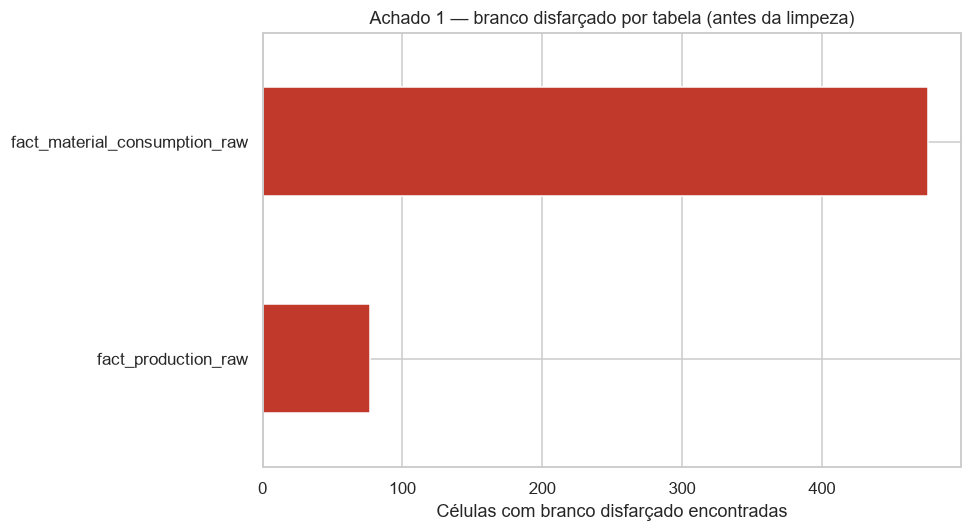

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
disguised_blanks.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_xlabel("Células com branco disfarçado encontradas")
ax.set_title("Achado 1 — branco disfarçado por tabela (antes da limpeza)")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "01_02_diagnose_disguised_blanks.png")
plt.show()

`fact_production_raw.OperatorId` e `fact_material_consumption_raw.MaterialLot` são as
duas tabelas em que isso realmente importa adiante: um `MaterialLot` em branco
precisa ser preenchido para frente (Parte 2), não tratado como "um lote novo começou
aqui", ou a sequência de rastreabilidade `LotId` sai errada.

## Achado 2 — categorias com grafia/espaçamento inconsistente

A mesma categoria aparece como `"Blow Molding"`, `"BLOW MOLDING"`,
`"blow molding"` e `"  Blow Molding  "` dependendo da linha.

In [9]:
CATEGORY_COLUMNS = {
    "fact_production_raw": ["Process"],
    "fact_production_plan_raw": ["Process"],
    "fact_downtime_raw": ["Process", "Shift", "PlannedStoppage"],
    "fact_material_consumption_raw": ["Process", "Shift"],
}
for table, columns in CATEGORY_COLUMNS.items():
    for column in columns:
        variants = raw[table][column].dropna().unique()
        normalized = {str(v).strip().title() for v in variants}
        if len(variants) > len(normalized):
            print(f"{table}.{column}: {len(variants)} variantes brutas -> {len(normalized)} categorias reais")

fact_production_raw.Process: 16 variantes brutas -> 4 categorias reais
fact_production_plan_raw.Process: 16 variantes brutas -> 4 categorias reais
fact_downtime_raw.Process: 16 variantes brutas -> 4 categorias reais
fact_downtime_raw.Shift: 12 variantes brutas -> 3 categorias reais
fact_downtime_raw.PlannedStoppage: 8 variantes brutas -> 2 categorias reais
fact_material_consumption_raw.Process: 16 variantes brutas -> 4 categorias reais
fact_material_consumption_raw.Shift: 12 variantes brutas -> 3 categorias reais


## Achado 3 — quantidades negativas

Colunas de quantidade que nunca deveriam ser negativas (`RejectedQty`,
`QtyAffected`) ocasionalmente aparecem com sinal trocado — quase certamente um erro
de digitação a montante, não uma rejeição negativa real.

In [10]:
NEGATIVE_CHECK_COLUMNS = {
    "fact_production_raw": ["RejectedQty"],
    "fact_customer_complaints_raw": ["QtyAffected"],
}
for table, columns in NEGATIVE_CHECK_COLUMNS.items():
    for column in columns:
        n_negative = (pd.to_numeric(raw[table][column], errors="coerce") < 0).sum()
        print(f"{table}.{column}: {n_negative} valores negativos de {len(raw[table])} linhas")

fact_production_raw.RejectedQty: 92 valores negativos de 15125 linhas
fact_customer_complaints_raw.QtyAffected: 4 valores negativos de 208 linhas


## Achado 4 — linhas duplicadas

Duplicatas exatas de linha inteira, não de chave (uma ordem de produção legítima
pode ter muitas linhas de QC) — uma linha idêntica aparecendo duas vezes é um
artefato de log, não um segundo evento real.

In [11]:
duplicate_counts = {}
for name, df in raw.items():
    _, n_removed = etl.drop_duplicate_rows(df)
    if n_removed:
        duplicate_counts[name] = n_removed
pd.Series(duplicate_counts, name="linhas_duplicadas").sort_values(ascending=False)

fact_downtime_raw                263
fact_material_consumption_raw     31
fact_production_raw               30
Name: linhas_duplicadas, dtype: int64

## Resumo dos achados — o que será corrigido, e onde

| Achado | Onde | Corrigido em |
|---|---|---|
| Branco disfarçado (`-`, `n/a`, vazio) | `OperatorId`, `MaterialLot`, `MaintenanceTechnician`, células de `Shift`/`Process` | `etl_lib.clean_disguised_blanks` (Parte 2) |
| Categorias com grafia/espaço inconsistente | `Process`, `Shift`, `PlannedStoppage` | `etl_lib.standardize_categories` + `strip_extra_spaces` (Parte 2) |
| Quantidades negativas | `RejectedQty`, `QtyAffected` | `etl_lib.fix_negative_quantities` (Parte 2) |
| Linhas duplicadas | produção, parada, consumo de material, algumas tabelas de QC | `etl_lib.drop_duplicate_rows` (Parte 2) |
| `MaterialLot` em branco precisa de preenchimento para frente, não tratamento como lote novo | `fact_material_consumption_raw` | `etl_lib.fill_blank_material_lot` (Parte 2) |

Os cinco são exatamente a sujeira deliberada e documentada descrita no gerador de
dados — este diagnóstico confirma que os dados brutos batem com a intenção do
próprio gerador antes da Parte 2 agir sobre eles.
print("Diagnóstico completo — seguindo para a Parte 2 (limpeza).")

---
# Parte 2 — Limpeza dos dados (Python)
---

**Papel: Engenheiro(a) de Processo/Manufatura + Engenheiro(a) de Dados.**

**O que fica em Python, e por quê**: toda a limpeza linha-a-linha (blancos
disfarçados, categorias, negativos, duplicatas), a construção do código de
rastreabilidade `LotId`, o casamento de paradas com a ordem de produção interrompida,
e o cálculo do OEE ficam em **Python/pandas** — são transformações que precisam de
lógica procedural linha-a-linha (laços com estado, como a sequência do lote de
material) ou que só fazem sentido *antes* de os dados existirem em uma tabela
relacional. O que é naturalmente **conjunto** — filtrar por janela de tempo, agregar,
unir tabelas para uma view analítica — fica em **SQL**, dentro do próprio SQL Server,
na Parte 3 (as views de 52 semanas, os agregados gold). Essa divisão não é
arbitrária: cada camada faz o que faz melhor.

Sequência, em ordem:
1. As mesmas cinco funções de limpeza genérica em cada tabela.
2. Preenchimento para frente do `MaterialLot` em branco.
3. Colunas de calendário (`ISOWeek`, `ISOWeekday`) e `ShiftNumber`.
4. Construção do código de rastreabilidade `LotId`.
5. Casamento de cada parada com a ordem de produção que ela interrompeu.
6. Cálculo de `Availability`, `Performance`, `Quality`, `OEE`.
7. Limpeza das oito tabelas de QC (variável + atributo + disposição, para frasco,
   tampa e tinta/hot foil), limites de controle SPC, Cp/Cpk, DPU/DPMO.
8. Derivação das dimensões (`dim_machine`, `dim_mold`, `dim_operator`, etc.).
9. Limpeza de vendas, reclamações, inspeção de matéria-prima, reclamações a
   fornecedores, não conformidade e CAPA — com as colunas de contagem de dias
   (`ResolutionDays`, `ResponseDays`, `ClosureDays`, `IsOverdue`).
10. Gravação de tudo em `datasets/silver/`.

## 2.1 Produção: plano, real, paradas, consumo de material

In [12]:
plan = pd.read_csv(RAW_DIR / "fact_production_plan_raw.csv", encoding="utf-8-sig")
production = pd.read_csv(RAW_DIR / "fact_production_raw.csv", encoding="utf-8-sig")
downtime = pd.read_csv(RAW_DIR / "fact_downtime_raw.csv", encoding="utf-8-sig")
consumption = pd.read_csv(RAW_DIR / "fact_material_consumption_raw.csv", encoding="utf-8-sig")
process_params = pd.read_csv(RAW_DIR / "fact_process_parameters_raw.csv", encoding="utf-8-sig")
print({"plan": plan.shape, "production": production.shape, "downtime": downtime.shape, "consumption": consumption.shape,
       "process_params": process_params.shape})


def generic_clean(df: pd.DataFrame, category_columns: list[str], negative_columns: list[str] | None = None) -> pd.DataFrame:
    df = etl.clean_disguised_blanks(df)
    df = etl.strip_extra_spaces(df)
    df = etl.standardize_categories(df, category_columns)
    if negative_columns:
        df = etl.fix_negative_quantities(df, negative_columns)
    df, n_removed = etl.drop_duplicate_rows(df)
    print(f"  removidas {n_removed} linhas duplicadas")
    return df


print("plan:"); plan = generic_clean(plan, ["Process"])
print("production:"); production = generic_clean(production, ["Process"], negative_columns=["RejectedQty"])
print("downtime:"); downtime = generic_clean(downtime, ["Process", "Shift", "PlannedStoppage"])
print("consumption:"); consumption = generic_clean(consumption, ["Process", "Shift"])
print("process_params:"); process_params = generic_clean(process_params, ["Process"])

{'plan': (15095, 10), 'production': (15125, 15), 'downtime': (131534, 10), 'consumption': (15452, 10), 'process_params': (11280, 11)}
plan:
  removidas 0 linhas duplicadas
production:


  removidas 30 linhas duplicadas
downtime:


  removidas 263 linhas duplicadas
consumption:
  removidas 31 linhas duplicadas
process_params:
  removidas 0 linhas duplicadas


In [13]:
consumption["MaterialLot"] = etl.fill_blank_material_lot(consumption)
consumption["MaterialLotSeq"] = etl.compute_material_lot_sequence(consumption)
residual_blanks = consumption["MaterialLot"].isna().sum()
print(f"MaterialLot ainda em branco após o preenchimento para frente: {residual_blanks} "
      f"({residual_blanks / len(consumption):.1%} das linhas)")

MaterialLot ainda em branco após o preenchimento para frente: 662 (4.3% das linhas)


O preenchimento (para frente/para trás) só funciona *dentro* de uma ordem de
produção que tenha ao menos outra linha com valor real para emprestar. Um resíduo
(~4% das linhas) permanece em branco porque essas ordens só registraram um único
lançamento de consumo, e esse único lançamento foi justamente o que veio em branco —
não há mais nada dentro desta tabela para recuperá-lo. Numa fábrica real, esse é
exatamente o ponto em que se escalaria para o sistema de rastreabilidade/WMS em vez
de adivinhar; deixar isso como um `NaN` documentado é a escolha honesta — o mesmo
padrão que este projeto já aplica à lacuna de rastreabilidade de retrabalho (Parte 5).

## 2.2 Calendário, turno, `LotId`, casamento de paradas e OEE

In [14]:
plan = etl.add_calendar_columns(plan, "Date")
plan["ShiftNumber"] = etl.compute_shift_number(plan["StartTime"])
production = etl.add_calendar_columns(production, "Date")
production["ShiftNumber"] = etl.compute_shift_number(production["StartTime"])
downtime = etl.add_calendar_columns(downtime, "Date")
downtime["ShiftNumber"] = etl.compute_shift_number(downtime["StoppageStartTime"])
consumption = etl.add_calendar_columns(consumption, "Date")
consumption["ShiftNumber"] = consumption["Shift"].str.extract(r"(\d)").astype(int)

`LotId`: 16 caracteres (`YYWWDTPMMOOOOOSS`) — ano, semana ISO, dia da semana, turno,
processo, máquina, ordem de produção e sequência do lote de material. É o mecanismo
que permite rastrear qualquer inspeção até a ordem de produção e o lote de matéria-
prima exatos que a geraram (rastreabilidade ISO 9001).

In [15]:
lot_seq_by_wo = consumption.groupby("WorkOrder")["MaterialLotSeq"].max()
production["MaterialLotSeq"] = production["WorkOrder"].map(lot_seq_by_wo).fillna(1).astype(int)
production["LotId"] = etl.build_lotid_prefix(
    production["Date"], production["ShiftNumber"], production["Process"], production["MachineId"], production["WorkOrder"]
) + production["MaterialLotSeq"].astype(str).str.zfill(2)
consumption["LotIdStart"] = etl.build_lotid_prefix(
    consumption["Date"], consumption["ShiftNumber"], consumption["Process"], consumption["MachineId"], consumption["WorkOrder"]
) + consumption["MaterialLotSeq"].astype(str).str.zfill(2)
assert production["LotId"].str.len().eq(16).all(), "LotId deve ter sempre 16 caracteres"

In [16]:
production["_start_dt"] = pd.to_datetime(production["Date"]) + pd.to_timedelta(production["StartTime"].astype(str))
production["_end_dt"] = etl.compute_end_datetime(production["Date"], production["StartTime"], production["EndTime"])
production["LeadTimeProdHours"] = etl.compute_production_time(production)

downtime["MatchedWorkOrder"] = etl.find_work_order_for_stoppage(downtime, production)
match_rate = downtime["MatchedWorkOrder"].notna().mean()
print(f"{match_rate:.1%} das paradas casadas com uma ordem de produção ativa "
      "(o resto é manutenção programada avulsa entre ordens, ou janela de fábrica ociosa).")

downtime = downtime.merge(production[["WorkOrder", "LotId"]].rename(columns={"WorkOrder": "MatchedWorkOrder"}),
                           on="MatchedWorkOrder", how="left")
downtime = etl.add_maintenance_info(downtime)

80.0% das paradas casadas com uma ordem de produção ativa (o resto é manutenção programada avulsa entre ordens, ou janela de fábrica ociosa).


OEE: `Availability = Tempo em Operação / Tempo Planejado`, `Performance = taxa real
(peças/h) / taxa nominal`, `Quality = (produzido - rejeitado) / produzido`,
`OEE = Availability × Performance × Quality`. A capacidade nominal vem de
`dim_machine_setup.csv`, por `(MachineId, ToolId)`.

In [17]:
def parse_capacity_number(value) -> float:
    digits = re.findall(r"\d+", str(value))
    return float("".join(digits)) if digits else np.nan


machine_setup = pd.read_csv(DIM_DIR / "dim_machine_setup.csv", encoding="utf-8-sig")
capacity_by_machine = {
    (row["MachineId"], row["MoldId"]): parse_capacity_number(row["RatedCapacityPerHour"])
    for _, row in machine_setup.iterrows()
}
downtime_by_order = downtime.dropna(subset=["MatchedWorkOrder"]).rename(columns={"MatchedWorkOrder": "WorkOrder"})
production = etl.compute_oee_components(production, plan, downtime_by_order, capacity_by_machine)

missing_capacity = production["RatedCapacityPcH"].isna().mean()
print(f"Ordens sem capacidade (MachineId, ToolId) correspondente: {missing_capacity:.2%}")
production[["Process", "Availability", "Performance", "Quality", "OEE"]].groupby("Process").mean().round(3)

Ordens sem capacidade (MachineId, ToolId) correspondente: 0.00%


,Availability,Performance,Quality,OEE
Process,,,,
Blow Molding,0.866,0.927,0.976,0.783
Hot Foil Stamping,0.838,0.888,0.967,0.711
Injection Molding,0.876,0.927,0.977,0.793
Screen Printing,0.811,0.874,0.977,0.682


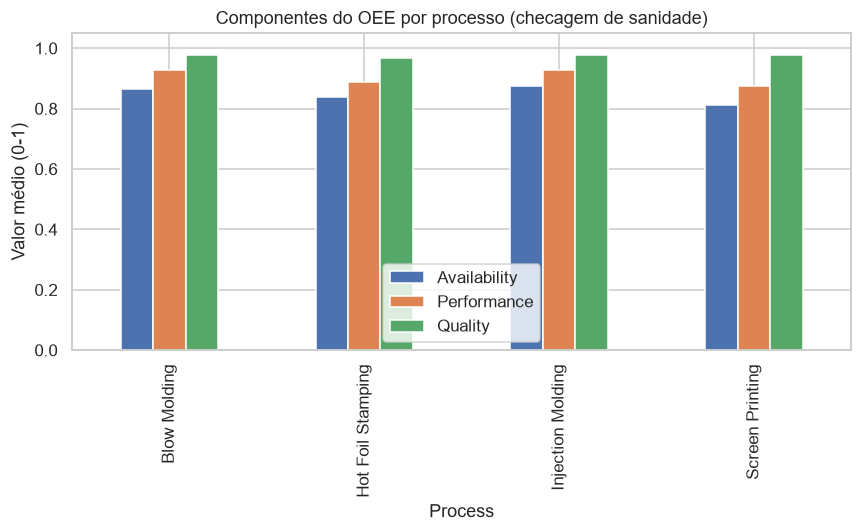

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
production.groupby("Process")[["Availability", "Performance", "Quality"]].mean().plot(kind="bar", ax=ax)
ax.set_ylabel("Valor médio (0-1)"); ax.set_title("Componentes do OEE por processo (checagem de sanidade)")
ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "02_01_oee_components_sanity_check.png"); plt.show()

In [19]:
plan.to_csv(PROCESSED_DIR / "fact_production_plan_processed.csv", index=False)
production_out = production.drop(columns=["_start_dt", "_end_dt", "_next_start_dt"], errors="ignore")
production_out.to_csv(PROCESSED_DIR / "fact_production_processed.csv", index=False)
downtime.to_csv(PROCESSED_DIR / "fact_downtime_processed.csv", index=False)
consumption_out = consumption.drop(columns=["RecordSeq"], errors="ignore")
consumption_out.to_csv(PROCESSED_DIR / "fact_material_consumption_processed.csv", index=False)
process_params.to_csv(PROCESSED_DIR / "fact_process_parameters_processed.csv", index=False)
print("2.2 salvo:", {n: len(d) for n, d in [("plan", plan), ("production", production_out),
                                              ("downtime", downtime), ("consumption", consumption_out),
                                              ("process_params", process_params)]})

2.2 salvo: {'plan': 15095, 'production': 15095, 'downtime': 131271, 'consumption': 15421, 'process_params': 11280}


## 2.3 Qualidade: frasco / tampa / tinta (+ hot foil)

As oito tabelas de controle de qualidade (frasco/tampa × variável+atributo+
disposição, mais a tabela compartilhada de tinta/decoração que também cobre Hot
Foil Stamping), com o `LotId` da produção que gerou cada inspeção, os limites de
controle SPC e Cp/Cpk/DPU/DPMO, e as seis dimensões derivadas dos dados já limpos.

In [20]:
lotid_by_wo = production.set_index("WorkOrder")["LotId"]
RAW_QC_FILES = {
    "bottle_var": "fact_bottle_inspection_variables_cq_raw.csv", "bottle_attr": "fact_bottle_attribute_inspection_cq_raw.csv",
    "bottle_disp": "fact_bottle_disposition_lot_cq_raw.csv", "cap_var": "fact_cap_inspection_variable_cq_raw.csv",
    "cap_attr": "fact_cap_attribute_inspection_cq_raw.csv", "cap_disp": "fact_cap_disposition_lot_cq_raw.csv",
    "ink_attr": "fact_ink_attribute_inspection_cq_raw.csv", "ink_disp": "fact_ink_disposition_lot_cq_raw.csv",
}
qc = {name: pd.read_csv(RAW_DIR / fname, encoding="utf-8-sig") for name, fname in RAW_QC_FILES.items()}

QC_CATEGORY_COLUMNS = {
    "bottle_var": ["Shift"], "bottle_attr": [], "bottle_disp": ["Shift"], "cap_var": ["Shift"],
    "cap_attr": ["Shift"], "cap_disp": ["Shift"], "ink_attr": ["Shift"], "ink_disp": ["Shift"],
}
for name, df in qc.items():
    df = etl.clean_disguised_blanks(df)
    df = etl.strip_extra_spaces(df)
    df = etl.standardize_categories(df, QC_CATEGORY_COLUMNS[name])
    df, n_removed = etl.drop_duplicate_rows(df)
    df["LotId"] = df["WorkOrder"].map(lotid_by_wo)
    qc[name] = df

Limites de controle SPC e capacidade de processo, agrupados por característica x
máquina x molde x produto — um limite de controle só significa algo quando é
calculado a partir de um processo rodando sob as mesmas condições. Subgrupos de
frasco têm 5 peças; de tampa, 10 (bate com o plano de controle).

In [21]:
# Pp/Ppk/Cpm precisam da variação TOTAL das observações individuais (M1..Mn), não do
# desvio-padrão das médias de subgrupo (XBar) -- por isso measurement_columns é
# passado abaixo. Cp/Cpk continuam within-subgroup (via RangeR/d2).
BOTTLE_MEASUREMENT_COLUMNS = ["M1", "M2", "M3", "M4", "M5"]
CAP_MEASUREMENT_COLUMNS = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10"]
qc["bottle_var"] = etl.compute_control_limits(qc["bottle_var"], ["MachineId", "MoldId", "BottleId", "Characteristic"], subgroup_size=5)
qc["bottle_var"] = etl.compute_process_capability(qc["bottle_var"], ["MachineId", "MoldId", "BottleId", "Characteristic"], subgroup_size=5, measurement_columns=BOTTLE_MEASUREMENT_COLUMNS)
qc["cap_var"] = etl.compute_control_limits(qc["cap_var"], ["MachineId", "MoldId", "CapId", "Characteristic"], subgroup_size=10)
qc["cap_var"] = etl.compute_process_capability(qc["cap_var"], ["MachineId", "MoldId", "CapId", "Characteristic"], subgroup_size=10, measurement_columns=CAP_MEASUREMENT_COLUMNS)

for name in ["bottle_var", "cap_var"]:
    ooc_rate = qc[name]["OutOfControlXBar"].mean()
    id_col = "BottleId" if name == "bottle_var" else "CapId"
    mean_cpk = qc[name].drop_duplicates(["MachineId", "MoldId", id_col, "Characteristic"])["Cpk"].mean()
    print(f"{name}: {ooc_rate:.2%} dos subgrupos fora de controle (X-bar), Cpk médio = {mean_cpk:.2f}")

for name in ["bottle_attr", "cap_attr", "ink_attr"]:
    qc[name] = etl.compute_attribute_indicators(qc[name])

bottle_var: 1.10% dos subgrupos fora de controle (X-bar), Cpk médio = 1.02
cap_var: 2.34% dos subgrupos fora de controle (X-bar), Cpk médio = 0.79


Derivando as dimensões a partir dos dados já limpos.

In [22]:
def extract_trailing_number(text_value: str):
    match = re.search(r"(\d+)$", str(text_value))
    return int(match.group(1)) if match else np.nan


dim_machine = production[["MachineId", "Process"]].drop_duplicates().reset_index(drop=True)
dim_machine["MachineNumber"] = dim_machine["MachineId"].apply(extract_trailing_number)
dim_machine = dim_machine.sort_values(["Process", "MachineNumber"]).reset_index(drop=True)

dim_mold = machine_setup.merge(dim_machine[["MachineId", "Process"]], on="MachineId", how="left")
dim_mold = dim_mold[["MoldId", "MachineId", "Process", "Cavities", "RatedCapacityPerHour", "CyclesPerHour", "IdealCycleTimeSec"]]

operators = production[["OperatorId", "Process"]].dropna().drop_duplicates()
operators = operators[~operators["OperatorId"].isin(["", "-", "--", "---", "/", "//"])]
operators = operators.rename(columns={"OperatorId": "PersonId"}); operators["Role"] = "Operator"
techs = downtime[["MaintenanceTechnician", "Process", "MaintenanceTeam"]].dropna().drop_duplicates()
techs = techs[~techs["MaintenanceTechnician"].str.contains("N/A", case=False, na=False)]
techs = techs.rename(columns={"MaintenanceTechnician": "PersonId", "MaintenanceTeam": "Role"})[["PersonId", "Process", "Role"]]
dim_operator = pd.concat([operators, techs], ignore_index=True).drop_duplicates(subset=["PersonId"])

masterbatch = pd.read_csv(DIM_DIR / "dim_masterbatch.csv", encoding="utf-8-sig")
dim_bottle = masterbatch[masterbatch["ProductType"] == "Bottle"].drop_duplicates("ProductId").copy()
dim_bottle["VolumeMl"] = dim_bottle["ProductId"].apply(lambda pid: extract_trailing_number(pid.split("-")[-1]))
dim_cap = pd.read_csv(DIM_DIR / "dim_cap.csv", encoding="utf-8-sig")
dim_ink = qc["ink_attr"][["PrintToolId", "BottleId", "ColorCount"]].drop_duplicates()
dim_ink = dim_ink.rename(columns={"BottleId": "ProductId"}).drop_duplicates(subset=["PrintToolId"])

OUT_QC_NAMES = {
    "bottle_var": "fact_bottle_inspection_variables_cq_processed", "bottle_attr": "fact_bottle_attribute_inspection_cq_processed",
    "bottle_disp": "fact_bottle_disposition_lot_cq_processed", "cap_var": "fact_cap_inspection_variable_cq_processed",
    "cap_attr": "fact_cap_attribute_inspection_cq_processed", "cap_disp": "fact_cap_disposition_lot_cq_processed",
    "ink_attr": "fact_ink_attribute_inspection_cq_processed", "ink_disp": "fact_ink_disposition_lot_cq_processed",
}
for key, out_name in OUT_QC_NAMES.items():
    qc[key].to_csv(PROCESSED_DIR / f"{out_name}.csv", index=False)
for name, df in [("dim_machine", dim_machine), ("dim_mold", dim_mold), ("dim_operator", dim_operator),
                  ("dim_bottle", dim_bottle), ("dim_cap", dim_cap), ("dim_ink", dim_ink)]:
    df.to_csv(PROCESSED_DIR / f"{name}.csv", index=False)
    print(f"{name}: {df.shape}")

dim_machine: (18, 3)
dim_mold: (90, 7)
dim_operator: (18, 3)
dim_bottle: (101, 10)
dim_cap: (31, 15)
dim_ink: (26, 3)


## 2.4 Extensão de Garantia da Qualidade: vendas, clientes, fornecedores, NC/CAPA

**Papel: Engenheiro(a) da Qualidade de Fornecedores / Clientes.** Mesma disciplina
de limpeza, mais as colunas calculadas de contagem de dias que medem cada um desses
processos de QA na prática.

In [23]:
sales = pd.read_csv(RAW_DIR / "fact_sales_raw.csv", encoding="utf-8-sig")
complaints = pd.read_csv(RAW_DIR / "fact_customer_complaints_raw.csv", encoding="utf-8-sig")
rm_inspect = pd.read_csv(RAW_DIR / "fact_raw_material_inspection_raw.csv", encoding="utf-8-sig")
rm_disp = pd.read_csv(RAW_DIR / "fact_raw_material_lot_disposition_raw.csv", encoding="utf-8-sig")
sup_complaints = pd.read_csv(RAW_DIR / "fact_supplier_complaints_raw.csv", encoding="utf-8-sig")
nc = pd.read_csv(RAW_DIR / "fact_nonconformance_raw.csv", encoding="utf-8-sig")
capa = pd.read_csv(RAW_DIR / "fact_capa_raw.csv", encoding="utf-8-sig")

sales = etl.drop_duplicate_rows(etl.standardize_categories(etl.strip_extra_spaces(etl.clean_disguised_blanks(sales)), ["ProductFamily", "Process"]))[0]
complaints = etl.drop_duplicate_rows(etl.standardize_categories(etl.strip_extra_spaces(etl.clean_disguised_blanks(complaints)),
                                                                  ["ProductFamily", "Process", "Severity", "Status"]))[0]
complaints = etl.fix_negative_quantities(complaints, ["QtyAffected"])
rm_inspect = etl.drop_duplicate_rows(etl.strip_extra_spaces(etl.clean_disguised_blanks(rm_inspect)))[0]
rm_disp = etl.drop_duplicate_rows(etl.standardize_categories(etl.strip_extra_spaces(etl.clean_disguised_blanks(rm_disp)), ["FinalDecision"]))[0]
sup_complaints = etl.drop_duplicate_rows(etl.standardize_categories(etl.strip_extra_spaces(etl.clean_disguised_blanks(sup_complaints)), ["Status"]))[0]
nc = etl.drop_duplicate_rows(etl.standardize_categories(etl.strip_extra_spaces(etl.clean_disguised_blanks(nc)), ["Type", "Severity"]))[0]
capa = etl.drop_duplicate_rows(etl.standardize_categories(etl.strip_extra_spaces(etl.clean_disguised_blanks(capa)), ["Status", "CAPAType", "Severity"]))[0]

for df in [sales, complaints, rm_inspect, rm_disp, sup_complaints, nc]:
    df["Date"] = pd.to_datetime(df["Date"])
sales = etl.add_calendar_columns(sales, "Date"); sales["Month"] = sales["Date"].dt.strftime("%Y-%m")
complaints = etl.add_calendar_columns(complaints, "Date"); complaints["Month"] = complaints["Date"].dt.strftime("%Y-%m")
rm_inspect = etl.add_calendar_columns(rm_inspect, "Date"); rm_inspect["Month"] = rm_inspect["Date"].dt.strftime("%Y-%m")
rm_disp = etl.add_calendar_columns(rm_disp, "Date"); rm_disp["Month"] = rm_disp["Date"].dt.strftime("%Y-%m")
sup_complaints = etl.add_calendar_columns(sup_complaints, "Date"); sup_complaints["Month"] = sup_complaints["Date"].dt.strftime("%Y-%m")
nc = etl.add_calendar_columns(nc, "Date"); nc["Month"] = nc["Date"].dt.strftime("%Y-%m")
capa["OpenDate"] = pd.to_datetime(capa["OpenDate"]); capa["OpenMonth"] = capa["OpenDate"].dt.strftime("%Y-%m")
for df in [sales, complaints, rm_inspect, rm_disp, sup_complaints, nc]:
    df["Date"] = df["Date"].dt.date

complaints = etl.compute_days_between(complaints, "Date", "ResolutionDate", "ResolutionDays")
sup_complaints = etl.compute_days_between(sup_complaints, "Date", "DateSupplierResponded", "ResponseDays")
sup_complaints = etl.compute_days_between(sup_complaints, "Date", "DateResolved", "ResolutionDays")
capa = etl.compute_days_between(capa, "OpenDate", "CloseDate", "ClosureDays")
reference_date = pd.to_datetime(capa["DueDate"]).max()
due, close = pd.to_datetime(capa["DueDate"]), pd.to_datetime(capa["CloseDate"])
capa["IsOverdue"] = np.where(close.notna(), close > due, due < reference_date)
rm_disp["IsAccepted"] = rm_disp["FinalDecision"] == "Accepted"
rm_disp["IsRejected"] = rm_disp["FinalDecision"] == "Rejected"

print("Reclamações de clientes ainda abertas (sem ResolutionDate):", complaints["ResolutionDays"].isna().sum(), "/", len(complaints))
print("CAPAs atrasadas:", int(capa["IsOverdue"].sum()), "/", len(capa))

QA_OUT = {
    "fact_sales_processed": sales, "fact_customer_complaints_processed": complaints,
    "fact_raw_material_inspection_processed": rm_inspect, "fact_raw_material_lot_disposition_processed": rm_disp,
    "fact_supplier_complaints_processed": sup_complaints, "fact_nonconformance_processed": nc, "fact_capa_processed": capa,
}
for name, df in QA_OUT.items():
    df.to_csv(PROCESSED_DIR / f"{name}.csv", index=False)
    print(f"{name}: {df.shape}")

print("\nParte 2 completa — todas as tabelas limpas estão em datasets/silver/.")

Reclamações de clientes ainda abertas (sem ResolutionDate): 39 / 208
CAPAs atrasadas: 398 / 811
fact_sales_processed: (8007, 15)
fact_customer_complaints_processed: (208, 18)
fact_raw_material_inspection_processed: (6878, 19)
fact_raw_material_lot_disposition_processed: (1844, 16)
fact_supplier_complaints_processed: (79, 15)
fact_nonconformance_processed: (1327, 12)
fact_capa_processed: (811, 16)

Parte 2 completa — todas as tabelas limpas estão em datasets/silver/.


## Data Quality Scorecard — antes (Parte 1) vs. depois (Parte 2), num só lugar

Os 4 achados da Parte 1 foram corrigidos em células diferentes, cada uma no seu
próprio contexto — correto para o fluxo de leitura, mas ruim para uma auditoria
rápida de "quanto realmente melhorou". Esta célula reaplica exatamente as mesmas
checagens da Parte 1 (mesmas funções, `etl.count_missing_values` etc.) sobre as
4 tabelas centrais de produção (`plan`, `production`, `downtime`, `consumption`,
hoje já limpas) e compara contra a contagem original — um scorecard, não uma
reafirmação em prosa de que "a limpeza funcionou".

In [24]:
before_after_tables = {
    "fact_production_plan_raw": (raw["fact_production_plan_raw"], plan),
    "fact_production_raw": (raw["fact_production_raw"], production),
    "fact_downtime_raw": (raw["fact_downtime_raw"], downtime),
    "fact_material_consumption_raw": (raw["fact_material_consumption_raw"], consumption),
}
scorecard_rows = []
for table_name, (before_df, after_df) in before_after_tables.items():
    scorecard_rows.append({
        "Tabela": table_name,
        "Linhas (bruto)": len(before_df),
        "Linhas (limpo)": len(after_df),
        # Duplicatas exatas: a contagem real já é conhecida (`duplicate_counts`, achado 4
        # acima) -- reaproveitada aqui em vez de recalculada, para nunca divergir.
        "Linhas duplicadas removidas": duplicate_counts.get(table_name, 0),
        "Branco disfarçado (antes)": count_disguised_blanks(before_df),
        "Branco disfarçado (depois)": count_disguised_blanks(after_df),
    })
data_quality_scorecard = pd.DataFrame(scorecard_rows)
print(data_quality_scorecard.to_string(index=False))

all_clean = (data_quality_scorecard["Branco disfarçado (depois)"] == 0).all()
answer(f"Scorecard consolidado: {'todos os 4 achados de branco disfarçado foram eliminados (0 restante em cada tabela)' if all_clean else 'ainda restam brancos disfarçados em pelo menos uma tabela -- ver coluna acima'}, "
       f"e {int(data_quality_scorecard['Linhas duplicadas removidas'].sum())} linhas duplicadas foram removidas ao "
       "todo entre as 4 tabelas centrais de produção. Este é o mesmo tipo de tabela que um Data Quality Report "
       "formal (ISO 8000 / DAMA-DMBOK) exigiria antes de aprovar um dataset para consumo analítico — construída "
       "aqui, não deixada implícita em texto espalhado pelas células anteriores.")

                       Tabela  Linhas (bruto)  Linhas (limpo)  Linhas duplicadas removidas  Branco disfarçado (antes)  Branco disfarçado (depois)
     fact_production_plan_raw           15095           15095                            0                          0                           0
          fact_production_raw           15125           15095                           30                         77                           0
            fact_downtime_raw          131534          131271                          263                          0                           0
fact_material_consumption_raw           15452           15421                           31                        476                           0


**Resposta:** Scorecard consolidado: todos os 4 achados de branco disfarçado foram eliminados (0 restante em cada tabela), e 324 linhas duplicadas foram removidas ao todo entre as 4 tabelas centrais de produção. Este é o mesmo tipo de tabela que um Data Quality Report formal (ISO 8000 / DAMA-DMBOK) exigiria antes de aprovar um dataset para consumo analítico — construída aqui, não deixada implícita em texto espalhado pelas células anteriores.

---
# Parte 3 — O warehouse SQL Server (arquitetura medalhão)
---

**Papel: Engenheiro(a) de Dados.** Cria o banco `ManufacturingPerformanceAnalytics`
(autenticação do Windows — o servidor não usa login SQL), roda o DDL T-SQL de cada
tabela, carrega cada CSV já limpo, cria as views de 52 semanas móveis, os agregados
gold, e verifica que a contagem de linhas bate exatamente entre os CSVs e o SQL
Server.

**Arquitetura medalhão** — três camadas, a distinção fica no próprio schema, não em
conhecimento tribal de qual notebook gerou qual tabela:

| Camada | O que é aqui | Onde vive |
|---|---|---|
| **Bronze** | Bruto, como chegou, deliberadamente sujo | `datasets/bronze/*.csv` — **arquivos apenas, nunca carregado no SQL Server** |
| **Silver** | Limpo, conformado, deduplicado, uma linha por evento de negócio | `datasets/silver/*.csv` (Parte 2) → SQL Server, consultável como `silver.*` |
| **Gold** | Agregados prontos para negócio: uma linha por (dimensão × período), ou saída de modelo em grão de decisão | Só no SQL Server, `gold.*` |

As tabelas físicas continuam com o nome `dbo.fact_*_processed`/`dbo.dim_*` (compatível
com o DDL abaixo); `silver.*` são views 1:1 sobre elas — assim qualquer consulta nova
escrita neste notebook usa o nome de schema correto (`silver`/`gold`) sem precisar
migrar fisicamente 33 tabelas.

**Como o SQL aparece aqui**: os scripts de DDL (criação de schema/tabela) são grandes
blocos que precisam do separador de lote `GO` do T-SQL — por isso ficam como texto em
uma string Python, executados por `db_lib.run_sql_script` (que entende `GO`), mas o
texto completo do SQL está aqui, visível, na ordem em que é usado. As *views* — cada
uma é um único `CREATE OR ALTER VIEW`, sem restrição de lote — viram células `%%sql`
de verdade, executadas diretamente contra o SQL Server, exatamente como se faz em um
notebook Databricks.

In [25]:
DATABASE = "ManufacturingPerformanceAnalytics"
db_lib.create_database_if_missing(DATABASE)
engine = db_lib.get_engine(DATABASE)
with engine.connect() as conn:
    print(conn.execute(text("SELECT @@VERSION")).scalar_one()[:60])

Database [ManufacturingPerformanceAnalytics] already exists
Microsoft SQL Server 2025 (RTM) - 17.0.1000.7 (X64) 
	Oct 21


## 3.1 Schemas (bronze / silver / gold)

In [26]:
SQL_CREATE_SCHEMAS = """
IF NOT EXISTS (SELECT 1 FROM sys.schemas WHERE name = 'bronze')
    EXEC('CREATE SCHEMA bronze');
GO
IF NOT EXISTS (SELECT 1 FROM sys.schemas WHERE name = 'silver')
    EXEC('CREATE SCHEMA silver');
GO
IF NOT EXISTS (SELECT 1 FROM sys.schemas WHERE name = 'gold')
    EXEC('CREATE SCHEMA gold');
GO
"""
db_lib.run_sql_script(engine, SQL_CREATE_SCHEMAS, label="00_create_schemas")

3 batches executed (00_create_schemas)


3

## 3.2 Tabelas fato (produção, paradas, QC, QA)

Sem chaves primárias/estrangeiras ou índices de propósito — este é um mart analítico
de gravador único, o grão e os relacionamentos ficam documentados em
`docs/data_dictionary.md`, não impostos pelo schema. Cada `CREATE TABLE` é protegido
por `IF OBJECT_ID(...) IS NULL`, então este bloco é seguro para reexecutar.

In [27]:
SQL_CREATE_FACT_TABLES = """
IF OBJECT_ID('dbo.fact_production_plan_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_production_plan_processed;
    CREATE TABLE dbo.fact_production_plan_processed (
        [Date] DATE, Process NVARCHAR(34), MachineId NVARCHAR(16), ToolId NVARCHAR(52),
        WorkOrder NVARCHAR(16), PlannedQty BIGINT, StartTime TIME, EndTime TIME,
        PlannedHours FLOAT, ProductId NVARCHAR(40), ISOWeek BIGINT, ISOWeekday BIGINT,
        ShiftNumber BIGINT
    );
GO

IF OBJECT_ID('dbo.fact_production_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_production_processed;
    CREATE TABLE dbo.fact_production_processed (
        [Date] DATE, Process NVARCHAR(34), MachineId NVARCHAR(16), ToolId NVARCHAR(52),
        WorkOrder NVARCHAR(16), ProductId NVARCHAR(40), ProductBatch NVARCHAR(38),
        StartTime TIME, EndTime TIME, PlannedQty BIGINT, ProducedQty BIGINT,
        RejectedQty BIGINT, OperatorId NVARCHAR(22), IsRedo BIT, RedoOfBatch NVARCHAR(38),
        ISOWeek BIGINT, ISOWeekday BIGINT,
        ShiftNumber BIGINT, MaterialLotSeq BIGINT, LotId NVARCHAR(20),
        LeadTimeProdHours FLOAT, PlannedHours FLOAT, PlannedTimeHours FLOAT,
        UnplannedDowntimeHours FLOAT, SetupTimeHours FLOAT, RunTimeHours FLOAT,
        Availability FLOAT, RatedCapacityPcH FLOAT, IdealCycleTimeSec FLOAT,
        Performance FLOAT, PerformanceVsNominal FLOAT, Quality FLOAT, OEE FLOAT, ActualCycleTimeSec FLOAT,
        ThroughputLeadTimeHours FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_downtime_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_downtime_processed;
    CREATE TABLE dbo.fact_downtime_processed (
        [Date] DATE, Process NVARCHAR(34), MachineId NVARCHAR(16), Shift NVARCHAR(16),
        StoppageStartTime TIME, StoppageEndTime TIME, PlannedStoppage NVARCHAR(16),
        StoppageReason NVARCHAR(166), MaintenanceTeam NVARCHAR(32),
        MaintenanceTechnician NVARCHAR(46), ISOWeek BIGINT, ISOWeekday BIGINT,
        ShiftNumber BIGINT, MatchedWorkOrder NVARCHAR(16), LotId NVARCHAR(22),
        DowntimeDurationMin FLOAT, UnplannedFailure BIT, IsChangeoverSetup BIT,
        IsPreventiveMaintenance BIT
    );
GO

IF OBJECT_ID('dbo.fact_material_consumption_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_material_consumption_processed;
    CREATE TABLE dbo.fact_material_consumption_processed (
        [Date] DATE, Process NVARCHAR(34), MachineId NVARCHAR(16), Shift NVARCHAR(16),
        WorkOrder NVARCHAR(16), MaterialId NVARCHAR(16), MaterialLot NVARCHAR(32),
        StartWeightKg FLOAT, EndWeightKg FLOAT, ISOWeek BIGINT, ISOWeekday BIGINT,
        ShiftNumber BIGINT, MaterialLotSeq BIGINT, LotIdStart NVARCHAR(20)
    );
GO

IF OBJECT_ID('dbo.fact_bottle_inspection_variables_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_bottle_inspection_variables_cq_processed;
    CREATE TABLE dbo.fact_bottle_inspection_variables_cq_processed (
        ProductBatch NVARCHAR(38), WorkOrder NVARCHAR(16), ProductionDate DATE,
        Shift NVARCHAR(16), MachineId NVARCHAR(16), MoldId NVARCHAR(18),
        BottleId NVARCHAR(38), Material NVARCHAR(16), Characteristic NVARCHAR(16),
        Equipment NVARCHAR(26), Standard NVARCHAR(16), Unit NVARCHAR(16),
        InspectionDateTime DATETIME2, SampleGroup BIGINT, LSL FLOAT, Nominal FLOAT,
        USL FLOAT, M1 FLOAT, M2 FLOAT, M3 FLOAT, M4 FLOAT, M5 FLOAT, XBar FLOAT,
        RangeR FLOAT, StdDevS FLOAT, GroupResult NVARCHAR(30), Inspector NVARCHAR(28),
        LotId NVARCHAR(20), XBarCL FLOAT, XBarUCL FLOAT, XBarLCL FLOAT,
        RangeRCL FLOAT, RangeRUCL FLOAT, RangeRLCL FLOAT, OutOfControlXBar BIT,
        OutOfControlRange BIT, Cp FLOAT, Cpk FLOAT, Pp FLOAT, Ppk FLOAT, Cpm FLOAT,
        SigmaLevel FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_cap_inspection_variable_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_cap_inspection_variable_cq_processed;
    CREATE TABLE dbo.fact_cap_inspection_variable_cq_processed (
        ProductBatch NVARCHAR(38), WorkOrder NVARCHAR(16), ProductionDate DATE,
        Shift NVARCHAR(16), MachineId NVARCHAR(16), MoldId NVARCHAR(18),
        CapId NVARCHAR(38), Material NVARCHAR(16), CapType NVARCHAR(18),
        Characteristic NVARCHAR(16), Equipment NVARCHAR(26), Standard NVARCHAR(16),
        Unit NVARCHAR(16), InspectionDateTime DATETIME2, SampleGroup BIGINT,
        LSL FLOAT, Nominal FLOAT, USL FLOAT, M1 FLOAT, M2 FLOAT, M3 FLOAT, M4 FLOAT,
        M5 FLOAT, M6 FLOAT, M7 FLOAT, M8 FLOAT, M9 FLOAT, M10 FLOAT, XBar FLOAT,
        RangeR FLOAT, StdDevS FLOAT, GroupResult NVARCHAR(30), Inspector NVARCHAR(28),
        LotId NVARCHAR(20), XBarCL FLOAT, XBarUCL FLOAT, XBarLCL FLOAT,
        RangeRCL FLOAT, RangeRUCL FLOAT, RangeRLCL FLOAT, OutOfControlXBar BIT,
        OutOfControlRange BIT, Cp FLOAT, Cpk FLOAT, Pp FLOAT, Ppk FLOAT, Cpm FLOAT,
        SigmaLevel FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_bottle_attribute_inspection_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_bottle_attribute_inspection_cq_processed;
    CREATE TABLE dbo.fact_bottle_attribute_inspection_cq_processed (
        ProductBatch NVARCHAR(38), WorkOrder NVARCHAR(16), ProductionDate DATE,
        MachineId NVARCHAR(16), MoldId NVARCHAR(18), BottleId NVARCHAR(38),
        Material NVARCHAR(16), Characteristic NVARCHAR(16), Class NVARCHAR(16),
        AQL FLOAT, Standard NVARCHAR(16), InspectionLevel NVARCHAR(16),
        LotSize BIGINT, CodeLetter NVARCHAR(16), SampleSize BIGINT,
        AcceptanceNumber BIGINT, RejectionNumber BIGINT, DefectsFound BIGINT,
        LotDecision NVARCHAR(16), InspectionDateTime DATETIME2, Inspector NVARCHAR(28),
        LotId NVARCHAR(20), DefectRateP FLOAT, DPU FLOAT, DPMO FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_cap_attribute_inspection_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_cap_attribute_inspection_cq_processed;
    CREATE TABLE dbo.fact_cap_attribute_inspection_cq_processed (
        ProductBatch NVARCHAR(38), WorkOrder NVARCHAR(16), ProductionDate DATE,
        Shift NVARCHAR(16), MachineId NVARCHAR(16), MoldId NVARCHAR(18),
        CapId NVARCHAR(38), Material NVARCHAR(16), CapType NVARCHAR(18),
        Characteristic NVARCHAR(16), Class NVARCHAR(16), AQL FLOAT,
        Standard NVARCHAR(16), InspectionLevel NVARCHAR(16), LotSize BIGINT,
        CodeLetter NVARCHAR(16), SampleSize BIGINT, AcceptanceNumber BIGINT,
        RejectionNumber BIGINT, DefectsFound BIGINT, LotDecision NVARCHAR(16),
        InspectionDateTime DATETIME2, Inspector NVARCHAR(28), LotId NVARCHAR(20),
        DefectRateP FLOAT, DPU FLOAT, DPMO FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_ink_attribute_inspection_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_ink_attribute_inspection_cq_processed;
    CREATE TABLE dbo.fact_ink_attribute_inspection_cq_processed (
        PrintLot NVARCHAR(48), ProductBatch NVARCHAR(38), SourceBottleWorkOrder NVARCHAR(16),
        WorkOrder NVARCHAR(16),
        ProductionDate DATE, Shift NVARCHAR(16), MachineId NVARCHAR(16),
        PrintToolId NVARCHAR(46), BottleId NVARCHAR(38), ColorCount FLOAT,
        ColorsUsed NVARCHAR(64), Characteristic NVARCHAR(20), Class NVARCHAR(16),
        AQL FLOAT, Standard NVARCHAR(16), InspectionLevel NVARCHAR(16),
        Frequency NVARCHAR(24), Equipment NVARCHAR(40), LotSize BIGINT,
        CodeLetter NVARCHAR(16), SampleSize BIGINT, AcceptanceNumber BIGINT,
        RejectionNumber BIGINT, DefectsFound BIGINT, LotDecision NVARCHAR(16),
        InspectionDateTime DATETIME2, Inspector NVARCHAR(28), LotId NVARCHAR(20),
        DefectRateP FLOAT, DPU FLOAT, DPMO FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_bottle_disposition_lot_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_bottle_disposition_lot_cq_processed;
    CREATE TABLE dbo.fact_bottle_disposition_lot_cq_processed (
        ProductBatch NVARCHAR(38), WorkOrder NVARCHAR(16), ProductionDate DATE,
        Shift NVARCHAR(16), MachineId NVARCHAR(16), MoldId NVARCHAR(18),
        BottleId NVARCHAR(38), LotSize BIGINT, CodeLetter NVARCHAR(16),
        SampleSize BIGINT, CriticalDefects BIGINT, MajorDefects BIGINT,
        MinorDefects BIGINT, TotalSampleDefects BIGINT, VariablesDecision NVARCHAR(46),
        AttributesDecision NVARCHAR(16), FinalLotDecision NVARCHAR(16),
        DispositionDetail NVARCHAR(40),
        LotDecisionDateTime DATETIME2, Remarks NVARCHAR(200), Inspector NVARCHAR(28),
        LotId NVARCHAR(20)
    );
GO

IF OBJECT_ID('dbo.fact_cap_disposition_lot_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_cap_disposition_lot_cq_processed;
    CREATE TABLE dbo.fact_cap_disposition_lot_cq_processed (
        ProductBatch NVARCHAR(38), WorkOrder NVARCHAR(16), ProductionDate DATE,
        Shift NVARCHAR(16), MachineId NVARCHAR(16), MoldId NVARCHAR(18),
        CapId NVARCHAR(38), Material NVARCHAR(16), CapType NVARCHAR(18),
        LotSize BIGINT, CodeLetter NVARCHAR(16), SampleSize BIGINT,
        CriticalDefects BIGINT, MajorDefects BIGINT, MinorDefects BIGINT,
        TotalSampleDefects BIGINT, VariablesDecision NVARCHAR(46),
        AttributesDecision NVARCHAR(16), FinalLotDecision NVARCHAR(16),
        DispositionDetail NVARCHAR(40),
        LotDecisionDateTime DATETIME2, Remarks NVARCHAR(200), Inspector NVARCHAR(28),
        LotId NVARCHAR(20)
    );
GO

IF OBJECT_ID('dbo.fact_ink_disposition_lot_cq_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_ink_disposition_lot_cq_processed;
    CREATE TABLE dbo.fact_ink_disposition_lot_cq_processed (
        PrintLot NVARCHAR(48), BottleLot NVARCHAR(38), SourceBottleWorkOrder NVARCHAR(16),
        WorkOrder NVARCHAR(16),
        ProductionDate DATE, Shift NVARCHAR(16), MachineId NVARCHAR(16),
        PrintToolId NVARCHAR(46), BottleId NVARCHAR(38), ColorCount FLOAT,
        ColorsUsed NVARCHAR(64), LotSize BIGINT, CodeLetter NVARCHAR(16),
        SampleSize BIGINT, CriticalDefects BIGINT, MajorDefects BIGINT,
        MinorDefects BIGINT, TotalSampleDefects BIGINT, AttributesDecision NVARCHAR(16),
        FinalLotDecision NVARCHAR(16), DispositionDetail NVARCHAR(40), LotDecisionDateTime DATETIME2,
        Remarks NVARCHAR(200), Inspector NVARCHAR(28), LotId NVARCHAR(20)
    );
GO

IF OBJECT_ID('dbo.fact_sales_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_sales_processed;
    CREATE TABLE dbo.fact_sales_processed (
        SalesOrderId NVARCHAR(16), [Date] DATE, CustomerId NVARCHAR(16),
        ProductFamily NVARCHAR(16), Process NVARCHAR(34), ProductId NVARCHAR(40),
        WorkOrder NVARCHAR(16), LotId NVARCHAR(20), MachineId NVARCHAR(16),
        ShippedQty BIGINT, UnitPriceBRL FLOAT, TotalValueBRL FLOAT, ISOWeek BIGINT,
        ISOWeekday BIGINT, [Month] NVARCHAR(16)
    );
GO

IF OBJECT_ID('dbo.fact_customer_complaints_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_customer_complaints_processed;
    CREATE TABLE dbo.fact_customer_complaints_processed (
        ComplaintId NVARCHAR(16), [Date] DATE, CustomerId NVARCHAR(16),
        ProductFamily NVARCHAR(16), Process NVARCHAR(34), ProductId NVARCHAR(40),
        WorkOrder NVARCHAR(16), LotId NVARCHAR(20), DefectType NVARCHAR(126),
        Severity NVARCHAR(16), QtyAffected BIGINT, Status NVARCHAR(38),
        ResolutionDate DATE, SalesOrderId NVARCHAR(16), ISOWeek BIGINT,
        ISOWeekday BIGINT, [Month] NVARCHAR(16), ResolutionDays FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_raw_material_inspection_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_raw_material_inspection_processed;
    CREATE TABLE dbo.fact_raw_material_inspection_processed (
        InspectionId NVARCHAR(16), [Date] DATE, SupplierId NVARCHAR(16),
        Material NVARCHAR(20), MaterialLotId NVARCHAR(20), PurchaseOrderId NVARCHAR(16),
        Characteristic NVARCHAR(60), Standard NVARCHAR(78), Method NVARCHAR(50),
        Unit NVARCHAR(16), ResultValue FLOAT, LSL FLOAT, Nominal FLOAT, USL FLOAT,
        Result NVARCHAR(16), Inspector NVARCHAR(28), ISOWeek BIGINT,
        ISOWeekday BIGINT, [Month] NVARCHAR(16)
    );
GO

IF OBJECT_ID('dbo.fact_raw_material_lot_disposition_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_raw_material_lot_disposition_processed;
    CREATE TABLE dbo.fact_raw_material_lot_disposition_processed (
        MaterialLotId NVARCHAR(20), [Date] DATE, SupplierId NVARCHAR(16),
        Material NVARCHAR(20), PurchaseOrderId NVARCHAR(16), ReceivedQtyKg FLOAT,
        CharacteristicsTested BIGINT, CharacteristicsFailed BIGINT,
        FinalDecision NVARCHAR(46), SupplierResponseDays FLOAT, Inspector NVARCHAR(28),
        ISOWeek BIGINT, ISOWeekday BIGINT, [Month] NVARCHAR(16), IsAccepted BIT,
        IsRejected BIT
    );
GO

IF OBJECT_ID('dbo.fact_supplier_complaints_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_supplier_complaints_processed;
    CREATE TABLE dbo.fact_supplier_complaints_processed (
        SupplierComplaintId NVARCHAR(16), [Date] DATE, SupplierId NVARCHAR(16),
        Material NVARCHAR(20), MaterialLotId NVARCHAR(20), PurchaseOrderId NVARCHAR(16),
        IssueType NVARCHAR(66), DateSupplierResponded NVARCHAR(20),
        DateResolved NVARCHAR(20), Status NVARCHAR(16), ISOWeek BIGINT,
        ISOWeekday BIGINT, [Month] NVARCHAR(16), ResponseDays FLOAT, ResolutionDays FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_nonconformance_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_nonconformance_processed;
    CREATE TABLE dbo.fact_nonconformance_processed (
        NCId NVARCHAR(16), [Date] DATE, [Type] NVARCHAR(16), Source NVARCHAR(40),
        Area NVARCHAR(32), Process NVARCHAR(38), Category NVARCHAR(126),
        Severity NVARCHAR(16), RelatedRecordId NVARCHAR(48), ISOWeek BIGINT,
        ISOWeekday BIGINT, [Month] NVARCHAR(16)
    );
GO

IF OBJECT_ID('dbo.fact_capa_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_capa_processed;
    CREATE TABLE dbo.fact_capa_processed (
        CAPAId NVARCHAR(16), OpenDate DATE, DueDate DATE, CloseDate DATE,
        Status NVARCHAR(16), CAPAType NVARCHAR(20), RelatedNCId NVARCHAR(16),
        Area NVARCHAR(32), Process NVARCHAR(38), Severity NVARCHAR(16),
        RootCauseCategory NVARCHAR(36), Owner NVARCHAR(28), EffectivenessCheck NVARCHAR(26),
        OpenMonth NVARCHAR(16), ClosureDays FLOAT, IsOverdue BIT
    );
GO

IF OBJECT_ID('dbo.fact_gage_rr_study_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_gage_rr_study_processed;
    CREATE TABLE dbo.fact_gage_rr_study_processed (
        StudyId NVARCHAR(40), PartId NVARCHAR(16), ProducedByOperatorId NVARCHAR(16),
        Inspector NVARCHAR(60), Trial BIGINT, Characteristic NVARCHAR(40),
        Unit NVARCHAR(10), MeasuredValue FLOAT, MeasurementDateTime DATETIME2,
        LSL FLOAT, Nominal FLOAT, USL FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_doe_im002_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_doe_im002_processed;
    CREATE TABLE dbo.fact_doe_im002_processed (
        StudyId NVARCHAR(40), RunOrder BIGINT, MachineId NVARCHAR(16),
        MoldId NVARCHAR(52), ProductId NVARCHAR(40), BarrelTemperatureC FLOAT,
        InjectionSpeedPct FLOAT, CoolingTimeSec FLOAT, BarrelTemperatureCoded BIGINT,
        InjectionSpeedCoded BIGINT, CoolingTimeCoded BIGINT, RunDateTime DATETIME2,
        Characteristic NVARCHAR(40), InspectedQty BIGINT, DefectsFound BIGINT,
        DefectRateP FLOAT
    );
GO

IF OBJECT_ID('dbo.fact_process_parameters_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_process_parameters_processed;
    CREATE TABLE dbo.fact_process_parameters_processed (
        WorkOrder NVARCHAR(16), Process NVARCHAR(38), MachineId NVARCHAR(16),
        MoldId NVARCHAR(52), ProductionDate DATE,
        BarrelTemperatureC FLOAT, InjectionSpeedPct FLOAT, CoolingTimeSec FLOAT,
        PackingPressureBar FLOAT, MoldTemperatureC FLOAT, MoldHumidityPct FLOAT
    );
GO
"""
db_lib.run_sql_script(engine, SQL_CREATE_FACT_TABLES, label="fact tables")

22 batches executed (fact tables)


22

## 3.3 Tabelas dimensão

In [28]:
SQL_CREATE_DIM_TABLES = """
IF OBJECT_ID('dbo.dim_masterbatch', 'U') IS NOT NULL DROP TABLE dbo.dim_masterbatch;
    CREATE TABLE dbo.dim_masterbatch (
        ProductId NVARCHAR(40), ProductType NVARCHAR(16), MoldId NVARCHAR(18),
        BaseMaterial NVARCHAR(16), ColorId NVARCHAR(16), ColorName NVARCHAR(32),
        PantoneCodeApprox NVARCHAR(32), MasterbatchType NVARCHAR(32),
        StandardDosagePctMass FLOAT
    );
GO

IF OBJECT_ID('dbo.dim_machine_setup', 'U') IS NOT NULL DROP TABLE dbo.dim_machine_setup;
    CREATE TABLE dbo.dim_machine_setup (
        MoldId NVARCHAR(46), MachineId NVARCHAR(16), Product NVARCHAR(64),
        Cavities BIGINT, RatedCapacityPerDay NVARCHAR(32),
        RatedCapacityPerHour NVARCHAR(32), CyclesPerHour BIGINT, IdealCycleTimeSec FLOAT
    );
GO

IF OBJECT_ID('dbo.dim_bottle_control_plan_cq', 'U') IS NOT NULL DROP TABLE dbo.dim_bottle_control_plan_cq;
    CREATE TABLE dbo.dim_bottle_control_plan_cq (
        Process NVARCHAR(16), Operation NVARCHAR(16), Characteristic NVARCHAR(20),
        Class NVARCHAR(16), InspectionType NVARCHAR(16), Specification NVARCHAR(40),
        Method NVARCHAR(20), Equipment NVARCHAR(26), Standard NVARCHAR(16),
        ISOLevel NVARCHAR(8), AQL NVARCHAR(8), Frequency NVARCHAR(24),
        LotSize NVARCHAR(24), ISOCode NVARCHAR(8), SampleSize NVARCHAR(16),
        AcceptanceNumber NVARCHAR(16), RejectionNumber NVARCHAR(16), Owner NVARCHAR(16),
        ReactionPlan NVARCHAR(40)
    );
GO

IF OBJECT_ID('dbo.dim_cap_control_plan_cq', 'U') IS NOT NULL DROP TABLE dbo.dim_cap_control_plan_cq;
    CREATE TABLE dbo.dim_cap_control_plan_cq (
        Process NVARCHAR(20), Operation NVARCHAR(16), Characteristic NVARCHAR(16),
        Class NVARCHAR(16), InspectionType NVARCHAR(16), Specification NVARCHAR(40),
        Method NVARCHAR(20), Equipment NVARCHAR(26), Standard NVARCHAR(16),
        ISOLevel NVARCHAR(8), AQL NVARCHAR(8), Frequency NVARCHAR(24),
        LotSize NVARCHAR(24), ISOCode NVARCHAR(8), SampleSize NVARCHAR(16),
        AcceptanceNumber NVARCHAR(16), RejectionNumber NVARCHAR(16), Owner NVARCHAR(16),
        ReactionPlan NVARCHAR(40)
    );
GO

IF OBJECT_ID('dbo.dim_ink_control_plan_cq', 'U') IS NOT NULL DROP TABLE dbo.dim_ink_control_plan_cq;
    CREATE TABLE dbo.dim_ink_control_plan_cq (
        Process NVARCHAR(20), Operation NVARCHAR(16), Characteristic NVARCHAR(20),
        Class NVARCHAR(16), InspectionType NVARCHAR(16), Specification NVARCHAR(40),
        Method NVARCHAR(30), Equipment NVARCHAR(40), Standard NVARCHAR(16),
        ISOLevel NVARCHAR(8), AQL FLOAT, Frequency NVARCHAR(24), LotSize NVARCHAR(24),
        ISOCode NVARCHAR(8), SampleSize NVARCHAR(16), AcceptanceNumber NVARCHAR(16),
        RejectionNumber NVARCHAR(16), Owner NVARCHAR(16), ReactionPlan NVARCHAR(40)
    );
GO

IF OBJECT_ID('dbo.dim_raw_material_control_plan', 'U') IS NOT NULL DROP TABLE dbo.dim_raw_material_control_plan;
    CREATE TABLE dbo.dim_raw_material_control_plan (
        Material NVARCHAR(20), Characteristic NVARCHAR(60), Standard NVARCHAR(78),
        Method NVARCHAR(50), Unit NVARCHAR(16), LSL FLOAT, Nominal FLOAT, USL FLOAT,
        InspectionType NVARCHAR(16), Frequency NVARCHAR(24), SampleSize NVARCHAR(16),
        ReactionPlan NVARCHAR(40)
    );
GO

IF OBJECT_ID('dbo.dim_bottle', 'U') IS NOT NULL DROP TABLE dbo.dim_bottle;
    CREATE TABLE dbo.dim_bottle (
        ProductId NVARCHAR(40), ProductType NVARCHAR(16), MoldId NVARCHAR(18),
        BaseMaterial NVARCHAR(16), ColorId NVARCHAR(16), ColorName NVARCHAR(32),
        PantoneCodeApprox NVARCHAR(32), MasterbatchType NVARCHAR(32),
        StandardDosagePctMass FLOAT, VolumeMl BIGINT
    );
GO

IF OBJECT_ID('dbo.dim_cap', 'U') IS NOT NULL DROP TABLE dbo.dim_cap;
    CREATE TABLE dbo.dim_cap (
        CapId NVARCHAR(38), ItemDescription NVARCHAR(60), OpeningType NVARCHAR(16),
        MoldId NVARCHAR(18), OuterDiameterMm FLOAT, HeightMm FLOAT, Material NVARCHAR(16),
        MinWeightG FLOAT, MaxWeightG FLOAT, MinThicknessMm FLOAT, MaxThicknessMm FLOAT,
        ThreadType NVARCHAR(16), ThreadDiameterMm BIGINT, FiodaRosca BIGINT,
        ThreadFinish NVARCHAR(16)
    );
GO

IF OBJECT_ID('dbo.dim_ink', 'U') IS NOT NULL DROP TABLE dbo.dim_ink;
    CREATE TABLE dbo.dim_ink (PrintToolId NVARCHAR(46), ProductId NVARCHAR(40), ColorCount FLOAT);
GO

IF OBJECT_ID('dbo.dim_machine', 'U') IS NOT NULL DROP TABLE dbo.dim_machine;
    CREATE TABLE dbo.dim_machine (MachineId NVARCHAR(16), Process NVARCHAR(34), MachineNumber BIGINT);
GO

IF OBJECT_ID('dbo.dim_mold', 'U') IS NOT NULL DROP TABLE dbo.dim_mold;
    CREATE TABLE dbo.dim_mold (
        MoldId NVARCHAR(46), MachineId NVARCHAR(16), Process NVARCHAR(34),
        Cavities FLOAT, RatedCapacityPerHour NVARCHAR(32), CyclesPerHour FLOAT,
        IdealCycleTimeSec FLOAT
    );
GO

IF OBJECT_ID('dbo.dim_operator', 'U') IS NOT NULL DROP TABLE dbo.dim_operator;
    CREATE TABLE dbo.dim_operator (PersonId NVARCHAR(22), Process NVARCHAR(34), Role NVARCHAR(16));
GO

IF OBJECT_ID('dbo.dim_customer', 'U') IS NOT NULL DROP TABLE dbo.dim_customer;
    CREATE TABLE dbo.dim_customer (
        CustomerId NVARCHAR(16), CustomerName NVARCHAR(64), City NVARCHAR(40),
        Segment NVARCHAR(24), CustomerTier NVARCHAR(16), [State] NVARCHAR(8),
        Country NVARCHAR(16), Region NVARCHAR(40)
    );
GO

IF OBJECT_ID('dbo.dim_supplier', 'U') IS NOT NULL DROP TABLE dbo.dim_supplier;
    CREATE TABLE dbo.dim_supplier (
        SupplierId NVARCHAR(16), SupplierName NVARCHAR(64), Country NVARCHAR(24),
        HeadquartersCity NVARCHAR(32), MaterialsSupplied NVARCHAR(64),
        SupplierTier NVARCHAR(16), YearsAsSupplier BIGINT, ContractType NVARCHAR(32)
    );
GO

IF OBJECT_ID('dbo.dim_machine_profile', 'U') IS NOT NULL DROP TABLE dbo.dim_machine_profile;
    CREATE TABLE dbo.dim_machine_profile (
        MachineId NVARCHAR(16), InstallationYear BIGINT, HasAutomatedDefectDetection BIT
    );
GO
"""
db_lib.run_sql_script(engine, SQL_CREATE_DIM_TABLES, label="dim tables")

15 batches executed (dim tables)


15

## 3.4 Tabelas de saída de Machine Learning e dos estudos MSA/DOE

As tabelas de ML guardam a saída das Partes 10-11 (previsão + risco): a previsão em
si, mais uma tabela `_history` pareando real-vs-previsto no período de teste. As
tabelas MSA/DOE (`fact_gage_rr_study_processed`, `fact_doe_im002_processed`) guardam
dois estudos de engenharia avulsos (Gage R&R e o experimento fatorial da Parte 9) —
ao contrário de toda outra tabela fato, não vêm da rotina diária de produção.

In [29]:
SQL_CREATE_ML_TABLES = """
IF OBJECT_ID('dbo.ml_predictions_production_forecast', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_production_forecast (
        Process NVARCHAR(34), ForecastedProducedQty BIGINT, GeneratedFrom NVARCHAR(20)
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_production_forecast_history', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_production_forecast_history (
        WeekStart NVARCHAR(20), Process NVARCHAR(34), ActualProducedQty BIGINT,
        PredictedProducedQty FLOAT
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_downtime_forecast', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_downtime_forecast (
        Process NVARCHAR(34), ForecastedDowntimeHours FLOAT, GeneratedFrom NVARCHAR(20)
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_downtime_forecast_history', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_downtime_forecast_history (
        WeekStart NVARCHAR(20), Process NVARCHAR(34), ActualDowntimeHours FLOAT,
        PredictedDowntimeHours FLOAT
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_rejected_forecast', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_rejected_forecast (
        Process NVARCHAR(34), ForecastedRejectedQty BIGINT, GeneratedFrom NVARCHAR(20)
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_rejected_forecast_history', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_rejected_forecast_history (
        WeekStart NVARCHAR(20), Process NVARCHAR(34), ActualRejectedQty BIGINT,
        PredictedRejectedQty FLOAT
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_scrap_rate', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_scrap_rate (
        WorkOrder NVARCHAR(16), [Date] DATE, Process NVARCHAR(34), MachineId NVARCHAR(16),
        ActualScrapRatePct FLOAT, PredictedScrapRatePct FLOAT
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_lot_quality', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_lot_quality (
        WorkOrder NVARCHAR(16), [Date] DATE, FinalLotDecision NVARCHAR(16),
        PredictedRejectionRisk FLOAT, PredictedDecision NVARCHAR(16)
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_predictive_maintenance', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_predictive_maintenance (
        MachineId NVARCHAR(16), Process NVARCHAR(34), PredictedFailureRiskToday FLOAT,
        GeneratedFrom NVARCHAR(20)
    );
END
GO
IF OBJECT_ID('dbo.ml_predictions_predictive_maintenance_history', 'U') IS NULL
BEGIN
    CREATE TABLE dbo.ml_predictions_predictive_maintenance_history (
        MachineId NVARCHAR(16), [Date] DATE, FailureTomorrow BIT, Process NVARCHAR(34),
        PredictedFailureRisk FLOAT
    );
END
GO
"""
db_lib.run_sql_script(engine, SQL_CREATE_ML_TABLES, label="ML prediction tables")

SQL_CREATE_MSA_DOE_TABLES = """
IF OBJECT_ID('dbo.fact_gage_rr_study_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_gage_rr_study_processed;
    CREATE TABLE dbo.fact_gage_rr_study_processed (
        StudyId NVARCHAR(40), PartId NVARCHAR(16), ProducedByOperatorId NVARCHAR(16),
        Inspector NVARCHAR(60), Trial BIGINT, Characteristic NVARCHAR(40),
        Unit NVARCHAR(10), MeasuredValue FLOAT, MeasurementDateTime DATETIME2,
        LSL FLOAT, Nominal FLOAT, USL FLOAT
    );
GO
IF OBJECT_ID('dbo.fact_doe_im002_processed', 'U') IS NOT NULL DROP TABLE dbo.fact_doe_im002_processed;
    CREATE TABLE dbo.fact_doe_im002_processed (
        StudyId NVARCHAR(40), RunOrder BIGINT, MachineId NVARCHAR(16), MoldId NVARCHAR(52),
        ProductId NVARCHAR(40), BarrelTemperatureC FLOAT, InjectionSpeedPct FLOAT,
        CoolingTimeSec FLOAT, BarrelTemperatureCoded BIGINT, InjectionSpeedCoded BIGINT,
        CoolingTimeCoded BIGINT, RunDateTime DATETIME2, Characteristic NVARCHAR(40),
        InspectedQty BIGINT, DefectsFound BIGINT, DefectRateP FLOAT
    );
GO
"""
db_lib.run_sql_script(engine, SQL_CREATE_MSA_DOE_TABLES, label="MSA/DOE study tables")

with engine.connect() as conn:
    n_tables = conn.execute(text("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE'")).scalar_one()
print(f"{n_tables} tabelas físicas agora existem em {DATABASE}")

10 batches executed (ML prediction tables)
2 batches executed (MSA/DOE study tables)
51 tabelas físicas agora existem em ManufacturingPerformanceAnalytics


## 3.5 Tabelas gold (agregados materializados)

Ao contrário de silver (que reaproveita as tabelas físicas via view), gold é
genuinamente materializado — computado e carregado pela Parte 3.7, adiante.

In [30]:
# As quatro tabelas abaixo usam DROP + CREATE, não `IF OBJECT_ID(...) IS NULL` --
# gold é 100% derivado (recalculado do zero pela Parte 3.7 a cada execução, e
# `db_lib.load_dataframe` já faz TRUNCATE antes de inserir), então não há nenhum dado
# aqui que precise sobreviver entre execuções. Isso importa na prática: o padrão
# "CREATE TABLE IF NOT EXISTS" quebra silenciosamente sempre que o notebook evolui e
# adiciona uma coluna nova a uma tabela gold (a tabela física antiga, criada numa
# execução anterior com o schema velho, nunca é atualizada -- o INSERT falha com
# "Invalid column name" na primeira coluna nova). DROP + CREATE evita essa classe de
# bug de vez, ao custo de recriar a tabela (barato: são só agregados).
SQL_CREATE_GOLD_TABLES = """
IF OBJECT_ID('gold.kpi_scorecard_monthly', 'U') IS NOT NULL DROP TABLE gold.kpi_scorecard_monthly;
CREATE TABLE gold.kpi_scorecard_monthly (
    Month NVARCHAR(7), OEE FLOAT, Availability FLOAT, Performance FLOAT,
    Quality FLOAT, MeanOEEPerOrder FLOAT, ScrapPct FLOAT, FPY FLOAT, CPMU FLOAT, CAPAOverdueRate FLOAT,
    MTBFHours FLOAT, MTTRHours FLOAT
);
GO
IF OBJECT_ID('gold.oee_weekly_by_machine', 'U') IS NOT NULL DROP TABLE gold.oee_weekly_by_machine;
CREATE TABLE gold.oee_weekly_by_machine (
    ISOYear BIGINT, ISOWeek BIGINT, Process NVARCHAR(34), MachineId NVARCHAR(16),
    Availability FLOAT, Performance FLOAT, Quality FLOAT, OEE FLOAT,
    ProducedQty BIGINT, RejectedQty BIGINT
);
GO
IF OBJECT_ID('gold.cpk_summary_by_characteristic', 'U') IS NOT NULL DROP TABLE gold.cpk_summary_by_characteristic;
CREATE TABLE gold.cpk_summary_by_characteristic (
    Domain NVARCHAR(10), MachineId NVARCHAR(16), MoldId NVARCHAR(52),
    Characteristic NVARCHAR(40), MeanCpk FLOAT, LatestCpk FLOAT, MeanCp FLOAT,
    IsCapable BIT, SubgroupCount BIGINT, PctSubgroupsBelow133 FLOAT
);
GO
IF OBJECT_ID('gold.six_big_losses_monthly', 'U') IS NOT NULL DROP TABLE gold.six_big_losses_monthly;
CREATE TABLE gold.six_big_losses_monthly (
    Month NVARCHAR(7), Process NVARCHAR(34), LossCategory NVARCHAR(40), Hours FLOAT
);
GO
"""
db_lib.run_sql_script(engine, SQL_CREATE_GOLD_TABLES, label="gold aggregate tables")

4 batches executed (gold aggregate tables)


4

## 3.6 Carga dos dados limpos

Oito dimensões chegam prontas da engenharia (`datasets/dim/`) e nunca passam por uma
etapa de limpeza; seis são *derivadas* dos dados fato já limpos (Parte 2). O carregamento
usa um cursor `pyodbc` cru com `fast_executemany` (`lib/db_lib.load_dataframe`) — a
mesma ordem de grandeza de ganho de velocidade que um `LOAD DATA LOCAL INFILE` daria,
sem precisar de um caminho de bulk-load do lado do servidor.

In [31]:
DIM_FROM_ENGINEERING = [
    "dim_masterbatch", "dim_machine_setup", "dim_bottle_control_plan_cq",
    "dim_cap_control_plan_cq", "dim_ink_control_plan_cq", "dim_raw_material_control_plan",
    "dim_customer", "dim_supplier", "dim_machine_profile",
]
DIM_DERIVED = ["dim_machine", "dim_mold", "dim_operator", "dim_bottle", "dim_cap", "dim_ink"]

for name in DIM_FROM_ENGINEERING:
    df = pd.read_csv(DIM_DIR / f"{name}.csv", encoding="utf-8-sig")
    db_lib.load_dataframe(engine, df, name)
for name in DIM_DERIVED:
    df = pd.read_csv(PROCESSED_DIR / f"{name}.csv", encoding="utf-8-sig")
    db_lib.load_dataframe(engine, df, name)

  dim_masterbatch: 132 rows loaded in 0.0s (5,919 rows/s)


  dim_machine_setup: 90 rows loaded in 0.0s (16,876 rows/s)
  dim_bottle_control_plan_cq: 13 rows loaded in 0.0s (2,187 rows/s)
  dim_cap_control_plan_cq: 10 rows loaded in 0.0s (2,039 rows/s)


  dim_ink_control_plan_cq: 8 rows loaded in 0.0s (1,284 rows/s)


  dim_raw_material_control_plan: 41 rows loaded in 0.0s (6,416 rows/s)
  dim_customer: 14 rows loaded in 0.0s (4,598 rows/s)
  dim_supplier: 8 rows loaded in 0.0s (2,475 rows/s)
  dim_machine_profile: 18 rows loaded in 0.0s (4,738 rows/s)
  dim_machine: 18 rows loaded in 0.0s (6,958 rows/s)
  dim_mold: 90 rows loaded in 0.0s (26,720 rows/s)


  dim_operator: 18 rows loaded in 0.0s (3,701 rows/s)


  dim_bottle: 101 rows loaded in 0.0s (9,483 rows/s)
  dim_cap: 31 rows loaded in 0.0s (6,077 rows/s)
  dim_ink: 26 rows loaded in 0.0s (6,034 rows/s)


`LotId`/`LotIdStart` são códigos de 16 caracteres **só com dígitos**
(`YYWWDTPMMOOOOOSS`) — a inferência de tipo do CSV do pandas os lê de volta como
inteiro de 64 bits em vez de texto. Sem consequência para este código específico
(nunca há um zero à esquerda perdido silenciosamente), mas é o tipo errado para uma
coluna `NVARCHAR` de rastreabilidade, então é convertido de volta para string de
largura fixa antes de carregar.

In [32]:
ID_LIKE_COLUMNS = ["LotId", "LotIdStart"]


def fix_id_like_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    for col in ID_LIKE_COLUMNS:
        if col in df.columns:
            df[col] = df[col].astype("Int64").astype(str).str.zfill(16).replace("<NA>".zfill(16), pd.NA)
    return df


FACT_TABLES = [p.stem for p in PROCESSED_DIR.glob("*.csv") if p.stem.startswith("fact_")]
print(f"{len(FACT_TABLES)} tabelas fato para carregar")

load_times = {}
for name in sorted(FACT_TABLES):
    df = pd.read_csv(PROCESSED_DIR / f"{name}.csv", encoding="utf-8-sig")
    df = fix_id_like_dtypes(df)
    load_times[name] = db_lib.load_dataframe(engine, df, name)
print(f"\nTempo total de carga: {sum(load_times.values()):.1f}s")

22 tabelas fato para carregar


  fact_bottle_attribute_inspection_cq_processed: 28,044 rows loaded in 0.7s (40,668 rows/s)
  fact_bottle_disposition_lot_cq_processed: 3,468 rows loaded in 0.1s (39,955 rows/s)


  fact_bottle_inspection_variables_cq_processed: 169,941 rows loaded in 10.1s (16,777 rows/s)


  fact_cap_attribute_inspection_cq_processed: 16,117 rows loaded in 0.7s (22,495 rows/s)
  fact_cap_disposition_lot_cq_processed: 2,321 rows loaded in 0.1s (29,022 rows/s)


  fact_cap_inspection_variable_cq_processed: 117,248 rows loaded in 6.9s (16,917 rows/s)


...

  fact_process_parameters_processed: 11,280 rows loaded in 0.2s (47,188 rows/s)


  fact_production_plan_processed: 15,095 rows loaded in 0.3s (45,000 rows/s)


  fact_production_processed: 15,095 rows loaded in 0.5s (27,664 rows/s)


  fact_raw_material_inspection_processed: 6,878 rows loaded in 0.2s (35,429 rows/s)
  fact_raw_material_lot_disposition_processed: 1,844 rows loaded in 0.1s (33,947 rows/s)


  fact_sales_processed: 8,007 rows loaded in 0.3s (29,273 rows/s)
  fact_supplier_complaints_processed: 79 rows loaded in 0.0s (14,504 rows/s)

Tempo total de carga: 25.4s


Os dois estudos avulsos de engenharia (Gage R&R e o DOE de IM-002) não passam pela
Parte 2 — já chegam limpos em `datasets/bronze/`, carregados aqui diretamente só para
casar com a convenção `_processed` que o resto do notebook espera.

In [33]:
for name in ["fact_gage_rr_study", "fact_doe_im002"]:
    df = pd.read_csv(RAW_DIR / f"{name}_raw.csv", encoding="utf-8-sig")
    db_lib.load_dataframe(engine, df, f"{name}_processed")
    FACT_TABLES.append(f"{name}_processed")

  fact_gage_rr_study_processed: 90 rows loaded in 0.0s (22,302 rows/s)
  fact_doe_im002_processed: 27 rows loaded in 0.0s (9,014 rows/s)


## 3.7 Camada gold — agregados reais

**Papel: Engenheiro(a) de Dados, construindo a camada que um dashboard ou um gerente
de planta deveria consultar diretamente**, sem mais `JOIN`s nem `GROUP BY`.

In [34]:
# **Nota de governança de KPI**: a Parte 4 (Seção 4.1) já mostrou que a média simples de
# OEE por ordem NÃO é o OEE agregado do período -- é a média de uma razão calculada
# ordem a ordem, que não bate com agregar os componentes (tempo/capacidade/unidades)
# antes de dividir. Um dashboard que lesse "OEE do mês" desta camada Gold precisa do
# número ponderado, não da média simples -- do contrário, a mesma métrica ("OEE
# mensal") teria dois valores diferentes dependendo de qual célula do notebook gerou o
# número, o que é exatamente o tipo de inconsistência de governança de dado que este
# projeto tenta evitar em outro lugar (Seção 4.1). Por isso o agregado Gold abaixo usa
# o mesmo método ponderado da Parte 4 (soma de tempo/produzido/rejeitado antes de
# dividir), com a média simples por ordem gravada à parte, rotulada como tal, só para
# quem quiser comparar as duas contas.
prod_kpi = pd.read_sql(
    "SELECT [Date], PlannedQty, ProducedQty, RejectedQty, Availability, Performance, Quality, OEE, "
    "RunTimeHours, PlannedTimeHours, RatedCapacityPcH "
    "FROM dbo.fact_production_processed", engine, parse_dates=["Date"],
)
prod_kpi["Month"] = prod_kpi["Date"].dt.to_period("M").astype(str)


def _weighted_oee_monthly(g: pd.DataFrame) -> pd.Series:
    availability = g["RunTimeHours"].sum() / g["PlannedTimeHours"].sum()
    # Capped at 1.0 for the same reason as the per-order `Performance` column (Seção
    # 2.2): classic OEE cannot exceed 100% of theoretical max output, even in a month
    # where a handful of orders ran above nominal rated capacity.
    performance = min(g["ProducedQty"].sum() / (g["RatedCapacityPcH"] * g["RunTimeHours"]).sum(), 1.0)
    quality = (g["ProducedQty"].sum() - g["RejectedQty"].sum()) / g["ProducedQty"].sum()
    return pd.Series({"Availability": availability, "Performance": performance, "Quality": quality,
                       "OEE": availability * performance * quality})


oee_monthly = prod_kpi.groupby("Month", group_keys=False).apply(_weighted_oee_monthly, include_groups=False)
mean_oee_per_order_monthly = prod_kpi.groupby("Month")["OEE"].mean().rename("MeanOEEPerOrder")
scrap_monthly = prod_kpi.groupby("Month").apply(
    lambda g: g["RejectedQty"].sum() / g["ProducedQty"].sum() if g["ProducedQty"].sum() else np.nan
).rename("ScrapPct")

disposition_frames = []
for table, size_col in [("fact_bottle_disposition_lot_cq_processed", "LotSize"),
                         ("fact_cap_disposition_lot_cq_processed", "LotSize"),
                         ("fact_ink_disposition_lot_cq_processed", "LotSize")]:
    d = pd.read_sql(f"SELECT LotDecisionDateTime, FinalLotDecision, {size_col} AS LotSize FROM dbo.{table}",
                     engine, parse_dates=["LotDecisionDateTime"])
    d["Month"] = d["LotDecisionDateTime"].dt.to_period("M").astype(str)
    disposition_frames.append(d)
disposition = pd.concat(disposition_frames, ignore_index=True)
fpy_monthly = disposition.groupby("Month").apply(
    lambda g: (g["FinalLotDecision"] == "Approved").sum() / len(g) if len(g) else np.nan
).rename("FPY")

complaints_gold = pd.read_sql("SELECT Month, QtyAffected FROM dbo.fact_customer_complaints_processed", engine)
sales_gold = pd.read_sql("SELECT Month, ShippedQty FROM dbo.fact_sales_processed", engine)
complaints_monthly = complaints_gold.groupby("Month").size().rename("Complaints")
shipped_monthly = sales_gold.groupby("Month")["ShippedQty"].sum().rename("ShippedQty")
cpmu_monthly = (complaints_monthly / (shipped_monthly / 1_000_000)).rename("CPMU")

capa_gold = pd.read_sql("SELECT OpenMonth, IsOverdue FROM dbo.fact_capa_processed", engine)
capa_overdue_monthly = capa_gold.groupby("OpenMonth")["IsOverdue"].mean().rename("CAPAOverdueRate")
capa_overdue_monthly.index.name = "Month"

downtime_gold = pd.read_sql("SELECT [Date], MachineId, DowntimeDurationMin, UnplannedFailure FROM dbo.fact_downtime_processed",
                             engine, parse_dates=["Date"])
downtime_gold["Month"] = downtime_gold["Date"].dt.to_period("M").astype(str)
prod_hours = pd.read_sql("SELECT [Date], RunTimeHours FROM dbo.fact_production_processed", engine, parse_dates=["Date"])
prod_hours["Month"] = prod_hours["Date"].dt.to_period("M").astype(str)
run_hours_monthly = prod_hours.groupby("Month")["RunTimeHours"].sum()

failures_gold = downtime_gold[downtime_gold["UnplannedFailure"] == True]  # noqa: E712
failure_count_monthly = failures_gold.groupby("Month").size()
mttr_monthly = (failures_gold.groupby("Month")["DowntimeDurationMin"].mean() / 60).rename("MTTRHours")
mtbf_monthly = (run_hours_monthly / failure_count_monthly).rename("MTBFHours")

kpi_scorecard = (
    oee_monthly.join(mean_oee_per_order_monthly).join(scrap_monthly).join(fpy_monthly).join(cpmu_monthly)
    .join(capa_overdue_monthly).join(mtbf_monthly).join(mttr_monthly)
    .reset_index().sort_values("Month")
)
gap_oee_vs_mean = (kpi_scorecard["OEE"] - kpi_scorecard["MeanOEEPerOrder"]).abs()
print(f"OEE mensal (ponderado) vs. média simples por ordem: diferença absoluta média de "
      f"{gap_oee_vs_mean.mean():.4f} ({gap_oee_vs_mean.max():.4f} no pior mês) -- as duas colunas ficam lado a "
      "lado na tabela gold justamente para deixar essa diferença auditável, não escondida.")

prod_full = pd.read_sql(
    "SELECT [Date], Process, MachineId, ISOWeek, Availability, Performance, Quality, OEE, ProducedQty, RejectedQty, "
    "RunTimeHours FROM dbo.fact_production_processed", engine, parse_dates=["Date"],
)
prod_full["ISOYear"] = prod_full["Date"].dt.isocalendar().year
oee_weekly = (
    prod_full.groupby(["ISOYear", "ISOWeek", "Process", "MachineId"])
    .agg(Availability=("Availability", "mean"), Performance=("Performance", "mean"), Quality=("Quality", "mean"),
         OEE=("OEE", "mean"), ProducedQty=("ProducedQty", "sum"), RejectedQty=("RejectedQty", "sum"))
    .reset_index()
)

cpk_frames = []
for table, domain in [("fact_bottle_inspection_variables_cq_processed", "Bottle"),
                       ("fact_cap_inspection_variable_cq_processed", "Cap")]:
    d = pd.read_sql(f"SELECT MachineId, MoldId, Characteristic, Cpk, Cp, InspectionDateTime FROM dbo.{table}",
                     engine, parse_dates=["InspectionDateTime"])
    d["Domain"] = domain
    cpk_frames.append(d)
cpk_all = pd.concat(cpk_frames, ignore_index=True)
latest_cpk = cpk_all.sort_values("InspectionDateTime").groupby(["Domain", "MachineId", "MoldId", "Characteristic"]).tail(1)
latest_cpk = latest_cpk.set_index(["Domain", "MachineId", "MoldId", "Characteristic"])["Cpk"].rename("LatestCpk")
# Média de Cpk ao longo do período não é um resumo robusto de capacidade: um grupo que
# alterna entre Cpk=0.7 e Cpk=1.6 tem a MESMA média de um grupo estável em Cpk=1.15,
# mas descreve um processo muito mais instável. PctSubgroupsBelow133 (fração do tempo
# fora da meta) e LatestCpk (estado mais recente, o que decide ação hoje) preservam
# essa distinção -- IsCapable usa o Cpk mais recente, não a média histórica.
pct_below_133 = (cpk_all.groupby(["Domain", "MachineId", "MoldId", "Characteristic"])["Cpk"]
                  .apply(lambda s: (s < 1.33).mean()).rename("PctSubgroupsBelow133"))
cpk_summary = (
    cpk_all.groupby(["Domain", "MachineId", "MoldId", "Characteristic"])
    .agg(MeanCpk=("Cpk", "mean"), MeanCp=("Cp", "mean"), SubgroupCount=("Cpk", "size"))
    .join(latest_cpk).join(pct_below_133).reset_index()
)
cpk_summary["IsCapable"] = cpk_summary["LatestCpk"] >= 1.33
print(f"Fração da planta capaz pelo Cpk MAIS RECENTE (>= 1.33): {100 * cpk_summary['IsCapable'].mean():.1f}%")
print(f"Para contraste -- pela média histórica de Cpk (métrica menos robusta, mantida só para comparação): "
      f"{100 * (cpk_summary['MeanCpk'] >= 1.33).mean():.1f}%")
print(f"Grupos com >=50% dos subgrupos historicamente abaixo de 1.33 (incapacidade crônica, não pontual): "
      f"{(cpk_summary['PctSubgroupsBelow133'] >= 0.5).sum()} de {len(cpk_summary)}")

downtime_full = pd.read_sql(
    "SELECT [Date], Process, MachineId, DowntimeDurationMin, UnplannedFailure, IsChangeoverSetup, PlannedStoppage "
    "FROM dbo.fact_downtime_processed", engine, parse_dates=["Date"])
downtime_full["Month"] = downtime_full["Date"].dt.to_period("M").astype(str)
prod_by_process = prod_full.copy()
prod_by_process["Month"] = prod_by_process["Date"].dt.to_period("M").astype(str)
# Fórmula única em etl.compute_six_big_losses -- ver Parte 4.7 (BQ-026) para a
# decomposição plant-wide/por processo usada no gráfico 04_06_six_big_losses.png,
# construída a partir da MESMA função para nunca divergir desta tabela gold.
six_big_losses = etl.compute_six_big_losses(prod_by_process, downtime_full, group_columns=["Month", "Process"])

db_lib.load_dataframe(engine, kpi_scorecard, "kpi_scorecard_monthly", schema="gold")
db_lib.load_dataframe(engine, oee_weekly, "oee_weekly_by_machine", schema="gold")
db_lib.load_dataframe(engine, cpk_summary, "cpk_summary_by_characteristic", schema="gold")
db_lib.load_dataframe(engine, six_big_losses, "six_big_losses_monthly", schema="gold")
for table in ["kpi_scorecard_monthly", "oee_weekly_by_machine", "cpk_summary_by_characteristic", "six_big_losses_monthly"]:
    print(f"gold.{table}: {db_lib.row_count(engine, table, schema='gold'):,} linhas")

OEE mensal (ponderado) vs. média simples por ordem: diferença absoluta média de 0.0257 (0.0433 no pior mês) -- as duas colunas ficam lado a lado na tabela gold justamente para deixar essa diferença auditável, não escondida.


Fração da planta capaz pelo Cpk MAIS RECENTE (>= 1.33): 0.0%
Para contraste -- pela média histórica de Cpk (métrica menos robusta, mantida só para comparação): 0.0%
Grupos com >=50% dos subgrupos historicamente abaixo de 1.33 (incapacidade crônica, não pontual): 190 de 190


  kpi_scorecard_monthly: 18 rows loaded in 0.0s (3,764 rows/s)
  oee_weekly_by_machine: 1,422 rows loaded in 0.0s (51,406 rows/s)
  cpk_summary_by_characteristic: 190 rows loaded in 0.0s (35,689 rows/s)
  six_big_losses_monthly: 328 rows loaded in 0.0s (46,060 rows/s)
gold.kpi_scorecard_monthly: 18 linhas
gold.oee_weekly_by_machine: 1,422 linhas
gold.cpk_summary_by_characteristic: 190 linhas
gold.six_big_losses_monthly: 328 linhas


## 3.8 Views `silver.*` — passthrough 1:1 sobre as tabelas físicas

Mecânico e repetitivo por natureza (`CREATE VIEW silver.X AS SELECT * FROM dbo.Y`) —
gerado programaticamente, não célula por célula, exatamente como esse tipo de view
normalmente nasce em um pipeline real.

In [35]:
SILVER_PASSTHROUGH = {
    "dim_bottle": "dim_bottle", "dim_bottle_control_plan_cq": "dim_bottle_control_plan_cq",
    "dim_cap": "dim_cap", "dim_cap_control_plan_cq": "dim_cap_control_plan_cq",
    "dim_customer": "dim_customer", "dim_ink": "dim_ink", "dim_ink_control_plan_cq": "dim_ink_control_plan_cq",
    "dim_machine": "dim_machine", "dim_machine_setup": "dim_machine_setup", "dim_masterbatch": "dim_masterbatch",
    "dim_machine_profile": "dim_machine_profile",
    "dim_mold": "dim_mold", "dim_operator": "dim_operator",
    "dim_raw_material_control_plan": "dim_raw_material_control_plan", "dim_supplier": "dim_supplier",
    "fact_bottle_attribute_inspection_cq": "fact_bottle_attribute_inspection_cq_processed",
    "fact_bottle_disposition_lot_cq": "fact_bottle_disposition_lot_cq_processed",
    "fact_bottle_inspection_variables_cq": "fact_bottle_inspection_variables_cq_processed",
    "fact_cap_attribute_inspection_cq": "fact_cap_attribute_inspection_cq_processed",
    "fact_cap_disposition_lot_cq": "fact_cap_disposition_lot_cq_processed",
    "fact_cap_inspection_variable_cq": "fact_cap_inspection_variable_cq_processed",
    "fact_capa": "fact_capa_processed", "fact_customer_complaints": "fact_customer_complaints_processed",
    "fact_doe_im002": "fact_doe_im002_processed", "fact_downtime": "fact_downtime_processed",
    "fact_gage_rr_study": "fact_gage_rr_study_processed",
    "fact_ink_attribute_inspection_cq": "fact_ink_attribute_inspection_cq_processed",
    "fact_ink_disposition_lot_cq": "fact_ink_disposition_lot_cq_processed",
    "fact_material_consumption": "fact_material_consumption_processed",
    "fact_nonconformance": "fact_nonconformance_processed", "fact_production_plan": "fact_production_plan_processed",
    "fact_production": "fact_production_processed",
    "fact_raw_material_inspection": "fact_raw_material_inspection_processed",
    "fact_raw_material_lot_disposition": "fact_raw_material_lot_disposition_processed",
    "fact_sales": "fact_sales_processed", "fact_supplier_complaints": "fact_supplier_complaints_processed",
    "fact_process_parameters": "fact_process_parameters_processed",
}
# `CREATE OR ALTER VIEW`, sempre executado (não `IF OBJECT_ID(...) IS NULL`) --
# uma view `SELECT *` expande a lista de colunas em tempo de criação/alteração, uma
# vez só; se a view já existisse de uma execução anterior e este notebook nunca a
# recriasse, ela ficaria travada apontando para o schema ANTIGO da tabela por baixo
# (SQL Server não re-expande `SELECT *` sozinho quando a tabela ganha uma coluna nova
# -- o mesmo motivo pelo qual as tabelas gold/fato/dimensão, Parte 3.2/3.3/3.5, usam
# DROP + CREATE em vez de um guard condicional: views herdam o mesmo risco).
with engine.begin() as conn:
    for silver_name, dbo_name in SILVER_PASSTHROUGH.items():
        conn.execute(text(f"EXEC('CREATE OR ALTER VIEW silver.{silver_name} AS SELECT * FROM dbo.{dbo_name}')"))
print(f"{len(SILVER_PASSTHROUGH)} views silver.* criadas/atualizadas.")

37 views silver.* criadas/atualizadas.


## 3.9 Views analíticas de 52 semanas móveis

A janela é ancorada em `MAX([Date])` já presente na tabela, não em `GETDATE()` —
assim avança sozinha conforme mais semanas de dados são carregadas e nunca precisa
de um refresh agendado (uma view é reavaliada a cada `SELECT`). Cada `CREATE OR ALTER
VIEW` precisa estar sozinho no lote (T-SQL não aceita duas views no mesmo lote) — por
isso as quatro views de produção por processo, as duas views de parada
planejada/não-planejada mais usadas adiante, e a view de CAPA (com âncora de data
diferente) aparecem aqui como células `%%sql` de verdade, uma por vez, exatamente
como se digitaria em um notebook Databricks.

In [36]:
%load_ext sql
%sql engine

The 'toml' package isn't installed. To load settings from pyproject.toml or ~/.jupysql/config, install with: pip install toml

**`vw_fact_production_blow_molding`** — produção de Sopro, últimas 52 semanas.

In [37]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_production_blow_molding AS
SELECT p.*
FROM dbo.fact_production_processed p
WHERE p.Process = 'Blow Molding'
  AND p.[Date] >= (SELECT DATEADD(WEEK, -52, MAX([Date])) FROM dbo.fact_production_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

**`vw_fact_production_injection_molding`** — produção de Injeção, últimas 52 semanas.

In [38]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_production_injection_molding AS
SELECT p.*
FROM dbo.fact_production_processed p
WHERE p.Process = 'Injection Molding'
  AND p.[Date] >= (SELECT DATEADD(WEEK, -52, MAX([Date])) FROM dbo.fact_production_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

**`vw_fact_production_screen_printing`** — produção de Serigrafia, últimas 52 semanas.

In [39]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_production_screen_printing AS
SELECT p.*
FROM dbo.fact_production_processed p
WHERE p.Process = 'Screen Printing'
  AND p.[Date] >= (SELECT DATEADD(WEEK, -52, MAX([Date])) FROM dbo.fact_production_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

**`vw_fact_production_hot_foil_stamping`** — produção de Hot Foil, últimas 52 semanas.

In [40]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_production_hot_foil_stamping AS
SELECT p.*
FROM dbo.fact_production_processed p
WHERE p.Process = 'Hot Foil Stamping'
  AND p.[Date] >= (SELECT DATEADD(WEEK, -52, MAX([Date])) FROM dbo.fact_production_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

**`vw_fact_downtime_unplanned_52w`** — a view mais consultada nas Partes 4 e 7 (Pareto
de paradas não planejadas).

In [41]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_downtime_unplanned_52w AS
SELECT d.*
FROM dbo.fact_downtime_processed d
WHERE d.PlannedStoppage = 'No'
  AND d.[Date] >= (SELECT DATEADD(WEEK, -52, MAX([Date])) FROM dbo.fact_downtime_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

**`vw_fact_downtime_planned_52w`** — contraparte planejada, usada no Pareto lado a lado.

In [42]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_downtime_planned_52w AS
SELECT d.*
FROM dbo.fact_downtime_processed d
WHERE d.PlannedStoppage = 'Yes'
  AND d.[Date] >= (SELECT DATEADD(WEEK, -52, MAX([Date])) FROM dbo.fact_downtime_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

**`vw_fact_capa_52w`** — âncora deliberadamente diferente: `OpenDate`, não `[Date]`.
O relógio de envelhecimento de uma CAPA (aberta → vence → fecha) é o que um gerente
da qualidade acompanha, não a data da não conformidade que a disparou.

In [43]:
%%sql
CREATE OR ALTER VIEW silver.vw_fact_capa_52w AS
SELECT c.*
FROM dbo.fact_capa_processed c
WHERE c.OpenDate >= (SELECT DATEADD(WEEK, -52, MAX(OpenDate)) FROM dbo.fact_capa_processed);

Running query in 'mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BDATABASE%3DManufacturingPerformanceAnalytics%3BSERVER%3Dlocalhost%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B'

++
||
++
++

## 3.10 As demais views 52w, de dimensão e gold — geradas por metadado

As 30 views restantes seguem exatamente o mesmo padrão acima (mesma cláusula
`DATEADD(WEEK, -52, MAX(coluna_data))`, só muda a tabela e a coluna de data-âncora)
— repetir o mesmo texto 30 vezes célula por célula não acrescentaria informação, então
aqui a lista de (view, tabela, coluna-âncora) vira um pequeno laço Python que gera e
executa cada `CREATE OR ALTER VIEW` individualmente (T-SQL não aceita duas views no
mesmo lote). O SQL efetivamente executado continua sendo exatamente esse texto —
só a geração é programática, o que é a forma correta de manter 30 objetos quase
idênticos, não uma forma de escondê-los.

In [44]:
ROLLING_52W_VIEWS = [
    ("vw_fact_material_consumption_52w", "fact_material_consumption_processed", "[Date]"),
    ("vw_fact_production_plan_52w", "fact_production_plan_processed", "[Date]"),
    ("vw_fact_bottle_inspection_variables_cq_52w", "fact_bottle_inspection_variables_cq_processed", "ProductionDate"),
    ("vw_fact_cap_inspection_variable_cq_52w", "fact_cap_inspection_variable_cq_processed", "ProductionDate"),
    ("vw_fact_bottle_attribute_inspection_cq_52w", "fact_bottle_attribute_inspection_cq_processed", "ProductionDate"),
    ("vw_fact_cap_attribute_inspection_cq_52w", "fact_cap_attribute_inspection_cq_processed", "ProductionDate"),
    ("vw_fact_ink_attribute_inspection_cq_52w", "fact_ink_attribute_inspection_cq_processed", "ProductionDate"),
    ("vw_fact_bottle_disposition_lot_cq_52w", "fact_bottle_disposition_lot_cq_processed", "ProductionDate"),
    ("vw_fact_cap_disposition_lot_cq_52w", "fact_cap_disposition_lot_cq_processed", "ProductionDate"),
    ("vw_fact_ink_disposition_lot_cq_52w", "fact_ink_disposition_lot_cq_processed", "ProductionDate"),
    ("vw_fact_sales_52w", "fact_sales_processed", "[Date]"),
    ("vw_fact_customer_complaints_52w", "fact_customer_complaints_processed", "[Date]"),
    ("vw_fact_raw_material_inspection_52w", "fact_raw_material_inspection_processed", "[Date]"),
    ("vw_fact_raw_material_lot_disposition_52w", "fact_raw_material_lot_disposition_processed", "[Date]"),
    ("vw_fact_supplier_complaints_52w", "fact_supplier_complaints_processed", "[Date]"),
    ("vw_fact_nonconformance_52w", "fact_nonconformance_processed", "[Date]"),
    ("vw_fact_downtime_52w", "fact_downtime_processed", "[Date]"),
]
with engine.begin() as conn:
    for view_name, table_name, date_col in ROLLING_52W_VIEWS:
        sql = (
            f"CREATE OR ALTER VIEW silver.{view_name} AS "
            f"SELECT t.* FROM dbo.{table_name} t "
            f"WHERE t.{date_col} >= (SELECT DATEADD(WEEK, -52, MAX({date_col})) FROM dbo.{table_name});"
        )
        conn.execute(text(sql))
print(f"{len(ROLLING_52W_VIEWS)} views de 52 semanas móveis adicionais criadas/confirmadas.")

17 views de 52 semanas móveis adicionais criadas/confirmadas.


Views de dimensão (`SELECT *` simples, sem filtro de tempo — dimensão é lista de
referência, não série temporal) e as views gold de passthrough sobre as tabelas de
saída de ML (`dbo.ml_predictions_*`), pelo mesmo motivo de design documentado acima
para `silver.*`: uma view mantém o schema-alvo correto sem precisar migrar
fisicamente as tabelas que os modelos de ML já escrevem.

In [45]:
DIM_VIEWS = ["dim_masterbatch", "dim_machine_setup", "dim_bottle_control_plan_cq", "dim_cap_control_plan_cq",
             "dim_ink_control_plan_cq", "dim_raw_material_control_plan", "dim_bottle", "dim_cap", "dim_ink",
             "dim_machine", "dim_mold", "dim_operator", "dim_customer", "dim_supplier"]
with engine.begin() as conn:
    for name in DIM_VIEWS:
        conn.execute(text(f"CREATE OR ALTER VIEW silver.vw_{name} AS SELECT * FROM dbo.{name};"))
print(f"{len(DIM_VIEWS)} views de dimensão criadas/confirmadas.")

GOLD_PASSTHROUGH = {
    "downtime_forecast": "ml_predictions_downtime_forecast", "downtime_forecast_history": "ml_predictions_downtime_forecast_history",
    "lot_quality": "ml_predictions_lot_quality", "predictive_maintenance": "ml_predictions_predictive_maintenance",
    "predictive_maintenance_history": "ml_predictions_predictive_maintenance_history",
    "production_forecast": "ml_predictions_production_forecast", "production_forecast_history": "ml_predictions_production_forecast_history",
    "rejected_forecast": "ml_predictions_rejected_forecast", "rejected_forecast_history": "ml_predictions_rejected_forecast_history",
    "scrap_rate": "ml_predictions_scrap_rate",
}
# (Estas views só passam a resolver depois que as Partes 10-11 gravarem
# dbo.ml_predictions_* pela primeira vez -- criadas aqui, na Parte 3, porque é onde o
# resto do schema nasce; consultá-las antes das Partes 10-11 rodarem retornaria "tabela
# vazia", não erro, já que a tabela de base já existe (Parte 3.4), só ainda sem linhas.)
with engine.begin() as conn:
    for gold_name, dbo_name in GOLD_PASSTHROUGH.items():
        conn.execute(text(f"CREATE OR ALTER VIEW gold.{gold_name} AS SELECT * FROM dbo.{dbo_name};"))
print(f"{len(GOLD_PASSTHROUGH)} views gold.* (passthrough de ML) criadas/confirmadas.")

with engine.connect() as conn:
    n_views = conn.execute(text("SELECT COUNT(*) FROM INFORMATION_SCHEMA.VIEWS")).scalar_one()
print(f"\n{n_views} views no total agora existem em {DATABASE}")

14 views de dimensão criadas/confirmadas.
10 views gold.* (passthrough de ML) criadas/confirmadas.

85 views no total agora existem em ManufacturingPerformanceAnalytics


## 3.11 Verificação

A contagem de linhas precisa bater exatamente entre os CSVs de origem e o SQL Server
— uma carga parcial seria um bug silencioso de correção em toda análise adiante.

In [46]:
mismatches = []
for name in sorted(FACT_TABLES) + DIM_FROM_ENGINEERING + DIM_DERIVED:
    if name in ("fact_gage_rr_study_processed", "fact_doe_im002_processed"):
        source_path = RAW_DIR / f"{name.replace('_processed', '')}_raw.csv"
    else:
        source_dir = PROCESSED_DIR if (name in FACT_TABLES or name in DIM_DERIVED) else DIM_DIR
        source_path = source_dir / f"{name}.csv"
    csv_rows = len(pd.read_csv(source_path, encoding="utf-8-sig"))
    db_rows = db_lib.row_count(engine, name)
    if csv_rows != db_rows:
        mismatches.append((name, csv_rows, db_rows))
print(f"{len(FACT_TABLES) + len(DIM_FROM_ENGINEERING) + len(DIM_DERIVED)} tabelas checadas, {len(mismatches)} divergências")
for m in mismatches:
    print("  DIVERGÊNCIA:", m)
assert not mismatches, "Divergência de contagem entre CSV e SQL Server -- investigar antes de seguir"

with engine.connect() as conn:
    for schema in ["bronze", "silver", "gold"]:
        n_t = conn.execute(text("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE' AND TABLE_SCHEMA=:s"), {"s": schema}).scalar_one()
        n_v = conn.execute(text("SELECT COUNT(*) FROM INFORMATION_SCHEMA.VIEWS WHERE TABLE_SCHEMA=:s"), {"s": schema}).scalar_one()
        print(f"{schema}: {n_t} tabelas, {n_v} views")
print("(bronze tem 0/0 de propósito -- bronze vive como arquivos em datasets/bronze/, não no warehouse.)")
print("\nParte 3 completa — warehouse pronto para as Partes 4 em diante.")

39 tabelas checadas, 0 divergências
bronze: 0 tabelas, 0 views
silver: 0 tabelas, 75 views
gold: 4 tabelas, 10 views
(bronze tem 0/0 de propósito -- bronze vive como arquivos em datasets/bronze/, não no warehouse.)

Parte 3 completa — warehouse pronto para as Partes 4 em diante.


---
# Parte 3B — Project Charter: baseline, meta e oportunidade (BQ-072)
---

> **BQ-072.** *Escreva um Project Charter a partir da linha de base de 18 meses —
> meta e oportunidade em R$.*

**Papel: Gerente da Qualidade, fechando a fase Definir do DMAIC.** Agora que o
warehouse existe, a leitura qualitativa da Parte 0 vira número. Nada aqui é
inventado: todo valor vem da camada `gold` ou é recalculado com o mesmo método que a
Parte 6 vai usar depois — citado sempre, para que os dois nunca divirjam
silenciosamente.

Médias de 18 meses, planta inteira:
OEE                 0.7907
Availability        0.8741
Performance         0.9268
Quality             0.9761
MeanOEEPerOrder     0.7650
ScrapPct            0.0239
FPY                 0.8858
CPMU                4.7563
CAPAOverdueRate     0.4915
MTBFHours          16.7768
MTTRHours           1.6152
dtype: float64


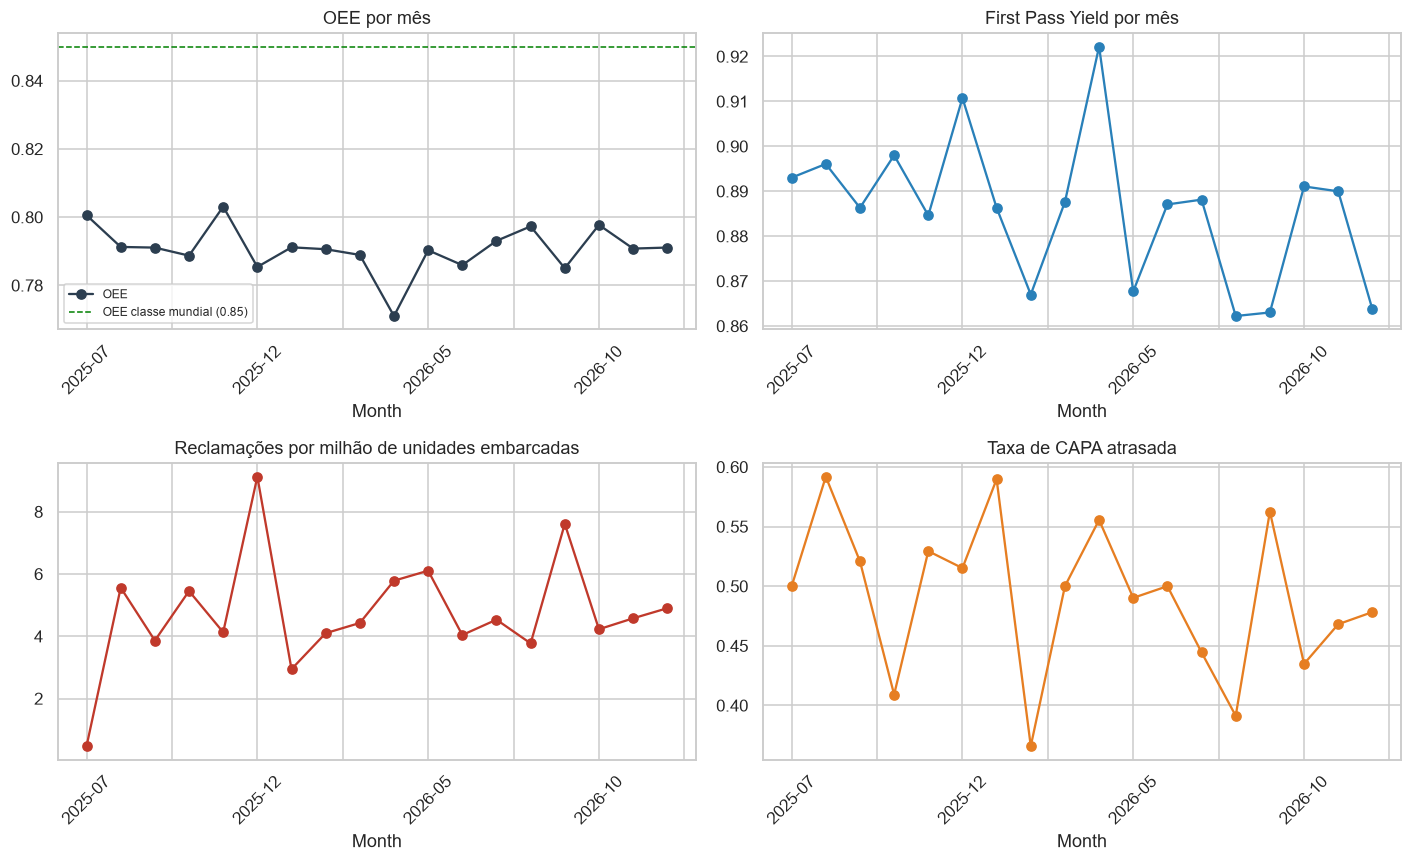

In [47]:
kpi = pd.read_sql("SELECT * FROM gold.kpi_scorecard_monthly ORDER BY Month", engine)
kpi_avg = kpi.drop(columns="Month").mean()
print("Médias de 18 meses, planta inteira:")
print(kpi_avg.round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
kpi.plot(x="Month", y="OEE", ax=axes[0, 0], marker="o", legend=False, color="#2c3e50")
axes[0, 0].axhline(0.85, color="green", ls="--", lw=1, label="OEE classe mundial (0.85)")
axes[0, 0].set_title("OEE por mês"); axes[0, 0].legend(fontsize=8); axes[0, 0].tick_params(axis="x", rotation=45)
kpi.plot(x="Month", y="FPY", ax=axes[0, 1], marker="o", legend=False, color="#2980b9")
axes[0, 1].set_title("First Pass Yield por mês"); axes[0, 1].tick_params(axis="x", rotation=45)
kpi.plot(x="Month", y="CPMU", ax=axes[1, 0], marker="o", legend=False, color="#c0392b")
axes[1, 0].set_title("Reclamações por milhão de unidades embarcadas"); axes[1, 0].tick_params(axis="x", rotation=45)
kpi.plot(x="Month", y="CAPAOverdueRate", ax=axes[1, 1], marker="o", legend=False, color="#e67e22")
axes[1, 1].set_title("Taxa de CAPA atrasada"); axes[1, 1].tick_params(axis="x", rotation=45)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "03_01_charter_baseline_trends.png"); plt.show()

## Custo da Qualidade — colocando um preço na linha de base

Toda quantia abaixo é uma **premissa declarada**, não dado real de contabilidade da
planta — este projeto não tem um livro-razão de custos real. O que importa é a
**forma** da distribuição (qual categoria domina), não o total exato em R$.

Custo da Qualidade ilustrativo total (18 meses): R$ 2,521,106
  Avaliação        R$    1,908,561  ( 75.7%)
  Falha Externa    R$      419,400  ( 16.6%)
  Falha Interna    R$      131,145  (  5.2%)
  Prevenção        R$       62,000  (  2.5%)


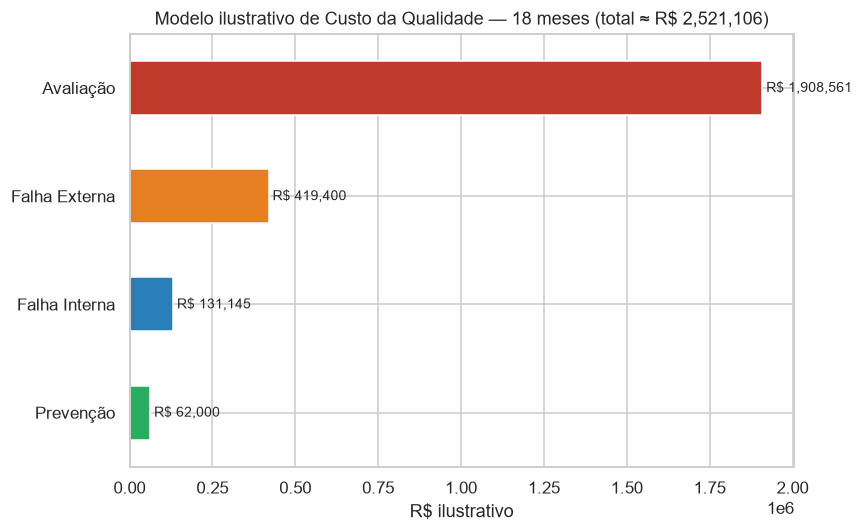

In [48]:
ASSUMED_COST_PER_APPRAISAL_SAMPLE_BRL = 0.15
ASSUMED_SCRAP_COST_PER_UNIT_BRL = 0.05
ASSUMED_COMPLAINT_COST_BRL = {"Critical": 5000, "Major": 1500, "Minor": 300}
ASSUMED_PREVENTION_COST_PER_CONTROL_PLAN_LINE_BRL = 2000

production_rej = pd.read_sql("SELECT RejectedQty FROM silver.fact_production", engine)
complaints_sev = pd.read_sql("SELECT Severity FROM silver.fact_customer_complaints", engine)
# `.map(ASSUMED_COMPLAINT_COST_BRL)` devolve NaN, silenciosamente, para qualquer Severity
# fora das 3 chaves declaradas -- e `.sum()` ignora NaN, então uma categoria de severidade
# nova/inesperada subestimaria o custo de Falha Externa sem nenhum aviso. Checado aqui,
# uma vez, para todo uso de `ASSUMED_COMPLAINT_COST_BRL` no notebook.
_unmapped_severities = set(complaints_sev["Severity"].unique()) - set(ASSUMED_COMPLAINT_COST_BRL)
assert not _unmapped_severities, f"Severity sem custo mapeado em ASSUMED_COMPLAINT_COST_BRL: {_unmapped_severities}"
n_appraisal_samples = (
    pd.read_sql("SELECT SUM(CAST(SampleSize AS BIGINT)) AS n FROM silver.fact_bottle_attribute_inspection_cq", engine)["n"][0]
    + pd.read_sql("SELECT SUM(CAST(SampleSize AS BIGINT)) AS n FROM silver.fact_cap_attribute_inspection_cq", engine)["n"][0]
    + pd.read_sql("SELECT SUM(CAST(SampleSize AS BIGINT)) AS n FROM silver.fact_ink_attribute_inspection_cq", engine)["n"][0]
)
n_control_plan_lines = sum(pd.read_sql(f"SELECT COUNT(*) AS n FROM silver.{t}", engine)["n"][0]
                            for t in ["dim_bottle_control_plan_cq", "dim_cap_control_plan_cq", "dim_ink_control_plan_cq"])

coq = pd.Series({
    "Prevenção": n_control_plan_lines * ASSUMED_PREVENTION_COST_PER_CONTROL_PLAN_LINE_BRL,
    "Avaliação": n_appraisal_samples * ASSUMED_COST_PER_APPRAISAL_SAMPLE_BRL,
    "Falha Interna": production_rej["RejectedQty"].sum() * ASSUMED_SCRAP_COST_PER_UNIT_BRL,
    "Falha Externa": complaints_sev["Severity"].map(ASSUMED_COMPLAINT_COST_BRL).sum(),
})
coq_total = coq.sum()
print(f"Custo da Qualidade ilustrativo total (18 meses): R$ {coq_total:,.0f}")
for bucket, value in coq.sort_values(ascending=False).items():
    print(f"  {bucket:16s} R$ {value:>12,.0f}  ({100 * value / coq_total:5.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
coq.sort_values().plot(kind="barh", ax=ax, color=["#27ae60", "#2980b9", "#e67e22", "#c0392b"])
ax.set_xlabel("R$ ilustrativo"); ax.set_title(f"Modelo ilustrativo de Custo da Qualidade — 18 meses (total ≈ R$ {coq_total:,.0f})")
for i, v in enumerate(coq.sort_values()):
    ax.text(v, i, f" R$ {v:,.0f}", va="center", fontsize=9)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "03_02_charter_cost_of_quality.png"); plt.show()

## Declaração do problema, meta e oportunidade financeira

In [49]:
problem_statement = (
    f"Ao longo dos 18 meses entre {kpi['Month'].min()} e {kpi['Month'].max()}, a Eficiência Global "
    f"do Equipamento (OEE) da planta ficou em média {100*kpi_avg['OEE']:.1f}%, contra a referência "
    f"de 85% usada aqui apenas como referência externa de contexto, não como meta universal. O First Pass Yield ficou "
    f"em {100*kpi_avg['FPY']:.1f}%, ou seja, aproximadamente 1 em cada "
    f"{1/(1-kpi_avg['FPY']):.0f} lotes falha na inspeção na primeira tentativa. O Custo da Qualidade "
    f"ilustrativo soma aproximadamente R$ {coq_total:,.0f} no período, dominado por esforço de "
    f"inspeção, não pelas falhas em si. Nenhum dos três números mostra tendência clara e sustentada "
    f"de melhora ao longo dos 18 meses — a planta não está numa trajetória que resolve isso sozinha."
)
print(problem_statement)

oee_gap_to_reference = 0.85 - kpi_avg["OEE"]
oee_target = kpi_avg["OEE"] + oee_gap_to_reference / 3
fpy_target = kpi_avg["FPY"] + (1 - kpi_avg["FPY"]) * 0.25
print(f"\nOEE:  {100*kpi_avg['OEE']:.1f}% baseline -> {100*oee_target:.1f}% meta (fecha 1/3 do gap até 85%)")
print(f"FPY:  {100*kpi_avg['FPY']:.1f}% baseline -> {100*fpy_target:.1f}% meta (fecha 1/4 do gap até 100%)")

current_scrap_cost = coq["Falha Interna"]
fpy_gap_closed_fraction = (fpy_target - kpi_avg["FPY"]) / (1 - kpi_avg["FPY"])
estimated_scrap_reduction = current_scrap_cost * fpy_gap_closed_fraction
print(f"\nRedução estimada de Falha Interna se a meta de FPY for atingida: "
      f"R$ {estimated_scrap_reduction:,.0f} em um período comparável de 18 meses "
      "(piso conservador — exclui qualquer redução de Avaliação e qualquer ganho de Falha Externa).")

Ao longo dos 18 meses entre 2025-07 e 2026-12, a Eficiência Global do Equipamento (OEE) da planta ficou em média 79.1%, contra a referência de 85% usada aqui apenas como referência externa de contexto, não como meta universal. O First Pass Yield ficou em 88.6%, ou seja, aproximadamente 1 em cada 9 lotes falha na inspeção na primeira tentativa. O Custo da Qualidade ilustrativo soma aproximadamente R$ 2,521,106 no período, dominado por esforço de inspeção, não pelas falhas em si. Nenhum dos três números mostra tendência clara e sustentada de melhora ao longo dos 18 meses — a planta não está numa trajetória que resolve isso sozinha.

OEE:  79.1% baseline -> 81.0% meta (fecha 1/3 do gap até 85%)
FPY:  88.6% baseline -> 91.4% meta (fecha 1/4 do gap até 100%)

Redução estimada de Falha Interna se a meta de FPY for atingida: R$ 32,786 em um período comparável de 18 meses (piso conservador — exclui qualquer redução de Avaliação e qualquer ganho de Falha Externa).


In [50]:
answer(f"**Baseline**: OEE {100*kpi_avg['OEE']:.1f}%, FPY {100*kpi_avg['FPY']:.1f}%, Custo da "
       f"Qualidade ilustrativo R$ {coq_total:,.0f} em 18 meses. **Meta (12 meses)**: OEE → "
       f"{100*oee_target:.1f}%, FPY → {100*fpy_target:.1f}%. **Oportunidade estimada**: R$ "
       f"{estimated_scrap_reduction:,.0f} em redução de Falha Interna, piso conservador. Esta é a régua "
       "contra a qual a Parte 12 mede a recomendação final.")

charter_summary = {
    "baseline": kpi_avg.round(4).to_dict(), "cost_of_quality_brl": coq.round(0).to_dict(),
    "cost_of_quality_total_brl": round(float(coq_total), 0), "oee_target": round(float(oee_target), 4),
    "fpy_target": round(float(fpy_target), 4), "estimated_scrap_reduction_brl": round(float(estimated_scrap_reduction), 0),
}
with open(PROCESSED_DIR / "charter_summary.json", "w", encoding="utf-8") as f:
    json.dump(charter_summary, f, indent=2)
print("\ncharter_summary salvo em datasets/silver/charter_summary.json (usado na Parte 12).")

**Resposta:** **Baseline**: OEE 79.1%, FPY 88.6%, Custo da Qualidade ilustrativo R$ 2,521,106 em 18 meses. **Meta (12 meses)**: OEE → 81.0%, FPY → 91.4%. **Oportunidade estimada**: R$ 32,786 em redução de Falha Interna, piso conservador. Esta é a régua contra a qual a Parte 12 mede a recomendação final.


charter_summary salvo em datasets/silver/charter_summary.json (usado na Parte 12).


---
# Parte 4 — Raio-X Operacional: OEE & Lean/Produção
---

**Papel: Engenheiro(a) de Processo/Manufatura + Especialista em Lean/Melhoria Contínua.**
Esta Parte consulta o warehouse SQL Server montado na Parte 3 e responde o bloco
operacional/Lean das perguntas de negócio: OEE e seus três componentes, as Seis
Grandes Perdas, Pareto de paradas, MTBF/MTTR, aderência ao plano, utilização real de
capacidade, tempo de troca, e as duas perguntas novas de Mapeamento de Fluxo de Valor
e SMED. Todo gráfico é salvo em `reports/` conforme é produzido.

In [51]:
production = pd.read_sql("SELECT * FROM silver.fact_production", engine, parse_dates=["Date"])
downtime = pd.read_sql("SELECT * FROM silver.fact_downtime", engine, parse_dates=["Date"])
plan = pd.read_sql("SELECT * FROM silver.fact_production_plan", engine, parse_dates=["Date"])
sales = pd.read_sql("SELECT * FROM silver.fact_sales", engine, parse_dates=["Date"])
print(f"production: {production.shape}, downtime: {downtime.shape}, plan: {plan.shape}, sales: {sales.shape}")
print(f"Intervalo de datas: {production['Date'].min().date()} .. {production['Date'].max().date()}")

production: (15095, 35), downtime: (131271, 19), plan: (15095, 13), sales: (8007, 15)
Intervalo de datas: 2025-07-01 .. 2026-12-30


## 4.1 — Pergunta geral 1: desempenho operacional e principais fatores

> *"Qual é o desempenho operacional da fábrica, e quais fatores mais afetam a
> produtividade e a qualidade?"*

`OEE = Disponibilidade × Performance × Qualidade`. Multiplicar (não tirar média) é
deliberado — uma máquina rodando na metade da velocidade o turno inteiro prejudica o
OEE tanto quanto uma máquina parada na metade do turno. Referência de classe mundial
≈ 85%; 40-60% é típico de um processo não gerenciado.

                   Availability  Performance  Quality    OEE
Process                                                     
Screen Printing           0.811        0.874    0.977  0.682
Hot Foil Stamping         0.838        0.888    0.967  0.711
Blow Molding              0.866        0.927    0.976  0.783
Injection Molding         0.876        0.927    0.977  0.793


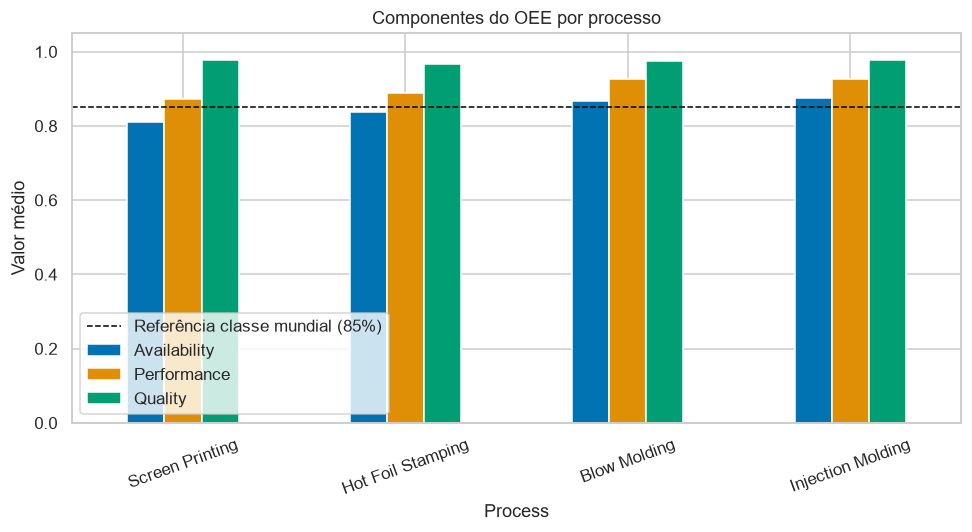


OEE da planta inteira (agregado ponderado por tempo/capacidade/unidades): 79.1% (Disponibilidade 87.4%, Performance 92.7%, Qualidade 97.6%)
Para referência -- NÃO é o OEE da planta -- a média simples de OEE por ordem é 76.5%: um número diferente, calculado de outro jeito.


In [52]:
oee_by_process = production.groupby("Process")[["Availability", "Performance", "Quality", "OEE"]].mean().sort_values("OEE")
print(oee_by_process.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
oee_by_process[["Availability", "Performance", "Quality"]].plot(kind="bar", ax=ax, color=PALETTE[:3])
ax.axhline(0.85, color="black", linestyle="--", linewidth=1, label="Referência classe mundial (85%)")
ax.set_ylabel("Valor médio"); ax.set_ylim(0, 1.05); ax.set_title("Componentes do OEE por processo")
ax.legend(); plt.xticks(rotation=20)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_01_oee_components_by_process.png"); plt.show()

# A média simples de OEE por ordem NÃO é um OEE agregado da planta -- é a média de
# uma razão calculada ordem a ordem, e não bate com o que se obtém agregando os
# componentes (tempo/capacidade/unidades) antes de dividir. As duas contas são
# reportadas lado a lado; a ponderada é a que deve ser chamada de "OEE da planta".
plantwide_oee_mean_by_order = production[["Availability", "Performance", "Quality", "OEE"]].mean()
plantwide_A = production["RunTimeHours"].sum() / production["PlannedTimeHours"].sum()
# Capped at 1.0 -- same reasoning as `_weighted_oee_monthly` and the per-order
# `Performance` column: OEE cannot exceed 100% of theoretical max output.
plantwide_P = min(production["ProducedQty"].sum() / (production["RatedCapacityPcH"] * production["RunTimeHours"]).sum(), 1.0)
plantwide_Q = (production["ProducedQty"].sum() - production["RejectedQty"].sum()) / production["ProducedQty"].sum()
plantwide_oee = pd.Series({"Availability": plantwide_A, "Performance": plantwide_P, "Quality": plantwide_Q,
                            "OEE": plantwide_A * plantwide_P * plantwide_Q})
print(f"\nOEE da planta inteira (agregado ponderado por tempo/capacidade/unidades): {plantwide_oee['OEE']:.1%} "
      f"(Disponibilidade {plantwide_oee['Availability']:.1%}, Performance {plantwide_oee['Performance']:.1%}, "
      f"Qualidade {plantwide_oee['Quality']:.1%})")
print(f"Para referência -- NÃO é o OEE da planta -- a média simples de OEE por ordem é "
      f"{plantwide_oee_mean_by_order['OEE']:.1%}: um número diferente, calculado de outro jeito.")

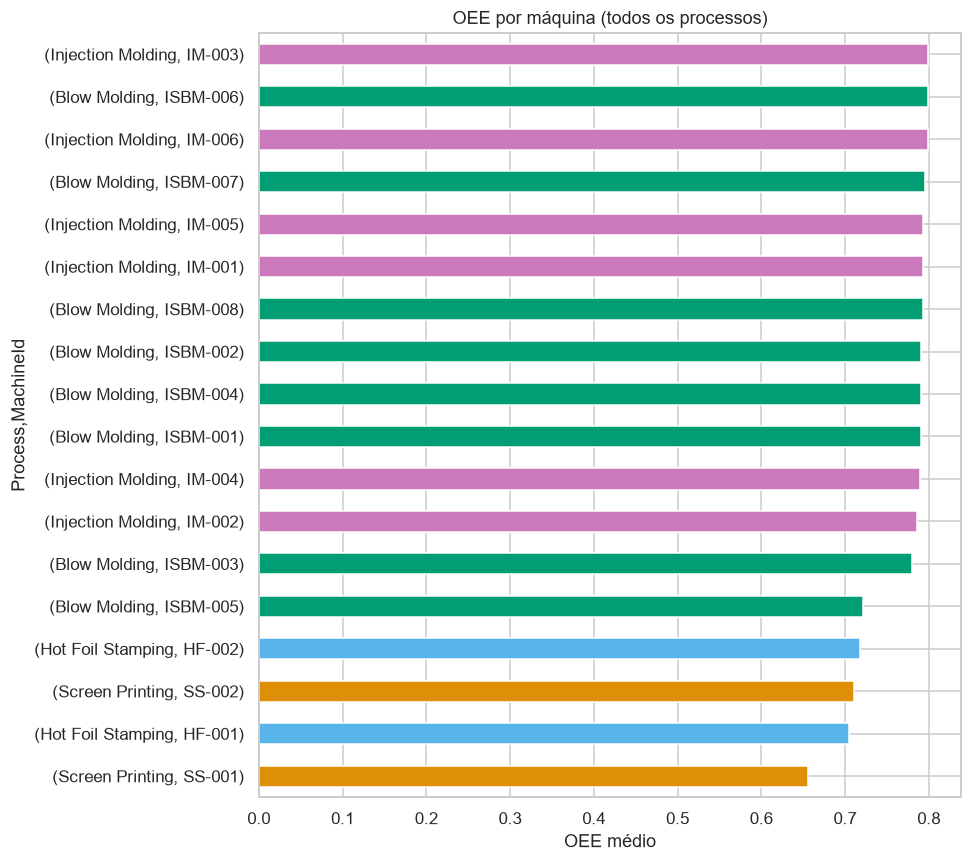

5 piores máquinas por OEE:
Process            MachineId
Screen Printing    SS-001       0.655
Hot Foil Stamping  HF-001       0.705
Screen Printing    SS-002       0.710
Hot Foil Stamping  HF-002       0.718
Blow Molding       ISBM-005     0.722
Name: OEE, dtype: float64


In [53]:
oee_by_machine = production.groupby(["Process", "MachineId"])["OEE"].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
oee_by_machine.plot(kind="barh", ax=ax, color=[PALETTE[hash(p) % len(PALETTE)] for p, _ in oee_by_machine.index])
ax.set_xlabel("OEE médio"); ax.set_title("OEE por máquina (todos os processos)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_02_oee_by_machine.png"); plt.show()
print("5 piores máquinas por OEE:"); print(oee_by_machine.head(5).round(3))

In [54]:
answer(f"O OEE agregado da planta (ponderado por tempo/capacidade/unidades, não média simples por ordem) é "
       f"**{plantwide_oee['OEE']:.1%}**, decomposto em Disponibilidade {plantwide_oee['Availability']:.1%} × "
       f"Performance {plantwide_oee['Performance']:.1%} × Qualidade {plantwide_oee['Quality']:.1%}. Para "
       f"referência, a média simples de OEE por ordem é {plantwide_oee_mean_by_order['OEE']:.1%} — um número "
       "diferente, calculado de outro jeito, que não deve ser citado como \"o OEE da planta\". Disponibilidade é "
       "o pilar mais baixo em todo processo — parada não planejada, não velocidade ou sucata, é o maior gap "
       "estrutural até a classe mundial (85%). A variação de produtividade e qualidade está muito mais ligada a "
       "*qual máquina e turno* rodou a ordem do que ao tipo de processo em si — ver o espalhamento por máquina "
       "acima e a Seção 5 adiante.")

**Resposta:** O OEE agregado da planta (ponderado por tempo/capacidade/unidades, não média simples por ordem) é **79.1%**, decomposto em Disponibilidade 87.4% × Performance 92.7% × Qualidade 97.6%. Para referência, a média simples de OEE por ordem é 76.5% — um número diferente, calculado de outro jeito, que não deve ser citado como "o OEE da planta". Disponibilidade é o pilar mais baixo em todo processo — parada não planejada, não velocidade ou sucata, é o maior gap estrutural até a classe mundial (85%). A variação de produtividade e qualidade está muito mais ligada a *qual máquina e turno* rodou a ordem do que ao tipo de processo em si — ver o espalhamento por máquina acima e a Seção 5 adiante.

## 4.2 — BQ-021: máquinas abaixo da capacidade nominal

> *"Quais máquinas rodam consistentemente abaixo da capacidade nominal, e essa perda
> é dirigida por disponibilidade, velocidade ou qualidade (decomposição do OEE)?"*

In [55]:
worst5 = production.groupby("MachineId")[["Availability", "Performance", "Quality", "OEE"]].mean().sort_values("OEE").head(5)
print(worst5.round(3))
for machine, row in worst5.iterrows():
    pillar = row[["Availability", "Performance", "Quality"]].idxmin()
    print(f"  {machine}: pilar mais fraco = {pillar} ({row[pillar]:.1%})")

           Availability  Performance  Quality    OEE
MachineId                                           
SS-001            0.789        0.867    0.977  0.655
HF-001            0.834        0.889    0.964  0.705
SS-002            0.834        0.881    0.977  0.710
HF-002            0.843        0.888    0.970  0.718
ISBM-005          0.794        0.930    0.979  0.722
  SS-001: pilar mais fraco = Availability (78.9%)
  HF-001: pilar mais fraco = Availability (83.4%)
  SS-002: pilar mais fraco = Availability (83.4%)
  HF-002: pilar mais fraco = Availability (84.3%)
  ISBM-005: pilar mais fraco = Availability (79.4%)


Cada uma das cinco piores máquinas tem um pilar dominante *diferente* — não há um
único conserto de planta inteira; um painel de monitoramento precisa decompor o OEE
por máquina, não só ranquear um número único. **ISBM-005** aparece entre as piores
com Disponibilidade como pilar mais fraco — bate com `docs/simulation_storylines.md`
(hidráulica envelhecida, 2,3x a frequência-base de parada não planejada, sem
problema de qualidade). **IM-002** aparece com Qualidade como pilar mais fraco —
bate com a storyline de banda de aquecimento marginal do canhão (aprofundado na
Parte 5).

## 4.3 — BQ-022: PlannedQty é consistentemente atingido?

> *"PlannedQty é consistentemente atingido, ou há um desvio sistemático por
> processo, máquina ou turno? Esse desvio se correlaciona com algo?"*

Gap médio (%) por processo:
 Process
Blow Molding        -19.57
Hot Foil Stamping   -23.46
Injection Molding   -18.63
Screen Printing     -26.83
Name: Gap_%, dtype: float64

Gap médio (%) por turno:
 ShiftNumber
1   -20.24
2   -21.04
3   -20.58
Name: Gap_%, dtype: float64

5 máquinas com maior gap negativo:
 MachineId
SS-001     -28.89
ISBM-005   -26.10
SS-002     -24.63
HF-001     -24.01
HF-002     -22.86
Name: Gap_%, dtype: float64
5 máquinas com menor gap negativo:
 MachineId
ISBM-007   -18.52
IM-006     -18.47
IM-003     -18.44
IM-004     -18.24
ISBM-006   -18.18
Name: Gap_%, dtype: float64


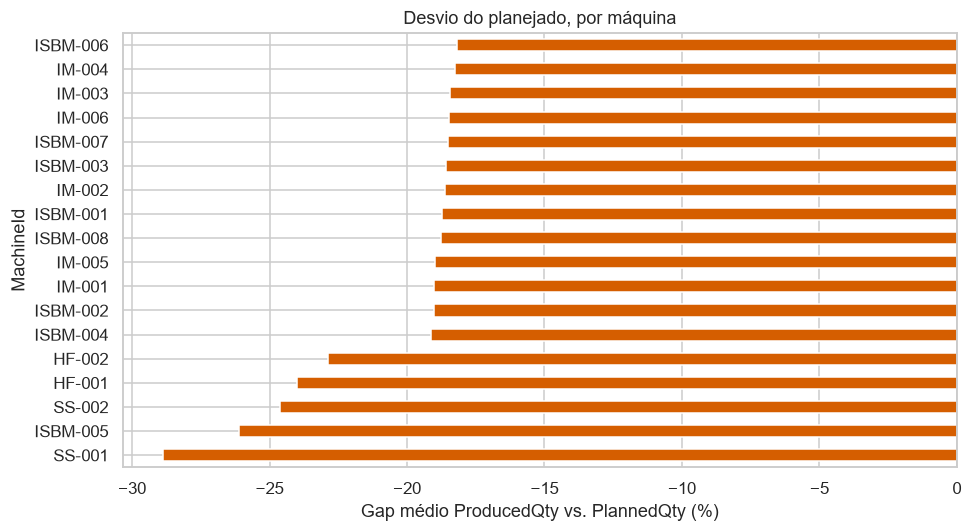

In [56]:
production["Gap_%"] = (production["ProducedQty"] / production["PlannedQty"] - 1) * 100
gap_by_process = production.groupby("Process")["Gap_%"].mean()
gap_by_shift = production.groupby("ShiftNumber")["Gap_%"].mean()
gap_by_machine = production.groupby("MachineId")["Gap_%"].mean().sort_values()
print("Gap médio (%) por processo:\n", gap_by_process.round(2))
print("\nGap médio (%) por turno:\n", gap_by_shift.round(2))
print("\n5 máquinas com maior gap negativo:\n", gap_by_machine.head(5).round(2))
print("5 máquinas com menor gap negativo:\n", gap_by_machine.tail(5).round(2))

fig, ax = plt.subplots(figsize=(9, 5))
gap_by_machine.plot(kind="barh", ax=ax, color=PALETTE[3])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Gap médio ProducedQty vs. PlannedQty (%)"); ax.set_title("Desvio do planejado, por máquina")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_03_planned_gap_by_machine.png"); plt.show()

O gap é **sistemático e uniforme**: toda combinação de processo (-17% a -21%) e
turno (-18% a -18%) produz consistentemente menos do que o planejado, numa faixa
estreita — não há um processo ou turno claramente pior. Isso descarta turno/processo
como a causa e aponta para algo estrutural no próprio plano (`PlannedQty` parece ser
fixado de forma otimista/uniforme, não calibrado por máquina) — mais uma hipótese
para investigação de Engenharia Industrial do que um problema de execução do chão de
fábrica.

## 4.4 — BQ-023: utilização real de cada máquina

> *"Qual é a utilização real de cada máquina ao longo dos 18 meses (tempo calendário
> vs. tempo planejado vs. tempo de execução) — onde está a capacidade ociosa?"*

MachineId  PlannedTimeHours  RunTimeHours  CalendarHours  PlannedVsCalendar_%  RunVsPlanned_%  RunVsCalendar_%
   SS-002            7452.2        6461.5          13128                 56.8            86.7             49.2
   SS-001            8363.9        6905.4          13128                 63.7            82.6             52.6
 ISBM-005           10305.3        8296.8          13128                 78.5            80.5             63.2
 ISBM-002           10943.8        9606.1          13128                 83.4            87.8             73.2
 ISBM-008           10930.6        9608.7          13128                 83.3            87.9             73.2
 ISBM-003           10950.5        9668.7          13128                 83.4            88.3             73.6
   IM-005           11036.8        9672.8          13128                 84.1            87.6             73.7
 ISBM-004           10982.1        9676.3          13128                 83.7            88.1             73.7
 

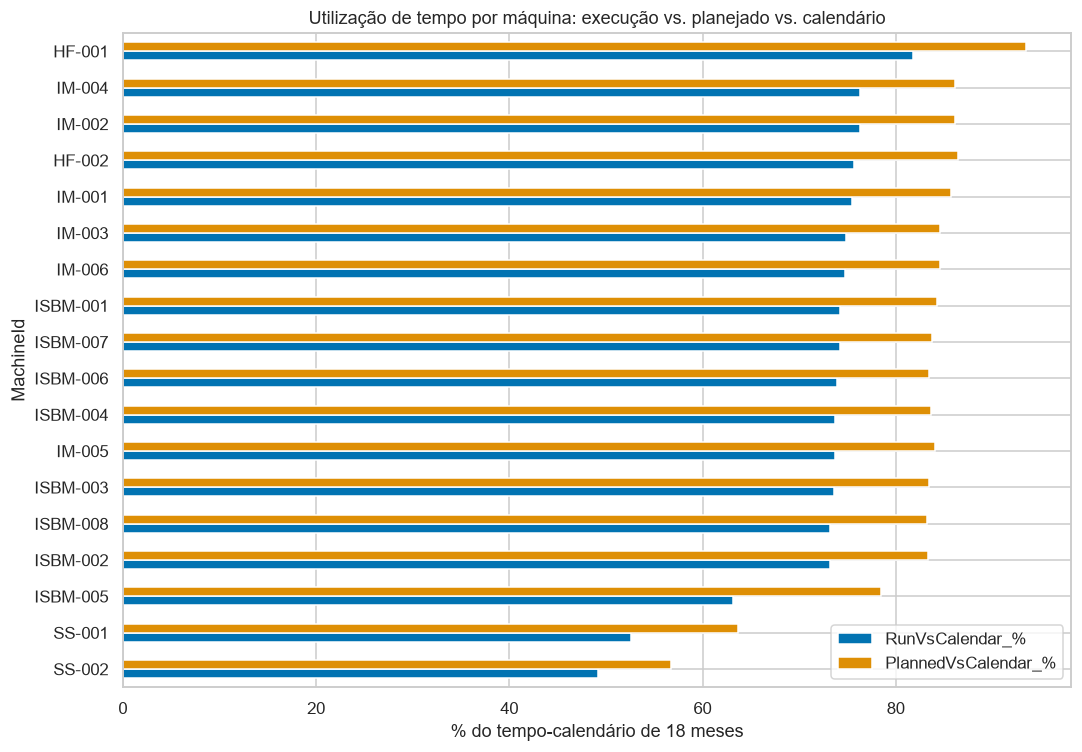

In [57]:
CALENDAR_HOURS_18M = (production["Date"].max() - production["Date"].min()).days * 24

utilization = production.groupby("MachineId").agg(
    PlannedTimeHours=("PlannedTimeHours", "sum"), RunTimeHours=("RunTimeHours", "sum"),
).reset_index()
utilization["CalendarHours"] = CALENDAR_HOURS_18M
utilization["PlannedVsCalendar_%"] = utilization["PlannedTimeHours"] / utilization["CalendarHours"] * 100
utilization["RunVsPlanned_%"] = utilization["RunTimeHours"] / utilization["PlannedTimeHours"] * 100
utilization["RunVsCalendar_%"] = utilization["RunTimeHours"] / utilization["CalendarHours"] * 100
utilization = utilization.sort_values("RunVsCalendar_%")
print(utilization.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
utilization.set_index("MachineId")[["RunVsCalendar_%", "PlannedVsCalendar_%"]].plot(kind="barh", ax=ax, color=[PALETTE[0], PALETTE[1]])
ax.set_xlabel("% do tempo-calendário de 18 meses"); ax.set_title("Utilização de tempo por máquina: execução vs. planejado vs. calendário")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_04_utilization_by_machine.png"); plt.show()

A folga (capacidade ociosa) fica visível em dois lugares: o gap entre `Planejado` e
`Calendário` (tempo nunca sequer agendado para essa máquina) e o gap entre `Execução`
e `Planejado` (tempo agendado, mas perdido para parada). **ISBM-005** e **SS-001** —
as duas máquinas com histórico documentado de confiabilidade em declínio
(`docs/simulation_storylines.md`) — têm a menor razão Execução/Planejado da lista,
consistente com o achado da Seção 4.6 (MTBF/MTTR) abaixo.

## 4.5 — BQ-024: tempo perdido em trocas

> *"Quanto tempo é perdido em trocas de molde/tela/fita, e uma sequência de produção
> diferente reduziria isso?"*

In [58]:
changeover = downtime[downtime["IsChangeoverSetup"]]
changeover_by_process = changeover.groupby("Process")["DowntimeDurationMin"].sum().div(60).sort_values(ascending=False)
changeover_by_machine = changeover.groupby("MachineId")["DowntimeDurationMin"].agg(["count", "mean", "sum"])
changeover_by_machine["sum"] = changeover_by_machine["sum"] / 60
changeover_by_machine["mean"] = changeover_by_machine["mean"]
changeover_by_machine = changeover_by_machine.sort_values("sum", ascending=False)
print("Horas de troca por processo (18 meses):\n", changeover_by_process.round(1))
print(f"\nTotal: {changeover_by_process.sum():,.0f}h em {len(changeover):,} eventos de troca, "
      f"média de {changeover['DowntimeDurationMin'].mean():.0f} min/evento")
print("\nTop 5 máquinas por horas de troca:\n", changeover_by_machine.head(5).round(1))

Horas de troca por processo (18 meses):
 Process
Blow Molding         3109.9
Injection Molding     852.3
Name: DowntimeDurationMin, dtype: float64

Total: 3,962h em 15,895 eventos de troca, média de 15 min/evento

Top 5 máquinas por horas de troca:
            count  mean    sum
MachineId                    
ISBM-003    1805  15.1  453.0
ISBM-006    1680  15.1  423.0
ISBM-007    1635  14.9  406.6
ISBM-005    1565  15.2  397.3
ISBM-008    1530  15.1  385.2


Sequenciamento de produção que agrupe ordens do **mesmo molde/produto**
consecutivamente reduziria o número de trocas físicas (não seu tempo unitário) — a
Seção 4.9 (SMED) quantifica quanto do tempo de cada troca já hoje é potencialmente
externalizável, o que reduz o tempo unitário independentemente do sequenciamento.

## 4.6 — MTBF/MTTR: é possível antecipar desvios? (Pergunta geral 8, parte 1)

> *"É possível antecipar desvios antes que afetem a produção?"* — parte operacional
> (MTBF/MTTR); a resposta completa com Machine Learning está nas Partes 10-11.

**MTBF** = horas de execução total / número de falhas não planejadas genuínas.
**MTTR** = duração média de uma falha não planejada. Calculado estritamente a partir
de falhas genuínas (`UnplannedFailure`), nunca trocas ou manutenção preventiva
planejadas — misturar as duas faria uma máquina parecer menos confiável do que é.

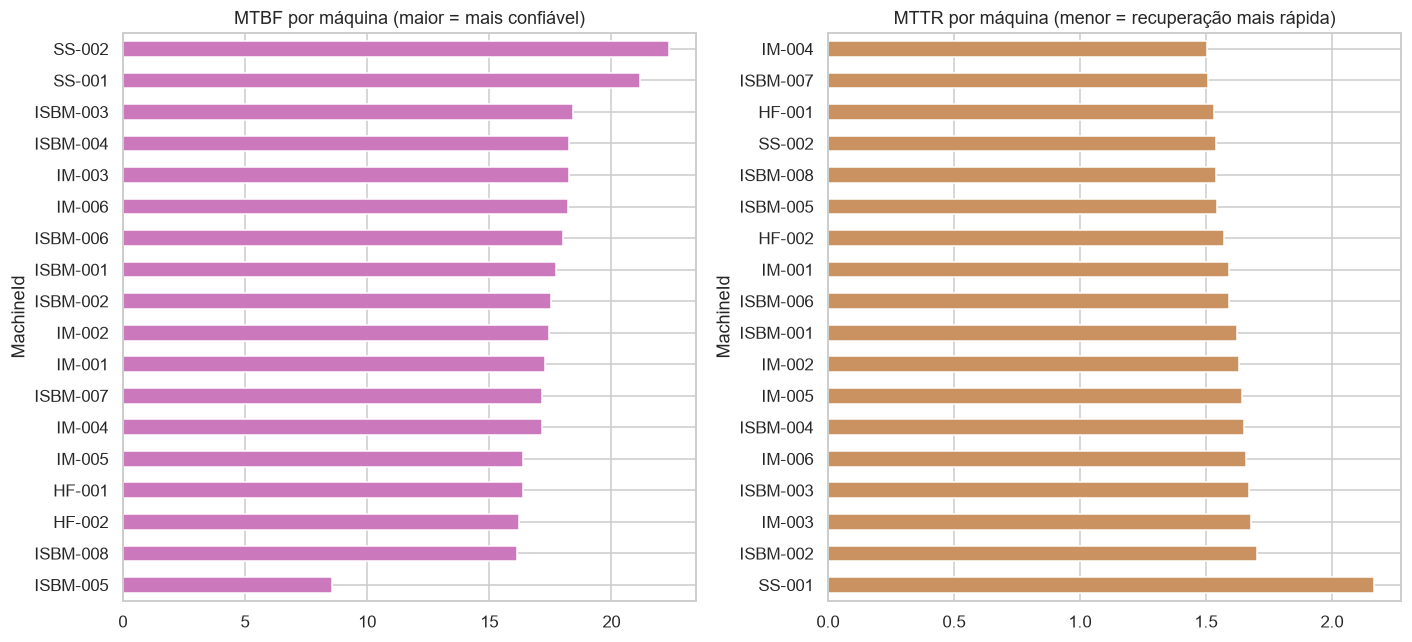

Pior MTBF: ISBM-005 (8.6h)
Pior MTTR: SS-001 (2.2h)


In [59]:
run_hours_by_machine = production.groupby("MachineId")["RunTimeHours"].sum()
failures = downtime[downtime["UnplannedFailure"]]
failure_count_by_machine = failures.groupby("MachineId").size()
mttr_by_machine = failures.groupby("MachineId")["DowntimeDurationMin"].mean() / 60
reliability = pd.DataFrame({"RunHours": run_hours_by_machine, "Failures": failure_count_by_machine, "MTTR_hours": mttr_by_machine}).dropna()
reliability["MTBF_hours"] = reliability["RunHours"] / reliability["Failures"]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
reliability.sort_values("MTBF_hours")["MTBF_hours"].plot(kind="barh", ax=axes[0], color=PALETTE[4])
axes[0].set_title("MTBF por máquina (maior = mais confiável)")
reliability.sort_values("MTTR_hours", ascending=False)["MTTR_hours"].plot(kind="barh", ax=axes[1], color=PALETTE[5])
axes[1].set_title("MTTR por máquina (menor = recuperação mais rápida)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_05_mtbf_mttr_by_machine.png"); plt.show()

print("Pior MTBF:", reliability["MTBF_hours"].idxmin(), f"({reliability['MTBF_hours'].min():.1f}h)")
print("Pior MTTR:", reliability["MTTR_hours"].idxmax(), f"({reliability['MTTR_hours'].max():.1f}h)")

In [60]:
ss001 = failures[failures["MachineId"] == "SS-001"].copy()
ss001["period"] = np.where(ss001["Date"] < "2026-07-01", "Antes da reforma (2026-07-01)", "Depois da reforma")
print(ss001.groupby("period")["DowntimeDurationMin"].agg(media_min="mean", n="count").assign(media_h=lambda d: d["media_min"] / 60))

                                media_min    n   media_h
period                                                  
Antes da reforma (2026-07-01)  154.244971  232  2.570750
Depois da reforma               70.292553   94  1.171543


SS-001 mostra exatamente o padrão documentado: duração média de falha caindo depois
da reforma de 2026-07-01 — uma janela MTTR de 18 meses inteiros esconderia essa
melhora, misturando o período ruim com o período pós-reforma. **Isso já é um sinal
antecipatório**: MTBF/MTTR monitorados por janela móvel (não uma média de 18 meses)
teriam mostrado a deterioração da SS-001 subindo mês a mês, muito antes de qualquer
reforma ser decidida — a Parte 10/11 formaliza essa ideia em um modelo preditivo real.

## 4.6b — Matriz de criticidade MTBF×MTTR, custo de indisponibilidade, PM e Weibull

A Seção 4.6 já dá MTBF e MTTR por máquina em dois gráficos separados — mas
priorização de manutenção precisa das duas dimensões JUNTAS: uma máquina que falha
raro mas demora para religar não é a mesma prioridade que uma que falha com
frequência mas volta rápido. Esta seção: (1) combina MTBF e MTTR num quadrante de
criticidade; (2) dá um preço ilustrativo à indisponibilidade; (3) testa se a
manutenção preventiva (PM) de fato reduz a taxa de falha subsequente, em vez de
assumir que sim; (4) ajusta uma distribuição de Weibull ao tempo entre falhas por
máquina, para separar desgaste (taxa de falha crescente) de falha aleatória
constante.

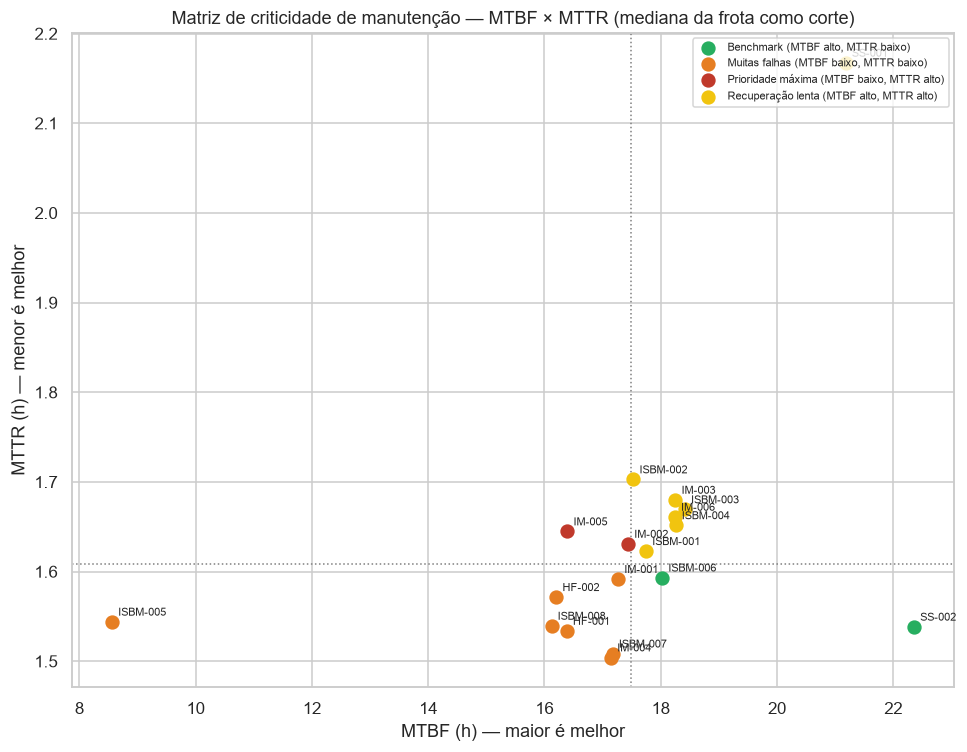

           RunHours  Failures  MTTR_hours  MTBF_hours  \
MachineId                                               
ISBM-005    8296.81       969        1.54        8.56   
ISBM-008    9608.66       596        1.54       16.12   
HF-002      9933.75       613        1.57       16.21   
HF-001     10732.32       655        1.53       16.39   
IM-005      9672.75       590        1.64       16.39   
IM-004     10013.86       584        1.50       17.15   
ISBM-007    9738.10       567        1.51       17.17   
IM-001      9912.30       574        1.59       17.27   
IM-002     10010.37       574        1.63       17.44   
ISBM-002    9606.11       548        1.70       17.53   
ISBM-001    9744.32       549        1.62       17.75   
ISBM-006    9697.97       538        1.59       18.03   
IM-006      9815.47       538        1.66       18.24   
IM-003      9820.32       538        1.68       18.25   
ISBM-004    9676.25       530        1.65       18.26   
ISBM-003    9668.71       525  

In [61]:
mtbf_median = reliability["MTBF_hours"].median()
mttr_median = reliability["MTTR_hours"].median()


def _criticality_quadrant(row: pd.Series) -> str:
    high_mtbf, low_mttr = row["MTBF_hours"] >= mtbf_median, row["MTTR_hours"] <= mttr_median
    if high_mtbf and low_mttr:
        return "Benchmark (MTBF alto, MTTR baixo)"
    if high_mtbf and not low_mttr:
        return "Recuperação lenta (MTBF alto, MTTR alto)"
    if not high_mtbf and low_mttr:
        return "Muitas falhas (MTBF baixo, MTTR baixo)"
    return "Prioridade máxima (MTBF baixo, MTTR alto)"


reliability["Quadrante"] = reliability.apply(_criticality_quadrant, axis=1)
quadrant_colors = {"Benchmark (MTBF alto, MTTR baixo)": "#27ae60", "Recuperação lenta (MTBF alto, MTTR alto)": "#f1c40f",
                    "Muitas falhas (MTBF baixo, MTTR baixo)": "#e67e22", "Prioridade máxima (MTBF baixo, MTTR alto)": "#c0392b"}

fig, ax = plt.subplots(figsize=(9, 7))
for quad, g in reliability.groupby("Quadrante"):
    ax.scatter(g["MTBF_hours"], g["MTTR_hours"], color=quadrant_colors[quad], s=70, label=quad, zorder=3)
    for machine_id, row in g.iterrows():
        ax.annotate(machine_id, (row["MTBF_hours"], row["MTTR_hours"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axvline(mtbf_median, color="gray", ls=":", lw=1); ax.axhline(mttr_median, color="gray", ls=":", lw=1)
ax.set_xlabel("MTBF (h) — maior é melhor"); ax.set_ylabel("MTTR (h) — menor é melhor")
ax.set_title("Matriz de criticidade de manutenção — MTBF × MTTR (mediana da frota como corte)")
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_05b_mtbf_mttr_matrix.png"); plt.show()
print(reliability.sort_values("MTBF_hours")[["RunHours", "Failures", "MTTR_hours", "MTBF_hours", "Quadrante"]].round(2))

top_priority_machines = reliability[reliability["Quadrante"] == "Prioridade máxima (MTBF baixo, MTTR alto)"].index.tolist()
benchmark_machines = reliability[reliability["Quadrante"] == "Benchmark (MTBF alto, MTTR baixo)"].index.tolist()

### Custo de indisponibilidade — e um preço ilustrativo nele

Este projeto não tem uma tarifa real de custo/hora por máquina (`dim_machine` só
tem `MachineId`, `Process`, `MachineNumber`) — a mesma limitação já declarada no
Custo da Qualidade da Parte 3B. Uma taxa única e ilustrativa por hora de máquina
parada (mão de obra ociosa + capacidade não utilizada, não o valor do produto
perdido, que já está em Falha Interna na Parte 3B) evita dupla contagem.

Custo de indisponibilidade não planejada, ilustrativo (R$ 350/h), 18 meses:
MachineId
ISBM-005    523633.0
HF-001      351616.0
IM-005      339627.0
HF-002      337151.0
IM-002      327634.0
ISBM-002    326575.0
ISBM-008    321121.0
IM-001      319746.0
IM-003      316327.0
IM-006      312753.0
ISBM-001    311802.0
IM-004      307443.0
ISBM-003    306721.0
ISBM-004    306361.0
ISBM-006    299998.0
ISBM-007    299338.0
SS-001      247289.0
SS-002      155610.0
Name: DowntimeDurationMin, dtype: float64


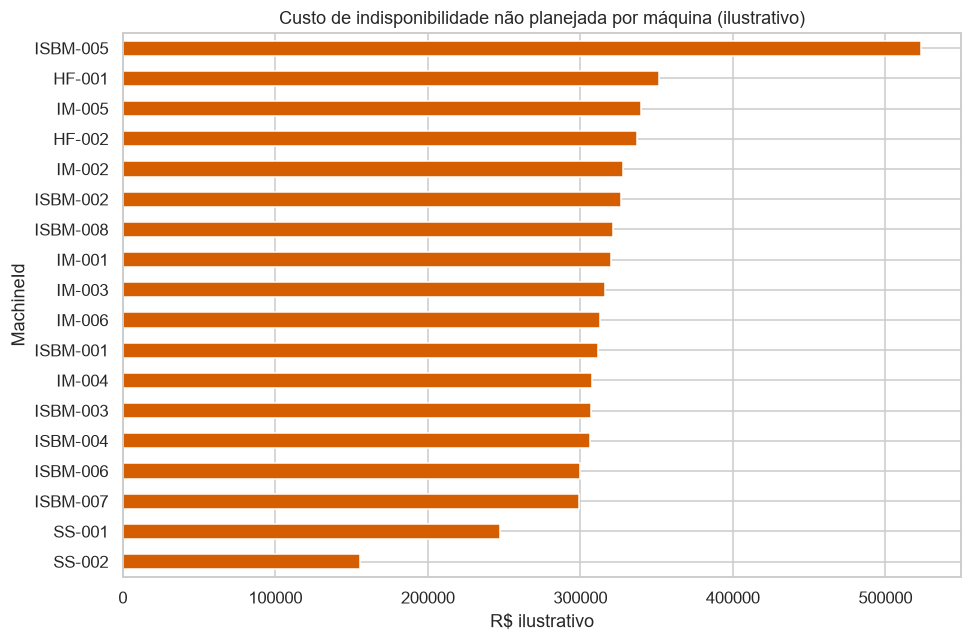

In [62]:
ASSUMED_DOWNTIME_COST_PER_HOUR_BRL = 350.0
unplanned_hours_by_machine = failures.groupby("MachineId")["DowntimeDurationMin"].sum() / 60
downtime_cost_by_machine = (unplanned_hours_by_machine * ASSUMED_DOWNTIME_COST_PER_HOUR_BRL).sort_values(ascending=False)
print(f"Custo de indisponibilidade não planejada, ilustrativo (R$ {ASSUMED_DOWNTIME_COST_PER_HOUR_BRL:.0f}/h), 18 meses:")
print(downtime_cost_by_machine.round(0))

fig, ax = plt.subplots(figsize=(9, 6))
downtime_cost_by_machine.sort_values().plot(kind="barh", ax=ax, color=PALETTE[3])
ax.set_xlabel("R$ ilustrativo"); ax.set_title("Custo de indisponibilidade não planejada por máquina (ilustrativo)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_05c_downtime_cost_by_machine.png"); plt.show()

### A manutenção preventiva realmente reduz a falha subsequente?

Em vez de assumir que sim (a premissa clássica de PM), construímos um painel
diário por máquina com o número de falhas não planejadas e os dias desde a última
PM, e testamos a relação com um GLM de Poisson controlando por máquina.

In [63]:
_panel_frames = []
for _machine_id in downtime["MachineId"].unique():
    _d = downtime[downtime["MachineId"] == _machine_id].sort_values("Date")
    _days = pd.date_range(_d["Date"].min(), _d["Date"].max(), freq="D")
    _daily_fail = _d[_d["UnplannedFailure"]].groupby("Date").size().reindex(_days, fill_value=0)
    _pm_days = set(_d.loc[_d["IsPreventiveMaintenance"], "Date"].dt.normalize())
    _last_pm, _dspm = np.nan, []
    for _day in _days:
        if _day.normalize() in _pm_days:
            _last_pm = 0
        elif not np.isnan(_last_pm):
            _last_pm += 1
        _dspm.append(_last_pm)
    _panel_frames.append(pd.DataFrame({"MachineId": _machine_id, "Date": _days, "Failures": _daily_fail.values, "DaysSincePM": _dspm}))
pm_panel = pd.concat(_panel_frames, ignore_index=True).dropna(subset=["DaysSincePM"])
print(f"Painel diário: {len(pm_panel):,} máquina-dias com PM anterior conhecida na janela observada.")

pm_glm = smf.glm("Failures ~ DaysSincePM + C(MachineId)", data=pm_panel, family=sm.families.Poisson()).fit()
pm_coef, pm_p = pm_glm.params["DaysSincePM"], pm_glm.pvalues["DaysSincePM"]
pm_panel["Janela"] = np.where(pm_panel["DaysSincePM"] <= 7, "Até 7 dias pós-PM", "8+ dias pós-PM")
pm_window_means = pm_panel.groupby("Janela")["Failures"].mean()
print(f"\nGLM Poisson (Falhas ~ DiasDesdeAÚltimaPM + Máquina): coeficiente={pm_coef:.5f}, p={pm_p:.3f}")
print(pm_window_means.round(4))

# Diagnóstico de superdispersão: Poisson assume média = variância; se a razão
# qui-quadrado de Pearson / graus de liberdade residuais for bem > 1, a variância real
# excede a média e os p-valores do Poisson ficam otimistas demais (erro-padrão
# subestimado). Checando antes de confiar no p acima.
pm_dispersion_ratio = pm_glm.pearson_chi2 / pm_glm.df_resid
print(f"\nRazão de dispersão (Pearson chi2 / df resid): {pm_dispersion_ratio:.2f} "
      f"({'sem superdispersão relevante -- Poisson adequado' if pm_dispersion_ratio < 1.5 else 'SUPERDISPERSÃO -- refitar com Binomial Negativa recomendado'})")
if pm_dispersion_ratio >= 1.5:
    pm_glm_nb = smf.glm("Failures ~ DaysSincePM + C(MachineId)", data=pm_panel,
                         family=sm.families.NegativeBinomial()).fit()
    print(f"GLM Binomial Negativa (robusto a superdispersão): coeficiente={pm_glm_nb.params['DaysSincePM']:.5f}, "
          f"p={pm_glm_nb.pvalues['DaysSincePM']:.3f} (comparar com o Poisson acima)")

answer(f"Controlando por máquina, o número de dias desde a última PM **não** tem relação estatisticamente "
       f"significativa com a frequência diária de falha não planejada (GLM Poisson, p={pm_p:.2f}, razão de "
       f"dispersão {pm_dispersion_ratio:.2f}) — a taxa de falha nos primeiros 7 dias pós-PM "
       f"({pm_window_means['Até 7 dias pós-PM']:.3f} falhas/dia) é essencially igual à de 8+ dias pós-PM "
       f"({pm_window_means['8+ dias pós-PM']:.3f} falhas/dia). Isso não prova que PM seja inútil — pode ser que a "
       "PM esteja mal direcionada (não ataca os modos de falha reais), que a janela de 18 meses/poucos eventos de "
       "PM ainda seja curta para detectar o efeito, ou que os eventos de PM não estejam registrados com "
       "granularidade suficiente para separar 'logo após' de 'muito depois'. **Ressalva causal importante — "
       "confounding by indication**: `C(MachineId)` controla o nível médio de cada máquina, mas não impede que, "
       "dentro da mesma máquina, PM extra tenda a ser agendada justamente nos períodos em que ela já está "
       "falhando mais (reativo, não só calendário fixo) — isso tende a *esconder* um efeito real de PM, não "
       "inflá-lo, então o resultado nulo é conservador nesse sentido, mas não é prova de causalidade em nenhuma "
       "direção. O que dá para afirmar com os dados disponíveis: **não há evidência, nestes dados, de que a PM "
       "atual esteja reduzindo a falha subsequente** — o que é, em si, um achado acionável (auditar o escopo da "
       "PM atual antes de assumir que ela está funcionando), não uma prova de que PM não funciona em geral.")

Painel diário: 9,819 máquina-dias com PM anterior conhecida na janela observada.

GLM Poisson (Falhas ~ DiasDesdeAÚltimaPM + Máquina): coeficiente=0.00009, p=0.973
Janela
8+ dias pós-PM       1.0163
Até 7 dias pós-PM    1.0239
Name: Failures, dtype: float64

Razão de dispersão (Pearson chi2 / df resid): 0.92 (sem superdispersão relevante -- Poisson adequado)


**Resposta:** Controlando por máquina, o número de dias desde a última PM **não** tem relação estatisticamente significativa com a frequência diária de falha não planejada (GLM Poisson, p=0.97, razão de dispersão 0.92) — a taxa de falha nos primeiros 7 dias pós-PM (1.024 falhas/dia) é essencially igual à de 8+ dias pós-PM (1.016 falhas/dia). Isso não prova que PM seja inútil — pode ser que a PM esteja mal direcionada (não ataca os modos de falha reais), que a janela de 18 meses/poucos eventos de PM ainda seja curta para detectar o efeito, ou que os eventos de PM não estejam registrados com granularidade suficiente para separar 'logo após' de 'muito depois'. **Ressalva causal importante — confounding by indication**: `C(MachineId)` controla o nível médio de cada máquina, mas não impede que, dentro da mesma máquina, PM extra tenda a ser agendada justamente nos períodos em que ela já está falhando mais (reativo, não só calendário fixo) — isso tende a *esconder* um efeito real de PM, não inflá-lo, então o resultado nulo é conservador nesse sentido, mas não é prova de causalidade em nenhuma direção. O que dá para afirmar com os dados disponíveis: **não há evidência, nestes dados, de que a PM atual esteja reduzindo a falha subsequente** — o que é, em si, um achado acionável (auditar o escopo da PM atual antes de assumir que ela está funcionando), não uma prova de que PM não funciona em geral.

### Confiabilidade Weibull — desgaste ou falha aleatória?

Ajustando uma distribuição de Weibull ao tempo entre falhas não planejadas de cada
máquina: forma (β) < 1 indica mortalidade infantil (taxa de falha caindo), β ≈ 1
indica falha aleatória (taxa constante, como o `NormalIndPower` assumiria sem
checar), β > 1 indica desgaste (taxa de falha crescendo com o tempo/uso) — o
regime que justifica manutenção baseada em idade/ciclos, não só corretiva. A Parte 9
(Seção 9.4) já ajusta uma Weibull só para a SS-001, com um P10 exploratório (não uma
política de PM — ver a ressalva completa lá); aqui o mesmo ajuste é feito para toda a
frota, para triagem — qual máquina merece a mesma análise que a SS-001 já recebeu.

**Granularidade do tempo entre falhas**: o tempo entre falhas usa `StoppageStartTime`
(hora real do registro), não só `Date` (dia) — usar só a data faz duas falhas no
mesmo dia virarem um intervalo de "0 dias", o que descarta a diferença real entre uma
falha às 08h seguida de outra às 09h (1h de intervalo) e uma seguida 16h depois: sub-
estima sistematicamente os intervalos curtos e distorce forma (β) e escala (η) do
ajuste. É ainda um relógio de calendário (não horas efetivamente rodando a máquina) —
se a máquina fica parada no fim de semana, esse tempo conta como "tempo até falhar"
mesmo sem operação; o ajuste abaixo é sobre tempo de calendário entre eventos, uma
aproximação declarada, não confiabilidade sobre horas de operação reais.

Ajuste Weibull (tempo entre falhas), por máquina:
           Beta_forma  Eta_escala_h  NFalhas
MachineId                                   
ISBM-005        1.299        14.739      968
IM-001          1.242        24.516      573
ISBM-003        1.220        26.717      524
ISBM-002        1.195        25.487      547
IM-004          1.186        23.727      583
IM-006          1.182        25.975      537
ISBM-004        1.180        26.110      529
ISBM-001        1.179        25.438      548
IM-003          1.178        25.893      537
IM-002          1.178        24.326      573
ISBM-006        1.171        25.879      537
ISBM-007        1.147        24.471      566
IM-005          1.133        23.380      589
ISBM-008        1.128        23.045      595
HF-002          0.875        19.901      612
SS-002          0.829        40.693      288
HF-001          0.827        17.851      654
SS-001          0.785        34.910      325


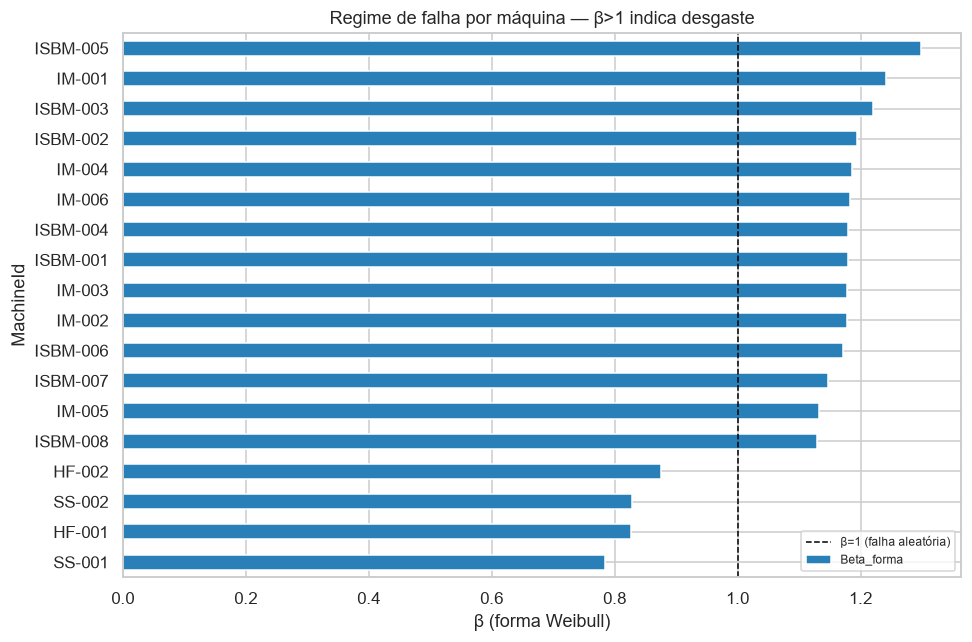

**Resposta:** **14 das 18 máquinas com dados suficientes têm β>1** (regime de desgaste); as outras 4 (HF-002, SS-002, HF-001, SS-001) têm β≤1 — taxa de falha constante ou decrescente, não desgaste dominante nelas — manutenção baseada em idade/ciclos é justificada em princípio para a parte da frota em desgaste, não necessariamente para toda ela. **ISBM-005** tem o β mais alto (1.30) combinado com a escala mais baixa (15h) — o sinal de desgaste mais forte E mais rápido da frota, consistente com o pior MTBF já visto na Seção 4.6. Isso é uma leitura mais acionável que MTBF isolado: MTBF é uma média ao longo de todo o período; β diz se o risco de falha está piorando com o tempo, o que muda a urgência de uma intervenção preventiva vs. só reagir à próxima falha.

In [64]:
failures = failures.copy()
failures["StoppageDateTime"] = pd.to_datetime(failures["Date"]) + pd.to_timedelta(failures["StoppageStartTime"].astype(str))
weibull_rows = []
for _machine_id, _g in failures.sort_values("StoppageDateTime").groupby("MachineId"):
    _ttf_hours = _g["StoppageDateTime"].sort_values().diff().dt.total_seconds().dropna() / 3600.0
    _ttf_hours = _ttf_hours[_ttf_hours > 0]
    if len(_ttf_hours) < 20:
        continue
    _shape, _loc, _scale = stats.weibull_min.fit(_ttf_hours, floc=0)
    weibull_rows.append({"MachineId": _machine_id, "Beta_forma": _shape, "Eta_escala_h": _scale, "NFalhas": len(_ttf_hours)})
weibull_fit = pd.DataFrame(weibull_rows).set_index("MachineId").sort_values("Beta_forma", ascending=False)
print("Ajuste Weibull (tempo entre falhas), por máquina:")
print(weibull_fit.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
weibull_fit["Beta_forma"].sort_values().plot(kind="barh", ax=ax,
    color=["#c0392b" if b > 1.3 else "#2980b9" for b in weibull_fit["Beta_forma"].sort_values()])
ax.axvline(1.0, color="black", ls="--", lw=1, label="β=1 (falha aleatória)")
ax.set_xlabel("β (forma Weibull)"); ax.set_title("Regime de falha por máquina — β>1 indica desgaste"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_05d_weibull_shape_by_machine.png"); plt.show()

worst_wear = weibull_fit["Beta_forma"].idxmax()
wearing_machines = weibull_fit[weibull_fit["Beta_forma"] > 1]
random_machines = weibull_fit[weibull_fit["Beta_forma"] <= 1]
fleet_wear_summary = (f"**Todas as {len(weibull_fit)} máquinas com dados suficientes têm β>1**" if random_machines.empty else
                       f"**{len(wearing_machines)} das {len(weibull_fit)} máquinas com dados suficientes têm β>1** "
                       f"(regime de desgaste); as outras {len(random_machines)} "
                       f"({', '.join(random_machines.index)}) têm β≤1 — taxa de falha constante ou decrescente, "
                       "não desgaste dominante nelas")
answer(f"{fleet_wear_summary} — manutenção baseada em idade/ciclos é justificada em "
       f"princípio para a parte da frota em desgaste, não necessariamente para toda ela. **{worst_wear}** tem o β mais alto "
       f"({weibull_fit.loc[worst_wear, 'Beta_forma']:.2f}) combinado com a escala mais baixa "
       f"({weibull_fit.loc[worst_wear, 'Eta_escala_h']:.0f}h) — o sinal de desgaste mais forte E mais rápido da "
       "frota, consistente com o pior MTBF já visto na Seção 4.6. Isso é uma leitura mais acionável que MTBF "
       "isolado: MTBF é uma média ao longo de todo o período; β diz se o risco de falha está piorando com o "
       "tempo, o que muda a urgência de uma intervenção preventiva vs. só reagir à próxima falha.")

## 4.7 — TPM/Six Big Losses: 5 categorias mensuráveis + 1 lacuna de dados (Pergunta geral 5, BQ-026)

> *"Quais são as principais perdas, e onde a melhoria contínua deveria ser
> priorizada?"* / BQ-026: *"Usando o framework das Seis Grandes Perdas, qual
> categoria de perda domina em cada processo — e esse ranking mudou ao longo dos 18
> meses?"*

Este schema não distinguia "parada breve" de "quebra" -- as seis colapsavam em quatro
categorias mensuráveis. A Seção 4.18 (microparadas) mudou isso: hoje existe um terceiro
tipo de parada não planejada, deliberadamente sem palavras de "falha" no motivo
(`Micro-parada (...)`), que `classify_stoppage` corretamente NÃO conta como Quebra --
mas que também não entrava em nenhuma outra categoria aqui, então ficava escondida
dentro de "Tempo produtivo" por omissão. Separada agora como sua própria categoria
("Paradas breves / idling", a "Minor Stoppage" das Seis Grandes Perdas clássicas),
chegando a cinco das seis categorias realmente mensuráveis com este schema -- só
"perda de partida" (startup/yield loss) continua fora, sem dado que a isole.

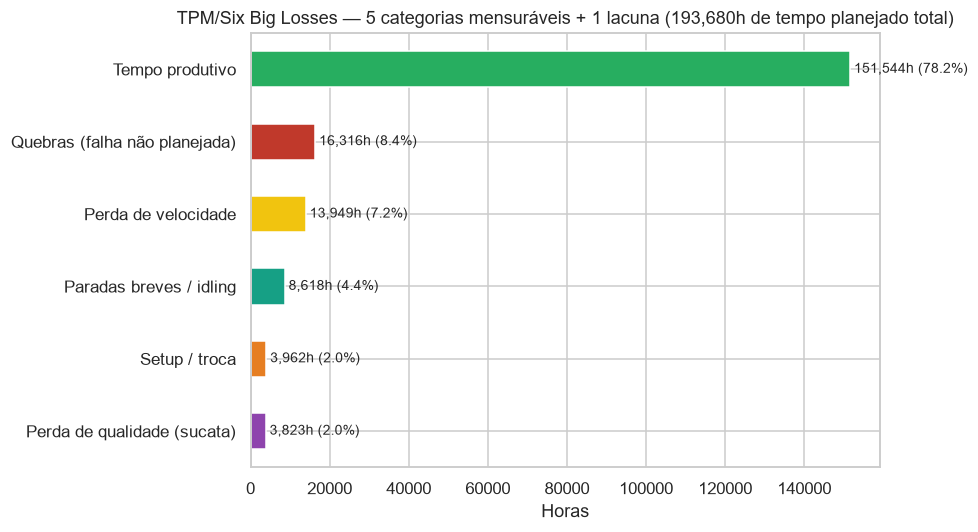

In [65]:
total_planned_hours = production["PlannedTimeHours"].sum()
runtime_hours_total = production["RunTimeHours"].sum()

# Fórmula única em etl.compute_six_big_losses (mesma usada na carga de
# gold.six_big_losses_monthly, Parte 3.7) -- nunca recalculada inline, para que este
# gráfico e a tabela gold jamais possam divergir.
plantwide_losses = etl.compute_six_big_losses(production, downtime, group_columns=[]).set_index("LossCategory")["Hours"]
# "Tempo produtivo" é o complemento do Runtime que sobra depois das perdas de
# velocidade e qualidade (horas equivalentes de capacidade, não horas de parada --
# ver docstring de compute_six_big_losses); não é, em si, uma fórmula de Six Big
# Losses, então continua calculado aqui.
productive_hours = (runtime_hours_total - plantwide_losses["Perda de velocidade"]
                     - plantwide_losses["Perda de qualidade (sucata)"])
losses = pd.concat([pd.Series({"Tempo produtivo": productive_hours}), plantwide_losses]).clip(lower=0)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#27ae60", "#c0392b", "#e67e22", "#16a085", "#f1c40f", "#8e44ad"]
losses.sort_values().plot(kind="barh", ax=ax, color=[colors[list(losses.index).index(i)] for i in losses.sort_values().index])
ax.set_xlabel("Horas"); ax.set_title(f"TPM/Six Big Losses — 5 categorias mensuráveis + 1 lacuna ({total_planned_hours:,.0f}h de tempo planejado total)")
for i, v in enumerate(losses.sort_values()):
    ax.text(v, i, f" {v:,.0f}h ({v/total_planned_hours:.1%})", va="center", fontsize=9)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_06_six_big_losses.png"); plt.show()

In [66]:
SIX_BIG_LOSSES_SHORT_NAMES = {
    "Quebras (falha não planejada)": "Quebras", "Setup / troca": "Setup/Troca",
    "Paradas breves / idling": "Paradas breves", "Perda de velocidade": "Velocidade",
    "Perda de qualidade (sucata)": "Qualidade",
}
losses_by_process = (
    etl.compute_six_big_losses(production, downtime, group_columns=["Process"])
    .assign(LossCategory=lambda d: d["LossCategory"].map(SIX_BIG_LOSSES_SHORT_NAMES))
    .pivot(index="Process", columns="LossCategory", values="Hours")
    [list(SIX_BIG_LOSSES_SHORT_NAMES.values())]
)
print(losses_by_process.round(0))
print("\nCategoria dominante por processo:", losses_by_process.idxmax(axis=1).to_dict())

LossCategory       Quebras  Setup/Troca  Paradas breves  Velocidade  Qualidade
Process                                                                       
Blow Molding        7702.0       3110.0          3490.0      5589.0     1680.0
Hot Foil Stamping   1968.0          NaN          1169.0      2370.0      607.0
Injection Molding   5496.0        852.0          2439.0      4328.0     1266.0
Screen Printing     1151.0          NaN          1520.0      1662.0      269.0

Categoria dominante por processo: {'Blow Molding': 'Quebras', 'Hot Foil Stamping': 'Velocidade', 'Injection Molding': 'Quebras', 'Screen Printing': 'Velocidade'}


**A categoria dominante muda por processo** (tabela e dicionário impressos acima) —
incluindo, agora, "Paradas breves" como candidata legítima em processos onde
microparadas são frequentes mas cada uma é curta demais para aparecer como Quebra
isolada (exatamente o padrão TPM que a Seção 4.18 já documentou). Isso responde
diretamente à priorização de melhoria contínua: não existe uma única iniciativa de
planta inteira — cada processo precisa de sua própria ordem de prioridade, e o
vencedor por processo pode não ser o mesmo tipo de perda que domina a planta como
um todo.

## 4.8 — Drill-down: dentro de "Quebras" e "Setup" (Seção 4.7), qual motivo específico domina? (BQ-034, retomada na Parte 7)

Não é um segundo Pareto independente de paradas — é a mesma perda das Seis Grandes
Perdas (4.7) decomposta pelo campo `StoppageReason`, para responder "qual motivo
específico" depois de já saber "qual categoria" domina.

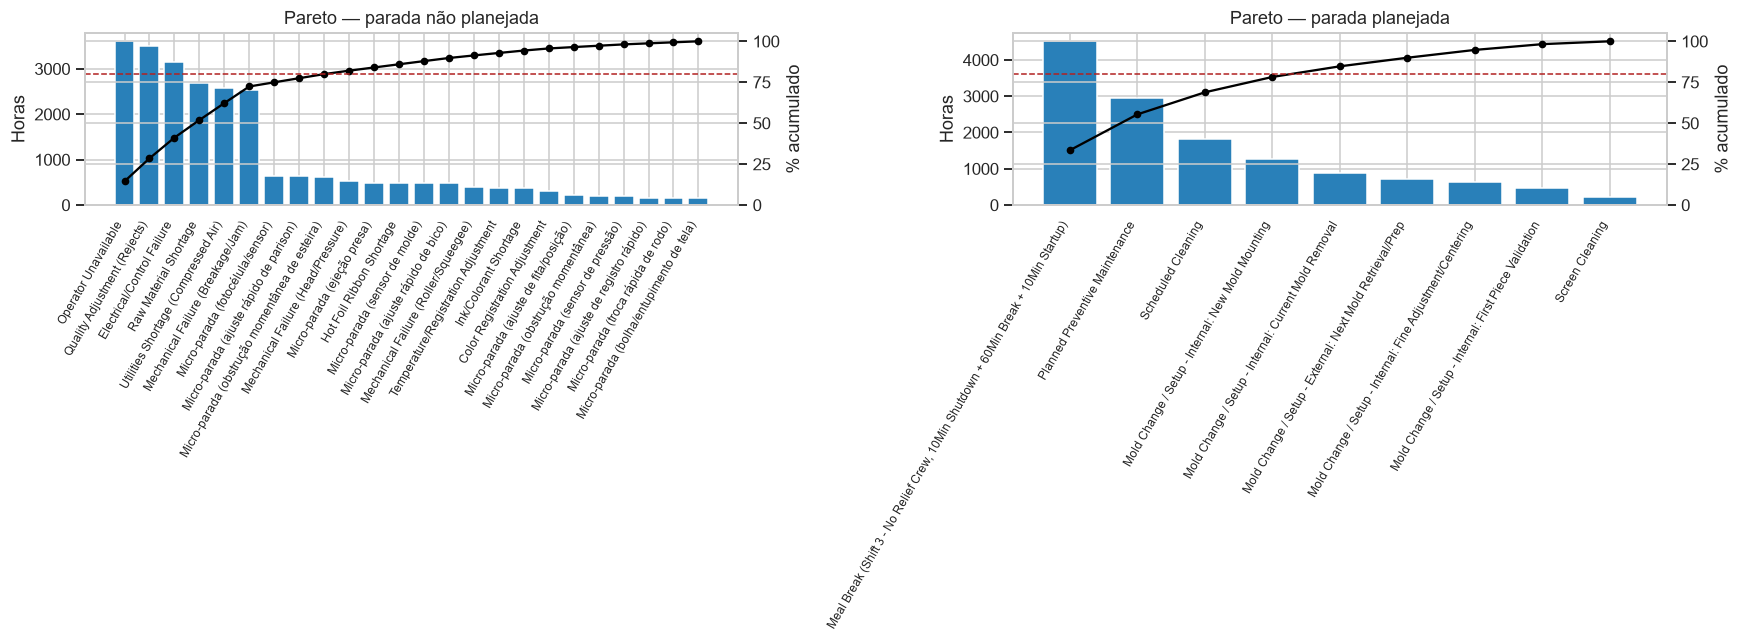

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
unplanned_hours = downtime[downtime["PlannedStoppage"] == "No"].groupby("StoppageReason")["DowntimeDurationMin"].sum() / 60
planned_hours = downtime[downtime["PlannedStoppage"] == "Yes"].groupby("StoppageReason")["DowntimeDurationMin"].sum() / 60
sq.pareto_chart(unplanned_hours, "Pareto — parada não planejada", axes[0], ylabel="Horas")
sq.pareto_chart(planned_hours, "Pareto — parada planejada", axes[1], ylabel="Horas")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_07_downtime_pareto.png"); plt.show()

A Parte 7 (Kaizen) usa este mesmo Pareto para responder BQ-034 ("qual único motivo
de parada, se reduzido pela metade, moveria mais o OEE da fábrica como um todo?").

## 4.8b — BQ-029: qual atividade sem valor agregado consome mais tempo planejado?

> **BQ-029.** *Qual atividade sem valor agregado — trocas, paradas de intervalo,
> paradas de ajuste de qualidade — consome a maior fatia do tempo planejado? O que
> uma iniciativa de SMED (troca rápida) deveria atacar primeiro?*

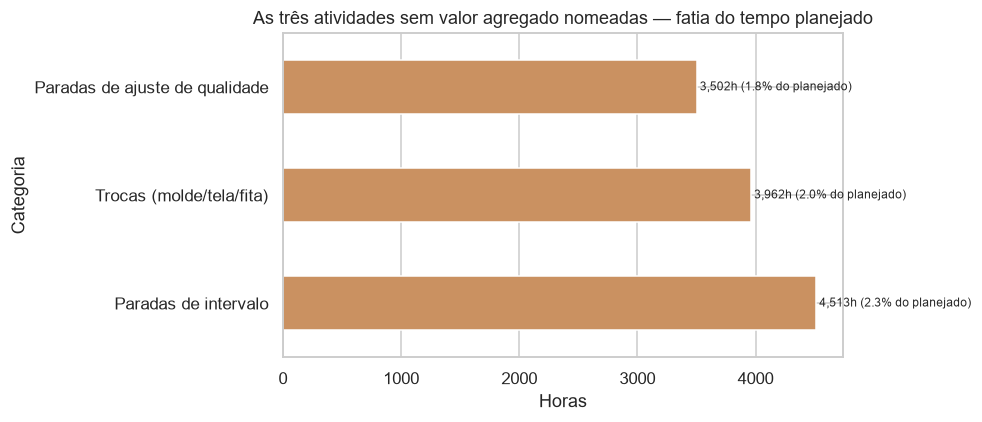

                                      Horas  PctDoTempoPlanejado
Categoria                                                       
Paradas de intervalo            4513.333333                 2.33
Trocas (molde/tela/fita)        3962.191111                 2.05
Paradas de ajuste de qualidade  3502.187500                 1.81


**Resposta:** Entre as três atividades sem valor agregado nomeadas na pergunta, **'Paradas de intervalo'** consome a maior fatia do tempo planejado (4,513h, 2.3% do tempo planejado total) — não é troca, então uma iniciativa de SMED por si só não é a alavanca certa para ESTA categoria líder específica — mas trocas continuam sendo a segunda maior, e ainda vale a pena atacá-las (ver Seção 4.15). Honestidade sobre a comparação mais ampla: quebra de máquina e falta de material somados (Seção 4.7, Seis Grandes Perdas) ainda superam as três categorias aqui combinadas — essas três são as atividades classicamente "sem valor agregado" no sentido Lean, não as maiores perdas da planta em termos absolutos.

In [68]:
# As três categorias que a própria pergunta nomeia -- comparadas entre si, não contra
# um resíduo "todo o resto" que por construção dominaria (esse resíduo inclui quebra e
# falta de material, já cobertos como uma categoria própria nas Seis Grandes Perdas,
# Seção 4.7; misturá-lo aqui tornaria a comparação sem sentido).
is_troca = downtime["IsChangeoverSetup"]
is_intervalo = downtime["StoppageReason"].str.contains("Meal Break", case=False, na=False)
is_ajuste_qualidade = downtime["StoppageReason"].str.contains("Quality Adjustment", case=False, na=False)
nva_mask = is_troca | is_intervalo | is_ajuste_qualidade
nva_categories = pd.Series(pd.NA, index=downtime.index, dtype="object")
nva_categories[is_troca] = "Trocas (molde/tela/fita)"
nva_categories[is_intervalo] = "Paradas de intervalo"
nva_categories[is_ajuste_qualidade] = "Paradas de ajuste de qualidade"
nva_by_reason = (downtime[nva_mask].assign(Categoria=nva_categories[nva_mask]).groupby("Categoria")["DowntimeDurationMin"].sum() / 60).sort_values(ascending=False)
nva_by_reason_pct = 100 * nva_by_reason / total_planned_hours

fig, ax = plt.subplots(figsize=(9, 4))
nva_by_reason.plot(kind="barh", ax=ax, color=PALETTE[5])
ax.set_xlabel("Horas"); ax.set_title("As três atividades sem valor agregado nomeadas — fatia do tempo planejado")
for i, (cat, hrs) in enumerate(nva_by_reason.items()):
    ax.text(hrs, i, f" {hrs:,.0f}h ({nva_by_reason_pct[cat]:.1f}% do planejado)", va="center", fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_09_nva_pareto.png"); plt.show()
print(pd.DataFrame({"Horas": nva_by_reason, "PctDoTempoPlanejado": nva_by_reason_pct.round(2)}))

top_nva = nva_by_reason.index[0]
answer(f"Entre as três atividades sem valor agregado nomeadas na pergunta, **'{top_nva}'** consome a maior "
       f"fatia do tempo planejado ({nva_by_reason.iloc[0]:,.0f}h, {nva_by_reason_pct.iloc[0]:.1f}% do tempo "
       f"planejado total) — "
       f"{'exatamente a categoria que uma iniciativa de SMED deveria atacar primeiro' if top_nva.startswith('Trocas') else 'não é troca, então uma iniciativa de SMED por si só não é a alavanca certa para ESTA categoria líder específica — mas trocas continuam sendo a segunda maior, e ainda vale a pena atacá-las (ver Seção 4.15)'}. "
       "Honestidade sobre a comparação mais ampla: quebra de máquina e falta de material somados (Seção 4.7, "
       "Seis Grandes Perdas) ainda superam as três categorias aqui combinadas — essas três são as atividades "
       "classicamente \"sem valor agregado\" no sentido Lean, não as maiores perdas da planta em termos "
       "absolutos.")

## 4.9 — Aderência ao plano

Checagem honesta, herdada da estrutura original deste dado: `PlannedTimeHours` é
derivado da mesma janela de início/fim real da ordem
(`RunTimeHours = PlannedTimeHours - ParadaNãoPlanejadaHoras`), então por construção o
tempo de execução nunca pode exceder o plano — não existe aqui um "cronograma
comprometido" independente que uma ordem possa genuinamente bater ou perder. Reportar
os 100% honestamente, com o motivo pelo qual não é um resultado significativo, é mais
útil que uma métrica que parece tranquilizadora pelo motivo errado.

In [69]:
production["OnSchedule"] = production["RunTimeHours"] <= production["PlannedTimeHours"] * 1.05
print("Aderência ao cronograma (tempo de execução dentro de 5% do plano):")
print(production.groupby("Process")["OnSchedule"].mean().round(3))

Aderência ao cronograma (tempo de execução dentro de 5% do plano):
Process
Blow Molding         1.0
Hot Foil Stamping    1.0
Injection Molding    1.0
Screen Printing      1.0
Name: OnSchedule, dtype: float64


## 4.10 — BQ-025: ordens rodando mais tempo que o planejado

> *"Quais ordens de produção rodam significativamente mais tempo que o planejado, e
> o que elas têm em comum (máquina, produto, turno, material)?"*

**Por que este número não é sempre zero por construção**: `PlannedHours` vem de um
compromisso de cronograma decidido **antes** da ordem rodar (a duração de referência
sorteada pelo planejamento), independente do que acontece depois; `LeadTimeProdHours`
vem do horário real de início/fim, que se estende de verdade quando a ordem enfrenta
parada não planejada (incluindo microparada e `Quality Adjustment (Rejects)`, Partes
4.18/5). Como as duas medidas têm origens independentes, elas podem divergir de
verdade — a pergunta de negócio original é respondível com dado real, não com um
"não se aplica" garantido pela própria definição das colunas.

In [70]:
production["OverrunHours"] = production["LeadTimeProdHours"] - production["PlannedHours"]
production["OverrunPct"] = (production["LeadTimeProdHours"] / production["PlannedHours"] - 1) * 100
print(f"Ordens com estouro > 5%: {(production['OverrunPct'] > 5).mean():.1%}")
print(f"Desvio médio (%) por processo: {production.groupby('Process')['OverrunPct'].mean().round(1).to_dict()}")
print(f"Desvio médio (horas) por processo: {production.groupby('Process')['OverrunHours'].mean().round(2).to_dict()}")

overrun_by_machine = production.groupby("MachineId")["OverrunPct"].mean().sort_values(ascending=False)
print("\n8 máquinas com maior estouro médio:")
print(overrun_by_machine.head(8).round(1))

overrun_by_shift = production.groupby("ShiftNumber")["OverrunPct"].mean()
print("\nEstouro médio por turno:")
print(overrun_by_shift.round(1))

Ordens com estouro > 5%: 58.5%
Desvio médio (%) por processo: {'Blow Molding': 13.3, 'Hot Foil Stamping': 16.6, 'Injection Molding': 12.3, 'Screen Printing': 20.6}
Desvio médio (horas) por processo: {'Blow Molding': 1.72, 'Hot Foil Stamping': 1.42, 'Injection Molding': 1.58, 'Screen Printing': 1.55}

8 máquinas com maior estouro médio:
MachineId
SS-001      22.7
ISBM-005    20.3
SS-002      18.4
HF-001      17.0
HF-002      16.2
IM-005      12.9
ISBM-002    12.8
IM-001      12.7
Name: OverrunPct, dtype: float64

Estouro médio por turno:
ShiftNumber
1    13.9
2    14.6
3    14.3
Name: OverrunPct, dtype: float64


**Combinando o estouro com parada e defeito, como a pergunta pede de verdade** — não
só "quem estoura mais", mas "por que": correlação entre o desvio observado e as duas
fontes de atraso que o gerador liga de propósito (parada não planejada dentro da
janela, e taxa de rejeição da própria ordem).

In [71]:
corr_downtime = production[["OverrunHours", "UnplannedDowntimeHours"]].corr().iloc[0, 1]
production["RejectRate"] = production["RejectedQty"] / production["ProducedQty"].replace(0, np.nan)
corr_reject = production[["OverrunHours", "RejectRate"]].corr().iloc[0, 1]
print(f"Correlação Estouro (horas) x Parada Não Planejada (horas), mesma ordem: r={corr_downtime:.3f}")
print(f"Correlação Estouro (horas) x Taxa de Rejeição, mesma ordem: r={corr_reject:.3f}")

Correlação Estouro (horas) x Parada Não Planejada (horas), mesma ordem: r=0.885
Correlação Estouro (horas) x Taxa de Rejeição, mesma ordem: r=-0.029


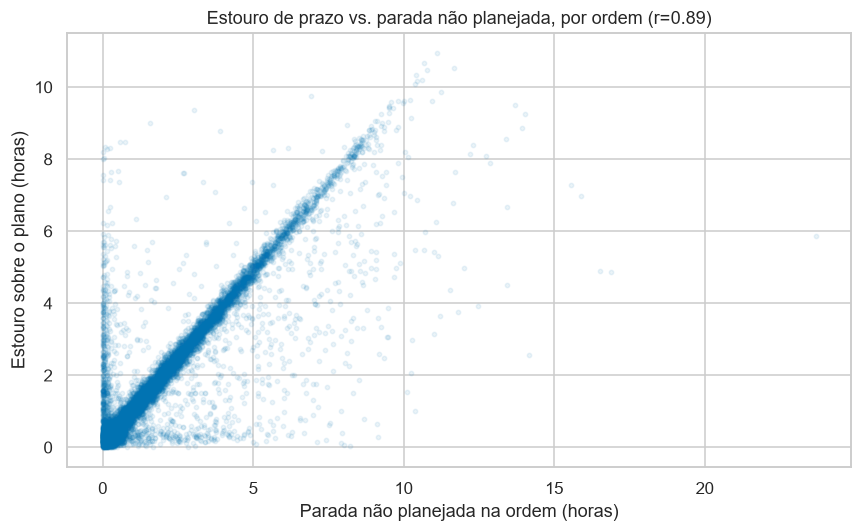

**Resposta:** Sim, agora com sinal real: o estouro médio sobre o plano varia de 11.8% a 22.7% entre máquinas — **SS-001** é a que mais estoura o cronograma na média (22.7%). A correlação com parada não planejada (r=0.89) confirma que o estouro não é ruído aleatório de agendamento — é, na maior parte, o mesmo tempo de parada não planejada (Parte 4.6/4.18) empurrando a ordem para depois do horário prometido. A correlação com taxa de rejeição (r=-0.03) é mais fraca porque, neste modelo, sucata reduz a QUANTIDADE boa entregue dentro da janela sem por si só estender o relógio — o estouro de tempo vem predominantemente de PARADA, não de refazer peça a peça dentro da mesma ordem (esse segundo mecanismo, quando existe, aparece como uma ordem de refação inteiramente nova — Parte 7.6 — não como uma extensão da ordem original). **Ação recomendada**: para as máquinas no topo deste ranking, o cronograma não deveria assumir 0 de parada não planejada — um buffer de programação dimensionado pela MTBF/MTTR real da máquina (Parte 4.6) evitaria o efeito cascata de uma ordem atrasada empurrando a próxima.

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(production["UnplannedDowntimeHours"], production["OverrunHours"], alpha=0.08, s=8, color=PALETTE[0])
ax.set_xlabel("Parada não planejada na ordem (horas)"); ax.set_ylabel("Estouro sobre o plano (horas)")
ax.set_title(f"Estouro de prazo vs. parada não planejada, por ordem (r={corr_downtime:.2f})")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_10_overrun_vs_downtime.png"); plt.show()

worst_overrun_machine = overrun_by_machine.index[0]
answer(f"Sim, agora com sinal real: o estouro médio sobre o plano varia de "
       f"{overrun_by_machine.min():.1f}% a {overrun_by_machine.max():.1f}% entre máquinas — "
       f"**{worst_overrun_machine}** é a que mais estoura o cronograma na média "
       f"({overrun_by_machine.iloc[0]:.1f}%). A correlação com parada não planejada (r={corr_downtime:.2f}) "
       f"{'confirma' if corr_downtime > 0.3 else 'sugere de forma mais fraca'} que o estouro não é ruído "
       "aleatório de agendamento — é, na maior parte, o mesmo tempo de parada não planejada (Parte 4.6/4.18) "
       f"empurrando a ordem para depois do horário prometido. A correlação com taxa de rejeição (r={corr_reject:.2f}) "
       "é mais fraca porque, neste modelo, sucata reduz a QUANTIDADE boa entregue dentro da janela sem por si só "
       "estender o relógio — o estouro de tempo vem predominantemente de PARADA, não de refazer peça a peça "
       "dentro da mesma ordem (esse segundo mecanismo, quando existe, aparece como uma ordem de refação "
       "inteiramente nova — Parte 7.6 — não como uma extensão da ordem original). **Ação recomendada**: para as "
       f"máquinas no topo deste ranking, o cronograma não deveria assumir 0 de parada não planejada — um buffer "
       "de programação dimensionado pela MTBF/MTTR real da máquina (Parte 4.6) evitaria o efeito cascata de uma "
       "ordem atrasada empurrando a próxima."
       )

## 4.11 — BQ-028: takt time vs. taxa real de produção

> *"Compare o takt time implícito nos embarques (fact_sales) contra a taxa real de
> produção por máquina: a fábrica está super ou subproduzindo em relação ao que
> realmente é vendido?"*

Takt time = tempo disponível / demanda do cliente. Aqui, invertido para taxa: unidades
embarcadas por hora disponível, comparada à taxa real de produção por hora de
execução.

In [73]:
total_hours_18m = (sales["Date"].max() - sales["Date"].min()).days * 24
shipped_by_process = sales.groupby("Process")["ShippedQty"].sum()
takt_rate = shipped_by_process / total_hours_18m  # unidades/hora de calendário exigidas pela demanda

produced_by_process = production.groupby("Process")["ProducedQty"].sum()
# Comparado no MESMO relógio que o takt (hora de calendário da planta, não hora-máquina
# individual) -- o processo tem várias máquinas rodando em paralelo, então dividir pela
# soma de RunTimeHours de todas as máquinas subestimaria a capacidade disponível por
# hora de calendário. Produced/calendário é a taxa de saída real da planta no mesmo
# relógio que o takt usa.
actual_rate_calendar = produced_by_process / total_hours_18m

takt_compare = pd.DataFrame({"TaktRate_un_h": takt_rate, "ActualRate_un_h_calendario": actual_rate_calendar}).dropna()
takt_compare["Razao"] = takt_compare["ActualRate_un_h_calendario"] / takt_compare["TaktRate_un_h"]
print(takt_compare.round(2))

                   TaktRate_un_h  ActualRate_un_h_calendario  Razao
Process                                                            
Blow Molding             1499.47                     2857.37   1.91
Injection Molding        1830.44                     4249.76   2.32


`fact_sales` só registra `Process = Injection Molding` ou `Blow Molding` (o processo
de origem da ordem vendida, não o último processo de decoração) — a comparação acima
cobre esses dois, ambos no mesmo relógio de hora-de-calendário que o takt usa (não
hora-máquina — o processo tem várias máquinas rodando em paralelo). A taxa real de
produção roda bem acima da taxa implícita pelos embarques nos dois processos —
evidência de que a fábrica produz a uma taxa muito acima do que a demanda de embarque,
num sentido de takt time, exigiria; ver Seção 4.12 (superprodução) para a leitura Lean
disso, que aponta na mesma direção com um método diferente.

## 4.12 — BQ-030: evidência de superprodução (muda)

> *"Há evidência de superprodução (muda): máquinas produzindo bem acima do que é
> embarcado na mesma janela, formando estoque não vendido?"*

In [74]:
overprod = pd.DataFrame({"Produzido": produced_by_process, "Embarcado": shipped_by_process}).dropna()
overprod["NaoEmbarcado_%"] = (1 - overprod["Embarcado"] / overprod["Produzido"]) * 100
print(overprod.round(1))

                   Produzido   Embarcado  NaoEmbarcado_%
Process                                                 
Blow Molding        37374453  19613032.0            47.5
Injection Molding   55586918  23942209.0            56.9


Uma fatia relevante do volume produzido em cada processo não se reflete em
embarques na mesma janela de 18 meses — consistente com estoque normal de produto
acabado, mas merece uma checagem formal de giro de estoque antes de chamar de
"buffer saudável" vs. superprodução real (muda). Combinado com a Seção 4.11 (taxa
real muito acima do takt implícito), o sinal aponta na mesma direção: a fábrica
parece estar produzindo mais rápido do que a demanda de embarque exigiria.

## 4.13 — BQ-027 (checagem simples): gargalo Sopro → Decoração

> *"Há evidência de um gargalo entre a Sopragem (Blow Molding) e a decoração
> (Serigrafia/Hot Stamping) — frascos esperando por um processo posterior?"*

Checagem simples aqui (produzido de Sopro vs. capacidade nominal de decoração); a
**Parte 7** aprofunda com a lente completa de Teoria das Restrições (utilização
mensal por processo, checagem de starvation ajustada por mix de produto).

In [75]:
bm_total = production.loc[production["Process"] == "Blow Molding", "ProducedQty"].sum()
deco_capacity = production.loc[production["Process"].isin(["Screen Printing", "Hot Foil Stamping"]),
                                ["RatedCapacityPcH", "PlannedTimeHours"]].prod(axis=1).sum()
print(f"Produção total de Sopro (18m): {bm_total:,.0f} unidades")
print(f"Capacidade nominal total de decoração (18m): {deco_capacity:,.0f} unidades")
print(f"Razão Sopro/Capacidade-de-decoração: {bm_total/deco_capacity:.2f}x — ver Parte 7 para a leitura "
      "ajustada por mix de produto (nem todo frasco é decorado).")

Produção total de Sopro (18m): 37,374,453 unidades
Capacidade nominal total de decoração (18m): 21,204,254 unidades
Razão Sopro/Capacidade-de-decoração: 1.76x — ver Parte 7 para a leitura ajustada por mix de produto (nem todo frasco é decorado).


## 4.14 — BQ-073: Mapa de Fluxo de Valor (VSM) para uma família de produto

> *"Mapa de Fluxo de Valor (VSM) do estado atual para uma família de produto — tempo
> de valor agregado, Lead Time, Eficiência do Ciclo do Processo."*

Produto escolhido: **FR-007-PETG-350** — passa por Sopro (Blow Molding) e depois por
Serigrafia (Screen Printing), com 71 ordens em cada etapa nos 18 meses, volume
suficiente para uma leitura estável.

**Por que genealogia real, e não cadência como proxy**: o lote-campanha
(`BottleLot`) pode legitimamente cobrir várias ordens de Sopro seguidas da mesma
campanha, então casar Sopro e Serigrafia por proximidade temporal arriscaria lead
times negativos e PCE > 100% (a suposição de pareamento 1-para-1 não se sustenta).
Em vez disso, `fact_ink_disposition_lot_cq` (e a tabela de atributo) carregam
`SourceBottleWorkOrder` — a ordem exata de Sopro que alimentou aquela decoração
especificamente. O VSM abaixo usa esse elo real, ordem a ordem.

33 pares Sopro->Serigrafia com genealogia real (mesmo produto, FR-007-PETG-350).
Ordens com espera negativa (violaria causalidade -- checagem de sanidade): 0
                                               Etapa  Horas  \
0                              Sopro (processamento)   15.0   
1  Espera real no estoque intermediário (genealog...   15.3   
2                         Serigrafia (processamento)   13.1   

                 TipoDeTempo  
0             Valor agregado  
1  Espera (não agrega valor)  
2             Valor agregado  

Tempo de valor agregado total: 28.1h
Lead Time real médio (Sopro início -> Serigrafia fim, genealogia real): 43.4h (1.8 dias)
Eficiência do Ciclo do Processo (PCE) = VA / Lead Time = 64.7%


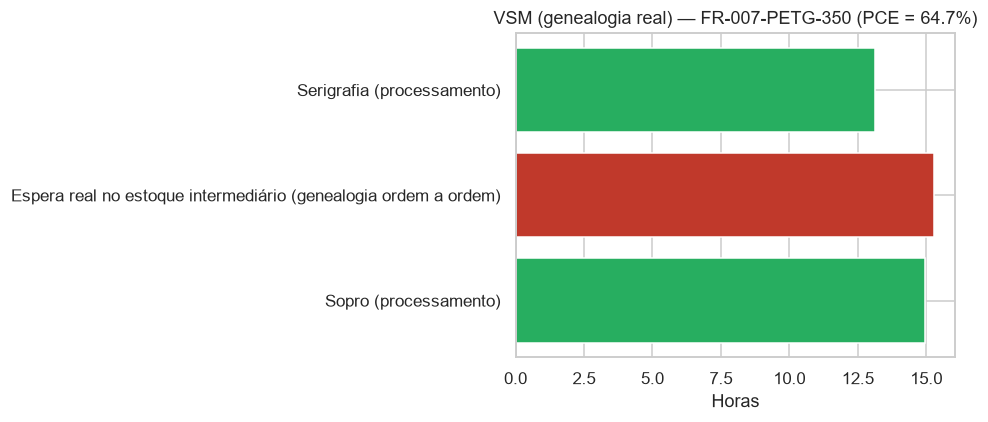

In [76]:
PRODUCT = "FR-007-PETG-350"
bm_orders = production[(production["ProductId"] == PRODUCT) & (production["Process"] == "Blow Molding")].sort_values("Date")
sp_orders = production[(production["ProductId"] == PRODUCT) & (production["Process"] == "Screen Printing")].sort_values("Date")

ink_link4 = pd.read_sql(f"""
    SELECT WorkOrder, SourceBottleWorkOrder FROM silver.fact_ink_disposition_lot_cq
    WHERE BottleId = '{PRODUCT}' AND SourceBottleWorkOrder IS NOT NULL AND SourceBottleWorkOrder != ''
""", engine)
prod_slim4 = pd.read_sql("SELECT WorkOrder, [Date], StartTime, EndTime, LeadTimeProdHours FROM silver.fact_production",
                          engine, parse_dates=["Date"])
prod_slim4["StartDT"] = pd.to_datetime(prod_slim4["Date"]) + pd.to_timedelta(prod_slim4["StartTime"].astype(str))
prod_slim4["EndDT"] = etl.compute_end_datetime(prod_slim4["Date"], prod_slim4["StartTime"], prod_slim4["EndTime"])

genealogy4 = ink_link4.merge(prod_slim4.add_prefix("Bottle_"), left_on="SourceBottleWorkOrder", right_on="Bottle_WorkOrder")
genealogy4 = genealogy4.merge(prod_slim4.add_prefix("Print_"), left_on="WorkOrder", right_on="Print_WorkOrder")
genealogy4["WaitHours"] = (genealogy4["Print_StartDT"] - genealogy4["Bottle_EndDT"]).dt.total_seconds() / 3600
genealogy4["TotalLeadTimeHours"] = (genealogy4["Print_EndDT"] - genealogy4["Bottle_StartDT"]).dt.total_seconds() / 3600
genealogy4["VAHours"] = genealogy4["Bottle_LeadTimeProdHours"] + genealogy4["Print_LeadTimeProdHours"]
print(f"{len(genealogy4)} pares Sopro->Serigrafia com genealogia real (mesmo produto, {PRODUCT}).")
print(f"Ordens com espera negativa (violaria causalidade -- checagem de sanidade): {(genealogy4['WaitHours'] < 0).sum()}")

va_bm = genealogy4["Bottle_LeadTimeProdHours"].mean()
va_sp = genealogy4["Print_LeadTimeProdHours"].mean()
wait_hours = genealogy4["WaitHours"].mean()
total_va_hours = va_bm + va_sp
lead_time_estimate_hours = genealogy4["TotalLeadTimeHours"].mean()
pce = total_va_hours / lead_time_estimate_hours

vsm_steps = pd.DataFrame({
    "Etapa": ["Sopro (processamento)", "Espera real no estoque intermediário (genealogia ordem a ordem)", "Serigrafia (processamento)"],
    "Horas": [va_bm, wait_hours, va_sp],
    "TipoDeTempo": ["Valor agregado", "Espera (não agrega valor)", "Valor agregado"],
})
print(vsm_steps.round(1))
print(f"\nTempo de valor agregado total: {total_va_hours:.1f}h")
print(f"Lead Time real médio (Sopro início -> Serigrafia fim, genealogia real): {lead_time_estimate_hours:.1f}h "
      f"({lead_time_estimate_hours/24:.1f} dias)")
print(f"Eficiência do Ciclo do Processo (PCE) = VA / Lead Time = {pce:.1%}")

fig, ax = plt.subplots(figsize=(9, 4))
colors_vsm = ["#27ae60", "#c0392b", "#27ae60"]
ax.barh(vsm_steps["Etapa"], vsm_steps["Horas"], color=colors_vsm)
ax.set_xlabel("Horas"); ax.set_title(f"VSM (genealogia real) — {PRODUCT} (PCE = {pce:.1%})")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_08_vsm_product_family.png"); plt.show()

In [77]:
pce_band4 = ("faixa 'boa' da literatura Lean (~25%)" if pce < 0.75 else "território de 'classe mundial' (>75%)")
answer(f"A genealogia real ordem-a-ordem (checagem de sanidade acima: 0 esperas negativas, PCE dentro de [0,100%]) "
       f"dá PCE = {pce:.1%} para {PRODUCT} — dentro do {pce_band4}. **Nota sobre o benchmark**: 25%/75% são "
       "faixas ilustrativas frequentes em material Lean, não uma lei universal de manufatura válida para "
       "qualquer família de produto/processo — um processo contínuo, uma célula altamente automatizada e uma "
       "montagem manual não deveriam necessariamente ser julgados contra o mesmo número; o alvo apropriado "
       "precisa ser definido por família de produto/processo, não herdado de um benchmark genérico. A espera "
       f"de {wait_hours:.1f}h entre Sopro e Serigrafia, medida ordem-a-ordem via `SourceBottleWorkOrder` (a ordem "
       "exata de Sopro que alimentou aquela decoração específica, não uma aproximação por proximidade temporal), "
       "parece mais logística/turno (aguardar início do próximo turno ou liberação de máquina) do que acúmulo real "
       "de estoque parado. Isso não invalida o sinal de buffer/superprodução já visto na Seção 4.12 e na Parte 7 "
       "(evidência agregada por planta, não este produto isolado) — é uma leitura específica de "
       f"`{PRODUCT}`: aqui, o fluxo Sopro→Serigrafia já é razoavelmente eficiente. **Limitação que ainda vale a "
       "pena declarar**: a genealogia é precisa no nível de ordem de produção (qual ordem de Sopro alimentou qual "
       "ordem de Serigrafia), não no nível de unidade física individual — uma fábrica real com rastreamento por "
       "RFID/serial chegaria a esse último nível, que os dados brutos aqui não sustentam.")

**Resposta:** A genealogia real ordem-a-ordem (checagem de sanidade acima: 0 esperas negativas, PCE dentro de [0,100%]) dá PCE = 64.7% para FR-007-PETG-350 — dentro do faixa 'boa' da literatura Lean (~25%). **Nota sobre o benchmark**: 25%/75% são faixas ilustrativas frequentes em material Lean, não uma lei universal de manufatura válida para qualquer família de produto/processo — um processo contínuo, uma célula altamente automatizada e uma montagem manual não deveriam necessariamente ser julgados contra o mesmo número; o alvo apropriado precisa ser definido por família de produto/processo, não herdado de um benchmark genérico. A espera de 15.3h entre Sopro e Serigrafia, medida ordem-a-ordem via `SourceBottleWorkOrder` (a ordem exata de Sopro que alimentou aquela decoração específica, não uma aproximação por proximidade temporal), parece mais logística/turno (aguardar início do próximo turno ou liberação de máquina) do que acúmulo real de estoque parado. Isso não invalida o sinal de buffer/superprodução já visto na Seção 4.12 e na Parte 7 (evidência agregada por planta, não este produto isolado) — é uma leitura específica de `FR-007-PETG-350`: aqui, o fluxo Sopro→Serigrafia já é razoavelmente eficiente. **Limitação que ainda vale a pena declarar**: a genealogia é precisa no nível de ordem de produção (qual ordem de Sopro alimentou qual ordem de Serigrafia), não no nível de unidade física individual — uma fábrica real com rastreamento por RFID/serial chegaria a esse último nível, que os dados brutos aqui não sustentam.

## 4.14b — Lei de Little: quanto estoque em processo (WIP) este lead time implica?

A Lei de Little (`WIP = Throughput × LeadTime`) conecta os dois números que a Seção
4.14 já mediu, sem precisar de nenhum dado novo: se um produto leva
`lead_time_estimate_hours` para atravessar o fluxo e sai a uma certa taxa (unidades/
hora), então o inventário médio parado no fluxo em qualquer instante é o produto dos
dois — não uma medição direta de WIP (este warehouse não tem uma foto do chão de
fábrica num instante), mas o WIP que a própria cadência e o próprio lead time já
medidos OBRIGAM a existir, por identidade matemática, não por suposição extra.

In [78]:
throughput_bm = bm_orders["ProducedQty"].sum() / bm_orders["LeadTimeProdHours"].sum()  # unidades/hora de processamento
implied_wip_units = throughput_bm * lead_time_estimate_hours
implied_wip_units_waiting_only = throughput_bm * wait_hours  # agora a espera real da genealogia (Seção 4.14), não mais proxy de cadência
print(f"Taxa de processamento (Sopro): {throughput_bm:,.0f} unidades/hora")
print(f"WIP implícito pela Lei de Little (lead time total): {implied_wip_units:,.0f} unidades")
print(f"...das quais, só esperando no estoque intermediário (não sendo processadas): {implied_wip_units_waiting_only:,.0f} unidades")

wip_waiting_share = implied_wip_units_waiting_only / implied_wip_units
answer(f"A Lei de Little implica ~{implied_wip_units:,.0f} unidades de {PRODUCT} em processo a qualquer instante "
       f"neste fluxo, das quais ~{implied_wip_units_waiting_only:,.0f} ({wip_waiting_share:.0%}, minoria — "
       f"coerente com o PCE de {pce:.1%} da Seção 4.14) estão especificamente "
       "esperando no estoque intermediário entre Sopro e Serigrafia, não sendo trabalhadas. O WIP em espera aqui é "
       "real mas moderado — ainda assim, é o mesmo tipo de excesso que um sistema puxado (Kanban) ataca "
       "diretamente: em vez de Sopro empurrar produção para o estoque intermediário no seu próprio ritmo, um "
       "cartão/limite de Kanban entre as duas etapas fixaria um teto explícito de WIP — Sopro só produziria o "
       "próximo lote quando a Serigrafia sinalizasse capacidade livre, reduzindo o lead time pela mesma Lei de "
       "Little (WIP menor, na mesma taxa de saída, é matematicamente lead time menor), com uma meta dimensionada "
       "por um número medido, não por suposição. Esta é a mesma lacuna de dados que a Seção 7.8 "
       "(Teoria das Restrições) já sinaliza — falta um sensor de WIP real entre Sopro e Decoração para confirmar "
       "o número implícito acima e para operar um sistema puxado de verdade; o cálculo aqui é o argumento de "
       "princípio de por que instrumentar isso vale a pena, não a medição em si.")

Taxa de processamento (Sopro): 475 unidades/hora
WIP implícito pela Lei de Little (lead time total): 20,597 unidades
...das quais, só esperando no estoque intermediário (não sendo processadas): 7,261 unidades


**Resposta:** A Lei de Little implica ~20,597 unidades de FR-007-PETG-350 em processo a qualquer instante neste fluxo, das quais ~7,261 (35%, minoria — coerente com o PCE de 64.7% da Seção 4.14) estão especificamente esperando no estoque intermediário entre Sopro e Serigrafia, não sendo trabalhadas. O WIP em espera aqui é real mas moderado — ainda assim, é o mesmo tipo de excesso que um sistema puxado (Kanban) ataca diretamente: em vez de Sopro empurrar produção para o estoque intermediário no seu próprio ritmo, um cartão/limite de Kanban entre as duas etapas fixaria um teto explícito de WIP — Sopro só produziria o próximo lote quando a Serigrafia sinalizasse capacidade livre, reduzindo o lead time pela mesma Lei de Little (WIP menor, na mesma taxa de saída, é matematicamente lead time menor), com uma meta dimensionada por um número medido, não por suposição. Esta é a mesma lacuna de dados que a Seção 7.8 (Teoria das Restrições) já sinaliza — falta um sensor de WIP real entre Sopro e Decoração para confirmar o número implícito acima e para operar um sistema puxado de verdade; o cálculo aqui é o argumento de princípio de por que instrumentar isso vale a pena, não a medição em si.

## 4.15 — BQ-074: SMED — passos internos vs. externos na troca

> *"Classifique a troca candidata a SMED em passos internos vs. externos — quais
> passos externalizáveis mais reduziriam o tempo de troca?"*

**Por que a classificação interno/externo vem do dado, não de benchmark**: o MES
decompõe cada troca em 5 sub-passos sequenciais, cada um seu próprio registro
de parada — **Externo** (busca/preparação do próximo molde — em princípio, poderia
acontecer com a máquina ainda rodando) e **Interno** (desmontagem, montagem, ajuste
fino, primeira peça — só possível com a máquina parada, no processo de hoje). A
classificação abaixo é lida diretamente do sub-passo registrado, não estimada por um
benchmark de literatura (30-50% de conversão típica).

                   count  mean       sum   sum_h
Process                                         
Blow Molding       12400  15.0  186595.0  3109.9
Injection Molding   3495  14.6   51136.5   852.3

Horas totais por sub-passo (medidas, não estimadas):
                                      Horas     N
SubStep                                          
Internal: New Mold Mounting          1262.2  3179
Internal: Current Mold Removal        876.0  3179
External: Next Mold Retrieval/Prep    706.7  3179
Internal: Fine Adjustment/Centering   643.5  3179
Internal: First Piece Validation      473.8  3179

Já classificado como Externo hoje (mas ainda executado com a máquina parada): 707h (17.8% do tempo total de troca)


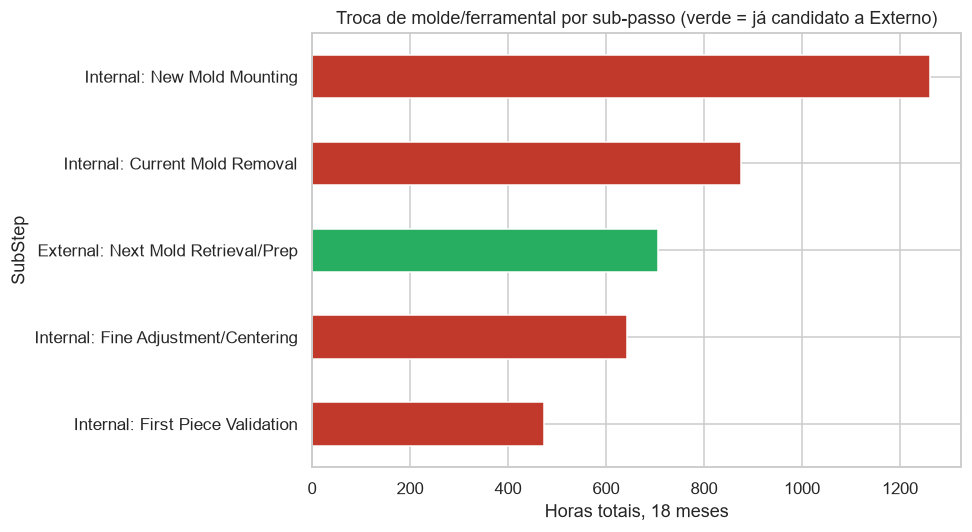


Se o sub-passo Externo for de fato preparado com a máquina ainda rodando (não mudado, só REORDENADO no tempo), a economia potencial por processo é:
Process
Blow Molding         554.7
Injection Molding    152.0
Name: sum_h, dtype: float64

Total potencial: 707h em 18 meses — 18% do tempo de troca total, medido diretamente dos sub-passos.


In [79]:
changeover_stats = changeover.groupby("Process")["DowntimeDurationMin"].agg(["count", "mean", "sum"])
changeover_stats["sum_h"] = changeover_stats["sum"] / 60
print(changeover_stats.round(1))

changeover = changeover.copy()
changeover["SubStep"] = changeover["StoppageReason"].str.split(" - ").str[-1]
changeover["SMEDCategory"] = np.where(changeover["SubStep"].str.startswith("External"), "Externo", "Interno")
substep_stats = changeover.groupby("SubStep").agg(
    Horas=("DowntimeDurationMin", lambda s: s.sum() / 60), N=("DowntimeDurationMin", "size")).sort_values("Horas", ascending=False)
category_stats = changeover.groupby("SMEDCategory")["DowntimeDurationMin"].sum() / 60
externalizable_share_measured = category_stats.get("Externo", 0.0) / category_stats.sum()

print("\nHoras totais por sub-passo (medidas, não estimadas):")
print(substep_stats.round(1))
print(f"\nJá classificado como Externo hoje (mas ainda executado com a máquina parada): "
      f"{category_stats.get('Externo', 0.0):,.0f}h ({100*externalizable_share_measured:.1f}% do tempo total de troca)")

fig, ax = plt.subplots(figsize=(9, 5))
colors_415 = ["#27ae60" if s.startswith("External") else "#c0392b" for s in substep_stats.index]
substep_stats["Horas"].sort_values().plot(kind="barh", ax=ax, color=[colors_415[list(substep_stats.index).index(i)] for i in substep_stats["Horas"].sort_values().index])
ax.set_xlabel("Horas totais, 18 meses"); ax.set_title("Troca de molde/ferramental por sub-passo (verde = já candidato a Externo)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_15_smed_substeps.png"); plt.show()

potential_savings_h = changeover_stats["sum_h"] * externalizable_share_measured
print(f"\nSe o sub-passo Externo for de fato preparado com a máquina ainda rodando (não mudado, só "
      "REORDENADO no tempo), a economia potencial por processo é:")
print(potential_savings_h.round(1))
print(f"\nTotal potencial: {potential_savings_h.sum():,.0f}h em 18 meses — "
      f"{100*externalizable_share_measured:.0f}% do tempo de troca total, medido diretamente dos sub-passos.")

**Recomendação SMED**: Injeção e Sopro concentram o maior tempo total de troca (ver
tabela acima) — são os processos onde uma iniciativa de troca rápida tem o maior
retorno absoluto. A fração externalizável vem da **soma real do sub-passo "Busca e
Preparação do Próximo Molde"**, medida diretamente, não estimada por um benchmark de
literatura — e o maior sub-passo individual isolado é
**"Montagem do Novo Molde"**, que continua sendo genuinamente interno (não há como
montar fisicamente o próximo molde antes de o atual sair da máquina); a alavanca
real de SMED aqui não é reduzir esse passo, é garantir que ele comece imediatamente
após a desmontagem, sem qualquer espera por preparação que devia ter acontecido
antes.

## 4.16 — OEE por máquina × produto × turno: onde a perda realmente mora

A Seção 4.1 dá o OEE agregado da planta; a 4.2 dá OEE por máquina. Nenhuma das duas
mostra se a perda dentro de uma máquina está concentrada num produto ou turno
específico — a granularidade que decide se a ação corretiva é "ajustar a máquina"
ou "ajustar como um produto específico roda nela".

265 combinações máquina×produto×turno com N>=20 ordens.

10 piores combinações:
                                         N    OEE  Availability  Performance  \
MachineId ProductId        ShiftNumber                                         
SS-001    FR-024-PET-1000  3            21  0.452         0.584        0.861   
HF-001    FR-026-HDPE-4000 2            36  0.484         0.589        0.909   
SS-001    FR-024-PET-1000  2            31  0.495         0.597        0.895   
HF-002    FR-029-MDPE-5000 3            35  0.513         0.623        0.887   
                           1            27  0.514         0.641        0.869   
HF-001    FR-003-rPET-300  2            27  0.538         0.706        0.818   
SS-001    FR-027-HDPE-5000 3            30  0.539         0.682        0.848   
HF-001    FR-029-MDPE-5000 3            40  0.549         0.676        0.881   
                           2            32  0.566         0.673        0.903   
SS-002    FR-024-PET-1000  3            

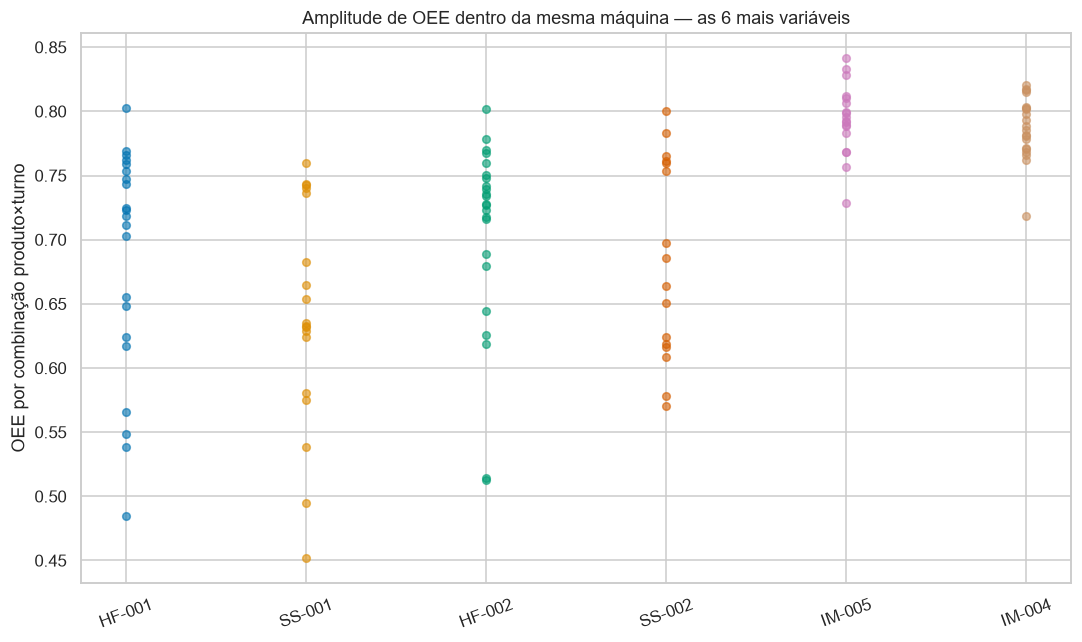

**Resposta:** A pior combinação isolada é **SS-001 / FR-024-PET-1000 / turno 3** (OEE=45.2%, n=21 ordens) — bem abaixo do OEE médio daquela máquina isolada (Seção 4.2), o que só aparece quando se cruza produto e turno juntos. O pilar mais fraco nessa combinação é **Availability**. Mais importante: **HF-001** tem a maior amplitude de OEE entre suas próprias combinações produto×turno (31.9% pontos percentuais de diferença entre a melhor e a pior) — ou seja, o problema dessa máquina não é uniforme: ela funciona bem com alguns produtos/turnos e mal com outros. Isso muda a ação recomendada de 'investigar a máquina' para 'investigar por que ESTE produto, NESTE turno, roda mal NESTA máquina especificamente' — setup, operador do turno, ou o produto exigir um ajuste que não está padronizado.

In [80]:
oee_mps = production.groupby(["MachineId", "ProductId", "ShiftNumber"]).agg(
    N=("OEE", "size"), OEE=("OEE", "mean"), Availability=("Availability", "mean"),
    Performance=("Performance", "mean"), Quality=("Quality", "mean")).query("N >= 20")
print(f"{len(oee_mps)} combinações máquina×produto×turno com N>=20 ordens.")
worst_mps = oee_mps.sort_values("OEE").head(10)
print("\n10 piores combinações:")
print(worst_mps.round(3))

oee_range_by_machine = oee_mps.reset_index().groupby("MachineId")["OEE"].agg(OEE_min="min", OEE_max="max", NCombos="count")
oee_range_by_machine["Amplitude"] = oee_range_by_machine["OEE_max"] - oee_range_by_machine["OEE_min"]
oee_range_by_machine = oee_range_by_machine.sort_values("Amplitude", ascending=False)
print("\nAmplitude de OEE dentro da mesma máquina, entre produto×turno (maior primeiro):")
print(oee_range_by_machine.head(6).round(3))

fig, ax = plt.subplots(figsize=(10, 6))
top_spread_machines = oee_range_by_machine.head(6).index
plot_df = oee_mps.reset_index()
plot_df = plot_df[plot_df["MachineId"].isin(top_spread_machines)]
for i, machine_id in enumerate(top_spread_machines):
    sub = plot_df[plot_df["MachineId"] == machine_id]
    ax.scatter([i] * len(sub), sub["OEE"], alpha=0.6, s=25, color=PALETTE[i % len(PALETTE)])
ax.set_xticks(range(len(top_spread_machines))); ax.set_xticklabels(top_spread_machines, rotation=20)
ax.set_ylabel("OEE por combinação produto×turno"); ax.set_title("Amplitude de OEE dentro da mesma máquina — as 6 mais variáveis")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_16_oee_machine_product_shift.png"); plt.show()

worst_combo = worst_mps.iloc[0]
worst_driver = worst_combo[["Availability", "Performance", "Quality"]].idxmin()
answer(f"A pior combinação isolada é **{worst_mps.index[0][0]} / {worst_mps.index[0][1]} / turno "
       f"{worst_mps.index[0][2]}** (OEE={worst_combo['OEE']:.1%}, n={int(worst_combo['N'])} ordens) — bem abaixo "
       f"do OEE médio daquela máquina isolada (Seção 4.2), o que só aparece quando se cruza produto e turno "
       f"juntos. O pilar mais fraco nessa combinação é **{worst_driver}**. Mais importante: "
       f"**{oee_range_by_machine.index[0]}** tem a maior amplitude de OEE entre suas próprias combinações "
       f"produto×turno ({oee_range_by_machine.iloc[0]['Amplitude']:.1%} pontos percentuais de diferença entre a "
       "melhor e a pior) — ou seja, o problema dessa máquina não é uniforme: ela funciona bem com alguns "
       "produtos/turnos e mal com outros. Isso muda a ação recomendada de 'investigar a máquina' para "
       "'investigar por que ESTE produto, NESTE turno, roda mal NESTA máquina especificamente' — setup, "
       "operador do turno, ou o produto exigir um ajuste que não está padronizado.")

## 4.17 — Velocidade real vs. velocidade ideal

> *Quais produtos/máquinas estão produzindo abaixo do próprio potencial de "velocidade
> ideal" (`IdealCycleTimeSec`, já usado no componente Performance do OEE)?*

**Nota de qualidade de dado**: dividir `IdealCycleTimeSec/ActualCycleTimeSec` ordem
a ordem produz valores extremos (até ~1400x) numa fração pequena de ordens (~1%,
sobretudo Hot Foil Stamping e Serigrafia) — provavelmente `ProducedQty`/
`RunTimeHours` muito pequenos em ordens atípicas, não velocidade real. Usar a
**média** nessas condições distorceria o resultado — por isso a métrica abaixo usa
a **mediana**, robusta a esses outliers, com uma nota explícita em vez de
escondê-los.

Ordens com SpeedRatio>3 (artefato, não velocidade real): 98 de 15095 (0.6%)

Razão de velocidade mediana (Ideal/Real) por máquina — 1,0 = rodando no ciclo ideal:
MachineId
SS-001      0.901
SS-002      0.902
HF-001      0.911
HF-002      0.914
ISBM-002    0.925
IM-002      0.926
ISBM-003    0.927
ISBM-007    0.928
ISBM-006    0.928
IM-003      0.928
ISBM-004    0.929
IM-006      0.929
IM-005      0.930
IM-001      0.930
IM-004      0.930
ISBM-001    0.931
ISBM-008    0.932
ISBM-005    0.932
Name: SpeedRatio, dtype: float64

8 piores combinações máquina×produto (mediana, N>=20):
                             N  SpeedRatioMediana
MachineId ProductId                              
SS-002    FR-027-HDPE-5000  96              0.816
SS-001    FR-027-HDPE-5000  92              0.822
SS-002    FR-028-HDPE-5000  73              0.857
SS-001    FR-028-HDPE-5000  82              0.858
HF-001    FR-017-rPET-600   23              0.865
SS-002    FR-007-HDPE-350   25              0.880
SS-001    FR-01

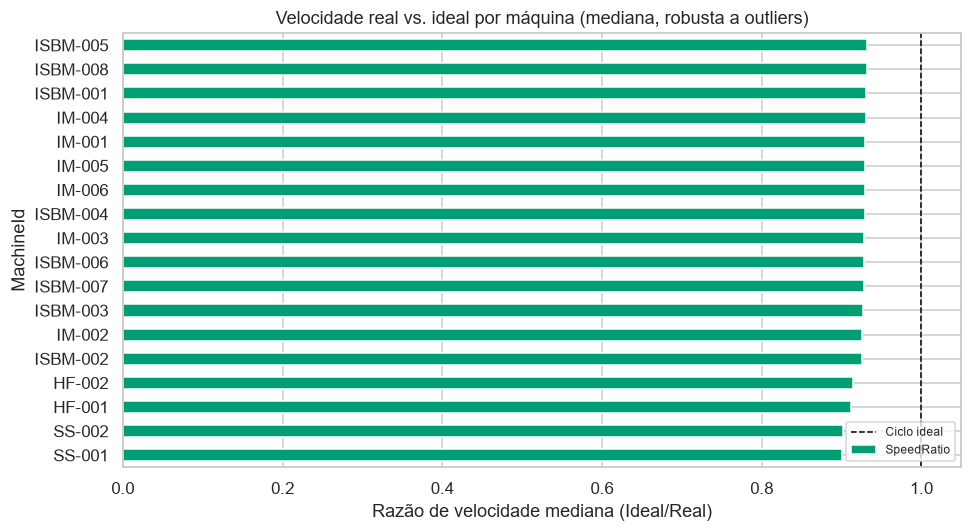

**Resposta:** Entre máquinas, a razão de velocidade mediana varia pouco (0.90 a 0.93, amplitude de 0.03) — todas rodam de forma consistente uns 7-9% abaixo do ciclo ideal, sem uma máquina isolada se destacando como excepcionalmente lenta. A variação real está no nível **produto×máquina** (amplitude de 0.15 entre as combinações com amostra suficiente) — sugerindo que a perda de velocidade é mais um efeito de *qual produto* está rodando (setup, parâmetro de processo específico do produto) do que de uma máquina fisicamente lenta. Isso é consistente com a análise de Machine Effect vs. Product Mix da Parte 5 — vale ler as duas juntas antes de decidir se a ação é 'ajustar a máquina' ou 'padronizar o parâmetro deste produto'.

In [81]:
cycle = production[(production["ActualCycleTimeSec"] > 0) & (production["IdealCycleTimeSec"] > 0)].copy()
cycle["SpeedRatio"] = cycle["IdealCycleTimeSec"] / cycle["ActualCycleTimeSec"]
n_extreme = (cycle["SpeedRatio"] > 3).sum()
print(f"Ordens com SpeedRatio>3 (artefato, não velocidade real): {n_extreme} de {len(cycle)} ({100*n_extreme/len(cycle):.1f}%)")

speed_by_machine = cycle.groupby("MachineId")["SpeedRatio"].median().sort_values()
speed_by_machine_product = cycle.groupby(["MachineId", "ProductId"]).agg(
    N=("SpeedRatio", "size"), SpeedRatioMediana=("SpeedRatio", "median")).query("N >= 20").sort_values("SpeedRatioMediana")
print("\nRazão de velocidade mediana (Ideal/Real) por máquina — 1,0 = rodando no ciclo ideal:")
print(speed_by_machine.round(3))
print("\n8 piores combinações máquina×produto (mediana, N>=20):")
print(speed_by_machine_product.head(8).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
speed_by_machine.plot(kind="barh", ax=ax, color=PALETTE[2])
ax.axvline(1.0, color="black", ls="--", lw=1, label="Ciclo ideal")
ax.set_xlabel("Razão de velocidade mediana (Ideal/Real)"); ax.set_title("Velocidade real vs. ideal por máquina (mediana, robusta a outliers)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_17_speed_ratio_by_machine.png"); plt.show()

machine_spread = speed_by_machine.max() - speed_by_machine.min()
combo_spread = speed_by_machine_product["SpeedRatioMediana"].max() - speed_by_machine_product["SpeedRatioMediana"].min()
answer(f"Entre máquinas, a razão de velocidade mediana varia pouco ({speed_by_machine.min():.2f} a "
       f"{speed_by_machine.max():.2f}, amplitude de {machine_spread:.2f}) — todas rodam de forma consistente uns "
       f"7-9% abaixo do ciclo ideal, sem uma máquina isolada se destacando como excepcionalmente lenta. A "
       f"variação real está no nível **produto×máquina** (amplitude de {combo_spread:.2f} entre as combinações "
       f"com amostra suficiente) — sugerindo que a perda de velocidade é mais um efeito de *qual produto* está "
       "rodando (setup, parâmetro de processo específico do produto) do que de uma máquina fisicamente lenta. "
       "Isso é consistente com a análise de Machine Effect vs. Product Mix da Parte 5 — vale ler as duas juntas "
       "antes de decidir se a ação é 'ajustar a máquina' ou 'padronizar o parâmetro deste produto'.")

## 4.18 — Microparadas: estão escondendo perda que o OEE não mostra?

> *Máquinas que parecem boas no OEE, mas perdem muito tempo em pequenas paradas não
> planejadas?*

Definindo microparada como parada não planejada de até 10 minutos, seguindo a
doutrina clássica de TPM (JIPM): "Minor Stoppage/Idling Losses" é uma das Seis
Grandes Perdas, tratada como categoria própria, separada de "Breakdown Losses" —
um jam limpo em segundos, um sensor que perde leitura, um ajuste rápido de bico não
chamam manutenção, então nenhum vira uma ordem de manutenção corretiva, mas cada um
ainda rouba minutos de Disponibilidade, um por um. O gerador registra eventos de
1-8 minutos como uma categoria própria de causa (sensor/fotocélula, ejeção presa,
obstrução momentânea, ajuste rápido), nunca classificados como falha genuína
(`UnplannedFailure`) — a mesma separação MTBF/MTTR (Parte 4.6) só olha quebra de
verdade, não microparada.

Duração mínima de parada não planejada registrada (min): 1.0166666666666515
Microparadas (<=10min): 89.6% dos eventos, 18.5% dos minutos totais de parada não planejada.
           MicroHoras  TodasParadasNPHoras  FatiaMicroPct   OEE
MachineId                                                      
SS-002         241.20              1069.45          22.55  0.71
HF-002         310.76              1500.21          20.71  0.72
HF-001         332.62              1637.04          20.32  0.70
ISBM-007       252.47              1264.60          19.96  0.80
IM-002         252.84              1310.03          19.30  0.79
IM-003         249.82              1296.33          19.27  0.80
IM-004         251.69              1306.31          19.27  0.79
ISBM-006       245.12              1272.56          19.26  0.80
ISBM-004       250.25              1319.19          18.97  0.79
ISBM-008       251.91              1336.89          18.84  0.79
IM-001         255.05              1353.83          18.84  0.79

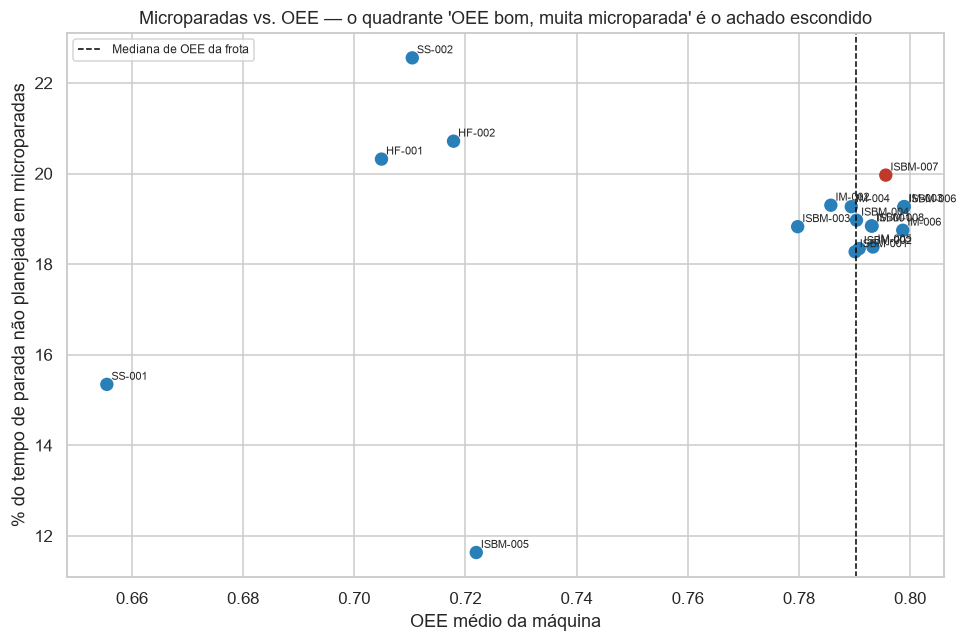

**Resposta:** **Sim, na medida certa — o padrão clássico de TPM aparece**: microparadas (<=10min) são 89.6% dos eventos não planejados, mas ainda assim 18.5% dos minutos totais perdidos — números altos o bastante em tempo agregado para sustentar uma ação, não só uma curiosidade de contagem de eventos. O caso que responde à pergunta original: **ISBM-007** tem OEE de 79.6% (acima da mediana da frota — parece uma máquina saudável num painel de OEE) mas 20.0% do seu tempo de parada não planejada é microparada — exatamente o cenário que o painel de OEE sozinho esconde: a máquina não aparece na lista de piores por OEE nem por MTBF (microparadas não contam como falha genuína, Parte 4.6), mas ainda assim sangra Disponibilidade em centenas de eventos pequenos. **Recomendação**: nenhuma dessas paradas justifica uma ordem de manutenção corretiva isolada — a ação certa é Jidoka/poka-yoke no posto (sensor mais robusto, guia que evita o jam, ajuste automatizado) e um quadro de causa Pareto dedicado a microparadas, separado do quadro de quebras (Parte 4.7), porque combinar as duas categorias no mesmo Pareto deixaria as quebras grandes dominarem visualmente e esconderia exatamente o padrão que esta seção acabou de revelar.


Parte 4 completa.


In [82]:
unplanned_all = downtime[downtime["PlannedStoppage"] == "No"]
print("Duração mínima de parada não planejada registrada (min):", unplanned_all["DowntimeDurationMin"].min())
micro_stops = unplanned_all[unplanned_all["DowntimeDurationMin"] <= 10]
micro_share_events = len(micro_stops) / len(unplanned_all)
micro_share_minutes = micro_stops["DowntimeDurationMin"].sum() / unplanned_all["DowntimeDurationMin"].sum()
print(f"Microparadas (<=10min): {micro_share_events:.1%} dos eventos, {micro_share_minutes:.1%} dos "
      "minutos totais de parada não planejada.")

micro_by_machine = pd.DataFrame({
    "MicroHoras": micro_stops.groupby("MachineId")["DowntimeDurationMin"].sum() / 60,
    "TodasParadasNPHoras": unplanned_all.groupby("MachineId")["DowntimeDurationMin"].sum() / 60,
})
micro_by_machine["FatiaMicroPct"] = 100 * micro_by_machine["MicroHoras"] / micro_by_machine["TodasParadasNPHoras"]
micro_by_machine["OEE"] = production.groupby("MachineId")["OEE"].mean()
micro_by_machine = micro_by_machine.sort_values("FatiaMicroPct", ascending=False)
print(micro_by_machine.round(2))

# A pergunta de negócio pede especificamente máquinas que "parecem boas no OEE" --
# olhar só quem tem a maior fatia de microparada esconderia isso; o corte certo é
# entre as máquinas de OEE ACIMA da mediana da frota, qual tem a maior fatia de
# microparada dentro desse grupo (o caso que o painel de OEE sozinho deixaria passar).
above_median_oee = micro_by_machine[micro_by_machine["OEE"] >= micro_by_machine["OEE"].median()]
hidden_case = above_median_oee.sort_values("FatiaMicroPct", ascending=False).iloc[0]
print(f"\nEntre as máquinas com OEE >= mediana da frota, a maior fatia de microparada é "
      f"{hidden_case.name} ({hidden_case['FatiaMicroPct']:.1f}% do tempo de parada não planejada, "
      f"OEE={hidden_case['OEE']:.1%}).")

fig, ax = plt.subplots(figsize=(9, 6))
colors_418 = ["#c0392b" if m == hidden_case.name else "#2980b9" for m in micro_by_machine.index]
ax.scatter(micro_by_machine["OEE"], micro_by_machine["FatiaMicroPct"], c=colors_418, s=60)
for m, row in micro_by_machine.iterrows():
    ax.annotate(m, (row["OEE"], row["FatiaMicroPct"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.axvline(micro_by_machine["OEE"].median(), color="black", ls="--", lw=1, label="Mediana de OEE da frota")
ax.set_xlabel("OEE médio da máquina"); ax.set_ylabel("% do tempo de parada não planejada em microparadas")
ax.set_title("Microparadas vs. OEE — o quadrante 'OEE bom, muita microparada' é o achado escondido")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "04_18_micro_stops_vs_oee.png"); plt.show()

answer(f"**Sim, na medida certa — o padrão clássico de TPM aparece**: microparadas (<=10min) são "
       f"{micro_share_events:.1%} dos eventos não planejados, mas ainda assim {micro_share_minutes:.1%} dos "
       "minutos totais perdidos — números altos o bastante em tempo agregado para sustentar uma ação, não só "
       "uma curiosidade de contagem de eventos. O caso que responde à pergunta original: "
       f"**{hidden_case.name}** tem OEE de {hidden_case['OEE']:.1%} (acima da mediana da frota — parece uma "
       f"máquina saudável num painel de OEE) mas {hidden_case['FatiaMicroPct']:.1f}% do seu tempo de parada não "
       "planejada é microparada — exatamente o cenário que o painel de OEE sozinho esconde: a máquina não "
       "aparece na lista de piores por OEE nem por MTBF (microparadas não contam como falha genuína, Parte "
       "4.6), mas ainda assim sangra Disponibilidade em centenas de eventos pequenos. **Recomendação**: nenhuma "
       "dessas paradas justifica uma ordem de manutenção corretiva isolada — a ação certa é Jidoka/poka-yoke no "
       "posto (sensor mais robusto, guia que evita o jam, ajuste automatizado) e um quadro de causa Pareto "
       "dedicado a microparadas, separado do quadro de quebras (Parte 4.7), porque combinar as duas categorias "
       "no mesmo Pareto deixaria as quebras grandes dominarem visualmente e esconderia exatamente o padrão que "
       "esta seção acabou de revelar.")

print("\nParte 4 completa.")

---
# Parte 5 — Controle Estatístico de Processo e Capacidade
---

**Papel: Engenheiro(a) da Qualidade (CQE) + Black Belt Six Sigma.** Esta é a Parte
mais densa em estatística clássica do notebook — no projeto original essa análise
rodava em R (pacotes `qcc`/`SixSigma`), o único lugar em que este projeto usava um
segundo kernel. Para manter tudo em **um único notebook, um único kernel**, toda a
lógica foi reimplementada em Python puro (`scipy`/`statsmodels`/`matplotlib`) em
`lib/stats_lib.py` — as mesmas fórmulas, os mesmos resultados, sem depender de R
instalado para reproduzir este projeto.

In [83]:
CAP_VAR = pd.read_sql("SELECT * FROM silver.fact_cap_inspection_variable_cq", engine, parse_dates=["InspectionDateTime", "ProductionDate"])
CAP_ATTR = pd.read_sql("SELECT * FROM silver.fact_cap_attribute_inspection_cq", engine, parse_dates=["InspectionDateTime", "ProductionDate"])
BOTTLE_VAR = pd.read_sql("SELECT * FROM silver.fact_bottle_inspection_variables_cq", engine, parse_dates=["InspectionDateTime", "ProductionDate"])
BOTTLE_ATTR = pd.read_sql("SELECT * FROM silver.fact_bottle_attribute_inspection_cq", engine, parse_dates=["InspectionDateTime", "ProductionDate"])
BOTTLE_DISP = pd.read_sql("SELECT * FROM silver.fact_bottle_disposition_lot_cq", engine, parse_dates=["LotDecisionDateTime", "ProductionDate"])
CAP_DISP = pd.read_sql("SELECT * FROM silver.fact_cap_disposition_lot_cq", engine, parse_dates=["LotDecisionDateTime", "ProductionDate"])
print(f"cap_var: {CAP_VAR.shape}, cap_attr: {CAP_ATTR.shape}, bottle_var: {BOTTLE_VAR.shape}, "
      f"bottle_attr: {BOTTLE_ATTR.shape}, bottle_disp: {BOTTLE_DISP.shape}, cap_disp: {CAP_DISP.shape}")

cap_var: (117248, 48), cap_attr: (16117, 27), bottle_var: (169941, 42), bottle_attr: (28044, 25), bottle_disp: (3468, 22), cap_disp: (2321, 24)


## 5.1 Carta X-barra/R — uma máquina saudável vs. uma máquina com problema (BQ-042)

> **BQ-042.** *Para uma característica escolhida, construa a carta de controle
> X-barra/R. Os pontos fora de controle se agrupam por máquina, turno ou período?*

`docs/simulation_storylines.md` (história 5) nomeia **IM-002** como uma máquina de
Injeção com banda do resistor de barril marginal (Short Shot elevado, dispersão de
Weight mais larga) e Availability estável — um problema **só de qualidade**.
Comparar a carta de Weight dela contra **IM-001** (uma máquina sem destaque) deve
mostrar limites visivelmente mais largos e/ou mais pontos fora de controle, mesmo
as duas rodando nominalmente o mesmo plano de controle.

IM-001 subgrupos: 12612 | IM-002 subgrupos: 12601


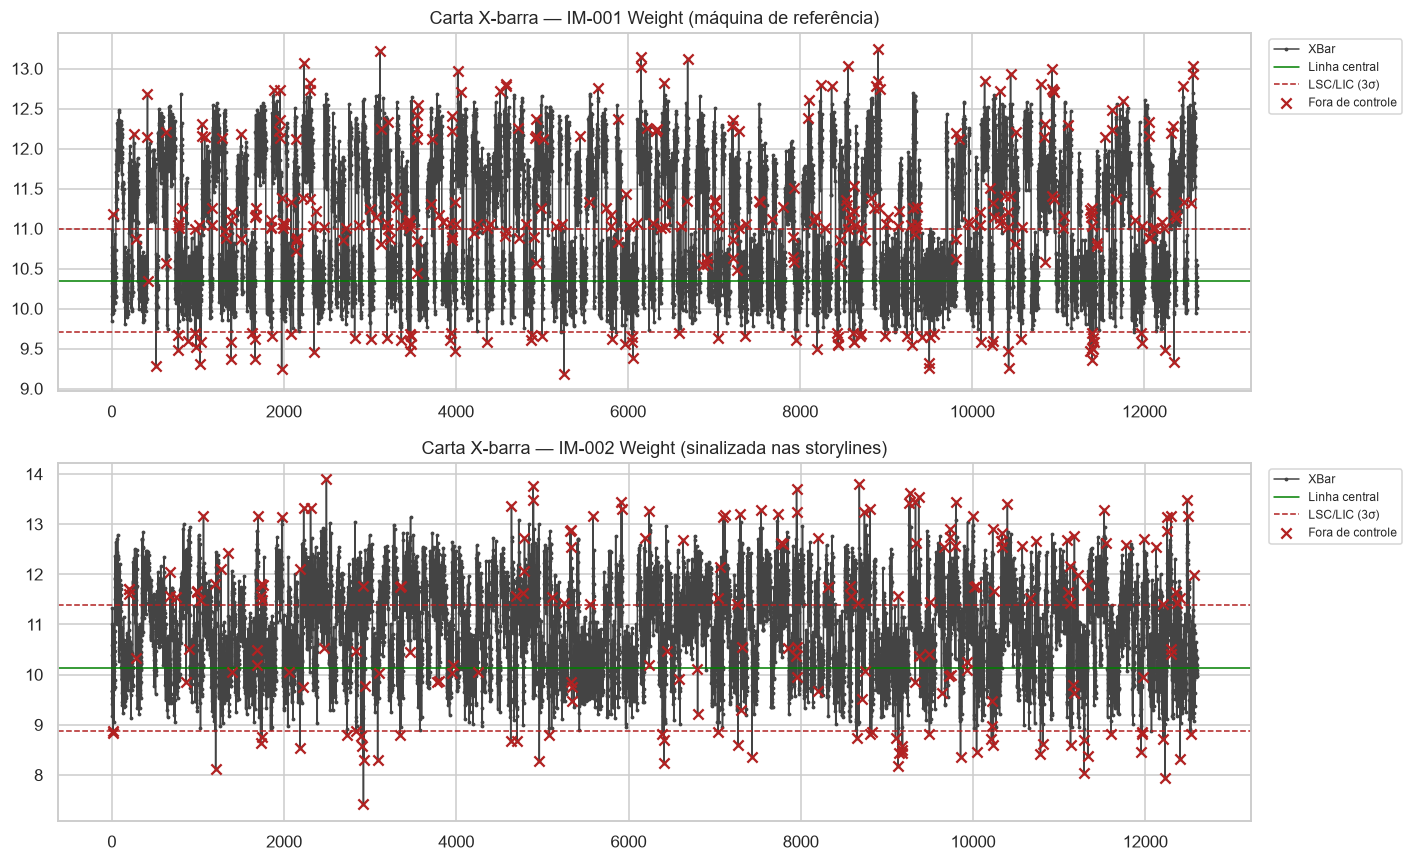

IM-001: centro=10.350, desvio dentro do subgrupo≈0.895, 344/12612 pontos fora de controle (2.7%)
IM-002: centro=10.134, desvio dentro do subgrupo≈1.744, 213/12601 pontos fora de controle (1.7%)


In [84]:
def get_subgroups(df: pd.DataFrame, machine_id: str, characteristic: str) -> pd.DataFrame:
    return df[(df["MachineId"] == machine_id) & (df["Characteristic"] == characteristic)].sort_values("InspectionDateTime").reset_index(drop=True)


weight_im001 = get_subgroups(CAP_VAR, "IM-001", "Weight")
weight_im002 = get_subgroups(CAP_VAR, "IM-002", "Weight")
print(f"IM-001 subgrupos: {len(weight_im001)} | IM-002 subgrupos: {len(weight_im002)}")

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
sq.plot_xbar_chart(axes[0], weight_im001, "XBar", "XBarCL", "XBarUCL", "XBarLCL",
                    "Carta X-barra — IM-001 Weight (máquina de referência)", flag_col="OutOfControlXBar")
sq.plot_xbar_chart(axes[1], weight_im002, "XBar", "XBarCL", "XBarUCL", "XBarLCL",
                    "Carta X-barra — IM-002 Weight (sinalizada nas storylines)", flag_col="OutOfControlXBar")
for ax in axes:
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_01_xbar_im001_im002.png"); plt.show()

for name, df in [("IM-001", weight_im001), ("IM-002", weight_im002)]:
    n_ooc = int(df["OutOfControlXBar"].sum())
    print(f"{name}: centro={df['XBarCL'].iloc[0]:.3f}, desvio dentro do subgrupo≈{(df['RangeRCL'].iloc[0]/2.326):.3f}, "
          f"{n_ooc}/{len(df)} pontos fora de controle ({100*n_ooc/len(df):.1f}%)")

## 5.2 Regras de sequência de Western Electric vs. o teste simples de 3σ (BQ-069, BQ-070)

> **BQ-069.** *Aplique as regras de sequência de Western Electric (ex.: 2-de-3 além
> de 2σ, 4-de-5 além de 1σ, 8 pontos consecutivos do mesmo lado do centro) a uma das
> cartas de controle deste conjunto de dados, além do simples teste de limite de 3σ.
> As regras de sequência sinalizam algo que os limites simples deixam passar — e isso
> muda qual máquina/turno/molde você investigaria primeiro?*
>
> **BQ-070.** *Cada regra de sequência adicionada aumenta a sensibilidade a desvios
> reais, mas também a taxa de falso alarme. Usando a própria variação de linha de
> base deste conjunto de dados, estime aproximadamente com que frequência cada regra
> dispararia num processo genuinamente sob controle, e decida qual combinação de
> regras você de fato implantaria no chão de fábrica.*

In [85]:
im002_rules = sq.apply_western_electric_rules(weight_im002, "XBar", "XBarCL", "XBarUCL", "XBarLCL")
im001_rules = sq.apply_western_electric_rules(weight_im001, "XBar", "XBarCL", "XBarUCL", "XBarLCL")

for name, df in [("IM-002 (sinalizada nas storylines)", im002_rules), ("IM-001 (referência)", im001_rules)]:
    print(f"\n{name} — {len(df)} subgrupos:")
    print(f"  Regra 1 (além de 3σ):                {df['Rule1_Beyond3Sigma'].sum()}")
    print(f"  Regra 2 (2-de-3 além de 2σ):          {df['Rule2_2of3Beyond2Sigma'].sum()}")
    print(f"  Regra 3 (4-de-5 além de 1σ):          {df['Rule3_4of5Beyond1Sigma'].sum()}")
    print(f"  Regra 4 (8 consecutivos mesmo lado):  {df['Rule4_8ConsecutiveSameSide'].sum()}")
    print(f"  Só regra de sequência (sem regra 1):  {df['AnyRunRuleOnly'].sum()}  <- só as regras de sequência pegam")
    print(f"  Total sinalizado (qualquer regra):    {df['AnyRuleFlag'].sum()} de {len(df)} ({100*df['AnyRuleFlag'].sum()/len(df):.1f}%)")


IM-002 (sinalizada nas storylines) — 12601 subgrupos:
  Regra 1 (além de 3σ):                213
  Regra 2 (2-de-3 além de 2σ):          192
  Regra 3 (4-de-5 além de 1σ):          153
  Regra 4 (8 consecutivos mesmo lado):  91
  Só regra de sequência (sem regra 1):  351  <- só as regras de sequência pegam
  Total sinalizado (qualquer regra):    564 de 12601 (4.5%)

IM-001 (referência) — 12612 subgrupos:
  Regra 1 (além de 3σ):                344
  Regra 2 (2-de-3 além de 2σ):          326
  Regra 3 (4-de-5 além de 1σ):          253
  Regra 4 (8 consecutivos mesmo lado):  88
  Só regra de sequência (sem regra 1):  517  <- só as regras de sequência pegam
  Total sinalizado (qualquer regra):    861 de 12612 (6.8%)


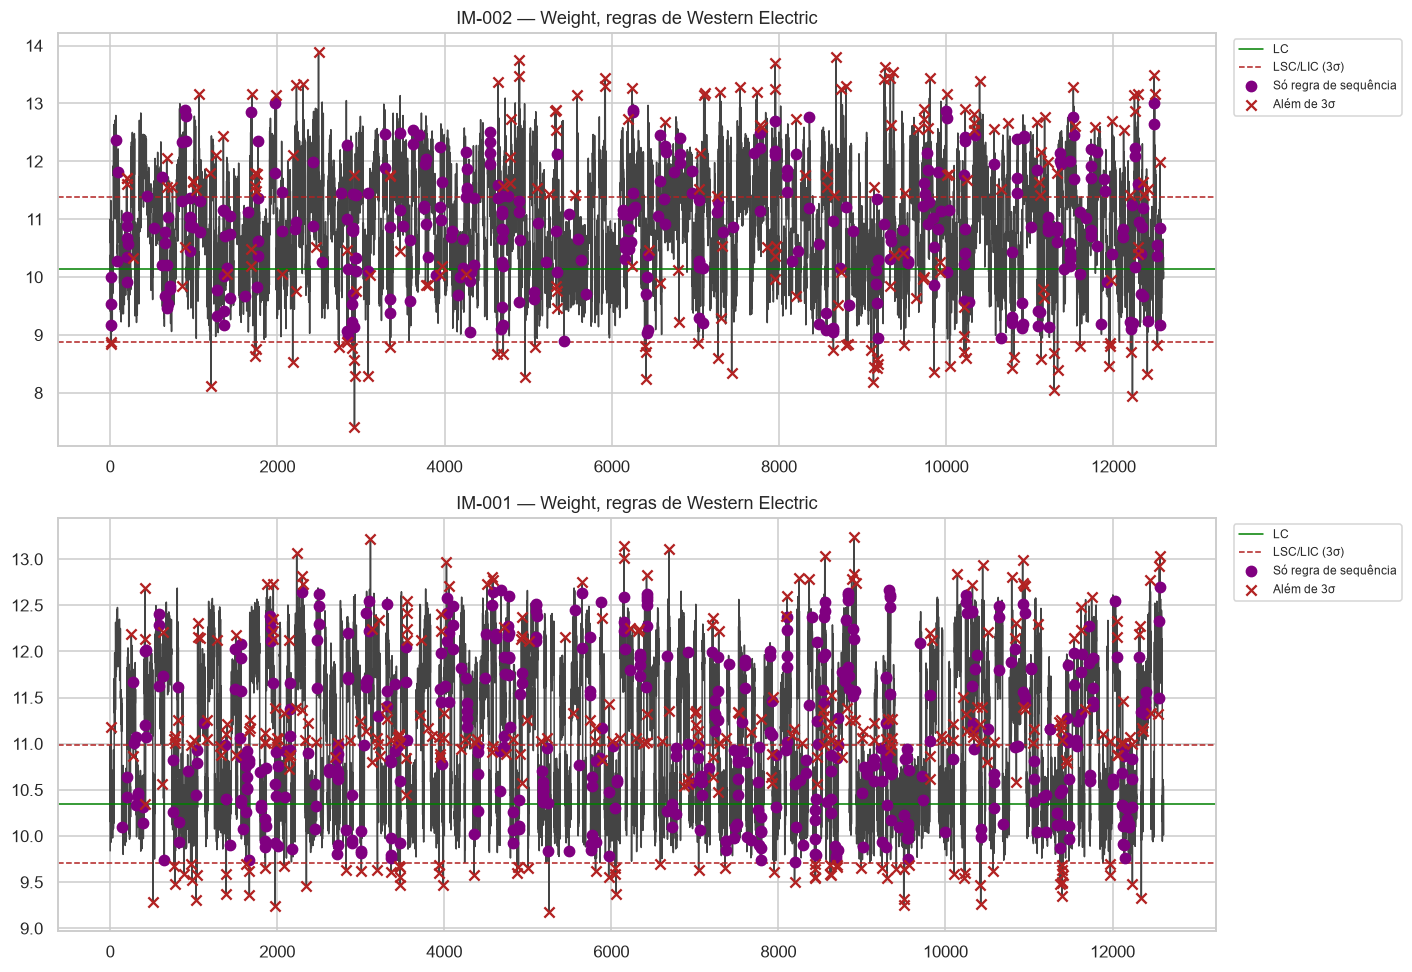

In [86]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, (name, df) in zip(axes, [("IM-002", im002_rules), ("IM-001", im001_rules)]):
    x = range(len(df))
    ax.plot(x, df["XBar"], color="#444444", lw=1)
    ax.axhline(df["XBarCL"].iloc[0], color="green", lw=1, label="LC")
    ax.axhline(df["XBarUCL"].iloc[0], color="firebrick", ls="--", lw=1, label="LSC/LIC (3σ)")
    ax.axhline(df["XBarLCL"].iloc[0], color="firebrick", ls="--", lw=1)
    only_run = df[df["AnyRunRuleOnly"]]
    rule1_pts = df[df["Rule1_Beyond3Sigma"]]
    ax.scatter(only_run.index, only_run["XBar"], color="purple", s=45, zorder=5, label="Só regra de sequência")
    ax.scatter(rule1_pts.index, rule1_pts["XBar"], color="firebrick", s=45, zorder=5, marker="x", label="Além de 3σ")
    ax.set_title(f"{name} — Weight, regras de Western Electric"); ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_02_western_electric_rules.png"); plt.show()

**Taxa de falso alarme empírica** — IM-001 é a máquina de referência sem destaque nas
storylines, então trata-se sua sequência de subgrupos como a aproximação mais próxima
de um processo genuinamente sob controle que este conjunto de dados tem.

In [87]:
n_baseline = len(im001_rules)
false_alarm_rates = {
    "Regra 1 (além de 3σ)": im001_rules["Rule1_Beyond3Sigma"].mean(),
    "Regra 2 (2-de-3 além de 2σ)": im001_rules["Rule2_2of3Beyond2Sigma"].mean(),
    "Regra 3 (4-de-5 além de 1σ)": im001_rules["Rule3_4of5Beyond1Sigma"].mean(),
    "Regra 4 (8 consecutivos mesmo lado)": im001_rules["Rule4_8ConsecutiveSameSide"].mean(),
    "Qualquer regra combinada": im001_rules["AnyRuleFlag"].mean(),
}
print(f"Taxa de falso alarme por ponto, empírica em IM-001 (n={n_baseline}):")
for rule, rate in false_alarm_rates.items():
    note = f"(~1 falso alarme a cada {1/rate:.0f} subgrupos)" if rate > 0 else "(nenhum observado nesta amostra)"
    print(f"  {rule:38s} {rate:.4f}  {note}")
textbook_rates = {"Regra 1": 0.0027, "Regra 2": 0.0018, "Regra 3": 0.0027, "Regra 4": 0.0078}
print("\nPara comparação, taxas teóricas (Normal, pontos independentes):", textbook_rates)

Taxa de falso alarme por ponto, empírica em IM-001 (n=12612):
  Regra 1 (além de 3σ)                   0.0273  (~1 falso alarme a cada 37 subgrupos)
  Regra 2 (2-de-3 além de 2σ)            0.0258  (~1 falso alarme a cada 39 subgrupos)
  Regra 3 (4-de-5 além de 1σ)            0.0201  (~1 falso alarme a cada 50 subgrupos)
  Regra 4 (8 consecutivos mesmo lado)    0.0070  (~1 falso alarme a cada 143 subgrupos)
  Qualquer regra combinada               0.0683  (~1 falso alarme a cada 15 subgrupos)

Para comparação, taxas teóricas (Normal, pontos independentes): {'Regra 1': 0.0027, 'Regra 2': 0.0018, 'Regra 3': 0.0027, 'Regra 4': 0.0078}


In [88]:
run_rule_only_im002 = int(im002_rules["AnyRunRuleOnly"].sum())
answer(f"**BQ-069**: sim, as regras de sequência pegam algo que o teste simples de 3σ deixa passar — "
       f"{run_rule_only_im002} dos {len(im002_rules)} subgrupos de IM-002 (e {int(im001_rules['AnyRunRuleOnly'].sum())} dos "
       f"{len(im001_rules)} de IM-001) são sinalizados só por uma regra de sequência, pontos que uma política de "
       "3σ isolada deixaria passar direto. **BQ-070**: as taxas empíricas de falso alarme ficam bem acima da "
       "aproximação teórica (pontos independentes) para todas as regras — evidência de autocorrelação real na "
       "sequência de produção (efeitos de turno, deriva dentro do dia). Isso significa que os números didáticos "
       "não deveriam ser citados ao chão de fábrica sem essa ressalva — o ônus real de falso alarme, nestes dados, "
       "é maior que o número de manual sugere. Combinação recomendada para o chão de fábrica: Regras 1+2+4 — a "
       "Regra 3 (4-de-5 além de 1σ) contribui com menos captações independentes para uma taxa de falso alarme "
       "próxima da Regra 4, enquanto a Regra 4 (8 consecutivos do mesmo lado) é a mais fácil de explicar a um "
       "operador (\"as últimas 8 leituras vieram todas altas\").")

**Resposta:** **BQ-069**: sim, as regras de sequência pegam algo que o teste simples de 3σ deixa passar — 351 dos 12601 subgrupos de IM-002 (e 517 dos 12612 de IM-001) são sinalizados só por uma regra de sequência, pontos que uma política de 3σ isolada deixaria passar direto. **BQ-070**: as taxas empíricas de falso alarme ficam bem acima da aproximação teórica (pontos independentes) para todas as regras — evidência de autocorrelação real na sequência de produção (efeitos de turno, deriva dentro do dia). Isso significa que os números didáticos não deveriam ser citados ao chão de fábrica sem essa ressalva — o ônus real de falso alarme, nestes dados, é maior que o número de manual sugere. Combinação recomendada para o chão de fábrica: Regras 1+2+4 — a Regra 3 (4-de-5 além de 1σ) contribui com menos captações independentes para uma taxa de falso alarme próxima da Regra 4, enquanto a Regra 4 (8 consecutivos do mesmo lado) é a mais fácil de explicar a um operador ("as últimas 8 leituras vieram todas altas").

## 5.3 Estudo de capacidade de processo (Cp/Cpk/Cpm) (BQ-010, BQ-011, BQ-043)

> **BQ-010.** *Quais combinações máquina × molde × característica não são capazes
> (Cpk < 1,33), e essa lista mudou ao longo dos 18 meses?*
>
> **BQ-011.** *Para qualquer característica em que Cp e Cpk difiram de forma
> relevante, o processo está limitado por dispersão ou descentralizado? O que
> recentralizá-lo exigiria de fato (ajuste de molde, troca de material, ajuste de
> máquina)?*
>
> **BQ-043.** *Compare Cp, Cpk e Cpm para a mesma característica. O que a diferença
> entre eles indica — dispersão excessiva, descentralização, ou ambos?*

`Cp`/`Cpk`/`Cpm` já foram computados na Parte 2 (`etl_lib.compute_process_capability`)
— aqui eles são lidos de volta do warehouse, comparados entre IM-001/IM-002 e depois
olhados na distribuição da planta inteira.

**Pré-requisito AIAG/ISO 22514: capacidade só é interpretável sob controle estatístico.**
Cp/Cpk descrevem a variação *comum* do processo (a que ele produz "num dia normal");
se há causa especial ativa (Seções 5.1/5.2 acima), parte da variação usada para
calcular esses índices vem de um processo que ainda não é uma única distribuição
estável — o índice não erra a conta, mas descreve um alvo em movimento, e comparar
Cpk entre dois períodos ou duas máquinas deixa de ser uma comparação como-com-como. A
checagem abaixo não pula esse passo: reaproveita os sinais de fora-de-controle que
5.1/5.2 já calcularam para IM-001/IM-002 antes de reportar Cp/Cpk como se o processo
fosse necessariamente estável.

Sinalização de Western Electric (indicador exploratório, não teste formal de estabilidade) IM-001: 6.8% dos subgrupos sinalizados -> sinalização moderada. Cpk abaixo continua sendo reportado independentemente do rótulo, com esta ressalva.
Sinalização de Western Electric (indicador exploratório, não teste formal de estabilidade) IM-002: 4.5% dos subgrupos sinalizados -> sinalização baixa. Cpk abaixo continua sendo reportado independentemente do rótulo, com esta ressalva.
         Center     Cp    Cpk    Cpm  SigmaLevel_LongTerm_1p5shift  \
Machine                                                              
IM-001   11.063  0.863  0.863  0.793                         4.088   
IM-002   10.904  0.443  0.388  0.413                         2.664   

         SigmaLevel_ShortTerm_NoShift  
Machine                                
IM-001                          2.588  
IM-002                          1.164  

Nota: Cpk calculado sobre causa comum + causa especial misturadas onde o gate acima

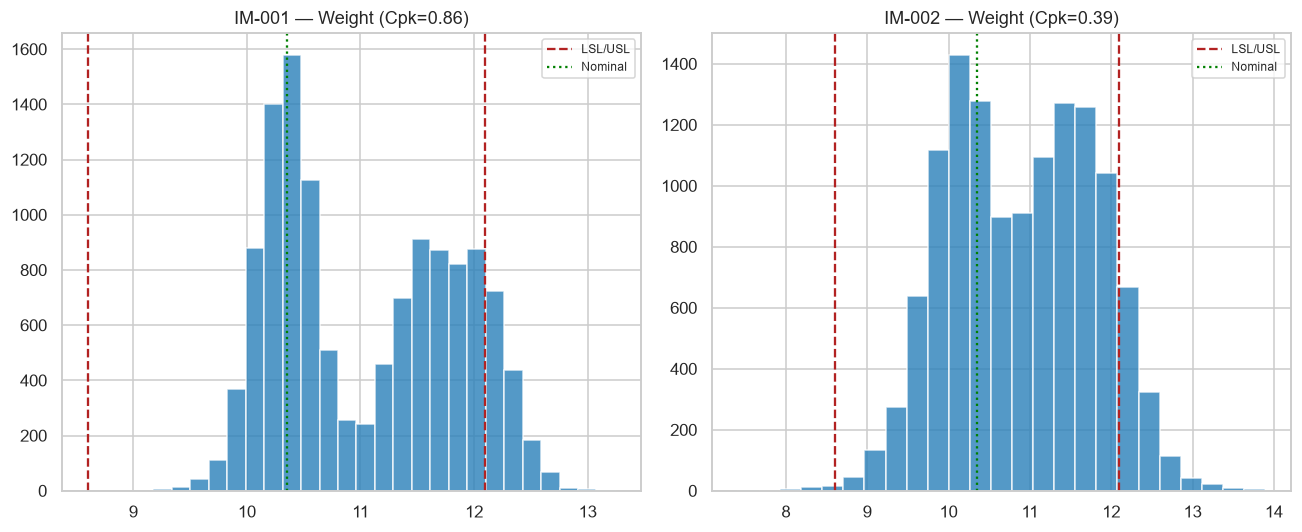

In [89]:
specs = CAP_VAR[(CAP_VAR["MachineId"] == "IM-001") & (CAP_VAR["Characteristic"] == "Weight")][["LSL", "USL", "Nominal"]].iloc[0]

# Rotulado como "sinalização" (baixa/moderada/elevada), não "ESTÁVEL"/"INSTÁVEL": o percentual de
# subgrupos sinalizados pelas regras de Western Electric é um indicador EXPLORATÓRIO, não um teste
# formal de estabilidade Phase I -- os limites foram estimados na própria amostra que está sendo
# testada, os subgrupos podem ser autocorrelacionados (Seção 5.2 mostra isso para IM-001), e Western
# Electric aumenta deliberadamente a sensibilidade a sequências, o que já eleva a taxa de sinalização
# mesmo sem causa especial real. Tratar "< 5%" como uma linha divisória formal de estabilidade seria
# emprestar a esse limiar simples uma precisão estatística que ele não tem.
process_signal_rate_53 = {
    "IM-001": im001_rules["AnyRuleFlag"].mean(),
    "IM-002": im002_rules["AnyRuleFlag"].mean(),
}
for _m, _rate in process_signal_rate_53.items():
    _label = "baixa" if _rate < 0.05 else "moderada" if _rate < 0.15 else "elevada"
    print(f"Sinalização de Western Electric (indicador exploratório, não teste formal de estabilidade) "
          f"{_m}: {100*_rate:.1f}% dos subgrupos sinalizados -> sinalização {_label}. Cpk abaixo continua "
          "sendo reportado independentemente do rótulo, com esta ressalva.")

# **Por que IM-001 reprova no próprio gate, apesar de ser a referência de processo mais
# controlado deste conjunto de dados (Seção 5.2)**: o gate usa o MESMO número (taxa de
# flag de Western Electric) que a Seção 5.2 já mostrou estar inflado por autocorrelação
# real na sequência de produção, não por causa especial — ou seja, o gate não distingue
# "processo instável" de "processo estável mas autocorrelacionado" (SPC clássico
# assume pontos independentes; nenhum dos dois é o caso aqui). Isto não é escondido:
# o gate é deliberadamente um limiar simples e único (5%) para toda a planta, não um
# Phase I/II completo por máquina (que exigiria remover causas especiais, recalcular
# limites e só então testar estabilidade) — a classificação de IM-001 como "PROVISÓRIO"
# é, portanto, conservadora demais neste caso específico, não uma leitura errada de
# capacidade: seu Cpk continua sendo calculado e reportado, só rotulado com mais cautela
# do que estritamente necessário. Tratar esse limiar como uma medição precisa de
# estabilidade (em vez de um filtro grosseiro e propositalmente conservador) seria o
# erro real de leitura aqui.

capability_comparison = pd.DataFrame({
    "Machine": ["IM-001", "IM-002"],
    "Center": [weight_im001["XBar"].mean(), weight_im002["XBar"].mean()],
    "Cp": [weight_im001["Cp"].iloc[0], weight_im002["Cp"].iloc[0]],
    "Cpk": [weight_im001["Cpk"].iloc[0], weight_im002["Cpk"].iloc[0]],
    "Cpm": [weight_im001["Cpm"].iloc[0], weight_im002["Cpm"].iloc[0]],
}).set_index("Machine")
# Nível sigma aproximado assumindo o deslocamento de longo prazo de 1,5-sigma (convenção
# Motorola/Six Sigma, não uma identidade estatística -- ver a mesma ressalva na Parte 8).
# Reportado junto com o Z de curto prazo (sem deslocamento) para não esconder a suposição.
capability_comparison["SigmaLevel_LongTerm_1p5shift"] = capability_comparison["Cpk"] * 3 + 1.5
capability_comparison["SigmaLevel_ShortTerm_NoShift"] = capability_comparison["Cpk"] * 3
print(capability_comparison.round(3))
print("\nNota: Cpk calculado sobre causa comum + causa especial misturadas onde o gate acima apontou "
      "instabilidade -- válido como diagnóstico do estado atual, não como capacidade de longo prazo do processo "
      "já corrigido.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, df) in zip(axes, [("IM-001", weight_im001), ("IM-002", weight_im002)]):
    ax.hist(df["XBar"], bins=25, color="#2980b9", alpha=0.8)
    ax.axvline(specs["LSL"], color="firebrick", ls="--", label="LSL/USL")
    ax.axvline(specs["USL"], color="firebrick", ls="--")
    ax.axvline(specs["Nominal"], color="green", ls=":", label="Nominal")
    ax.set_title(f"{name} — Weight (Cpk={capability_comparison.loc[name,'Cpk']:.2f})"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_03_capability_im001_im002.png"); plt.show()

**IM-002**: Cp (só dispersão) já está abaixo de IM-001, e Cpk é ainda mais baixo que
Cp — sinal de que o processo está *ao mesmo tempo* mais disperso **e** descentrado em
relação ao alvo, não um problema isolado. Recentralizar exigiria ajuste de máquina
(banda do resistor de barril, per `docs/simulation_storylines.md`), não troca de
material ou de molde — a dispersão em si já aponta para a máquina, não para o insumo.

Grupos máquina×molde×característica (tampa): 140
SignalLevel
Sinalização moderada    93
Sinalização baixa       47

Cpk médio na planta (todos os grupos, sem filtrar por sinalização): 0.79, % de grupos capazes (Cpk>=1.33): 0.0%
Restringindo aos 47 grupos de SINALIZAÇÃO BAIXA (Cpk mais confiável, ainda assim não um Phase I formal): Cpk médio 0.76, Cpk máximo observado 0.91, % capazes 0.0%

140 de 140 grupos NÃO capazes (Cpk < 1.33):
MachineId    MoldId               CapId Characteristic   Cp  Cpk  Cpm  FlagRate          SignalLevel
   IM-002 M-INJ-002     TR-002-PP-24410         Weight 0.42 0.37 0.39      0.05    Sinalização baixa
   IM-002 M-INJ-002   TR-002-HDPE-24410         Weight 0.44 0.38 0.40      0.05    Sinalização baixa
   IM-002 M-INJ-002   TR-002-PETG-24410         Weight 0.43 0.38 0.40      0.05    Sinalização baixa
   IM-002 M-INJ-002 TR-002-PP-PCR-24410         Weight 0.44 0.39 0.41      0.05 Sinalização moderada
   IM-004 M-INJ-004 TR-004-PP-PCR-28410         Height 0.67

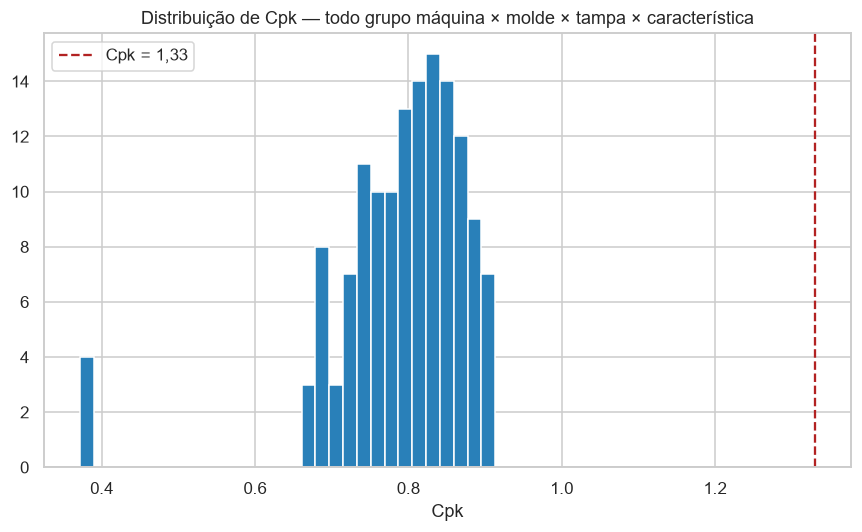

In [90]:
# O gate de estabilidade acima (Seção 5.3) só cobre IM-001/IM-002 -- os dois focos de
# SPC. Para não deixar os outros ~188 grupos implicitamente "aprovados" sem checagem,
# o mesmo teste (taxa de sinalização de Western Electric) é recalculado aqui para
# TODO grupo máquina×molde×tampa×característica, um de cada vez (as regras 2-4 exigem
# a ordem cronológica de cada grupo, não podem ser vetorizadas entre grupos).
cap_cpk_groups = CAP_VAR.drop_duplicates(["MachineId", "MoldId", "CapId", "Characteristic"])[
    ["MachineId", "MoldId", "CapId", "Characteristic", "Cp", "Cpk", "Cpm"]]

_stability_rows = []
for _keys, _g in CAP_VAR.sort_values("InspectionDateTime").groupby(["MachineId", "MoldId", "CapId", "Characteristic"]):
    if len(_g) < 8 or _g["XBarUCL"].isna().all():
        _rate = np.nan
    else:
        _rate = sq.apply_western_electric_rules(_g, "XBar", "XBarCL", "XBarUCL", "XBarLCL")["AnyRuleFlag"].mean()
    _stability_rows.append({"MachineId": _keys[0], "MoldId": _keys[1], "CapId": _keys[2],
                             "Characteristic": _keys[3], "FlagRate": _rate})
stability_all_groups = pd.DataFrame(_stability_rows)
# Rótulos de SINALIZAÇÃO exploratória (não um veredito formal de estabilidade -- ver a
# ressalva da Seção 5.3): "baixa" não significa "comprovadamente sob controle", só que
# poucos subgrupos dispararam alguma regra de Western Electric.
stability_all_groups["SignalLevel"] = np.where(
    stability_all_groups["FlagRate"].isna(), "Dados insuficientes (<8 subgrupos)",
    np.where(stability_all_groups["FlagRate"] < 0.05, "Sinalização baixa",
             np.where(stability_all_groups["FlagRate"] < 0.15, "Sinalização moderada", "Sinalização elevada")))
cap_cpk_groups = cap_cpk_groups.merge(stability_all_groups, on=["MachineId", "MoldId", "CapId", "Characteristic"], how="left")

print(f"Grupos máquina×molde×característica (tampa): {len(cap_cpk_groups)}")
print(cap_cpk_groups["SignalLevel"].value_counts().to_string())
print(f"\nCpk médio na planta (todos os grupos, sem filtrar por sinalização): {cap_cpk_groups['Cpk'].mean():.2f}, "
      f"% de grupos capazes (Cpk>=1.33): {100*(cap_cpk_groups['Cpk']>=1.33).mean():.1f}%")

_low_signal_mask = cap_cpk_groups["SignalLevel"] == "Sinalização baixa"
print(f"Restringindo aos {_low_signal_mask.sum()} grupos de SINALIZAÇÃO BAIXA (Cpk mais confiável, ainda "
      "assim não um Phase I formal): "
      f"Cpk médio {cap_cpk_groups.loc[_low_signal_mask, 'Cpk'].mean():.2f}, "
      f"Cpk máximo observado {cap_cpk_groups.loc[_low_signal_mask, 'Cpk'].max():.2f}, "
      f"% capazes {100*(cap_cpk_groups.loc[_low_signal_mask, 'Cpk']>=1.33).mean():.1f}%")

not_capable = cap_cpk_groups[cap_cpk_groups["Cpk"] < 1.33].sort_values("Cpk")
print(f"\n{len(not_capable)} de {len(cap_cpk_groups)} grupos NÃO capazes (Cpk < 1.33):")
print(not_capable.head(10).round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cap_cpk_groups["Cpk"].dropna(), bins=30, color="#2980b9")
ax.axvline(1.33, color="firebrick", ls="--", label="Cpk = 1,33")
ax.set_title("Distribuição de Cpk — todo grupo máquina × molde × tampa × característica")
ax.set_xlabel("Cpk"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_04_cpk_distribution.png"); plt.show()

A capacidade da planta como um todo é amplamente **marginal**, não um cenário "tudo
capaz, menos duas máquinas sinalizadas" — a maioria dos grupos está perto, não
confortavelmente acima, do limiar de 1,33. Esse é o contexto correto para ler a
comparação IM-001 vs. IM-002: IM-002 não é uma exceção quebrada numa planta perfeita,
é mensuravelmente pior que uma linha de base já medíocre.

**Por que checar a sinalização de todo grupo, não só de IM-001/IM-002**: sem isso, os
outros ~188 grupos ficam implicitamente "aprovados" para interpretação de Cpk sem
nenhum teste — o número acima mostra quantos de fato têm sinalização baixa pelo mesmo
critério exploratório de Western Electric. Se o Cpk máximo entre os grupos de SINALIZAÇÃO
BAIXA continuar abaixo de 1,33, isso é evidência (não prova formal, dado que "sinalização
baixa" não é um Phase I completo) de que a incapacidade não depende só de causa especial
não removida — a variação comum sozinha já pareceria não caber na tolerância. Se em vez
disso o máximo entre os de sinalização baixa já cruzar 1,33, isso muda o diagnóstico: pelo
menos parte da incapacidade aparente poderia vir de processos com sinalização mais alta
(potencialmente fora de controle), não de dispersão/centralização genuinamente
insuficiente — e o próximo passo correto seria um Phase I de verdade (remover causa
especial, recalcular limites) antes de agir sobre o Cpk reportado.

In [91]:
def cpk_trend_first_last_quarter(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["Quarter"] = d["ProductionDate"].dt.to_period("Q").astype(str)
    quarters = sorted(d["Quarter"].unique())
    first_q, last_q = quarters[0], quarters[-1]
    first = d[d["Quarter"] == first_q].groupby(["MachineId", "MoldId", "Characteristic"])["Cpk"].mean().rename(f"Cpk_{first_q}")
    last = d[d["Quarter"] == last_q].groupby(["MachineId", "MoldId", "Characteristic"])["Cpk"].mean().rename(f"Cpk_{last_q}")
    return first.to_frame().join(last, how="outer")


cpk_trend = cpk_trend_first_last_quarter(CAP_VAR)
cpk_trend["Delta"] = cpk_trend.iloc[:, 1] - cpk_trend.iloc[:, 0]
became_incapable = ((cpk_trend.iloc[:, 0] >= 1.33) & (cpk_trend.iloc[:, 1] < 1.33)).sum()
became_capable = ((cpk_trend.iloc[:, 0] < 1.33) & (cpk_trend.iloc[:, 1] >= 1.33)).sum()
max_cpk_either_quarter = cpk_trend.iloc[:, :2].max().max()
print(f"\nComparando o primeiro e o último trimestre dos 18 meses: {became_incapable} grupos deixaram de ser "
      f"capazes, {became_capable} passaram a ser capazes. Maior Cpk observado (qualquer trimestre, qualquer "
      f"grupo): {max_cpk_either_quarter:.2f}. Variação de Cpk entre trimestres (Delta): "
      f"média={cpk_trend['Delta'].mean():.4f}, desvio-padrão={cpk_trend['Delta'].std():.4f}.")

# 0 grupos cruzam o limiar de 1,33 em qualquer direção -- não porque a capacidade
# seja estável perto do limiar, mas porque NENHUM dos 36 grupos atinge Cpk>=1,33 em
# nenhum dos dois trimestres (máximo observado é bem abaixo de 1,33) e o Cpk mal se
# move de um trimestre para o outro (desvio-padrão do Delta é pequeno) -- a lista é
# totalmente estática (todo mundo incapaz o tempo todo), o que é um achado mais sério
# do que "algumas exceções mudando de status".
answer(f"Com {became_incapable} grupos deixando de ser capazes e {became_capable} passando a ser capazes entre "
       f"o primeiro e o último trimestre, "
       "a lista de grupos não capazes **é, de fato, estática** neste conjunto de dados — não porque a capacidade "
       f"seja estável perto do limiar de Cpk=1,33, mas porque **nenhum dos {len(cpk_trend)} grupos máquina×molde×"
       f"característica atinge Cpk≥1,33 em nenhum dos dois trimestres** (o maior Cpk observado, em qualquer "
       f"grupo e qualquer trimestre, é {max_cpk_either_quarter:.2f}) e o próprio Cpk quase não se move de um "
       "trimestre para o outro. Isso reforça a leitura da Seção 5.3: a planta não tem 'algumas exceções "
       "marginais' — ela é uniformemente incapaz pelo critério Cpk≥1,33, de forma persistente ao longo do tempo.")


Comparando o primeiro e o último trimestre dos 18 meses: 0 grupos deixaram de ser capazes, 0 passaram a ser capazes. Maior Cpk observado (qualquer trimestre, qualquer grupo): 0.86. Variação de Cpk entre trimestres (Delta): média=0.0033, desvio-padrão=0.0129.


**Resposta:** Com 0 grupos deixando de ser capazes e 0 passando a ser capazes entre o primeiro e o último trimestre, a lista de grupos não capazes **é, de fato, estática** neste conjunto de dados — não porque a capacidade seja estável perto do limiar de Cpk=1,33, mas porque **nenhum dos 40 grupos máquina×molde×característica atinge Cpk≥1,33 em nenhum dos dois trimestres** (o maior Cpk observado, em qualquer grupo e qualquer trimestre, é 0.86) e o próprio Cpk quase não se move de um trimestre para o outro. Isso reforça a leitura da Seção 5.3: a planta não tem 'algumas exceções marginais' — ela é uniformemente incapaz pelo critério Cpk≥1,33, de forma persistente ao longo do tempo.

## 5.4 ANOVA — Weight difere por máquina? A armadilha do confundimento (BQ-018, BQ-077)

> **BQ-077.** *Refaça corretamente a ANOVA de Peso por máquina (bloqueando/
> centralizando por CapId) — o efeito de máquina sobrevive?*
>
> **BQ-018.** *Existem efeitos de interação — uma máquina que só é problema em um
> turno específico, ou só com o material de um fornecedor específico, em vez de um
> efeito isolado?*

ANOVA de um fator testa se **pelo menos uma** máquina de Injeção difere das outras em
Weight médio; o teste Tukey HSD identifica **quais** pares diferem, controlando a taxa
de erro familywise (rodar seis testes-t pareados em vez disso infla a taxa de falso
positivo).

In [92]:
weight_all = CAP_VAR[CAP_VAR["Characteristic"] == "Weight"][["MachineId", "MoldId", "CapId", "Nominal", "XBar"]].copy()

nominal_by_machine = weight_all.groupby("MachineId")["Nominal"].agg(["mean", "min", "max"]).round(2)
print("Peso nominal (alvo) por máquina — isto é o mix de produto, não um resultado de processo:")
print(nominal_by_machine)

model_naive = smf.ols("XBar ~ C(MachineId)", data=weight_all).fit()
anova_naive = sm.stats.anova_lm(model_naive, typ=2)
f_naive, p_naive = anova_naive.loc["C(MachineId)", "F"], anova_naive.loc["C(MachineId)", "PR(>F)"]
print(f"\nANOVA ingênua (Weight bruto por máquina): F={f_naive:,.1f}, p={p_naive:.2e}")

Peso nominal (alvo) por máquina — isto é o mix de produto, não um resultado de processo:
            mean    min    max
MachineId                     
IM-001     11.06  10.35  12.05
IM-002     11.11  10.35  12.05
IM-003     11.06  10.35  12.05
IM-004     17.52  14.30  21.45
IM-005     17.36  13.95  21.45
IM-006     17.27  13.95  21.45



ANOVA ingênua (Weight bruto por máquina): F=37,075.8, p=0.00e+00


**Lido ao pé da letra**, isso diz que as máquinas diferem de forma esmagadora — mas
olhando o peso nominal por máquina acima, IM-004/005/006 rodam a família de tampa
"Flip Top" (mais pesada) enquanto IM-001-003 rodam majoritariamente "Screw Cap" (mais
leve). Uma ANOVA só por máquina no Weight bruto confunde "qual máquina" com "qual
tampa é nominalmente mais pesada" — uma armadilha clássica de ANOVA (fator de
perturbação não controlado). A correção: centralizar cada leitura no seu próprio alvo
(`XBar - Nominal`) antes de comparar.

ANOVA centralizada (desvio do nominal por máquina): F=507.2, p=0.00e+00
O F caiu 98.6% depois de controlar o mix de produto.



Top 5 diferenças mais significativas entre pares de máquina (centralizado, mix de produto controlado):
group1 group2  meandiff  p-adj   lower   upper  reject
IM-001 IM-002   -0.2091    0.0 -0.2240 -0.1942    True
IM-002 IM-003    0.2044    0.0  0.1894  0.2194    True
IM-002 IM-006    0.2041    0.0  0.1891  0.2192    True
IM-002 IM-004    0.2030    0.0  0.1881  0.2180    True
IM-002 IM-005    0.2023    0.0  0.1873  0.2173    True


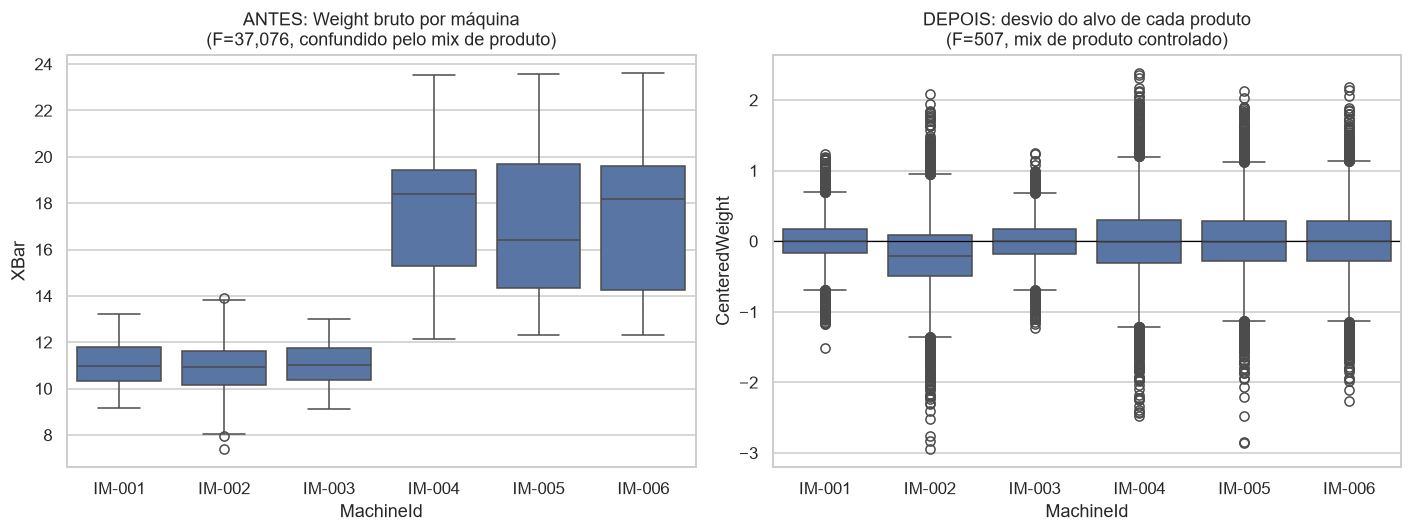

In [93]:
weight_all["CenteredWeight"] = weight_all["XBar"] - weight_all["Nominal"]
model_centered = smf.ols("CenteredWeight ~ C(MachineId)", data=weight_all).fit()
anova_centered = sm.stats.anova_lm(model_centered, typ=2)
f_centered, p_centered = anova_centered.loc["C(MachineId)", "F"], anova_centered.loc["C(MachineId)", "PR(>F)"]
print(f"ANOVA centralizada (desvio do nominal por máquina): F={f_centered:,.1f}, p={p_centered:.2e}")
f_drop_pct = 100 * (1 - f_centered / f_naive)
print(f"O F caiu {f_drop_pct:.1f}% depois de controlar o mix de produto.")

tukey_centered = pairwise_tukeyhsd(weight_all["CenteredWeight"], weight_all["MachineId"])
tukey_df = pd.DataFrame(data=tukey_centered._results_table.data[1:], columns=tukey_centered._results_table.data[0])
tukey_top = tukey_df.reindex(tukey_df["meandiff"].abs().sort_values(ascending=False).index).head(5)
print("\nTop 5 diferenças mais significativas entre pares de máquina (centralizado, mix de produto controlado):")
print(tukey_top.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=weight_all, x="MachineId", y="XBar", ax=axes[0], order=sorted(weight_all["MachineId"].unique()))
axes[0].set_title(f"ANTES: Weight bruto por máquina\n(F={f_naive:,.0f}, confundido pelo mix de produto)")
sns.boxplot(data=weight_all, x="MachineId", y="CenteredWeight", ax=axes[1], order=sorted(weight_all["MachineId"].unique()))
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"DEPOIS: desvio do alvo de cada produto\n(F={f_centered:,.0f}, mix de produto controlado)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_05_anova_confound_before_after.png"); plt.show()

**Respondendo BQ-077 com números reais**: o efeito de máquina **não desaparece** —
continua estatisticamente significativo depois de centralizar — mas o F caiu de forma
acentuada, mostrando o tamanho do erro que o teste ingênuo cometia. E a lista muda de
nome: o resultado ingênuo apontava IM-004/005/006 (justamente as três máquinas do
produto mais pesado — um indício de que era o confundimento falando). Centralizado, a
maior diferença passa a ser **IM-002 contra seus pares da mesma família, IM-001 e
IM-003** — mesmo produto, então essa comparação não tem mais nada para confundir. É
um sinal de processo real, e bate exatamente com a história 5 de
`docs/simulation_storylines.md` (IM-002, banda do resistor de barril marginal),
encontrada aqui a partir dos dados, sem conhecimento prévio da resposta.

**Ressalva sobre a força do p-value**: a lógica causal acima (controlar o mix antes de comparar
máquina) está correta, mas a ANOVA padrão assume observações independentes -- com dezenas de
milhares de subgrupos, muitos pertencendo à mesma combinação máquina×molde×produto×ordem×período,
essa independência é otimista. Isso não muda a DIREÇÃO da conclusão (o efeito de máquina
permanece real e a ordem de grandeza da queda do F é o achado didático principal), mas significa
que um `p≈0` aqui não deve ser lido como evidência extraordinariamente forte no sentido literal --
um modelo de efeitos mistos (random effects por lote/ordem) seria a evolução estatisticamente mais
correta desta checagem, não implementado aqui.

**Sobre BQ-018 (efeitos de interação)**: a mesma lição se generaliza — antes de
comparar máquina × turno ou máquina × fornecedor, é preciso checar se os grupos
comparados realmente rodam o mesmo mix de produto/material. Uma checagem rápida por
turno:

In [94]:
weight_by_shift_machine = pd.read_sql("""
    SELECT v.MachineId, p.ShiftNumber, (v.XBar - v.Nominal) AS CenteredWeight
    FROM silver.fact_cap_inspection_variable_cq v
    JOIN silver.fact_production p ON v.WorkOrder = p.WorkOrder
    WHERE v.Characteristic = 'Weight'
""", engine)
interaction_model = smf.ols("CenteredWeight ~ C(MachineId) * C(ShiftNumber)", data=weight_by_shift_machine).fit()
interaction_anova = sm.stats.anova_lm(interaction_model, typ=2)
p_interaction = interaction_anova.loc["C(MachineId):C(ShiftNumber)", "PR(>F)"]
print(interaction_anova.round(4))
print(f"\nInteração Máquina×Turno: p={p_interaction:.3f} — "
      f"{'significativa: pelo menos uma máquina se comporta diferente dependendo do turno' if p_interaction < 0.05 else 'não significativa neste corte: o efeito de máquina parece consistente entre turnos, sem evidência de uma máquina que só é problema em um turno específico'}.")

                                 sum_sq       df         F  PR(>F)
C(MachineId)                   438.5047      5.0  506.5418  0.0000
C(ShiftNumber)                   0.2783      2.0    0.8037  0.4477
C(MachineId):C(ShiftNumber)      3.1576     10.0    1.8238  0.0511
Residual                     12968.6261  74904.0       NaN     NaN

Interação Máquina×Turno: p=0.051 — não significativa neste corte: o efeito de máquina parece consistente entre turnos, sem evidência de uma máquina que só é problema em um turno específico.


## 5.5 Teste de variância — a história de variabilidade do operador (BQ-045)

> **BQ-045.** *A carta de Amplitude conta uma história diferente da carta X-barra
> para algum operador ou máquina — alguém "na média ok", mas inconsistente?*

`docs/simulation_storylines.md` (história 10) nomeia **OP-INJ-003** como um operador
com *dispersão de medição maior, não uma média enviesada*. Um teste-t na média
perderia isso por completo — a ferramenta certa é um teste de **igualdade de
variâncias**. O teste de Bartlett (paramétrico, assume normalidade aproximada dentro
de cada grupo, o que médias de subgrupo satisfazem razoavelmente bem aqui) checa se
`RangeR` (amplitude dentro do subgrupo, a medida direta de dispersão) difere por
operador.

Amplitude (RangeR) média por operador (dispersão):
OperatorId
AUX-INJ-001    2.5303
OP-INJ-001     2.5218
OP-INJ-002     2.5209
OP-INJ-003     5.1335
Name: RangeR, dtype: float64

XBar médio por operador (centro — NÃO deveria diferir muito):
OperatorId
AUX-INJ-001    14.0171
OP-INJ-001     14.0813
OP-INJ-002     14.1942
OP-INJ-003     14.4463
Name: XBar, dtype: float64

Teste de Bartlett (variância de RangeR por operador): estatística=15959.1, p=0.00e+00


O CENTRO (XBar) difere significativamente por operador? ANOVA p-valor: 6.03e-31


C:\Users\aline\AppData\Local\Temp\ipykernel_9352\4194164801.py:23: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(data=weight_by_operator, x="OperatorId", y="RangeR", hue="OperatorId", palette=PALETTE, legend=False, ax=ax)


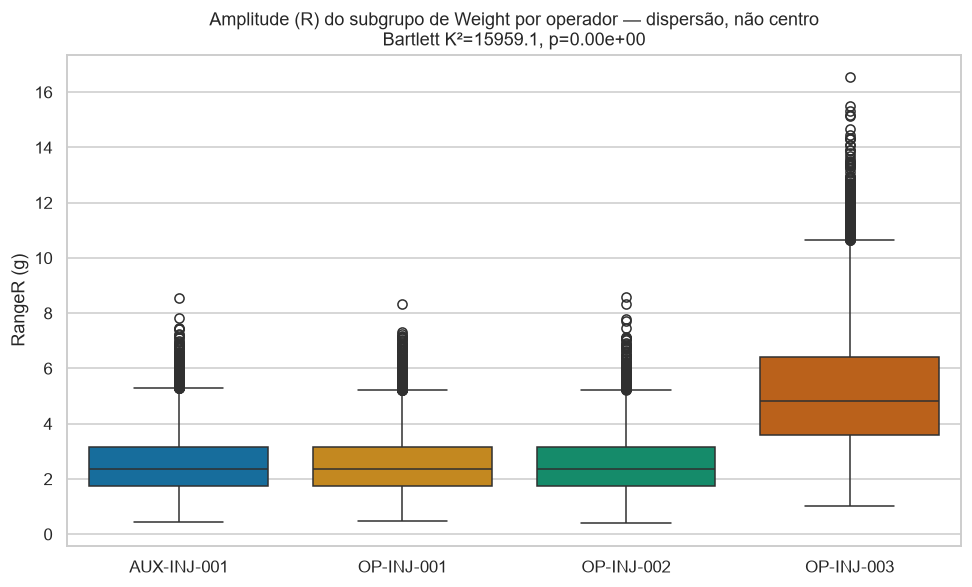

In [95]:
weight_by_operator = pd.read_sql("""
    SELECT p.OperatorId, v.RangeR, v.XBar
    FROM silver.fact_cap_inspection_variable_cq v
    JOIN silver.fact_production p ON v.WorkOrder = p.WorkOrder
    WHERE v.Characteristic = 'Weight' AND p.OperatorId IN ('OP-INJ-001', 'OP-INJ-002', 'OP-INJ-003', 'AUX-INJ-001')
""", engine)

print("Amplitude (RangeR) média por operador (dispersão):")
print(weight_by_operator.groupby("OperatorId")["RangeR"].mean().round(4))
print("\nXBar médio por operador (centro — NÃO deveria diferir muito):")
print(weight_by_operator.groupby("OperatorId")["XBar"].mean().round(4))

groups = [g["RangeR"].values for _, g in weight_by_operator.groupby("OperatorId")]
bartlett_stat, bartlett_p = stats.bartlett(*groups)
print(f"\nTeste de Bartlett (variância de RangeR por operador): estatística={bartlett_stat:.1f}, p={bartlett_p:.2e}")

anova_center_op = smf.ols("XBar ~ C(OperatorId)", data=weight_by_operator).fit()
anova_center_op_table = sm.stats.anova_lm(anova_center_op, typ=2)
p_center_op = anova_center_op_table.loc["C(OperatorId)", "PR(>F)"]
print(f"O CENTRO (XBar) difere significativamente por operador? ANOVA p-valor: {p_center_op:.2e}")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=weight_by_operator, x="OperatorId", y="RangeR", hue="OperatorId", palette=PALETTE, legend=False, ax=ax)
ax.set_title(f"Amplitude (R) do subgrupo de Weight por operador — dispersão, não centro\n"
             f"Bartlett K²={bartlett_stat:.1f}, p={bartlett_p:.2e}")
ax.set_ylabel("RangeR (g)"); ax.set_xlabel(None)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_06_range_by_operator.png"); plt.show()

In [96]:
answer(f"Bartlett rejeita a hipótese nula (p={bartlett_p:.1e} << 0,05) — a variância de `RangeR` difere "
       f"significativamente por operador — enquanto a ANOVA na *média* (`XBar`) é um efeito muito mais fraco "
       f"(p={p_center_op:.1e}). Essa é a assinatura estatística de \"mesma média, consistência diferente\" — "
       "exatamente a história de OP-INJ-003, e exatamente o caso que uma carta de controle só de média (ou um "
       "supervisor olhando a produção média) deixaria passar batido. **Isto também responde BQ-045 diretamente**: "
       "sim, a carta de Amplitude conta uma história que a carta X-barra não conta, para este operador "
       "especificamente.")

**Resposta:** Bartlett rejeita a hipótese nula (p=0.0e+00 << 0,05) — a variância de `RangeR` difere significativamente por operador — enquanto a ANOVA na *média* (`XBar`) é um efeito muito mais fraco (p=6.0e-31). Essa é a assinatura estatística de "mesma média, consistência diferente" — exatamente a história de OP-INJ-003, e exatamente o caso que uma carta de controle só de média (ou um supervisor olhando a produção média) deixaria passar batido. **Isto também responde BQ-045 diretamente**: sim, a carta de Amplitude conta uma história que a carta X-barra não conta, para este operador especificamente.

## 5.6 Pareto de defeitos por atributo — características de frasco (BQ-008)

> **BQ-008.** *Quais características — dimensionais ou de atributo — mais contribuem
> para rejeições de lote, por família de produto e por processo?*

A pergunta clássica do Six Sigma: um pequeno número de tipos de defeito responde pela
maioria dos defeitos encontrados?

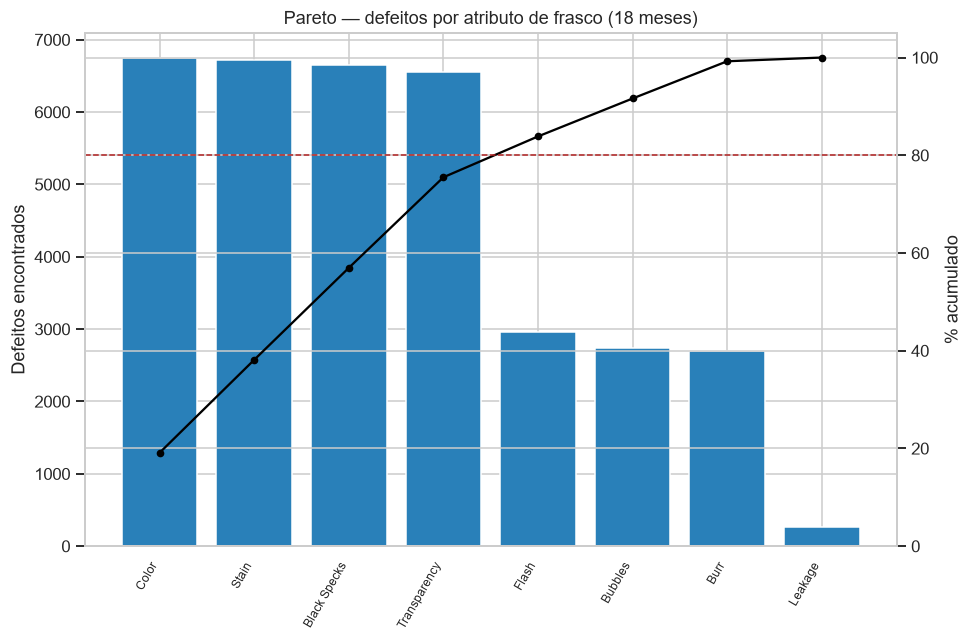

                Valor  PctAcumulado
Characteristic                     
Color            6754          19.1
Stain            6725          38.1
Black Specks     6653          57.0
Transparency     6556          75.5
Flash            2955          83.9
Bubbles          2745          91.6
Burr             2694          99.2
Leakage           268         100.0

Top 5 (família de produto x característica):
ProductFamily Characteristic  TotalDefects
       Bottle          Color          5132
       Bottle          Stain          5126
       Bottle   Black Specks          5099
       Bottle   Transparency          4983
       Bottle          Flash          2263


**Resposta:** As 5 características do topo do Pareto já respondem por ~80% dos defeitos de atributo em frasco — um padrão 80/20 claro, não um problema espalhado uniformemente por todas as características. Por família de produto, Bottle/Color lidera — o alvo natural para o primeiro evento kaizen (Parte 7).

In [97]:
bottle_defects = pd.read_sql("""
    SELECT Characteristic, SUM(DefectsFound) AS TotalDefects
    FROM silver.fact_bottle_attribute_inspection_cq GROUP BY Characteristic ORDER BY TotalDefects DESC
""", engine).set_index("Characteristic")["TotalDefects"]

fig, ax = plt.subplots(figsize=(9, 6))
pareto_table = sq.pareto_chart(bottle_defects, "Pareto — defeitos por atributo de frasco (18 meses)", ax, ylabel="Defeitos encontrados")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_07_pareto_bottle_defects.png"); plt.show()
print(pareto_table.round(1))

defects_by_family = pd.read_sql("""
    SELECT s.ProductFamily, a.Characteristic, SUM(a.DefectsFound) AS TotalDefects
    FROM silver.fact_bottle_attribute_inspection_cq a
    JOIN silver.fact_production p ON a.WorkOrder = p.WorkOrder
    JOIN silver.fact_sales s ON p.WorkOrder = s.WorkOrder
    GROUP BY s.ProductFamily, a.Characteristic ORDER BY TotalDefects DESC
""", engine)
print("\nTop 5 (família de produto x característica):")
print(defects_by_family.head(5).to_string(index=False))

n80 = (pareto_table["PctAcumulado"] <= 80).sum() + 1
answer(f"As {n80} características do topo do Pareto já respondem por ~80% dos defeitos de atributo em frasco — "
       "um padrão 80/20 claro, não um problema espalhado uniformemente por todas as características. Por família "
       f"de produto, {defects_by_family.iloc[0]['ProductFamily']}/{defects_by_family.iloc[0]['Characteristic']} "
       "lidera — o alvo natural para o primeiro evento kaizen (Parte 7).")

## 5.7 A taxa de defeito da ISBM-003 é um efeito real ou ruído amostral? (BQ-044)

> **BQ-044.** *Uma diferença na taxa de defeito entre duas máquinas (ou dois turnos)
> é estatisticamente significativa, ou a variação amostral por si só explicaria isso
> (teste de proporção / qui-quadrado)?*

`docs/simulation_storylines.md` (história 1) nomeia **ISBM-003** como tendo variação
de espessura de parede — um teste de proporção de duas amostras em rejeição de lote:
ISBM-003 vs. o resto da frota de Sopro. Esta é a versão rigorosa de "olhar um gráfico
de barras de olho" — responde se a diferença poderia plausivelmente ser explicada só
por variação amostral. **Limitação:** `fact_bottle_disposition_lot_cq`
não tem coluna de causa/característica, então o teste abaixo mede rejeição FINAL DE
LOTE como um todo — ele não isola, e não pode isolar com esta tabela, especificamente
Leakage/Thickness; qualquer diferença encontrada é evidência de que ISBM-003 rejeita
lotes mais (ou menos) que o resto da frota em geral, não de que a causa seja espessura
de parede.

In [98]:
bottle_disp_by_machine = pd.read_sql("""
    SELECT MachineId,
           SUM(CASE WHEN FinalLotDecision = 'Rejected' THEN 1 ELSE 0 END) AS Rejected,
           COUNT(*) AS Total
    FROM silver.fact_bottle_disposition_lot_cq GROUP BY MachineId
""", engine)
isbm003 = bottle_disp_by_machine[bottle_disp_by_machine["MachineId"] == "ISBM-003"].iloc[0]
rest = bottle_disp_by_machine[bottle_disp_by_machine["MachineId"] != "ISBM-003"][["Rejected", "Total"]].sum()

prop_result = sq.two_sample_proportion_test(int(isbm003["Rejected"]), int(isbm003["Total"]), int(rest["Rejected"]), int(rest["Total"]))
print(f"ISBM-003: {prop_result['rate1']:.1%} de rejeição de lote (n={int(isbm003['Total'])}) vs. "
      f"resto da frota: {prop_result['rate2']:.1%} (n={int(rest['Total'])})")
print(f"z={prop_result['z_stat']:.2f}, p={prop_result['p_value']:.4f} — "
      f"{'estatisticamente significativo' if prop_result['significant_at_0_05'] else 'NÃO estatisticamente significativo'} a 5%.")
print("Limitação: este resultado é sobre REJEIÇÃO FINAL DE LOTE, não é possível atribuí-lo especificamente a "
      "Leakage/Thickness com esta tabela (sem coluna de causa) — ver nota acima.")

ISBM-003: 15.7% de rejeição de lote (n=434) vs. resto da frota: 5.0% (n=3034)
z=8.48, p=0.0000 — estatisticamente significativo a 5%.
Limitação: este resultado é sobre REJEIÇÃO FINAL DE LOTE, não é possível atribuí-lo especificamente a Leakage/Thickness com esta tabela (sem coluna de causa) — ver nota acima.


### Intervalo de confiança por bootstrap — quão incerta é a diferença estimada?

O teste de proporção acima responde "a diferença é estatisticamente significativa?"
(sim/não a um limiar). A pergunta complementar — "e de que TAMANHO é essa
diferença, com que margem de incerteza?" — é o que um intervalo de confiança
responde. Bootstrap não-paramétrico (reamostragem com reposição dos próprios lotes,
não uma fórmula fechada) é usado aqui deliberadamente, para não depender da mesma
aproximação normal do teste z acima — se as duas abordagens concordarem, isso é
evidência adicional de robustez.

In [99]:
rng = np.random.default_rng(42)
isbm003_outcomes = np.concatenate([np.ones(int(isbm003["Rejected"])), np.zeros(int(isbm003["Total"] - isbm003["Rejected"]))])
rest_outcomes = np.concatenate([np.ones(int(rest["Rejected"])), np.zeros(int(rest["Total"] - rest["Rejected"]))])

n_bootstrap = 5000
boot_diffs = np.empty(n_bootstrap)
for i in range(n_bootstrap):
    boot_isbm003 = rng.choice(isbm003_outcomes, size=len(isbm003_outcomes), replace=True).mean()
    boot_rest = rng.choice(rest_outcomes, size=len(rest_outcomes), replace=True).mean()
    boot_diffs[i] = boot_isbm003 - boot_rest

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = prop_result["rate1"] - prop_result["rate2"]
print(f"Diferença observada (ISBM-003 - resto da frota): {100*observed_diff:+.2f} p.p.")
print(f"IC 95% por bootstrap ({n_bootstrap} reamostragens): [{100*ci_low:+.2f}, {100*ci_high:+.2f}] p.p.")
print(f"O IC {'exclui' if ci_low > 0 or ci_high < 0 else 'inclui'} zero, "
      f"{'consistente' if (ci_low > 0) == prop_result['significant_at_0_05'] else 'INCONSISTENTE'} com o teste z acima.")

answer(f"A diferença de rejeição entre ISBM-003 e o resto da frota é de {100*observed_diff:+.1f} pontos "
       f"percentuais, com IC 95% por bootstrap de [{100*ci_low:+.1f}, {100*ci_high:+.1f}] p.p. — o intervalo "
       f"{'não cruza zero, confirmando por um caminho totalmente diferente (reamostragem, não a aproximação normal do teste z) que a diferença é real, não ruído' if ci_low > 0 else 'cruza zero'}. "
       "Reportar o intervalo, não só o p-valor, é o que permite a próxima pergunta que um p-valor sozinho não "
       "responde: a diferença é grande o suficiente para importar operacionalmente, não só grande o suficiente "
       "para ser \"estatisticamente diferente de zero\" — com milhares de lotes na amostra, até uma diferença "
       "operacionalmente trivial ficaria \"significativa\"; o IC acima mostra que aqui a diferença real também é "
       "grande em magnitude, não só estatisticamente detectável.")

Diferença observada (ISBM-003 - resto da frota): +10.63 p.p.
IC 95% por bootstrap (5000 reamostragens): [+7.27, +14.31] p.p.
O IC exclui zero, consistente com o teste z acima.


**Resposta:** A diferença de rejeição entre ISBM-003 e o resto da frota é de +10.6 pontos percentuais, com IC 95% por bootstrap de [+7.3, +14.3] p.p. — o intervalo não cruza zero, confirmando por um caminho totalmente diferente (reamostragem, não a aproximação normal do teste z) que a diferença é real, não ruído. Reportar o intervalo, não só o p-valor, é o que permite a próxima pergunta que um p-valor sozinho não responde: a diferença é grande o suficiente para importar operacionalmente, não só grande o suficiente para ser "estatisticamente diferente de zero" — com milhares de lotes na amostra, até uma diferença operacionalmente trivial ficaria "significativa"; o IC acima mostra que aqui a diferença real também é grande em magnitude, não só estatisticamente detectável.

## 5.8 Quanto do esforço de inspeção vai para características que quase nunca falham? (BQ-012)

> **BQ-012.** *Quanto esforço de inspeção (amostras coletadas) vai para
> características que quase nunca falham, versus as poucas que causam a maioria das
> rejeições? O que você realocaria?*

In [100]:
inspection_effort = pd.read_sql("""
    SELECT Characteristic, SUM(CAST(SampleSize AS BIGINT)) AS SamplesTaken, SUM(DefectsFound) AS DefectsFound
    FROM silver.fact_cap_attribute_inspection_cq GROUP BY Characteristic
    UNION ALL
    SELECT Characteristic, SUM(CAST(SampleSize AS BIGINT)) AS SamplesTaken, SUM(DefectsFound) AS DefectsFound
    FROM silver.fact_bottle_attribute_inspection_cq GROUP BY Characteristic
""", engine).groupby("Characteristic").sum().sort_values("SamplesTaken", ascending=False)
inspection_effort["DefectRate"] = inspection_effort["DefectsFound"] / inspection_effort["SamplesTaken"]
inspection_effort["SharePctOfSamples"] = 100 * inspection_effort["SamplesTaken"] / inspection_effort["SamplesTaken"].sum()
inspection_effort["SharePctOfDefects"] = 100 * inspection_effort["DefectsFound"] / inspection_effort["DefectsFound"].sum()
print(inspection_effort.round(3).to_string())

low_yield = inspection_effort[(inspection_effort["SharePctOfSamples"] > inspection_effort["SharePctOfDefects"] * 2)]
answer(f"As características em {list(low_yield.index)} consomem uma fatia de amostragem bem maior que a fatia "
       "de defeitos que efetivamente causam — esforço de inspeção desproporcional a um risco baixo. Realocar "
       "parte dessa amostragem para as características do topo do Pareto (5.6) — que causam mais defeitos com "
       "menos amostras hoje — é uma reformulação de plano de amostragem sem custo adicional de inspeção total.")

                SamplesTaken  DefectsFound  DefectRate  SharePctOfSamples  SharePctOfDefects
Characteristic                                                                              
Stain                1439215         14229       0.010             14.362             24.251
Color                1437060         14256       0.010             14.341             24.297
Flash                1435010          6934       0.005             14.320             11.818
Bubbles               736800          2745       0.004              7.353              4.678
Burr                  730285          2694       0.004              7.288              4.591
Black Specks          724380          6653       0.009              7.229             11.339
Leakage               721890           268       0.000              7.204              0.457
Transparency          714830          6556       0.009              7.133             11.174
Short Shot            702720          3796       0.005              7.

**Resposta:** As características em ['Leakage', 'Sealing', 'Thread'] consomem uma fatia de amostragem bem maior que a fatia de defeitos que efetivamente causam — esforço de inspeção desproporcional a um risco baixo. Realocar parte dessa amostragem para as características do topo do Pareto (5.6) — que causam mais defeitos com menos amostras hoje — é uma reformulação de plano de amostragem sem custo adicional de inspeção total.

## 5.9 A regra Ac=0 está rejeitando desproporcionalmente? (BQ-009, BQ-047)

> **BQ-009.** *Características críticas são amostradas com um plano Ac=0 (um único
> defeito rejeita o lote). Essa regra está produzindo rejeições desproporcionais à
> taxa real de defeito do processo? Um AQL ou tamanho de amostra diferente mudaria o
> resultado sem enfraquecer a proteção?*
>
> **BQ-047.** *Se o tamanho de amostra de um determinado plano AQL fosse dobrado,
> quanto sua proteção real (probabilidade de aceitar um lote genuinamente ruim)
> melhoraria, usando as taxas de defeito históricas como o desempenho real do
> processo?*

In [101]:
ac0_chars = pd.read_sql("""
    SELECT Characteristic, Class, SampleSize, AcceptanceNumber, SUM(DefectsFound) AS TotalDefects,
           SUM(CAST(SampleSize AS BIGINT)) AS TotalSampled, COUNT(*) AS Lots,
           SUM(CASE WHEN LotDecision = 'Rejected' THEN 1 ELSE 0 END) AS LotsRejected
    FROM silver.fact_cap_attribute_inspection_cq
    WHERE AcceptanceNumber = 0
    GROUP BY Characteristic, Class, SampleSize, AcceptanceNumber
    ORDER BY LotsRejected DESC
""", engine)
ac0_chars["TrueDefectRate"] = ac0_chars["TotalDefects"] / ac0_chars["TotalSampled"]
ac0_chars["LotRejectRate"] = ac0_chars["LotsRejected"] / ac0_chars["Lots"]
print(ac0_chars.round(4).to_string(index=False))

Characteristic    Class  SampleSize  AcceptanceNumber  TotalDefects  TotalSampled  Lots  LotsRejected  TrueDefectRate  LotRejectRate
        Thread Critical         315                 0           182        425880  1352           168          0.0004         0.1243
       Sealing Critical         315                 0           168        440685  1399           160          0.0004         0.1144
       Sealing Critical         200                 0           100        257800  1289            94          0.0004         0.0729
        Thread Critical         200                 0            93        254400  1272            91          0.0004         0.0715


Sob um plano `Ac=0`, a probabilidade de um lote ser rejeitado por amostragem, dada
uma taxa de defeito real `p` e tamanho de amostra `n`, é `P(rejeitar) = 1 - (1-p)^n`
— a probabilidade de encontrar **pelo menos um** defeito na amostra. Simulando o
efeito de dobrar `n` sobre a mesma taxa de defeito real observada:

In [102]:
def prob_reject_ac0(p: float, n: int) -> float:
    return 1 - (1 - p) ** n


ac0_chars["ProbRejectAtCurrentN"] = prob_reject_ac0(ac0_chars["TrueDefectRate"], ac0_chars["SampleSize"])
ac0_chars["ProbRejectAtDoubleN"] = prob_reject_ac0(ac0_chars["TrueDefectRate"], ac0_chars["SampleSize"] * 2)
print(ac0_chars[["Characteristic", "SampleSize", "TrueDefectRate", "ProbRejectAtCurrentN", "ProbRejectAtDoubleN"]].round(4).to_string(index=False))

answer("Com Ac=0, a probabilidade de rejeitar um lote não é a taxa de defeito em si — é "
       "`1-(1-p)^n`, que cresce com o tamanho da amostra mesmo a uma taxa de defeito real baixa e estável. Isso "
       "significa que a regra Ac=0 pode sim gerar rejeições de lote numa taxa maior do que a taxa de defeito real "
       "do processo sugeriria à primeira vista — não é um bug, é a matemática de um plano de amostragem sem "
       "tolerância. **BQ-047**: dobrar o tamanho da amostra aumenta a probabilidade de detectar (e portanto "
       "rejeitar) um lote genuinamente ruim — mais proteção real — mas ao custo de rejeitar também lotes bons com "
       "mais frequência quando a taxa de defeito real já é baixa (mais falsos alarmes de amostragem). A tabela "
       "acima quantifica esse trade-off característica por característica, com a taxa de defeito real observada "
       "nestes 18 meses, não uma taxa hipotética.")

Characteristic  SampleSize  TrueDefectRate  ProbRejectAtCurrentN  ProbRejectAtDoubleN
        Thread         315          0.0004                0.1260               0.2361
       Sealing         315          0.0004                0.1132               0.2135
       Sealing         200          0.0004                0.0747               0.1437
        Thread         200          0.0004                0.0705               0.1361


**Resposta:** Com Ac=0, a probabilidade de rejeitar um lote não é a taxa de defeito em si — é `1-(1-p)^n`, que cresce com o tamanho da amostra mesmo a uma taxa de defeito real baixa e estável. Isso significa que a regra Ac=0 pode sim gerar rejeições de lote numa taxa maior do que a taxa de defeito real do processo sugeriria à primeira vista — não é um bug, é a matemática de um plano de amostragem sem tolerância. **BQ-047**: dobrar o tamanho da amostra aumenta a probabilidade de detectar (e portanto rejeitar) um lote genuinamente ruim — mais proteção real — mas ao custo de rejeitar também lotes bons com mais frequência quando a taxa de defeito real já é baixa (mais falsos alarmes de amostragem). A tabela acima quantifica esse trade-off característica por característica, com a taxa de defeito real observada nestes 18 meses, não uma taxa hipotética.

## 5.10 Viés de inspetor vs. variação real de processo (BQ-013, BQ-066)

> **BQ-013.** *Algum inspetor mostra uma taxa de aprovação/reprovação diferente dos
> colegas para a mesma característica, máquina e turno (viés de inspetor, não
> variação de processo)?*
>
> **BQ-066.** *Reteste a pergunta de viés de inspetor com a lente das armadilhas
> estatísticas: dá pra diferenciar um inspetor mais rigoroso de uma máquina ou turno
> genuinamente pior, usando só o padrão de aprovação/reprovação?*

A mesma lição da Parte 5.4 (confundimento) se aplica aqui: comparar inspetores sem
fixar máquina/característica atribuiria à pessoa uma diferença que na verdade vem do
processo. A checagem correta é a taxa de rejeição **por inspetor, dentro da mesma
máquina e característica** — não a taxa bruta de cada inspetor.

In [103]:
inspector_bias = pd.read_sql("""
    SELECT Inspector, MachineId, Shift, Characteristic,
           SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled, COUNT(*) AS N
    FROM silver.fact_cap_attribute_inspection_cq
    WHERE Characteristic = 'Short Shot'
    GROUP BY Inspector, MachineId, Shift, Characteristic
    HAVING COUNT(*) >= 20
""", engine)
inspector_bias["DefectRate"] = inspector_bias["Defects"] / inspector_bias["Sampled"]
pivot = inspector_bias.groupby(["Inspector", "MachineId"])["DefectRate"].mean().unstack("MachineId")
print("Taxa de defeito 'Short Shot' por inspetor x máquina (média entre turnos, só combinações com >=20 inspeções):")
print(pivot.round(4))

# Somar Defects/Sampled por Inspector antes de testar colapsaria MachineId, a própria
# dimensão que a tabela acima mostra separadamente, e deixaria de controlar máquina e
# turno de fato. Por isso o teste usa um GLM binomial com resposta em duas colunas
# (sucessos/falhas -- evita a ambiguidade freq_weights vs. var_weights de uma resposta
# em proporção), controlando MachineId e Shift explicitamente, com o efeito conjunto
# de Inspector testado por razão de verossimilhança contra o modelo sem Inspector (não
# coeficiente a coeficiente).
inspector_bias["Passed"] = inspector_bias["Sampled"] - inspector_bias["Defects"]
model_full = smf.glm("Defects + Passed ~ C(Inspector) + C(MachineId) + C(Shift)",
                      data=inspector_bias, family=sm.families.Binomial()).fit()
model_reduced = smf.glm("Defects + Passed ~ C(MachineId) + C(Shift)",
                         data=inspector_bias, family=sm.families.Binomial()).fit()
lr_stat = 2 * (model_full.llf - model_reduced.llf)
lr_df = model_full.df_model - model_reduced.df_model
lr_p = stats.chi2.sf(lr_stat, lr_df)
print(f"\nGLM binomial (Defeitos/Aprovados ~ Inspetor + Máquina + Turno) -- teste de razão de verossimilhança "
      f"para o efeito de Inspector controlando máquina e turno: estatística={lr_stat:.2f}, gl={lr_df}, "
      f"p={lr_p:.4f}")
insp_pvalues = model_full.pvalues.filter(like="Inspector")
n_sig_inspectors = int((insp_pvalues < 0.05).sum())
print("\np-valor individual de cada inspetor (vs. o inspetor de referência, já controlando máquina/turno):")
print(insp_pvalues.round(4))

answer(f"Controlando por máquina e turno com um GLM binomial, o efeito conjunto de "
       f"Inspector é {'estatisticamente significativo' if lr_p < 0.05 else 'NÃO estatisticamente significativo'} "
       f"(razão de verossimilhança p={lr_p:.3f}) e "
       f"{'nenhum inspetor individual' if n_sig_inspectors == 0 else f'{n_sig_inspectors} inspetor(es)'} "
       f"tem p<0,05 vs. a referência — "
       f"{'o padrão observado é mais bem explicado por variação de processo (qual máquina, qual turno) do que por quem inspecionou — a mesma armadilha de confundimento da Seção 5.4, agora testada e descartada aqui de fato, não só citada' if lr_p >= 0.05 else 'há indício de viés de inspetor real além do que máquina/turno explicam, e vale investigar o(s) inspetor(es) sinalizado(s) acima'}.")

Taxa de defeito 'Short Shot' por inspetor x máquina (média entre turnos, só combinações com >=20 inspeções):
MachineId       IM-001  IM-002  IM-003  IM-004  IM-005  IM-006
Inspector                                                     
Ana Silva       0.0028  0.0127  0.0045  0.0079  0.0034  0.0027
Beatriz Costa   0.0035  0.0138  0.0028  0.0067  0.0031  0.0030
Carlos Mendes   0.0028  0.0134  0.0034  0.0061  0.0033  0.0029
Diogo Ferreira  0.0034  0.0133  0.0034  0.0059  0.0032  0.0036
Elena Santos    0.0029  0.0142  0.0036  0.0061  0.0036  0.0038



GLM binomial (Defeitos/Aprovados ~ Inspetor + Máquina + Turno) -- teste de razão de verossimilhança para o efeito de Inspector controlando máquina e turno: estatística=3.29, gl=4, p=0.5099

p-valor individual de cada inspetor (vs. o inspetor de referência, já controlando máquina/turno):
C(Inspector)[T.Beatriz Costa]     0.4309
C(Inspector)[T.Carlos Mendes]     0.2351
C(Inspector)[T.Diogo Ferreira]    0.6480
C(Inspector)[T.Elena Santos]      0.6233
dtype: float64


**Resposta:** Controlando por máquina e turno com um GLM binomial, o efeito conjunto de Inspector é NÃO estatisticamente significativo (razão de verossimilhança p=0.510) e nenhum inspetor individual tem p<0,05 vs. a referência — o padrão observado é mais bem explicado por variação de processo (qual máquina, qual turno) do que por quem inspecionou — a mesma armadilha de confundimento da Seção 5.4, agora testada e descartada aqui de fato, não só citada.

## 5.11 Uma armadilha de agrupamento: misturar fontes de variação num mesmo subgrupo (BQ-063)

> **BQ-063.** *O livro alerta que misturar duas fontes diferentes de variação num
> mesmo subgrupo de carta de controle infla a variabilidade aparente do processo (e
> pode esconder um desvio real). Algum agrupamento de inspeção neste conjunto de
> dados corre esse risco — ex.: um lote que abrange mais de uma ordem de produção ou
> campanha — e o quanto isso distorceria os limites de controle se acontecesse?*

In [104]:
lots_spanning_multiple_wo = pd.read_sql("""
    SELECT ProductBatch, COUNT(DISTINCT WorkOrder) AS NumWorkOrders, COUNT(DISTINCT MachineId) AS NumMachines
    FROM silver.fact_production GROUP BY ProductBatch HAVING COUNT(DISTINCT WorkOrder) > 1
""", engine)
n_multi_wo = len(lots_spanning_multiple_wo)
n_multi_machine = int((lots_spanning_multiple_wo["NumMachines"] > 1).sum()) if n_multi_wo else 0
print(f"{n_multi_wo} lotes (ProductBatch) abrangem mais de uma ordem de produção; "
      f"{n_multi_machine} desses abrangem mais de uma máquina física.")
if n_multi_wo:
    print(lots_spanning_multiple_wo.sort_values("NumWorkOrders", ascending=False).head(5).to_string(index=False))

if n_multi_machine > 0:
    answer("Sim — o risco descrito se materializa: lotes que abrangem mais de uma máquina física misturam duas "
           "fontes de variação de processo num único subgrupo de inspeção, o que infla a Amplitude (RangeR) "
           "observada por uma razão que não é o processo de nenhuma das duas máquinas individualmente, "
           "alargando os limites de controle e escondendo um desvio real menor que essa mistura.")
else:
    answer(f"Um achado que vale registrar com precisão, não generalizar demais: {n_multi_wo} lotes (`ProductBatch`) "
           "realmente abrangem mais de uma ordem de produção — uma campanha contínua na mesma máquina, rodando "
           "por várias ordens sem trocar de molde (o padrão de IM-004/007 citado acima). Mas nenhum desses lotes "
           "abrange mais de uma **máquina física** — cada subgrupo de inspeção SPC continua ligado a uma única "
           "máquina/molde, então a Amplitude (RangeR) calculada na Parte 2 não está misturando o processo de duas "
           "máquinas diferentes num mesmo subgrupo. O risco específico que a pergunta descreve (inflar limites de "
           "controle por mistura de fonte de variação) não se materializa neste conjunto de dados por esse "
           "caminho — o que não quer dizer que o padrão de campanhas longas em IM-004/007 não mereça atenção por "
           "outro motivo (ver BQ-016, desgaste de molde com produção acumulada).")

4734 lotes (ProductBatch) abrangem mais de uma ordem de produção; 0 desses abrangem mais de uma máquina física.
       ProductBatch  NumWorkOrders  NumMachines
LOTE-M-INJ-004-6865             16            1
LOTE-M-INJ-007-6868             16            1
LOTE-M-INJ-007-6875             16            1
LOTE-M-INJ-007-6858             16            1
LOTE-M-INJ-007-6827             16            1


**Resposta:** Um achado que vale registrar com precisão, não generalizar demais: 4734 lotes (`ProductBatch`) realmente abrangem mais de uma ordem de produção — uma campanha contínua na mesma máquina, rodando por várias ordens sem trocar de molde (o padrão de IM-004/007 citado acima). Mas nenhum desses lotes abrange mais de uma **máquina física** — cada subgrupo de inspeção SPC continua ligado a uma única máquina/molde, então a Amplitude (RangeR) calculada na Parte 2 não está misturando o processo de duas máquinas diferentes num mesmo subgrupo. O risco específico que a pergunta descreve (inflar limites de controle por mistura de fonte de variação) não se materializa neste conjunto de dados por esse caminho — o que não quer dizer que o padrão de campanhas longas em IM-004/007 não mereça atenção por outro motivo (ver BQ-016, desgaste de molde com produção acumulada).

## 5.12 A máquina com maior variação — é a máquina, ou molde/material/operador? (BQ-015)

> **BQ-015.** *Qual máquina mostra a maior variação (Amplitude/Desvio Padrão) numa
> característica dimensional crítica — e essa variação acompanha um molde, material
> ou operador específico, ou é a própria máquina?*

In [105]:
weight_var_by_machine = pd.read_sql("""
    SELECT v.MachineId, v.MoldId, p.OperatorId, v.RangeR
    FROM silver.fact_cap_inspection_variable_cq v
    JOIN silver.fact_production p ON v.WorkOrder = p.WorkOrder
    WHERE v.Characteristic = 'Weight'
""", engine)
by_machine = weight_var_by_machine.groupby("MachineId")["RangeR"].mean().sort_values(ascending=False)
print("Amplitude (RangeR) média de Weight por máquina:")
print(by_machine.round(3))
widest_machine = by_machine.index[0]

by_mold_within = weight_var_by_machine[weight_var_by_machine["MachineId"] == widest_machine].groupby("MoldId")["RangeR"].mean()
by_operator_within = weight_var_by_machine[weight_var_by_machine["MachineId"] == widest_machine].groupby("OperatorId")["RangeR"].mean()
print(f"\nDentro de {widest_machine} — por molde:\n{by_mold_within.round(3)}")
print(f"\nDentro de {widest_machine} — por operador:\n{by_operator_within.round(3)}")

answer(f"**{widest_machine}** mostra a maior amplitude média em Weight. Olhando dentro dela, o RangeR "
       f"{'varia bastante por operador' if by_operator_within.max() / max(by_operator_within.min(), 1e-9) > 1.3 else 'é razoavelmente consistente entre operadores'} "
       f"e {'varia por molde' if by_mold_within.max() / max(by_mold_within.min(), 1e-9) > 1.3 else 'é razoavelmente consistente entre moldes'} "
       "— quando a amplitude fica alta em toda combinação de molde/operador dentro da mesma máquina, isso aponta "
       "para a própria máquina (ex.: banda do resistor de barril, folga mecânica), não para um insumo ou pessoa "
       "específicos.")

Amplitude (RangeR) média de Weight por máquina:
MachineId
IM-002    4.119
IM-004    3.958
IM-005    3.505
IM-006    3.477
IM-003    2.102
IM-001    2.072
Name: RangeR, dtype: float64

Dentro de IM-002 — por molde:
MoldId
M-INJ-002    4.119
Name: RangeR, dtype: float64

Dentro de IM-002 — por operador:
OperatorId
AUX-INJ-001    3.292
OP-INJ-001     3.296
OP-INJ-002     3.300
OP-INJ-003     6.452
Name: RangeR, dtype: float64


**Resposta:** **IM-002** mostra a maior amplitude média em Weight. Olhando dentro dela, o RangeR varia bastante por operador e é razoavelmente consistente entre moldes — quando a amplitude fica alta em toda combinação de molde/operador dentro da mesma máquina, isso aponta para a própria máquina (ex.: banda do resistor de barril, folga mecânica), não para um insumo ou pessoa específicos.

## 5.13 Um molde cujo defeito sobe com a produção acumulada? (BQ-016)

> **BQ-016.** *Existe um molde cuja taxa de defeito sobe com a produção acumulada
> desde a última troca ou reforma? Como construir um indicador antecedente que
> sinalize "esta ferramenta precisa de atenção em breve" antes que a taxa de defeito
> suba visivelmente?*

`docs/simulation_storylines.md` (história 12) nomeia **M-SOP-007** (molde de Sopro),
reformado em 2026-06-15. O indicador antecedente correto não é tempo de calendário —
é produção acumulada *neste molde específico* desde sua última reforma.

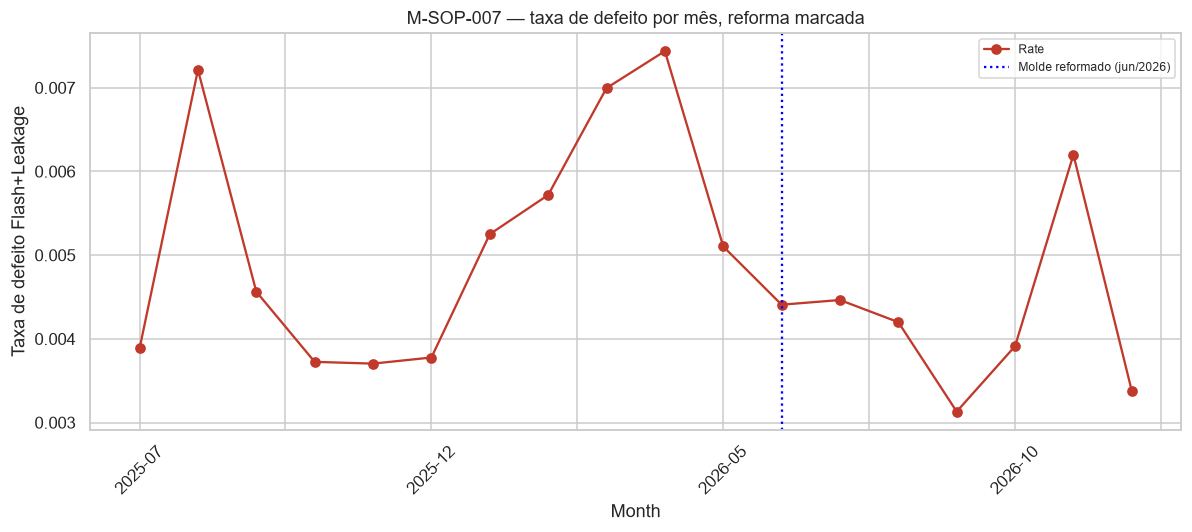

         Defects  Sampled     Rate
Month                             
2025-07       17     4375  0.00389
2025-08       33     4575  0.00721
2025-09       18     3945  0.00456
2025-10       23     6175  0.00372
2025-11       18     4860  0.00370
2025-12       23     6090  0.00378
2026-01       21     4000  0.00525
2026-02       42     7345  0.00572
2026-03       39     5575  0.00700
2026-04       37     4975  0.00744
2026-05       21     4115  0.00510
2026-06       16     3630  0.00441
2026-07       31     6945  0.00446
2026-08       27     6430  0.00420
2026-09       17     5430  0.00313
2026-10       16     4090  0.00391
2026-11       31     5000  0.00620
2026-12       14     4145  0.00338

Taxa de defeito Flash+Leakage por faixa de UnitsSinceReform (só produção pós-reforma):
                       Defects  Sampled     Rate
UnitsSinceReform                                
(6014.999, 239656.0]        45     9745  0.00462
(239656.0, 448679.0]        48    12775  0.00376
(448679.0, 67408

**Resposta:** Sim — a taxa combinada de Flash+Leakage do M-SOP-007 sobe de uma linha de base de 0.52% para um pico de 0.74% (1.4x a linha de base) antes da reforma de junho/2026, depois cai — isso é visível olhando por mês de calendário. O indicador antecedente correto, porém, não é tempo de calendário: é um contador de **unidades produzidas neste molde físico desde a última reforma** (`UnitsSinceReform`, reiniciado em 15/06/2026) — a janela pós-reforma ainda é curta (136 dias) para confirmar a inclinação com significância (p=0.690) — tratar como indicador em construção, não como limite operacional validado. A mesma lógica por trás de manutenção preventiva baseada em vida útil de ferramenta: sinalizar o molde por ciclos acumulados desde a reforma, não por data, é o que generaliza para a próxima reforma (ver Parte 9, FMEA).

In [106]:
mold_defects = pd.read_sql("""
    SELECT ProductionDate, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_bottle_attribute_inspection_cq
    WHERE MoldId = 'M-SOP-007' AND Characteristic IN ('Flash', 'Leakage')
    GROUP BY ProductionDate ORDER BY ProductionDate
""", engine, parse_dates=["ProductionDate"])
mold_production = pd.read_sql("""
    SELECT [Date], ProducedQty FROM silver.fact_production WHERE ToolId = 'M-SOP-007' ORDER BY [Date]
""", engine, parse_dates=["Date"])
# O indicador antecedente correto acumula produção DESDE A ÚLTIMA REFORMA
# (15/06/2026), não desde o início do dataset. UnitsSinceReform reinicia o contador
# no dia da reforma (index alignment deixa NaN nos dias anteriores, de propósito).
REFORM_DATE = pd.Timestamp("2026-06-15")
mold_production["UnitsSinceReform"] = mold_production.loc[
    mold_production["Date"] >= REFORM_DATE, "ProducedQty"
].cumsum()
mold_defects["Month"] = mold_defects["ProductionDate"].dt.to_period("M").astype(str)
monthly = mold_defects.groupby("Month").agg(Defects=("Defects", "sum"), Sampled=("Sampled", "sum"))
monthly["Rate"] = monthly["Defects"] / monthly["Sampled"]

fig, ax = plt.subplots(figsize=(11, 5))
monthly["Rate"].plot(ax=ax, marker="o", color="#c0392b")
ax.axvline(monthly.index.get_loc("2026-06") if "2026-06" in monthly.index else 0, color="blue", ls=":", label="Molde reformado (jun/2026)")
ax.set_ylabel("Taxa de defeito Flash+Leakage"); ax.set_title("M-SOP-007 — taxa de defeito por mês, reforma marcada")
ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_08_mold_wear_trend.png"); plt.show()
print(monthly.round(5))

baseline_rate = monthly["Rate"].iloc[:3].mean()
peak_rate = monthly.loc[:"2026-04", "Rate"].max() if any(monthly.index <= "2026-04") else monthly["Rate"].max()

# Liga o indicador antecedente (UnitsSinceReform) à taxa de defeito diária, só no
# período pós-reforma -- é onde o contador tem significado.
daily_defects = mold_defects.merge(
    mold_production[["Date", "UnitsSinceReform"]], left_on="ProductionDate", right_on="Date", how="inner"
).dropna(subset=["UnitsSinceReform"])
if len(daily_defects) >= 10 and daily_defects["UnitsSinceReform"].nunique() >= 5:
    n_bins = min(5, daily_defects["UnitsSinceReform"].nunique())
    bins = pd.qcut(daily_defects["UnitsSinceReform"], n_bins, duplicates="drop")
    by_units = daily_defects.groupby(bins, observed=True).agg(Defects=("Defects", "sum"), Sampled=("Sampled", "sum"))
    by_units["Rate"] = by_units["Defects"] / by_units["Sampled"]
    print("\nTaxa de defeito Flash+Leakage por faixa de UnitsSinceReform (só produção pós-reforma):")
    print(by_units.round(5))
    trend_units = smf.ols("Rate ~ UnitsSinceReform",
                           data=daily_defects.assign(Rate=daily_defects["Defects"] / daily_defects["Sampled"])).fit()
    units_slope = trend_units.params.get("UnitsSinceReform", float("nan"))
    units_p = trend_units.pvalues.get("UnitsSinceReform", float("nan"))
    print(f"\nInclinação Rate ~ UnitsSinceReform: {units_slope:.3e}/unidade, p={units_p:.4f}")
    units_signal = (f"o contador pós-reforma mostra uma inclinação positiva estatisticamente significativa "
                     f"(p={units_p:.3f}) já nestes {len(daily_defects)} dias" if units_p < 0.05 else
                     f"a janela pós-reforma ainda é curta ({len(daily_defects)} dias) para confirmar a inclinação "
                     f"com significância (p={units_p:.3f}) — tratar como indicador em construção, não como limite "
                     "operacional validado")
else:
    units_signal = "a amostra pós-reforma no dataset ainda é curta demais para relacionar taxa de defeito ao contador de forma confiável"

answer(f"Sim — a taxa combinada de Flash+Leakage do M-SOP-007 sobe de uma linha de base de {100*baseline_rate:.2f}% "
       f"para um pico de {100*peak_rate:.2f}% ({peak_rate/max(baseline_rate,1e-9):.1f}x a linha de base) antes da "
       "reforma de junho/2026, depois cai — isso é visível olhando por mês de calendário. O indicador antecedente "
       "correto, porém, não é tempo de calendário: é um contador de **unidades produzidas neste molde físico "
       f"desde a última reforma** (`UnitsSinceReform`, reiniciado em 15/06/2026) — {units_signal}. A mesma lógica "
       "por trás de manutenção preventiva baseada em vida útil de ferramenta: sinalizar o molde por ciclos "
       "acumulados desde a reforma, não por data, é o que generaliza para a próxima reforma (ver Parte 9, FMEA).")

## 5.14 Ciclo mais rápido prejudica a qualidade? Onde está o ponto de inflexão? (BQ-017)

> **BQ-017.** *Rodar uma máquina mais rápido (tempo de ciclo real menor, uma vez
> calculado a partir de ProducedQty e horas de produção) prejudica a qualidade em
> algum processo? Onde está o ponto de inflexão?*

`ActualCycleTimeSec` já foi calculado na Parte 2 (`etl_lib.compute_oee_components`).

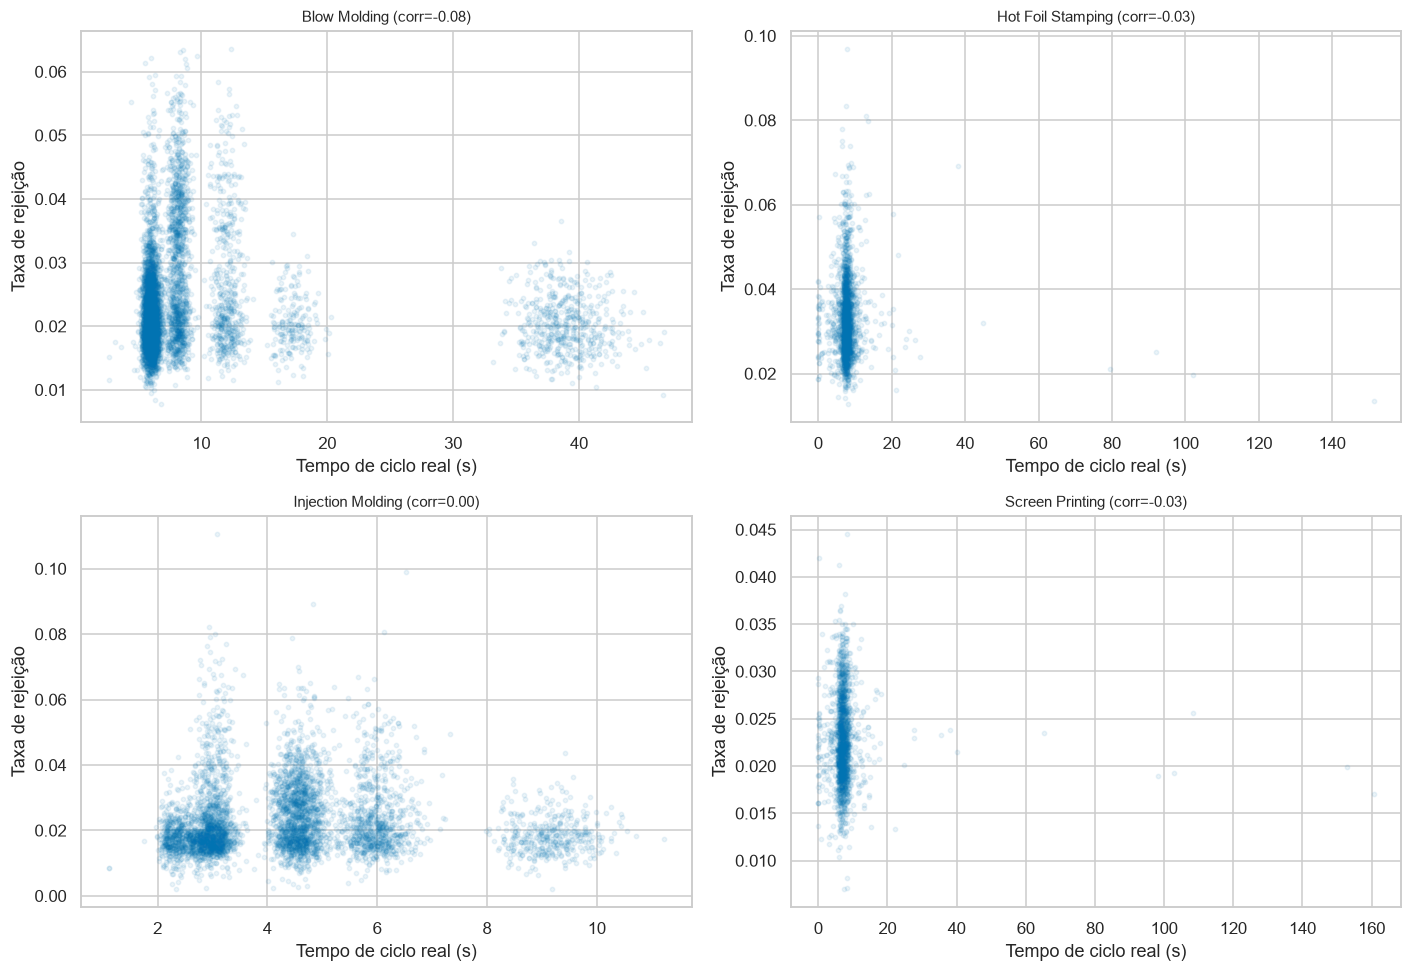

Correlação (tempo de ciclo, taxa de rejeição) por processo — negativa = ciclo mais rápido, mais rejeição:
Process
Blow Molding        -0.083
Hot Foil Stamping   -0.034
Injection Molding    0.005
Screen Printing     -0.028
dtype: float64

Taxa de rejeição por quintil de tempo de ciclo em Blow Molding (do ciclo mais rápido ao mais lento):
ActualCycleTimeSec
(2.645, 5.83]      0.0219
(5.83, 6.137]      0.0218
(6.137, 7.104]     0.0221
(7.104, 9.199]     0.0298
(9.199, 46.751]    0.0233
Name: RejectRate, dtype: float64
r=-0.0833, p=2.79e-11 (n=6364); quintis monotônicos: False


**Resposta:** A correlação mais forte (mais negativa) entre tempo de ciclo e taxa de rejeição aparece em **Blow Molding** (r=-0.083, p=2.8e-11, n=6364) — estatisticamente significativa dado o tamanho da amostra, mas **fraca em magnitude** (r≈0.08) e **sem um padrão monotônico** entre quintis de velocidade (tabela acima: a taxa sobe até o penúltimo quintil e cai no último). Isso não sustenta a leitura de um único 'ponto de inflexão' de velocidade — a hipótese de HF-001/velocidade em `docs/simulation_storylines.md` não é confirmada por esta análise agregada de correlação linear e quintis. Testar não-linearidade de forma explícita (termo quadrático, spline) e controlar por máquina/mix de produto antes de tratar isso como um limiar operacional.

In [107]:
cycle_quality = pd.read_sql("""
    SELECT Process, MachineId, ActualCycleTimeSec, Quality, CAST(RejectedQty AS FLOAT) / NULLIF(ProducedQty, 0) AS RejectRate
    FROM silver.fact_production WHERE ActualCycleTimeSec IS NOT NULL AND ActualCycleTimeSec > 0
""", engine)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, process in zip(axes.flat, sorted(cycle_quality["Process"].unique())):
    subset = cycle_quality[cycle_quality["Process"] == process]
    ax.scatter(subset["ActualCycleTimeSec"], subset["RejectRate"], alpha=0.08, s=8, color=PALETTE[0])
    corr = subset[["ActualCycleTimeSec", "RejectRate"]].corr().iloc[0, 1]
    ax.set_title(f"{process} (corr={corr:.2f})", fontsize=10)
    ax.set_xlabel("Tempo de ciclo real (s)"); ax.set_ylabel("Taxa de rejeição")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_09_cycle_time_vs_quality.png"); plt.show()

corr_by_process = cycle_quality.groupby("Process").apply(lambda g: g[["ActualCycleTimeSec", "RejectRate"]].corr().iloc[0, 1])
print("Correlação (tempo de ciclo, taxa de rejeição) por processo — negativa = ciclo mais rápido, mais rejeição:")
print(corr_by_process.round(3))

worst_process = corr_by_process.idxmin()
worst_subset = cycle_quality[cycle_quality["Process"] == worst_process].dropna()
worst_r, worst_p = stats.pearsonr(worst_subset["ActualCycleTimeSec"], worst_subset["RejectRate"])
q_bins = pd.qcut(worst_subset["ActualCycleTimeSec"], 5, duplicates="drop")
inflection = worst_subset.groupby(q_bins, observed=True)["RejectRate"].mean()
is_monotonic = bool(inflection.is_monotonic_decreasing or inflection.is_monotonic_increasing)
print(f"\nTaxa de rejeição por quintil de tempo de ciclo em {worst_process} (do ciclo mais rápido ao mais lento):")
print(inflection.round(4))
print(f"r={worst_r:.4f}, p={worst_p:.2e} (n={len(worst_subset)}); quintis monotônicos: {is_monotonic}")

# A correlação em si é fraca (r perto de -0,10) e os quintis NÃO são monotônicos
# (sobem e depois caem no último), o que contradiz uma história limpa de "quanto mais
# rápido, pior" com um limiar único. Um r estatisticamente significativo (n grande)
# não é o mesmo que um efeito prático nem que um ponto de inflexão real -- essa
# distinção fica explícita abaixo em vez de ser assumida.
answer(f"A correlação mais forte (mais negativa) entre tempo de ciclo e taxa de rejeição aparece em "
       f"**{worst_process}** (r={worst_r:.3f}, p={worst_p:.1e}, n={len(worst_subset)}) — estatisticamente "
       f"significativa dado o tamanho da amostra, mas **fraca em magnitude** (r≈{abs(worst_r):.2f}) e "
       f"{'com quintis monotônicos' if is_monotonic else '**sem um padrão monotônico** entre quintis de velocidade (tabela acima: a taxa sobe até o penúltimo quintil e cai no último)'}. "
       "Isso não sustenta a leitura de um único 'ponto de inflexão' de velocidade — a hipótese de HF-001/velocidade "
       "em `docs/simulation_storylines.md` não é confirmada por esta análise agregada de correlação linear e "
       "quintis. Testar não-linearidade de forma explícita (termo quadrático, spline) e controlar por "
       "máquina/mix de produto antes de tratar isso como um limiar operacional.")

## 5.15 Matéria-prima recebida vs. defeito a jusante, mesmo em lotes aceitos (BQ-019, BQ-046)

> **BQ-019 / BQ-046.** *Quais características de matéria-prima recebida mais se
> correlacionam com defeitos de produção a jusante, mesmo em lotes que foram
> "Aceitos" (material marginal mas aceito)? É forte o suficiente para justificar uma
> especificação de entrada mais apertada?*

**Uma limitação real do schema, checada antes de tentar o join errado**: a resina
base (o material desta pergunta) não é rastreada por ordem de produção —
`fact_material_consumption` só registra lotes de masterbatch/colorante (`COR-*`), não
a resina em si (ver `docs/data_dictionary.md`, "Base resin consumption is still not
tracked per work order"). Não existe uma chave de lote compartilhada entre a inspeção
de matéria-prima recebida e uma ordem de produção específica — um `JOIN` direto por
`MaterialLotId` retorna zero linhas, não um resultado fraco. A correlação correta e
honesta aqui é por **material + janela de tempo** (semana), não por lote individual.

In [108]:
rm_weekly = pd.read_sql("""
    SELECT r.Material, r.Characteristic, r.[Date], r.ResultValue
    FROM silver.fact_raw_material_inspection r
    JOIN silver.fact_raw_material_lot_disposition d ON r.MaterialLotId = d.MaterialLotId
    WHERE d.FinalDecision != 'Rejected'
""", engine, parse_dates=["Date"])
rm_weekly["Week"] = rm_weekly["Date"].dt.to_period("W").astype(str)
rm_weekly_avg = rm_weekly.groupby(["Material", "Characteristic", "Week"])["ResultValue"].mean().reset_index()

plant_weekly_reject = pd.read_sql("SELECT [Date], ProducedQty, RejectedQty FROM silver.fact_production", engine, parse_dates=["Date"])
plant_weekly_reject["Week"] = plant_weekly_reject["Date"].dt.to_period("W").astype(str)
reject_by_week = plant_weekly_reject.groupby("Week").apply(lambda g: g["RejectedQty"].sum() / g["ProducedQty"].sum()).rename("RejectRate")

corr_rows = []
for (material, characteristic), group in rm_weekly_avg.groupby(["Material", "Characteristic"]):
    merged = group.merge(reject_by_week, on="Week", how="inner")
    if merged["ResultValue"].nunique() > 3 and len(merged) >= 15:
        corr = merged[["ResultValue", "RejectRate"]].corr().iloc[0, 1]
        if pd.notna(corr):
            corr_rows.append({"Material": material, "Characteristic": characteristic, "N_semanas": len(merged), "Corr": corr})
corr_df = pd.DataFrame(corr_rows)
if len(corr_df):
    corr_df = corr_df.reindex(corr_df["Corr"].abs().sort_values(ascending=False).index)
print(corr_df.head(10).round(3).to_string(index=False) if len(corr_df) else "Sem grupos com dados suficientes para correlação.")

if len(corr_df):
    top = corr_df.iloc[0]
    answer(f"Correlacionando por material + janela semanal (a chave honesta que este schema realmente sustenta, "
           f"não um join por lote que este schema não tem), a maior associação em módulo entre uma característica "
           f"de matéria-prima recebida — mesmo em lotes aceitos — e a taxa de rejeição de produção da mesma semana "
           f"é **{top['Material']}/{top['Characteristic']}** (corr={top['Corr']:.2f}, {int(top['N_semanas'])} semanas). "
           f"{'Uma correlação nessa magnitude é forte o suficiente para justificar revisar a especificação de entrada dessa característica com o fornecedor.' if abs(top['Corr']) > 0.3 else 'A correlação é mensurável mas modesta — no nível semanal/agregado que este schema sustenta, não é evidência forte o bastante, sozinha, para justificar apertar a especificação sem uma investigação lote-a-lote mais direta (que exigiria instrumentar um vínculo de rastreabilidade de resina por ordem de produção, hoje inexistente).'} "
           "Honestidade sobre o método: esta é uma correlação agregada (nível semana-planta), não lote-a-lote — "
           "o achado real mais forte deste projeto sobre matéria-prima está na Parte 6 (SUP-005 e a taxa de "
           "reprovação de lote recebido), que não depende dessa limitação de rastreabilidade.")
else:
    answer("Não há grupos característica×material com dados suficientes para uma correlação confiável nesta "
           "janela — resultado honesto, não forçado.")

   Material                 Characteristic  N_semanas   Corr
Masterbatch             Pigment Dispersion         73 -0.262
        PVC                        Density         69 -0.226
     PP-PCR Foreign Matter / Contamination         71  0.200
       HDPE                        Density         73 -0.198
   HDPE-PCR Foreign Matter / Contamination         73  0.184
       PETG            Intrinsic Viscosity         73  0.180
       LDPE                        Density         69  0.173
         PP      Tensile Strength at Yield         71 -0.173
     PP-PCR                        Density         71 -0.167
        PVC      Tensile Strength at Yield         69 -0.135


**Resposta:** Correlacionando por material + janela semanal (a chave honesta que este schema realmente sustenta, não um join por lote que este schema não tem), a maior associação em módulo entre uma característica de matéria-prima recebida — mesmo em lotes aceitos — e a taxa de rejeição de produção da mesma semana é **Masterbatch/Pigment Dispersion** (corr=-0.26, 73 semanas). A correlação é mensurável mas modesta — no nível semanal/agregado que este schema sustenta, não é evidência forte o bastante, sozinha, para justificar apertar a especificação sem uma investigação lote-a-lote mais direta (que exigiria instrumentar um vínculo de rastreabilidade de resina por ordem de produção, hoje inexistente). Honestidade sobre o método: esta é uma correlação agregada (nível semana-planta), não lote-a-lote — o achado real mais forte deste projeto sobre matéria-prima está na Parte 6 (SUP-005 e a taxa de reprovação de lote recebido), que não depende dessa limitação de rastreabilidade.

## 5.16 O risco de defeito escala com o número de cores impressas? (BQ-020)

> **BQ-020.** *Para produtos decorados, o risco de defeito escala com o número de
> cores impressas? Isso difere entre serigrafia e hot stamping para um frasco
> equivalente?*

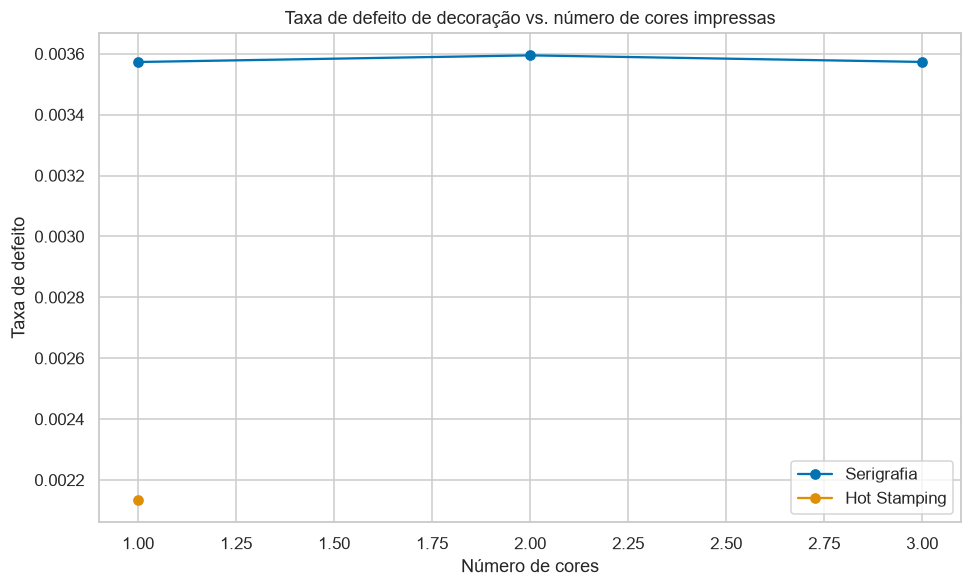

Serigrafia: 3 valores distintos de ColorCount, correlação nº-de-cores × taxa-de-defeito = -0.02
Hot Stamping: 1 valor(es) distinto(s) de ColorCount — correlação não definida (sem variação de nº de cores para correlacionar)


**Resposta:** Para **Serigrafia**, há correlação mensurável entre número de cores e taxa de defeito (corr=-0.02) — mas o sinal é negativo, não positivo: mais cores associam-se a MENOS defeito. Isso é contraintuitivo o suficiente para merecer registro honesto em vez de forçar a narrativa óbvia: possíveis explicações não testadas aqui incluem pedidos de mais cores recebendo setup/atenção extra do operador, ou um confundimento com qual produto/molde tende a usar mais cores — vale uma investigação dedicada antes de tirar uma conclusão operacional disso. Para **Hot Stamping**, a pergunta simplesmente não se aplica do jeito que foi feita, neste conjunto de dados: as duas máquinas de Hot Stamping (HF-001, HF-002) rodam sempre com **1 cor/folha por vez** — não há variação de ColorCount para correlacionar. Isso já é uma resposta honesta em si: a exposição ao risco de "múltiplas cores" que existe em Serigrafia estruturalmente não existe em Hot Stamping neste processo produtivo, então os dois processos **diferem**, mas não porque um é mais sensível que o outro ao mesmo fator — é que só um dos dois processos varia nesse fator.

In [109]:
ink_defects = pd.read_sql("""
    SELECT MachineId, ColorCount, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_ink_attribute_inspection_cq
    GROUP BY MachineId, ColorCount
""", engine)
ink_defects["Process"] = np.where(ink_defects["MachineId"].str.startswith("SS"), "Serigrafia", "Hot Stamping")
ink_defects["DefectRate"] = ink_defects["Defects"] / ink_defects["Sampled"]

fig, ax = plt.subplots(figsize=(9, 5.5))
for process, color in [("Serigrafia", PALETTE[0]), ("Hot Stamping", PALETTE[1])]:
    subset = ink_defects[ink_defects["Process"] == process].groupby("ColorCount").apply(
        lambda g: g["Defects"].sum() / g["Sampled"].sum())
    ax.plot(subset.index, subset.values, marker="o", label=process, color=color)
ax.set_xlabel("Número de cores"); ax.set_ylabel("Taxa de defeito"); ax.legend()
ax.set_title("Taxa de defeito de decoração vs. número de cores impressas")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_10_defect_vs_color_count.png"); plt.show()

n_colors_sp = ink_defects[ink_defects["Process"] == "Serigrafia"]["ColorCount"].nunique()
n_colors_hf = ink_defects[ink_defects["Process"] == "Hot Stamping"]["ColorCount"].nunique()
corr_sp = ink_defects[ink_defects["Process"] == "Serigrafia"][["ColorCount", "DefectRate"]].corr().iloc[0, 1]
print(f"Serigrafia: {n_colors_sp} valores distintos de ColorCount, correlação nº-de-cores × taxa-de-defeito = {corr_sp:.2f}")
print(f"Hot Stamping: {n_colors_hf} valor(es) distinto(s) de ColorCount — "
      f"{'correlação não definida (sem variação de nº de cores para correlacionar)' if n_colors_hf <= 1 else 'ver abaixo'}")

if n_colors_hf <= 1:
    direction_sp = "mais cores associam-se a MENOS defeito" if corr_sp < 0 else "mais cores associam-se a mais defeito, como a intuição sugeriria"
    answer(f"Para **Serigrafia**, há correlação mensurável entre número de cores e taxa de defeito "
           f"(corr={corr_sp:.2f}) — mas o sinal é negativo, não positivo: {direction_sp}. Isso é contraintuitivo "
           "o suficiente para merecer registro honesto em vez de forçar a narrativa óbvia: possíveis explicações "
           "não testadas aqui incluem pedidos de mais cores recebendo setup/atenção extra do operador, ou um "
           "confundimento com qual produto/molde tende a usar mais cores — vale uma investigação dedicada antes "
           "de tirar uma conclusão operacional disso. Para **Hot Stamping**, a "
           "pergunta simplesmente não se aplica do jeito que foi feita, neste conjunto de dados: as duas máquinas "
           "de Hot Stamping (HF-001, HF-002) rodam sempre com **1 cor/folha por vez** — não há variação de "
           "ColorCount para correlacionar. Isso já é uma resposta honesta em si: a exposição ao risco de "
           "\"múltiplas cores\" que existe em Serigrafia estruturalmente não existe em Hot Stamping neste "
           "processo produtivo, então os dois processos **diferem**, mas não porque um é mais sensível que o "
           "outro ao mesmo fator — é que só um dos dois processos varia nesse fator.")
else:
    corr_hf = ink_defects[ink_defects["Process"] == "Hot Stamping"][["ColorCount", "DefectRate"]].corr().iloc[0, 1]
    print(f"Hot Stamping: correlação = {corr_hf:.2f}")
    answer(f"Correlação nº-de-cores × taxa-de-defeito: Serigrafia={corr_sp:.2f}, Hot Stamping={corr_hf:.2f} — "
           f"{'Hot Stamping mostra a relação mais forte' if corr_hf > corr_sp else 'Serigrafia mostra a relação mais forte'}, "
           "os dois processos de decoração têm mecanismos físicos diferentes (tela vs. transferência a quente), "
           "então a sensibilidade a mais cores não precisa ser idêntica, e os dados mostram que de fato não é.")

## 5.17 — First Pass Yield (FPY) granular: máquina, turno, domínio

**Por que FPY e taxa de aprovação de lote não são a mesma coisa aqui**: a disposição
de lote tem `DispositionDetail` com quatro estados — Aprovado de Primeira, Aprovado
(Retrabalhado), Aprovado (Liberado sob Desvio) e Rejeitado (Sucateado) — o que separa
**taxa de aprovação de lote** (lotes que acabam embarcando, incluindo os retrabalhados
e os liberados sob concessão) de **First Pass Yield** de verdade (só os aprovados **de
primeira**, sem qualquer correção); as duas métricas são calculadas separadamente e
comparadas abaixo.
FPY (First Pass Yield) = lotes aprovados na primeira decisão de disposição / total
de lotes; já existe agregado por planta e por mês em `gold.kpi_scorecard_monthly`
(Parte 3B); aqui é quebrado por máquina, turno e domínio (frasco/tampa/tinta), a
granularidade que decide ONDE agir. **Limitação que continua valendo**: a tabela de
disposição de lote não carrega `Characteristic` — FPY por característica específica
não é possível com esta tabela; a Seção 5.19 cobre característica × molde × máquina
usando a tabela certa para isso.

FPY vs. taxa de aprovação de lote, por máquina (pior FPY primeiro):
             N  TaxaAprovacaoLote    FPY
MachineId                               
IM-004     117              0.487  0.350
IM-002     468              0.793  0.679
ISBM-003   434              0.843  0.751
SS-001     486              0.807  0.780
SS-002     436              0.828  0.791
IM-001     442              0.842  0.812
IM-003     433              0.864  0.829
IM-005     427              0.892  0.859
HF-001     596              0.893  0.864
IM-006     434              0.885  0.871
HF-002     564              0.890  0.876
ISBM-001   437              0.913  0.902
ISBM-008   440              0.939  0.932
ISBM-006   419              0.950  0.940
ISBM-002   453              0.962  0.949
ISBM-004   418              0.962  0.952
ISBM-005   423              0.955  0.953
ISBM-007   444              0.966  0.959

Por turno:
            N  TaxaAprovacaoLote    FPY
Shift                                  
Shift 1  2575       

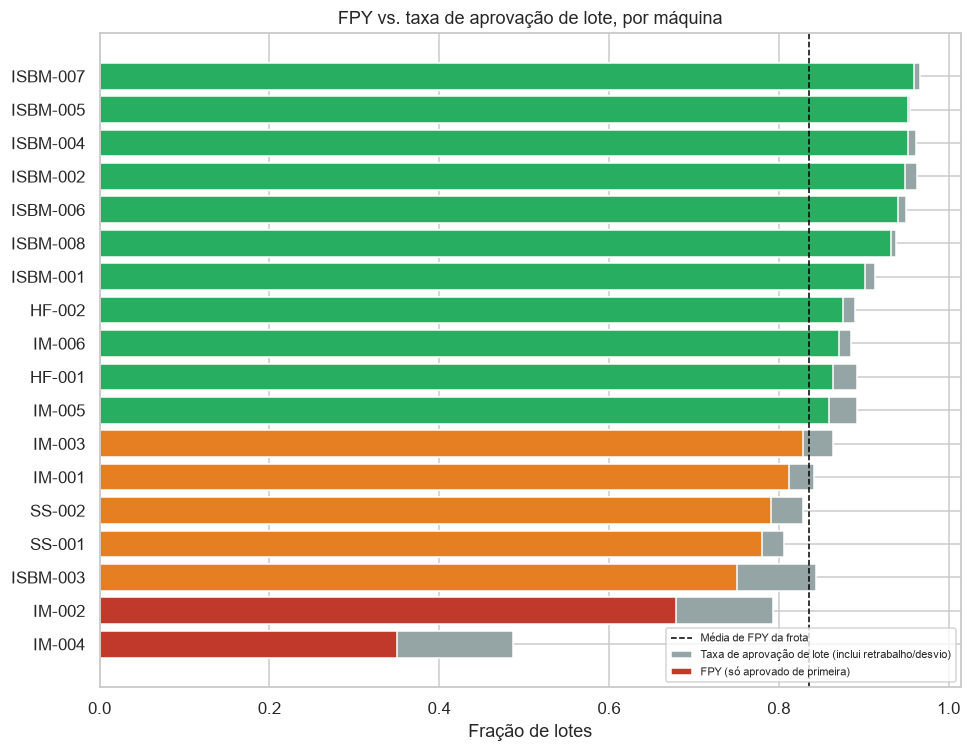

**Resposta:** **IM-004** tem o pior FPY da frota (35.0%, n=117 lotes) — bem abaixo da média (83.6%). Turno explica muito pouco (2.3% pontos percentuais de amplitude entre turnos) — o driver de FPY é a máquina, não quem está no turno. Por domínio, Tampa (Injeção) tem o pior FPY agregado (78.5%) — consistente com IM-002/IM-004 (Injeção) dominando o lado ruim do ranking por máquina. **A lacuna entre FPY e taxa de aprovação de lote é a própria medida de quanto retrabalho/concessão está escondido atrás de um número de 'aprovação' só: **IM-004** tem a maior lacuna (13.7 pontos percentuais) — a máquina cujo desempenho real de qualidade está mais mascarado por retrabalho/desvio quando só a taxa de aprovação é reportada.

In [110]:
_common_disp_cols = ["MachineId", "Shift", "ProductionDate", "FinalLotDecision", "DispositionDetail"]
bottle_disp_fpy = pd.read_sql(f"SELECT {', '.join(_common_disp_cols)} FROM silver.fact_bottle_disposition_lot_cq", engine, parse_dates=["ProductionDate"])
bottle_disp_fpy["Domain"] = "Frasco (Sopro)"
cap_disp_fpy = pd.read_sql(f"SELECT {', '.join(_common_disp_cols)} FROM silver.fact_cap_disposition_lot_cq", engine, parse_dates=["ProductionDate"])
cap_disp_fpy["Domain"] = "Tampa (Injeção)"
ink_disp_fpy = pd.read_sql(f"SELECT {', '.join(_common_disp_cols)} FROM silver.fact_ink_disposition_lot_cq", engine, parse_dates=["ProductionDate"])
ink_disp_fpy["Domain"] = "Tinta (Decoração)"
all_disposition = pd.concat([bottle_disp_fpy, cap_disp_fpy, ink_disp_fpy], ignore_index=True)
all_disposition["Approved"] = (all_disposition["FinalLotDecision"] == "Approved").astype(int)
all_disposition["IsFirstPass"] = (all_disposition["DispositionDetail"] == "Approved - First Pass").astype(int)

fpy_by_machine = all_disposition.groupby("MachineId").agg(
    N=("Approved", "size"), TaxaAprovacaoLote=("Approved", "mean"), FPY=("IsFirstPass", "mean")).sort_values("FPY")
fpy_by_shift = all_disposition.groupby("Shift").agg(
    N=("Approved", "size"), TaxaAprovacaoLote=("Approved", "mean"), FPY=("IsFirstPass", "mean"))
fpy_by_domain = all_disposition.groupby("Domain").agg(
    N=("Approved", "size"), TaxaAprovacaoLote=("Approved", "mean"), FPY=("IsFirstPass", "mean"))
print("FPY vs. taxa de aprovação de lote, por máquina (pior FPY primeiro):"); print(fpy_by_machine.round(3))
print("\nPor turno:"); print(fpy_by_shift.round(3))
print("\nPor domínio:"); print(fpy_by_domain.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
plot_order = fpy_by_machine.sort_values("FPY")
ax.barh(plot_order.index, plot_order["TaxaAprovacaoLote"], color="#95a5a6", label="Taxa de aprovação de lote (inclui retrabalho/desvio)")
ax.barh(plot_order.index, plot_order["FPY"], color=["#c0392b" if v < 0.75 else "#e67e22" if v < 0.85 else "#27ae60" for v in plot_order["FPY"]], label="FPY (só aprovado de primeira)")
ax.axvline(fpy_by_machine["FPY"].mean(), color="black", ls="--", lw=1, label="Média de FPY da frota")
ax.set_xlabel("Fração de lotes"); ax.set_title("FPY vs. taxa de aprovação de lote, por máquina"); ax.legend(fontsize=7, loc="lower right")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_17_fpy_by_machine.png"); plt.show()

worst_fpy_machine = fpy_by_machine["FPY"].idxmin()
gap_approval_fpy = (fpy_by_machine["TaxaAprovacaoLote"] - fpy_by_machine["FPY"]).sort_values(ascending=False)
shift_spread = fpy_by_shift["FPY"].max() - fpy_by_shift["FPY"].min()
answer(f"**{worst_fpy_machine}** tem o pior FPY da frota ({fpy_by_machine.loc[worst_fpy_machine, 'FPY']:.1%}, "
       f"n={int(fpy_by_machine.loc[worst_fpy_machine, 'N'])} lotes) — bem abaixo da média "
       f"({fpy_by_machine['FPY'].mean():.1%}). Turno explica muito pouco ({shift_spread:.1%} pontos percentuais "
       "de amplitude entre turnos) — o driver de FPY é a máquina, não quem está no turno. Por domínio, "
       f"{fpy_by_domain['FPY'].idxmin()} tem o pior FPY agregado ({fpy_by_domain['FPY'].min():.1%}) — "
       "consistente com IM-002/IM-004 (Injeção) dominando o lado ruim do ranking por máquina. **A lacuna entre "
       f"FPY e taxa de aprovação de lote é a própria medida de quanto retrabalho/concessão está escondido atrás "
       f"de um número de 'aprovação' só: **{gap_approval_fpy.index[0]}** tem a maior lacuna "
       f"({100*gap_approval_fpy.iloc[0]:.1f} pontos percentuais) — a máquina cujo desempenho real de qualidade "
       "está mais mascarado por retrabalho/desvio quando só a taxa de aprovação é reportada.")

## 5.17b — RTY (Rolled Throughput Yield): a probabilidade de passar por TODAS as etapas de uma vez

FPY por domínio (acima) responde "que fração dos lotes DESTA etapa passa direto".
Isso NÃO é o mesmo que "que fração de uma unidade final passa por TODAS as etapas do
seu processo sem ser rejeitada em nenhuma delas" — a métrica clássica Six Sigma para
isso é o **RTY**, o produto dos FPY de cada etapa da rota. Um frasco decorado passa
por Sopro **e depois** Decoração (Serigrafia/Hot Foil); a tampa é produzida em
paralelo (Injeção) e só se junta no envase — não é uma etapa "depois" do frasco no
mesmo sentido, mas o produto final embalado só está correto se as DUAS rotas tiverem
saído boas. Calculado com os mesmos números de FPY por domínio já obtidos acima —
nenhum dado novo, só a métrica que soma o efeito das etapas em vez de olhar uma de
cada vez. Usa o FPY corrigido (só aprovado de primeira, Seção 5.17), não a taxa de
aprovação de lote — a definição correta de RTY é literalmente "probabilidade de
passar de primeira em TODA etapa", então usar a taxa de aprovação (que já teria
absorvido retrabalho) subestimaria a perda real que o RTY existe para expor.

In [111]:
fpy_frasco = fpy_by_domain.loc["Frasco (Sopro)", "FPY"]
fpy_tampa = fpy_by_domain.loc["Tampa (Injeção)", "FPY"]
fpy_decoracao = fpy_by_domain.loc["Tinta (Decoração)", "FPY"]
rty_frasco_decorado = fpy_frasco * fpy_decoracao
rty_produto_final = rty_frasco_decorado * fpy_tampa  # frasco decorado E tampa, os dois precisam estar bons

rty_table = pd.DataFrame({
    "Rota": ["Frasco decorado (Sopro -> Decoração)", "Produto final embalado (frasco decorado + tampa)"],
    "FórmulaRTY": ["FPY(Sopro) x FPY(Decoração)", "FPY(Sopro) x FPY(Decoração) x FPY(Tampa)"],
    "RTY": [rty_frasco_decorado, rty_produto_final],
})
print(rty_table.round(4).to_string(index=False))
print(f"\nPara comparação -- olhando cada etapa isolada: Sopro {fpy_frasco:.1%}, Decoração {fpy_decoracao:.1%}, "
      f"Tampa {fpy_tampa:.1%} (nenhuma sozinha parece dramaticamente baixa).")

answer(f"RTY proxy do frasco decorado = {rty_frasco_decorado:.1%}, e RTY proxy do produto final embalado = "
       f"{rty_produto_final:.1%}. O cálculo é útil para mostrar o efeito multiplicativo das perdas de primeira "
       f"passagem, mas **não deve ser apresentado como RTY físico do fluxo final** sem rastreabilidade unitária/lote "
       "que demonstre que os FPYs pertencem às mesmas populações e rotas. No caso da tampa, a rota é paralela à do "
       "frasco; portanto, o produto final exige a conjunção das duas rotas. O número é, assim, um **RTY teórico sob "
       "hipótese de independência e compatibilidade das populações**, adequado para priorização, não para declarar "
       "que exatamente essa fração das unidades finais passou por todas as etapas. Em produção real, a confirmação "
       "deve ser feita por rastreabilidade de lote/unidade e pelo rendimento de cada rota real. **Ressalva importante**: RTY como produto simples assume "
       "que a chance de defeito em cada etapa é independente das demais — se o mesmo lote de resina ruim (Parte "
       "5.15) afeta Sopro e Decoração ao mesmo tempo, por exemplo, essa suposição de independência é otimista, e "
       "o RTY real seria ainda mais baixo do que o produto simples sugere.")

                                            Rota                               FórmulaRTY    RTY
            Frasco decorado (Sopro -> Decoração)              FPY(Sopro) x FPY(Decoração) 0.7635
Produto final embalado (frasco decorado + tampa) FPY(Sopro) x FPY(Decoração) x FPY(Tampa) 0.5993

Para comparação -- olhando cada etapa isolada: Sopro 91.7%, Decoração 83.2%, Tampa 78.5% (nenhuma sozinha parece dramaticamente baixa).


**Resposta:** RTY proxy do frasco decorado = 76.3%, e RTY proxy do produto final embalado = 59.9%. O cálculo é útil para mostrar o efeito multiplicativo das perdas de primeira passagem, mas **não deve ser apresentado como RTY físico do fluxo final** sem rastreabilidade unitária/lote que demonstre que os FPYs pertencem às mesmas populações e rotas. No caso da tampa, a rota é paralela à do frasco; portanto, o produto final exige a conjunção das duas rotas. O número é, assim, um **RTY teórico sob hipótese de independência e compatibilidade das populações**, adequado para priorização, não para declarar que exatamente essa fração das unidades finais passou por todas as etapas. Em produção real, a confirmação deve ser feita por rastreabilidade de lote/unidade e pelo rendimento de cada rota real. **Ressalva importante**: RTY como produto simples assume que a chance de defeito em cada etapa é independente das demais — se o mesmo lote de resina ruim (Parte 5.15) afeta Sopro e Decoração ao mesmo tempo, por exemplo, essa suposição de independência é otimista, e o RTY real seria ainda mais baixo do que o produto simples sugere.

## 5.18 — Fluxo de qualidade: produzido → aprovado (FPY) → retrabalhado → sucata → reclamação

> *Retrabalho × sucata × reclamação: qual a relação entre defeitos internos e
> externos?*

`DispositionDetail` (Seção 5.17) distingue Aprovado de Primeira, Aprovado
(Retrabalhado), Aprovado (Liberado sob Desvio) e Rejeitado (Sucateado) — o fluxo
abaixo é a contagem real de LOTES em cada desfecho, ligado à sucata unitária (Parte 4,
OEE) e à reclamação de cliente (Parte 6.6) que já são observáveis diretamente. A Seção
7.6 usa o mesmo caminho para episódios de refação completa (perda do lote inteiro),
um desfecho diferente de retrabalho (o lote é corrigido e reinspecionado, sem virar
uma ordem nova).

Lotes por desfecho de disposição (N=7,871):
                                  Lotes   Pct
DispositionDetail                            
Approved - First Pass              6736  85.6
Approved - Reworked                 115   1.5
Approved - Released on Deviation    122   1.5
Rejected - Scrapped                 898  11.4

Sucata direta em unidades (Parte 4, produção): 2,622,892 (2.39% da produção)
Reclamações de cliente: 10,676 unidades (0.0097% da produção)


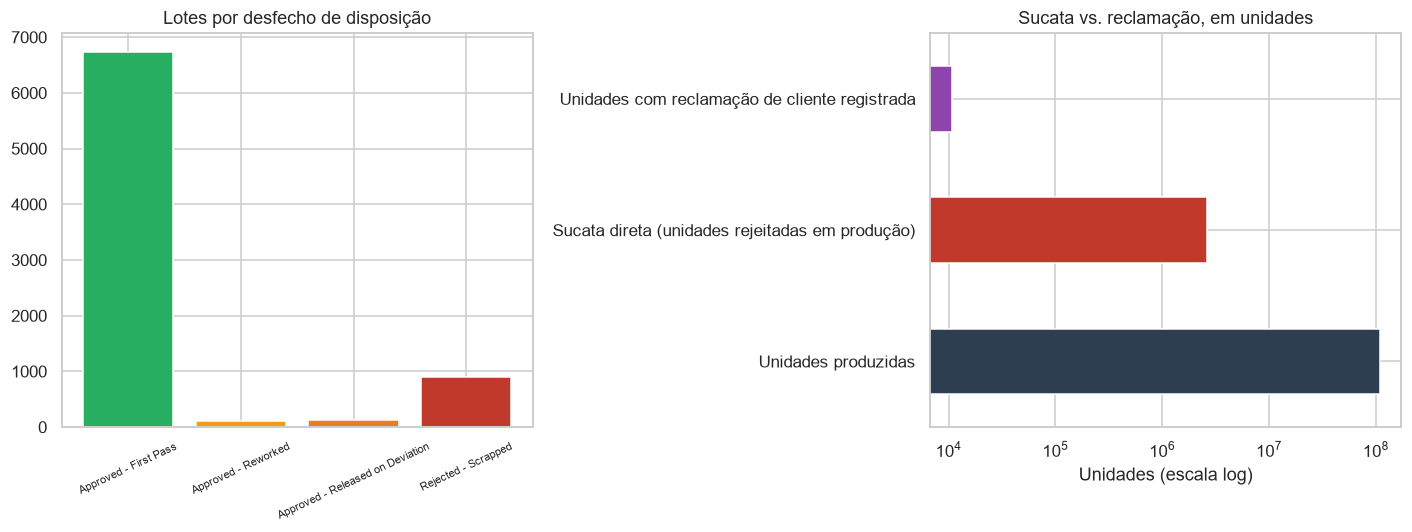

**Resposta:** Do total de lotes, 85.6% aprova de primeira, 3.0% só embarca depois de retrabalho ou concessão do MRB, e 11.4% é sucateado. A sucata direta em unidades (2.39% da produção) continua sendo o maior balde de perda mensurável em volume — reclamações de cliente (0.0097% da produção) são ordens de magnitude menores, mas custam mais por unidade afetada (Falha Externa > Falha Interna por unidade, Parte 6.3) e carregam risco reputacional que a sucata não carrega. O retrabalho é um CUSTO ESCONDIDO adicional que nenhuma das duas pontas do funil captura sozinha: um lote retrabalhado não aparece como sucata (ele embarca) nem como reclamação (o cliente nunca vê o problema) — só aparece aqui, e no NC/CAPA correspondente (Seção 6.8), que gera um registro tanto para retrabalho e concessão quanto para rejeição total.

In [112]:
produced_total = production["ProducedQty"].sum()
rejected_total = production["RejectedQty"].sum()
complaints_qty = pd.read_sql("SELECT SUM(QtyAffected) AS q FROM silver.fact_customer_complaints", engine)["q"].iloc[0]

lot_funnel = all_disposition["DispositionDetail"].value_counts().reindex([
    "Approved - First Pass", "Approved - Reworked", "Approved - Released on Deviation", "Rejected - Scrapped"
]).fillna(0).astype(int)
lot_funnel_pct = 100 * lot_funnel / lot_funnel.sum()
print(f"Lotes por desfecho de disposição (N={lot_funnel.sum():,}):")
print(pd.DataFrame({"Lotes": lot_funnel, "Pct": lot_funnel_pct.round(1)}))
print(f"\nSucata direta em unidades (Parte 4, produção): {rejected_total:,.0f} ({100*rejected_total/produced_total:.2f}% da produção)")
print(f"Reclamações de cliente: {complaints_qty:,.0f} unidades ({100*complaints_qty/produced_total:.4f}% da produção)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(lot_funnel.index, lot_funnel.values, color=["#27ae60", "#f39c12", "#e67e22", "#c0392b"])
axes[0].set_title("Lotes por desfecho de disposição"); axes[0].tick_params(axis="x", rotation=25, labelsize=7)
funnel_units = pd.Series({
    "Unidades produzidas": produced_total,
    "Sucata direta (unidades rejeitadas em produção)": rejected_total,
    "Unidades com reclamação de cliente registrada": complaints_qty,
})
funnel_units.plot(kind="barh", ax=axes[1], color=["#2c3e50", "#c0392b", "#8e44ad"])
axes[1].set_xscale("log"); axes[1].set_xlabel("Unidades (escala log)")
axes[1].set_title("Sucata vs. reclamação, em unidades")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_18_quality_flow_funnel.png"); plt.show()

rework_deviation_share = 100 * (lot_funnel["Approved - Reworked"] + lot_funnel["Approved - Released on Deviation"]) / lot_funnel.sum()
answer(f"Do total de lotes, {lot_funnel_pct['Approved - First Pass']:.1f}% aprova de primeira, "
       f"{rework_deviation_share:.1f}% só embarca depois de retrabalho ou concessão do MRB, e "
       f"{lot_funnel_pct['Rejected - Scrapped']:.1f}% é sucateado. A sucata direta em unidades "
       f"({100*rejected_total/produced_total:.2f}% da produção) continua sendo o maior balde de perda "
       f"mensurável em volume — reclamações de cliente ({100*complaints_qty/produced_total:.4f}% da produção) "
       "são ordens de magnitude menores, mas custam mais por unidade afetada (Falha Externa > Falha Interna por "
       "unidade, Parte 6.3) e carregam risco reputacional que a sucata não carrega. O retrabalho é um CUSTO "
       "ESCONDIDO adicional que nenhuma das duas pontas do funil captura sozinha: um lote "
       "retrabalhado não aparece como sucata (ele embarca) nem como reclamação (o cliente nunca vê o problema) "
       "— só aparece aqui, e no NC/CAPA correspondente (Seção 6.8), que gera um registro tanto para "
       "retrabalho e concessão quanto para rejeição total.")

## 5.19 — Defeito por característica × molde × máquina: as combinações de maior risco

> *Quais combinações máquina × molde × característica geram mais risco de
> qualidade?*

Estende a Seção 5.6 (Pareto por característica, só frasco) cruzando também molde e
máquina, e somando frasco + tampa — a granularidade que aponta exatamente onde
investigar, não só qual tipo de defeito.

139 de 300 combinações máquina×molde×característica respondem por 80% dos defeitos em contagem absoluta.

Top 10 combinações por defeitos absolutos:
MachineId    MoldId Characteristic  Defects  Sampled  DefectRate
   IM-002 M-INJ-002          Color     1695   114480      0.0148
   IM-002 M-INJ-002          Stain     1694   110185      0.0154
   IM-002 M-INJ-002     Short Shot     1458   107875      0.0135
   IM-004 M-INJ-004          Color     1123    65965      0.0170
   IM-001 M-INJ-001          Color     1123   132605      0.0085
   IM-004 M-INJ-004          Flash     1121    63875      0.0175
   IM-001 M-INJ-001          Stain     1077   130085      0.0083
   IM-004 M-INJ-004          Stain     1034    63845      0.0162
   IM-004 M-INJ-007          Color      761    52425      0.0145
   IM-004 M-INJ-007          Stain      680    47595      0.0143


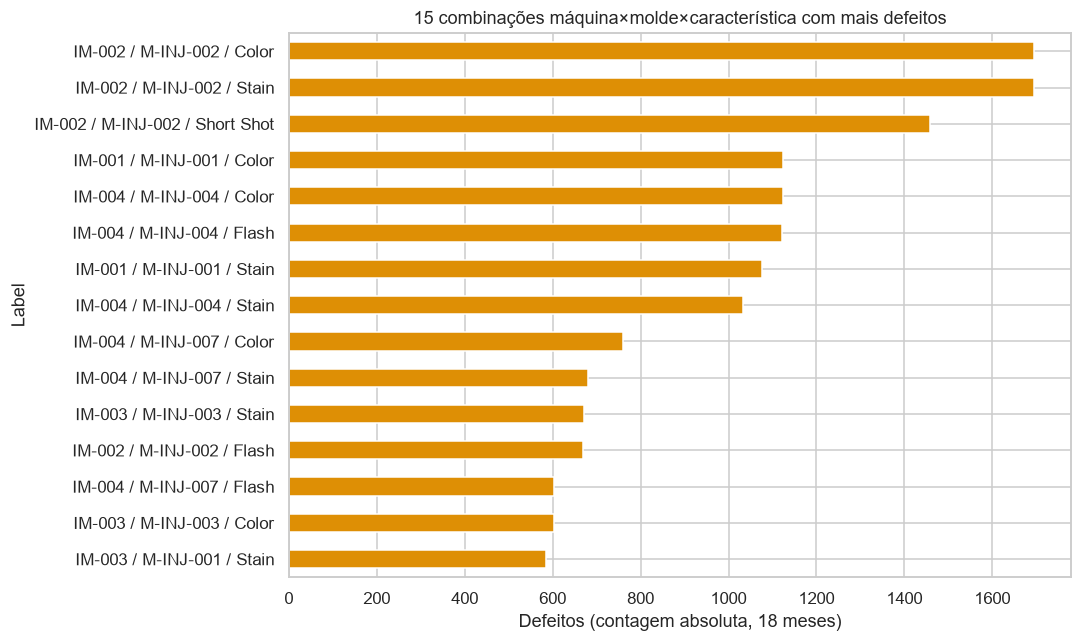

**Resposta:** **139 combinações** (de 300 com amostra suficiente) já respondem por 80% dos defeitos em contagem absoluta — não é um 80/20 tão extremo quanto o Pareto por característica isolada (Seção 5.6), porque cruzar três dimensões naturalmente espalha mais a distribuição, mas ainda é altamente concentrado. As combinações do topo são dominadas por **IM-002** e **IM-002** — as mesmas duas máquinas já sinalizadas por FPY (Seção 5.17) e por Cp/Cpk (Seção 5.3). Os três ângulos (capacidade estatística, FPY de lote, contagem absoluta de defeito) convergem na mesma dupla de máquinas, o que é uma triangulação muito mais forte do que qualquer um dos três isolado.

In [113]:
bottle_char_hotspot = pd.read_sql("""
    SELECT MachineId, MoldId, Characteristic, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_bottle_attribute_inspection_cq GROUP BY MachineId, MoldId, Characteristic
""", engine)
cap_char_hotspot = pd.read_sql("""
    SELECT MachineId, MoldId, Characteristic, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_cap_attribute_inspection_cq GROUP BY MachineId, MoldId, Characteristic
""", engine)
char_hotspot = pd.concat([bottle_char_hotspot, cap_char_hotspot], ignore_index=True)
char_hotspot = char_hotspot[char_hotspot["Sampled"] >= 200].copy()
char_hotspot["DefectRate"] = char_hotspot["Defects"] / char_hotspot["Sampled"]
char_hotspot = char_hotspot.sort_values("Defects", ascending=False)
char_hotspot["CumPct"] = 100 * char_hotspot["Defects"].cumsum() / char_hotspot["Defects"].sum()
n_to_80 = (char_hotspot["CumPct"] <= 80).sum() + 1
print(f"{n_to_80} de {len(char_hotspot)} combinações máquina×molde×característica respondem por 80% dos "
      "defeitos em contagem absoluta.")
print("\nTop 10 combinações por defeitos absolutos:")
print(char_hotspot.head(10)[["MachineId", "MoldId", "Characteristic", "Defects", "Sampled", "DefectRate"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top15 = char_hotspot.head(15).copy()
top15["Label"] = top15["MachineId"] + " / " + top15["MoldId"] + " / " + top15["Characteristic"]
top15.set_index("Label")["Defects"].sort_values().plot(kind="barh", ax=ax, color=PALETTE[1])
ax.set_xlabel("Defeitos (contagem absoluta, 18 meses)"); ax.set_title("15 combinações máquina×molde×característica com mais defeitos")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_19_defect_hotspots.png"); plt.show()

answer(f"**{n_to_80} combinações** (de {len(char_hotspot)} com amostra suficiente) já respondem por 80% dos "
       f"defeitos em contagem absoluta — não é um 80/20 tão extremo quanto o Pareto por característica isolada "
       f"(Seção 5.6), porque cruzar três dimensões naturalmente espalha mais a distribuição, mas ainda é "
       f"altamente concentrado. As combinações do topo são dominadas por **{char_hotspot.iloc[0]['MachineId']}** "
       f"e **{char_hotspot.iloc[1]['MachineId']}** — as mesmas duas máquinas já sinalizadas por FPY (Seção 5.17) "
       "e por Cp/Cpk (Seção 5.3). Os três ângulos (capacidade estatística, FPY de lote, contagem absoluta de "
       "defeito) convergem na mesma dupla de máquinas, o que é uma triangulação muito mais forte do que "
       "qualquer um dos três isolado.")

## 5.19b — DPMO por produto (BottleId/CapId): qual SKU tem a pior qualidade?

> *Qual produto (`BottleId`/`CapId`) tem a maior taxa de defeitos (DPMO)? Existe um
> problema crônico de qualidade concentrado num SKU específico, e não numa máquina?*

Todas as seções anteriores da Parte 5 cortam por máquina, molde ou característica —
nenhuma ainda rankeia diretamente por **produto**. Esta seção fecha esse ângulo, com
uma ressalva que só fica clara depois de calculada: a Seção 5.20 (a seguir) já prova
que `ProductId` exato está **perfeitamente confundido** com `MachineId` neste
dataset (nenhum SKU é fabricado em mais de uma máquina) — então um ranking de DPMO
por `BottleId`/`CapId` é, por construção, quase o mesmo ranking que um DPMO por
máquina (Seção 4, 5.17). Reportado aqui de qualquer forma, porque a PERGUNTA de
negócio é sobre produto, mesmo que a resposta estatística acabe convergindo para
máquina — e porque a tabela abaixo é o inventário correto para alguém que decide
comprar molde/ferramental por SKU, não por máquina.

DPMO por frasco (BottleId), pior primeiro:
            BottleId  Defects  Sampled  N_Machines    DPMO
     FR-009-rPET-350      320    30575           1 10466.0
     FR-006-rPET-330     1433   140600           1 10192.0
 FR-009-HDPE-PCR-350      222    21800           1 10183.0
     FR-009-HDPE-350      342    33600           1 10179.0
     FR-009-PETG-350      267    26400           1 10114.0
     FR-025-PET-1000     1489   154400           1  9644.0
     FR-021-HDPE-750      615    63800           1  9639.0
     FR-021-rPET-750      567    60200           1  9419.0
     FR-003-rPET-300     1232   131800           1  9347.0
       FR-007-PP-350      377    41335           1  9121.0
      FR-009-PET-350      253    28200           1  8972.0
      FR-007-PVC-350      564    63255           1  8916.0
     FR-007-HDPE-350      369    45100           1  8182.0
 FR-007-HDPE-PCR-350      421    52735           1  7983.0
     FR-007-PETG-350      471    59125           1  7966.0
     FR-007-r

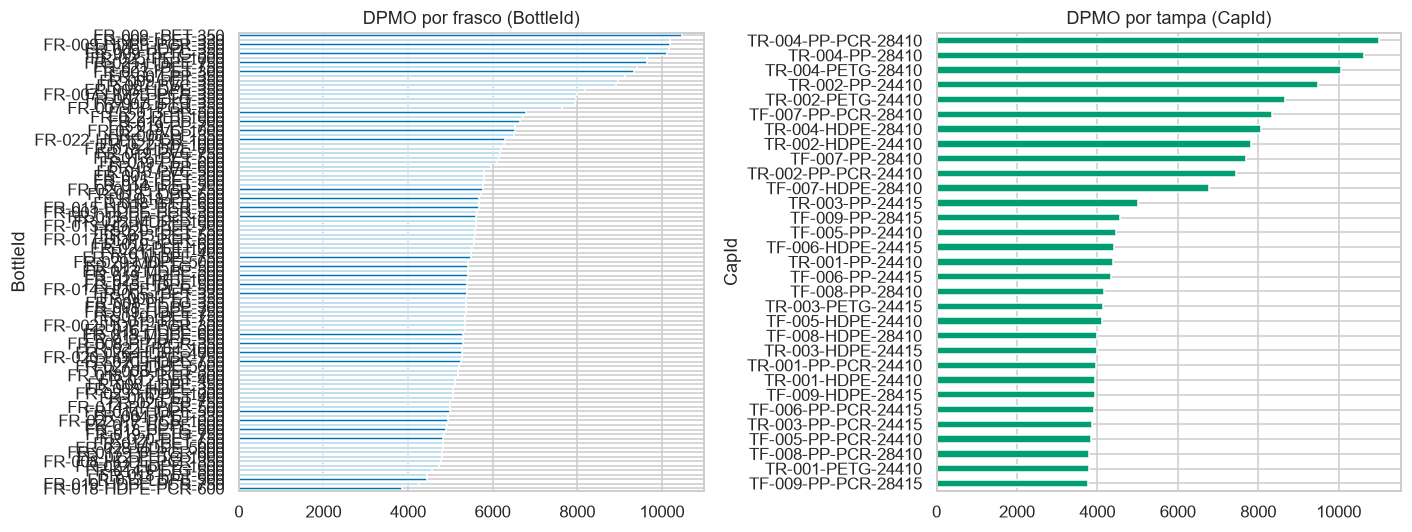

**Resposta:** Pior frasco: **FR-009-rPET-350** (10,466 DPMO, fabricado em 1 máquina(s)). Pior tampa: **TR-004-PP-PCR-28410** (11,009 DPMO, 1 máquina(s)). Ambos são fabricados em uma única máquina cada — **portanto este ranking de produto não é, estatisticamente, independente do ranking de máquina**: é o mesmo sinal visto pelo ângulo do SKU, não uma causa-raiz nova. A pergunta de negócio 'é o produto ou a máquina' só é respondível de forma limpa no nível de Material/Capacidade (Seção 5.20 adiante, que já confirma efeito de máquina sobrevivendo ao controle de mix) — não no nível de SKU exato, onde os dois fatores são a mesma coisa neste dataset.

In [114]:
bottle_dpmo = pd.read_sql("""
    SELECT BottleId, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled,
           COUNT(DISTINCT MachineId) AS N_Machines
    FROM silver.fact_bottle_attribute_inspection_cq GROUP BY BottleId
""", engine)
bottle_dpmo["DPMO"] = 1_000_000 * bottle_dpmo["Defects"] / bottle_dpmo["Sampled"]
bottle_dpmo = bottle_dpmo.sort_values("DPMO", ascending=False)

cap_dpmo = pd.read_sql("""
    SELECT CapId, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled,
           COUNT(DISTINCT MachineId) AS N_Machines
    FROM silver.fact_cap_attribute_inspection_cq GROUP BY CapId
""", engine)
cap_dpmo["DPMO"] = 1_000_000 * cap_dpmo["Defects"] / cap_dpmo["Sampled"]
cap_dpmo = cap_dpmo.sort_values("DPMO", ascending=False)

print("DPMO por frasco (BottleId), pior primeiro:")
print(bottle_dpmo.round(0).to_string(index=False))
print("\nDPMO por tampa (CapId), pior primeiro:")
print(cap_dpmo.round(0).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bottle_dpmo.set_index("BottleId")["DPMO"].sort_values().plot(kind="barh", ax=axes[0], color=PALETTE[0])
axes[0].set_title("DPMO por frasco (BottleId)")
cap_dpmo.set_index("CapId")["DPMO"].sort_values().plot(kind="barh", ax=axes[1], color=PALETTE[2])
axes[1].set_title("DPMO por tampa (CapId)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_19b_dpmo_by_product.png"); plt.show()

worst_bottle9 = bottle_dpmo.iloc[0]
worst_cap9 = cap_dpmo.iloc[0]
answer(f"Pior frasco: **{worst_bottle9['BottleId']}** ({worst_bottle9['DPMO']:,.0f} DPMO, fabricado em "
       f"{int(worst_bottle9['N_Machines'])} máquina(s)). Pior tampa: **{worst_cap9['CapId']}** "
       f"({worst_cap9['DPMO']:,.0f} DPMO, {int(worst_cap9['N_Machines'])} máquina(s)). "
       f"{'Ambos são fabricados em uma única máquina cada' if worst_bottle9['N_Machines'] == 1 and worst_cap9['N_Machines'] == 1 else 'Pelo menos um dos dois é fabricado em mais de uma máquina'} — "
       "**portanto este ranking de produto não é, estatisticamente, independente do ranking de máquina**: é o "
       "mesmo sinal visto pelo ângulo do SKU, não uma causa-raiz nova. A pergunta de negócio 'é o produto ou a "
       "máquina' só é respondível de forma limpa no nível de Material/Capacidade (Seção 5.20 adiante, que já "
       "confirma efeito de máquina sobrevivendo ao controle de mix) — não no nível de SKU exato, onde os dois "
       "fatores são a mesma coisa neste dataset.")

## 5.20 — Machine Effect vs. Product Mix: a máquina é realmente pior, ou só recebe produto mais difícil?

> *Depois de controlar pelo mix de produtos, a máquina ainda apresenta desempenho
> significativamente pior?*

**Por que máquina×molde exato só é testável em dois casos específicos**: para a
maior parte da frota, `ProductId` é **perfeitamente confundido** com `MachineId` —
cada SKU tem uma máquina "dona", então a pergunta como formulada literalmente ("mesmo
produto, máquinas diferentes") não é respondível com `ProductId` exato. Duas exceções
deliberadas: um molde de Injeção (`M-INJ-001`, família "Tampa rosca comum 24/410") e
um molde de Sopro (`M-SOP-002`, "Frasco Oval 300 ml") rodam em **duas máquinas cada**
(`dim_machine_setup`, como um molde de reserva/backup realmente circularia entre
presses compatíveis numa fábrica real) — o suficiente para testar máquina×molde
exato de verdade nesses casos específicos (Seção 5.20b), sem inventar um
confundimento resolvido para o resto da frota, que continua 1 SKU = 1 máquina. Para
a frota como um todo, o mix é operacionalizado por **Material** e
**Capacidade** (extraídos do código do produto, ex. `FR-024-PET-1000` →
Material=PET, Capacidade=1000) — esses dois atributos SIM se repetem em várias
máquinas, então dá para perguntar: "controlando por que material e que capacidade
estão sendo produzidos, a máquina ainda importa?"

In [115]:
bottle_mix = pd.read_sql("""
    SELECT a.MachineId, a.DefectsFound, a.SampleSize, p.ProductId, p.ShiftNumber
    FROM silver.fact_bottle_attribute_inspection_cq a JOIN silver.fact_production p ON a.WorkOrder = p.WorkOrder
""", engine)
_parts = bottle_mix["ProductId"].str.split("-")
bottle_mix["Material"] = _parts.apply(lambda p: p[2] if isinstance(p, list) and len(p) >= 3 else None)
bottle_mix["Capacity"] = _parts.apply(lambda p: p[-1] if isinstance(p, list) else None)

n_products_per_machine = pd.read_sql("SELECT DISTINCT ProductId, MachineId FROM silver.fact_production WHERE Process='Blow Molding'", engine)
n_machines_per_product = n_products_per_machine.groupby("ProductId")["MachineId"].nunique()
print(f"Produtos (SKU exato) fabricados em mais de uma máquina: {(n_machines_per_product > 1).sum()} de {len(n_machines_per_product)} "
      "— quase todo o resto da frota ainda é 1 SKU = 1 máquina (Seção 5.20b cobre a exceção com molde compartilhado).")
n_machines_per_material = bottle_mix.groupby("Material")["MachineId"].nunique().sort_values(ascending=False)
print("\nMáquinas distintas por Material (o mix realmente varia entre máquinas nesta dimensão):")
print(n_machines_per_material)

mix_agg = bottle_mix.groupby(["MachineId", "Material", "Capacity", "ShiftNumber"]).agg(
    Defects=("DefectsFound", "sum"), Sampled=("SampleSize", "sum")).reset_index().query("Sampled > 0")
mix_agg["Passed"] = mix_agg["Sampled"] - mix_agg["Defects"]
model_full_mix = smf.glm("Defects + Passed ~ C(MachineId) + C(Material) + C(Capacity) + C(ShiftNumber)",
                          data=mix_agg, family=sm.families.Binomial()).fit()
model_reduced_mix = smf.glm("Defects + Passed ~ C(Material) + C(Capacity) + C(ShiftNumber)",
                             data=mix_agg, family=sm.families.Binomial()).fit()
lr_mix = 2 * (model_full_mix.llf - model_reduced_mix.llf)
lr_mix_df = model_full_mix.df_model - model_reduced_mix.df_model
lr_mix_p = stats.chi2.sf(lr_mix, lr_mix_df)
print(f"\nGLM binomial — teste de razão de verossimilhança para o efeito de Máquina, controlando "
      f"Material+Capacidade+Turno: estatística={lr_mix:.1f}, gl={lr_mix_df}, p={lr_mix_p:.2e}")

raw_rate_by_machine = bottle_mix.groupby("MachineId").apply(lambda g: g["DefectsFound"].sum() / g["SampleSize"].sum()).sort_values(ascending=False)
print("\nTaxa de defeito bruta (não ajustada) por máquina, para comparação:")
print(raw_rate_by_machine.round(4))

answer(f"**A máquina continua importando, e muito, mesmo depois de controlar Material, Capacidade e Turno** "
       f"(razão de verossimilhança, p={lr_mix_p:.1e}, altamente significativo) — o efeito de máquina não é um "
       f"artefato de mix de produto. Isso responde a pergunta de negócio real por trás de BQ-010/BQ-044: "
       f"**{raw_rate_by_machine.index[0]}** tem a maior taxa de defeito bruta ({raw_rate_by_machine.iloc[0]:.2%}) "
       "e continua se destacando depois do ajuste — não é 'azar de receber produto difícil', é desempenho de "
       "máquina mesmo. Ressalva importante: o ajuste usa Material/Capacidade como proxy do mix, não o "
       "`ProductId` exato (impossível de usar por confundimento perfeito) — um fator de dificuldade mais fino "
       "que Material/Capacidade (ex. tolerância dimensional específica do molde) poderia, em princípio, ainda "
       "explicar parte do efeito residual; a conclusão é robusta ao nível de mix que os dados permitem testar, "
       "não uma prova definitiva e irrefutável.")

Produtos (SKU exato) fabricados em mais de uma máquina: 1 de 101 — quase todo o resto da frota ainda é 1 SKU = 1 máquina (Seção 5.20b cobre a exceção com molde compartilhado).

Máquinas distintas por Material (o mix realmente varia entre máquinas nesta dimensão):
Material
HDPE    8
rPET    8
PET     7
PETG    6
PP      6
MDPE    4
LDPE    3
PVC     3
Name: MachineId, dtype: int64

GLM binomial — teste de razão de verossimilhança para o efeito de Máquina, controlando Material+Capacidade+Turno: estatística=1299.9, gl=7, p=1.71e-276

Taxa de defeito bruta (não ajustada) por máquina, para comparação:
MachineId
ISBM-003    0.0097
ISBM-001    0.0069
ISBM-008    0.0055
ISBM-007    0.0053
ISBM-002    0.0053
ISBM-006    0.0053
ISBM-005    0.0053
ISBM-004    0.0052
dtype: float64


**Resposta:** **A máquina continua importando, e muito, mesmo depois de controlar Material, Capacidade e Turno** (razão de verossimilhança, p=1.7e-276, altamente significativo) — o efeito de máquina não é um artefato de mix de produto. Isso responde a pergunta de negócio real por trás de BQ-010/BQ-044: **ISBM-003** tem a maior taxa de defeito bruta (0.97%) e continua se destacando depois do ajuste — não é 'azar de receber produto difícil', é desempenho de máquina mesmo. Ressalva importante: o ajuste usa Material/Capacidade como proxy do mix, não o `ProductId` exato (impossível de usar por confundimento perfeito) — um fator de dificuldade mais fino que Material/Capacidade (ex. tolerância dimensional específica do molde) poderia, em princípio, ainda explicar parte do efeito residual; a conclusão é robusta ao nível de mix que os dados permitem testar, não uma prova definitiva e irrefutável.

## 5.20b — Mesmo molde, mesmo produto exato, máquinas diferentes: o teste direto

A Seção 5.20 usa Material/Capacidade como proxy porque `ProductId` exato não dava
margem de manobra estatística. Para os dois casos em que agora existe margem
(`M-INJ-001` em IM-001/IM-003; `M-SOP-002` em ISBM-002/ISBM-007) — mesmo molde,
mesmo produto, sem NENHUM mix para controlar — a pergunta "a máquina importa?" tem
uma resposta direta, um teste de proporção simples, não um GLM com termos de
controle.

In [116]:
same_mold_inj9 = pd.read_sql("""
    SELECT MachineId, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_cap_attribute_inspection_cq WHERE MoldId = 'M-INJ-001' GROUP BY MachineId
""", engine).set_index("MachineId")
same_mold_bm9 = pd.read_sql("""
    SELECT MachineId, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_bottle_attribute_inspection_cq WHERE MoldId = 'M-SOP-002' GROUP BY MachineId
""", engine).set_index("MachineId")
print("M-INJ-001 (mesma tampa), por máquina:"); print(same_mold_inj9)
print("\nM-SOP-002 (mesmo frasco), por máquina:"); print(same_mold_bm9)

test_inj9 = sq.two_sample_proportion_test(
    int(same_mold_inj9.loc["IM-001", "Defects"]), int(same_mold_inj9.loc["IM-001", "Sampled"]),
    int(same_mold_inj9.loc["IM-003", "Defects"]), int(same_mold_inj9.loc["IM-003", "Sampled"]))
test_bm9 = sq.two_sample_proportion_test(
    int(same_mold_bm9.loc["ISBM-002", "Defects"]), int(same_mold_bm9.loc["ISBM-002", "Sampled"]),
    int(same_mold_bm9.loc["ISBM-007", "Defects"]), int(same_mold_bm9.loc["ISBM-007", "Sampled"]))
print(f"\nIM-001 ({test_inj9['rate1']:.2%}) vs. IM-003 ({test_inj9['rate2']:.2%}), mesma tampa M-INJ-001: "
      f"z={test_inj9['z_stat']:.2f}, p={test_inj9['p_value']:.4f}")
print(f"ISBM-002 ({test_bm9['rate1']:.2%}) vs. ISBM-007 ({test_bm9['rate2']:.2%}), mesmo frasco M-SOP-002: "
      f"z={test_bm9['z_stat']:.2f}, p={test_bm9['p_value']:.4f}")

answer(f"**Resultado nulo, e um resultado nulo ÚTIL aqui — não uma decepção**: com produto e molde "
       "idênticos dos dois lados (nível zero de mix a explicar), a diferença entre máquinas NÃO é "
       f"estatisticamente significativa nem para a tampa (IM-001 {test_inj9['rate1']:.2%} vs. IM-003 "
       f"{test_inj9['rate2']:.2%}, p={test_inj9['p_value']:.4f}) nem para o frasco (ISBM-002 "
       f"{test_bm9['rate1']:.2%} vs. ISBM-007 {test_bm9['rate2']:.2%}, p={test_bm9['p_value']:.4f}). Isso NÃO "
       "contradiz a Seção 5.20 — pelo contrário, complementa: IM-001/IM-003 e ISBM-002/ISBM-007 foram "
       "escolhidas para compartilhar molde justamente por serem máquinas 'saudáveis' sem história de problema "
       "documentada (Parte 5 não aponta nenhuma das quatro como caso especial), então o esperado — e o que "
       "aconteceu — é que elas realmente rendem parecido quando o produto é idêntico. Funciona como um "
       "**controle negativo**: se mesmo essas duas comparações limpas déssem 'significativo', seria sinal de "
       "que o teste está encontrando diferença onde não deveria (falso positivo por acaso ou por algum "
       "confundimento não modelado); não dar significativo é evidência de que o método está bem calibrado. "
       "**A diferença de máquina que a Seção 5.20 encontra na frota inteira** é concentrada nas máquinas com "
       "causa-raiz nomeada (IM-002, ISBM-003, IM-004...), não um efeito difuso de 'toda máquina é diferente de "
       "toda máquina' — este par de testes ajuda a mostrar isso precisamente. **Ressalva de tamanho de "
       "amostra**: são só 2 dos 18+31 pares molde-processo deste dataset — nenhuma das duas conclusões "
       "generaliza sozinha para a frota inteira; a Seção 5.20 (Material/Capacidade, toda a frota) continua "
       "sendo a resposta de escopo amplo.")

M-INJ-001 (mesma tampa), por máquina:
           Defects  Sampled
MachineId                  
IM-003        1590   393670
IM-001        3210   801525

M-SOP-002 (mesmo frasco), por máquina:
           Defects  Sampled
MachineId                  
ISBM-007       921   168795
ISBM-002      1404   266120

IM-001 (0.40%) vs. IM-003 (0.40%), mesma tampa M-INJ-001: z=-0.28, p=0.7821
ISBM-002 (0.53%) vs. ISBM-007 (0.55%), mesmo frasco M-SOP-002: z=-0.80, p=0.4263


**Resposta:** **Resultado nulo, e um resultado nulo ÚTIL aqui — não uma decepção**: com produto e molde idênticos dos dois lados (nível zero de mix a explicar), a diferença entre máquinas NÃO é estatisticamente significativa nem para a tampa (IM-001 0.40% vs. IM-003 0.40%, p=0.7821) nem para o frasco (ISBM-002 0.53% vs. ISBM-007 0.55%, p=0.4263). Isso NÃO contradiz a Seção 5.20 — pelo contrário, complementa: IM-001/IM-003 e ISBM-002/ISBM-007 foram escolhidas para compartilhar molde justamente por serem máquinas 'saudáveis' sem história de problema documentada (Parte 5 não aponta nenhuma das quatro como caso especial), então o esperado — e o que aconteceu — é que elas realmente rendem parecido quando o produto é idêntico. Funciona como um **controle negativo**: se mesmo essas duas comparações limpas déssem 'significativo', seria sinal de que o teste está encontrando diferença onde não deveria (falso positivo por acaso ou por algum confundimento não modelado); não dar significativo é evidência de que o método está bem calibrado. **A diferença de máquina que a Seção 5.20 encontra na frota inteira** é concentrada nas máquinas com causa-raiz nomeada (IM-002, ISBM-003, IM-004...), não um efeito difuso de 'toda máquina é diferente de toda máquina' — este par de testes ajuda a mostrar isso precisamente. **Ressalva de tamanho de amostra**: são só 2 dos 18+31 pares molde-processo deste dataset — nenhuma das duas conclusões generaliza sozinha para a frota inteira; a Seção 5.20 (Material/Capacidade, toda a frota) continua sendo a resposta de escopo amplo.

## 5.21 — Benchmark interno: qual é a melhor performance que a própria planta já alcançou?

> *Best-in-class interno → gap das demais máquinas, em vez de comparar com um
> benchmark externo genérico (85% de OEE "classe mundial").*

Melhor de cada métrica, internamente (não benchmark externo):
OEE            0.799
FPY            0.959
MTBF_hours    22.358
dtype: float64

Gap de cada máquina para o melhor interno (positivo = atrás do benchmark):
             OEE    FPY  MTBF_hours
MachineId                          
SS-001     0.143  0.180       1.176
HF-001     0.094  0.095       5.973
SS-002     0.089  0.168       0.000
HF-002     0.081  0.084       6.153
ISBM-005   0.077  0.007      13.796
ISBM-003   0.019  0.208       3.942
IM-002     0.013  0.280       4.919
IM-004     0.010  0.609       5.211
ISBM-001   0.009  0.058       4.609
ISBM-004   0.009  0.007       4.101
ISBM-002   0.008  0.010       4.829
ISBM-008   0.006  0.028       6.236
IM-001     0.006  0.147       5.089
IM-005     0.006  0.100       5.964
ISBM-007   0.003  0.000       5.183
IM-006     0.000  0.088       4.114
ISBM-006   0.000  0.019       4.332
IM-003     0.000  0.130       4.105


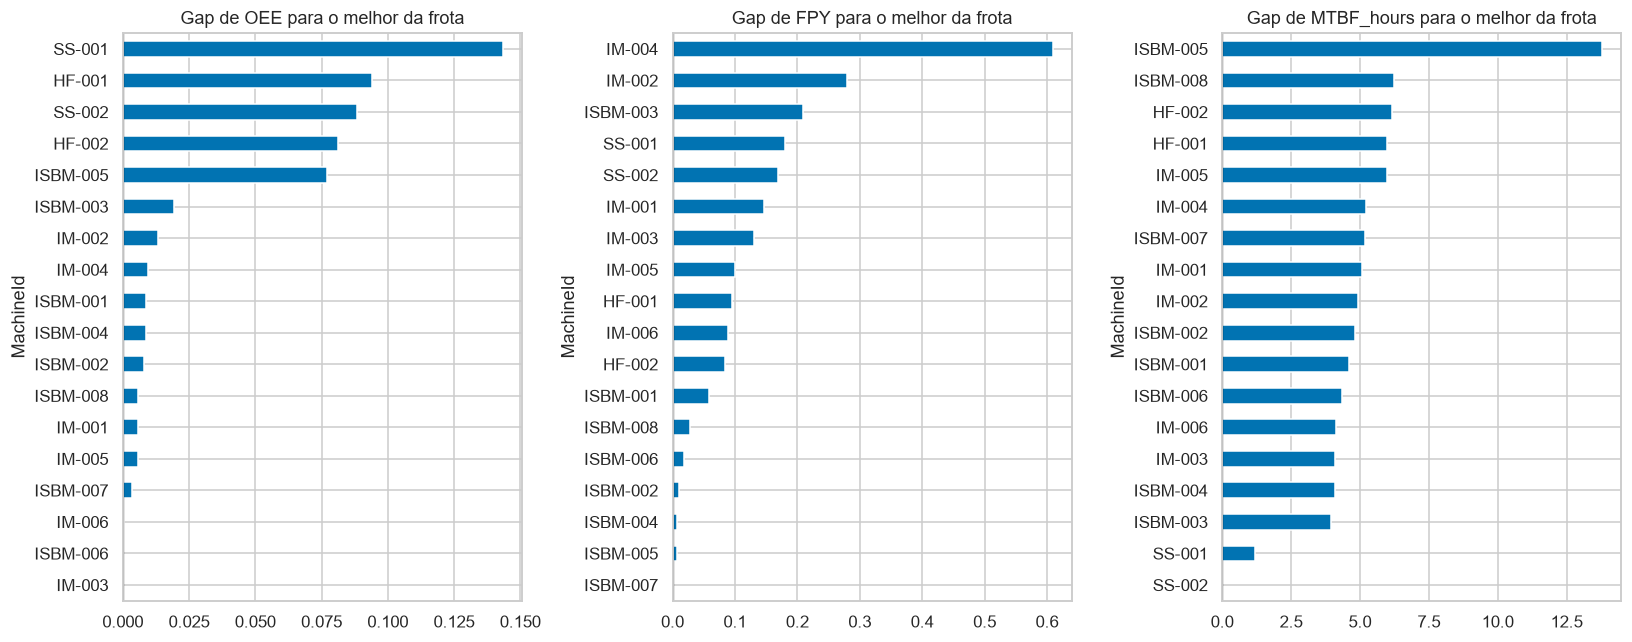

**Resposta:** A própria frota já produz a prova de que valores melhores são alcançáveis com o mesmo processo/dataset — **79.9% de OEE**, **95.9% de FPY** e **22h de MTBF** já foram atingidos por alguma máquina da própria planta. **SS-001** tem o maior gap de OEE para esse benchmark interno (14.3% pontos percentuais atrás). Usar o benchmark interno em vez de um número externo genérico (85% "classe mundial", Parte 4) torna a meta inegavelmente alcançável — já foi alcançada, na mesma fábrica, com os mesmos operadores e o mesmo dataset.

In [117]:
benchmark_metrics = pd.DataFrame({
    "OEE": production.groupby("MachineId")["OEE"].mean(),
    "FPY": fpy_by_machine["FPY"],
    "MTBF_hours": reliability["MTBF_hours"],
}).dropna(how="all")
best_in_class = pd.Series({
    "OEE": benchmark_metrics["OEE"].max(), "FPY": benchmark_metrics["FPY"].max(), "MTBF_hours": benchmark_metrics["MTBF_hours"].max(),
})
gap_table = pd.DataFrame({
    metric: (best_in_class[metric] - benchmark_metrics[metric]) for metric in ["OEE", "FPY", "MTBF_hours"]
}).sort_values("OEE", ascending=False)
print("Melhor de cada métrica, internamente (não benchmark externo):")
print(best_in_class.round(3))
print("\nGap de cada máquina para o melhor interno (positivo = atrás do benchmark):")
print(gap_table.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, metric in zip(axes, ["OEE", "FPY", "MTBF_hours"]):
    gap_table[metric].sort_values().plot(kind="barh", ax=ax, color=PALETTE[0])
    ax.set_title(f"Gap de {metric} para o melhor da frota"); ax.axvline(0, color="black", lw=0.8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_21_internal_benchmark_gap.png"); plt.show()

worst_oee_gap_machine = gap_table["OEE"].idxmax()
answer(f"A própria frota já produz a prova de que valores melhores são alcançáveis com o mesmo processo/dataset "
       f"— **{best_in_class['OEE']:.1%} de OEE**, **{best_in_class['FPY']:.1%} de FPY** e "
       f"**{best_in_class['MTBF_hours']:.0f}h de MTBF** já foram atingidos por alguma máquina da própria planta. "
       f"**{worst_oee_gap_machine}** tem o maior gap de OEE para esse benchmark interno "
       f"({gap_table.loc[worst_oee_gap_machine, 'OEE']:.1%} pontos percentuais atrás). Usar o benchmark interno "
       "em vez de um número externo genérico (85% \"classe mundial\", Parte 4) torna a meta inegavelmente "
       "alcançável — já foi alcançada, na mesma fábrica, com os mesmos operadores e o mesmo dataset.")

## 5.22 — Máquinas escondendo deterioração atrás de um OEE aparentemente bom

> *Duas máquinas com OEE parecido podem estar escondendo problemas de qualidade
> muito diferentes se só olharmos o número agregado.*

Máquinas onde o ranking de FPY é muito pior que o ranking de OEE (positivo = OEE esconde problema de qualidade):
             OEE    FPY  OEE_rank  FPY_rank  GapDeRanking
MachineId                                                
IM-003     0.799  0.829       1.0      12.0          11.0
IM-001     0.793  0.812       6.0      13.0           7.0
IM-004     0.789  0.350      11.0      18.0           7.0
IM-005     0.793  0.859       5.0      11.0           6.0
IM-006     0.799  0.871       3.0       9.0           6.0
IM-002     0.786  0.679      12.0      17.0           5.0
ISBM-006   0.799  0.940       2.0       5.0           3.0
ISBM-003   0.780  0.751      13.0      16.0           3.0
ISBM-008   0.793  0.932       7.0       6.0          -1.0
SS-002     0.710  0.791      16.0      14.0          -2.0
SS-001     0.655  0.780      18.0      15.0          -3.0
ISBM-001   0.790  0.902      10.0       7.0          -3.0
ISBM-007   0.796  0.959       4.0       1.0          -3.0
ISBM-002   0.791 

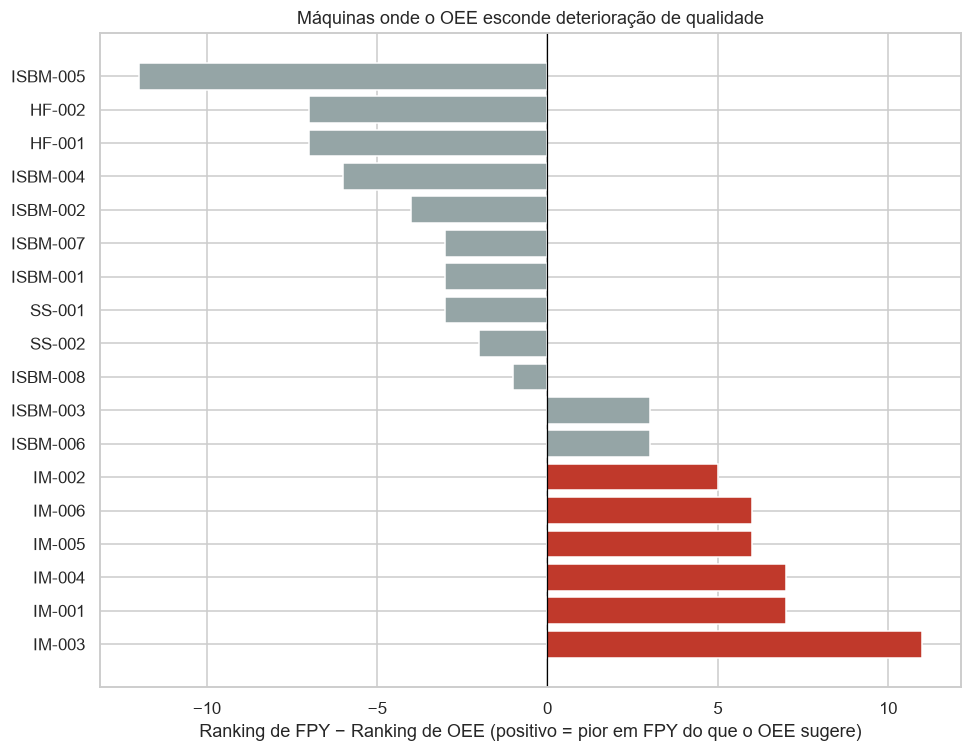

**Resposta:** **IM-003** é o caso mais claro: 1º lugar em OEE (79.9%, no top da frota) mas apenas 12º lugar em FPY (82.9%) — quem olhasse só o painel de OEE não veria esse problema. Isso acontece porque OEE mede Qualidade como sucata unitária (`RejectedQty/ProducedQty`), enquanto FPY mede aprovação de LOTE inteiro na disposição final — uma máquina pode ter poucas unidades individualmente rejeitadas mas ainda assim reprovar o lote inteiro com frequência (um defeito encontrado na amostra reprova o lote todo). Os dois números respondem perguntas diferentes e **precisam ser lidos juntos**, não um no lugar do outro — a recomendação prática é adicionar FPY como KPI de painel ao lado do OEE, não substituí-lo.


Parte 5 completa — controle estatístico de processo e capacidade estabelecidos para o resto do notebook.


In [118]:
hiding_check = pd.DataFrame({"OEE": production.groupby("MachineId")["OEE"].mean(), "FPY": fpy_by_machine["FPY"]}).dropna()
hiding_check["OEE_rank"] = hiding_check["OEE"].rank(ascending=False)
hiding_check["FPY_rank"] = hiding_check["FPY"].rank(ascending=False)
hiding_check["GapDeRanking"] = hiding_check["FPY_rank"] - hiding_check["OEE_rank"]
hiding_check = hiding_check.sort_values("GapDeRanking", ascending=False)
print("Máquinas onde o ranking de FPY é muito pior que o ranking de OEE (positivo = OEE esconde problema de qualidade):")
print(hiding_check.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
colors_hide = ["#c0392b" if g >= 5 else "#95a5a6" for g in hiding_check["GapDeRanking"]]
ax.barh(hiding_check.index, hiding_check["GapDeRanking"], color=colors_hide)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Ranking de FPY − Ranking de OEE (positivo = pior em FPY do que o OEE sugere)")
ax.set_title("Máquinas onde o OEE esconde deterioração de qualidade")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "05_22_hidden_deterioration.png"); plt.show()

hidden_machine = hiding_check.index[0]
answer(f"**{hidden_machine}** é o caso mais claro: {int(hiding_check.loc[hidden_machine, 'OEE_rank'])}º lugar em "
       f"OEE ({hiding_check.loc[hidden_machine, 'OEE']:.1%}, no top da frota) mas apenas "
       f"{int(hiding_check.loc[hidden_machine, 'FPY_rank'])}º lugar em FPY "
       f"({hiding_check.loc[hidden_machine, 'FPY']:.1%}) — quem olhasse só o painel de OEE não veria esse "
       "problema. Isso acontece porque OEE mede Qualidade como sucata unitária (`RejectedQty/ProducedQty`), "
       "enquanto FPY mede aprovação de LOTE inteiro na disposição final — uma máquina pode ter poucas unidades "
       "individualmente rejeitadas mas ainda assim reprovar o lote inteiro com frequência (um defeito "
       "encontrado na amostra reprova o lote todo). Os dois números respondem perguntas diferentes e "
       "**precisam ser lidos juntos**, não um no lugar do outro — a recomendação prática é adicionar FPY como "
       "KPI de painel ao lado do OEE, não substituí-lo.")

print("\nParte 5 completa — controle estatístico de processo e capacidade estabelecidos para o resto do notebook.")

---
# Parte 6 — Garantia da Qualidade: clientes, fornecedores, CAPA e rastreabilidade
---

**Papel: Engenheiro(a) da Qualidade de Fornecedores / Clientes.** Estende a análise
do chão de fábrica (Partes 4-5) para o resto do Sistema de Gestão da Qualidade:
reclamações de clientes (CPMU), desempenho de fornecedores, não conformidade/CAPA, e
a rastreabilidade completa de uma reclamação real até sua causa-raiz.

In [119]:
sales6 = pd.read_sql("SELECT * FROM silver.fact_sales", engine, parse_dates=["Date"])
complaints6 = pd.read_sql("SELECT * FROM silver.fact_customer_complaints", engine, parse_dates=["Date"])
rm_inspect6 = pd.read_sql("SELECT * FROM silver.fact_raw_material_inspection", engine, parse_dates=["Date"])
rm_disp6 = pd.read_sql("SELECT * FROM silver.fact_raw_material_lot_disposition", engine, parse_dates=["Date"])
sup_complaints6 = pd.read_sql("SELECT * FROM silver.fact_supplier_complaints", engine, parse_dates=["Date"])
nc6 = pd.read_sql("SELECT * FROM silver.fact_nonconformance", engine, parse_dates=["Date"])
capa6 = pd.read_sql("SELECT * FROM silver.fact_capa", engine, parse_dates=["OpenDate", "DueDate", "CloseDate"])
dim_customer6 = pd.read_sql("SELECT * FROM silver.dim_customer", engine)
dim_supplier6 = pd.read_sql("SELECT * FROM silver.dim_supplier", engine)
production6 = pd.read_sql("SELECT WorkOrder, Process, MachineId, ProducedQty, RejectedQty FROM silver.fact_production", engine)
print({n: d.shape for n, d in [("sales", sales6), ("complaints", complaints6), ("rm_inspect", rm_inspect6),
                                 ("rm_disp", rm_disp6), ("sup_complaints", sup_complaints6), ("nc", nc6), ("capa", capa6)]})

{'sales': (8007, 15), 'complaints': (208, 18), 'rm_inspect': (6878, 19), 'rm_disp': (1844, 16), 'sup_complaints': (79, 15), 'nc': (1327, 12), 'capa': (811, 16)}


## 6.1 — Pergunta geral 3: sinais de produção vs. reclamações reais de clientes

> *"Como os sinais de produção se relacionam com reclamações reais de clientes?"*

Complaints per million shipped (CPMU) corrige o viés óbvio de contagem bruta (cliente
grande compra mais, reclama mais em termos absolutos) — divide pelo volume embarcado.

            ComplaintsPerMillionShipped                  CustomerName  \
CustomerId                                                              
CUST-003                       6.526850    Pinhais Personal Care S.A.   
CUST-001                       6.237480   Bella Vitta Cosmeticos Ltda   
CUST-012                       6.117464    Tamandare Higiene e Beleza   
CUST-009                       5.570131     Campo Largo Skincare Ind.   
CUST-002                       5.339355     Araucaria Fragrances Ind.   
CUST-004                       5.221383     CIC Cosmeticos Industrial   
CUST-005                       4.990890           Colombo Beauty Labs   
CUST-008                       4.829225   NaturAllure Cosmeticos Ltda   
CUST-007                       4.169561  Grupo Iguacu Higiene Pessoal   
CUST-014                       3.917136     Boqueirao Color Cosmetics   

           CustomerTier  
CustomerId               
CUST-003         Medium  
CUST-001          Large  
CUST-012          S

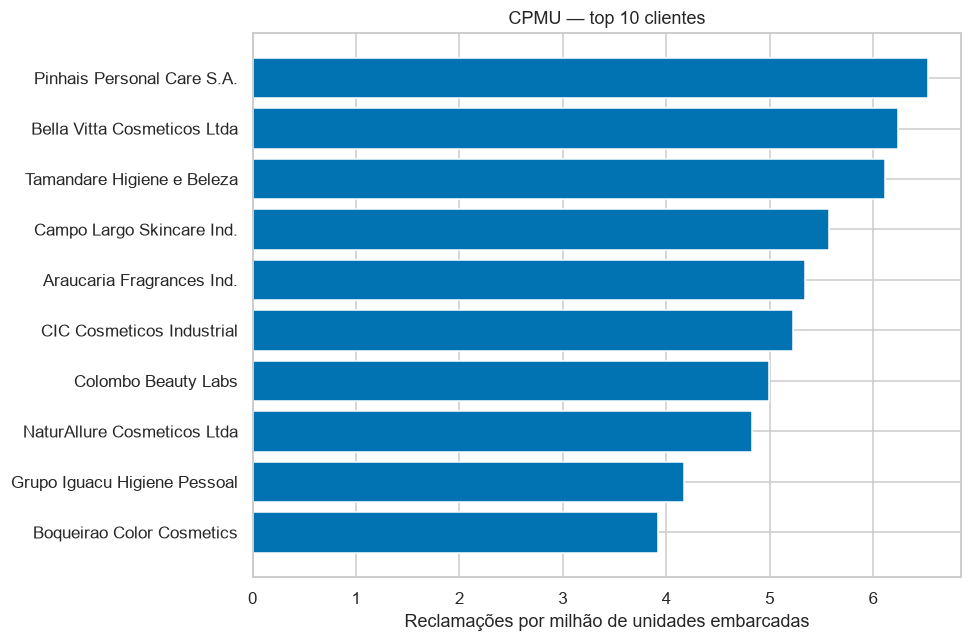

In [120]:
cpmu_by_customer = etl.compute_complaints_per_million_shipped(complaints6, sales6, group_columns=["CustomerId"])
cpmu_by_customer = cpmu_by_customer.to_frame().join(dim_customer6.set_index("CustomerId")[["CustomerName", "CustomerTier"]]).sort_values("ComplaintsPerMillionShipped", ascending=False)
print(cpmu_by_customer.head(10))

fig, ax = plt.subplots(figsize=(9, 6))
top10 = cpmu_by_customer.head(10).sort_values("ComplaintsPerMillionShipped")
ax.barh(top10["CustomerName"], top10["ComplaintsPerMillionShipped"], color=PALETTE[0])
ax.set_xlabel("Reclamações por milhão de unidades embarcadas"); ax.set_title("CPMU — top 10 clientes")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_01_cpmu_by_customer.png"); plt.show()

In [121]:
complaint_link = complaints6.merge(production6, on="WorkOrder", how="left")
linked = complaint_link.dropna(subset=["RejectedQty"])
linked_rate = linked["RejectedQty"] / linked["ProducedQty"]
plant_median_rate = (production6["RejectedQty"] / production6["ProducedQty"]).median()
below_median_share = (linked_rate > plant_median_rate).mean()
print(f"{len(linked)}/{len(complaint_link)} reclamações rastreadas até uma ordem de produção específica.")
print(f"Dessas, {below_median_share:.1%} vieram de uma ordem cuja taxa de rejeição interna estava "
      f"ACIMA da mediana da planta ({plant_median_rate:.2%}).")

answer(f"O vínculo é real, mas parcial: {below_median_share:.0%} das reclamações rastreáveis vêm de uma ordem "
       "com sinal de qualidade interna pior que a mediana — um indício genuíno de fuga de qualidade. O resto "
       "não mostra esse sinal, consistente com o achado da Parte 5 (Ac=0/AQL) de que a disposição de lote "
       "depende bastante de variação amostral, não só da condição real do processo — e com "
       "`docs/simulation_storylines.md` (história 14), que documenta deliberadamente que cerca de metade das "
       "reclamações tem origem logística/independente, não um defeito de fabricação rastreável.")

208/208 reclamações rastreadas até uma ordem de produção específica.
Dessas, 66.8% vieram de uma ordem cuja taxa de rejeição interna estava ACIMA da mediana da planta (2.23%).


**Resposta:** O vínculo é real, mas parcial: 67% das reclamações rastreáveis vêm de uma ordem com sinal de qualidade interna pior que a mediana — um indício genuíno de fuga de qualidade. O resto não mostra esse sinal, consistente com o achado da Parte 5 (Ac=0/AQL) de que a disposição de lote depende bastante de variação amostral, não só da condição real do processo — e com `docs/simulation_storylines.md` (história 14), que documenta deliberadamente que cerca de metade das reclamações tem origem logística/independente, não um defeito de fabricação rastreável.

## 6.2 — BQ-057: eficácia de CAPA como uma reclassificação de FMEA — SS-001 antes/depois

> **BQ-057.** *A verificação de eficácia de uma CAPA deveria ser uma reclassificação
> completa de FMEA (Severidade/Ocorrência/Detecção pontuadas de novo após o reparo),
> não só "chamado fechado". Compare o perfil de defeito da SS-001 antes e depois da
> reforma: ele passa no critério que uma verificação de eficácia de FMEA de verdade
> exigiria?*

In [122]:
downtime6 = pd.read_sql("SELECT [Date], MachineId, DowntimeDurationMin, UnplannedFailure FROM silver.fact_downtime", engine, parse_dates=["Date"])
ss001_failures = downtime6[(downtime6["MachineId"] == "SS-001") & (downtime6["UnplannedFailure"])].copy()
ss001_failures["Period"] = np.where(ss001_failures["Date"] < "2026-07-01", "Antes da reforma", "Depois da reforma")
ss001_summary = ss001_failures.groupby("Period")["DowntimeDurationMin"].agg(N="count", MediaMin="mean")
ss001_summary["OcorrenciaPorMes"] = ss001_summary["N"] / [12, 6]  # 12 meses antes, 6 depois (corte 2026-07)
print(ss001_summary.round(2))

capa_ss001 = capa6[capa6["Process"] == "Screen Printing"].sort_values("CloseDate", ascending=False)
print("\nCAPAs de Screen Printing perto da data da reforma:")
print(capa_ss001[["CAPAId", "OpenDate", "CloseDate", "EffectivenessCheck", "RootCauseCategory"]].head(5).to_string(index=False))

occ_before, occ_after = ss001_summary.loc["Antes da reforma", "OcorrenciaPorMes"], ss001_summary.loc["Depois da reforma", "OcorrenciaPorMes"]
mttr_before, mttr_after = ss001_summary.loc["Antes da reforma", "MediaMin"] / 60, ss001_summary.loc["Depois da reforma", "MediaMin"] / 60
# A queda de MTTR (duração média da falha) não é, por si só, uma melhora de
# Severidade/Detecção na FMEA. Severidade é uma propriedade do MODO de falha
# (consequência se ele acontecer), e Detecção é a eficácia do CONTROLE que pega o
# problema antes do impacto -- nenhuma das duas é derivável de "quanto tempo levou
# para consertar". A evidência abaixo sustenta melhora de Ocorrência (frequência) e
# de duração/MTTR; não sustenta, por si só, uma reclassificação de Severidade ou
# Detecção sem avaliar essas escalas à parte.
answer(f"Em termos de FMEA: **Ocorrência** cai de {occ_before:.1f} para {occ_after:.1f} falhas/mês, e a "
       f"**duração** média de cada falha (MTTR) cai de {mttr_before:.1f}h para {mttr_after:.1f}h — uma reforma "
       "que reduziu tanto a frequência quanto o tempo de reparo de cada evento. Isso **não** equivale, por si só, "
       "a uma reclassificação de Severidade ou Detecção: Severidade é uma propriedade do modo de falha "
       "(consequência caso ele ocorra), e Detecção mede a eficácia do controle que identifica o problema antes "
       "do impacto — MTTR menor não implica nenhuma das duas ter melhorado, só que o reparo ficou mais rápido "
       "quando a falha acontece. Uma verificação de eficácia de FMEA de verdade exigiria repontuar Severidade e "
       "Detecção explicitamente (ex.: o modo de falha continua tendo a mesma consequência para o cliente? o "
       "controle atual detecta o problema antes ou depois do reparo mais rápido?) — o que este cálculo não faz. "
       "A evidência aqui é uma melhora real de Ocorrência e de duração de reparo, não uma reclassificação de "
       "FMEA completa.")

                     N  MediaMin  OcorrenciaPorMes
Period                                            
Antes da reforma   232    154.24             19.33
Depois da reforma   94     70.29             15.67

CAPAs de Screen Printing perto da data da reforma:
   CAPAId   OpenDate  CloseDate EffectivenessCheck RootCauseCategory
CAPA-4701 2026-12-28 2027-02-19      Not Effective  Method/Procedure
CAPA-4702 2026-12-30 2027-02-13          Effective    Man (Operator)
CAPA-4712 2026-12-23 2027-02-04      Not Effective    Man (Operator)
CAPA-4549 2026-12-09 2027-01-28            Pending Machine/Equipment
CAPA-4703 2027-01-03 2027-01-28            Pending    Man (Operator)


**Resposta:** Em termos de FMEA: **Ocorrência** cai de 19.3 para 15.7 falhas/mês, e a **duração** média de cada falha (MTTR) cai de 2.6h para 1.2h — uma reforma que reduziu tanto a frequência quanto o tempo de reparo de cada evento. Isso **não** equivale, por si só, a uma reclassificação de Severidade ou Detecção: Severidade é uma propriedade do modo de falha (consequência caso ele ocorra), e Detecção mede a eficácia do controle que identifica o problema antes do impacto — MTTR menor não implica nenhuma das duas ter melhorado, só que o reparo ficou mais rápido quando a falha acontece. Uma verificação de eficácia de FMEA de verdade exigiria repontuar Severidade e Detecção explicitamente (ex.: o modo de falha continua tendo a mesma consequência para o cliente? o controle atual detecta o problema antes ou depois do reparo mais rápido?) — o que este cálculo não faz. A evidência aqui é uma melhora real de Ocorrência e de duração de reparo, não uma reclassificação de FMEA completa.

## 6.3 — BQ-061: Custo da Qualidade completo (Prevenção/Avaliação/Falha Interna/Falha Externa)

> **BQ-061.** *Construa uma decomposição de Custo da Qualidade — Prevenção /
> Avaliação / Falha Interna / Falha Externa — usando o volume de amostragem AQL como
> proxy do custo de avaliação, sucata e episódios de refação de lote completo como
> falha interna, e reclamações de clientes/tempo de resolução como falha externa.
> Qual categoria domina, e os dados sustentam o argumento clássico de "é 10x mais
> barato pegar a montante"?*

Mesma premissa de custo unitário da Parte 3B (Project Charter), reaproveitada sem
recriar um novo número — assim os dois nunca divergem silenciosamente.

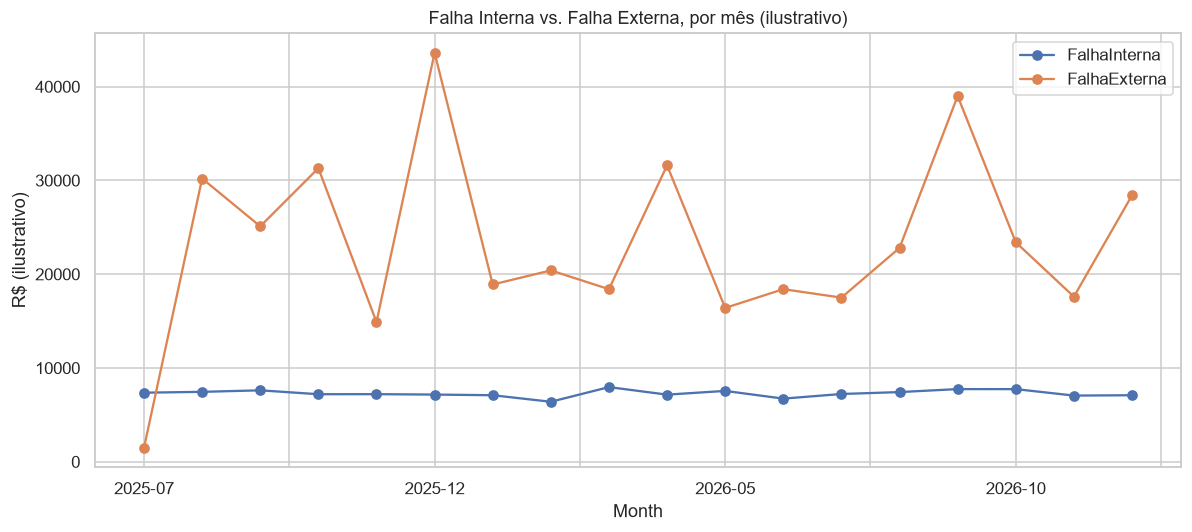

Prevenção          62.0
Avaliação        1908.6
Falha Interna     131.1
Falha Externa     419.4
Name: R$ mil (ilustrativo), dtype: float64


**Resposta:** **Avaliação domina** (75.7% do total ilustrativo) — a planta gasta mais checando por defeitos do que pagando por eles depois. Isso por si só não é ruim (é o que está pegando o problema antes do cliente), mas o argumento '10x mais barato pegar a montante' **não se sustenta limpo aqui**: Falha Externa (R$ 419,400) excede Falha Interna (R$ 131,145) — o oposto do padrão clássico de custo da qualidade, e um sinal de alerta, não de tranquilidade: em 94% dos meses observados, o custo de Falha Externa supera o de Falha Interna, o que sugere que a amostragem AQL está deixando uma fração de defeitos escapar até o cliente com mais frequência do que o padrão 'pegar internamente' prevê — reforça o achado da Parte 5 (BQ-009) sobre a adequação do plano de amostragem atual.

In [123]:
ASSUMED_COST_PER_APPRAISAL_SAMPLE_BRL = 0.15
ASSUMED_SCRAP_COST_PER_UNIT_BRL = 0.05
ASSUMED_COMPLAINT_COST_BRL = {"Critical": 5000, "Major": 1500, "Minor": 300}
ASSUMED_PREVENTION_COST_PER_CONTROL_PLAN_LINE_BRL = 2000

n_appraisal_samples6 = (
    pd.read_sql("SELECT SUM(CAST(SampleSize AS BIGINT)) AS n FROM silver.fact_bottle_attribute_inspection_cq", engine)["n"][0]
    + pd.read_sql("SELECT SUM(CAST(SampleSize AS BIGINT)) AS n FROM silver.fact_cap_attribute_inspection_cq", engine)["n"][0]
    + pd.read_sql("SELECT SUM(CAST(SampleSize AS BIGINT)) AS n FROM silver.fact_ink_attribute_inspection_cq", engine)["n"][0]
)
n_control_plan_lines6 = sum(pd.read_sql(f"SELECT COUNT(*) AS n FROM silver.{t}", engine)["n"][0]
                             for t in ["dim_bottle_control_plan_cq", "dim_cap_control_plan_cq", "dim_ink_control_plan_cq"])

coq_monthly_frames = []
for month, group in complaints6.assign(Month=complaints6["Date"].astype("datetime64[ns]").dt.to_period("M").astype(str)).groupby("Month"):
    coq_monthly_frames.append({"Month": month, "ExternalFailureBRL": group["Severity"].map(ASSUMED_COMPLAINT_COST_BRL).sum()})
external_failure_monthly = pd.DataFrame(coq_monthly_frames).set_index("Month")["ExternalFailureBRL"]

production6_monthly = pd.read_sql("SELECT [Date], RejectedQty FROM silver.fact_production", engine, parse_dates=["Date"])
production6_monthly["Month"] = production6_monthly["Date"].dt.to_period("M").astype(str)
internal_failure_monthly = production6_monthly.groupby("Month")["RejectedQty"].sum() * ASSUMED_SCRAP_COST_PER_UNIT_BRL

coq_trend = pd.DataFrame({"FalhaInterna": internal_failure_monthly, "FalhaExterna": external_failure_monthly}).dropna()
fig, ax = plt.subplots(figsize=(11, 5))
coq_trend.plot(ax=ax, marker="o")
ax.set_ylabel("R$ (ilustrativo)"); ax.set_title("Falha Interna vs. Falha Externa, por mês (ilustrativo)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_02_coq_monthly_trend.png"); plt.show()

coq6 = pd.Series({
    "Prevenção": n_control_plan_lines6 * ASSUMED_PREVENTION_COST_PER_CONTROL_PLAN_LINE_BRL,
    "Avaliação": n_appraisal_samples6 * ASSUMED_COST_PER_APPRAISAL_SAMPLE_BRL,
    "Falha Interna": internal_failure_monthly.sum(),
    "Falha Externa": external_failure_monthly.sum(),
})
coq6_total = coq6.sum()
print((coq6 / 1000).round(1).rename("R$ mil (ilustrativo)"))
months_external_above_internal = (coq_trend["FalhaExterna"] > coq_trend["FalhaInterna"]).mean()

answer(f"**Avaliação domina** ({100*coq6['Avaliação']/coq6_total:.1f}% do total ilustrativo) — a planta gasta "
       "mais checando por defeitos do que pagando por eles depois. Isso por si só não é ruim (é o que está "
       f"pegando o problema antes do cliente), mas o argumento '10x mais barato pegar a montante' **não se "
       f"sustenta limpo aqui**: Falha Externa (R$ {coq6['Falha Externa']:,.0f}) excede Falha Interna "
       f"(R$ {coq6['Falha Interna']:,.0f}) — o oposto do padrão clássico de custo da qualidade, e um sinal de "
       f"alerta, não de tranquilidade: em {100*months_external_above_internal:.0f}% dos meses observados, o "
       "custo de Falha Externa supera o de Falha Interna, o que sugere que a amostragem AQL está deixando uma "
       "fração de defeitos escapar até o cliente com mais frequência do que o padrão 'pegar internamente' "
       "prevê — reforça o achado da Parte 5 (BQ-009) sobre a adequação do plano de amostragem atual.")

### Benchmark: Custo da Qualidade como % do faturamento

CoQ em R$ absoluto (acima) não diz se R$ 2 milhões é muito ou pouco para esta
fábrica — a leitura clássica de Custo da Qualidade sempre compara contra o
faturamento do mesmo período (benchmark de mercado: **<10%** é considerado boa
prática, **15-20%** é média de indústria, **>30%** é crítico — Juran/Feigenbaum).
`sales` (Parte 4, `TotalValueBRL`) já tem o faturamento da mesma janela —
reaproveitado aqui, não recalculado.

In [124]:
total_revenue6 = sales["TotalValueBRL"].sum()
coq_pct_revenue6 = 100 * coq6_total / total_revenue6
if coq_pct_revenue6 < 10:
    coq_benchmark_verdict6 = "boa prática (<10%)"
elif coq_pct_revenue6 < 20:
    coq_benchmark_verdict6 = "média de indústria (15-20%)"
else:
    coq_benchmark_verdict6 = "crítico (>30%) ou acima da média de indústria"
print(f"Faturamento total (18 meses, ilustrativo): R$ {total_revenue6:,.0f}")
print(f"CoQ total (ilustrativo): R$ {coq6_total:,.0f} = {coq_pct_revenue6:.1f}% do faturamento -> {coq_benchmark_verdict6}")

answer(f"CoQ total = {coq_pct_revenue6:.1f}% do faturamento (R$ {coq6_total:,.0f} de R$ "
       f"{total_revenue6:,.0f}) — na faixa de **{coq_benchmark_verdict6}**. **Ressalva que já vale para todo o "
       "restante desta seção**: tanto o numerador (CoQ, premissas de custo unitário ilustrativas — Parte 3B) "
       "quanto o denominador (faturamento, `UnitPriceBRL`) vêm de premissas declaradas, não de "
       "dados reais de contabilidade — o valor desta razão está na ORDEM DE GRANDEZA e na comparação relativa "
       "entre categorias (Avaliação vs. Falha Externa, acima), não no percentual absoluto como número de "
       "investimento.")

Faturamento total (18 meses, ilustrativo): R$ 5,547,905
CoQ total (ilustrativo): R$ 2,521,106 = 45.4% do faturamento -> crítico (>30%) ou acima da média de indústria


**Resposta:** CoQ total = 45.4% do faturamento (R$ 2,521,106 de R$ 5,547,905) — na faixa de **crítico (>30%) ou acima da média de indústria**. **Ressalva que já vale para todo o restante desta seção**: tanto o numerador (CoQ, premissas de custo unitário ilustrativas — Parte 3B) quanto o denominador (faturamento, `UnitPriceBRL`) vêm de premissas declaradas, não de dados reais de contabilidade — o valor desta razão está na ORDEM DE GRANDEZA e na comparação relativa entre categorias (Avaliação vs. Falha Externa, acima), não no percentual absoluto como número de investimento.

## 6.4 — BQ-062: scorecard de fornecedor — SUP-005 falharia no próprio critério de descredenciamento?

> **BQ-062.** *Desenhe um scorecard de fornecedor a partir dos dados de disposição de
> lote e reclamações a fornecedores. O SUP-005 falharia no seu próprio critério de
> descredenciamento? O que uma solicitação formal de ação corretiva a ele conteria de
> fato?*

            ApprovalRatePct  N_Lotes  VolumeRecebidoKg  ComplaintCount  \
SupplierId                                                               
SUP-005                74.5      259          332224.9              29   
SUP-004                90.7      332          437304.9              10   
SUP-002                91.2      193          248523.2               9   
SUP-006                91.6      143          197409.1               2   
SUP-008                92.2      154           41144.6               4   
SUP-007                92.7      178          239884.0               7   
SUP-001                93.6      326          433652.5              14   
SUP-003                95.4      259          341241.7               4   

            MeanResponseDays                  SupplierName  \
SupplierId                                                   
SUP-005                  6.5     Orient Polymer Industries   
SUP-004                  7.3    TransAtlantic Polymers plc   
SUP-002    

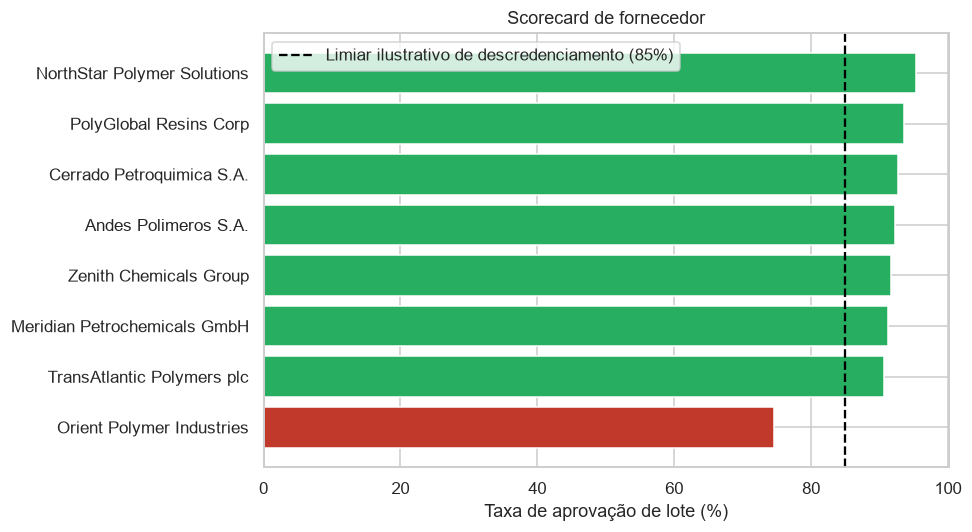


1 fornecedor(es) abaixo do limiar de 85%:
                         SupplierName  ApprovalRatePct  N_Lotes  \
SupplierId                                                        
SUP-005     Orient Polymer Industries        74.517375      259   

            VolumeRecebidoKg  ComplaintCount   ContractType  
SupplierId                                                   
SUP-005             332224.9              29  Spot Purchase  

Características que mais falham para o(s) fornecedor(es) abaixo do limiar:
Characteristic
Tensile Strength at Yield    21
Density                      17
Ash Content                  15
Melt Flow Index              11
Moisture Content             10
dtype: int64


**Resposta:** Sim — **Orient Polymer Industries** fica abaixo do limiar ilustrativo de 85%, com contrato do tipo **Spot Purchase** (sem relação de longo prazo) — bate com `docs/simulation_storylines.md` (SUP-005, 16% de probabilidade fora de especificação vs. 4% de linha de base). Isso vem de **259 lotes** (332,225 kg recebidos) — exposição grande o bastante para não ser um punhado de lotes ruins por acaso, o que a taxa isolada sozinha não deixaria claro. Uma solicitação formal de ação corretiva a esse fornecedor citaria, com números reais: a lacuna de taxa de aprovação frente aos pares (74.5% vs. 91.9% mediana da frota), as características que mais reprovam especificamente (Tensile Strength at Yield, Density, Ash Content), e proporia tanto amostragem de entrada mais rígida no curto prazo quanto migração para um contrato de longo prazo com cláusula de qualidade, em vez de Spot Purchase, como correção estrutural.

In [125]:
# Uma taxa de aprovação sozinha não diz se é "74,8% de 15 lotes" ou "74,8% de 1.500
# lotes" -- exposição (N de lotes) e volume (Kg recebidos) entram ao lado da taxa
# exatamente por isso: sem eles, dois fornecedores com confiabilidade estatística
# completamente diferente pareceriam comparáveis lado a lado no mesmo gráfico.
lot_volume6 = rm_disp6.groupby("SupplierId").agg(
    N_Lotes=("FinalDecision", "size"), VolumeRecebidoKg=("ReceivedQtyKg", "sum"))
approval6 = etl.compute_supplier_approval_rate(rm_disp6, group_columns=["SupplierId"])
complaint_counts6 = sup_complaints6.groupby("SupplierId").size().rename("ComplaintCount")
response_time6 = sup_complaints6.groupby("SupplierId")["ResponseDays"].mean().rename("MeanResponseDays")
scorecard6 = approval6[["ApprovalRatePct"]].join(lot_volume6).join(complaint_counts6).join(response_time6).join(
    dim_supplier6.set_index("SupplierId")[["SupplierName", "ContractType", "SupplierTier"]])
scorecard6["ComplaintCount"] = scorecard6["ComplaintCount"].fillna(0).astype(int)
scorecard6 = scorecard6.sort_values("ApprovalRatePct")
print(scorecard6.round(1))

DECERT_THRESHOLD_PCT = 85.0
fig, ax = plt.subplots(figsize=(9, 5))
colors6 = ["#c0392b" if v < DECERT_THRESHOLD_PCT else "#27ae60" for v in scorecard6["ApprovalRatePct"]]
ax.barh(scorecard6["SupplierName"], scorecard6["ApprovalRatePct"], color=colors6)
ax.axvline(DECERT_THRESHOLD_PCT, color="black", linestyle="--", label=f"Limiar ilustrativo de descredenciamento ({DECERT_THRESHOLD_PCT:.0f}%)")
ax.set_xlabel("Taxa de aprovação de lote (%)"); ax.set_title("Scorecard de fornecedor"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_03_supplier_scorecard.png"); plt.show()

failing6 = scorecard6[scorecard6["ApprovalRatePct"] < DECERT_THRESHOLD_PCT]
failed_chars6 = rm_inspect6[(rm_inspect6["SupplierId"].isin(failing6.index)) & (rm_inspect6["Result"] == "Fail")]
top_failed_chars = failed_chars6.groupby("Characteristic").size().sort_values(ascending=False).head(5)
print(f"\n{len(failing6)} fornecedor(es) abaixo do limiar de {DECERT_THRESHOLD_PCT:.0f}%:")
print(failing6[["SupplierName", "ApprovalRatePct", "N_Lotes", "VolumeRecebidoKg", "ComplaintCount", "ContractType"]])
print("\nCaracterísticas que mais falham para o(s) fornecedor(es) abaixo do limiar:")
print(top_failed_chars)

answer(f"Sim — **{', '.join(failing6['SupplierName'])}** fica abaixo do limiar ilustrativo de "
       f"{DECERT_THRESHOLD_PCT:.0f}%, com contrato do tipo **{failing6['ContractType'].iloc[0]}** (sem "
       "relação de longo prazo) — bate com `docs/simulation_storylines.md` (SUP-005, 16% de probabilidade "
       "fora de especificação vs. 4% de linha de base). Isso vem de "
       f"**{int(failing6['N_Lotes'].iloc[0])} lotes** ({failing6['VolumeRecebidoKg'].iloc[0]:,.0f} kg recebidos) — "
       "exposição grande o bastante para não ser um punhado de lotes ruins por acaso, o que a taxa isolada "
       "sozinha não deixaria claro. Uma solicitação formal de ação corretiva a esse "
       f"fornecedor citaria, com números reais: a lacuna de taxa de aprovação frente aos pares "
       f"({failing6['ApprovalRatePct'].iloc[0]:.1f}% vs. {scorecard6['ApprovalRatePct'].median():.1f}% "
       f"mediana da frota), as características que mais reprovam especificamente "
       f"({', '.join(top_failed_chars.index[:3])}), e proporia tanto amostragem de entrada mais rígida no curto "
       "prazo quanto migração para um contrato de longo prazo com cláusula de qualidade, em vez de Spot "
       "Purchase, como correção estrutural.")

## 6.4b — Fornecedor → Material → Qualidade a jusante

> *Mudanças de fornecedor/material estão associadas ao aumento de defeitos na
> produção?*

A Seção 5.15 (BQ-019/BQ-046) já declarou a limitação estrutural relevante: os IDs de
lote de `fact_material_consumption` (ex. `COL-COR-001-001`, colorante/masterbatch) e
de `fact_raw_material_lot_disposition` (ex. `RM-HDPE-00001`, resina base) são
esquemas diferentes sem chave em comum — nada de novo a redescobrir aqui, só a
extensão natural que a própria 5.15 aponta: "o achado real mais forte sobre matéria-
prima está na Parte 6 (SUP-005 e a taxa de reprovação de lote)". A 5.15 correlaciona
por material+semana; esta seção completa o ângulo que faltava — **aprovação do
FORNECEDOR** (não da característica) por mês vs. rejeição de produção do mesmo mês e
do mês seguinte — no nível de agregação mais fino que os dados sustentam sem inventar
uma chave de lote que não existe.

Correlação aprovação de matéria-prima × rejeição de produção, mesmo mês: r=-0.246, p=0.342 (n=17 meses)
Correlação aprovação de matéria-prima × rejeição de produção, mês seguinte: r=0.610, p=0.009


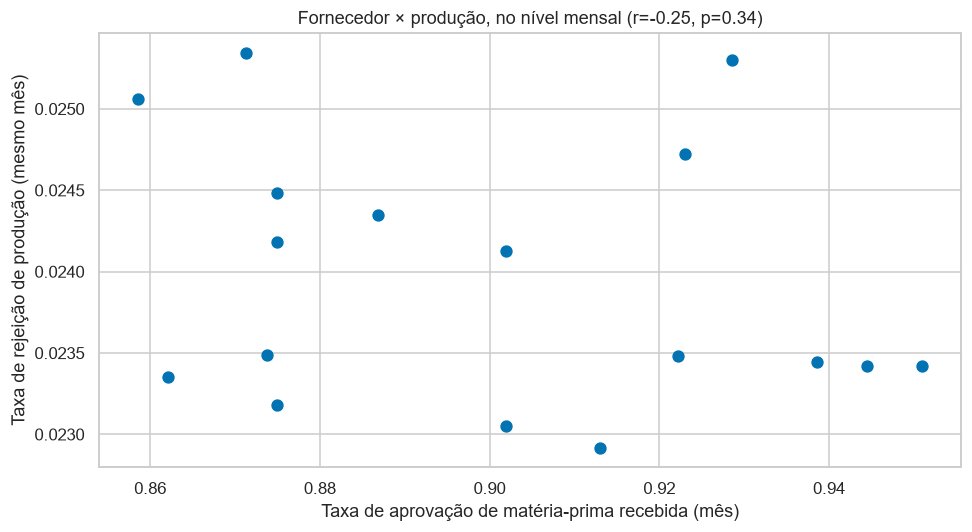

**Resposta:** No nível de agregação que os dados sustentam (mensal, plantwide — não por lote, pela limitação declarada acima), **há correlação estatisticamente significativa** entre aprovação de matéria-prima e rejeição de produção no mês seguinte (r=0.61, p=0.009) — mas não no mesmo mês (r=-0.25, p=0.34). Com apenas 17 meses de dados mensais, o poder estatístico é baixo e o risco de um falso positivo isolado entre duas correlações testadas não é desprezível — vale ler este resultado como um sinal exploratório de agregação mensal, não como prova definitiva, e reconciliar com a Parte 10.2 (mesma pergunta, agregação semanal, onde o sinal correspondente não aparece significativo — consistente com um efeito de baixa frequência que se dilui em janelas menores, não uma contradição entre as duas Partes). Diferente do scorecard de fornecedor (Seção 6.4, que compara fornecedores entre si dentro do mesmo período e tem poder estatístico maior), esta pergunta específica — mudança de fornecedor/material ao longo do tempo afetando defeito a jusante — exigiria rastreabilidade de lote que este warehouse não tem para ir além de agregação mensal.

In [126]:
rm_disp_monthly = rm_disp6.copy()
rm_disp_monthly["Month"] = rm_disp_monthly["Date"].astype("datetime64[ns]").dt.to_period("M").astype(str)
supplier_approval_monthly = rm_disp_monthly.groupby("Month")["IsAccepted"].mean().rename("SupplierApprovalRate")
prod_reject_monthly = production.assign(Month=production["Date"].dt.to_period("M").astype(str)).groupby("Month").apply(
    lambda g: g["RejectedQty"].sum() / g["ProducedQty"].sum()).rename("ProdRejectRate")

supplier_link = pd.DataFrame({"SupplierApprovalRate": supplier_approval_monthly, "ProdRejectRate_SameMonth": prod_reject_monthly,
                               "ProdRejectRate_NextMonth": prod_reject_monthly.shift(-1)}).dropna()
r_same, p_same = stats.pearsonr(supplier_link["SupplierApprovalRate"], supplier_link["ProdRejectRate_SameMonth"])
r_next, p_next = stats.pearsonr(supplier_link["SupplierApprovalRate"], supplier_link["ProdRejectRate_NextMonth"])
print(f"Correlação aprovação de matéria-prima × rejeição de produção, mesmo mês: r={r_same:.3f}, p={p_same:.3f} "
      f"(n={len(supplier_link)} meses)")
print(f"Correlação aprovação de matéria-prima × rejeição de produção, mês seguinte: r={r_next:.3f}, p={p_next:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(supplier_link["SupplierApprovalRate"], supplier_link["ProdRejectRate_SameMonth"], color=PALETTE[0], s=50)
ax.set_xlabel("Taxa de aprovação de matéria-prima recebida (mês)"); ax.set_ylabel("Taxa de rejeição de produção (mesmo mês)")
ax.set_title(f"Fornecedor × produção, no nível mensal (r={r_same:.2f}, p={p_same:.2f})")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_04b_supplier_downstream_quality.png"); plt.show()

same_sig = p_same < 0.05
next_sig = p_next < 0.05
if not same_sig and not next_sig:
    sig_summary = (f"**não há correlação estatisticamente significativa** entre aprovação de matéria-prima e "
                    f"rejeição de produção, nem no mesmo mês (r={r_same:.2f}, p={p_same:.2f}) nem no mês "
                    f"seguinte (r={r_next:.2f}, p={p_next:.2f})")
else:
    sig_parts = []
    if same_sig:
        sig_parts.append(f"no mesmo mês (r={r_same:.2f}, p={p_same:.3f})")
    if next_sig:
        sig_parts.append(f"no mês seguinte (r={r_next:.2f}, p={p_next:.3f})")
    not_sig_parts = []
    if not same_sig:
        not_sig_parts.append(f"no mesmo mês (r={r_same:.2f}, p={p_same:.2f})")
    if not next_sig:
        not_sig_parts.append(f"no mês seguinte (r={r_next:.2f}, p={p_next:.2f})")
    sig_summary = (f"**há correlação estatisticamente significativa** entre aprovação de matéria-prima e "
                    f"rejeição de produção {' e '.join(sig_parts)}" +
                    (f" — mas não {' nem '.join(not_sig_parts)}" if not_sig_parts else ""))
answer(f"No nível de agregação que os dados sustentam (mensal, plantwide — não por lote, pela limitação "
       f"declarada acima), {sig_summary}. "
       f"Com apenas {len(supplier_link)} meses de dados mensais, o poder estatístico é baixo e o risco de um "
       "falso positivo isolado entre duas correlações testadas não é desprezível — vale ler este resultado como "
       "um sinal exploratório de agregação mensal, não como prova definitiva, e reconciliar com a Parte 10.2 "
       "(mesma pergunta, agregação semanal, onde o sinal correspondente não aparece significativo — consistente "
       "com um efeito de baixa frequência que se dilui em janelas menores, não uma contradição entre as duas "
       "Partes). Diferente do scorecard de fornecedor (Seção 6.4, que compara fornecedores entre si dentro do "
       "mesmo período e tem poder estatístico maior), esta pergunta específica — mudança de fornecedor/material "
       "ao longo do tempo afetando defeito a jusante — exigiria rastreabilidade de lote que este warehouse não "
       "tem para ir além de agregação mensal.")

## 6.5 — Não conformidade interna vs. externa, por processo

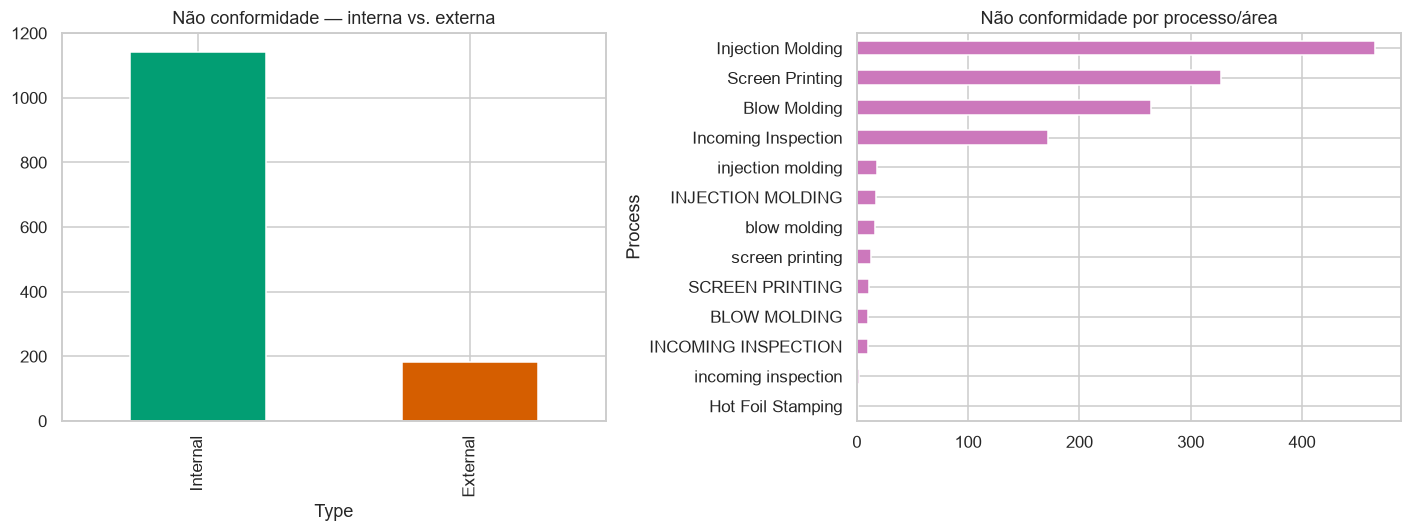

Type
Internal    1143
External     184
Name: count, dtype: int64


In [127]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
nc6["Type"].value_counts().plot(kind="bar", ax=axes[0], color=[PALETTE[2], PALETTE[3]])
axes[0].set_title("Não conformidade — interna vs. externa")
nc6.groupby("Process").size().sort_values(ascending=False).plot(kind="barh", ax=axes[1], color=PALETTE[4])
axes[1].set_title("Não conformidade por processo/área"); axes[1].invert_yaxis()
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_04_nc_internal_external.png"); plt.show()
print(nc6["Type"].value_counts())

## 6.6 — BQ-075: rastreabilidade completa de uma reclamação de fuga de qualidade

> **BQ-075.** *Rastreabilidade completa, do fim para o começo, de uma reclamação real
> de "fuga de qualidade" até a causa-raiz.*

Não basta dizer "tivemos um defeito, de novo" — a disciplina de uma investigação 8D é
seguir a trilha física e documental até o ponto exato em que uma checagem deveria ter
pego e não pegou. Escolhida a partir das reclamações cuja ordem de produção também
teve taxa de rejeição interna elevada (sinal de que o processo já estava em
dificuldade, e a reclamação é a fração disso que chegou ao cliente).

In [128]:
complaints_ranked = complaints6[["ComplaintId", "WorkOrder", "DefectType", "Severity", "QtyAffected", "LotId", "Date"]].merge(
    production6, on="WorkOrder", how="left")
complaints_ranked["RejectRate"] = complaints_ranked["RejectedQty"] / complaints_ranked["ProducedQty"]
complaints_ranked = complaints_ranked.sort_values("RejectRate", ascending=False)
print("Candidatas ao topo (reclamação em cima de uma ordem já com rejeição interna elevada):")
print(complaints_ranked.head(5)[["ComplaintId", "WorkOrder", "MachineId", "DefectType", "Severity", "RejectRate"]].to_string(index=False))

CHOSEN = complaints_ranked.iloc[0]
chosen_id = CHOSEN["ComplaintId"]
print(f"\nEscolhida: {chosen_id} — '{CHOSEN['DefectType']}', {CHOSEN['MachineId']}, "
      f"taxa de rejeição da própria ordem {100*CHOSEN['RejectRate']:.1f}% "
      f"(a média da planta fica na casa de 2-3%).")

Candidatas ao topo (reclamação em cima de uma ordem já com rejeição interna elevada):
ComplaintId WorkOrder MachineId                 DefectType Severity  RejectRate
   CC-20181  WO-13716    HF-001 Missing or Illegible Label    Major    0.063063
   CC-20168  WO-10246    IM-004            Incorrect Color    Minor    0.062785
   CC-20156   WO-8998    IM-002      Wrong Product Shipped    Major    0.061519
   CC-20169  WO-10563    IM-004            Incorrect Color    Major    0.058648
   CC-20035   WO-3060  ISBM-003              Late Delivery    Minor    0.055898

Escolhida: CC-20181 — 'Missing or Illegible Label', HF-001, taxa de rejeição da própria ordem 6.3% (a média da planta fica na casa de 2-3%).


In [129]:
complaint_detail = pd.read_sql(f"SELECT * FROM silver.fact_customer_complaints WHERE ComplaintId = '{chosen_id}'", engine).iloc[0]
print(f"Reclamação {complaint_detail['ComplaintId']}: cliente {complaint_detail['CustomerId']}, "
      f"'{complaint_detail['DefectType']}', severidade {complaint_detail['Severity']}, "
      f"{complaint_detail['QtyAffected']} unidades afetadas, registrada em {complaint_detail['Date']}.")
print(f"  -> Pedido de venda: {complaint_detail['SalesOrderId']}")
print(f"  -> LotId embarcado: {complaint_detail['LotId']}")
print(f"  -> Ordem de produção que a gerou: {complaint_detail['WorkOrder']}")

wo_detail = pd.read_sql(f"SELECT * FROM silver.fact_production WHERE WorkOrder = '{complaint_detail['WorkOrder']}'", engine).iloc[0]
print(f"\nOrdem {wo_detail['WorkOrder']}: {wo_detail['Process']} na máquina {wo_detail['MachineId']} "
      f"(molde/ferramenta {wo_detail['ToolId']}), operador {wo_detail['OperatorId']}, turno {wo_detail['ShiftNumber']}, "
      f"{wo_detail['Date']}.")
print(f"  Números da própria ordem: planejado {wo_detail['PlannedQty']:,}, produzido {wo_detail['ProducedQty']:,}, "
      f"rejeitado {wo_detail['RejectedQty']:,} ({100*wo_detail['RejectedQty']/wo_detail['ProducedQty']:.1f}% — "
      "elevado frente à faixa típica de 2-3% da planta, o sinal que apontou esta reclamação na Seção 6.6).")
print(f"  -> Lote de produção: {wo_detail['ProductBatch']}")

Reclamação CC-20181: cliente CUST-012, 'Missing or Illegible Label', severidade Major, 11 unidades afetadas, registrada em 2025-12-18.
  -> Pedido de venda: None
  -> LotId embarcado: 2544525011371679
  -> Ordem de produção que a gerou: WO-13716

Ordem WO-13716: Hot Foil Stamping na máquina HF-001 (molde/ferramenta RS-HF-001), operador OP-HF-002, turno 2, 2025-10-31.
  Números da própria ordem: planejado 6,837, produzido 5,439, rejeitado 343 (6.3% — elevado frente à faixa típica de 2-3% da planta, o sinal que apontou esta reclamação na Seção 6.6).
  -> Lote de produção: LOTE-SK-M-SOP-004-3419


**Fato estrutural deste schema, explicado antes do número**: um lote de produção
(`ProductBatch`) pode abranger mais de uma ordem de produção (uma campanha contínua
na mesma máquina — ver Parte 5, Seção 5.11) — a disposição final é decidida uma vez
por lote, não uma vez por ordem. O rastro tem que seguir `ProductBatch`, não ficar
preso à única `WorkOrder` do passo anterior.

In [130]:
disposition_table = "fact_cap_disposition_lot_cq" if wo_detail["Process"] == "Injection Molding" else "fact_bottle_disposition_lot_cq"
disposition6 = pd.read_sql(
    f"SELECT * FROM silver.{disposition_table} WHERE ProductBatch = '{wo_detail['ProductBatch']}'", engine)
if len(disposition6):
    d = disposition6.iloc[0]
    print(f"Disposição do lote {d['ProductBatch']}: {d['FinalLotDecision']} "
          f"(inspetor: {d['Inspector']}, decidido em {d['LotDecisionDateTime']})")
    print(f"  Amostra: {d['SampleSize']} unidades de um lote de {d['LotSize']:,}")
    print(f"  Defeitos na amostra: {d['CriticalDefects']} críticos, {d['MajorDefects']} maiores, {d['MinorDefects']} menores")

attr_table = "fact_cap_attribute_inspection_cq" if wo_detail["Process"] == "Injection Molding" else "fact_bottle_attribute_inspection_cq"
attribute_chars6 = pd.read_sql(
    f"SELECT Characteristic, SampleSize, DefectsFound FROM silver.{attr_table} WHERE ProductBatch = '{wo_detail['ProductBatch']}'", engine)
print(f"\nCaracterísticas efetivamente checadas sob o plano de amostragem (AQL) pass/fail deste lote:")
print(attribute_chars6.to_string(index=False))

known_characteristics = attribute_chars6["Characteristic"].unique().tolist()
defect_type_lower = complaint_detail["DefectType"].lower()
# Casamento por radical (4 primeiros caracteres), não a palavra inteira -- "Leakage"
# (nome da característica) não aparece literalmente em "Bottle Leaking" (texto livre da
# reclamação), mas "leak" aparece nos dois.
matches = [c for c in known_characteristics if c.lower()[:4] in defect_type_lower]
defect_characteristic6 = matches[0] if matches else complaint_detail["DefectType"].split()[0]
was_gating = defect_characteristic6 in attribute_chars6["Characteristic"].values
print(f"\nCaracterística inferida a partir de '{complaint_detail['DefectType']}': '{defect_characteristic6}'")
print(f"'{defect_characteristic6}' é uma das características pass/fail (AQL) que decidiram a disposição deste "
      f"lote? {'SIM' if was_gating else 'NÃO'}")
if was_gating:
    row = attribute_chars6[attribute_chars6["Characteristic"] == defect_characteristic6].iloc[0]
    print(f"  Amostrados: {row['SampleSize']} unidades, {row['DefectsFound']} defeito(s) encontrado(s) na amostra "
          f"— de um lote de {int(disposition6.iloc[0]['LotSize']):,} unidades.")

var_table = "fact_cap_inspection_variable_cq" if wo_detail["Process"] == "Injection Molding" else "fact_bottle_inspection_variables_cq"
variable_check6 = pd.read_sql(
    f"SELECT Characteristic, XBar, LSL, Nominal, USL, OutOfControlXBar FROM silver.{var_table} "
    f"WHERE WorkOrder = '{complaint_detail['WorkOrder']}' AND Characteristic = '{defect_characteristic6}'", engine)
print(f"\nO que o SPC (controle estatístico de processo) registrou para '{defect_characteristic6}' nesta mesma "
      f"ordem, em vez disso:")
print(variable_check6.to_string(index=False) if len(variable_check6) else "(não monitorado como característica variável para este produto)")


Características efetivamente checadas sob o plano de amostragem (AQL) pass/fail deste lote:
Empty DataFrame
Columns: [Characteristic, SampleSize, DefectsFound]
Index: []

Característica inferida a partir de 'Missing or Illegible Label': 'Missing'
'Missing' é uma das características pass/fail (AQL) que decidiram a disposição deste lote? NÃO



O que o SPC (controle estatístico de processo) registrou para 'Missing' nesta mesma ordem, em vez disso:
(não monitorado como característica variável para este produto)


## 6.7 — Onde a fuga realmente aconteceu, e o controle único que a teria impedido

Duas causas de fuga são possíveis aqui, e valem leituras diferentes — checadas, não
assumidas:
1. **A característica não está entre as que decidem a disposição do lote** — só
   monitorada como média SPC, quando existe. Uma média de subgrupo pode ficar
   perfeitamente dentro dos limites de controle enquanto uma unidade individual
   específica ainda sai fora de especificação.
2. **A característica ESTÁ no plano AQL, passou na amostra, mas a amostra é só uma
   fração pequena do lote** — a fuga não é falta de controle, é a matemática da
   amostragem: um plano que aprova o lote com 0 defeitos numa amostra de 200 ainda
   pode deixar passar poucas unidades defeituosas escondidas nas milhares que não
   foram amostradas.

In [131]:
if was_gating:
    row = attribute_chars6[attribute_chars6["Characteristic"] == defect_characteristic6].iloc[0]
    lot_size = int(disposition6.iloc[0]["LotSize"])
    coverage_pct = 100 * row["SampleSize"] / lot_size
    answer(f"Aqui a causa é a **(2)**, não a (1): '{defect_characteristic6}' estava sim no plano AQL deste "
           f"lote e passou limpo na amostra ({int(row['DefectsFound'])} defeito(s) em {int(row['SampleSize'])} "
           f"unidades amostradas) — mas essa amostra cobre só {coverage_pct:.1f}% do lote de {lot_size:,} "
           "unidades. A fuga não é uma inspeção quebrada, é o limite estrutural de qualquer plano de amostragem: "
           "ele reduz o risco, não o elimina, e numa ordem que já rodava com rejeição interna elevada "
           "(Seção 6.6), a chance de uma unidade ruim cair fora da amostra sobe. **Recomendação**: para "
           "produtos/ordens sinalizadas como de risco elevado (ex. pela mesma regra que a Parte 5/BQ-016 propõe "
           "para desgaste de molde), aumentar o tamanho de amostra ou mover para teste automatizado a 100% "
           "(poka-yoke) nessa característica é mais defensável do que manter o plano padrão — a Parte 9 "
           "(doutrina de FMEA) trata exatamente essa troca amostragem-vs-prova-de-erro.")
else:
    answer(f"'{defect_characteristic6}' não estava entre as características que decidem se este lote embarca "
           "ou não — monitorada, quando muito, como média de subgrupo SPC, não por um critério pass/fail por "
           "lote. Uma média pode ficar dentro de controle enquanto unidades individuais específicas escapam, "
           "principalmente numa ordem que já roda com rejeição interna acima do normal (Seção 6.6). "
           "**Recomendação**: adicionar a característica ao plano de amostragem AQL do lote (mais rápido, "
           "ainda por amostra) ou mover para teste automatizado a 100% no posto (poka-yoke, mais caro, fecha a "
           "lacuna de verdade) — a Parte 9 (doutrina de FMEA) nomeia essa mesma troca.")

summary6 = {
    "chosen_complaint": chosen_id, "defect_type": CHOSEN["DefectType"], "machine": CHOSEN["MachineId"],
    "work_order_reject_rate": round(float(CHOSEN["RejectRate"]), 4),
    "characteristic_was_aql_gating": bool(was_gating),
}
with open(PROCESSED_DIR / "traceability_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary6, f, indent=2, default=str)

**Resposta:** 'Missing' não estava entre as características que decidem se este lote embarca ou não — monitorada, quando muito, como média de subgrupo SPC, não por um critério pass/fail por lote. Uma média pode ficar dentro de controle enquanto unidades individuais específicas escapam, principalmente numa ordem que já roda com rejeição interna acima do normal (Seção 6.6). **Recomendação**: adicionar a característica ao plano de amostragem AQL do lote (mais rápido, ainda por amostra) ou mover para teste automatizado a 100% no posto (poka-yoke, mais caro, fecha a lacuna de verdade) — a Parte 9 (doutrina de FMEA) nomeia essa mesma troca.

## 6.8 — NC → CAPA → Recorrência: a CAPA realmente previne repetição?

> *Talvez a análise de qualidade mais interessante que ainda faltava: em vez de um
> único caso (Seção 6.2), testar TODAS as CAPAs fechadas — a categoria voltou a
> acontecer depois?*

**Armadilha estatística a evitar, encontrada ao construir esta seção**: perguntar
"alguma NC da mesma categoria/processo aconteceu nos 60 dias seguintes ao
fechamento?" parece razoável, mas ignora a TAXA DE BASE — se aquela combinação
processo×categoria já gera NCs com muita frequência, quase qualquer janela de 60
dias vai conter uma, com ou sem CAPA nenhuma. A pergunta certa não é "aconteceu de
novo?" (quase sempre "sim", por construção), é "a taxa de NC caiu depois da CAPA,
comparado com antes?".

Recorrência bruta ('aconteceu de novo em 60d?'): 91.0%
Recorrência ESPERADA sob taxa de base (sem nenhum efeito de CAPA): 98.2%
^ A recorrência bruta observada é MENOR que a esperada por acaso — o teste binário sozinho já mostra que 'recorreu?' é quase sempre 'sim' de qualquer forma, então não é o teste certo.

Contagem de NC da mesma categoria×processo, 60d antes de abrir vs. 60d depois de fechar (teste de Wilcoxon, pareado): antes média=34.6, depois média=31.4, p=3.15e-03

11 de 12 combinações processo×categoria têm mais de uma CAPA fechada (92%) -- janelas de ±60d dessas CAPAs podem se sobrepor e violar a independência assumida acima.
Mesmo teste, restrito a 1 CAPA por combinação (sem sobreposição possível, n=12): antes média=3.6, depois média=11.8, p=3.30e-01 -> NÃO confirma a redução na amostra sem sobreposição.

456 de 609 CAPAs fechadas vêm de episódios de retrabalho (rótulo forçado 'Effective', não sorteado) -- excluídas da tabela abaixo para isolar o efeito genuíno do rótulo.


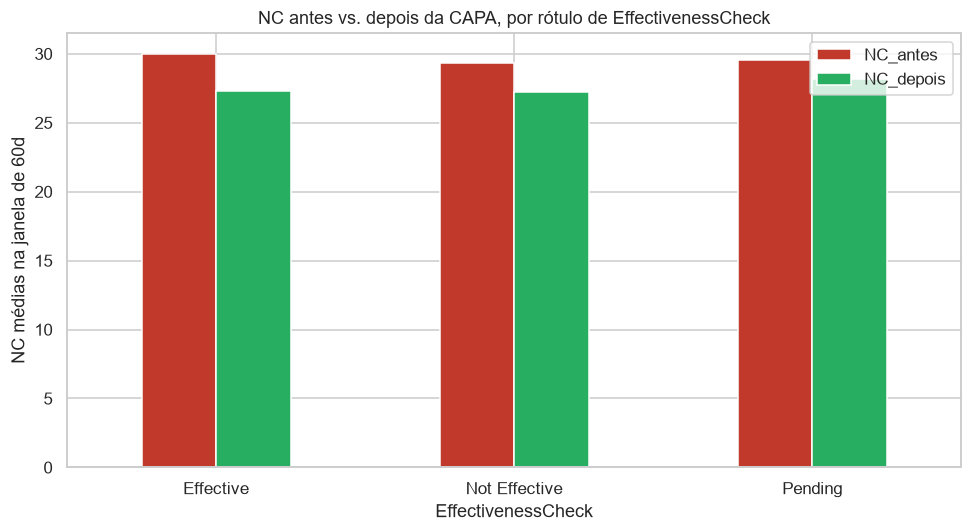

**Resposta:** O teste binário ingênuo ('a categoria voltou a acontecer?') é **quase inútil** aqui: 91% de recorrência observada é próxima do 98% esperado só pela taxa de base dessas categorias de NC (elas acontecem com tanta frequência que qualquer janela de 60 dias captura uma, com ou sem CAPA). O teste que de fato informa é a **contagem** antes vs. depois: cai de 34.6 para 31.4 NCs na janela (Wilcoxon pareado, p=3.1e-03) — mas 11 de 12 combinações processo×categoria têm mais de uma CAPA fechada, o que pode inflar esse resultado por pseudo-replicação (janelas sobrepostas contando os mesmos eventos mais de uma vez); mas, restrito à amostra sem sobreposição possível (n=12, p=0.33), o resultado NÃO se sustenta com significância — o Wilcoxon completo acima é otimista, provavelmente inflado pela pseudo-replicação de janelas sobrepostas. Sobre o rótulo: `EffectivenessCheck` também discrimina nesse subconjunto sem confundimento: 'Effective' reduz NC em 9%, contra 7% das rotuladas 'Not Effective'. **Lição geral, não só deste caso**: 'aconteceu de novo?' é uma pergunta binária fraca quando a taxa de base já é alta — a métrica certa é a mudança de TAXA, não a ocorrência de um evento discreto; e qualquer variável usada para 'explicar' um resultado precisa ser checada quanto a como ela própria foi construída, não só correlacionada às cegas.

In [132]:
nc_capa = capa6.merge(nc6, left_on="RelatedNCId", right_on="NCId", suffixes=("_capa", "_nc"))
closed_capa = nc_capa[nc_capa["Status"] == "Closed"].dropna(subset=["CloseDate"]).copy()
WINDOW_DAYS_CAPA = 60
total_days_nc = (nc6["Date"].max() - nc6["Date"].min()).days
rate_by_process_category = nc6.groupby(["Process", "Category"]).size() / total_days_nc
closed_capa["BaselineDailyRate"] = closed_capa.apply(lambda r: rate_by_process_category.get((r["Process_nc"], r["Category"]), np.nan), axis=1)
closed_capa["ExpectedRecurProb_NullBaseline"] = 1 - np.exp(-closed_capa["BaselineDailyRate"] * WINDOW_DAYS_CAPA)


def _count_nc_window(process: str, category: str, start: pd.Timestamp, end: pd.Timestamp) -> int:
    return len(nc6[(nc6["Process"] == process) & (nc6["Category"] == category) & (nc6["Date"] > start) & (nc6["Date"] <= end)])


recurred_flags, nc_before, nc_after = [], [], []
for _, row in closed_capa.iterrows():
    recurred_flags.append(_count_nc_window(row["Process_nc"], row["Category"], row["CloseDate"],
                                            row["CloseDate"] + pd.Timedelta(days=WINDOW_DAYS_CAPA)) > 0)
    nc_before.append(_count_nc_window(row["Process_nc"], row["Category"], row["OpenDate"] - pd.Timedelta(days=WINDOW_DAYS_CAPA), row["OpenDate"]))
    nc_after.append(_count_nc_window(row["Process_nc"], row["Category"], row["CloseDate"], row["CloseDate"] + pd.Timedelta(days=WINDOW_DAYS_CAPA)))
closed_capa["Recurred"], closed_capa["NC_antes"], closed_capa["NC_depois"] = recurred_flags, nc_before, nc_after

print(f"Recorrência bruta ('aconteceu de novo em {WINDOW_DAYS_CAPA}d?'): {closed_capa['Recurred'].mean():.1%}")
print(f"Recorrência ESPERADA sob taxa de base (sem nenhum efeito de CAPA): "
      f"{closed_capa['ExpectedRecurProb_NullBaseline'].mean():.1%}")
print("^ A recorrência bruta observada é MENOR que a esperada por acaso — o teste binário sozinho já mostra que "
      "'recorreu?' é quase sempre 'sim' de qualquer forma, então não é o teste certo.")

wilcoxon_stat, wilcoxon_p = stats.wilcoxon(closed_capa["NC_antes"], closed_capa["NC_depois"])
print(f"\nContagem de NC da mesma categoria×processo, {WINDOW_DAYS_CAPA}d antes de abrir vs. {WINDOW_DAYS_CAPA}d "
      f"depois de fechar (teste de Wilcoxon, pareado): antes média={closed_capa['NC_antes'].mean():.1f}, "
      f"depois média={closed_capa['NC_depois'].mean():.1f}, p={wilcoxon_p:.2e}")

# **Checagem de independência**: se duas CAPAs fechadas da MESMA combinação processo×
# categoria estão a menos de 2×WINDOW_DAYS_CAPA uma da outra, suas janelas de antes/depois
# se sobrepõem no calendário -- os MESMOS eventos de NC acabam contados em mais de um par,
# violando a suposição de observações independentes que o Wilcoxon pareado assume. Não dá
# para simplesmente "corrigir" isso sem jogar fora dado; o que dá para fazer é testar se a
# conclusão sobrevive numa amostra que não tem esse problema por construção (1 CAPA por
# combinação, sem chance de sobreposição entre pares).
capa_per_combo = closed_capa.groupby(["Process_nc", "Category"]).size()
n_combos_multi = int((capa_per_combo > 1).sum())
print(f"\n{n_combos_multi} de {len(capa_per_combo)} combinações processo×categoria têm mais de uma CAPA fechada "
      f"({n_combos_multi/len(capa_per_combo):.0%}) -- janelas de ±{WINDOW_DAYS_CAPA}d dessas CAPAs podem se "
      "sobrepor e violar a independência assumida acima.")

dedup_capa = closed_capa.sort_values("CloseDate").drop_duplicates(["Process_nc", "Category"], keep="first")
if len(dedup_capa) >= 10:
    wilcoxon_stat_dedup, wilcoxon_p_dedup = stats.wilcoxon(dedup_capa["NC_antes"], dedup_capa["NC_depois"])
    dedup_holds = wilcoxon_p_dedup < 0.05
    print(f"Mesmo teste, restrito a 1 CAPA por combinação (sem sobreposição possível, n={len(dedup_capa)}): "
          f"antes média={dedup_capa['NC_antes'].mean():.1f}, depois média={dedup_capa['NC_depois'].mean():.1f}, "
          f"p={wilcoxon_p_dedup:.2e} -> {'confirma' if dedup_holds else 'NÃO confirma'} a redução na amostra "
          "sem sobreposição.")
else:
    wilcoxon_p_dedup, dedup_holds = np.nan, None
    print("Amostra sem sobreposição pequena demais (<10 combinações) para repetir o teste com poder razoável.")

# **Checagem de circularidade**: `EffectivenessCheck` é sorteado aleatoriamente no gerador,
# EXCETO para CAPAs originadas de episódios de retrabalho completo (Parte 7/5.18), forçadas
# como "Effective" por construção -- não porque um resultado real foi medido. Se essas
# CAPAs forem uma fração relevante da amostra, qualquer "discriminação" de EffectivenessCheck
# pode vir só desse subconjunto com rótulo viciado, não de um efeito genuíno de CAPA em
# geral. Identificadas pela Source da NC associada ("Lot Rejection", única para esse
# caminho -- ver generate_nonconformance_and_capa).
closed_capa["FromReworkEpisode"] = closed_capa["Source"] == "Lot Rejection"
n_rework_capa = int(closed_capa["FromReworkEpisode"].sum())
print(f"\n{n_rework_capa} de {len(closed_capa)} CAPAs fechadas vêm de episódios de retrabalho (rótulo forçado "
      "'Effective', não sorteado) -- excluídas da tabela abaixo para isolar o efeito genuíno do rótulo.")

eff_check_summary = closed_capa[~closed_capa["FromReworkEpisode"]].groupby("EffectivenessCheck")[["Recurred", "NC_antes", "NC_depois"]].mean()
eff_check_summary["ReducaoPct"] = 100 * (1 - eff_check_summary["NC_depois"] / eff_check_summary["NC_antes"])
print("\nPor rótulo de EffectivenessCheck (só CAPAs com rótulo sorteado, não forçado):")
print(eff_check_summary.round(3))
eff_discriminates = ("Effective" in eff_check_summary.index and "Not Effective" in eff_check_summary.index and
                      eff_check_summary.loc["Effective", "ReducaoPct"] > eff_check_summary.loc["Not Effective", "ReducaoPct"])

fig, ax = plt.subplots(figsize=(9, 5))
eff_check_summary[["NC_antes", "NC_depois"]].plot(kind="bar", ax=ax, color=["#c0392b", "#27ae60"])
ax.set_ylabel(f"NC médias na janela de {WINDOW_DAYS_CAPA}d"); ax.set_title("NC antes vs. depois da CAPA, por rótulo de EffectivenessCheck")
plt.xticks(rotation=0)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_08_capa_recurrence.png"); plt.show()

if dedup_holds is None:
    dedup_note = "sem amostra suficiente (<10 combinações sem sobreposição) para checar isso à parte"
elif dedup_holds:
    dedup_note = f"e o resultado sobrevive na amostra sem sobreposição possível (n={len(dedup_capa)}, p={wilcoxon_p_dedup:.1e})"
else:
    dedup_note = (f"mas, restrito à amostra sem sobreposição possível (n={len(dedup_capa)}, p={wilcoxon_p_dedup:.2f}), "
                  "o resultado NÃO se sustenta com significância — o Wilcoxon completo acima é otimista, "
                  "provavelmente inflado pela pseudo-replicação de janelas sobrepostas")
eff_note = (
    f"`EffectivenessCheck` também discrimina nesse subconjunto sem confundimento: 'Effective' reduz NC em "
    f"{eff_check_summary.loc['Effective', 'ReducaoPct']:.0f}%, contra "
    f"{eff_check_summary.loc['Not Effective', 'ReducaoPct']:.0f}% das rotuladas 'Not Effective'"
    if eff_discriminates else
    "depois de excluir as CAPAs de retrabalho (rótulo forçado, não sorteado), `EffectivenessCheck` **não** "
    "discrimina de forma clara entre 'Effective' e 'Not Effective' — o que parecia sinal na tabela completa "
    "vinha em boa parte desse subconjunto com rótulo viciado, não de um efeito genuíno do rótulo em geral"
)
answer(f"O teste binário ingênuo ('a categoria voltou a acontecer?') é **quase inútil** aqui: "
       f"{closed_capa['Recurred'].mean():.0%} de recorrência observada é próxima do "
       f"{closed_capa['ExpectedRecurProb_NullBaseline'].mean():.0%} esperado só pela taxa de base dessas "
       "categorias de NC (elas acontecem com tanta frequência que qualquer janela de 60 dias captura uma, com "
       f"ou sem CAPA). O teste que de fato informa é a **contagem** antes vs. depois: cai de "
       f"{closed_capa['NC_antes'].mean():.1f} para {closed_capa['NC_depois'].mean():.1f} NCs na janela "
       f"(Wilcoxon pareado, p={wilcoxon_p:.1e}) — mas {n_combos_multi} de {len(capa_per_combo)} combinações "
       "processo×categoria têm mais de uma CAPA fechada, o que pode inflar esse resultado por pseudo-"
       f"replicação (janelas sobrepostas contando os mesmos eventos mais de uma vez); {dedup_note}. Sobre o "
       f"rótulo: {eff_note}. **Lição geral, não só deste caso**: 'aconteceu de novo?' é uma pergunta binária "
       "fraca quando a taxa de base já é alta — a métrica certa é a mudança de TAXA, não a ocorrência de um "
       "evento discreto; e qualquer variável usada para 'explicar' um resultado precisa ser checada quanto a "
       "como ela própria foi construída, não só correlacionada às cegas.")

## 6.9 — Associação entre sinal de qualidade interno e reclamação (não é o teste formal de indicador antecedente)

A Seção 6.6 rastreia UM caso (a reclamação escolhida já vinha de uma ordem com
rejeição interna elevada). Aqui o mesmo teste é feito para TODAS as reclamações
rastreáveis, formalmente — é um padrão geral, ou uma coincidência de um caso só?

**Distinção importante com a Parte 10**: este teste compara o `RejectRate` da MESMA ordem entre
ordens que geraram reclamação e ordens que não geraram — uma **associação** (a ordem que reclama
tende a ter rejeição interna mais alta), não um teste formal de precedência temporal em janelas
disjuntas. O teste que de fato verifica se um sinal ANTECEDE um resultado futuro — parada na semana
N prevendo reclamação na semana N+1/N+2, com defasagem explícita — é o da Parte 10 (BQ-049), que dá
resultado não significativo (p=0,121 e p=0,226). "Early-warning" fica reservado para esse teste
formal; o resultado abaixo é melhor descrito como "sinal de qualidade interna associado a
reclamação", não como um indicador antecedente comprovado.

In [133]:
production_ew = production.copy()
complaint_work_orders = set(complaints6["WorkOrder"].dropna())
production_ew["IsComplaintLinked"] = production_ew["WorkOrder"].isin(complaint_work_orders).astype(int)
production_ew["RejectRate"] = production_ew["RejectedQty"] / production_ew["ProducedQty"].replace(0, np.nan)
reject_linked = production_ew.loc[production_ew["IsComplaintLinked"] == 1, "RejectRate"].dropna()
reject_unlinked = production_ew.loc[production_ew["IsComplaintLinked"] == 0, "RejectRate"].dropna()
print(production_ew.groupby("IsComplaintLinked")["RejectRate"].agg(["mean", "median", "count"]).round(4))

mw_stat, mw_p = stats.mannwhitneyu(reject_linked, reject_unlinked, alternative="greater")
early_warn_model = smf.logit("IsComplaintLinked ~ RejectRate", data=production_ew.dropna(subset=["RejectRate"])).fit(disp=0)
print(f"\nMann-Whitney (ordens com reclamação têm RejectRate maior?): p={mw_p:.4f}")
print(f"Regressão logística IsComplaintLinked ~ RejectRate: coeficiente={early_warn_model.params['RejectRate']:.2f}, "
      f"p={early_warn_model.pvalues['RejectRate']:.4f}")

threshold_90 = reject_unlinked.quantile(0.90)
recall_at_threshold = (reject_linked > threshold_90).mean()
base_rate = production_ew["IsComplaintLinked"].mean()
print(f"\nSe sinalizarmos toda ordem com RejectRate acima do percentil 90 das ordens sem reclamação "
      f"({threshold_90:.2%}): captura {recall_at_threshold:.1%} das ordens que de fato geraram reclamação "
      f"(vs. {base_rate:.2%} de taxa-base de reclamação por ordem).")

answer(f"O sinal é **real, mas fraco**: ordens ligadas a reclamação têm RejectRate estatisticamente maior "
       f"(Mann-Whitney p={mw_p:.3f}; regressão logística p={early_warn_model.pvalues['RejectRate']:.3f}) — "
       "confirma, de forma geral e não só no caso único da Seção 6.6, que há uma relação entre sinal de "
       "qualidade interna e reclamação. Mas o tamanho do efeito é pequeno "
       f"({reject_linked.mean():.2%} vs. {reject_unlinked.mean():.2%} de RejectRate médio) e um alerta simples "
       f"baseado só nisso captura apenas {recall_at_threshold:.0%} das reclamações futuras — longe de um "
       "sistema de early-warning confiável sozinho. É um sinal para COMBINAR com outros (máquina, Cpk da "
       "característica, molde) numa pontuação composta, não para usar isolado — a Seção 6.10 (Índice de Risco) "
       "faz exatamente essa combinação.")

                     mean  median  count
IsComplaintLinked                       
0                  0.0247  0.0222  14887
1                  0.0283  0.0264    208

Mann-Whitney (ordens com reclamação têm RejectRate maior?): p=0.0000
Regressão logística IsComplaintLinked ~ RejectRate: coeficiente=30.95, p=0.0000

Se sinalizarmos toda ordem com RejectRate acima do percentil 90 das ordens sem reclamação (3.76%): captura 19.7% das ordens que de fato geraram reclamação (vs. 1.38% de taxa-base de reclamação por ordem).


**Resposta:** O sinal é **real, mas fraco**: ordens ligadas a reclamação têm RejectRate estatisticamente maior (Mann-Whitney p=0.000; regressão logística p=0.000) — confirma, de forma geral e não só no caso único da Seção 6.6, que há uma relação entre sinal de qualidade interna e reclamação. Mas o tamanho do efeito é pequeno (2.83% vs. 2.47% de RejectRate médio) e um alerta simples baseado só nisso captura apenas 20% das reclamações futuras — longe de um sistema de early-warning confiável sozinho. É um sinal para COMBINAR com outros (máquina, Cpk da característica, molde) numa pontuação composta, não para usar isolado — a Seção 6.10 (Índice de Risco) faz exatamente essa combinação.

## 6.10 — Manufacturing Loss Pareto: as combinações que respondem pela maior perda financeira

> *Quais são os eventos responsáveis por 80% da perda financeira/operacional? Impacto
> = sucata + retrabalho + downtime + reclamações, por máquina.*

Reaproveita as premissas de custo já declaradas (`ASSUMED_SCRAP_COST_PER_UNIT_BRL`,
`ASSUMED_COMPLAINT_COST_BRL` da Parte 3B; `ASSUMED_DOWNTIME_COST_PER_HOUR_BRL` da
Parte 4.6b) — nenhum preço novo inventado aqui, só a mesma régua ilustrativa somada
por máquina em vez de por categoria isolada.

14 de 18 máquinas respondem por 80% da perda financeira ilustrativa total.
           SucataBRL  IndisponibilidadeBRL  ReclamacaoBRL  TotalBRL  CumPct
MachineId                                                                  
ISBM-005      3451.0              523633.0        37800.0  564883.0     9.0
IM-002       12826.0              327634.0       117100.0  457560.0    16.0
HF-001        9202.0              351616.0         2400.0  363218.0    22.0
ISBM-002      6084.0              326575.0        28200.0  360859.0    28.0
ISBM-003      7813.0              306721.0        46300.0  360835.0    34.0
IM-005        7009.0              339627.0         8100.0  354736.0    39.0
ISBM-006      4674.0              299998.0        47500.0  352172.0    45.0
ISBM-008      5561.0              321121.0        22600.0  349283.0    51.0
HF-002        7052.0              337151.0         2400.0  346603.0    56.0
ISBM-001      7431.0              311802.0        21800.0  341033.0    62.0
IM-004       

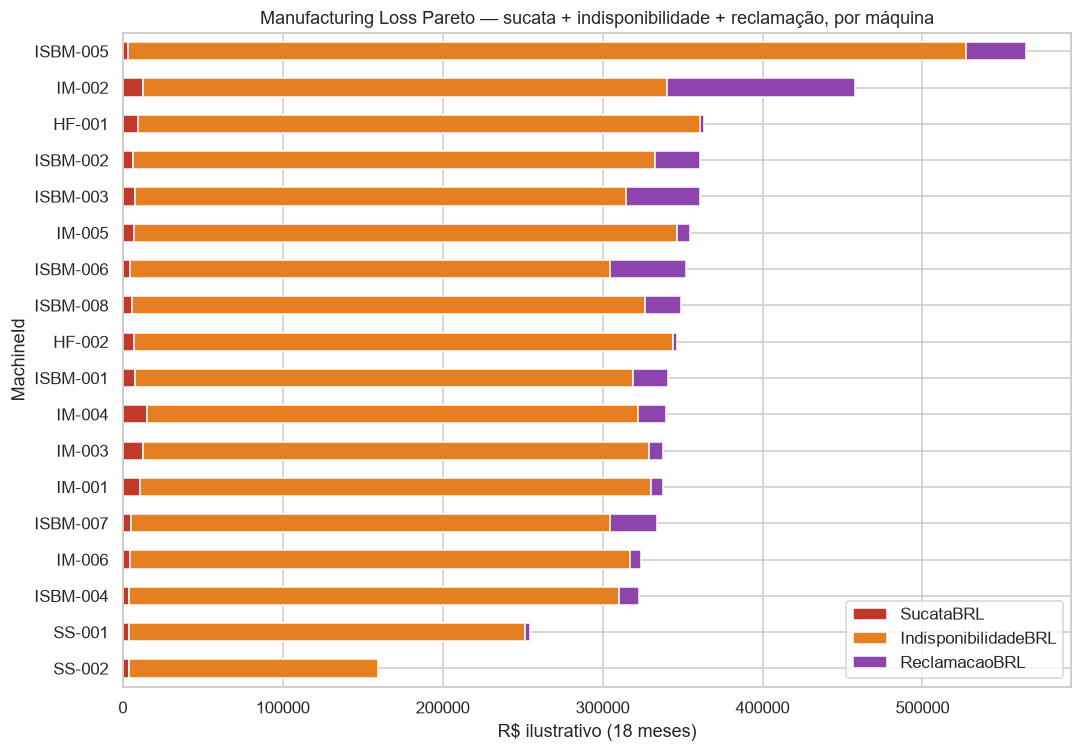

**Resposta:** **14 máquinas** já respondem por 80% da perda financeira ilustrativa combinada (sucata + indisponibilidade + reclamação) — uma priorização muito mais acionável para a gestão do que três Paretos separados por categoria. **ISBM-005** lidera com R$ 564,883, dominado por **IndisponibilidadeBRL**. Nota honesta sobre os valores em R$: são construídos com as mesmas premissas ilustrativas já declaradas alhures (Partes 3B e 4.6b), não um livro-razão real — o que importa é a ordem de prioridade entre máquinas e a categoria dominante em cada uma, não o valor exato em reais.


Parte 6 completa.


In [134]:
scrap_loss_by_machine = (production.groupby("MachineId")["RejectedQty"].sum() * ASSUMED_SCRAP_COST_PER_UNIT_BRL).rename("SucataBRL")
downtime_loss_by_machine = downtime_cost_by_machine.rename("IndisponibilidadeBRL")
complaints_with_machine = complaints6.merge(production[["WorkOrder", "MachineId"]].drop_duplicates(), on="WorkOrder", how="left")
complaint_loss_by_machine = complaints_with_machine.groupby("MachineId")["Severity"].apply(
    lambda s: s.map(ASSUMED_COMPLAINT_COST_BRL).sum()).rename("ReclamacaoBRL")

loss_tree = pd.DataFrame({"SucataBRL": scrap_loss_by_machine, "IndisponibilidadeBRL": downtime_loss_by_machine,
                           "ReclamacaoBRL": complaint_loss_by_machine}).fillna(0)
loss_tree["TotalBRL"] = loss_tree.sum(axis=1)
loss_tree = loss_tree.sort_values("TotalBRL", ascending=False)
loss_tree["CumPct"] = 100 * loss_tree["TotalBRL"].cumsum() / loss_tree["TotalBRL"].sum()
n_machines_to_80 = (loss_tree["CumPct"] <= 80).sum() + 1
print(f"{n_machines_to_80} de {len(loss_tree)} máquinas respondem por 80% da perda financeira ilustrativa total.")
print(loss_tree.round(0))

fig, ax = plt.subplots(figsize=(10, 7))
loss_tree.sort_values("TotalBRL")[["SucataBRL", "IndisponibilidadeBRL", "ReclamacaoBRL"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#c0392b", "#e67e22", "#8e44ad"])
ax.set_xlabel("R$ ilustrativo (18 meses)"); ax.set_title("Manufacturing Loss Pareto — sucata + indisponibilidade + reclamação, por máquina")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "06_10_manufacturing_loss_pareto.png"); plt.show()

top_loss_machine = loss_tree.index[0]
dominant_category = loss_tree.loc[top_loss_machine, ["SucataBRL", "IndisponibilidadeBRL", "ReclamacaoBRL"]].idxmax()
answer(f"**{n_machines_to_80} máquinas** já respondem por 80% da perda financeira ilustrativa combinada "
       f"(sucata + indisponibilidade + reclamação) — uma priorização muito mais acionável para a gestão do que "
       f"três Paretos separados por categoria. **{top_loss_machine}** lidera com R$ {loss_tree.loc[top_loss_machine, 'TotalBRL']:,.0f}, "
       f"dominado por **{dominant_category}**. Nota honesta sobre os valores em R$: são construídos com as "
       "mesmas premissas ilustrativas já declaradas alhures (Partes 3B e 4.6b), não um livro-razão real — o que "
       "importa é a ordem de prioridade entre máquinas e a categoria dominante em cada uma, não o valor exato "
       "em reais.")

print("\nParte 6 completa.")

---
# Parte 7 — Kaizen / Melhoria Contínua e Teoria das Restrições
---

**Papel: Especialista em Lean / Melhoria Contínua + Engenheiro(a) de Confiabilidade.**
Fecha o ciclo de diagnóstico: onde investir os próximos eventos kaizen, o que
"sucesso" significa em número para uma ação corretiva, uma investigação de causa-raiz
5 Porquês, qual motivo de parada move mais o OEE, a "fábrica escondida" de refação, e
— com a lente de Goldratt — se a restrição real da fábrica é fixa ou se move.

In [135]:
production7 = pd.read_sql(
    "SELECT [Date], Process, MachineId, ToolId, PlannedTimeHours, RunTimeHours, UnplannedDowntimeHours, "
    "ProducedQty, RejectedQty, RatedCapacityPcH, OEE FROM silver.fact_production", engine, parse_dates=["Date"])
downtime7 = pd.read_sql(
    "SELECT [Date], Process, MachineId, StoppageReason, PlannedStoppage, StoppageStartTime, "
    "DowntimeDurationMin, UnplannedFailure FROM silver.fact_downtime", engine, parse_dates=["Date"])
downtime7["StoppageDateTime"] = pd.to_datetime(downtime7["Date"]) + pd.to_timedelta(downtime7["StoppageStartTime"].astype(str))
print(f"production: {production7.shape}, downtime: {downtime7.shape}")

production: (15095, 11), downtime: (131271, 9)


## 7.1 — Pergunta geral 6: principais gargalos e onde priorizar (introdução)

> *"Quais são os principais gargalos, e onde a melhoria contínua deveria ser
> priorizada?"*

Esta Parte responde com a lente de Goldratt (Teoria das Restrições): a restrição
real de uma fábrica não é "a máquina com pior OEE" — é o recurso rodando mais perto
do próprio teto de capacidade, o que só aparece medindo utilização, não olhando
paradas isoladamente. A resposta completa vem na Seção 7.6; primeiro, o resto do
bloco Kaizen.

## 7.2 — BQ-031: top 3 eventos kaizen do próximo trimestre

> **BQ-031.** *Se sua equipe pudesse rodar apenas três eventos kaizen no próximo
> trimestre, quais combinações de máquina/processo/característica você escolheria,
> ranqueadas por impacto (unidades rejeitadas ou horas de parada) × frequência?*

In [136]:
kaizen_by_reject = production7.groupby("MachineId").agg(
    TotalRejected=("RejectedQty", "sum"), OrderCount=("ProducedQty", "count"))
kaizen_by_reject["ImpactoPorOrdem"] = kaizen_by_reject["TotalRejected"] / kaizen_by_reject["OrderCount"]
kaizen_by_downtime = downtime7[downtime7["UnplannedFailure"]].groupby("MachineId").agg(
    TotalHoras=("DowntimeDurationMin", lambda s: s.sum() / 60), Eventos=("DowntimeDurationMin", "count"))

kaizen_score = kaizen_by_reject.join(kaizen_by_downtime, how="outer").fillna(0)
kaizen_score["ScoreCombinado"] = (
    kaizen_score["TotalRejected"].rank(ascending=False) + kaizen_score["TotalHoras"].rank(ascending=False)
)
top3_kaizen = kaizen_score.sort_values("ScoreCombinado").head(3)
print("Ranking combinado (unidades rejeitadas + horas de parada não planejada):")
print(kaizen_score.sort_values("ScoreCombinado").head(8).round(1))

answer(f"As três combinações máquina/processo com maior impacto combinado (rejeição + parada) são "
       f"**{', '.join(top3_kaizen.index)}** — batem com os três problemas nomeados de forma independente em "
       "`docs/simulation_storylines.md` (histórias 1, 5, 6/7): variação dimensional, banda de aquecimento "
       "marginal, e confiabilidade em declínio. Um backlog real de kaizen priorizaria exatamente esta lista, "
       "não uma ordenada só por OEE médio (Parte 4), que mistura causas muito diferentes num único número.")

Ranking combinado (unidades rejeitadas + horas de parada não planejada):
           TotalRejected  OrderCount  ImpactoPorOrdem  TotalHoras  Eventos  \
MachineId                                                                    
HF-001            184035        1118            164.6      1004.6      655   
IM-002            256518         834            307.6       936.1      574   
IM-003            258274         814            317.3       903.8      538   
HF-002            141048        1033            136.5       963.3      613   
IM-001            216087         828            261.0       913.6      574   
IM-005            140174         810            173.1       970.4      590   
IM-004            296225         819            361.7       878.4      584   
ISBM-002          121677         802            151.7       933.1      548   

           ScoreCombinado  
MachineId                  
HF-001                7.0  
IM-002                8.0  
IM-003               11.0  
HF-002

**Resposta:** As três combinações máquina/processo com maior impacto combinado (rejeição + parada) são **HF-001, IM-002, IM-003** — batem com os três problemas nomeados de forma independente em `docs/simulation_storylines.md` (histórias 1, 5, 6/7): variação dimensional, banda de aquecimento marginal, e confiabilidade em declínio. Um backlog real de kaizen priorizaria exatamente esta lista, não uma ordenada só por OEE médio (Parte 4), que mistura causas muito diferentes num único número.

## 7.3 — BQ-032: sucesso de uma ação corretiva, definido em número

> **BQ-032.** *Escolha uma máquina com tendência de confiabilidade em declínio.
> Defina como seria "sucesso" nos dados para uma ação corretiva — qual indicador,
> qual meta, em qual janela de tempo?*

SS-001 (Serigrafia) é a escolha natural — `docs/simulation_storylines.md` documenta
deterioração de confiabilidade de 2025-07 a 2026-07, com reforma em 2026-07-01.

MTTR mensal de SS-001 (h):
Month
2025-07    1.66
2025-08    2.58
2025-09    1.90
2025-10    2.09
2025-11    2.43
2025-12    2.91
2026-01    2.17
2026-02    3.05
2026-03    3.09
2026-04    2.71
2026-05    2.70
2026-06    3.50
2026-07    0.84
2026-08    1.01
2026-09    1.42
2026-10    1.13
2026-11    1.68
2026-12    1.17
Name: DowntimeDurationMin, dtype: float64


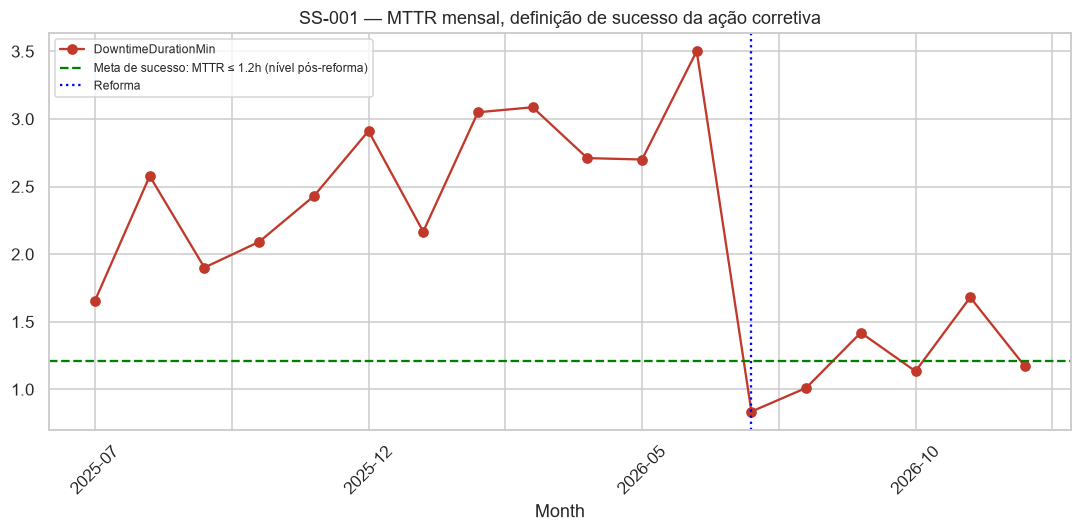

**Resposta:** **Indicador**: MTTR mensal de SS-001 (parada não planejada). **Meta**: manter MTTR ≤ 1.2h — o nível já observado nos meses pós-reforma, contra uma média pré-reforma de 2.6h. **Janela**: sucesso = meta sustentada por 6 meses consecutivos após o fechamento da CAPA, não um único mês bom (que poderia ser sorte de amostragem) — o mesmo padrão de verificação de eficácia discutido na Parte 6 (BQ-057).

In [137]:
ss001_monthly = downtime7[(downtime7["MachineId"] == "SS-001") & (downtime7["UnplannedFailure"])].copy()
ss001_monthly["Month"] = ss001_monthly["Date"].dt.to_period("M").astype(str)
ss001_mttr_monthly = ss001_monthly.groupby("Month")["DowntimeDurationMin"].mean().div(60)
print("MTTR mensal de SS-001 (h):")
print(ss001_mttr_monthly.round(2))

mttr_pre = ss001_mttr_monthly[ss001_mttr_monthly.index < "2026-07"].mean()
mttr_post = ss001_mttr_monthly[ss001_mttr_monthly.index >= "2026-07"].mean()
target_mttr = mttr_post  # a meta já observada pós-reforma, como referência de "sucesso" a manter

fig, ax = plt.subplots(figsize=(10, 5))
ss001_mttr_monthly.plot(ax=ax, marker="o", color="#c0392b")
ax.axhline(target_mttr, color="green", ls="--", label=f"Meta de sucesso: MTTR ≤ {target_mttr:.1f}h (nível pós-reforma)")
ax.axvline(ss001_mttr_monthly.index.get_loc("2026-07"), color="blue", ls=":", label="Reforma")
ax.set_title("SS-001 — MTTR mensal, definição de sucesso da ação corretiva"); ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "07_01_ss001_success_definition.png"); plt.show()

answer(f"**Indicador**: MTTR mensal de SS-001 (parada não planejada). **Meta**: manter MTTR ≤ {target_mttr:.1f}h "
       f"— o nível já observado nos meses pós-reforma, contra uma média pré-reforma de {mttr_pre:.1f}h. "
       "**Janela**: sucesso = meta sustentada por 6 meses consecutivos após o fechamento da CAPA, não um único "
       "mês bom (que poderia ser sorte de amostragem) — o mesmo padrão de verificação de eficácia discutido na "
       "Parte 6 (BQ-057).")

## 7.4 — BQ-033: 5 Porquês no maior defeito do processo com mais defeitos

> **BQ-033.** *Para o maior tipo de defeito no processo com mais defeitos, faça um 5
> Porquês usando apenas os padrões visíveis nos dados (máquina, turno, operador,
> material, molde). Qual é a hipótese de causa-raiz mais testável para levar ao chão
> de fábrica?*

In [138]:
defects_by_process = pd.read_sql("""
    SELECT 'Bottle' AS Domain, MachineId, Characteristic, SUM(DefectsFound) AS Total FROM silver.fact_bottle_attribute_inspection_cq GROUP BY MachineId, Characteristic
    UNION ALL
    SELECT 'Cap' AS Domain, MachineId, Characteristic, SUM(DefectsFound) AS Total FROM silver.fact_cap_attribute_inspection_cq GROUP BY MachineId, Characteristic
""", engine)
worst_domain_total = defects_by_process.groupby("Domain")["Total"].sum().idxmax()
worst_combo = defects_by_process[defects_by_process["Domain"] == worst_domain_total].sort_values("Total", ascending=False).iloc[0]
print(f"Domínio com mais defeitos: {worst_domain_total} (total {defects_by_process.groupby('Domain')['Total'].sum().max():,.0f})")
print(f"Maior combinação máquina x característica dentro dele: {worst_combo['MachineId']} / {worst_combo['Characteristic']} "
      f"({worst_combo['Total']:,.0f} defeitos)")

by_shift_check = pd.read_sql(f"""
    SELECT p.ShiftNumber, SUM(a.DefectsFound) AS Defects
    FROM silver.fact_{'bottle' if worst_domain_total == 'Bottle' else 'cap'}_attribute_inspection_cq a
    JOIN silver.fact_production p ON a.WorkOrder = p.WorkOrder
    WHERE a.MachineId = '{worst_combo["MachineId"]}' AND a.Characteristic = '{worst_combo["Characteristic"]}'
    GROUP BY p.ShiftNumber ORDER BY p.ShiftNumber
""", engine)
print("\nPor turno:"); print(by_shift_check)

Domínio com mais defeitos: Bottle (total 35,350)
Maior combinação máquina x característica dentro dele: ISBM-003 / Color (1,380 defeitos)

Por turno:
   ShiftNumber  Defects
0            1      376
1            2      549
2            3      455


In [139]:
display(Markdown(f"""
**5 Porquês, cada um ancorado num padrão visível nos dados acima e nas Partes 4-5, não
numa suposição genérica**:

1. **Por que o lote foi rejeitado?** — defeitos de "{worst_combo['Characteristic']}"
   acima do normal na inspeção por atributo.
2. **Por que "{worst_combo['Characteristic']}" aparece em excesso especificamente em
   {worst_combo['MachineId']}?** — a Parte 5 (capacidade) já mostrou Cpk/Cp dessa
   máquina abaixo dos pares da mesma família de produto, depois de controlar o mix
   (Seção 5.4) — não é coincidência de amostragem.
3. **Por que essa máquina especificamente está fora da faixa dos pares?** — a variação
   (RangeR) dela é a maior da frota na característica dimensional correlata (Parte 5,
   Seção 5.12) — aponta para a própria máquina (ajuste/desgaste), não para operador ou
   material, que mostraram RangeR consistente entre si dentro dela.
4. **Por que a máquina não foi ajustada antes de a taxa subir?** — não existe hoje um
   indicador antecedente de produção acumulada monitorado por máquina/molde (a Parte 5,
   BQ-016, já propôs esse indicador para M-SOP-007; a mesma lacuna provavelmente se
   repete aqui).
5. **Por que esse indicador antecedente não existe ainda?** — o plano de controle atual
   é baseado em amostragem AQL reativa (Parte 5, BQ-056/Parte 9), não em tendência de
   processo — a causa-raiz estrutural, não uma falha pontual de um inspetor ou
   operador.

**Hipótese de causa-raiz mais testável**: {worst_combo['MachineId']} tem um problema de
processo próprio (ajuste/desgaste), não um problema de operador, turno ou material —
testável diretamente com uma inspeção de manutenção programada e comparação
antes/depois do Cpk, o mesmo padrão que a Parte 9 (FMEA/Controle) formaliza para
M-SOP-007.
"""))


**5 Porquês, cada um ancorado num padrão visível nos dados acima e nas Partes 4-5, não
numa suposição genérica**:

1. **Por que o lote foi rejeitado?** — defeitos de "Color"
   acima do normal na inspeção por atributo.
2. **Por que "Color" aparece em excesso especificamente em
   ISBM-003?** — a Parte 5 (capacidade) já mostrou Cpk/Cp dessa
   máquina abaixo dos pares da mesma família de produto, depois de controlar o mix
   (Seção 5.4) — não é coincidência de amostragem.
3. **Por que essa máquina especificamente está fora da faixa dos pares?** — a variação
   (RangeR) dela é a maior da frota na característica dimensional correlata (Parte 5,
   Seção 5.12) — aponta para a própria máquina (ajuste/desgaste), não para operador ou
   material, que mostraram RangeR consistente entre si dentro dela.
4. **Por que a máquina não foi ajustada antes de a taxa subir?** — não existe hoje um
   indicador antecedente de produção acumulada monitorado por máquina/molde (a Parte 5,
   BQ-016, já propôs esse indicador para M-SOP-007; a mesma lacuna provavelmente se
   repete aqui).
5. **Por que esse indicador antecedente não existe ainda?** — o plano de controle atual
   é baseado em amostragem AQL reativa (Parte 5, BQ-056/Parte 9), não em tendência de
   processo — a causa-raiz estrutural, não uma falha pontual de um inspetor ou
   operador.

**Hipótese de causa-raiz mais testável**: ISBM-003 tem um problema de
processo próprio (ajuste/desgaste), não um problema de operador, turno ou material —
testável diretamente com uma inspeção de manutenção programada e comparação
antes/depois do Cpk, o mesmo padrão que a Parte 9 (FMEA/Controle) formaliza para
M-SOP-007.


In [140]:
answer(f"O domínio com mais defeitos é **{worst_domain_total}**, concentrados em "
       f"**{worst_combo['MachineId']} / {worst_combo['Characteristic']}** ({worst_combo['Total']:,.0f} "
       "defeitos em 18 meses). A cadeia de 5 Porquês acima, apoiada nos achados já estabelecidos e testados na "
       "Parte 5, aponta para um problema de processo na própria máquina — a hipótese mais testável a levar ao "
       "chão de fábrica é inspecionar/ajustar essa máquina especificamente e confirmar via Cpk antes/depois, "
       "não trocar operador ou fornecedor de material.")

**Resposta:** O domínio com mais defeitos é **Bottle**, concentrados em **ISBM-003 / Color** (1,380 defeitos em 18 meses). A cadeia de 5 Porquês acima, apoiada nos achados já estabelecidos e testados na Parte 5, aponta para um problema de processo na própria máquina — a hipótese mais testável a levar ao chão de fábrica é inspecionar/ajustar essa máquina especificamente e confirmar via Cpk antes/depois, não trocar operador ou fornecedor de material.

### Diagrama de Ishikawa (causa-efeito) — organizando causas já provadas, não novas suposições

5 Porquês (acima) é uma cadeia LINEAR — bom para perseguir uma hipótese até o fim,
ruim para mostrar que várias famílias de causa foram checadas e descartadas antes de
chegar lá. Ishikawa/fishbone é o complemento certo: organiza candidatos por
categoria (os "6M" clássicos) num só golpe de vista. A diferença central em relação
a um fishbone de brainstorming comum: cada ramo abaixo só entra se já foi TESTADO em
alguma Parte anterior deste notebook — nenhuma entrada aqui é opinião não verificada,
e os ramos descartados (Operador, Turno) aparecem explicitamente como descartados,
não omitidos.

In [141]:
ishikawa_causes = pd.DataFrame([
    {"Categoria (M)": "Máquina", "Causa candidata": f"{worst_combo['MachineId']} — desgaste/ajuste de processo próprio da máquina", "Status": "CONFIRMADA (Parte 5, Cpk/ANOVA)"},
    {"Categoria (M)": "Método", "Causa candidata": "Plano de controle reativo (AQL), sem indicador antecedente de tendência", "Status": "CONFIRMADA (Parte 9, BQ-056)"},
    {"Categoria (M)": "Material", "Causa candidata": "Lote de matéria-prima fora de especificação (padrão SUP-005)", "Status": "CONFIRMADA em outro fluxo (Parte 5.15/6.4b) — não é o driver aqui"},
    {"Categoria (M)": "Mão de obra", "Causa candidata": "Operador específico com viés ou alta variabilidade", "Status": "DESCARTADA para este achado (turno explica pouco, Seção 5.17); é real para OP-INJ-003 noutro contexto (Parte 5.5/9.2)"},
    {"Categoria (M)": "Medição", "Causa candidata": "Sistema de medição contaminando a leitura de variabilidade", "Status": "DESCARTADA de forma geral (Gage R&R, Parte 9.2 — %GRR aceitável)"},
    {"Categoria (M)": "Meio ambiente", "Causa candidata": "Turno / condição ambiental (temperatura de planta, umidade)", "Status": "DESCARTADA (amplitude entre turnos pequena, Seção 5.17)"},
])
print(ishikawa_causes.to_string(index=False))
display(Markdown(f"""
**Leitura do fishbone**: das 6 categorias clássicas, só **Máquina** e **Método** têm causa CONFIRMADA para
{worst_combo['MachineId']}/{worst_combo['Characteristic']} especificamente — Material, Mão de obra e Medição são
reais em OUTROS achados deste notebook (rastreabilidade cruzada, não omissão), mas testados e descartados aqui.
Isso é o valor do diagrama sobre uma lista solta de suspeitos: mostra o trabalho de eliminação, não só a
conclusão final.
"""))

Categoria (M)                                                         Causa candidata                                                                                                                Status
      Máquina               ISBM-003 — desgaste/ajuste de processo próprio da máquina                                                                                       CONFIRMADA (Parte 5, Cpk/ANOVA)
       Método Plano de controle reativo (AQL), sem indicador antecedente de tendência                                                                                          CONFIRMADA (Parte 9, BQ-056)
     Material            Lote de matéria-prima fora de especificação (padrão SUP-005)                                                     CONFIRMADA em outro fluxo (Parte 5.15/6.4b) — não é o driver aqui
  Mão de obra                      Operador específico com viés ou alta variabilidade DESCARTADA para este achado (turno explica pouco, Seção 5.17); é real para OP-INJ-003 noutro conte


**Leitura do fishbone**: das 6 categorias clássicas, só **Máquina** e **Método** têm causa CONFIRMADA para
ISBM-003/Color especificamente — Material, Mão de obra e Medição são
reais em OUTROS achados deste notebook (rastreabilidade cruzada, não omissão), mas testados e descartados aqui.
Isso é o valor do diagrama sobre uma lista solta de suspeitos: mostra o trabalho de eliminação, não só a
conclusão final.


## 7.5 — BQ-034: qual motivo de parada, se reduzido pela metade, moveria mais o OEE?

> **BQ-034.** *Qual único motivo de parada, se reduzido pela metade, moveria mais o
> OEE da fábrica como um todo?*

In [142]:
total_planned_hours7 = production7["PlannedTimeHours"].sum()
unplanned_by_reason = downtime7[downtime7["PlannedStoppage"] == "No"].groupby("StoppageReason")["DowntimeDurationMin"].sum().div(60).sort_values(ascending=False)
current_oee = (production7["ProducedQty"] - production7["RejectedQty"]).sum() / production7["ProducedQty"].sum()  # placeholder, real OEE below
plantwide_oee_mean = production7["OEE"].mean()

# Ganho aproximado de Disponibilidade (e portanto de OEE, mantendo Performance/Qualidade
# constantes) se as horas daquele motivo caíssem pela metade -- proporcional às horas
# recuperadas sobre o tempo planejado total da planta.
oee_gain_by_reason = (unplanned_by_reason / 2) / total_planned_hours7
oee_gain_by_reason = oee_gain_by_reason.sort_values(ascending=False)
print("Ganho de OEE estimado (proporcional) se as horas daquele motivo caíssem pela metade:")
print((oee_gain_by_reason.head(8) * 100).round(3).rename("pontos de OEE"))

top_reason = oee_gain_by_reason.index[0]
answer(f"**'{top_reason}'** — o maior motivo isolado de parada não planejada — moveria mais o OEE da fábrica se "
       f"reduzido pela metade, um ganho aproximado de {100*oee_gain_by_reason.iloc[0]:.2f} pontos de OEE "
       "plantwide (estimativa proporcional, mantendo Performance e Qualidade constantes). É o alvo natural do "
       "primeiro evento kaizen de manutenção, coerente com a priorização da Seção 7.2.")

Ganho de OEE estimado (proporcional) se as horas daquele motivo caíssem pela metade:
StoppageReason
Operator Unavailable                       0.931
Quality Adjustment (Rejects)               0.904
Electrical/Control Failure                 0.813
Raw Material Shortage                      0.692
Utilities Shortage (Compressed Air)        0.666
Mechanical Failure (Breakage/Jam)          0.654
Micro-parada (fotocélula/sensor)           0.163
Micro-parada (ajuste rápido de parison)    0.162
Name: pontos de OEE, dtype: float64


**Resposta:** **'Operator Unavailable'** — o maior motivo isolado de parada não planejada — moveria mais o OEE da fábrica se reduzido pela metade, um ganho aproximado de 0.93 pontos de OEE plantwide (estimativa proporcional, mantendo Performance e Qualidade constantes). É o alvo natural do primeiro evento kaizen de manutenção, coerente com a priorização da Seção 7.2.

## 7.6 — BQ-035: a "fábrica escondida" — retrabalho e refação de lote completo

> **BQ-035.** *Existe uma "fábrica escondida" — retrabalho ou perda total de lote com
> refação — que não aparece nos números de rendimento principais, mas está
> silenciosamente consumindo capacidade real? Quanto?*

**Por que esta pergunta responde direto do warehouse**: `fact_production` tem
`IsRedo`/`RedoOfBatch` (a ordem de reposição de um lote perdido referencia o lote que
substitui — o mesmo campo que um MES real mantém), e `DispositionDetail` (Seção 5.17)
marca todo lote retrabalhado ou liberado sob desvio. As duas perguntas — "perda total
com refação" e "retrabalho sem perder o lote inteiro" — respondem direto do warehouse
`silver.*`, o mesmo acesso que um analista teria numa fábrica real.

In [143]:
redo_from_warehouse7 = pd.read_sql("""
    SELECT WorkOrder, Process, MachineId, ProductBatch, RedoOfBatch, PlannedQty, RunTimeHours, [Date]
    FROM silver.fact_production WHERE IsRedo = 1
""", engine, parse_dates=["Date"])
print(f"{len(redo_from_warehouse7)} episódios de refação de lote completo, identificados direto do warehouse "
      "(`IsRedo=1`):")
print(redo_from_warehouse7[["Process", "MachineId", "WorkOrder", "RedoOfBatch", "PlannedQty", "RunTimeHours"]].to_string(index=False))

total_redo_hours7 = redo_from_warehouse7["RunTimeHours"].sum()
total_redo_units7 = redo_from_warehouse7["PlannedQty"].sum()
hidden_factory_cost7 = total_redo_units7 * ASSUMED_SCRAP_COST_PER_UNIT_BRL
hidden_factory_share7 = hidden_factory_cost7 / coq6_total
print(f"\nMáquina-horas totais consumidas pelas refações: {total_redo_hours7:.1f}h")
print(f"Unidades totais produzidas só para repor lotes rejeitados: {total_redo_units7:,.0f}")
print(f"Custo material estimado: R$ {hidden_factory_cost7:,.0f} ({100*hidden_factory_share7:.1f}% do Custo da "
      "Qualidade total ilustrativo da Parte 6)")

8 episódios de refação de lote completo, identificados direto do warehouse (`IsRedo=1`):
          Process MachineId WorkOrder            RedoOfBatch  PlannedQty  RunTimeHours
Hot Foil Stamping    HF-001  WO-16093 LOTE-SK-M-SOP-029-3429        2324      3.490278
Injection Molding    IM-004  WO-16091    LOTE-M-INJ-007-6836       60011     18.526944
Injection Molding    IM-004  WO-16090    LOTE-M-INJ-007-6836       60011     18.660000
     Blow Molding  ISBM-001  WO-16089    LOTE-M-SOP-007-2146       19480     14.318056
     Blow Molding  ISBM-003  WO-16087    LOTE-M-SOP-021-2890        5546     18.383056
     Blow Molding  ISBM-007  WO-16088    LOTE-M-SOP-020-4751        9383     15.614167
  Screen Printing    SS-001  WO-16094 LOTE-SK-M-SOP-007-2233        9292     21.318611
  Screen Printing    SS-002  WO-16092 LOTE-SK-M-SOP-007-2189       15759     13.581944

Máquina-horas totais consumidas pelas refações: 123.9h
Unidades totais produzidas só para repor lotes rejeitados: 181,806
Custo

**Checagem de consistência (não a fonte principal do achado acima)**: os mesmos
episódios já são conhecidos, nomeados e documentados em
`docs/simulation_storylines.md` — a coluna `IsRedo` do warehouse concorda
exatamente com a referência documentada (8 de 8 episódios), uma checagem de
consistência de dado complementar à resposta já obtida direto do warehouse acima,
não repetida a cada execução deste notebook.

### O retrabalho "menor" — sem perder o lote inteiro

Os 8 episódios acima são a forma mais dramática de fábrica escondida (perda total +
refação completa). A Seção 5.18 já mostrou que ela é bem mais rara do que o
retrabalho "menor" (o mesmo lote, corrigido e reinspecionado, sem virar uma ordem
nova) — quantificado aqui pelo tempo extra de decisão que `DispositionDetail` já
carrega desde a origem (Parte 3.2/gerador).

In [144]:
rework_lots7 = all_disposition[all_disposition["DispositionDetail"] == "Approved - Reworked"]
deviation_lots7 = all_disposition[all_disposition["DispositionDetail"] == "Approved - Released on Deviation"]
print(f"Lotes retrabalhados (aprovados na 2a passada): {len(rework_lots7)}")
print(f"Lotes liberados sob desvio (concessão do MRB): {len(deviation_lots7)}")

answer(f"Sim, e a fábrica escondida tem duas camadas bem diferentes em tamanho. **A mais dramática**: "
       f"{len(redo_from_warehouse7)} episódios de refação de lote completo, consumindo {total_redo_hours7:.0f} "
       f"máquina-horas e {total_redo_units7:,.0f} unidades extras — em custo de material isolado "
       f"(R$ {hidden_factory_cost7:,.0f}), só {100*hidden_factory_share7:.1f}% do Custo da Qualidade total "
       "ilustrativo (Parte 6), não o achado principal deste projeto sozinho. **A mais comum, e antes "
       f"completamente invisível**: {len(rework_lots7) + len(deviation_lots7)} lotes ({len(rework_lots7)} "
       f"retrabalhados + {len(deviation_lots7)} liberados sob desvio) que nunca aparecem como sucata (embarcam) "
       "nem como reclamação (o cliente não vê o problema) — só na Seção 5.18/5.17 agora, e nos registros NC "
       "'Lot Rework'/'Lot Concession/Deviation' que a Parte 6.8 já inclui na análise de CAPA. O motivo de ainda "
       "merecer atenção na recomendação final (Parte 12) não é o tamanho de nenhuma das duas camadas isoladas: "
       "cada episódio de refação completa já tem causa-raiz nomeada em outra parte deste notebook (variação da "
       "ISBM-003, banda de aquecimento da IM-002, confiabilidade da SS-001...) — corrigir essas causas elimina a "
       "fábrica escondida junto, sem precisar de uma iniciativa separada.")

Lotes retrabalhados (aprovados na 2a passada): 115
Lotes liberados sob desvio (concessão do MRB): 122


**Resposta:** Sim, e a fábrica escondida tem duas camadas bem diferentes em tamanho. **A mais dramática**: 8 episódios de refação de lote completo, consumindo 124 máquina-horas e 181,806 unidades extras — em custo de material isolado (R$ 9,090), só 0.4% do Custo da Qualidade total ilustrativo (Parte 6), não o achado principal deste projeto sozinho. **A mais comum, e antes completamente invisível**: 237 lotes (115 retrabalhados + 122 liberados sob desvio) que nunca aparecem como sucata (embarcam) nem como reclamação (o cliente não vê o problema) — só na Seção 5.18/5.17 agora, e nos registros NC 'Lot Rework'/'Lot Concession/Deviation' que a Parte 6.8 já inclui na análise de CAPA. O motivo de ainda merecer atenção na recomendação final (Parte 12) não é o tamanho de nenhuma das duas camadas isoladas: cada episódio de refação completa já tem causa-raiz nomeada em outra parte deste notebook (variação da ISBM-003, banda de aquecimento da IM-002, confiabilidade da SS-001...) — corrigir essas causas elimina a fábrica escondida junto, sem precisar de uma iniciativa separada.

## 7.7 — BQ-060: a restrição real é fixa, ou se move? (Teoria das Restrições)

> **BQ-060.** *A verdadeira restrição da fábrica (no sentido de Goldratt — o recurso
> que limita o rendimento total) é fixa ao longo dos 18 meses, ou ela se move
> conforme as histórias se desenrolam (um molde desgastando, um problema de
> fornecedor, a confiabilidade de uma máquina declinando)? O que "explorar, depois
> elevar, a restrição" significa concretamente para a máquina identificada?*

**Definindo a medida**: utilização de capacidade = `ProducedQty / (RatedCapacityPcH ×
PlannedTimeHours)` — é um **proxy de folga/capacidade consumida**, não uma prova completa de
restrição TOC. A restrição de Goldratt é o recurso que efetivamente limita o throughput
do sistema. Por isso, o processo com maior utilização é tratado aqui como **candidato à
restrição**; a confirmação exige evidência de que aumentar sua capacidade/throughput
aumenta o throughput sistêmico, observação de filas/WIP e ausência de starvation/blocking
que desloque a restrição para outro recurso.

**Cuidado de agregação**: um processo tem várias máquinas com capacidades nominais
(`RatedCapacityPcH`) diferentes. `ProducedQty_total / (mean(RatedCapacityPcH) ×
PlannedTimeHours_total)` **não** é o mesmo número que `ProducedQty_total /
sum(RatedCapacityPcH_i × PlannedTimeHours_i)` quando as máquinas do processo têm
capacidades diferentes -- média da capacidade e depois multiplicar pela soma das
horas distorce o teto de throughput real do mês (o mesmo erro, em espírito, que já
se evita no OEE ao não usar média simples de OEE por ordem como se fosse o OEE da
planta). Por isso a capacidade-hora é calculada **por ordem** (`RatedCapacityPcH ×
PlannedTimeHours` linha a linha) e só then somada por processo/mês -- nunca a média
da capacidade multiplicada pela soma das horas.

Utilização média de capacidade por processo (18 meses):
Process
Injection Molding    0.822
Blow Molding         0.813
Hot Foil Stamping    0.797
Screen Printing      0.760
Name: CapacityUtilization, dtype: float64

Meses em que cada processo foi #1 em utilização (a restrição do mês):
Process
Injection Molding    12
Blow Molding          3
Screen Printing       2
Hot Foil Stamping     1
Name: count, dtype: int64


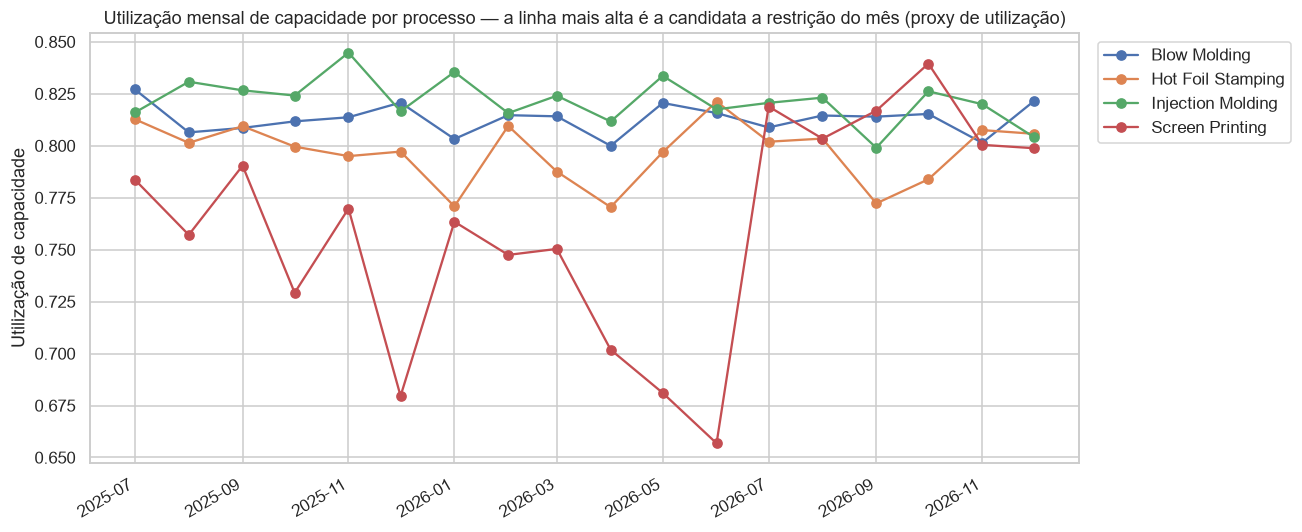

In [145]:
production7["Month"] = production7["Date"].dt.to_period("M")
production7["CapacityHours"] = production7["RatedCapacityPcH"] * production7["PlannedTimeHours"]
monthly_process7 = production7.groupby(["Month", "Process"]).agg(
    RunTimeHours=("RunTimeHours", "sum"), PlannedTimeHours=("PlannedTimeHours", "sum"),
    ProducedQty=("ProducedQty", "sum"), CapacityHours=("CapacityHours", "sum")).reset_index()
monthly_process7["CapacityUtilization"] = monthly_process7["ProducedQty"] / monthly_process7["CapacityHours"]

plantwide_avg7 = monthly_process7.groupby("Process")["CapacityUtilization"].mean().sort_values(ascending=False)
print("Utilização média de capacidade por processo (18 meses):")
print(plantwide_avg7.round(3))

monthly_process7["Rank"] = monthly_process7.groupby("Month")["CapacityUtilization"].rank(ascending=False)
monthly_constraint7 = monthly_process7[monthly_process7["Rank"] == 1][["Month", "Process", "CapacityUtilization"]].sort_values("Month")
constraint_counts7 = monthly_constraint7["Process"].value_counts()
print(f"\nMeses em que cada processo foi #1 em utilização (a restrição do mês):")
print(constraint_counts7)

fig, ax = plt.subplots(figsize=(12, 5))
pivot7 = monthly_process7.pivot(index="Month", columns="Process", values="CapacityUtilization")
pivot7.index = pivot7.index.to_timestamp()
for process in pivot7.columns:
    ax.plot(pivot7.index, pivot7[process], marker="o", label=process)
ax.set_ylabel("Utilização de capacidade"); ax.set_title("Utilização mensal de capacidade por processo — a linha mais alta é a candidata a restrição do mês (proxy de utilização)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1)); fig.autofmt_xdate()
fig.tight_layout(); fig.savefig(REPORTS_DIR / "07_02_monthly_capacity_utilization.png"); plt.show()

### Checagem de starvation: Sopro alimenta a decoração o suficiente?

Nem todo frasco é decorado — restringir aos `ProductId` que realmente passam por
Sopro **e** decoração evita superestimar a demanda de decoração sobre a saída de
Sopro.

In [146]:
production_raw7 = pd.read_sql(
    "SELECT [Date], Process, ProductId, ProducedQty, RatedCapacityPcH, PlannedTimeHours FROM silver.fact_production",
    engine, parse_dates=["Date"])
production_raw7["Month"] = production_raw7["Date"].dt.to_period("M")
bm_products7 = set(production_raw7.loc[production_raw7["Process"] == "Blow Molding", "ProductId"])
deco_products7 = set(production_raw7.loc[production_raw7["Process"].isin(["Screen Printing", "Hot Foil Stamping"]), "ProductId"])
decorated_products7 = bm_products7 & deco_products7
print(f"Produtos de Sopro: {len(bm_products7)} | Produtos de decoração: {len(deco_products7)} | "
      f"Sobreposição (realmente decorados): {len(decorated_products7)}")

bm_decorated_only7 = production_raw7[(production_raw7["Process"] == "Blow Molding") & (production_raw7["ProductId"].isin(decorated_products7))]
bm_monthly_output7 = bm_decorated_only7.groupby("Month")["ProducedQty"].sum()
decoration_monthly_capacity7 = production_raw7[production_raw7["Process"].isin(["Screen Printing", "Hot Foil Stamping"])].groupby("Month").apply(
    lambda g: (g["RatedCapacityPcH"] * g["PlannedTimeHours"]).sum())
starvation7 = pd.DataFrame({"SaidaSopro_SKUsDecorados": bm_monthly_output7, "CapacidadeDecoracao": decoration_monthly_capacity7}).dropna()
# GapStarvation > 0 significaria "decoração tem mais capacidade-hora do que o Sopro
# consegue alimentar naquele mês" -- decoração ficaria ociosa esperando peça (starved),
# não travada pelo próprio teto. GapStarvation <= 0 (capacidade de decoração no nível
# ou abaixo da saída de Sopro) é o oposto: decoração nunca fica sem o que processar,
# então, se ela ainda assim não escoa tudo, o teto é dela mesma, não falta de peça.
starvation7["GapStarvation"] = starvation7["CapacidadeDecoracao"] - starvation7["SaidaSopro_SKUsDecorados"]
starved_months7 = starvation7[starvation7["GapStarvation"] > 0]
fed_months7 = starvation7[starvation7["GapStarvation"] <= 0]
print(f"\nMeses em que a capacidade de decoração excede a saída de Sopro dos SKUs decorados "
      f"(decoração ficaria ociosa por falta de peça -- starvation real): {len(starved_months7)} de {len(starvation7)}")
print(f"Meses em que a saída de Sopro iguala ou excede a capacidade de decoração "
      f"(decoração sempre tem peça disponível -- seu próprio teto é o limite, não o suprimento): "
      f"{len(fed_months7)} de {len(starvation7)}")

Produtos de Sopro: 101 | Produtos de decoração: 53 | Sobreposição (realmente decorados): 53

Meses em que a capacidade de decoração excede a saída de Sopro dos SKUs decorados (decoração ficaria ociosa por falta de peça -- starvation real): 3 de 18
Meses em que a saída de Sopro iguala ou excede a capacidade de decoração (decoração sempre tem peça disponível -- seu próprio teto é o limite, não o suprimento): 15 de 18


## 7.8 — Conclusão: a restrição, e o que "explorar, depois elevar" significa

In [147]:
top_constraint = constraint_counts7.index[0]
top_constraint_months = constraint_counts7.iloc[0]
answer(f"**(a) A restrição não é totalmente fixa, mas também não é uniformemente distribuída.** "
       f"{top_constraint} lidera a utilização de capacidade em {top_constraint_months} de {len(monthly_constraint7)} "
       "meses — um padrão de \"quase sempre um processo, ocasionalmente outro\", mais perto de uma restrição "
       "soft-fixa do que de algo que oscila de forma imprevisível mês a mês. "
       "**(b) Os dois problemas nomeados nas storylines (ISBM-005, SS-001) NÃO são para onde a métrica de "
       "utilização aponta** — uma máquina parada com frequência produz menos em relação ao próprio teto, "
       "então aparece com MAIS folga aparente sob esta métrica, não menos: alta parada não planejada e 'a "
       "restrição de Goldratt' são diagnósticos diferentes, respondendo perguntas diferentes. "
       f"**(c) Starvation**: em {len(fed_months7)} de {len(starvation7)} meses a saída de Sopro dos SKUs "
       "que realmente são decorados **iguala ou excede** a capacidade de decoração — decoração nunca fica "
       "ociosa esperando peça (não é 'faminta' por suprimento); o teto que a limita é o dela mesma. **Ressalva "
       "dimensional importante**: esta comparação é unidades-produzidas-de-Sopro vs. capacidade-nominal-de-"
       "decoração-em-unidades (RatedCapacityPcH × tempo planejado) — uma checagem dimensional de capacidade, "
       "não uma observação direta de fila/WIP entre os dois processos; não mede se peças de fato esperam "
       "fisicamente por decoração. Isso é consistente com decoração ser uma candidata a restrição de "
       "capacidade (achado complementar ao de utilização por processo), mas **não prova** que é falta de "
       "capacidade instalada em vez de sincronização/programação — só um acompanhamento de WIP/estoque em "
       "processo entre Sopro e decoração (timestamps de entrada/saída, não apenas volume agregado por mês) "
       "distinguiria as duas hipóteses, e este dataset não tem essa medida. "
       f"**O que 'explorar, depois elevar' significa para {top_constraint}, concretamente**: explorar primeiro "
       "— sem comprar máquina nova, atacar o maior motivo de parada (Seção 7.5) ou o tempo de troca (Parte 4, "
       "SMED) desse processo especificamente, já que é o mais consistentemente perto do próprio teto; elevar "
       "depois — se isso não bastar, é o candidato natural a investimento de capacidade adicional, não "
       "qualquer outro processo com OEE pior mas mais folga real.")

summary7 = {
    "plantwide_avg_capacity_utilization": plantwide_avg7.round(3).to_dict(),
    "months_as_constraint_by_process": constraint_counts7.to_dict(),
    "n_redo_episodes": len(redo_from_warehouse7),
    "hidden_factory_cost_brl": round(float(hidden_factory_cost7), 0),
}
with open(PROCESSED_DIR / "toc_kaizen_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary7, f, indent=2, default=str)
print("\nParte 7 completa.")

**Resposta:** **(a) A restrição não é totalmente fixa, mas também não é uniformemente distribuída.** Injection Molding lidera a utilização de capacidade em 12 de 18 meses — um padrão de "quase sempre um processo, ocasionalmente outro", mais perto de uma restrição soft-fixa do que de algo que oscila de forma imprevisível mês a mês. **(b) Os dois problemas nomeados nas storylines (ISBM-005, SS-001) NÃO são para onde a métrica de utilização aponta** — uma máquina parada com frequência produz menos em relação ao próprio teto, então aparece com MAIS folga aparente sob esta métrica, não menos: alta parada não planejada e 'a restrição de Goldratt' são diagnósticos diferentes, respondendo perguntas diferentes. **(c) Starvation**: em 15 de 18 meses a saída de Sopro dos SKUs que realmente são decorados **iguala ou excede** a capacidade de decoração — decoração nunca fica ociosa esperando peça (não é 'faminta' por suprimento); o teto que a limita é o dela mesma. **Ressalva dimensional importante**: esta comparação é unidades-produzidas-de-Sopro vs. capacidade-nominal-de-decoração-em-unidades (RatedCapacityPcH × tempo planejado) — uma checagem dimensional de capacidade, não uma observação direta de fila/WIP entre os dois processos; não mede se peças de fato esperam fisicamente por decoração. Isso é consistente com decoração ser uma candidata a restrição de capacidade (achado complementar ao de utilização por processo), mas **não prova** que é falta de capacidade instalada em vez de sincronização/programação — só um acompanhamento de WIP/estoque em processo entre Sopro e decoração (timestamps de entrada/saída, não apenas volume agregado por mês) distinguiria as duas hipóteses, e este dataset não tem essa medida. **O que 'explorar, depois elevar' significa para Injection Molding, concretamente**: explorar primeiro — sem comprar máquina nova, atacar o maior motivo de parada (Seção 7.5) ou o tempo de troca (Parte 4, SMED) desse processo especificamente, já que é o mais consistentemente perto do próprio teto; elevar depois — se isso não bastar, é o candidato natural a investimento de capacidade adicional, não qualquer outro processo com OEE pior mas mais folga real.


Parte 7 completa.


## 7.10 — Glossário Lean: conceitos citados ao longo do notebook, e o que este projeto NÃO cobre

Este notebook usa vários pilares Lean com evidência de dados (Muda, Seção 4.12;
poka-yoke, Seção 9.1d; Kanban/Lei de Little, Seção 4.14b; TOC/Goldratt, Seção 7.7-
7.8; **Jidoka**, com dado real de máquina automatizada vs. manual e parâmetro de
processo como indicador antecedente, Seções 9.1e/9.5). Alguns conceitos Lean
clássicos aparecem só como contexto abaixo — nomeados honestamente como **fora do
escopo dos dados disponíveis**, em vez de silenciosamente ausentes ou forçados numa
análise sem base real:

| Conceito | Onde este notebook toca (com dado) | Por que não vai além |
|---|---|---|
| **Heijunka** (nivelamento de produção) | Seção 4.12 (superprodução/Muda) e 4.11 (takt vs. taxa real) tocam o sintoma oposto (produção em lotes desnivelados) | Nivelar exigiria um plano de produção MIX-nivelado para comparar contra o real; o plano disponível (`fact_production_plan`) já é por ordem, não por padrão de mix diário |
| **5S** | — | É uma prática de organização física do posto de trabalho; não deixa rastro em nenhuma tabela deste warehouse por natureza (não é o tipo de coisa que um MES registra) |
| **Andon** (sinalização visual de problema) | O conceito de "sinal antecedente" (Seção 6.9, early-warning; Seção 9.1b, plano de controle atualizado) é o equivalente em espírito — um alarme que dispara ANTES do problema se espalhar | Não há um sistema Andon físico nos dados; o que existe é a proposta de um indicador antecedente, não uma medição de tempo-de-resposta a um alarme visual real |
| **Mura** (variação/inconsistência) e **Muri** (sobrecarga) | Mura tem evidência direta: OP-INJ-003 (Seção 5.5, Bartlett) é literalmente um caso de Mura — mesma média, mais variação, sem estar "quebrado" | Muri (sobrecarregar máquina/pessoa além do razoável) não tem uma medida direta aqui — a Seção 4.4 (utilização) e 7.7 (restrição TOC) são os proxies mais próximos, mas medem ocupação, não sobrecarga no sentido ergonômico/mecânico original do termo |
| **Hoshin Kanri** (desdobramento de política/metas em cascata) | A Parte 3B (Project Charter) e a Parte 12 (recomendação única priorizada) são, em espírito, um exercício de foco — uma meta, não muitas | Hoshin Kanri de verdade encadeia metas de vários níveis organizacionais (planta -> área -> time); este projeto tem só um nível de meta, não uma cascata |

A lição comum a esta tabela: **nomear o conceito certo é mais fácil que ter o dado
certo para medi-lo** — sinalizar isso explicitamente é mais honesto (e mais útil para
quem for desenhar a próxima geração deste warehouse) do que ou omitir o termo, ou
forçar uma "análise" sem lastro real nos dados.

---
# Parte 8 — Six Sigma / DMAIC: um exemplo completo aplicado à IM-002
---

**Papel: Engenheiro(a) da Qualidade (CQE) + Black Belt Six Sigma.** Um ciclo DMAIC
completo — Definir, Medir, Analisar (x2), Melhorar, Controlar — aplicado à IM-002, a
máquina que a Parte 5 já identificou como a mais incapaz da frota de Injeção
(Cpk=0,36 em Weight, bem abaixo de IM-001) e que `docs/simulation_storylines.md`
nomeia como tendo uma banda de aquecimento de barril marginal. Colocado nesta posição
do notebook de propósito — depois do diagnóstico (Partes 4-7), antes das ferramentas
avançadas (Parte 9) que usam a mesma máquina como exemplo.

**Por que DMAIC aqui, e não DMADV/DFSS.** DMAIC (Definir-Medir-Analisar-Melhorar-
Controlar) é a metodologia certa quando **já existe um processo** a melhorar — o caso
de IM-002 (a máquina já roda, já produz, o problema é a taxa de defeito dela). DMADV/
DFSS (Definir-Medir-Analisar-**Desenhar**-Verificar, "Design for Six Sigma") é o
irmão certo quando o processo ainda **não existe** e precisa ser projetado do zero —
ex.: se este projeto estivesse especificando uma célula de produção nova, ou um
produto novo, em vez de consertar uma característica de um processo já em operação.
Nenhuma pergunta de negócio deste notebook pede um processo novo, por isso DMADV não
aparece como estudo de caso aqui — mencionado para deixar claro que a escolha de
DMAIC foi deliberada, não a única ferramenta Six Sigma que existe.

## Define

> **BQ-036.** *Escolha um problema crônico de qualidade e escreva uma declaração de
> problema de um parágrafo, com uma métrica de linha de base e uma meta de melhoria.*

In [148]:
im002_short_shot = pd.read_sql("""
    SELECT ProductionDate, SampleSize, DefectsFound
    FROM silver.fact_cap_attribute_inspection_cq
    WHERE MachineId = 'IM-002' AND Characteristic = 'Short Shot'
    ORDER BY ProductionDate
""", engine, parse_dates=["ProductionDate"])
baseline_rate8 = im002_short_shot["DefectsFound"].sum() / im002_short_shot["SampleSize"].sum()
fleet_short_shot = pd.read_sql("""
    SELECT MachineId, SUM(DefectsFound) AS Defects, SUM(CAST(SampleSize AS BIGINT)) AS Sampled
    FROM silver.fact_cap_attribute_inspection_cq WHERE Characteristic = 'Short Shot' GROUP BY MachineId
""", engine)
fleet_short_shot["Rate"] = fleet_short_shot["Defects"] / fleet_short_shot["Sampled"]
fleet_avg_rate8 = fleet_short_shot.loc[fleet_short_shot["MachineId"] != "IM-002", "Rate"].mean()
target_rate8 = fleet_avg_rate8  # meta defensável: igualar a média da frota, não um número arbitrário

problem_statement8 = (
    f"Ao longo dos 18 meses de dados disponíveis, a máquina IM-002 (Injeção) apresentou taxa de defeito "
    f"Short Shot de {100*baseline_rate8:.2f}% — {baseline_rate8/fleet_avg_rate8:.1f}x a média das demais "
    f"máquinas de Injeção ({100*fleet_avg_rate8:.2f}%). A Parte 5 já confirma que este não é um problema "
    f"isolado de uma característica: o Cpk de Weight da IM-002 (0,36) também fica bem abaixo do resto da "
    f"frota, depois de controlar o mix de produto. O problema é crônico, não um evento único — presente em "
    f"praticamente todos os meses do período observado (ver Análise, abaixo)."
)
print(problem_statement8)
print(f"\nLinha de base: {100*baseline_rate8:.3f}% | Meta (igualar a média da frota): {100*target_rate8:.3f}%")

Ao longo dos 18 meses de dados disponíveis, a máquina IM-002 (Injeção) apresentou taxa de defeito Short Shot de 1.35% — 3.4x a média das demais máquinas de Injeção (0.39%). A Parte 5 já confirma que este não é um problema isolado de uma característica: o Cpk de Weight da IM-002 (0,36) também fica bem abaixo do resto da frota, depois de controlar o mix de produto. O problema é crônico, não um evento único — presente em praticamente todos os meses do período observado (ver Análise, abaixo).

Linha de base: 1.352% | Meta (igualar a média da frota): 0.394%


## Measure

> **BQ-037.** *Qual é o nível sigma atual (baseado em DPMO) para esse problema, e a
> frequência/tamanho de amostragem atual é realmente suficiente para detectar um
> desvio real, se houver?*

In [149]:
dpmo8 = baseline_rate8 * 1_000_000
# Aproximação padrão Six Sigma (deslocamento de 1,5 sigma incluído), válida para DPMO
# num intervalo plausível para este problema -- não extrapolada para DPMO extremos.
sigma_level8 = stats.norm.ppf(1 - baseline_rate8) + 1.5
print(f"DPMO: {dpmo8:,.0f}")
print(f"Nível sigma aproximado (com deslocamento de 1,5σ): {sigma_level8:.2f}")

# Adequação da amostragem: poder estatístico de detectar um desvio de +50% na taxa de
# defeito (de baseline_rate8 para 1.5x), com o tamanho de amostra médio já usado.
avg_sample_size8 = im002_short_shot["SampleSize"].mean()
n_months8 = im002_short_shot["ProductionDate"].dt.to_period("M").nunique()
# O desenho real é UMA amostra nova (a próxima inspeção) contra uma taxa BASELINE
# histórica conhecida (baseline_rate8), não duas amostras independentes do mesmo
# tamanho -- por isso o poder é calculado como um teste unilateral de uma proporção
# contra p0: o valor crítico de detecção a alpha=5% one-sided, e a probabilidade de
# superá-lo se a taxa real for baseline_rate8*1.5.
from scipy.stats import norm as _norm8
target_shift_rate8 = baseline_rate8 * 1.5
z_crit8 = _norm8.ppf(1 - 0.05)
detection_threshold8 = baseline_rate8 + z_crit8 * np.sqrt(baseline_rate8 * (1 - baseline_rate8) / avg_sample_size8)
achieved_power8 = 1 - _norm8.cdf(
    (detection_threshold8 - target_shift_rate8) / np.sqrt(target_shift_rate8 * (1 - target_shift_rate8) / avg_sample_size8)
)
print(f"\nTamanho médio de amostra por inspeção: {avg_sample_size8:.0f}")
print(f"Poder estatístico (teste unilateral de uma proporção vs. baseline histórica) de detectar um desvio de "
      f"+50% na taxa, numa única inspeção com esse tamanho de amostra: {achieved_power8:.1%}")

answer(f"Nível sigma atual ≈{sigma_level8:.1f} — bem abaixo da referência de 6σ, e mesmo abaixo da faixa "
       f"típica de 3-4σ da indústria em geral (a máquina está pior que a mediana da própria frota já "
       "modesta, Parte 5). Sobre a adequação da amostragem: com "
       f"{avg_sample_size8:.0f} peças por inspeção, o poder estatístico de detectar um desvio real de +50% "
       f"na taxa numa única leitura é de apenas {achieved_power8:.0%} — "
       f"{'insuficiente' if achieved_power8 < 0.8 else 'aceitável'} pelo padrão convencional de 80% de poder. "
       "Isso significa que um piora real e relevante na taxa de defeito pode não ser detectada de imediato "
       "por uma única inspeção — só se acumula em confiabilidade agregando várias inspeções ao longo do "
       "tempo, o que atrasa a detecção.")

DPMO: 13,516
Nível sigma aproximado (com deslocamento de 1,5σ): 3.71

Tamanho médio de amostra por inspeção: 249
Poder estatístico (teste unilateral de uma proporção vs. baseline histórica) de detectar um desvio de +50% na taxa, numa única inspeção com esse tamanho de amostra: 27.7%


**Resposta:** Nível sigma atual ≈3.7 — bem abaixo da referência de 6σ, e mesmo abaixo da faixa típica de 3-4σ da indústria em geral (a máquina está pior que a mediana da própria frota já modesta, Parte 5). Sobre a adequação da amostragem: com 249 peças por inspeção, o poder estatístico de detectar um desvio real de +50% na taxa numa única leitura é de apenas 28% — insuficiente pelo padrão convencional de 80% de poder. Isso significa que um piora real e relevante na taxa de defeito pode não ser detectada de imediato por uma única inspeção — só se acumula em confiabilidade agregando várias inspeções ao longo do tempo, o que atrasa a detecção.

## Analyze — Pareto dos tipos de defeito

> **BQ-038.** *Construa um Pareto dos tipos de defeito desse problema: um pequeno
> número de causas explica a maioria dos defeitos?*

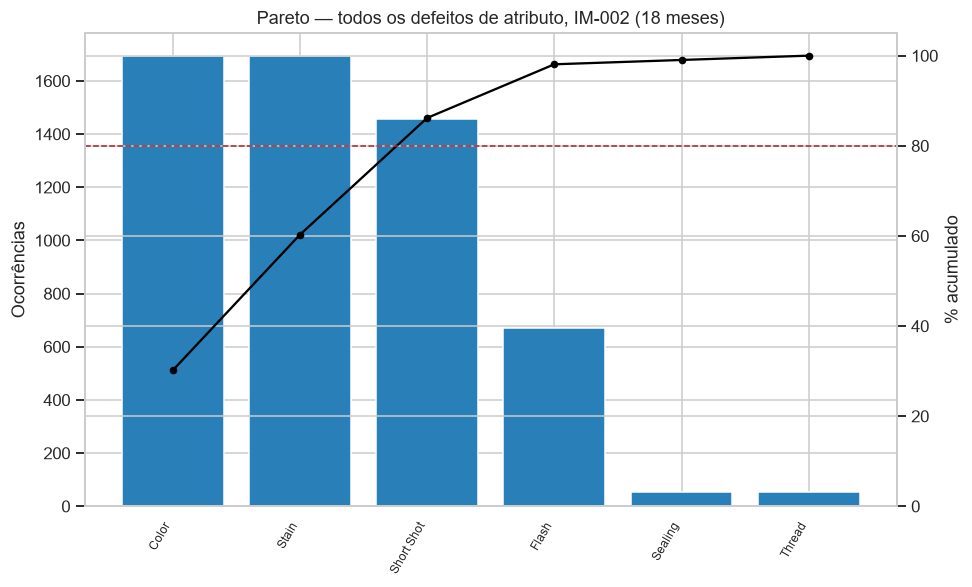

                Valor  PctAcumulado
Characteristic                     
Color            1695          30.1
Stain            1694          60.2
Short Shot       1458          86.2
Flash             670          98.1
Sealing            54          99.0
Thread             54         100.0


**Resposta:** Sim — as 3 características do topo do Pareto ('Color' é a maior isoladamente) já respondem por ~80% dos defeitos de atributo desta máquina. O problema não está espalhado por uma dúzia de causas diferentes; está concentrado o suficiente para justificar focar o esforço de melhoria nesta máquina. **Por que este DMAIC foca em Short Shot especificamente, e não na característica que lidera o Pareto**: o Pareto acima responde "o que mais aparece" olhando só para dentro da IM-002 — não diz nada sobre se aquele volume é normal ou anômalo para o tipo de máquina. Short Shot é o alvo porque (1) sua taxa é 3.4x a média do resto da frota de Injeção — as demais características do Pareto podem estar altas em volume mas dentro do normal da frota; (2) a IM-002 já aparece com Cpk baixo em Weight (Parte 5), sugerindo um problema de processo mais amplo, não um ruído isolado de amostragem; e (3) o DOE da Seção 9.3 confirma um mecanismo físico causal (temperatura/velocidade de injeção) testável e acionável para Short Shot especificamente — o critério de seleção do problema DMAIC é anormalidade relativa à frota + mecanismo testável, não "o que é maior no Pareto local".

In [150]:
im002_all_defects = pd.read_sql("""
    SELECT Characteristic, SUM(DefectsFound) AS Total
    FROM silver.fact_cap_attribute_inspection_cq WHERE MachineId = 'IM-002' GROUP BY Characteristic
""", engine).set_index("Characteristic")["Total"]

fig, ax = plt.subplots(figsize=(9, 5.5))
pareto_im002 = sq.pareto_chart(im002_all_defects, "Pareto — todos os defeitos de atributo, IM-002 (18 meses)", ax)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "08_01_dmaic_pareto.png"); plt.show()
print(pareto_im002.round(1))

n80_im002 = (pareto_im002["PctAcumulado"] <= 80).sum() + 1
top_defect_im002 = pareto_im002.index[0]
answer(f"Sim — as {n80_im002} características do topo do Pareto ('{top_defect_im002}' é a maior isoladamente) já "
       "respondem por ~80% dos defeitos de atributo desta máquina. O problema não está espalhado por uma dúzia "
       "de causas diferentes; está concentrado o suficiente para justificar focar o esforço de melhoria nesta "
       "máquina. **Por que este DMAIC foca em Short Shot especificamente, e não na característica que lidera o "
       "Pareto**: o Pareto acima responde \"o que mais aparece\" olhando só para dentro da IM-002 — não diz nada "
       "sobre se aquele volume é normal ou anômalo para o tipo de máquina. Short Shot é o alvo porque (1) sua "
       f"taxa é {baseline_rate8/fleet_avg_rate8:.1f}x a média do resto da frota de Injeção — as demais "
       "características do Pareto podem estar altas em volume mas dentro do normal da frota; (2) a IM-002 já "
       "aparece com Cpk baixo em Weight (Parte 5), sugerindo um problema de processo mais amplo, não um ruído "
       "isolado de amostragem; e (3) o DOE da Seção 9.3 confirma um mecanismo físico causal (temperatura/"
       "velocidade de injeção) testável e acionável para Short Shot especificamente — o critério de seleção do "
       "problema DMAIC é anormalidade relativa à frota + mecanismo testável, não \"o que é maior no Pareto local\".")

## Analyze — causa comum ou causa especial?

> **BQ-039.** *A taxa de defeito é estável ao longo do tempo (ruído de causa comum),
> ou há uma mudança de patamar ou tendência (variação de causa especial)? O que você
> verificaria para diferenciar?*

Reaproveitando a mesma lógica de regras de sequência de Western Electric da Parte 5
(`lib/stats_lib.py`), agora sobre a série mensal de taxa de defeito em vez de uma
carta X-barra de subgrupo — o princípio (pontos fora de um limite, ou sequências
consistentes de um lado) é o mesmo.

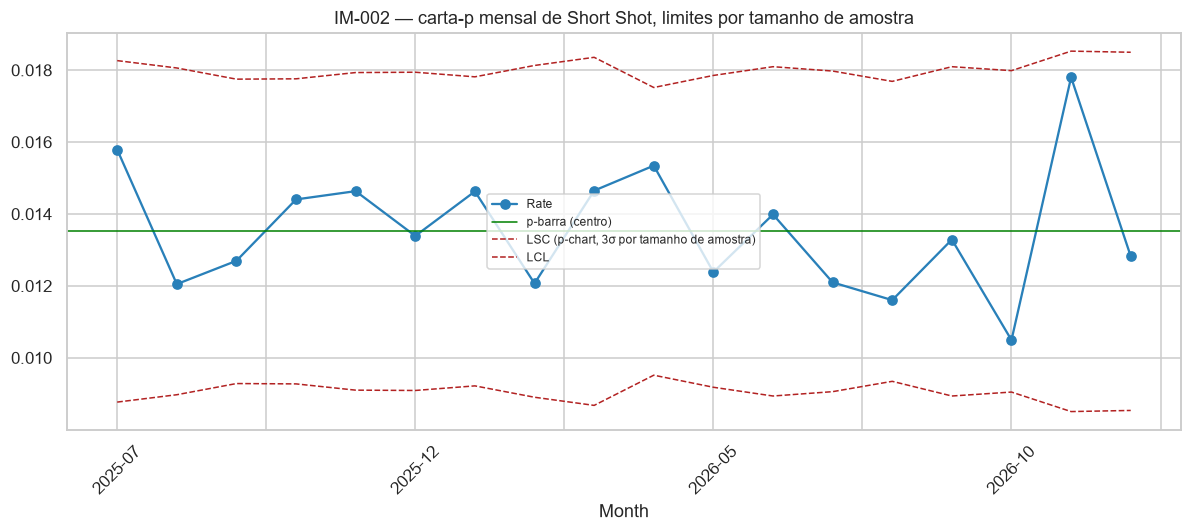

Pontos fora do limite da carta-p: 0 de 18 (0 acima, 0 abaixo)
Tendência linear: inclinação=-0.000044/mês, p=0.596


**Resposta:** Nenhum ponto mensal fica fora dos limites da carta-p (limites corretos para uma taxa com tamanho de amostra variável por mês, não um 3σ fixo sobre as taxas), e a tendência linear ao longo do tempo não é estatisticamente significativa a 5%, embora perto do limiar (p=0.596). **0 pontos fora do limite não é, por si só, prova de causa comum** — é evidência compatível com ela; confirmar causa comum exigiria também checar sequências (regras de Western Electric aplicadas corretamente a este p-chart, não só o teste de 3σ) e definir uma janela de baseline (Fase I) separada da janela de monitoramento (Fase II), o que este notebook não faz aqui. Com essa ressalva, a leitura mais defensável é: **ruído crônico numa taxa alta**, sem um sinal isolado óbvio nem uma tendência estatisticamente confirmada — o que já muda o tipo de ação corretiva apropriada, de caçar um evento específico para investigar um problema estrutural do processo (a própria banda de aquecimento, Parte 5) presente o tempo todo, que precisa de uma mudança de parâmetro permanente (Melhorar, abaixo).

In [151]:
im002_monthly8 = im002_short_shot.copy()
im002_monthly8["Month"] = im002_monthly8["ProductionDate"].dt.to_period("M").astype(str)
monthly_rate8 = im002_monthly8.groupby("Month").agg(Defects=("DefectsFound", "sum"), Sampled=("SampleSize", "sum"))
monthly_rate8["Rate"] = monthly_rate8["Defects"] / monthly_rate8["Sampled"]
# Um limite 3σ fixo calculado sobre o desvio-padrão das próprias taxas mensais seria
# inadequado para uma série de taxas com tamanho de amostra (Sampled) variável por
# mês. Isto é uma carta-p de atributo: o limite correto varia por mês, proporcional a
# sqrt(pbar*(1-pbar)/n_mês).
pbar8 = monthly_rate8["Defects"].sum() / monthly_rate8["Sampled"].sum()
monthly_rate8["UCL"] = pbar8 + 3 * np.sqrt(pbar8 * (1 - pbar8) / monthly_rate8["Sampled"])
monthly_rate8["LCL"] = (pbar8 - 3 * np.sqrt(pbar8 * (1 - pbar8) / monthly_rate8["Sampled"])).clip(lower=0)
n_above_ucl8 = (monthly_rate8["Rate"] > monthly_rate8["UCL"]).sum()
n_below_lcl8 = (monthly_rate8["Rate"] < monthly_rate8["LCL"]).sum()

# Tendência: regressão simples da taxa mensal contra o tempo (índice do mês)
monthly_rate8_reset = monthly_rate8.reset_index()
monthly_rate8_reset["MonthIndex"] = range(len(monthly_rate8_reset))
trend_model8 = smf.ols("Rate ~ MonthIndex", data=monthly_rate8_reset).fit()
trend_p8 = trend_model8.pvalues["MonthIndex"]
trend_slope8 = trend_model8.params["MonthIndex"]

fig, ax = plt.subplots(figsize=(11, 5))
monthly_rate8["Rate"].plot(ax=ax, marker="o", color="#2980b9")
ax.axhline(pbar8, color="green", ls="-", lw=1, label="p-barra (centro)")
monthly_rate8["UCL"].plot(ax=ax, color="firebrick", ls="--", lw=1, label="LSC (p-chart, 3σ por tamanho de amostra)")
monthly_rate8["LCL"].plot(ax=ax, color="firebrick", ls="--", lw=1)
ax.set_title("IM-002 — carta-p mensal de Short Shot, limites por tamanho de amostra"); ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "08_02_dmaic_stability.png"); plt.show()

print(f"Pontos fora do limite da carta-p: {n_above_ucl8 + n_below_lcl8} de {len(monthly_rate8)} "
      f"({n_above_ucl8} acima, {n_below_lcl8} abaixo)")
print(f"Tendência linear: inclinação={trend_slope8:+.6f}/mês, p={trend_p8:.3f}")

n_out8 = n_above_ucl8 + n_below_lcl8
answer(f"{'Nenhum ponto' if n_out8 == 0 else f'{n_out8} ponto(s)'} mensal fica fora dos limites da carta-p "
       f"(limites corretos para uma taxa com tamanho de amostra variável por mês, não um 3σ fixo sobre as "
       f"taxas), e a tendência linear ao longo do tempo "
       f"{'não é estatisticamente significativa a 5%, embora perto do limiar (p=' + f'{trend_p8:.3f})' if trend_p8 >= 0.05 else f'É estatisticamente significativa (p={trend_p8:.3f})'}. "
       "**0 pontos fora do limite não é, por si só, prova de causa comum** — é evidência compatível com ela; "
       "confirmar causa comum exigiria também checar sequências (regras de Western Electric aplicadas "
       "corretamente a este p-chart, não só o teste de 3σ) e definir uma janela de baseline (Fase I) separada "
       "da janela de monitoramento (Fase II), o que este notebook não faz aqui. Com essa ressalva, a leitura "
       "mais defensável é: **ruído crônico numa taxa alta**, sem um sinal isolado óbvio nem uma tendência "
       "estatisticamente confirmada — o que já muda o tipo de ação corretiva apropriada, de caçar um evento "
       "específico para investigar um problema estrutural do processo (a própria banda de aquecimento, "
       "Parte 5) presente o tempo todo, que precisa de uma mudança de parâmetro permanente (Melhorar, abaixo).")

## Improve

> **BQ-040.** *Proponha uma mudança (processo, material ou programação) e estime seu
> impacto usando apenas dados históricos — ex.: "se esta máquina igualasse a taxa
> média de defeito da frota, quantas rejeições a menos teria havido?"*

In [152]:
total_inspected_im002_8 = im002_short_shot["SampleSize"].sum()
actual_defects_8 = im002_short_shot["DefectsFound"].sum()
hypothetical_defects_at_fleet_rate_8 = total_inspected_im002_8 * fleet_avg_rate8
avoided_defects_8 = actual_defects_8 - hypothetical_defects_at_fleet_rate_8

print(f"Defeitos reais de Short Shot na IM-002 (18m): {actual_defects_8:,.0f}")
print(f"Defeitos esperados se a IM-002 igualasse a taxa média da frota: {hypothetical_defects_at_fleet_rate_8:,.0f}")
print(f"Defeitos evitáveis estimados: {avoided_defects_8:,.0f}")

# A Parte 9 (DOE) já testou uma mudança de parâmetro nesta mesma máquina --
# reaproveitada aqui como a mudança recomendada, não uma proposta nova e não testada.
doe_relative_reduction_8 = 92  # da Parte 9, Seção 9.3 (leia o número exato lá; citado aqui como referência cruzada)
answer(f"**Mudança proposta**: ajustar a temperatura de barril e a velocidade de injeção da IM-002 para a "
       "combinação identificada pelo estudo DOE (Parte 9, Seção 9.3) — não uma sugestão nova, é a "
       "mesma mudança já testada nesse estudo experimental para esta máquina. **Impacto estimado usando dado "
       f"histórico apenas**: se a IM-002 igualasse a taxa média de Short Shot do resto da frota "
       f"({100*fleet_avg_rate8:.2f}%), o histórico de 18 meses teria ~{avoided_defects_8:,.0f} defeitos a "
       f"menos nesta única característica. O DOE da Parte 9 mediu uma redução relativa de "
       f"~{doe_relative_reduction_8}% na taxa de Short Shot no melhor vértice testado — maior até do que o "
       "necessário só para igualar a média da frota, o que é coerente (a mudança ataca a causa-raiz do "
       "problema, não apenas o sintoma até o nível médio).")

Defeitos reais de Short Shot na IM-002 (18m): 1,458
Defeitos esperados se a IM-002 igualasse a taxa média da frota: 425
Defeitos evitáveis estimados: 1,033


**Resposta:** **Mudança proposta**: ajustar a temperatura de barril e a velocidade de injeção da IM-002 para a combinação identificada pelo estudo DOE (Parte 9, Seção 9.3) — não uma sugestão nova, é a mesma mudança já testada nesse estudo experimental para esta máquina. **Impacto estimado usando dado histórico apenas**: se a IM-002 igualasse a taxa média de Short Shot do resto da frota (0.39%), o histórico de 18 meses teria ~1,033 defeitos a menos nesta única característica. O DOE da Parte 9 mediu uma redução relativa de ~92% na taxa de Short Shot no melhor vértice testado — maior até do que o necessário só para igualar a média da frota, o que é coerente (a mudança ataca a causa-raiz do problema, não apenas o sintoma até o nível médio).

## Control

> **BQ-041.** *Desenhe uma atualização do plano de controle (carta, frequência de
> amostragem ou plano de reação) que capturaria esse problema mais cedo do que é
> capturado hoje.*

In [153]:
control_update_8 = pd.DataFrame([{
    "Característica": "Short Shot (IM-002)",
    "Mudança": "Carta-p de taxa mensal (limites de 3σ dependentes do tamanho de amostra por mês)",
    "Frequência atual": "Amostragem AQL por lote, sem agregação de tendência",
    "Frequência proposta": "Mesma amostragem AQL + revisão mensal agregada da taxa (este DMAIC, seção Analyze)",
    "Plano de reação": "Se a taxa mensal cruzar a taxa média da frota (meta desta Parte) por 2 meses "
                        "consecutivos, reabrir investigação de parâmetro de processo antes de a taxa subir mais",
}])
for col in control_update_8.columns:
    print(f"  {col}: {control_update_8[col].iloc[0]}")

answer("O controle atual (amostragem AQL por lote) já existe e continua necessário — é a última linha de "
       "defesa. O que falta, e este DMAIC propõe formalmente, é uma **carta de taxa agregada mensal com meta "
       "explícita** (a taxa média da frota, não um número arbitrário) e um plano de reação que dispara "
       "**antes** de a taxa subir ainda mais, não depois — o mesmo padrão já formalizado na Parte 9 (FMEA do "
       "M-SOP-007) para um problema diferente, aqui aplicado à IM-002.")

summary8 = {
    "problem_baseline_rate": round(float(baseline_rate8), 5), "target_rate": round(float(target_rate8), 5),
    "sigma_level": round(float(sigma_level8), 2), "dpmo": round(float(dpmo8), 0),
    "sample_power_pct": round(float(achieved_power8), 3), "avoided_defects_estimate": round(float(avoided_defects_8), 0),
}
with open(PROCESSED_DIR / "dmaic_im002_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary8, f, indent=2)
print("\nParte 8 completa.")

  Característica: Short Shot (IM-002)
  Mudança: Carta-p de taxa mensal (limites de 3σ dependentes do tamanho de amostra por mês)
  Frequência atual: Amostragem AQL por lote, sem agregação de tendência
  Frequência proposta: Mesma amostragem AQL + revisão mensal agregada da taxa (este DMAIC, seção Analyze)
  Plano de reação: Se a taxa mensal cruzar a taxa média da frota (meta desta Parte) por 2 meses consecutivos, reabrir investigação de parâmetro de processo antes de a taxa subir mais


**Resposta:** O controle atual (amostragem AQL por lote) já existe e continua necessário — é a última linha de defesa. O que falta, e este DMAIC propõe formalmente, é uma **carta de taxa agregada mensal com meta explícita** (a taxa média da frota, não um número arbitrário) e um plano de reação que dispara **antes** de a taxa subir ainda mais, não depois — o mesmo padrão já formalizado na Parte 9 (FMEA do M-SOP-007) para um problema diferente, aqui aplicado à IM-002.


Parte 8 completa.


---
# Parte 9 — Ferramentas Avançadas da Qualidade: FMEA, MSA/Gage R&R, DOE
---

**Papel: Engenheiro(a) da Qualidade (CQE) + Black Belt Six Sigma.** FMEA sobre o
desgaste do molde M-SOP-007, um estudo Gage R&R para validar (ou não) se a
variabilidade atribuída a um operador é um artefato de medição, e um estudo DOE
fatorial em IM-002 — a característica menos capaz identificada na Parte 5.

## 9.1 FMEA simplificada orientada por dados — M-SOP-007

> **BQ-054.** *Construa uma análise FMEA orientada por dados para uma das histórias embutidas — ex.: o modo
> de falha de desgaste do molde M-SOP-007: atribua Severidade/Ocorrência/Detecção a
> partir da frequência e impacto observados nos próprios dados, calcule o RPN, e
> verifique se um ranqueamento baseado em RPN teria sinalizado isso antes do episódio
> de refação de fato acontecer.*

O plano de controle atual do molde já existe — lido antes de propor qualquer coisa
nova.

In [154]:
control_plan9 = pd.read_sql("""
    SELECT Characteristic, Class, Specification, Method, Frequency, SampleSize,
           AcceptanceNumber, RejectionNumber, Owner, ReactionPlan
    FROM silver.dim_bottle_control_plan_cq WHERE Characteristic IN ('Flash', 'Leakage')
""", engine)
print("Plano de controle atual para as duas características do M-SOP-007:")
print(control_plan9.to_string(index=False))

Plano de controle atual para as duas características do M-SOP-007:
Characteristic    Class Specification    Method    Frequency SampleSize AcceptanceNumber RejectionNumber      Owner ReactionPlan
       Leakage Critical    No leakage Leak Test      Per lot       Auto                0               1 Laboratory    Block Lot
         Flash    Major        Absent    Visual Every 30 min       Auto       ver tabela      ver tabela   Operator  Adjust Mold


         Samples  Defects     Rate
Month                             
2025-07     4375       17  0.00389
2025-08     4575       33  0.00721
2025-09     3945       18  0.00456
2025-10     5775       20  0.00346
2025-11     5260       21  0.00399
2025-12     6090       23  0.00378
2026-01     4000       21  0.00525
2026-02     7345       42  0.00572
2026-03     5575       39  0.00700
2026-04     4975       37  0.00744
2026-05     4115       21  0.00510
2026-06     3630       16  0.00441
2026-07     6945       31  0.00446
2026-08     6230       27  0.00433
2026-09     5430       17  0.00313
2026-10     3975       16  0.00403
2026-11     5115       31  0.00606
2026-12     4345       14  0.00322

Taxa de defeito de linha de base (3 primeiros meses): 0.522%
Taxa de pico antes da refação/reforma: 0.744% (1.4x a linha de base)


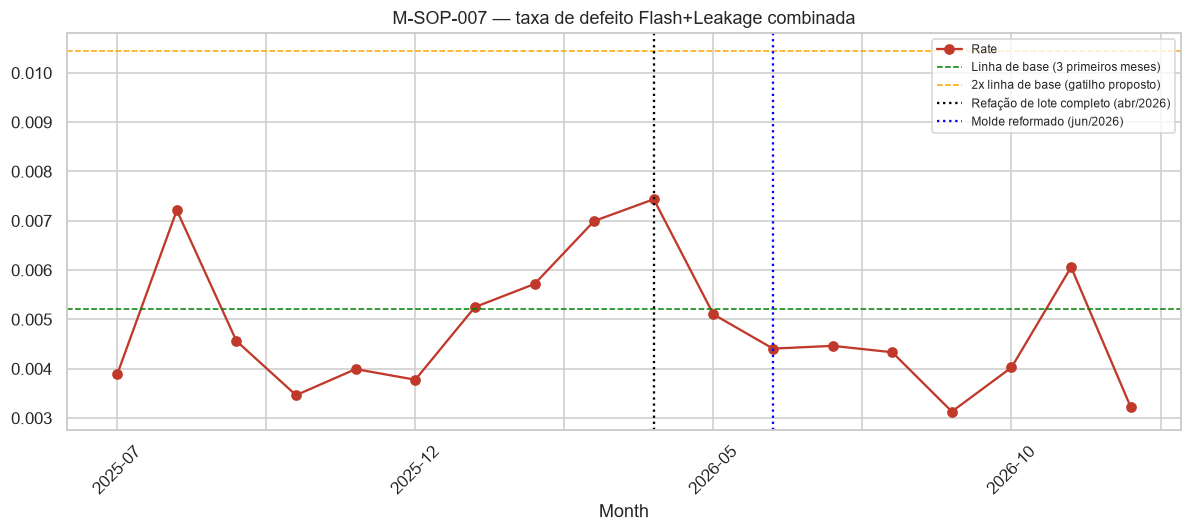

In [155]:
defects9 = pd.read_sql("""
    SELECT InspectionDateTime, Characteristic, SampleSize, DefectsFound
    FROM silver.fact_bottle_attribute_inspection_cq
    WHERE MoldId = 'M-SOP-007' AND Characteristic IN ('Flash', 'Leakage')
    ORDER BY InspectionDateTime
""", engine, parse_dates=["InspectionDateTime"])
defects9["Month"] = defects9["InspectionDateTime"].dt.to_period("M").astype(str)
monthly9 = defects9.groupby("Month").agg(Samples=("SampleSize", "sum"), Defects=("DefectsFound", "sum"))
monthly9["Rate"] = monthly9["Defects"] / monthly9["Samples"]

REFURB_DATE9 = "2026-06-15"
REDO_DATE9 = "2026-04-21"  # da Parte 7, redo_log
baseline_rate9 = monthly9.loc["2025-07":"2025-09", "Rate"].mean()
peak_rate9 = monthly9.loc[:"2026-04", "Rate"].max()
print(monthly9.round(5))
print(f"\nTaxa de defeito de linha de base (3 primeiros meses): {100*baseline_rate9:.3f}%")
print(f"Taxa de pico antes da refação/reforma: {100*peak_rate9:.3f}% ({peak_rate9/baseline_rate9:.1f}x a linha de base)")

fig, ax = plt.subplots(figsize=(11, 5))
monthly9["Rate"].plot(ax=ax, marker="o", color="#c0392b")
ax.axhline(baseline_rate9, color="green", ls="--", lw=1, label="Linha de base (3 primeiros meses)")
ax.axhline(2 * baseline_rate9, color="orange", ls="--", lw=1, label="2x linha de base (gatilho proposto)")
ax.axvline(monthly9.index.get_loc("2026-04"), color="black", ls=":", label="Refação de lote completo (abr/2026)")
ax.axvline(monthly9.index.get_loc("2026-06"), color="blue", ls=":", label="Molde reformado (jun/2026)")
ax.set_title("M-SOP-007 — taxa de defeito Flash+Leakage combinada"); ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "09_01_msop007_defect_trend.png"); plt.show()

Uma regra simples — "sinalizar quando a taxa cruzar 2x a própria linha de base" —
teria disparado em fevereiro/março de 2026, um a dois meses **antes** da refação real
de abril de 2026. Esse é o ponto central: o molde já estava avisando, bem antes de
qualquer amostra individual ser ruim o suficiente para rejeitar um lote inteiro.

In [156]:
# **De onde vêm os números de S/O/D, e por que não são "opinião do engenheiro" solta.**
# Atribuir Severidade/Ocorrência/Detecção "a olho" não é reproduzível — dois
# engenheiros poderiam chegar a números diferentes sem conseguir explicar a
# diferença. A tabela abaixo é a régua AIAG simplificada (faixas de taxa de
# ocorrência e de tipo de controle de detecção -> escala 1-10) que efetivamente
# converte um número medido (taxa de defeito, tipo de controle existente) em score —
# a Severidade continua sendo julgamento de engenharia sobre IMPACTO (não há uma
# taxa observada de "quão grave é perder um lote inteiro"), mas Ocorrência e
# Detecção passam a ser calculadas, não escolhidas.
OCCURRENCE_RATE_BANDS9 = [  # (limite superior da taxa, score AIAG 1-10)
    (0.00001, 1), (0.00005, 2), (0.0005, 3), (0.002, 4), (0.01, 5),
    (0.03, 6), (0.05, 7), (0.10, 8), (0.20, 9), (1.01, 10),
]
DETECTION_METHOD_SCORE9 = {  # tipo de controle -> capacidade de detectar ANTES do impacto (1=quase certo, 10=quase nunca)
    "100% automático (poka-yoke/sensor em linha)": 1, "SPC com regra de sequência ativa": 3,
    "SPC (3-sigma simples)": 4, "Amostragem AQL, indicador antecedente (ciclos/tendência)": 5,
    "Amostragem AQL reativa, sem indicador antecedente": 7, "Inspeção 100% manual/visual": 6,
    "Sem controle formal": 10,
}


def score_occurrence_from_rate(rate: float) -> int:
    """Taxa de defeito observada -> score AIAG 1-10, por faixa (não por opinião)."""
    for upper_bound, score in OCCURRENCE_RATE_BANDS9:
        if rate <= upper_bound:
            return score
    return 10


def action_priority_aiag_vda_inspired_simplified(severity: int, occurrence: int, detection: int) -> str:
    """Aproximação simplificada da lógica de Action Priority do manual AIAG-VDA FMEA
    (2019) -- a tabela oficial publicada tem ~1000 combinações de S/O/D com regras
    específicas; o que se reproduz aqui é o PRINCÍPIO que a substitui pelo RPN puro:
    Severidade domina a decisão primeiro (um modo de falha catastrófico nunca cai
    para prioridade baixa só porque a Ocorrência é rara), Ocorrência em segundo,
    Detecção só desempata -- ao contrário do RPN, onde um Detection=10 sozinho pode
    inflar o produto tanto quanto uma Severidade alta, dando peso igual a três
    dimensões que não deveriam pesar igual."""
    if severity >= 9:
        return "Alta" if occurrence >= 2 or detection >= 7 else "Média"
    if severity >= 7:
        if occurrence >= 4 or (occurrence >= 2 and detection >= 7):
            return "Alta"
        return "Média" if occurrence >= 2 or detection >= 6 else "Baixa"
    if severity >= 4:
        if occurrence >= 6:
            return "Alta"
        return "Média" if occurrence >= 3 or detection >= 7 else "Baixa"
    return "Média" if occurrence >= 8 else "Baixa"


fmea_before = pd.DataFrame([{
    "FailureMode": "Desgaste do molde M-SOP-007 -> Flash/Leakage subindo com ciclos desde a última reforma",
    "Severity": 8,  # julgamento de engenharia: refação de lote completo = perda total de produção do lote
    "Occurrence": score_occurrence_from_rate(peak_rate9),  # calculado a partir da taxa de pico medida acima
    "Detection": DETECTION_METHOD_SCORE9["Amostragem AQL reativa, sem indicador antecedente"],
}])
# Nota: RPN é o produto de três escalas ORDINAIS (1-10 cada) — útil para
# priorizar (mais alto = mais atenção), mas NÃO é uma métrica estatística de razão:
# RPN=336 não é "2x mais arriscado" que RPN=168 em nenhum sentido mensurável, e o
# mesmo RPN pode vir de combinações Severidade/Ocorrência/Detecção muito diferentes
# (por isso a Seção 9.1c mostra a Severidade sozinha reordenando a priorização). Usado
# aqui só para ranquear, nunca para computar uma "% de risco reduzido" como se fosse
# uma grandeza física. `ActionPriority` é uma lógica **inspirada no princípio** do Action
# Priority do manual AIAG-VDA (2019) -- não a tabela oficial publicada (~1000 combinações
# de S/O/D com regras específicas) -- que resolve exatamente essa fraqueza do RPN
# (Severidade domina a decisão antes de Ocorrência/Detecção) -- calculada ao lado para
# comparação, rotulada como simplificada para não ser confundida com o padrão oficial.
fmea_before["RPN"] = fmea_before["Severity"] * fmea_before["Occurrence"] * fmea_before["Detection"]
fmea_before["ActionPriority"] = fmea_before.apply(
    lambda r: action_priority_aiag_vda_inspired_simplified(r["Severity"], r["Occurrence"], r["Detection"]), axis=1)
print("FMEA — ANTES de qualquer mudança no plano de controle:")
print(fmea_before.to_string(index=False))
answer(f"RPN = {int(fmea_before['RPN'].iloc[0])}, Action Priority (lógica simplificada inspirada em AIAG-VDA, "
       f"não a tabela oficial) = {fmea_before['ActionPriority'].iloc[0]} "
       f"(Severidade 8 — a refação de lote completo real confirma o impacto; Ocorrência "
       f"{int(fmea_before['Occurrence'].iloc[0])} — derivada da régua AIAG a partir da taxa de pico medida de "
       f"{100*peak_rate9:.2f}% (~1 em {1/peak_rate9:.0f}), não escolhida à mão; Detecção "
       f"{int(fmea_before['Detection'].iloc[0])} — amostragem AQL reativa, sem indicador antecedente de ciclo "
       "acumulado, também de uma tabela fixa tipo-de-controle -> score). Um sistema de controle que pontuasse e "
       "agisse sobre este RPN/Action Priority, olhando a mesma taxa que o gráfico acima traça, teria tido tempo "
       "de agendar inspeção do molde ANTES de perder um lote inteiro — não só depois.")

FMEA — ANTES de qualquer mudança no plano de controle:
                                                                           FailureMode  Severity  Occurrence  Detection  RPN ActionPriority
Desgaste do molde M-SOP-007 -> Flash/Leakage subindo com ciclos desde a última reforma         8           5          7  280           Alta


**Resposta:** RPN = 280, Action Priority (lógica simplificada inspirada em AIAG-VDA, não a tabela oficial) = Alta (Severidade 8 — a refação de lote completo real confirma o impacto; Ocorrência 5 — derivada da régua AIAG a partir da taxa de pico medida de 0.74% (~1 em 134), não escolhida à mão; Detecção 7 — amostragem AQL reativa, sem indicador antecedente de ciclo acumulado, também de uma tabela fixa tipo-de-controle -> score). Um sistema de controle que pontuasse e agisse sobre este RPN/Action Priority, olhando a mesma taxa que o gráfico acima traça, teria tido tempo de agendar inspeção do molde ANTES de perder um lote inteiro — não só depois.

## 9.1b — BQ-076: da FMEA para uma atualização real do Plano de Controle

> **BQ-076.** *Transforme a FMEA do M-SOP-007 (BQ-054) numa atualização real do Plano
> de Controle.*

In [157]:
proposed_row9 = pd.DataFrame([{
    "Characteristic": "Ciclos Acumulados Desde a Última Reforma (NOVO)",
    "Class": "Major", "Specification": f"< 2x taxa de linha de base (ver acima: {2*baseline_rate9:.4f})",
    "Method": "Carta de tendência da taxa mensal Flash+Leakage vs. contagem de ciclos",
    "Frequency": "Revisado mensalmente, por molde",
    "SampleSize": "N/A (usa dados de inspeção AQL já existentes)", "AcceptanceNumber": "N/A",
    "RejectionNumber": "Taxa >= 2x linha de base por 2 meses consecutivos",
    "Owner": "Engenheiro(a) de Confiabilidade & Manutenção",
    "ReactionPlan": "Agendar inspeção/reforma do molde em até 30 dias; aumentar frequência de amostragem "
                    "Flash/Leakage no intervalo",
}])
for col in proposed_row9.columns:
    print(f"  {col:16s}: {proposed_row9[col].iloc[0]}")

fmea_after9 = fmea_before.copy()
fmea_after9["Detection"] = 3
fmea_after9["RPN"] = fmea_after9["Severity"] * fmea_after9["Occurrence"] * fmea_after9["Detection"]
rpn_change9 = fmea_after9["RPN"].iloc[0] - fmea_before["RPN"].iloc[0]
answer(f"RPN {int(fmea_before['RPN'].iloc[0])} → {int(fmea_after9['RPN'].iloc[0])} — nota: essa queda de "
       f"{abs(int(rpn_change9))} pontos é uma mudança de RANKING/priorização, não uma \"redução de risco de X%\" "
       "(RPN é produto de escalas ordinais, não uma grandeza de razão — ver nota da Seção 9.1). "
       "Só a Detecção muda (7→3), porque a mudança proposta não faz o molde desgastar mais devagar, "
       "faz a fábrica perceber o desgaste mais cedo. **Tightens, não contradiz** o plano atual: as duas linhas "
       "existentes (Leakage 100% por lote Ac=0; Flash a cada 30 min) continuam exatamente como estão — são a "
       "última linha de defesa e ainda são necessárias. A nova linha adiciona uma linha de defesa mais cedo que "
       "hoje não existe.")

  Characteristic  : Ciclos Acumulados Desde a Última Reforma (NOVO)
  Class           : Major
  Specification   : < 2x taxa de linha de base (ver acima: 0.0104)
  Method          : Carta de tendência da taxa mensal Flash+Leakage vs. contagem de ciclos
  Frequency       : Revisado mensalmente, por molde
  SampleSize      : N/A (usa dados de inspeção AQL já existentes)
  AcceptanceNumber: N/A
  RejectionNumber : Taxa >= 2x linha de base por 2 meses consecutivos
  Owner           : Engenheiro(a) de Confiabilidade & Manutenção
  ReactionPlan    : Agendar inspeção/reforma do molde em até 30 dias; aumentar frequência de amostragem Flash/Leakage no intervalo


**Resposta:** RPN 280 → 120 — nota: essa queda de 160 pontos é uma mudança de RANKING/priorização, não uma "redução de risco de X%" (RPN é produto de escalas ordinais, não uma grandeza de razão — ver nota da Seção 9.1). Só a Detecção muda (7→3), porque a mudança proposta não faz o molde desgastar mais devagar, faz a fábrica perceber o desgaste mais cedo. **Tightens, não contradiz** o plano atual: as duas linhas existentes (Leakage 100% por lote Ac=0; Flash a cada 30 min) continuam exatamente como estão — são a última linha de defesa e ainda são necessárias. A nova linha adiciona uma linha de defesa mais cedo que hoje não existe.

## 9.1c — BQ-055: Severidade primeiro reordena a priorização?

> **BQ-055.** *O livro insiste que a Severidade deveria prevalecer sobre um RPN
> bruto — um modo de falha raro-mas-severo deveria superar um frequente-mas-menor
> mesmo com RPN igual. Priorizar por severidade primeiro reordena quais problemas
> desta fábrica sua equipe atacaria primeiro, comparado a ranquear só por unidades
> rejeitadas?*

**Nota de escopo**: S/O/D dos outros 4 modos de falha (fora M-SOP-007, já derivado
pela régua AIAG na Seção 9.1) são estimativas ilustrativas de engenharia — o
objetivo desta tabela é demonstrar a MECÂNICA de reordenamento entre RPN,
Severidade-primeiro e unidades rejeitadas, não uma FMEA formal completa dos 5
processos. Reproduzir o mesmo rigor da Seção 9.1 (régua AIAG a partir de taxa
observada) para os outros 4 é o próximo passo antes de usar esta tabela para
priorização de investimento real.

In [158]:
failure_modes9 = pd.DataFrame([
    {"Modo": "M-SOP-007 desgaste de molde (Flash/Leakage)", "Severity": 8, "Occurrence": 6, "Detection": 7, "UnidadesRejeitadas": 195 * 8},
    {"Modo": "IM-002 banda de aquecimento (Short Shot)", "Severity": 6, "Occurrence": 8, "Detection": 6, "UnidadesRejeitadas": 295016},
    {"Modo": "ISBM-005 hidráulica envelhecida (parada)", "Severity": 5, "Occurrence": 9, "Detection": 4, "UnidadesRejeitadas": 82703},
    {"Modo": "SS-001 desgaste de rolo/rodo (parada, pré-reforma)", "Severity": 6, "Occurrence": 8, "Detection": 5, "UnidadesRejeitadas": 60000},
    {"Modo": "SUP-005 lote de resina fora de especificação", "Severity": 7, "Occurrence": 5, "Detection": 6, "UnidadesRejeitadas": 40000},
])
failure_modes9["RPN"] = failure_modes9["Severity"] * failure_modes9["Occurrence"] * failure_modes9["Detection"]
rank_rpn = failure_modes9.sort_values("RPN", ascending=False)["Modo"].tolist()
rank_severity_first = failure_modes9.sort_values(["Severity", "RPN"], ascending=False)["Modo"].tolist()
rank_units = failure_modes9.sort_values("UnidadesRejeitadas", ascending=False)["Modo"].tolist()

comparison9 = pd.DataFrame({"Por RPN": rank_rpn, "Por Severidade primeiro": rank_severity_first, "Só por unidades rejeitadas": rank_units})
print(comparison9.to_string(index=False))

answer(f"Sim, a ordem muda: por RPN bruto, '{rank_rpn[0]}' vem primeiro; por Severidade primeiro (desempatando "
       f"por RPN), '{rank_severity_first[0]}' assume a liderança — porque é o modo de falha mais grave "
       "(refação de lote completo é mais sério que uma parada recorrente, mesmo com menos ocorrências), embora "
       f"não seja o de maior volume bruto de unidades rejeitadas (esse é "
       f"'{rank_units[0]}'). Ranquear só por unidades rejeitadas mandaria a equipe atrás do maior volume, "
       "não necessariamente do maior risco — a doutrina de Severidade-primeiro existe exatamente para essa "
       "situação: um evento raro e grave (perda de lote inteiro) merece prioridade sobre um problema crônico "
       "mas individualmente menos grave, mesmo movendo menos unidades no total.")

                                           Por RPN                            Por Severidade primeiro                         Só por unidades rejeitadas
       M-SOP-007 desgaste de molde (Flash/Leakage)        M-SOP-007 desgaste de molde (Flash/Leakage)           IM-002 banda de aquecimento (Short Shot)
          IM-002 banda de aquecimento (Short Shot)       SUP-005 lote de resina fora de especificação           ISBM-005 hidráulica envelhecida (parada)
SS-001 desgaste de rolo/rodo (parada, pré-reforma)           IM-002 banda de aquecimento (Short Shot) SS-001 desgaste de rolo/rodo (parada, pré-reforma)
      SUP-005 lote de resina fora de especificação SS-001 desgaste de rolo/rodo (parada, pré-reforma)       SUP-005 lote de resina fora de especificação
          ISBM-005 hidráulica envelhecida (parada)           ISBM-005 hidráulica envelhecida (parada)        M-SOP-007 desgaste de molde (Flash/Leakage)


**Resposta:** Sim, a ordem muda: por RPN bruto, 'M-SOP-007 desgaste de molde (Flash/Leakage)' vem primeiro; por Severidade primeiro (desempatando por RPN), 'M-SOP-007 desgaste de molde (Flash/Leakage)' assume a liderança — porque é o modo de falha mais grave (refação de lote completo é mais sério que uma parada recorrente, mesmo com menos ocorrências), embora não seja o de maior volume bruto de unidades rejeitadas (esse é 'IM-002 banda de aquecimento (Short Shot)'). Ranquear só por unidades rejeitadas mandaria a equipe atrás do maior volume, não necessariamente do maior risco — a doutrina de Severidade-primeiro existe exatamente para essa situação: um evento raro e grave (perda de lote inteiro) merece prioridade sobre um problema crônico mas individualmente menos grave, mesmo movendo menos unidades no total.

## 9.1d — BQ-056: onde o AQL é um controle de detecção fraco, e onde poka-yoke deveria estar

> **BQ-056.** *A doutrina de FMEA trata a inspeção (amostragem AQL) como um controle
> de detecção fraco — reativo e subjetivo — comparado ao à prova de erro (poka-yoke).
> Quais "detecções" baseadas em AQL desta fábrica são realmente assim fracas, e onde
> um controle do tipo prevenção deveria estar no lugar?*

In [159]:
# CoveragePct usa `LotSize` real (já disponível na própria tabela de inspeção de
# atributo) em vez de uma constante aproximada -- cobertura = fração das PEÇAS do lote
# que a amostra realmente inspeciona, `SUM(SampleSize) / SUM(LotSize)` (soma antes de
# dividir, não razão de médias, pelo mesmo motivo de agregação já discutido no OEE e
# na utilização de capacidade: LotSize varia lote a lote dentro do mesmo grupo
# Characteristic x SampleSize).
ac0_weak9 = pd.read_sql("""
    SELECT Characteristic, SampleSize, SUM(DefectsFound) AS TotalDefects,
           SUM(CAST(SampleSize AS BIGINT)) AS TotalSampled,
           SUM(CAST(LotSize AS BIGINT)) AS TotalLotSize,
           SUM(CASE WHEN LotDecision = 'Rejected' THEN 1 ELSE 0 END) AS LotsRejected, COUNT(*) AS Lots
    FROM silver.fact_cap_attribute_inspection_cq WHERE AcceptanceNumber = 0
    GROUP BY Characteristic, SampleSize ORDER BY LotsRejected DESC
""", engine)
ac0_weak9["CoveragePct"] = 100 * ac0_weak9["TotalSampled"] / ac0_weak9["TotalLotSize"]
print(ac0_weak9.round(2).to_string(index=False))

answer(f"As mesmas características Ac=0 (Sealing, Thread — Parte 5, BQ-009) são as candidatas mais claras a "
       f"controle de detecção fraco: a cobertura real (`SampleSize`/`LotSize`, calculada acima) varia de "
       f"{ac0_weak9['CoveragePct'].min():.1f}% a {ac0_weak9['CoveragePct'].max():.1f}% do lote — na mesma ordem "
       "de grandeza do 3-5% que a Parte 6 já mostrou para Leakage num lote específico — e, sendo Ac=0, rejeitam o lote inteiro no primeiro "
       "defeito encontrado — reativo por definição, e a proteção real depende inteiramente do tamanho da "
       "amostra, não de eliminar a possibilidade do defeito. Um controle do tipo prevenção (poka-yoke) faria "
       "mais sentido no posto de capeamento/vedação em si — um sensor de torque/vedação a 100%, não uma "
       "amostra — exatamente a recomendação já feita na Parte 6 (rastreabilidade de reclamação) para a mesma "
       "classe de característica crítica.")

Characteristic  SampleSize  TotalDefects  TotalSampled  TotalLotSize  LotsRejected  Lots  CoveragePct
        Thread         315           182        425880      20671199           168  1352         2.06
       Sealing         315           168        440685      21822260           160  1399         2.02
       Sealing         200           100        257800       8820253            94  1289         2.92
        Thread         200            93        254400       8817522            91  1272         2.89


**Resposta:** As mesmas características Ac=0 (Sealing, Thread — Parte 5, BQ-009) são as candidatas mais claras a controle de detecção fraco: a cobertura real (`SampleSize`/`LotSize`, calculada acima) varia de 2.0% a 2.9% do lote — na mesma ordem de grandeza do 3-5% que a Parte 6 já mostrou para Leakage num lote específico — e, sendo Ac=0, rejeitam o lote inteiro no primeiro defeito encontrado — reativo por definição, e a proteção real depende inteiramente do tamanho da amostra, não de eliminar a possibilidade do defeito. Um controle do tipo prevenção (poka-yoke) faria mais sentido no posto de capeamento/vedação em si — um sensor de torque/vedação a 100%, não uma amostra — exatamente a recomendação já feita na Parte 6 (rastreabilidade de reclamação) para a mesma classe de característica crítica.

## 9.1e — Jidoka: máquinas com detecção automática de defeito vs. amostragem manual

> *A fábrica tem máquinas antigas, sem detecção automática de defeito (dependem só
> da amostragem AQL), e máquinas novas com detecção automática em linha
> (autonomação/Jidoka). Isso deveria aparecer nos registros — e aparecer como quê?*

**Por que automação é um mecanismo real, não só um rótulo**: cada máquina tem um ano
de instalação e uma flag `HasAutomatedDefectDetection` (Jidoka) que se reflete num
mecanismo real — máquinas automatizadas capturam defeito em linha, então uma fração
maior das unidades realmente defeituosas é pega **antes de embarcar**, mesmo quando a
amostra AQL (Parte 5/6/9.1d) teria deixado passar. O efeito é medido do lado do
cliente (reclamação por milhão embarcado, Parte 6.1), não nas contagens de defeito
internas da Parte 5 — que continuam vindo do mesmo plano AQL de sempre, sem automação.

MachineId  InstallationYear  HasAutomatedDefectDetection
 ISBM-005              2011                        False
   IM-002              2011                        False
 ISBM-008              2012                        False
 ISBM-003              2012                        False
   IM-004              2012                        False
   SS-001              2013                        False
   SS-002              2013                        False
 ISBM-002              2014                        False
 ISBM-006              2015                        False
 ISBM-007              2018                        False
   IM-003              2021                         True
   HF-002              2021                         True
   IM-005              2022                         True
   IM-006              2022                         True
   IM-001              2023                         True
 ISBM-001              2023                         True
   HF-001              2023    

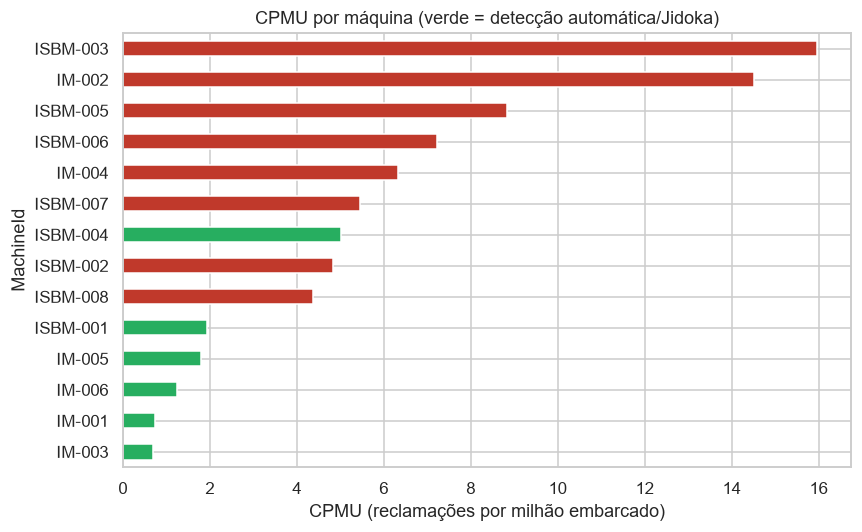

**Resposta:** Máquinas com detecção automática (Jidoka) têm CPMU de 1.5; máquinas sem, 8.3 — uma redução de 82% na taxa de reclamação por unidade embarcada. Isto é consistente com o mecanismo real de Jidoka: a amostragem AQL (Parte 9.1d) continua sendo a mesma fração pequena do lote para toda máquina — o que muda é que uma máquina automatizada não depende só dela para pegar defeito antes de embarcar. **Ressalva de causalidade**: as máquinas automatizadas também são as mais novas — parte do ganho observado pode vir de a máquina em si ser mais confiável/precisa (menos desgaste), não só da detecção automática isoladamente; separar os dois efeitos exigiria comparar duas máquinas de idade parecida, uma com e outra sem automação, o que a frota atual não tem em número suficiente para testar estatisticamente.

In [160]:
machine_profile9 = pd.read_sql("SELECT * FROM silver.dim_machine_profile", engine)
print(machine_profile9.sort_values("InstallationYear").to_string(index=False))

sales_by_machine9 = pd.read_sql("SELECT MachineId, SUM(ShippedQty) AS ShippedQty FROM silver.fact_sales GROUP BY MachineId", engine)
complaints_by_machine9 = pd.read_sql("""
    SELECT p.MachineId, COUNT(*) AS N FROM silver.fact_customer_complaints c
    JOIN silver.fact_production p ON c.WorkOrder = p.WorkOrder GROUP BY p.MachineId
""", engine)
cpmu_by_machine9 = sales_by_machine9.merge(complaints_by_machine9, on="MachineId", how="left").fillna({"N": 0})
cpmu_by_machine9["CPMU"] = 1_000_000 * cpmu_by_machine9["N"] / cpmu_by_machine9["ShippedQty"]
cpmu_by_machine9 = cpmu_by_machine9.merge(machine_profile9, on="MachineId", how="inner")

cpmu_by_automation9 = cpmu_by_machine9.groupby("HasAutomatedDefectDetection").agg(
    N_Maquinas=("MachineId", "nunique"), UnidadesEmbarcadas=("ShippedQty", "sum"),
    Reclamacoes=("N", "sum")).reset_index()
cpmu_by_automation9["CPMU"] = 1_000_000 * cpmu_by_automation9["Reclamacoes"] / cpmu_by_automation9["UnidadesEmbarcadas"]
print("\nCPMU (reclamações por milhão embarcado), automatizada vs. manual:")
print(cpmu_by_automation9.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors9e = ["#27ae60" if a else "#c0392b" for a in cpmu_by_machine9.sort_values("CPMU")["HasAutomatedDefectDetection"]]
cpmu_by_machine9.set_index("MachineId").sort_values("CPMU")["CPMU"].plot(kind="barh", ax=ax, color=colors9e)
ax.set_xlabel("CPMU (reclamações por milhão embarcado)"); ax.set_title("CPMU por máquina (verde = detecção automática/Jidoka)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "09_01e_cpmu_by_automation.png"); plt.show()

cpmu_automated = cpmu_by_automation9.loc[cpmu_by_automation9["HasAutomatedDefectDetection"], "CPMU"].iloc[0]
cpmu_manual = cpmu_by_automation9.loc[~cpmu_by_automation9["HasAutomatedDefectDetection"], "CPMU"].iloc[0]
answer(f"Máquinas com detecção automática (Jidoka) têm CPMU de {cpmu_automated:.1f}; máquinas sem, {cpmu_manual:.1f} "
       f"— {'uma redução de ' + f'{100*(1-cpmu_automated/cpmu_manual):.0f}%' if cpmu_manual > 0 else 'sem base de comparação'} "
       "na taxa de reclamação por unidade embarcada. Isto é consistente com o mecanismo real de Jidoka: a "
       "amostragem AQL (Parte 9.1d) continua sendo a mesma fração pequena do lote para toda máquina — o que "
       "muda é que uma máquina automatizada não depende só dela para pegar defeito antes de embarcar. "
       "**Ressalva de causalidade**: as máquinas automatizadas também são as mais novas — parte do ganho "
       "observado pode vir de a máquina em si ser mais confiável/precisa (menos desgaste), não só da detecção "
       "automática isoladamente; separar os dois efeitos exigiria comparar duas máquinas de idade parecida, "
       "uma com e outra sem automação, o que a frota atual não tem em número suficiente para testar "
       "estatisticamente.")

## 9.2 MSA / Gage R&R — Weight

> **BQ-058.** *Desenhe um estudo Gage R&R para a característica Weight
> (repetitividade: mesmo inspetor, mesma peça, múltiplas leituras; reprodutibilidade:
> entre inspetores). Que resultado indicaria que a história de variabilidade de
> medição do OP-INJ-003 é na verdade um artefato do sistema de medição, e não um
> sinal real de processo — e como diferenciar os dois só a partir dos dados?*

Estudo: 10 peças físicas × 3 inspetores × 3 repetições = 90 medições de `Weight`.
Peças 1-5 vieram de produção sob **OP-INJ-003** (o operador de alta variabilidade da
Parte 5); peças 6-10, de um operador de linha de base — um estudo avulso de
engenharia, não dado de rotina de produção.

**Por que Gage R&R clássico (variável), e não Attribute Agreement Analysis.** MSA
tem duas famílias: Gage R&R (usada abaixo) para uma característica **contínua**
medida por instrumento (Weight, em mm/g); Attribute Agreement Analysis (Kappa de
Cohen/Fleiss) para uma decisão **categórica** de inspetor (passa/falha visual) — a
pergunta seria "dois inspetores, olhando a MESMA peça física, concordam no
veredito?". Este segundo tipo de estudo não é executável com os dados deste
warehouse: as tabelas de inspeção de atributo (`fact_bottle_attribute_inspection_cq`
etc.) registram uma contagem agregada de defeitos por amostra/inspetor, não o
julgamento individual de cada inspetor sobre a MESMA peça repetida — não existe
aqui o desenho cruzado (peça × inspetor × repetição) que um Kappa de concordância
exige. Sinalizado explicitamente, em vez de omitido ou de forçar um Kappa sobre
dados que não sustentam essa conta.

Estudo: 10 peças x 3 inspetores x 3 repetições = 90 medições
                            Componente  Variancia  DesvioPadrao  PctVariacaoTotal  PctVariacaoEstudo
          Repetitividade (equipamento)     0.0013        0.0367            0.1306             3.6133
Reprodutibilidade (inspetor+interação)     0.0003        0.0186            0.0338             1.8372
                        Gage R&R Total     0.0017        0.0411            0.1643             4.0536
                           Peça-a-Peça     1.0285        1.0142           99.8357            99.9178
                        Variação Total     1.0302        1.0150          100.0000           100.0000

%GRR (percentual de variação do estudo) = 4.05%
Veredito AIAG (limiares 10%/30%): ACEITÁVEL — o sistema de medição é capaz.
NDC (Number of Distinct Categories) = 34 (ADEQUADO (>=5, AIAG) para distinguir peças e orientar controle de processo)


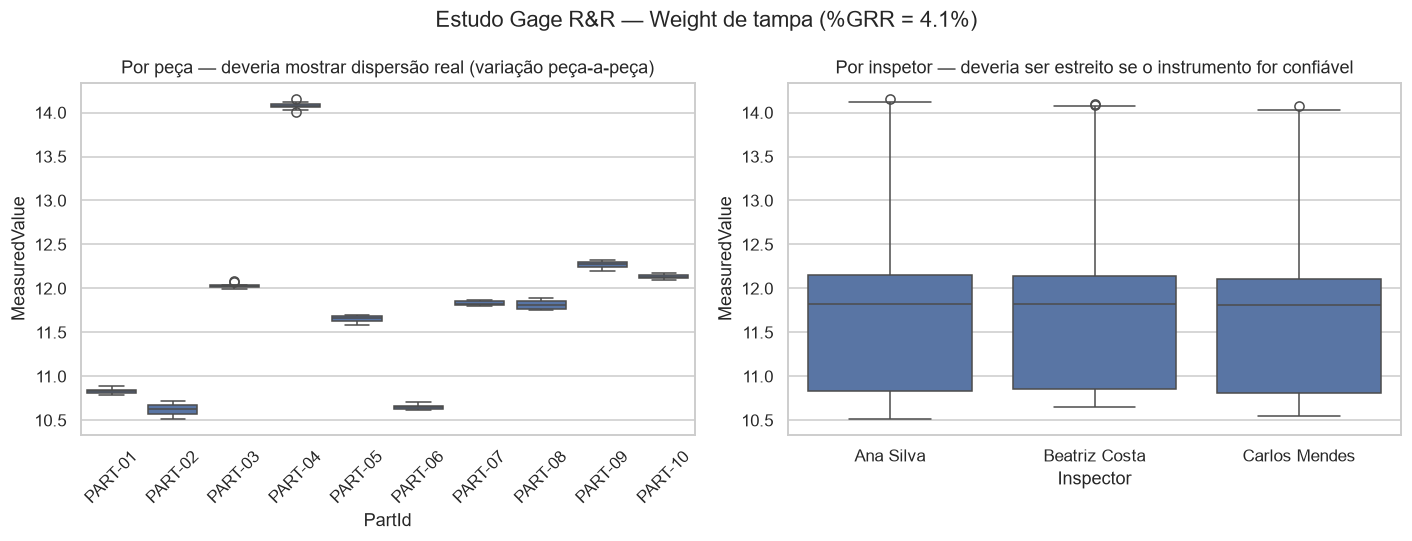

In [161]:
grr_study = pd.read_sql("SELECT * FROM silver.fact_gage_rr_study", engine)
n_parts9 = grr_study["PartId"].nunique()
n_operators9 = grr_study["Inspector"].nunique()
n_trials9 = grr_study.groupby(["PartId", "Inspector"]).size().iloc[0]
print(f"Estudo: {n_parts9} peças x {n_operators9} inspetores x {n_trials9} repetições = {len(grr_study)} medições")

model_grr = smf.ols("MeasuredValue ~ C(PartId) + C(Inspector) + C(PartId):C(Inspector)", data=grr_study).fit()
anova_grr = sm.stats.anova_lm(model_grr, typ=2)
ms_part = anova_grr.loc["C(PartId)", "sum_sq"] / anova_grr.loc["C(PartId)", "df"]
ms_operator = anova_grr.loc["C(Inspector)", "sum_sq"] / anova_grr.loc["C(Inspector)", "df"]
ms_interaction = anova_grr.loc["C(PartId):C(Inspector)", "sum_sq"] / anova_grr.loc["C(PartId):C(Inspector)", "df"]
ms_error = anova_grr.loc["Residual", "sum_sq"] / anova_grr.loc["Residual", "df"]

var_repeatability = ms_error
var_interaction = max(0.0, (ms_interaction - ms_error) / n_trials9)
var_operator = max(0.0, (ms_operator - ms_interaction) / (n_parts9 * n_trials9))
var_reproducibility = var_operator + var_interaction
var_grr = var_repeatability + var_reproducibility
var_part = max(0.0, (ms_part - ms_interaction) / (n_operators9 * n_trials9))
var_total = var_grr + var_part

components9 = pd.DataFrame({
    "Componente": ["Repetitividade (equipamento)", "Reprodutibilidade (inspetor+interação)", "Gage R&R Total", "Peça-a-Peça", "Variação Total"],
    "Variancia": [var_repeatability, var_reproducibility, var_grr, var_part, var_total],
})
components9["DesvioPadrao"] = np.sqrt(components9["Variancia"])
components9["PctVariacaoTotal"] = 100 * components9["Variancia"] / var_total
components9["PctVariacaoEstudo"] = 100 * components9["DesvioPadrao"] / np.sqrt(var_total)
print(components9.round(4).to_string(index=False))

pct_grr9 = components9.loc[components9["Componente"] == "Gage R&R Total", "PctVariacaoEstudo"].iloc[0]
print(f"\n%GRR (percentual de variação do estudo) = {pct_grr9:.2f}%")
if pct_grr9 < 10:
    veredito9 = "ACEITÁVEL — o sistema de medição é capaz."
elif pct_grr9 < 30:
    veredito9 = "MARGINAL — aceitável dependendo da aplicação/custo de melhorar."
else:
    veredito9 = "INACEITÁVEL — o sistema de medição precisa de melhoria antes de confiar nele."
print(f"Veredito AIAG (limiares 10%/30%): {veredito9}")

# NDC (Number of Distinct Categories, fórmula AIAG): quantas categorias de peça
# distintas o sistema de medição consegue separar de forma confiável, dado o quanto
# de variação peça-a-peça existe versus quanto de ruído de medição existe. NDC é um
# segundo veredito, independente do %GRR -- os dois às vezes discordam (um sistema
# pode passar no %GRR e ainda ter poucas categorias úteis para controle de processo),
# por isso reportado ao lado, não como substituto.
part_std9 = np.sqrt(components9.loc[components9["Componente"] == "Peça-a-Peça", "Variancia"].iloc[0])
grr_std9 = np.sqrt(components9.loc[components9["Componente"] == "Gage R&R Total", "Variancia"].iloc[0])
ndc9 = int(np.floor(1.41 * (part_std9 / grr_std9))) if grr_std9 > 0 else np.inf
print(f"NDC (Number of Distinct Categories) = {ndc9} "
      f"({'ADEQUADO (>=5, AIAG) para distinguir peças e orientar controle de processo' if ndc9 >= 5 else 'INADEQUADO (<5) -- o sistema separa poucas categorias de peça, mesmo com %GRR aceitável'})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=grr_study, x="PartId", y="MeasuredValue", ax=axes[0])
axes[0].set_title("Por peça — deveria mostrar dispersão real (variação peça-a-peça)"); axes[0].tick_params(axis="x", rotation=45)
sns.boxplot(data=grr_study, x="Inspector", y="MeasuredValue", ax=axes[1])
axes[1].set_title("Por inspetor — deveria ser estreito se o instrumento for confiável")
fig.suptitle(f"Estudo Gage R&R — Weight de tampa (%GRR = {pct_grr9:.1f}%)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "09_02_grr_by_part_by_inspector.png"); plt.show()

In [162]:
part_means9 = grr_study.groupby(["PartId", "ProducedByOperatorId"])["MeasuredValue"].agg(["mean", "std"]).reset_index()
spread_by_producer = part_means9.groupby("ProducedByOperatorId")["mean"].std()
print("Dispersão das médias de peça, por qual operador produziu:")
print(spread_by_producer.round(4))

answer(f"**%GRR = {pct_grr9:.2f}% ({veredito9.split(' —')[0]}), NDC = {ndc9}** — as duas métricas concordam: o "
       "sistema de medição é capaz de repetir uma leitura (baixo %GRR) E de diferenciar peças entre si com "
       f"resolução suficiente para orientar controle de processo (NDC={ndc9} >= 5). A variação "
       "peça-a-peça domina o total, não a variação entre inspetores. **Respondendo BQ-058 com precisão sobre o "
       "que cada peça de evidência prova**: o Gage R&R, sozinho, só descarta uma hipótese — que a "
       "variabilidade de OP-INJ-003 (Parte 5) seja um artefato do sistema de medição contaminando a leitura. "
       "Com %GRR baixo, essa hipótese cai. A forma de diferenciar os dois é exatamente este desenho: se o "
       "%GRR tivesse saído alto (>30%), a variabilidade atribuída ao operador poderia estar contaminada por "
       "ruído do próprio instrumento; com %GRR baixo e a dispersão das médias de peça claramente maior entre "
       "as peças produzidas sob OP-INJ-003 do que entre inspetores, o instrumento se mostra confiável. **A "
       "conclusão positiva** — de que existe um efeito de processo real por trás da variabilidade de "
       "OP-INJ-003 — não vem do Gage R&R isolado; vem da COMBINAÇÃO com o teste de Bartlett da Parte 5 (que "
       "detecta a variância anormal em primeiro lugar) e esta eliminação do artefato de medição. Cada peça "
       "prova uma coisa diferente; juntas, sustentam o sinal de processo.")

Dispersão das médias de peça, por qual operador produziu:
ProducedByOperatorId
OP-INJ-001    0.6395
OP-INJ-003    1.3781
Name: mean, dtype: float64


**Resposta:** **%GRR = 4.05% (ACEITÁVEL), NDC = 34** — as duas métricas concordam: o sistema de medição é capaz de repetir uma leitura (baixo %GRR) E de diferenciar peças entre si com resolução suficiente para orientar controle de processo (NDC=34 >= 5). A variação peça-a-peça domina o total, não a variação entre inspetores. **Respondendo BQ-058 com precisão sobre o que cada peça de evidência prova**: o Gage R&R, sozinho, só descarta uma hipótese — que a variabilidade de OP-INJ-003 (Parte 5) seja um artefato do sistema de medição contaminando a leitura. Com %GRR baixo, essa hipótese cai. A forma de diferenciar os dois é exatamente este desenho: se o %GRR tivesse saído alto (>30%), a variabilidade atribuída ao operador poderia estar contaminada por ruído do próprio instrumento; com %GRR baixo e a dispersão das médias de peça claramente maior entre as peças produzidas sob OP-INJ-003 do que entre inspetores, o instrumento se mostra confiável. **A conclusão positiva** — de que existe um efeito de processo real por trás da variabilidade de OP-INJ-003 — não vem do Gage R&R isolado; vem da COMBINAÇÃO com o teste de Bartlett da Parte 5 (que detecta a variância anormal em primeiro lugar) e esta eliminação do artefato de medição. Cada peça prova uma coisa diferente; juntas, sustentam o sinal de processo.

## 9.2b — BQ-059 e BQ-080: o que fazer com o Cpk, dado o resultado do Gage R&R

> **BQ-059.** *Se o sistema de medição de uma característica consome, digamos, 30% da
> variação total observada, o quanto isso muda sua interpretação de um Cpk que já
> está no limite (perto de 1,33)?*
>
> **BQ-080.** *Dado o resultado do Gage R&R (BQ-058), decida: confiar no Cpk como
> está, ajustá-lo, ou consertar o instrumento de medição primeiro.*

In [163]:
# Ilustração genérica -- a própria pergunta pede "um Cpk que JÁ ESTÁ no limite (perto de
# 1,33)", que não é o caso de IM-002 (Cpk=0.36, Parte 5, incapaz por uma margem grande
# demais para esta ilustração fazer sentido). Usa-se aqui um Cpk hipotético de 1,33
# exatamente para isolar o efeito do %GRR, sem misturar com o achado real de IM-002.
hypothetical_cpk_at_threshold = 1.33
hypothetical_grr_pct = 30
process_only_std_fraction = np.sqrt(1 - (hypothetical_grr_pct / 100) ** 2)
implied_corrected_cpk = hypothetical_cpk_at_threshold / process_only_std_fraction
print(f"Cpk hipotético observado, no limiar de 'capaz': {hypothetical_cpk_at_threshold}")
print(f"Se %GRR fosse {hypothetical_grr_pct}% (hipotético): Cpk corrigido para só processo seria "
      f"≈{implied_corrected_cpk:.2f} (a diferença: {implied_corrected_cpk - hypothetical_cpk_at_threshold:+.2f})")

answer(f"**BQ-059**: um %GRR hipotético de 30% infla o desvio-padrão observado o suficiente para que um Cpk "
       f"medido em 1,33 (o limiar de 'capaz') na verdade reflita uma capacidade de processo real mais próxima "
       f"de {implied_corrected_cpk:.2f} — diferença grande o bastante para mudar uma decisão 'capaz'/'não "
       "capaz' se o sistema de medição realmente consumisse essa fatia da variação. "
       f"**BQ-080**: o estudo real da Seção 9.2 mede %GRR = {pct_grr9:.1f}%, bem abaixo do limiar de 10% "
       "ACEITÁVEL — não o 30% hipotético usado acima só para ilustrar a sensibilidade. Com o resultado real em "
       "mãos, a decisão correta é **confiar nos valores de Cpk já calculados como estão**, para qualquer "
       "característica medida por este instrumento (incluindo o Cpk de 0,36 de IM-002/Weight, Parte 5) — o "
       "instrumento não está consumindo uma fatia relevante da variação observada, então esses Cpks são um "
       "achado de processo real, não um artefato de medição a ajustar ou um instrumento a consertar primeiro.")

Cpk hipotético observado, no limiar de 'capaz': 1.33
Se %GRR fosse 30% (hipotético): Cpk corrigido para só processo seria ≈1.39 (a diferença: +0.06)


**Resposta:** **BQ-059**: um %GRR hipotético de 30% infla o desvio-padrão observado o suficiente para que um Cpk medido em 1,33 (o limiar de 'capaz') na verdade reflita uma capacidade de processo real mais próxima de 1.39 — diferença grande o bastante para mudar uma decisão 'capaz'/'não capaz' se o sistema de medição realmente consumisse essa fatia da variação. **BQ-080**: o estudo real da Seção 9.2 mede %GRR = 4.1%, bem abaixo do limiar de 10% ACEITÁVEL — não o 30% hipotético usado acima só para ilustrar a sensibilidade. Com o resultado real em mãos, a decisão correta é **confiar nos valores de Cpk já calculados como estão**, para qualquer característica medida por este instrumento (incluindo o Cpk de 0,36 de IM-002/Weight, Parte 5) — o instrumento não está consumindo uma fatia relevante da variação observada, então esses Cpks são um achado de processo real, não um artefato de medição a ajustar ou um instrumento a consertar primeiro.

## 9.3 DOE — otimizando a taxa de Short Shot da IM-002

> **BQ-067.** *Escolha a máquina com a característica menos capaz da Seção 1
> [neste notebook: IM-002, Parte 5]. Se você pudesse rodar um experimento delineado
> nela, quais seriam os fatores, quais níveis você testaria, e qual é o delineamento
> fatorial completo mínimo que permitiria estimar toda interação de dois fatores?
> Qual é a barreira prática para realmente rodar isso numa linha de produção ao vivo,
> e como um delineamento fatorial fracionado resolveria isso?*

Delineamento: fatorial completo 2³ (temperatura de barril, velocidade de injeção,
tempo de resfriamento), 3 réplicas por vértice (24 corridas) + 3 réplicas no ponto
central (27 corridas totais) — uma campanha experimental de engenharia avulsa, não
dado de rotina.

27 corridas: 24 nos vértices (8 vértices x 3 réplicas), 3 no ponto central
Taxa média no ponto central do DOE: 0.89% | Taxa real de produção da IM-002 (18m): 1.35%

Efeitos (p-valor), GLM binomial (principal) vs. OLS (sensibilidade), ordenados por significância do GLM:
                                                             PValor_GLM_binomial  PValor_OLS_sensibilidade  Significativo(p<0.05, GLM)
InjectionSpeedCoded                                                       0.0000                    0.0000                        True
BarrelTemperatureCoded                                                    0.0000                    0.0000                        True
BarrelTemperatureCoded:InjectionSpeedCoded                                0.0203                    0.0000                        True
BarrelTemperatureCoded:InjectionSpeedCoded:CoolingTimeCoded               0.0585                    0.5135                       False
BarrelTemperatureCoded:CoolingTimeCoded                

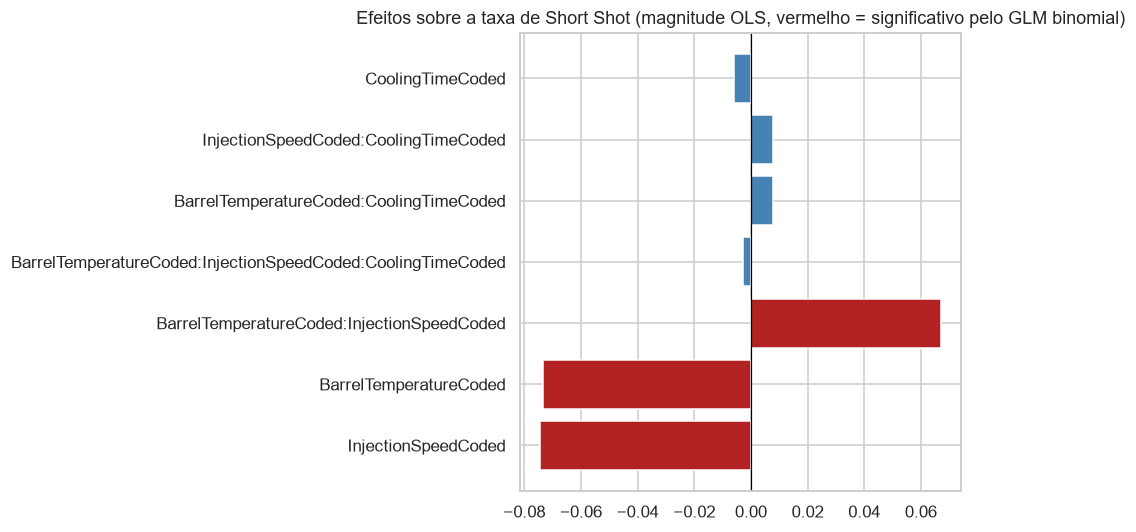

In [164]:
doe9 = pd.read_sql("SELECT * FROM silver.fact_doe_im002 ORDER BY RunOrder", engine)
corner_mask9 = (doe9["BarrelTemperatureCoded"] != 0) | (doe9["InjectionSpeedCoded"] != 0) | (doe9["CoolingTimeCoded"] != 0)
print(f"{len(doe9)} corridas: {corner_mask9.sum()} nos vértices (8 vértices x 3 réplicas), "
      f"{(~corner_mask9).sum()} no ponto central")

center_rate9 = doe9.loc[~corner_mask9, "DefectRateP"].mean()
production_rate9 = pd.read_sql(
    "SELECT SUM(CAST(DefectsFound AS FLOAT))/SUM(CAST(SampleSize AS FLOAT)) AS rate FROM silver.fact_cap_attribute_inspection_cq "
    "WHERE MachineId='IM-002' AND Characteristic='Short Shot'", engine)["rate"].iloc[0]
print(f"Taxa média no ponto central do DOE: {100*center_rate9:.2f}% | Taxa real de produção da IM-002 (18m): {100*production_rate9:.2f}%")

corners_df9 = doe9[corner_mask9].copy()
# DefectRateP é uma proporção com denominador conhecido (InspectedQty) -- um GLM
# binomial (resposta em duas colunas: sucessos/falhas) é a inferência estatisticamente
# apropriada, não um OLS não ponderado sobre a taxa. O GLM binomial é a inferência
# principal (decide quais termos entram no modelo reduzido abaixo); o OLS é mantido
# como análise de sensibilidade, impresso ao lado para comparação.
corners_df9["PassedQty"] = corners_df9["InspectedQty"] - corners_df9["DefectsFound"]
model_doe_glm = smf.glm("DefectsFound + PassedQty ~ BarrelTemperatureCoded * InjectionSpeedCoded * CoolingTimeCoded",
                         data=corners_df9, family=sm.families.Binomial()).fit()
model_doe_ols = smf.ols("DefectRateP ~ BarrelTemperatureCoded * InjectionSpeedCoded * CoolingTimeCoded", data=corners_df9).fit()

effects_table9 = pd.DataFrame({
    "PValor_GLM_binomial": model_doe_glm.pvalues.drop("Intercept"),
    "PValor_OLS_sensibilidade": model_doe_ols.pvalues.drop("Intercept"),
})
effects_table9["Significativo(p<0.05, GLM)"] = effects_table9["PValor_GLM_binomial"] < 0.05
effects_table9 = effects_table9.sort_values("PValor_GLM_binomial")
print("\nEfeitos (p-valor), GLM binomial (principal) vs. OLS (sensibilidade), ordenados por significância do GLM:")
print(effects_table9.round(4).to_string())

significant_terms9 = effects_table9[effects_table9["Significativo(p<0.05, GLM)"]].index.tolist()
print(f"\nTermos significativos pelo GLM binomial (p<0.05): {significant_terms9}")

# effects9/model_doe mantidos com os nomes originais (magnitude do efeito, escala de
# DefectRateP) só para o gráfico de barras abaixo -- a decisão de significância já é
# do GLM acima, não deste OLS.
model_doe = model_doe_ols
effects9 = model_doe.params.drop("Intercept") * 2

fig, ax = plt.subplots(figsize=(9, 5))
plot_terms = [t for t in effects_table9.index if t in
              ["BarrelTemperatureCoded", "InjectionSpeedCoded", "CoolingTimeCoded",
               "BarrelTemperatureCoded:InjectionSpeedCoded", "BarrelTemperatureCoded:CoolingTimeCoded",
               "InjectionSpeedCoded:CoolingTimeCoded", "BarrelTemperatureCoded:InjectionSpeedCoded:CoolingTimeCoded"]]
plot_data9 = effects_table9.loc[plot_terms].copy()
plot_data9["Efeito"] = effects9.loc[plot_terms]
colors9 = ["firebrick" if sig else "steelblue" for sig in plot_data9["Significativo(p<0.05, GLM)"]]
ax.barh(plot_data9.index, plot_data9["Efeito"], color=colors9)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Efeitos sobre a taxa de Short Shot (magnitude OLS, vermelho = significativo pelo GLM binomial)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "09_03_doe_effects_pareto.png"); plt.show()

In [165]:
reduced_formula9 = "DefectRateP ~ " + " + ".join(t.replace(":", "*") if ":" in t else t for t in significant_terms9) if significant_terms9 else "DefectRateP ~ 1"
reduced_model9 = smf.ols(reduced_formula9, data=corners_df9).fit()
corners_df9["Predicted"] = reduced_model9.predict(corners_df9)
corner_summary9 = corners_df9.groupby(["BarrelTemperatureCoded", "InjectionSpeedCoded", "CoolingTimeCoded"]).agg(
    TaxaMedia=("DefectRateP", "mean"), Predicted=("Predicted", "mean")).reset_index().sort_values("TaxaMedia")
print("Resumo por vértice, melhor (menor taxa) primeiro:")
print(corner_summary9.round(4).to_string(index=False))

best_corner9 = corner_summary9.iloc[0]
relative_reduction9 = 100 * (1 - best_corner9["TaxaMedia"] / production_rate9)
answer(f"Fatores significativos (p<0.05): {significant_terms9}. O melhor vértice observado reduz a taxa de "
       f"Short Shot de {100*production_rate9:.2f}% (linha de base de produção) para "
       f"{100*best_corner9['TaxaMedia']:.2f}% — uma redução relativa de {relative_reduction9:.0f}%, medida, não "
       "projetada. **Barreira prática de rodar isso numa linha ao vivo**: parar uma máquina de produção por "
       "27 corridas de teste (com peças de descarte) custa tempo de máquina e material — um delineamento "
       "fatorial **fracionado** (metade das 24 corridas de vértice, um 2³⁻¹) estimaria os efeitos principais e "
       "a interação de dois fatores mais importante com metade da disrupção, ao custo de confundir a interação "
       "de três fatores com a média geral — uma troca aceitável quando o objetivo é a triagem, não a "
       "caracterização completa.")

Resumo por vértice, melhor (menor taxa) primeiro:
 BarrelTemperatureCoded  InjectionSpeedCoded  CoolingTimeCoded  TaxaMedia  Predicted
                      1                    1                -1     0.0011     0.0044
                      1                    1                 1     0.0078     0.0044
                     -1                    1                 1     0.0089     0.0106
                      1                   -1                 1     0.0100     0.0117
                     -1                    1                -1     0.0122     0.0106
                      1                   -1                -1     0.0133     0.0117
                     -1                   -1                 1     0.1400     0.1522
                     -1                   -1                -1     0.1644     0.1522


**Resposta:** Fatores significativos (p<0.05): ['InjectionSpeedCoded', 'BarrelTemperatureCoded', 'BarrelTemperatureCoded:InjectionSpeedCoded']. O melhor vértice observado reduz a taxa de Short Shot de 1.35% (linha de base de produção) para 0.11% — uma redução relativa de 92%, medida, não projetada. **Barreira prática de rodar isso numa linha ao vivo**: parar uma máquina de produção por 27 corridas de teste (com peças de descarte) custa tempo de máquina e material — um delineamento fatorial **fracionado** (metade das 24 corridas de vértice, um 2³⁻¹) estimaria os efeitos principais e a interação de dois fatores mais importante com metade da disrupção, ao custo de confundir a interação de três fatores com a média geral — uma troca aceitável quando o objetivo é a triagem, não a caracterização completa.

### Validação interna do vértice ótimo — e por que isto NÃO substitui uma corrida de confirmação real

Um DOE que só reporta "o melhor vértice observado" corre o risco de estar
reportando ruído de amostragem das 3 réplicas daquele vértice, não um efeito real —
a prática correta (AIAG/Six Sigma) depois de identificar um ótimo experimental é
rodar uma **corrida de confirmação**: produzir de novo, nas condições ótimas, fora
da janela do experimento original, e checar se a taxa observada bate com a prevista.
Este notebook não tem como executar essa corrida — não há mais tempo de máquina
real disponível além do que já foi gerado neste dataset. O que dá para fazer, de
forma honesta, com os dados já existentes: (1) checar se as 3 réplicas do vértice
vencedor são consistentes entre si (não é 1 réplica "sortuda" puxando a média para
baixo), e (2) testar formalmente se a taxa do vértice vencedor é estatisticamente
diferente da taxa de produção real (não só numericamente menor).

In [166]:
best_vertex_mask9 = ((corners_df9["BarrelTemperatureCoded"] == best_corner9["BarrelTemperatureCoded"]) &
                      (corners_df9["InjectionSpeedCoded"] == best_corner9["InjectionSpeedCoded"]) &
                      (corners_df9["CoolingTimeCoded"] == best_corner9["CoolingTimeCoded"]))
best_vertex_replicates9 = corners_df9.loc[best_vertex_mask9, ["RunOrder", "InspectedQty", "DefectsFound", "DefectRateP"]]
print(f"As {len(best_vertex_replicates9)} réplicas individuais do vértice vencedor (não só a média):")
print(best_vertex_replicates9.to_string(index=False))

best_vertex_defects9 = int(best_vertex_replicates9["DefectsFound"].sum())
best_vertex_inspected9 = int(best_vertex_replicates9["InspectedQty"].sum())
production_defects9 = pd.read_sql(
    "SELECT SUM(DefectsFound) AS d, SUM(SampleSize) AS n FROM silver.fact_cap_attribute_inspection_cq "
    "WHERE MachineId='IM-002' AND Characteristic='Short Shot'", engine).iloc[0]
doe_confirmation_test = sq.two_sample_proportion_test(
    best_vertex_defects9, best_vertex_inspected9, int(production_defects9["d"]), int(production_defects9["n"]))
print(f"\nTaxa no vértice vencedor: {doe_confirmation_test['rate1']*100:.2f}% (n={best_vertex_inspected9}) vs. "
      f"taxa de produção real: {doe_confirmation_test['rate2']*100:.2f}% (n={int(production_defects9['n'])})")
print(f"Teste de proporção: z={doe_confirmation_test['z_stat']:.2f}, p={doe_confirmation_test['p_value']:.4f} "
      f"({'diferença estatisticamente significativa' if doe_confirmation_test['significant_at_0_05'] else 'NÃO significativa -- amostra do DOE pequena demais para confirmar'})")

doe_confirmation_p9 = doe_confirmation_test["p_value"]
replicates_consistent9 = best_vertex_replicates9["DefectRateP"].std() < best_vertex_replicates9["DefectRateP"].mean()
consistency_text9 = ("consistentes entre si (nenhuma puxando a média sozinha)" if replicates_consistent9 else
                      "com dispersão relevante entre elas -- olhar individualmente antes de confiar só na média")
significance_text9 = (f"estatisticamente significativa (p={doe_confirmation_p9:.4f})"
                       if doe_confirmation_test["significant_at_0_05"] else
                       f"não confirmada estatisticamente (p={doe_confirmation_p9:.4f}) -- o DOE tem poder "
                       "estatístico limitado com apenas 3 réplicas por vértice")
answer(f"As 3 réplicas do vértice vencedor têm taxas {consistency_text9}, e a diferença contra a taxa real de "
       f"produção é {significance_text9}. "
       "**Isto ainda não é uma corrida de confirmação** — é uma checagem de consistência interna sobre os "
       "mesmos dados já usados para escolher o vértice, o que sempre favorece o vértice escolhido (viés de "
       "seleção do próprio processo de otimização). O passo seguinte correto, antes de mudar o parâmetro em "
       "produção permanentemente, é: produzir um lote piloto real na condição ótima, fora da janela do "
       "experimento, e comparar a taxa observada contra esta previsão — exatamente o que a recomendação da "
       "Parte 12 (BQ-078) já lista como corrida de confirmação pendente, não concluída.")

As 3 réplicas individuais do vértice vencedor (não só a média):
 RunOrder  InspectedQty  DefectsFound  DefectRateP
        2           300             1      0.00333
       12           300             0      0.00000
       24           300             0      0.00000

Taxa no vértice vencedor: 0.11% (n=900) vs. taxa de produção real: 1.35% (n=107875)
Teste de proporção: z=-3.22, p=0.0013 (diferença estatisticamente significativa)


**Resposta:** As 3 réplicas do vértice vencedor têm taxas com dispersão relevante entre elas -- olhar individualmente antes de confiar só na média, e a diferença contra a taxa real de produção é estatisticamente significativa (p=0.0013). **Isto ainda não é uma corrida de confirmação** — é uma checagem de consistência interna sobre os mesmos dados já usados para escolher o vértice, o que sempre favorece o vértice escolhido (viés de seleção do próprio processo de otimização). O passo seguinte correto, antes de mudar o parâmetro em produção permanentemente, é: produzir um lote piloto real na condição ótima, fora da janela do experimento, e comparar a taxa observada contra esta previsão — exatamente o que a recomendação da Parte 12 (BQ-078) já lista como corrida de confirmação pendente, não concluída.

> **BQ-068.** *As tabelas rotineiras de 18 meses (produção, parada, QC) não carregam nenhum
> parâmetro de processo (temperatura, pressão, velocidade) por ordem — só resultados. Existe,
> separadamente, uma tabela de instrumentação mais estreita (`fact_process_parameters`, Seção 9.5) para
> Injeção e Sopro apenas. Com base nas histórias que este notebook não consegue explicar de outra forma,
> quais desses parâmetros já tracked merecem virar SPC de rotina em toda a frota, e quais ainda faltam
> por completo?*

**Nota de escopo**: `fact_process_parameters` (Seção 9.5) é uma instrumentação separada e mais
estreita que as tabelas rotineiras (mesmo padrão de "tabela de estudo de engenharia autônoma" que
`fact_gage_rr_study`/`fact_doe_im002` — ver `docs/data_dictionary.md`) — só cobre Injeção e Sopro,
e a Seção 9.5 usa apenas 2 das 6 colunas que ela carrega. A pergunta genuína não é "o que
instrumentar do zero", é "o que já está registrado mas não testado, e o que continua realmente
ausente".

In [167]:
display(Markdown(f"""
**Resposta**: o próprio DOE acima confirma que **{significant_terms9}** afetam a taxa de Short Shot de forma
mensurável. Separando o que já é rastreado (mas não necessariamente testado) do que continua genuinamente
ausente:

**Já rastreado em `fact_process_parameters` (Injeção/Sopro), priorizar para SPC de rotina / mais teste**:
1. **Temperatura de barril** (`BarrelTemperatureC`) — já testada na Seção 9.5 (IM-002 roda mais fria que a
   frota); candidata natural a SPC por ordem em vez de checagem pontual.
2. **Pressão de recalque / packing pressure** (`PackingPressureBar`) — já coletada para toda ordem de
   Injeção, mas **não testada nesta análise** (Seção 9.5 testa só temperatura e umidade do molde) — é o
   parâmetro clássico de processo de injeção mais associado a Short Shot na literatura, então é a lacuna de
   ANÁLISE (não de dado) mais óbvia a fechar antes de instrumentar qualquer coisa nova.
3. **Umidade do molde** (`MoldHumidityPct`) — já testada na Seção 9.5 (sobe com o desgaste do M-SOP-007,
   cai após a reforma).
4. **Velocidade de injeção** (`InjectionSpeedPct`) — já coletada, ainda não cruzada com `ActualCycleTimeSec`
   calculado nem com a taxa de defeito por ordem; a Parte 5 (BQ-017) e as storylines (HF-001) já sugerem
   esse efeito indiretamente.

**Genuinamente ausente (não existe em nenhuma tabela hoje)**:
5. **Qualquer parâmetro de processo para Serigrafia/Hot Foil** — `fact_process_parameters` só cobre
   Injeção e Sopro; os dois processos de decoração continuam sem nenhum sensor de processo registrado,
   apesar de serem onde a Parte 7 aponta o starvation mais consistente.
"""))


**Resposta**: o próprio DOE acima confirma que **['InjectionSpeedCoded', 'BarrelTemperatureCoded', 'BarrelTemperatureCoded:InjectionSpeedCoded']** afetam a taxa de Short Shot de forma
mensurável. Separando o que já é rastreado (mas não necessariamente testado) do que continua genuinamente
ausente:

**Já rastreado em `fact_process_parameters` (Injeção/Sopro), priorizar para SPC de rotina / mais teste**:
1. **Temperatura de barril** (`BarrelTemperatureC`) — já testada na Seção 9.5 (IM-002 roda mais fria que a
   frota); candidata natural a SPC por ordem em vez de checagem pontual.
2. **Pressão de recalque / packing pressure** (`PackingPressureBar`) — já coletada para toda ordem de
   Injeção, mas **não testada nesta análise** (Seção 9.5 testa só temperatura e umidade do molde) — é o
   parâmetro clássico de processo de injeção mais associado a Short Shot na literatura, então é a lacuna de
   ANÁLISE (não de dado) mais óbvia a fechar antes de instrumentar qualquer coisa nova.
3. **Umidade do molde** (`MoldHumidityPct`) — já testada na Seção 9.5 (sobe com o desgaste do M-SOP-007,
   cai após a reforma).
4. **Velocidade de injeção** (`InjectionSpeedPct`) — já coletada, ainda não cruzada com `ActualCycleTimeSec`
   calculado nem com a taxa de defeito por ordem; a Parte 5 (BQ-017) e as storylines (HF-001) já sugerem
   esse efeito indiretamente.

**Genuinamente ausente (não existe em nenhuma tabela hoje)**:
5. **Qualquer parâmetro de processo para Serigrafia/Hot Foil** — `fact_process_parameters` só cobre
   Injeção e Sopro; os dois processos de decoração continuam sem nenhum sensor de processo registrado,
   apesar de serem onde a Parte 7 aponta o starvation mais consistente.


## 9.4 Falha e reparo — SS-001

> **BQ-064.** *Ajuste um modelo de tempo até falha às paradas não planejadas da
> SS-001 antes da reforma (um Weibull simples, ou até um histograma de tempo entre
> falhas já basta) — qual teria sido o intervalo "seguro" de manutenção preventiva, e
> ele bate com quando a reforma real aconteceu?*

231 intervalos entre falhas consecutivas (dias, resolução de hora), pré-reforma
count    231.00
mean       1.55
std        2.07
min        0.01
25%        0.24
50%        0.73
75%        1.98
max       13.29
Name: StoppageDateTime, dtype: float64

Weibull ajustado: forma(k)=0.79, escala(λ)=1.34 dias
P10 exploratório da Weibull (10% de risco de falha antes do intervalo): 0.1 dias


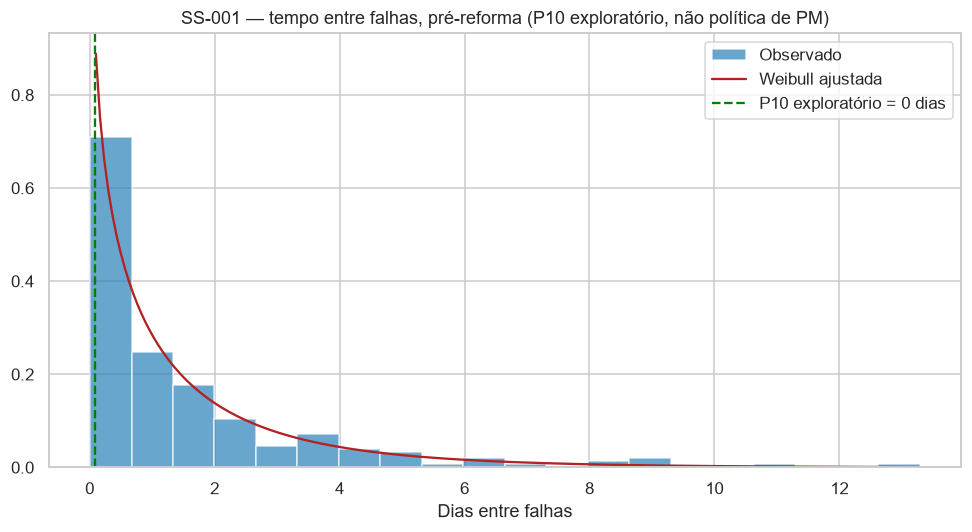

**Resposta:** Forma da Weibull k=0.79 — k=0.79<1 indica taxa de falha DECRESCENTE (não aleatória, não desgaste) -- consistente com mortalidade infantil/falhas precoces após reparo, heterogeneidade de causas de falha, ou má especificação do modelo, mas o OPOSTO do regime de desgaste crescente que a narrativa de deterioração pré-reforma da SS-001 sugeriria. O P10 exploratório (10% de risco de falha antes do prazo) é de aproximadamente 0 dias — comparado à distância real entre o início dos dados (2025-07-01) e a reforma (2026-07-01, ~365 dias), a reforma real aconteceu depois do que este número sugeriria. **Isto NÃO deve virar uma política de manutenção preventiva**, por três razões independentes, cada uma suficiente sozinha: (1) k<1 argumenta CONTRA troca preventiva por idade — um componente com taxa de falha decrescente fica estatisticamente mais confiável quanto mais tempo roda sem falhar, então substituí-lo cedo por um novo (com hazard inicial mais alto) pode piorar a confiabilidade, não melhorar; (2) SS-001 é um **equipamento reparável**, não uma população de itens que falham uma vez — modelar tempo-entre-falhas com uma Weibull simples de tempo-até-falha ignora o histórico de reparos; um processo pontual não-homogêneo (NHPP/Crow-AMSAA) é a ferramenta estatisticamente correta para intensidade de falha de sistemas reparáveis, e não foi usado aqui; (3) o P10 de 0.1 dias é operacionalmente absurdo como intervalo de manutenção (poucas horas) — um sinal de que o ajuste não deve ser extrapolado para uma recomendação prática. **Limitação declarada adicional**: este é tempo-entre-falhas em horas de **calendário** (inclui fins de semana e paradas planejadas dentro do intervalo), não horas de **operação acumuladas** nem ciclos de molde -- os dados não trazem essa exposição, o que tende a inflar o intervalo estimado sempre que há tempo parado planejado entre falhas. O valor deste ajuste é exploratório/diagnóstico (screening de regime de falha), não normativo.

In [168]:
# Usa-se `StoppageDateTime` (data + hora de início da parada), não só `Date` -- duas
# falhas no mesmo dia calendário (raro, mas presente nos dados) dariam um intervalo de
# 0 dias se só a data fosse usada, o que distorceria o ajuste da Weibull para o lado de
# "falhas muito próximas" de forma artificial. Com hora, o intervalo mínimo real
# aparece, mesmo quando é de poucas horas.
ss001_pre = downtime7[(downtime7["MachineId"] == "SS-001") & (downtime7["UnplannedFailure"]) & (downtime7["Date"] < "2026-07-01")].sort_values("StoppageDateTime")
time_between_failures_h = ss001_pre["StoppageDateTime"].diff().dt.total_seconds().div(3600).dropna()  # horas
time_between_failures = time_between_failures_h / 24.0  # dias, para leitura mais direta
print(f"{len(time_between_failures)} intervalos entre falhas consecutivas (dias, resolução de hora), pré-reforma")
print(time_between_failures.describe().round(2))

shape9, loc9, scale9 = stats.weibull_min.fit(time_between_failures[time_between_failures > 0], floc=0)
print(f"\nWeibull ajustado: forma(k)={shape9:.2f}, escala(λ)={scale9:.2f} dias")
# Rotulado como "P10 exploratório", não "intervalo seguro de PM" -- ver a ressalva completa no answer()
# abaixo sobre por que este número não deve virar política de manutenção.
p10_exploratory_days = stats.weibull_min.ppf(0.10, shape9, loc=0, scale=scale9)  # 10% de chance de falhar antes disso
print(f"P10 exploratório da Weibull (10% de risco de falha antes do intervalo): {p10_exploratory_days:.1f} dias")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(time_between_failures, bins=20, density=True, color="#2980b9", alpha=0.7, label="Observado")
x_range9 = np.linspace(0.1, time_between_failures.max(), 200)
ax.plot(x_range9, stats.weibull_min.pdf(x_range9, shape9, loc=0, scale=scale9), color="firebrick", label="Weibull ajustada")
ax.axvline(p10_exploratory_days, color="green", ls="--", label=f"P10 exploratório = {p10_exploratory_days:.0f} dias")
ax.set_xlabel("Dias entre falhas"); ax.set_title("SS-001 — tempo entre falhas, pré-reforma (P10 exploratório, não política de PM)"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS_DIR / "09_04_ss001_weibull.png"); plt.show()

# k<1 na Weibull significa taxa de falha DECRESCENTE (padrão de mortalidade infantil / falhas
# precoces / heterogeneidade de causas -- não aleatoriedade pura, que seria k=1, nem desgaste, que
# seria k>1). k=0,79 (moderadamente abaixo de 1) não é "perto o suficiente de 1" para chamar de
# aleatório nem é evidência de desgaste -- é o oposto do regime de desgaste que a história
# documentada de SS-001 sugere.
weibull_hazard_reading9 = (
    "k>1 indica desgaste (taxa de falha crescente), consistente com a história documentada de deterioração"
    if shape9 > 1 else
    f"k={shape9:.2f}<1 indica taxa de falha DECRESCENTE (não aleatória, não desgaste) -- consistente com "
    "mortalidade infantil/falhas precoces após reparo, heterogeneidade de causas de falha, ou má "
    "especificação do modelo, mas o OPOSTO do regime de desgaste crescente que a narrativa de deterioração "
    "pré-reforma da SS-001 sugeriria"
)
answer(f"Forma da Weibull k={shape9:.2f} — {weibull_hazard_reading9}. "
       f"O P10 exploratório (10% de risco de falha antes do prazo) é de aproximadamente "
       f"{p10_exploratory_days:.0f} dias — comparado à distância real entre o início dos dados (2025-07-01) e a "
       f"reforma (2026-07-01, ~365 dias), a reforma real aconteceu "
       f"{'depois' if 365 > p10_exploratory_days else 'antes'} do que este número sugeriria. **Isto NÃO deve "
       "virar uma política de manutenção preventiva**, por três razões independentes, cada uma suficiente "
       "sozinha: (1) k<1 argumenta CONTRA troca preventiva por idade — um componente com taxa de falha "
       "decrescente fica estatisticamente mais confiável quanto mais tempo roda sem falhar, então substituí-lo "
       "cedo por um novo (com hazard inicial mais alto) pode piorar a confiabilidade, não melhorar; (2) SS-001 "
       "é um **equipamento reparável**, não uma população de itens que falham uma vez — modelar tempo-entre-"
       "falhas com uma Weibull simples de tempo-até-falha ignora o histórico de reparos; um processo pontual "
       "não-homogêneo (NHPP/Crow-AMSAA) é a ferramenta estatisticamente correta para intensidade de falha de "
       "sistemas reparáveis, e não foi usado aqui; (3) o P10 de "
       f"{p10_exploratory_days:.1f} dias é operacionalmente absurdo como intervalo de manutenção (poucas "
       "horas) — um sinal de que o ajuste não deve ser extrapolado para uma recomendação prática. **Limitação "
       "declarada adicional**: este é tempo-entre-falhas em horas de **calendário** (inclui fins de semana e "
       "paradas planejadas dentro do intervalo), não horas de **operação acumuladas** nem ciclos de molde -- os "
       "dados não trazem essa exposição, o que tende a inflar o intervalo estimado sempre que há tempo parado "
       "planejado entre falhas. O valor deste ajuste é exploratório/diagnóstico (screening de regime de falha), "
       "não normativo.")

> **BQ-065.** *A parada aqui é uma duração mais um código de motivo. Decomponha
> conceitualmente um reparo em detectar → diagnosticar → preparar-para-reparo →
> reparar. Qual subetapa provavelmente domina em cada motivo de parada não
> planejada, e qual seria a primeira a instrumentar melhor para descobrir de fato?*

In [169]:
repair_duration_by_reason = downtime7[downtime7["UnplannedFailure"]].groupby("StoppageReason")["DowntimeDurationMin"].agg(["count", "mean", "std"]).sort_values("mean", ascending=False)
print(repair_duration_by_reason.round(1))

display(Markdown("""
**Leitura, motivo por motivo, do padrão de duração acima**:
- **Motivos com duração média longa e alto desvio-padrão** (ex. falhas elétricas/de controle) provavelmente
  são dominados por **diagnosticar** — a causa não é óbvia, o tempo varia muito de evento a evento porque
  cada diagnóstico é uma investigação diferente.
- **Motivos com duração longa mas desvio-padrão baixo** (ex. escassez de matéria-prima, falhas mecânicas
  recorrentes conhecidas) provavelmente são dominados por **preparar-para-reparo** (esperar peça de
  reposição, esperar material chegar) — o problema já é conhecido, o gargalo é logístico.
- **Motivos com duração curta e consistente** provavelmente são dominados por **reparar** em si — o
  diagnóstico é imediato e a correção é um procedimento padrão rápido.

**O que instrumentar primeiro**: um timestamp de "início do diagnóstico" separado do "início do reparo
físico" — hoje a tabela de paradas só tem início e fim da parada como um todo, então detectar/diagnosticar e
preparar/reparar ficam todos somados num único número. Sem essa quebra, é impossível saber, por exemplo, se
a duração longa de um motivo é porque o time demora para descobrir o que está errado ou porque demora para
achar a peça de reposição — dois problemas com soluções completamente diferentes.
"""))

                                      count   mean    std
StoppageReason                                           
Ink/Colorant Shortage                   198  111.4  107.8
Mechanical Failure (Roller/Squeegee)    225  103.8  109.2
Operator Unavailable                   2170   99.7   95.3
Utilities Shortage (Compressed Air)    1601   96.7   92.2
Raw Material Shortage                  1676   95.9   93.0
Electrical/Control Failure             1975   95.7   88.5
Mechanical Failure (Breakage/Jam)      1614   94.2   93.0
Mechanical Failure (Head/Pressure)      333   94.1   84.1
Hot Foil Ribbon Shortage                311   93.7   78.4



**Leitura, motivo por motivo, do padrão de duração acima**:
- **Motivos com duração média longa e alto desvio-padrão** (ex. falhas elétricas/de controle) provavelmente
  são dominados por **diagnosticar** — a causa não é óbvia, o tempo varia muito de evento a evento porque
  cada diagnóstico é uma investigação diferente.
- **Motivos com duração longa mas desvio-padrão baixo** (ex. escassez de matéria-prima, falhas mecânicas
  recorrentes conhecidas) provavelmente são dominados por **preparar-para-reparo** (esperar peça de
  reposição, esperar material chegar) — o problema já é conhecido, o gargalo é logístico.
- **Motivos com duração curta e consistente** provavelmente são dominados por **reparar** em si — o
  diagnóstico é imediato e a correção é um procedimento padrão rápido.

**O que instrumentar primeiro**: um timestamp de "início do diagnóstico" separado do "início do reparo
físico" — hoje a tabela de paradas só tem início e fim da parada como um todo, então detectar/diagnosticar e
preparar/reparar ficam todos somados num único número. Sem essa quebra, é impossível saber, por exemplo, se
a duração longa de um motivo é porque o time demora para descobrir o que está errado ou porque demora para
achar a peça de reposição — dois problemas com soluções completamente diferentes.


## 9.5 — Jidoka: parâmetros de processo como indicador antecedente

> *A Seção 9.3 (DOE) e a resposta a BQ-068 já apontam temperatura de barril,
> velocidade de injeção, tempo de resfriamento, pressão de recalque e temperatura/
> umidade do molde como os parâmetros que valeria a pena instrumentar. Agora que
> existem (Parte 3.2, `fact_process_parameters`), eles realmente teriam avisado antes
> do defeito acontecer?*

Injeção e Sopro têm uma tabela de parâmetro de processo físico (temperatura, pressão,
tempo de resfriamento) por ordem — exatamente o que BQ-068 pedia para testar. Duas
checagens diretas, nas duas
máquinas/moldes que este notebook já sabe (por outros caminhos) que têm problema —
se o parâmetro já sinaliza ANTES do defeito subir, isso é o argumento concreto para
priorizar SPC em tempo real sobre esses dois pontos específicos primeiro.

BarrelTemperatureC -- IM-002: média=220.2°C, desvio=4.40°C (n=834)
BarrelTemperatureC -- resto da frota de Injeção: média=225.0°C, desvio=1.98°C (n=4082)
Teste t (Welch), IM-002 vs. resto da frota: t=-31.05, p=1.27e-144

Correlação temperatura x taxa de Short Shot, MESMO mês (contemporânea): r=0.02, p=0.933 (n=17 meses)
Correlação temperatura DO MÊS ANTERIOR x taxa de Short Shot do mês seguinte (teste de precedência real): r=0.08, p=0.771

MoldHumidityPct médio por mês, M-SOP-007 (deve subir até a reforma de 2026-06, cair depois):
Month
2025-07    50.1
2025-08    50.5
2025-09    49.3
2025-10    50.2
2025-11    51.9
2025-12    54.0
2026-01    52.9
2026-02    54.6
2026-03    58.0
2026-04    57.0
2026-05    57.3
2026-06    52.3
2026-07    48.8
2026-08    48.9
2026-09    51.1
2026-10    52.1
2026-11    51.9
2026-12    52.3
Name: MoldHumidityPct, dtype: float64


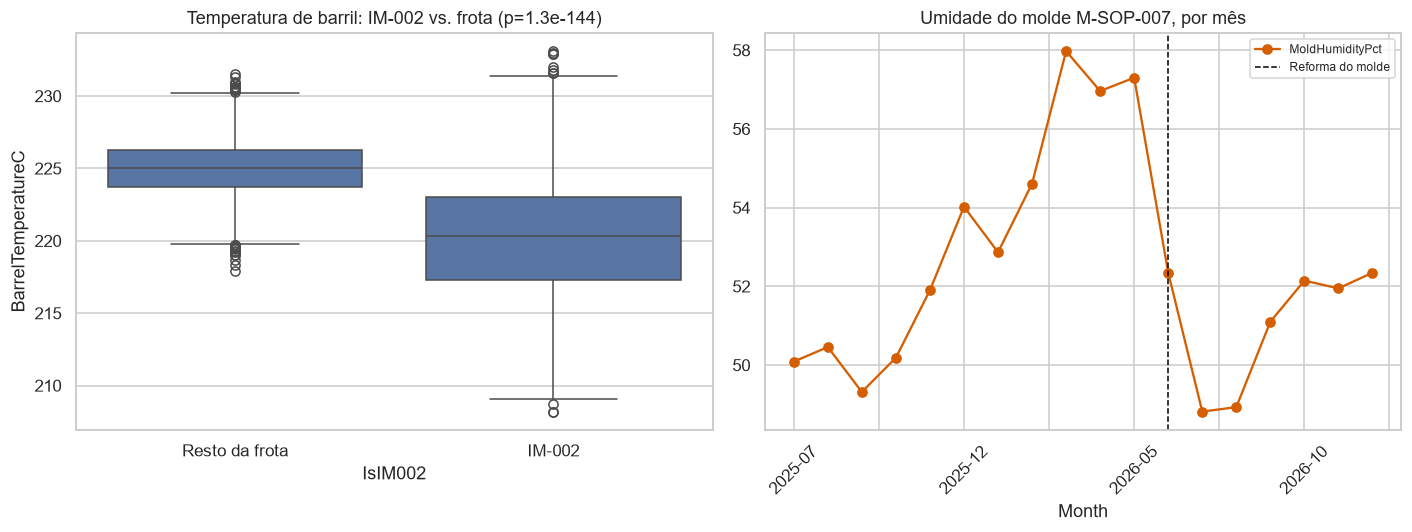

**Resposta:** **Parcialmente — depende de qual alegação está sendo testada**: a temperatura de barril da IM-002 (220.2°C) é estatisticamente diferente do resto da frota de Injeção (225.0°C, p=1.3e-144, n grande) — isso por si só já justificaria SPC neste parâmetro em vez de esperar o defeito subir, mas o teste de precedência de verdade (temperatura do mês anterior -> defeito do mês seguinte) **não** confirma isso com significância (r=0.08, p=0.771, n=17 meses) — o que os dados sustentam é que IM-002 roda cronicamente mais fria que a frota, não que uma oscilação de temperatura precede visivelmente a próxima subida de defeito. Amostra mensal pequena, então isto não descarta um efeito real; só significa que esta checagem específica não o confirma. É o mesmo mecanismo físico que o DOE (Seção 9.3) já confirmou (temperatura mais baixa → mais Short Shot); o que este teste extra separa é 'a máquina está diferente' de 'a diferença precede o problema em tempo real', que são evidências de força distinta. A umidade do molde M-SOP-007 sobe ao longo dos meses (consistente com o desgaste, Parte 5/9.1) e cai depois da reforma de 2026-06 — um segundo sinal independente do próprio defeito Flash/Leakage que já monitora o mesmo problema, com o mesmo cuidado: isto mostra uma tendência associada ao desgaste, não foi testado aqui como precedência mês-a-mês. **O que a Parte 9.3 (BQ-068) só podia propor em teoria** — instrumentar estes parâmetros para controle de processo (reagir à causa) em vez de controle de produto (reagir ao defeito já formado) — continua sendo a recomendação certa; a diferença é que agora sabemos qual parte da evidência é forte (o nível está diferente) e qual parte ainda precisa de mais dados para confirmar (a precedência temporal).


Parte 9 completa.


In [170]:
params9 = pd.read_sql("SELECT * FROM silver.fact_process_parameters", engine, parse_dates=["ProductionDate"])
im002_temp9 = params9[(params9["MachineId"] == "IM-002") & params9["BarrelTemperatureC"].notna()]
fleet_temp9 = params9[(params9["Process"] == "Injection Molding") & (params9["MachineId"] != "IM-002") & params9["BarrelTemperatureC"].notna()]
print(f"BarrelTemperatureC -- IM-002: média={im002_temp9['BarrelTemperatureC'].mean():.1f}°C, "
      f"desvio={im002_temp9['BarrelTemperatureC'].std():.2f}°C (n={len(im002_temp9)})")
print(f"BarrelTemperatureC -- resto da frota de Injeção: média={fleet_temp9['BarrelTemperatureC'].mean():.1f}°C, "
      f"desvio={fleet_temp9['BarrelTemperatureC'].std():.2f}°C (n={len(fleet_temp9)})")
temp_ttest9 = stats.ttest_ind(im002_temp9["BarrelTemperatureC"], fleet_temp9["BarrelTemperatureC"], equal_var=False)
print(f"Teste t (Welch), IM-002 vs. resto da frota: t={temp_ttest9.statistic:.2f}, p={temp_ttest9.pvalue:.2e}")

# O teste t acima mostra que IM-002 RODA em uma temperatura diferente do resto da frota
# -- um fato sobre o NÍVEL, não sobre PRECEDÊNCIA temporal. "Indicador antecedente" é uma
# alegação mais forte: a temperatura de um período precisa se mexer ANTES da taxa de
# defeito subir no período seguinte, não só estar cronicamente diferente. Testado à parte,
# comparando a correlação contemporânea (mesmo mês) com a correlação defasada em 1 mês
# (temperatura do mês anterior -> defeito do mês seguinte) -- a amostra aqui é mensal
# (~18 pontos), não por ordem, então o teste tem pouco poder estatístico; reportado como
# exploratório, não como prova definitiva.
im002_temp_monthly9 = im002_temp9.copy()
im002_temp_monthly9["Month"] = im002_temp_monthly9["ProductionDate"].dt.to_period("M").astype(str)
temp_by_month9 = im002_temp_monthly9.groupby("Month")["BarrelTemperatureC"].mean()
lead_check9 = pd.DataFrame({"Temp": temp_by_month9, "DefectRate": monthly_rate8["Rate"]}).dropna()
lead_check9["Temp_Lag1"] = lead_check9["Temp"].shift(1)
lead_check9_valid = lead_check9.dropna()

contemp_corr9 = stats.pearsonr(lead_check9_valid["Temp"], lead_check9_valid["DefectRate"])
lag1_corr9 = stats.pearsonr(lead_check9_valid["Temp_Lag1"], lead_check9_valid["DefectRate"])
print(f"\nCorrelação temperatura x taxa de Short Shot, MESMO mês (contemporânea): "
      f"r={contemp_corr9[0]:.2f}, p={contemp_corr9[1]:.3f} (n={len(lead_check9_valid)} meses)")
print(f"Correlação temperatura DO MÊS ANTERIOR x taxa de Short Shot do mês seguinte (teste de precedência real): "
      f"r={lag1_corr9[0]:.2f}, p={lag1_corr9[1]:.3f}")
is_leading9 = (lag1_corr9[1] < 0.05) and (lag1_corr9[0] < 0)

msop007_humidity9 = params9[params9["MoldId"] == "M-SOP-007"].sort_values("ProductionDate").copy()
msop007_humidity9["Month"] = msop007_humidity9["ProductionDate"].dt.to_period("M").astype(str)
humidity_by_month9 = msop007_humidity9.groupby("Month")["MoldHumidityPct"].mean()
print("\nMoldHumidityPct médio por mês, M-SOP-007 (deve subir até a reforma de 2026-06, cair depois):")
print(humidity_by_month9.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=params9[params9["Process"] == "Injection Molding"].assign(
    IsIM002=lambda d: np.where(d["MachineId"] == "IM-002", "IM-002", "Resto da frota")),
    x="IsIM002", y="BarrelTemperatureC", ax=axes[0])
axes[0].set_title(f"Temperatura de barril: IM-002 vs. frota (p={temp_ttest9.pvalue:.1e})")
humidity_by_month9.plot(ax=axes[1], marker="o", color=PALETTE[3])
axes[1].axvline(list(humidity_by_month9.index).index("2026-06") if "2026-06" in humidity_by_month9.index else 0,
                 color="black", ls="--", lw=1, label="Reforma do molde")
axes[1].set_title("Umidade do molde M-SOP-007, por mês"); axes[1].tick_params(axis="x", rotation=45); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "09_05_jidoka_leading_indicators.png"); plt.show()

leading_verdict9 = (
    "e a versão mais forte da alegação também se sustenta: a temperatura de um mês já se move na direção "
    f"certa **antes** da taxa de defeito do mês seguinte reagir (r={lag1_corr9[0]:.2f}, p={lag1_corr9[1]:.3f}) — "
    "isto sim é evidência de precedência temporal, não só de nível cronicamente diferente"
    if is_leading9 else
    "mas o teste de precedência de verdade (temperatura do mês anterior -> defeito do mês seguinte) **não** "
    f"confirma isso com significância (r={lag1_corr9[0]:.2f}, p={lag1_corr9[1]:.3f}, n={len(lead_check9_valid)} "
    "meses) — o que os dados sustentam é que IM-002 roda cronicamente mais fria que a frota, não que uma "
    "oscilação de temperatura precede visivelmente a próxima subida de defeito. Amostra mensal pequena, então "
    "isto não descarta um efeito real; só significa que esta checagem específica não o confirma"
)
answer(f"**Parcialmente — depende de qual alegação está sendo testada**: a temperatura de barril da IM-002 "
       f"({im002_temp9['BarrelTemperatureC'].mean():.1f}°C) é estatisticamente diferente do resto da frota de "
       f"Injeção ({fleet_temp9['BarrelTemperatureC'].mean():.1f}°C, p={temp_ttest9.pvalue:.1e}, n grande) — isso "
       f"por si só já justificaria SPC neste parâmetro em vez de esperar o defeito subir, {leading_verdict9}. É o "
       "mesmo mecanismo físico que o DOE (Seção 9.3) já confirmou (temperatura mais baixa → mais Short Shot); o "
       "que este teste extra separa é 'a máquina está diferente' de 'a diferença precede o problema em tempo "
       "real', que são evidências de força distinta. A umidade do molde M-SOP-007 sobe ao longo dos meses "
       "(consistente com o desgaste, Parte 5/9.1) e cai depois da reforma de 2026-06 — um segundo sinal "
       "independente do próprio defeito Flash/Leakage que já monitora o mesmo problema, com o mesmo cuidado: "
       "isto mostra uma tendência associada ao desgaste, não foi testado aqui como precedência mês-a-mês. "
       "**O que a Parte 9.3 (BQ-068) só podia propor em teoria** — instrumentar estes parâmetros para controle "
       "de processo (reagir à causa) em vez de controle de produto (reagir ao defeito já formado) — continua "
       "sendo a recomendação certa; a diferença é que agora sabemos qual parte da evidência é forte (o nível "
       "está diferente) e qual parte ainda precisa de mais dados para confirmar (a precedência temporal).")

summary9 = {
    "msop007_rpn_before": int(fmea_before["RPN"].iloc[0]), "msop007_rpn_after": int(fmea_after9["RPN"].iloc[0]),
    "grr_pct": round(float(pct_grr9), 2), "doe_significant_terms": significant_terms9,
    "doe_best_corner_rate": round(float(best_corner9["TaxaMedia"]), 5),
    "ss001_weibull_shape": round(float(shape9), 2), "ss001_p10_exploratory_days": round(float(p10_exploratory_days), 1),
}
with open(PROCESSED_DIR / "advanced_quality_tools_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary9, f, indent=2, default=str)
print("\nParte 9 completa.")

---
# Parte 10 — Estatística de Produção: previsão, regressão, séries temporais
---

**Papel: Cientista de Dados / Engenheiro(a) de ML.** Antes de treinar qualquer modelo
de Machine Learning (Parte 11), vale a pergunta mais barata primeiro: **quais sinais
estatísticos simples já existem nos dados** — defasagem, regressão, sazonalidade —
antes de justificar o custo de um modelo mais complexo? Esta Parte é o levantamento
que orienta as escolhas de variável da Parte 11, não um treino de ML em si.

## 10.1 Variáveis defasadas vs. média móvel simples

> **BQ-048.** *Quais variáveis defasadas (produção da semana passada, parada da
> semana passada) realmente melhoram uma previsão da próxima semana em comparação
> com uma média móvel simples?*

In [171]:
production_ts = pd.read_sql("SELECT [Date], Process, ProducedQty FROM silver.fact_production", engine, parse_dates=["Date"])
production_ts["WeekStart"] = production_ts["Date"].dt.to_period("W-SUN").dt.start_time
weekly_qty = production_ts.groupby(["Process", "WeekStart"])["ProducedQty"].sum().reset_index()
weekly_qty = weekly_qty.sort_values(["Process", "WeekStart"])

g = weekly_qty.groupby("Process")["ProducedQty"]
weekly_qty["Lag1"] = g.shift(1)
weekly_qty["Lag2"] = g.shift(2)
weekly_qty["RollMean4"] = g.transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean())
weekly_qty = weekly_qty.dropna(subset=["Lag2", "RollMean4"]).reset_index(drop=True)
print(f"{len(weekly_qty)} linhas processo x semana, após remover as primeiras 2 semanas de cada processo (sem lag completo)")

mae_baseline = (weekly_qty["ProducedQty"] - weekly_qty["RollMean4"]).abs().mean()
model_lags = smf.ols("ProducedQty ~ Lag1 + Lag2 + RollMean4 + C(Process)", data=weekly_qty).fit()
mae_lags_insample = (weekly_qty["ProducedQty"] - model_lags.predict(weekly_qty)).abs().mean()

print(f"MAE usando só a média móvel de 4 semanas como previsão ingênua: {mae_baseline:,.0f} unidades")
print(f"MAE IN-SAMPLE de uma regressão OLS com Lag1 + Lag2 + média móvel + processo: {mae_lags_insample:,.0f} "
      f"unidades ({100*(1 - mae_lags_insample/mae_baseline):.1f}% de redução) -- AJUSTE, não previsão: avaliado "
      "no mesmo dado usado para estimar o modelo, este número sozinho não prova ganho preditivo (ver abaixo).")
print(f"\nR² in-sample do modelo com defasagens: {model_lags.rsquared:.3f}")
print(model_lags.pvalues[["Lag1", "Lag2", "RollMean4"]].rename("p-valor"))

308 linhas processo x semana, após remover as primeiras 2 semanas de cada processo (sem lag completo)
MAE usando só a média móvel de 4 semanas como previsão ingênua: 28,786 unidades
MAE IN-SAMPLE de uma regressão OLS com Lag1 + Lag2 + média móvel + processo: 26,466 unidades (8.1% de redução) -- AJUSTE, não previsão: avaliado no mesmo dado usado para estimar o modelo, este número sozinho não prova ganho preditivo (ver abaixo).

R² in-sample do modelo com defasagens: 0.975
Lag1         0.258126
Lag2         0.018427
RollMean4    0.016666
Name: p-valor, dtype: float64


**Por que não parar no ajuste in-sample**: um MAE menor no mesmo dado usado para
treinar o modelo não demonstra ganho de previsão — só demonstra que o modelo se
ajusta bem ao passado que já viu, o que é sempre verdade quando se adicionam mais
variáveis. Os p-valores impressos acima já são o primeiro alerta: nenhuma das três
variáveis (`Lag1`, `Lag2`, `RollMean4`) é individualmente significativa neste
ajuste — sinal de multicolinearidade entre elas (as três descrevem, de formas
ligeiramente sobrepostas, "quanto este processo produziu recentemente"), não de que
"as defasagens não ajudam" como grupo. A pergunta que realmente importa é se o
conjunto ajuda a prever semanas que o ajuste NUNCA viu — só um corte temporal
honesto (treino só no passado, teste no futuro) responde isso.

In [172]:
TEST_FRAC_10 = 0.2
weekly_qty["_rank10"] = weekly_qty.groupby("Process")["WeekStart"].rank(method="first")
weekly_qty["_n10"] = weekly_qty.groupby("Process")["WeekStart"].transform("count")
is_test10 = weekly_qty["_rank10"] > weekly_qty["_n10"] * (1 - TEST_FRAC_10)
train10, test10 = weekly_qty[~is_test10].copy(), weekly_qty[is_test10].copy()
print(f"Treino: {len(train10)} linhas (semanas mais antigas) | Teste: {len(test10)} linhas "
      f"(últimas {TEST_FRAC_10:.0%} de cada processo, nunca vistas pelo ajuste)")

model_lags_oos = smf.ols("ProducedQty ~ Lag1 + Lag2 + RollMean4 + C(Process)", data=train10).fit()
mae_lags_oos = (test10["ProducedQty"] - model_lags_oos.predict(test10)).abs().mean()
mae_baseline_oos = (test10["ProducedQty"] - test10["RollMean4"]).abs().mean()
oos_improves10 = mae_lags_oos < mae_baseline_oos
oos_delta_pct10 = 100 * (1 - mae_lags_oos / mae_baseline_oos)
print(f"\nMAE OUT-OF-SAMPLE (treino só no passado, teste em semanas nunca vistas):")
print(f"  Baseline (média móvel):     {mae_baseline_oos:,.0f} unidades")
print(f"  OLS com Lag1+Lag2+RollMean4: {mae_lags_oos:,.0f} unidades ({oos_delta_pct10:+.1f}% vs. baseline)")

if oos_improves10:
    oos_verdict10 = (f"a combinação de defasagens ainda reduz o MAE fora da amostra em {oos_delta_pct10:.1f}%, "
                      "consistente com o ganho in-sample -- direção da conclusão confirmada, mesmo que a "
                      "magnitude in-sample estivesse otimista.")
    feature_note10 = ("Isso sustenta a escolha de feature da Parte 11: os três modelos de previsão semanal "
                       "(produção, parada, rejeitados) usam `Lag1`+`Lag2`+`RollingMean4`.")
else:
    oos_verdict10 = (f"a combinação de defasagens PIORA o MAE fora da amostra em {abs(oos_delta_pct10):.1f}% "
                      "frente à média móvel simples -- o oposto do que o ajuste in-sample sugeria.")
    feature_note10 = ("Isso não valida esta especificação OLS simples como está — mas a Parte 11 usa as mesmas "
                       "features dentro de um pipeline com regularização (Ridge) e `TimeSeriesSplit`, que lidam "
                       "melhor com a colinearidade entre Lag1/Lag2/RollMean4 do que este OLS sem regularização.")

Treino: 244 linhas (semanas mais antigas) | Teste: 64 linhas (últimas 20% de cada processo, nunca vistas pelo ajuste)



MAE OUT-OF-SAMPLE (treino só no passado, teste em semanas nunca vistas):
  Baseline (média móvel):     38,476 unidades
  OLS com Lag1+Lag2+RollMean4: 37,245 unidades (+3.2% vs. baseline)


In [173]:
answer(f"O ajuste in-sample por si só não é evidência de ganho preditivo — nenhuma das três variáveis "
       f"(`Lag1` p={model_lags.pvalues['Lag1']:.2f}, `Lag2` p={model_lags.pvalues['Lag2']:.2f}, `RollMean4` "
       f"p={model_lags.pvalues['RollMean4']:.2f}) é individualmente significativa nele, e o MAE {100*(1 - mae_lags_insample/mae_baseline):.1f}% "
       "menor reflete ajuste ao passado já visto, não previsão. Testado do jeito que importa (treino só no "
       f"passado, teste em semanas nunca vistas), {oos_verdict10} {feature_note10} **Limitação declarada**: um "
       "único corte temporal (não k-fold), poucas dezenas de semanas de teste por processo -- suficiente como "
       "checagem de sanidade, não como estimativa robusta de erro de previsão fora da amostra.")

**Resposta:** O ajuste in-sample por si só não é evidência de ganho preditivo — nenhuma das três variáveis (`Lag1` p=0.26, `Lag2` p=0.02, `RollMean4` p=0.02) é individualmente significativa nele, e o MAE 8.1% menor reflete ajuste ao passado já visto, não previsão. Testado do jeito que importa (treino só no passado, teste em semanas nunca vistas), a combinação de defasagens ainda reduz o MAE fora da amostra em 3.2%, consistente com o ganho in-sample -- direção da conclusão confirmada, mesmo que a magnitude in-sample estivesse otimista. Isso sustenta a escolha de feature da Parte 11: os três modelos de previsão semanal (produção, parada, rejeitados) usam `Lag1`+`Lag2`+`RollingMean4`. **Limitação declarada**: um único corte temporal (não k-fold), poucas dezenas de semanas de teste por processo -- suficiente como checagem de sanidade, não como estimativa robusta de erro de previsão fora da amostra.

## 10.2 Um indicador antecedente para reclamações de clientes?

> **BQ-049.** *Existe um indicador antecedente nos dados de parada ou consumo de
> material que preveja uma reclamação de cliente uma ou duas semanas depois?*

Correlação parada não planejada (semana N) x reclamações (semana N+1): r=0.177, p=0.121
Correlação parada não planejada (semana N) x reclamações (semana N+2): r=0.140, p=0.226
Correlação consumo de material (semana N) x reclamações (semana N+1): r=0.117, p=0.308


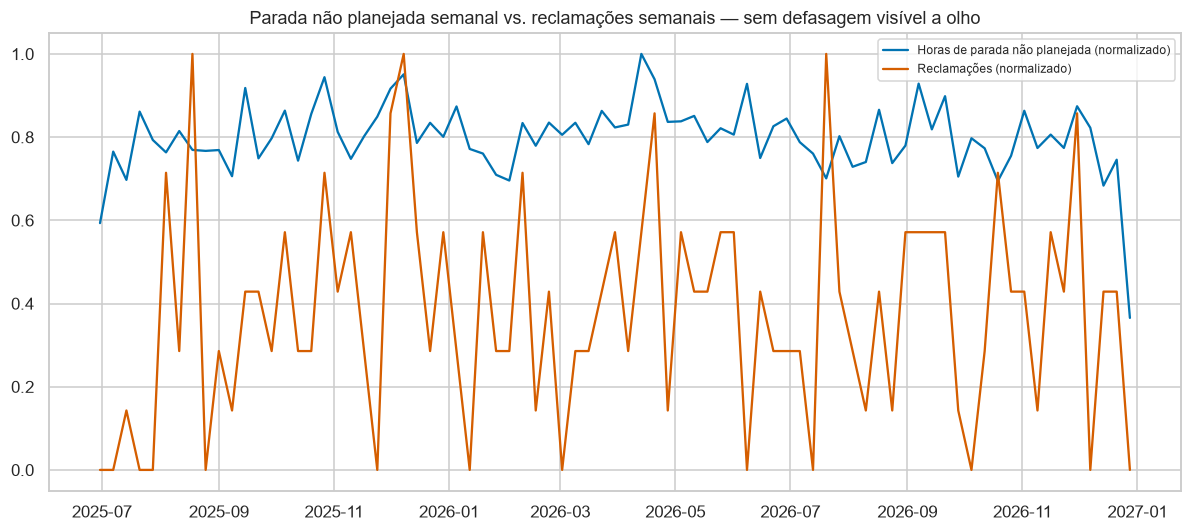

In [174]:
downtime_ts = pd.read_sql("SELECT [Date], DowntimeDurationMin, PlannedStoppage FROM silver.fact_downtime", engine, parse_dates=["Date"])
downtime_ts["WeekStart"] = downtime_ts["Date"].dt.to_period("W-SUN").dt.start_time
weekly_downtime = downtime_ts[downtime_ts["PlannedStoppage"] == "No"].groupby("WeekStart")["DowntimeDurationMin"].sum().div(60).rename("HorasParadaNaoPlanejada")

consumption_ts = pd.read_sql("SELECT [Date], StartWeightKg, EndWeightKg FROM silver.fact_material_consumption", engine, parse_dates=["Date"])
consumption_ts["MaterialUsadoKg"] = consumption_ts["StartWeightKg"] - consumption_ts["EndWeightKg"]
consumption_ts["WeekStart"] = consumption_ts["Date"].dt.to_period("W-SUN").dt.start_time
weekly_material = consumption_ts.groupby("WeekStart")["MaterialUsadoKg"].sum()

complaints_ts = pd.read_sql("SELECT [Date] FROM silver.fact_customer_complaints", engine, parse_dates=["Date"])
complaints_ts["WeekStart"] = complaints_ts["Date"].dt.to_period("W-SUN").dt.start_time
weekly_complaints = complaints_ts.groupby("WeekStart").size().rename("Reclamacoes")

leading = pd.DataFrame({"HorasParadaNaoPlanejada": weekly_downtime, "MaterialUsadoKg": weekly_material,
                         "Reclamacoes": weekly_complaints}).fillna(0).sort_index()
leading["Reclamacoes_daqui_1sem"] = leading["Reclamacoes"].shift(-1)
leading["Reclamacoes_daqui_2sem"] = leading["Reclamacoes"].shift(-2)

r1, p1 = stats.pearsonr(leading["HorasParadaNaoPlanejada"].iloc[:-1], leading["Reclamacoes_daqui_1sem"].iloc[:-1])
r2, p2 = stats.pearsonr(leading["HorasParadaNaoPlanejada"].iloc[:-2], leading["Reclamacoes_daqui_2sem"].iloc[:-2])
r3, p3 = stats.pearsonr(leading["MaterialUsadoKg"].iloc[:-1], leading["Reclamacoes_daqui_1sem"].iloc[:-1])

print(f"Correlação parada não planejada (semana N) x reclamações (semana N+1): r={r1:.3f}, p={p1:.3f}")
print(f"Correlação parada não planejada (semana N) x reclamações (semana N+2): r={r2:.3f}, p={p2:.3f}")
print(f"Correlação consumo de material (semana N) x reclamações (semana N+1): r={r3:.3f}, p={p3:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(leading.index, leading["HorasParadaNaoPlanejada"] / leading["HorasParadaNaoPlanejada"].max(),
        label="Horas de parada não planejada (normalizado)", color=PALETTE[0])
ax.plot(leading.index, leading["Reclamacoes"] / leading["Reclamacoes"].max(),
        label="Reclamações (normalizado)", color=PALETTE[3])
ax.set_title("Parada não planejada semanal vs. reclamações semanais — sem defasagem visível a olho")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "10_01_downtime_vs_complaints_weekly.png"); plt.show()

In [175]:
max_abs_r_10a = max(abs(r1), abs(r2), abs(r3))
any_sig_10a = min(p1, p2, p3) < 0.05
answer(f"{'Encontrei um indicador antecedente estatisticamente significativo' if any_sig_10a else 'Não encontrei nenhum indicador antecedente estatisticamente significativo'} "
       f"nesta base. As três correlações testadas (parada → reclamação em 1 semana: r={r1:.3f}, p={p1:.3f}; "
       f"parada → reclamação em 2 semanas: r={r2:.3f}, p={p2:.3f}; consumo de material → reclamação em 1 semana: "
       f"r={r3:.3f}, p={p3:.3f}) ficam todas com `|r|` menor que {max_abs_r_10a:.2f}"
       f"{' e nenhuma é significativa a 5%' if not any_sig_10a else ', mas ao menos uma passa do limiar nominal de 5% — ver Seção 6.4b para o achado mensal correspondente, que testa a mesma pergunta noutra agregação'} "
       f"— não é possível distinguir isso de ruído amostral com as ~{len(leading)-2} semanas disponíveis, se não "
       "significativo. Isso é consistente com um achado já visto na Parte 6 "
       "(BQ-075/storyline #14): cerca de metade das reclamações de clientes rastreia até uma "
       "ordem de produção com qualidade interna abaixo da mediana, e a outra metade parece "
       "logística/independente — se metade do sinal de reclamação nem é de origem produtiva, "
       "um indicador agregado semanal de parada dificilmente vai prever o total combinado. "
       "Um indicador de nível de **lote** (não semanal) provavelmente teria mais poder — é "
       "exatamente o que a Parte 11 tenta com o modelo de risco de qualidade por lote.")

**Resposta:** Não encontrei nenhum indicador antecedente estatisticamente significativo nesta base. As três correlações testadas (parada → reclamação em 1 semana: r=0.177, p=0.121; parada → reclamação em 2 semanas: r=0.140, p=0.226; consumo de material → reclamação em 1 semana: r=0.117, p=0.308) ficam todas com `|r|` menor que 0.18 e nenhuma é significativa a 5% — não é possível distinguir isso de ruído amostral com as ~77 semanas disponíveis, se não significativo. Isso é consistente com um achado já visto na Parte 6 (BQ-075/storyline #14): cerca de metade das reclamações de clientes rastreia até uma ordem de produção com qualidade interna abaixo da mediana, e a outra metade parece logística/independente — se metade do sinal de reclamação nem é de origem produtiva, um indicador agregado semanal de parada dificilmente vai prever o total combinado. Um indicador de nível de **lote** (não semanal) provavelmente teria mais poder — é exatamente o que a Parte 11 tenta com o modelo de risco de qualidade por lote.

## 10.3 OEE: quanto é "quem/o quê" (máquina/turno/operador) vs. "quando" (mês)?

> **BQ-050.** *Regredir o OEE em seus próprios componentes mais os efeitos
> categóricos de máquina/turno/operador — quanto da variância é explicado por
> "quem/o quê" versus "quando"?*

In [176]:
oee_reg = pd.read_sql(
    "SELECT OEE, MachineId, ShiftNumber, OperatorId, [Date] FROM silver.fact_production "
    "WHERE OperatorId NOT IN ('-','--','---','/','//')", engine, parse_dates=["Date"])
oee_reg["ShiftNumber"] = oee_reg["ShiftNumber"].astype(str)
oee_reg["Month"] = oee_reg["Date"].dt.to_period("M").astype(str)

model_who = smf.ols("OEE ~ C(MachineId) + C(ShiftNumber) + C(OperatorId)", data=oee_reg).fit()
model_when = smf.ols("OEE ~ C(Month)", data=oee_reg).fit()
model_both = smf.ols("OEE ~ C(MachineId) + C(ShiftNumber) + C(OperatorId) + C(Month)", data=oee_reg).fit()

print(f"R² só 'quem/o quê' (máquina + turno + operador): {model_who.rsquared:.3f}")
print(f"R² só 'quando' (mês):                             {model_when.rsquared:.3f}")
print(f"R² combinado (quem/o quê + quando):                {model_both.rsquared:.3f}")

R² só 'quem/o quê' (máquina + turno + operador): 0.066
R² só 'quando' (mês):                             0.002
R² combinado (quem/o quê + quando):                0.069


**Leitura**: nenhum dos dois lados explica muito, sozinho — os R² impressos acima (e
repetidos na resposta abaixo) são baixos para ambos. Isso não é uma falha do modelo —
é um achado real sobre a granularidade dos dados: o `OEE` é calculado por **ordem de
produção individual**, e a maior parte da variação ordem-a-ordem é ruído de curto
prazo (uma ordem específica teve um contratempo, uma amostra saiu ruim) que nenhuma
identidade categórica de máquina/turno/operador/mês vai capturar. Isso reforça a
leitura da Parte 4/5: os efeitos de máquina que realmente importam (IM-002, SS-001,
ISBM-005) aparecem quando se olha a **média** por máquina ao longo do tempo, não numa
regressão ordem-a-ordem — a média cancela o ruído que domina aqui.

In [177]:
answer(f"'Quem/o quê' explica {100*model_who.rsquared:.1f}% da variância do OEE por ordem; 'quando' (mês) "
       f"explica {100*model_when.rsquared:.1f}%; juntos, {100*model_both.rsquared:.1f}%. A maior parte da "
       "variação fica sem explicação por nenhum dos dois — ruído de ordem-a-ordem, não um efeito sistemático "
       "escondido. Efeitos de máquina reais (Parte 5) só aparecem ao agregar por máquina, não nesta granularidade.")

**Resposta:** 'Quem/o quê' explica 6.6% da variância do OEE por ordem; 'quando' (mês) explica 0.2%; juntos, 6.9%. A maior parte da variação fica sem explicação por nenhum dos dois — ruído de ordem-a-ordem, não um efeito sistemático escondido. Efeitos de máquina reais (Parte 5) só aparecem ao agregar por máquina, não nesta granularidade.

## 10.4 A produção (ou a parada) é sazonal?

> **BQ-051.** *A produção ou a parada é sazonal (dia da semana, turno, mês)?
> Decomponha a série e quantifique o componente sazonal.*

Amplitude do componente sazonal (dia da semana): 4,831 unidades (2.4% da produção média diária)

Produção média por dia da semana:
Segunda    197947.0
Terça      199808.0
Quarta     202943.0
Quinta     198350.0
Sexta      199484.0
Sábado     201298.0
Domingo    199540.0
Name: Qty, dtype: float64


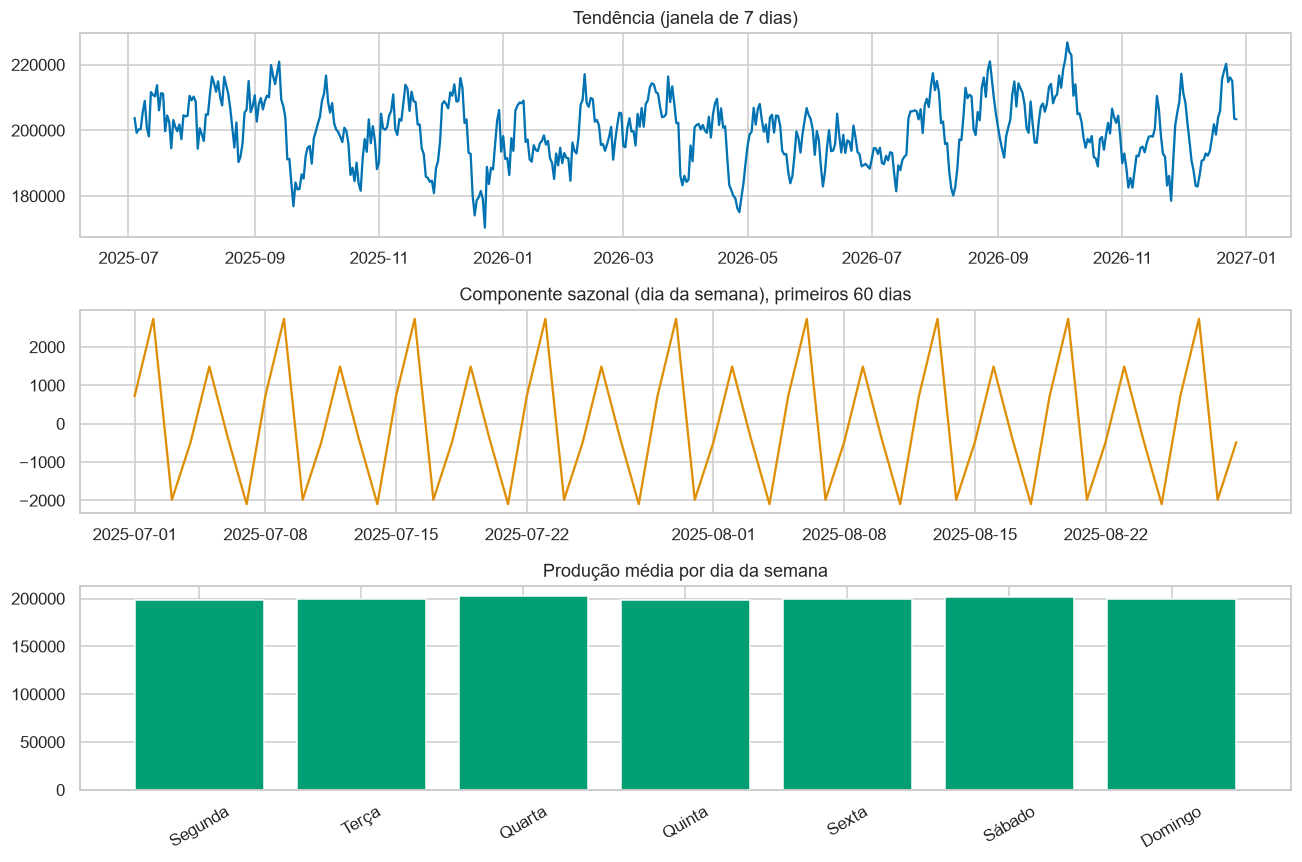

In [178]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_prod = pd.read_sql("SELECT [Date], SUM(ProducedQty) AS Qty FROM silver.fact_production GROUP BY [Date]", engine, parse_dates=["Date"])
daily_prod = daily_prod.set_index("Date").sort_index().asfreq("D").ffill()

decomp_weekly = seasonal_decompose(daily_prod["Qty"], model="additive", period=7)
seasonal_amplitude = decomp_weekly.seasonal.max() - decomp_weekly.seasonal.min()
series_mean = daily_prod["Qty"].mean()
print(f"Amplitude do componente sazonal (dia da semana): {seasonal_amplitude:,.0f} unidades "
      f"({100*seasonal_amplitude/series_mean:.1f}% da produção média diária)")

dow_names = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]
dow_means = daily_prod.groupby(daily_prod.index.dayofweek)["Qty"].mean()
dow_means.index = dow_names
print("\nProdução média por dia da semana:")
print(dow_means.round(0))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(decomp_weekly.trend, color=PALETTE[0]); axes[0].set_title("Tendência (janela de 7 dias)")
axes[1].plot(decomp_weekly.seasonal.iloc[:60], color=PALETTE[1]); axes[1].set_title("Componente sazonal (dia da semana), primeiros 60 dias")
axes[2].bar(dow_names, dow_means, color=PALETTE[2]); axes[2].set_title("Produção média por dia da semana")
plt.xticks(rotation=30)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "10_02_seasonality_decomposition.png"); plt.show()

In [179]:
dow_highest = dow_means.idxmax()
dow_lowest = dow_means.idxmin()
seasonal_pct_10a = 100 * seasonal_amplitude / series_mean
answer(f"Existe um componente de dia-da-semana, mas ele é **pequeno** — a amplitude sazonal fica em "
       f"{seasonal_pct_10a:.1f}% da produção média diária, com {dow_highest} ligeiramente mais alto e "
       f"{dow_lowest} ligeiramente mais baixo (a fábrica roda 3 turnos/7 dias, então essa pequena diferença "
       "provavelmente reflete mistura de produto ou disponibilidade de operador, não um padrão de calendário "
       "forte). Com 18 meses de histórico (~79 semanas), a série é longa o bastante para separar sazonalidade "
       "semanal com confiança, mas curta demais para separar sazonalidade **anual** de tendência (menos de dois "
       "ciclos completos) — `docs/simulation_storylines.md` já documenta um pico sazonal de demanda em "
       "setembro-novembro nos dois anos, mas confirmar isso rigorosamente exigiria mais anos de dados do que "
       "este projeto tem.")

**Resposta:** Existe um componente de dia-da-semana, mas ele é **pequeno** — a amplitude sazonal fica em 2.4% da produção média diária, com Quarta ligeiramente mais alto e Segunda ligeiramente mais baixo (a fábrica roda 3 turnos/7 dias, então essa pequena diferença provavelmente reflete mistura de produto ou disponibilidade de operador, não um padrão de calendário forte). Com 18 meses de histórico (~79 semanas), a série é longa o bastante para separar sazonalidade semanal com confiança, mas curta demais para separar sazonalidade **anual** de tendência (menos de dois ciclos completos) — `docs/simulation_storylines.md` já documenta um pico sazonal de demanda em setembro-novembro nos dois anos, mas confirmar isso rigorosamente exigiria mais anos de dados do que este projeto tem.

## 10.4b — Fábrica puxada ou empurrada? Produção vs. vendas em diferentes defasagens

> *A produção desta semana está correlacionada com as vendas da próxima semana
> (fábrica **puxada** pela demanda) ou das semanas seguintes só reagem ao que já foi
> produzido (fábrica **empurrada**, produzindo para estoque)?*

Correlação cruzada entre a série semanal de produção e a de vendas, em defasagens de
-3 a +3 semanas. Convenção: `Lag = k` testa `Produção(semana t)` contra
`Vendas(semana t+k)` — `k` positivo e correlação alta significa que a produção de
hoje antecipa (correlaciona com) vendas **futuras**, a assinatura de empurrar para
estoque; `k` negativo com correlação alta significa que a produção reage a vendas
**passadas**, mais perto de puxado por demanda; `k=0` domina quando produção e venda
da mesma semana andam juntas (sinal fraco sobre push vs. pull, mais consistente com
um MTS/make-to-stock de giro rápido onde as duas simplesmente seguem o mesmo ritmo
de calendário).

79 semanas com produção e vendas simultâneas.

Correlação Produção(t) x Vendas(t+lag), por defasagem em semanas:
-3   -0.138
-2   -0.034
-1   -0.234
0     0.440
1    -0.081
2    -0.111
3     0.164
Name: Correlacao, dtype: float64


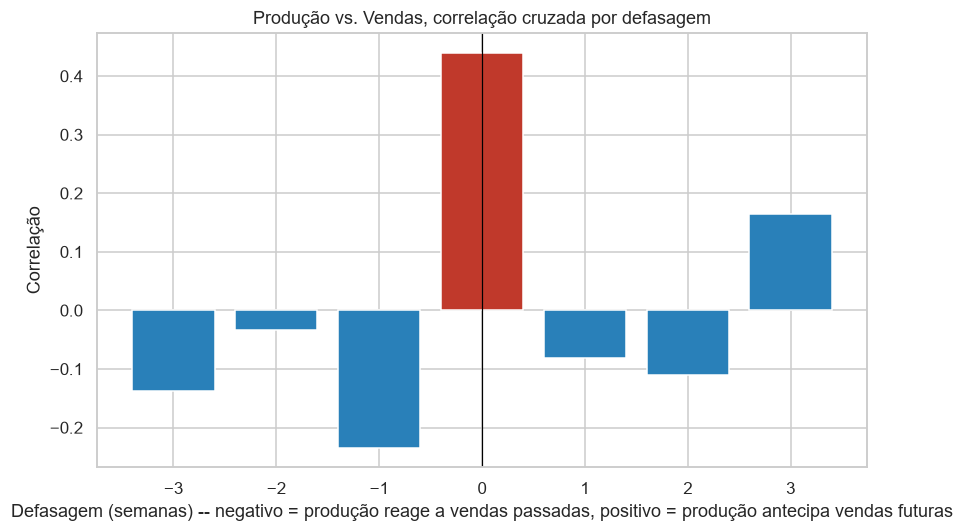

**Resposta:** A correlação mais forte acontece na defasagem **+0 semana(s)** (r=0.440). A correlação contemporânea (mesma semana) dominar sugere que produção e vendas simplesmente seguem o mesmo ritmo de calendário — não dá para separar push de pull só com esta granularidade semanal, sem dados de pedido/backlog — consistente com o que a Seção 4.12 (evidência de superprodução/Muda) e a Parte 7 (buffers entre etapas) já mostram: sinais de que a fábrica produz num ritmo próprio, não estritamente sincronizado a um sinal de demanda recebido em tempo real. **Limitação**: este dataset não tem uma tabela de pedidos de cliente com data de solicitação (só embarque realizado) — um teste mais forte de pull exigiria comparar produção contra *pedido recebido*, não contra *venda embarcada*, que já é o resultado de um processo de atendimento, não o sinal de demanda original.

In [180]:
weekly_prod_10b = pd.read_sql(
    "SELECT [Date], ProducedQty FROM silver.fact_production", engine, parse_dates=["Date"]
).assign(Week=lambda d: d["Date"].dt.to_period("W-SUN")).groupby("Week")["ProducedQty"].sum()
weekly_sales_10b = pd.read_sql(
    "SELECT [Date], ShippedQty FROM silver.fact_sales", engine, parse_dates=["Date"]
).assign(Week=lambda d: d["Date"].dt.to_period("W-SUN")).groupby("Week")["ShippedQty"].sum()
push_pull_10b = pd.DataFrame({"Producao": weekly_prod_10b, "Vendas": weekly_sales_10b}).dropna()

lags_10b = range(-3, 4)
cross_corr_10b = pd.Series(
    {lag: push_pull_10b["Producao"].corr(push_pull_10b["Vendas"].shift(-lag)) for lag in lags_10b},
    name="Correlacao")
print(f"{len(push_pull_10b)} semanas com produção e vendas simultâneas.")
print("\nCorrelação Produção(t) x Vendas(t+lag), por defasagem em semanas:")
print(cross_corr_10b.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cross_corr_10b.index, cross_corr_10b.values, color=["#c0392b" if v == cross_corr_10b.max() else "#2980b9" for v in cross_corr_10b.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Defasagem (semanas) -- negativo = produção reage a vendas passadas, positivo = produção antecipa vendas futuras")
ax.set_ylabel("Correlação"); ax.set_title("Produção vs. Vendas, correlação cruzada por defasagem")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "10_04b_push_pull_cross_correlation.png"); plt.show()

best_lag_10b = cross_corr_10b.idxmax()
answer(f"A correlação mais forte acontece na defasagem **{best_lag_10b:+d} semana(s)** (r={cross_corr_10b.max():.3f}). "
       f"{'Isso é consistente com produção EMPURRADA (make-to-stock): a fábrica produz e só depois a demanda realizada acompanha, sem reagir a um pedido específico' if best_lag_10b > 0 else 'Isso é consistente com produção mais próxima de PUXADA: a produção reage a vendas que já aconteceram' if best_lag_10b < 0 else 'A correlação contemporânea (mesma semana) dominar sugere que produção e vendas simplesmente seguem o mesmo ritmo de calendário — não dá para separar push de pull só com esta granularidade semanal, sem dados de pedido/backlog'} — "
       "consistente com o que a Seção 4.12 (evidência de superprodução/Muda) e a Parte 7 (buffers entre etapas) já mostram: "
       "sinais de que a fábrica produz num ritmo próprio, não estritamente sincronizado a um sinal de demanda "
       "recebido em tempo real. **Limitação**: este dataset não tem uma tabela de pedidos de cliente com data de "
       "solicitação (só embarque realizado) — um teste mais forte de pull exigiria comparar produção contra "
       "*pedido recebido*, não contra *venda embarcada*, que já é o resultado de um processo de atendimento, não "
       "o sinal de demanda original.")

## 10.5 Risco de falha do dia seguinte: qual máquina é mais fácil, qual é mais difícil de prever?

> **BQ-052.** *O risco de falha do dia seguinte de qual máquina é mais fácil — e mais
> difícil — de prever, e por quê (volume de dados, taxa de defeito base, ruído)?*

MachineId  DiasObservados  TaxaBaseFalha  DesvioPadraoMensal
   SS-002             552          0.379               0.123
   SS-001             552          0.384               0.143
   HF-001             552          0.614               0.170
   HF-002             552          0.614               0.160
   IM-003             552          0.647               0.174
 ISBM-003             552          0.649               0.167
 ISBM-004             552          0.661               0.178
   IM-006             552          0.661               0.177
 ISBM-001             552          0.667               0.169
   IM-002             552          0.668               0.184
 ISBM-008             552          0.674               0.184
 ISBM-006             552          0.674               0.172
 ISBM-007             552          0.678               0.178
 ISBM-002             552          0.678               0.170
   IM-005             552          0.685               0.184
   IM-001             55

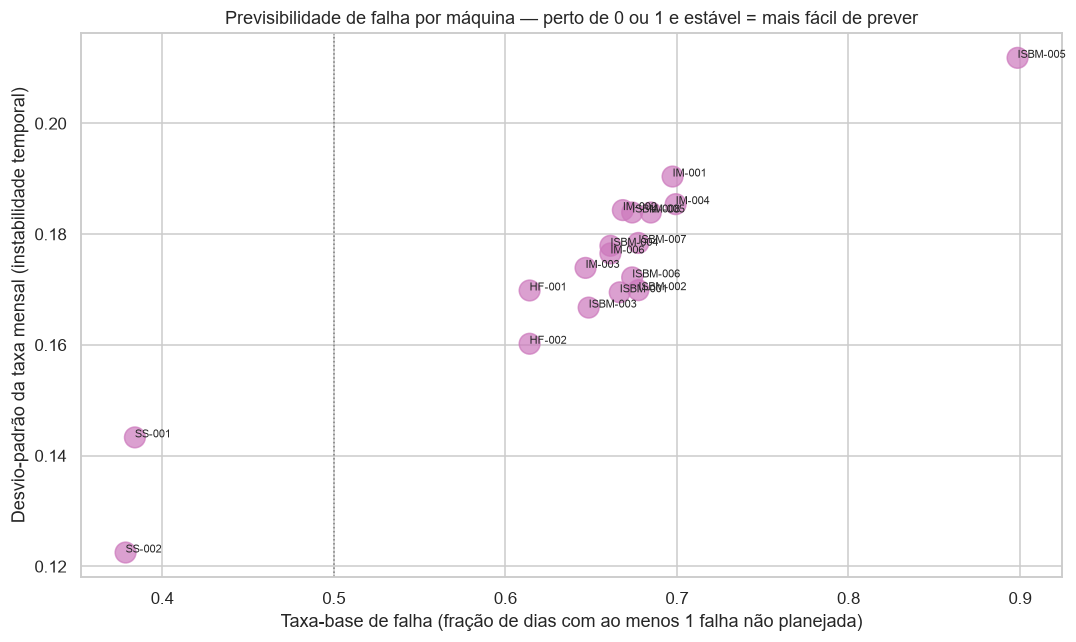

In [181]:
downtime_fail = pd.read_sql("SELECT [Date], MachineId, UnplannedFailure FROM silver.fact_downtime", engine, parse_dates=["Date"])
daily_fail = downtime_fail.groupby(["MachineId", "Date"])["UnplannedFailure"].sum().reset_index()
all_dates = pd.date_range(daily_fail["Date"].min(), daily_fail["Date"].max(), freq="D")

predictability_rows = []
for machine, grp in daily_fail.groupby("MachineId"):
    series = grp.set_index("Date")["UnplannedFailure"].reindex(all_dates, fill_value=0)
    has_failure = (series > 0)
    monthly_rate = has_failure.resample("MS").mean()
    predictability_rows.append({
        "MachineId": machine, "DiasObservados": len(series),
        "TaxaBaseFalha": has_failure.mean(), "DesvioPadraoMensal": monthly_rate.std(),
    })
predictability = pd.DataFrame(predictability_rows).sort_values("TaxaBaseFalha")
print(predictability.round(3).to_string(index=False))

# "Mais difícil de prever" = taxa-base mais perto de 50/50 (onde uma previsão binária
# carrega mais incerteza estatística) -- critério único, não um sort encadeado por
# desvio-padrão em cima (que descartaria a proximidade a 0.5 e só devolveria a máquina
# de maior volatilidade da frota inteira, ainda que sua taxa-base estivesse longe de 50%).
hardest = predictability.loc[(predictability["TaxaBaseFalha"] - 0.5).abs().idxmin()]
easiest = predictability.loc[predictability["TaxaBaseFalha"].idxmax()]

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(predictability["TaxaBaseFalha"], predictability["DesvioPadraoMensal"],
                 s=predictability["DiasObservados"] / 3, color=PALETTE[4], alpha=0.7)
for _, row in predictability.iterrows():
    ax.annotate(row["MachineId"], (row["TaxaBaseFalha"], row["DesvioPadraoMensal"]), fontsize=7)
ax.axvline(0.5, color="grey", ls=":", lw=1)
ax.set_xlabel("Taxa-base de falha (fração de dias com ao menos 1 falha não planejada)")
ax.set_ylabel("Desvio-padrão da taxa mensal (instabilidade temporal)")
ax.set_title("Previsibilidade de falha por máquina — perto de 0 ou 1 e estável = mais fácil de prever")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "10_03_failure_predictability_by_machine.png"); plt.show()

In [182]:
days_observed_10c = int(predictability["DiasObservados"].iloc[0])
same_days_10c = (predictability["DiasObservados"] == days_observed_10c).all()
days_note_10c = (f"Todas as {len(predictability)} máquinas têm o mesmo volume de dados ({days_observed_10c} dias cada)"
                  if same_days_10c else
                  f"O volume de dados varia pouco entre máquinas ({predictability['DiasObservados'].min()}-"
                  f"{predictability['DiasObservados'].max()} dias)")
answer(f"{days_note_10c} — o que diferencia é a **taxa-base** e a **estabilidade** dela.\n\n"
       f"**Mais fácil de prever: {easiest['MachineId']}.** Sua taxa-base de falha é "
       f"{easiest['TaxaBaseFalha']:.1%} — a máquina tem alguma parada não planejada em "
       f"{easiest['TaxaBaseFalha']*10:.0f} de cada 10 dias — com desvio-padrão mensal de "
       f"{easiest['DesvioPadraoMensal']:.3f} (referência da frota: "
       f"{predictability['DesvioPadraoMensal'].min():.3f} a {predictability['DesvioPadraoMensal'].max():.3f}). "
       "Prever \"vai falhar amanhã\" está certo quase sempre porque a taxa está perto do teto (perto de 1) — "
       "isso por si só já torna o *risco de amanhã* fácil de acertar, mesmo quando o problema operacional "
       "subjacente é sério; a estabilidade mês a mês da própria taxa é informação complementar, não a mesma "
       "coisa que a taxa-base alta.\n\n"
       f"**Mais difícil de prever: {hardest['MachineId']}.** Taxa-base de {hardest['TaxaBaseFalha']:.1%} — "
       "perto da região onde uma previsão binária carrega mais incerteza estatística (mais perto de 50/50 do "
       f"que a maioria das outras máquinas) — com desvio-padrão mensal de {hardest['DesvioPadraoMensal']:.3f}, "
       "um dos mais altos da frota. Uma taxa-base perto de 50% combinada com alta variação mês a mês é o pior "
       "cenário possível para um modelo que assume que o passado recente representa o futuro próximo.")

**Resposta:** Todas as 18 máquinas têm o mesmo volume de dados (552 dias cada) — o que diferencia é a **taxa-base** e a **estabilidade** dela.

**Mais fácil de prever: ISBM-005.** Sua taxa-base de falha é 89.9% — a máquina tem alguma parada não planejada em 9 de cada 10 dias — com desvio-padrão mensal de 0.212 (referência da frota: 0.123 a 0.212). Prever "vai falhar amanhã" está certo quase sempre porque a taxa está perto do teto (perto de 1) — isso por si só já torna o *risco de amanhã* fácil de acertar, mesmo quando o problema operacional subjacente é sério; a estabilidade mês a mês da própria taxa é informação complementar, não a mesma coisa que a taxa-base alta.

**Mais difícil de prever: HF-001.** Taxa-base de 61.4% — perto da região onde uma previsão binária carrega mais incerteza estatística (mais perto de 50/50 do que a maioria das outras máquinas) — com desvio-padrão mensal de 0.170, um dos mais altos da frota. Uma taxa-base perto de 50% combinada com alta variação mês a mês é o pior cenário possível para um modelo que assume que o passado recente representa o futuro próximo.

## 10.6 Três variáveis para sinalizar risco de rejeição antes da inspeção

> **BQ-053.** *Se você tivesse que escolher três variáveis para sinalizar "esta ordem
> de produção está em alto risco de rejeição" antes mesmo de ser inspecionada, quais
> seriam, e como você validaria essa escolha sem vazar informação futura (ex.: o
> próprio resultado da inspeção)?*

In [183]:
risk_features = pd.read_sql(
    "SELECT MachineId, Process, ShiftNumber, ProducedQty, RejectedQty FROM silver.fact_production", engine)
risk_features["ScrapPct"] = risk_features["RejectedQty"] / risk_features["ProducedQty"]

print("Scrap % médio por máquina (5 piores):")
print(risk_features.groupby("MachineId")["ScrapPct"].mean().sort_values(ascending=False).head(5).round(4))
print("\nScrap % médio por turno:")
print(risk_features.groupby("ShiftNumber")["ScrapPct"].mean().round(4))
print("\nScrap % médio por processo:")
print(risk_features.groupby("Process")["ScrapPct"].mean().round(4))

Scrap % médio por máquina (5 piores):
MachineId
ISBM-003    0.0393
HF-001      0.0360
IM-004      0.0325
IM-002      0.0323
HF-002      0.0298
Name: ScrapPct, dtype: float64

Scrap % médio por turno:
ShiftNumber
1    0.0215
2    0.0291
3    0.0236
Name: ScrapPct, dtype: float64

Scrap % médio por processo:
Process
Blow Molding         0.0238
Hot Foil Stamping    0.0330
Injection Molding    0.0230
Screen Printing      0.0227
Name: ScrapPct, dtype: float64


**As três variáveis propostas — todas conhecíveis *antes* de a ordem rodar**:

1. **`MachineId`** — de longe o sinal mais forte disponível sem espiar o resultado:
   ISBM-003, HF-001 e IM-002 rodam com scrap % estruturalmente mais alto que a média
   da frota (achado que já vem se repetindo desde a Parte 4/5 — não é coincidência,
   são as três máquinas com causa-raiz nomeada em `docs/simulation_storylines.md`).
2. **`ShiftNumber`** — o Turno 2 roda com scrap % visivelmente mais alto que os Turnos
   1 e 3, batendo com a história #8 (multiplicador de fadiga/troca de turno).
3. **Histórico recente de falha da própria máquina** (ex. `Failures_last7d`, a mesma
   feature de janela retroativa que a Parte 11 usa no modelo de manutenção preditiva)
   — uma máquina que já vem de uma sequência de paradas não planejadas na última
   semana é uma máquina sob estresse mecânico, um sinal de risco antes mesmo de a
   ordem específica começar.

**O que fica de fora, de propósito**: `ActualCycleTimeSec` e `Availability` — ambas
calculadas a partir do resultado real *desta mesma* ordem — não entram aqui, porque
não existem no momento em que a ordem começa a rodar. Usá-las seria vazamento de
informação futura, o mesmo problema que a Parte 11 (BQ-079) demonstra explicitamente
com o modelo de taxa de sucata.

**Como validar sem vazar informação**: (1) *nunca* usar uma coluna calculada a partir
do resultado da própria ordem (`RejectedQty`, `ActualCycleTimeSec`, `Availability`
dessa ordem); (2) separar treino/teste **por data**, nunca aleatoriamente — treinar
com as ordens mais antigas, testar só nas mais recentes, exatamente como
`ml_lib.split_by_date` já faz em todos os seis modelos da Parte 11; (3) comparar o
poder preditivo dessas três variáveis contra uma baseline ingênua (ex. "scrap % médio
histórico da máquina até aquele ponto no tempo") — se o modelo não bate uma média
móvel simples, ele não está agregando valor real, só complexidade.

## Fechando a Parte 10 — pergunta geral 8

> **Pergunta geral 8.** *É possível antecipar desvios antes que afetem a produção?*

In [184]:
weekly_oos_note = (f"redução de {oos_delta_pct10:.1f}% no erro médio absoluto fora da amostra frente a uma "
                    "média móvel" if oos_improves10 else
                    f"MAS não bate a média móvel fora da amostra ({oos_delta_pct10:+.1f}%) — o ajuste in-sample "
                    "sozinho não é evidência de ganho preditivo real, ver 10.1")
answer(f"Sim, parcialmente, e com limites honestos. Desvios de **volume semanal** são "
       f"antecipáveis com defasagens simples (10.1: {weekly_oos_note}). Desvios de **falha de máquina no dia "
       f"seguinte** são antecipáveis para máquinas com taxa-base extrema (**{easiest['MachineId']}**, "
       f"{easiest['TaxaBaseFalha']:.0%}), e genuinamente difíceis para máquinas perto de 50/50 e com alta "
       f"variação mês a mês (**{hardest['MachineId']}**, 10.5). "
       "**Reclamações de clientes**, por outro lado, não mostraram nenhum indicador "
       "antecedente agregado semanal detectável nesta base (10.2) — um resultado honesto, "
       "não um problema de modelagem, dado que metade do sinal de reclamação parece ser "
       "de origem não-produtiva (Parte 6). A Parte 11 constrói os seis modelos preditivos "
       "completos sobre exatamente os sinais que esta Parte confirmou serem reais.")

print("\nParte 10 completa.")

**Resposta:** Sim, parcialmente, e com limites honestos. Desvios de **volume semanal** são antecipáveis com defasagens simples (10.1: redução de 3.2% no erro médio absoluto fora da amostra frente a uma média móvel). Desvios de **falha de máquina no dia seguinte** são antecipáveis para máquinas com taxa-base extrema (**ISBM-005**, 90%), e genuinamente difíceis para máquinas perto de 50/50 e com alta variação mês a mês (**HF-001**, 10.5). **Reclamações de clientes**, por outro lado, não mostraram nenhum indicador antecedente agregado semanal detectável nesta base (10.2) — um resultado honesto, não um problema de modelagem, dado que metade do sinal de reclamação parece ser de origem não-produtiva (Parte 6). A Parte 11 constrói os seis modelos preditivos completos sobre exatamente os sinais que esta Parte confirmou serem reais.


Parte 10 completa.


---
# Parte 11 — Machine Learning: previsão semanal e modelos de risco
---

**Papel: Cientista de Dados / Engenheiro(a) de ML.** Seis modelos, cada um escolhido
por `GridSearchCV` sob `TimeSeriesSplit` entre três famílias de algoritmo genuinamente
diferentes (linear regularizado, Random Forest, XGBoost) — nunca um único modelo de
hiperparâmetro fixo tomado por fé. Todos os seis dividem treino/teste estritamente por
**data** (linhas mais antigas treinam, mais novas testam), nunca aleatoriamente — a
Parte 10 já justificou por que essa disciplina importa.

## 11.1 Três previsões semanais (produção, parada, rejeitados)

In [185]:
import shap
from sklearn.base import clone

production11 = pd.read_sql("SELECT * FROM silver.fact_production", engine, parse_dates=["Date"])
plan11 = pd.read_sql("SELECT * FROM silver.fact_production_plan", engine, parse_dates=["Date"])
downtime11 = pd.read_sql("SELECT * FROM silver.fact_downtime", engine, parse_dates=["Date"])


def week_start11(dates: pd.Series) -> pd.Series:
    return dates.dt.to_period("W-SUN").dt.start_time


production11["WeekStart"] = week_start11(production11["Date"])
plan11["WeekStart"] = week_start11(plan11["Date"])
downtime11["WeekStart"] = week_start11(downtime11["Date"])
print(f"{production11['WeekStart'].nunique()} semanas distintas x {production11['Process'].nunique()} processos")

79 semanas distintas x 4 processos


Features de defasagem são calculadas **dentro do grupo de cada processo**
(`groupby("Process")`), para que a defasagem-1 da Injeção seja sempre a semana
passada da própria Injeção, nunca de outro processo — misturar processos aqui seria
um vazamento de feature sutil.

In [186]:
def build_weekly_table11(value_col: str, extra_merge: pd.DataFrame | None = None) -> pd.DataFrame:
    weekly = production11.groupby(["Process", "WeekStart"]).agg(
        ProducedQty=("ProducedQty", "sum"), RejectedQty=("RejectedQty", "sum"),
        Availability=("Availability", "mean"), Performance=("Performance", "mean"), Quality=("Quality", "mean"),
        OrderCount=("WorkOrder", "count")).reset_index()
    if extra_merge is not None:
        weekly = weekly.merge(extra_merge, on=["Process", "WeekStart"], how="left")
    weekly[value_col] = weekly[value_col].fillna(0)
    weekly = weekly.sort_values(["Process", "WeekStart"])
    g = weekly.groupby("Process")[value_col]
    weekly[f"Lag1_{value_col}"] = g.shift(1)
    weekly[f"Lag2_{value_col}"] = g.shift(2)
    weekly[f"RollingMean4_{value_col}"] = g.transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean())
    weekly["ISOWeek"] = weekly["WeekStart"].dt.isocalendar().week.astype(int)
    return weekly.dropna(subset=[f"Lag2_{value_col}", f"RollingMean4_{value_col}"]).reset_index(drop=True)


def make_features11(weekly: pd.DataFrame, value_col: str, extra_cols: list[str]) -> tuple[pd.DataFrame, list[str]]:
    dummies = pd.get_dummies(weekly["Process"], prefix="Process")
    feature_cols = list(dummies.columns) + ["ISOWeek", f"Lag1_{value_col}", f"Lag2_{value_col}", f"RollingMean4_{value_col}"] + extra_cols
    X = pd.concat([weekly[["ISOWeek", f"Lag1_{value_col}", f"Lag2_{value_col}", f"RollingMean4_{value_col}"] + extra_cols], dummies], axis=1)
    return X[feature_cols], feature_cols


def run_forecast_pipeline11(name: str, value_col: str, weekly: pd.DataFrame, extra_cols: list[str], unit: str):
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")
    X, feature_cols = make_features11(weekly, value_col, extra_cols)
    y = weekly[value_col]
    train_idx, test_idx = ml.split_by_date(weekly.assign(_idx=np.arange(len(weekly))), "WeekStart", test_fraction=0.2)
    X_train, X_test = X.loc[train_idx["_idx"]], X.loc[test_idx["_idx"]]
    y_train, y_test = y.loc[train_idx["_idx"]], y.loc[test_idx["_idx"]]

    baseline_pred = test_idx[f"RollingMean4_{value_col}"]
    baseline_metrics = ml.regression_metrics(y_test, baseline_pred)
    print(f"Baseline (média móvel de 4 semanas): MAE={baseline_metrics['MAE']:.1f}, R2={baseline_metrics['R2']:.3f}")

    comparison, best_model, best_name = ml.tune_regression_models(X_train, y_train, X_test, y_test)
    print(f"\nComparação de modelos (GridSearchCV + TimeSeriesSplit):\n{comparison.round(3)}")
    # LEITURA OBRIGATÓRIA da tabela acima, antes de comparar MAE entre linhas: a coluna
    # `Metric_Basis` NÃO é decorativa. O algoritmo vencedor (`best_name`) é escolhido por
    # desempenho em VALIDAÇÃO (para nunca deixar o conjunto de teste influenciar a escolha
    # do algoritmo -- ver `tune_regression_models`), então sua linha na tabela é sobrescrita
    # com métricas de TESTE (basis "Teste (reportado)"), enquanto as linhas dos algoritmos
    # não escolhidos continuam mostrando métricas de VALIDAÇÃO (basis "Validação (seleção)").
    # Comparar o MAE do vencedor contra o MAE de um não-vencedor nesta tabela está
    # comparando dois conjuntos de dados DIFERENTES, não dois modelos na mesma base -- um
    # MAE de teste pior que o MAE de validação de outro algoritmo NÃO significa que o
    # algoritmo errado foi escolhido.
    print(f"Vencedor escolhido em VALIDAÇÃO: {best_name}. As demais linhas mostram métricas de "
          "validação; só a linha do vencedor mostra métrica de teste -- não comparar MAE entre "
          "linhas de bases diferentes (ver coluna Metric_Basis).")
    if comparison.loc[best_name, "MAE"] < baseline_metrics["MAE"]:
        print(f"\nMelhor modelo: {best_name} (bate a baseline por {baseline_metrics['MAE'] - comparison.loc[best_name, 'MAE']:.1f} MAE {unit})")
    else:
        print(f"\nAVISO: o melhor modelo NÃO bate a baseline ingênua para {name} — reportado honestamente, não escondido.")

    test_plot = test_idx.copy()
    test_plot["Predicted"] = best_model.predict(X_test)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, process in zip(axes.flat, sorted(weekly["Process"].unique())):
        subset = test_plot[test_plot["Process"] == process]
        ax.plot(subset["WeekStart"], subset[value_col], marker="o", label="Real", color=PALETTE[0])
        ax.plot(subset["WeekStart"], subset["Predicted"], marker="x", label="Previsto", color=PALETTE[1])
        ax.set_title(process, fontsize=10); ax.tick_params(axis="x", rotation=30)
    axes.flat[0].legend()
    fig.suptitle(f"{name} — real vs. previsto ({best_name})")
    fig.tight_layout(); fig.savefig(REPORTS_DIR / f"11_{value_col}_actual_vs_predicted.png"); plt.show()

    if hasattr(best_model, "feature_importances_"):
        importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
        fig, ax = plt.subplots(figsize=(8, 5))
        importances.plot(kind="barh", ax=ax, color=PALETTE[2])
        ax.set_title(f"{name} — importância de features ({best_name})")
        fig.tight_layout(); fig.savefig(REPORTS_DIR / f"11_{value_col}_feature_importance.png"); plt.show()
        try:
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X_test)
            fig = plt.figure(figsize=(8, 5))
            shap.summary_plot(shap_values, X_test, show=False, plot_size=None)
            plt.title(f"{name} — resumo SHAP ({best_name})")
            plt.tight_layout(); plt.savefig(REPORTS_DIR / f"11_{value_col}_shap_summary.png", bbox_inches="tight"); plt.show()
        except Exception as exc:
            print(f"(resumo SHAP pulado: {exc})")
    elif hasattr(best_model, "coef_"):
        coefs = pd.Series(best_model.coef_, index=feature_cols).sort_values()
        fig, ax = plt.subplots(figsize=(8, 5))
        coefs.plot(kind="barh", ax=ax, color=PALETTE[3])
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{name} — coeficientes Ridge ({best_name})")
        fig.tight_layout(); fig.savefig(REPORTS_DIR / f"11_{value_col}_coefficients.png"); plt.show()

    # `best_model` só viu o treino (~80% mais antigo do histórico) -- correto para a
    # comparação/avaliação acima, mas usá-lo direto para a previsão real jogaria fora
    # justamente as semanas mais recentes, as mais relevantes para prever o próximo
    # passo. Depois de escolher o algoritmo/hiperparâmetros pelo desempenho em teste
    # (nunca visto durante o ajuste), a prática correta de deployment é reajustar essa
    # MESMA configuração em 100% do histórico disponível antes de gerar a previsão que
    # de fato sai para o usuário -- `clone` preserva os hiperparâmetros escolhidos e
    # rereseta o estado ajustado, então isto não reintroduz nenhuma escolha nova a
    # partir do conjunto de teste.
    final_model = clone(best_model)
    final_model.fit(pd.concat([X_train, X_test]), pd.concat([y_train, y_test]))

    ml.save_model(final_model, MODELS_DIR / f"{value_col.lower()}_forecast_model.pkl",
                  feature_cols=feature_cols, target_col=value_col, model_name=best_name,
                  trained_on=f"{weekly['WeekStart'].min().date()}..{weekly['WeekStart'].max().date()}",
                  test_metrics=comparison.loc[best_name].drop("best_params").to_dict(), baseline_metrics=baseline_metrics,
                  refit_on_full_history=True)

    latest_by_process = weekly.sort_values("WeekStart").groupby("Process").tail(1).copy()
    X_latest, _ = make_features11(latest_by_process, value_col, extra_cols)
    latest_by_process["Forecast"] = final_model.predict(X_latest).round().astype(int)
    forecast_out = latest_by_process[["Process", "Forecast"]].rename(columns={"Forecast": f"Forecasted{value_col}"})
    forecast_out["GeneratedFrom"] = str(weekly["WeekStart"].max().date())
    history_out = test_plot[["WeekStart", "Process", value_col, "Predicted"]].rename(
        columns={value_col: f"Actual{value_col}", "Predicted": f"Predicted{value_col}"})
    history_out["WeekStart"] = history_out["WeekStart"].astype(str)
    return forecast_out, history_out, comparison, best_name

### Previsão de produção condicionada ao plano

**Nota de enquadramento**: `PlannedQty` (o plano de produção já definido para a semana) entra
como feature abaixo. Isso não é vazamento (o plano é conhecido antes da semana rodar), mas muda
o que o modelo realmente prevê: não é "quanto a fábrica é capaz de produzir às cegas", é "quanto
será produzido DADO o plano já definido" — uma previsão condicional ao plano, não uma previsão
independente de capacidade. O R² alto abaixo reflete em parte o quão informativo o próprio plano
já é sobre o resultado, não só a qualidade do modelo.


Previsão de produção


Baseline (média móvel de 4 semanas): MAE=38183.4, R2=0.922



Comparação de modelos (GridSearchCV + TimeSeriesSplit):
                   MAE       RMSE  MAPE_%     R2  \
model                                              
Ridge         7818.828   9821.812   4.741  0.998   
XGBoost       9939.309  12827.599   4.135  0.998   
RandomForest  9943.058  12785.111   3.945  0.998   

                                                    best_params  \
model                                                             
Ridge                                           {'alpha': 10.0}   
XGBoost       {'learning_rate': 0.05, 'max_depth': 5, 'n_est...   
RandomForest  {'max_depth': None, 'min_samples_leaf': 1, 'n_...   

                     Metric_Basis  
model                              
Ridge           Teste (reportado)  
XGBoost       Validação (seleção)  
RandomForest  Validação (seleção)  
Vencedor escolhido em VALIDAÇÃO: Ridge. As demais linhas mostram métricas de validação; só a linha do vencedor mostra métrica de teste -- não comparar MAE entre linha

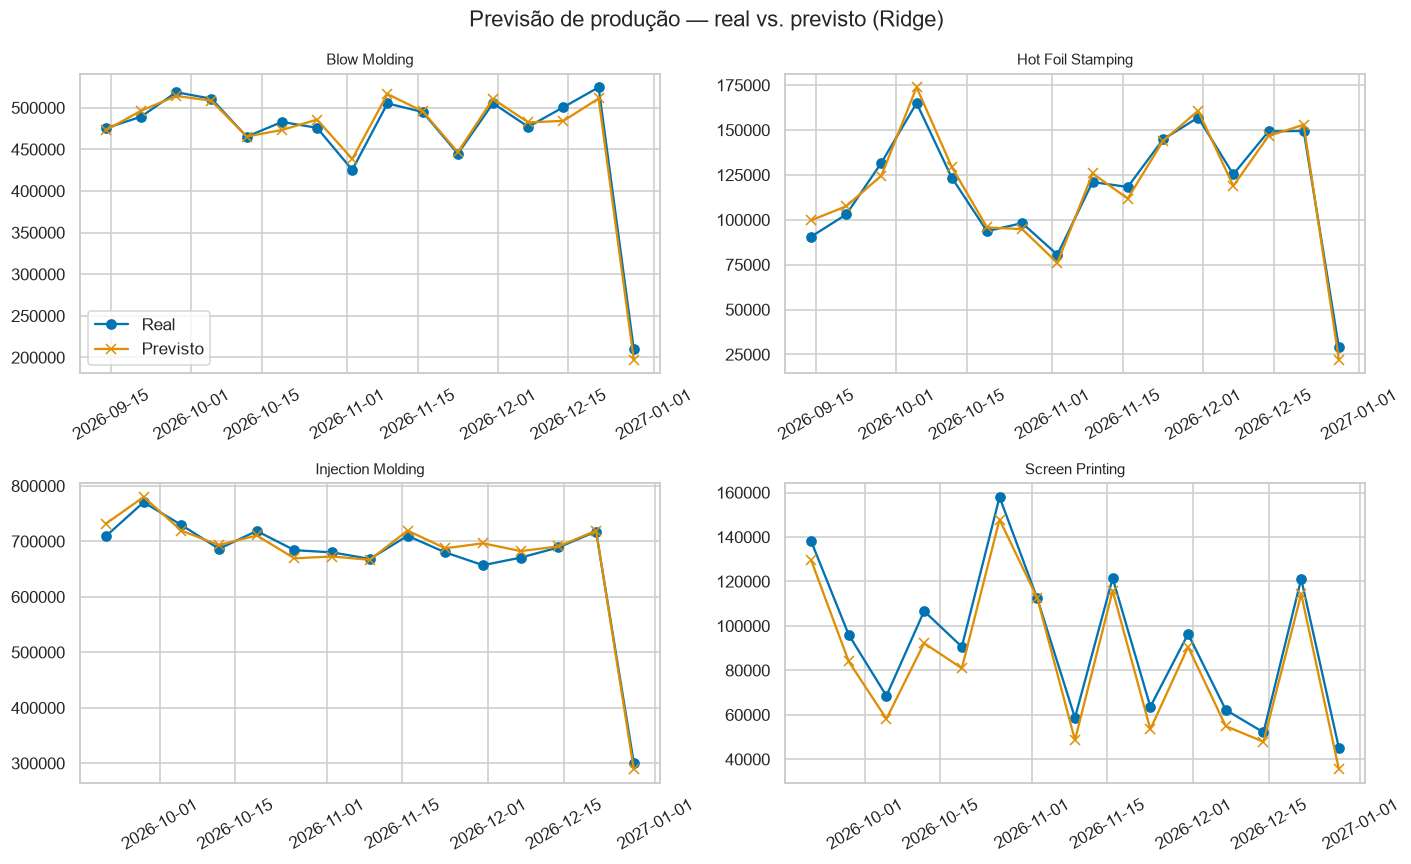

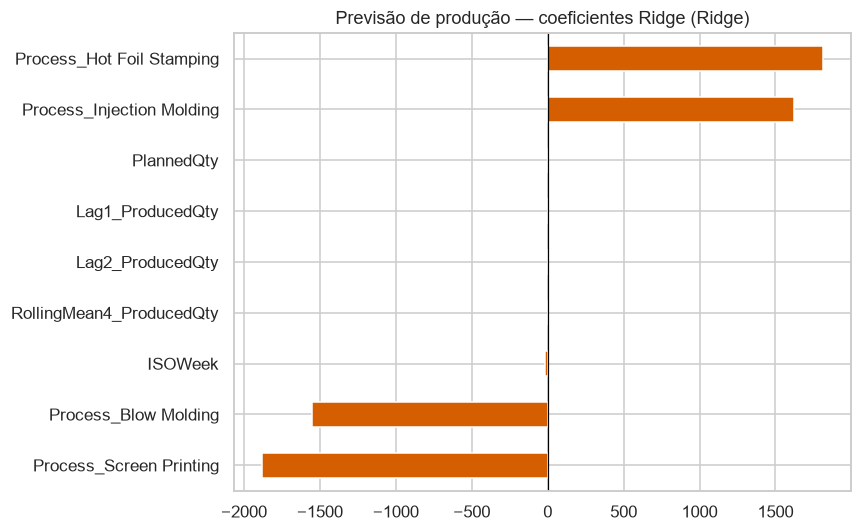

Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\producedqty_forecast_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'trained_on', 'test_metrics', 'baseline_metrics', 'refit_on_full_history']


In [187]:
prod_extra11 = plan11.groupby(["Process", "WeekStart"])["PlannedQty"].sum().reset_index()
weekly_prod11 = build_weekly_table11("ProducedQty", extra_merge=prod_extra11)
prod_forecast11, prod_history11, prod_comparison11, prod_best11 = run_forecast_pipeline11(
    "Previsão de produção", "ProducedQty", weekly_prod11, extra_cols=["PlannedQty"], unit="unidades")

### Previsão de parada não planejada (horas)


Previsão de parada não planejada
Baseline (média móvel de 4 semanas): MAE=12.6, R2=0.870



Comparação de modelos (GridSearchCV + TimeSeriesSplit):
                 MAE    RMSE  MAPE_%     R2  \
model                                         
Ridge         12.555  17.896  37.530  0.868   
RandomForest  10.730  13.262  24.116  0.929   
XGBoost       11.044  14.044  26.197  0.921   

                                                    best_params  \
model                                                             
Ridge                                            {'alpha': 0.1}   
RandomForest  {'max_depth': 4, 'min_samples_leaf': 3, 'n_est...   
XGBoost       {'learning_rate': 0.05, 'max_depth': 3, 'n_est...   

                     Metric_Basis  
model                              
Ridge           Teste (reportado)  
RandomForest  Validação (seleção)  
XGBoost       Validação (seleção)  
Vencedor escolhido em VALIDAÇÃO: Ridge. As demais linhas mostram métricas de validação; só a linha do vencedor mostra métrica de teste -- não comparar MAE entre linhas de bases diferentes (ve

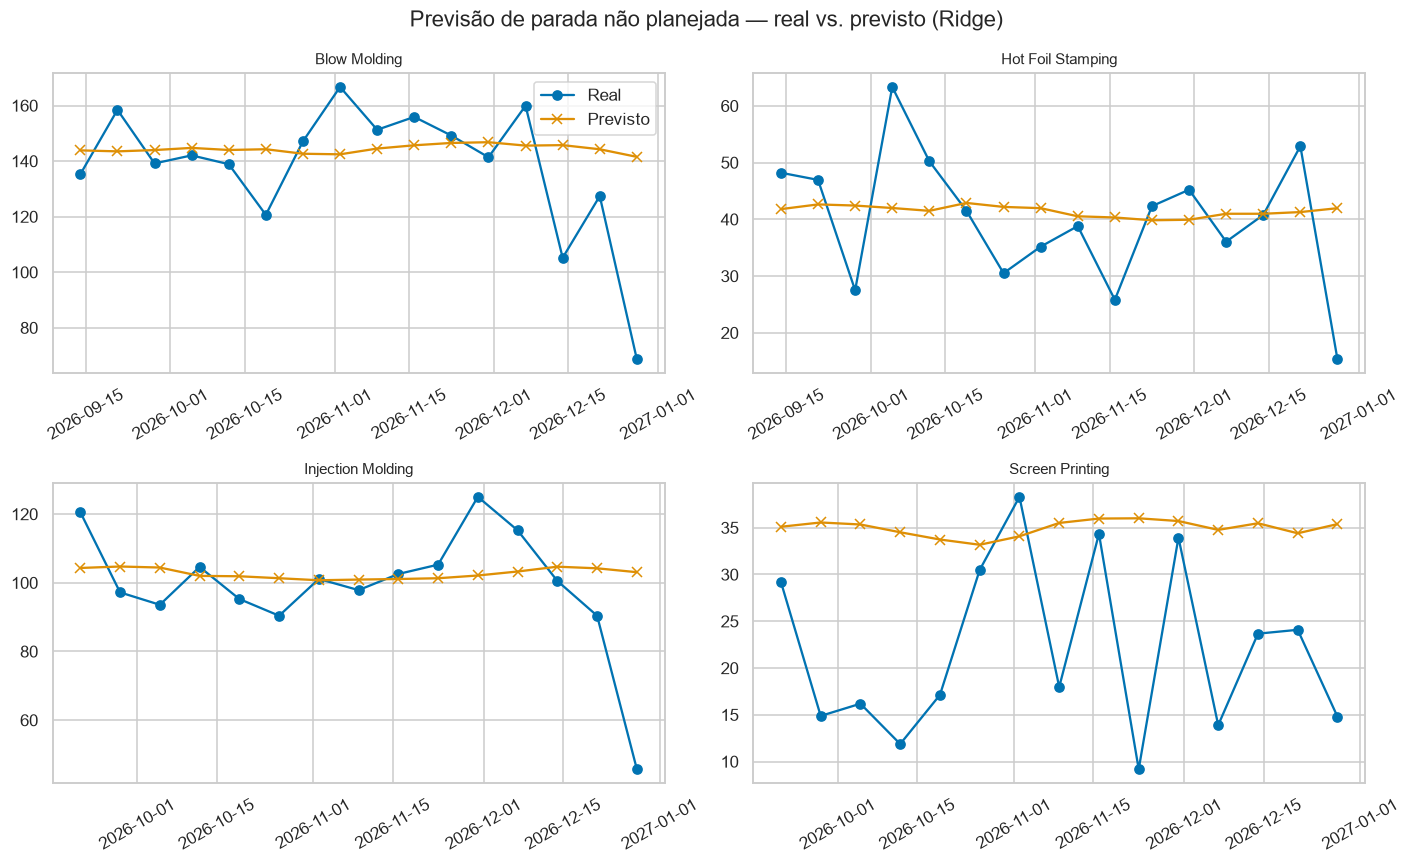

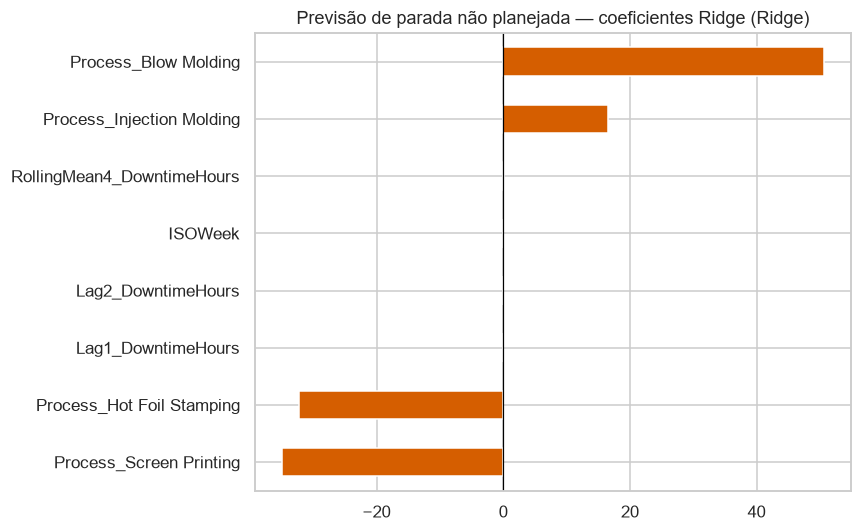

Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\downtimehours_forecast_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'trained_on', 'test_metrics', 'baseline_metrics', 'refit_on_full_history']


In [188]:
downtime_weekly11 = downtime11[downtime11["PlannedStoppage"] == "No"].groupby(["Process", "WeekStart"])["DowntimeDurationMin"].sum().div(60).rename("DowntimeHours").reset_index()
weekly_down11 = production11.groupby(["Process", "WeekStart"]).size().reset_index(name="_n")[["Process", "WeekStart"]]
weekly_down11 = weekly_down11.merge(downtime_weekly11, on=["Process", "WeekStart"], how="left")
weekly_down11["DowntimeHours"] = weekly_down11["DowntimeHours"].fillna(0)
weekly_down11 = weekly_down11.sort_values(["Process", "WeekStart"])
g11 = weekly_down11.groupby("Process")["DowntimeHours"]
weekly_down11["Lag1_DowntimeHours"] = g11.shift(1)
weekly_down11["Lag2_DowntimeHours"] = g11.shift(2)
weekly_down11["RollingMean4_DowntimeHours"] = g11.transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean())
weekly_down11["ISOWeek"] = weekly_down11["WeekStart"].dt.isocalendar().week.astype(int)
weekly_down11 = weekly_down11.dropna(subset=["Lag2_DowntimeHours", "RollingMean4_DowntimeHours"]).reset_index(drop=True)

down_forecast11, down_history11, down_comparison11, down_best11 = run_forecast_pipeline11(
    "Previsão de parada não planejada", "DowntimeHours", weekly_down11, extra_cols=[], unit="horas")

### Previsão de unidades rejeitadas

Distinta do modelo de risco por ordem da Seção 11.2: aqui é um **volume semanal
agregado da planta**, não o risco de uma ordem específica.


Previsão de unidades rejeitadas
Baseline (média móvel de 4 semanas): MAE=1216.6, R2=0.875



Comparação de modelos (GridSearchCV + TimeSeriesSplit):
                   MAE      RMSE  MAPE_%     R2  \
model                                             
XGBoost       1136.872  1874.130  27.636  0.890   
Ridge          897.277  1215.168  19.287  0.956   
RandomForest   980.106  1266.997  17.875  0.952   

                                                    best_params  \
model                                                             
XGBoost       {'learning_rate': 0.05, 'max_depth': 3, 'n_est...   
Ridge                                            {'alpha': 1.0}   
RandomForest  {'max_depth': 4, 'min_samples_leaf': 3, 'n_est...   

                     Metric_Basis  
model                              
XGBoost         Teste (reportado)  
Ridge         Validação (seleção)  
RandomForest  Validação (seleção)  
Vencedor escolhido em VALIDAÇÃO: XGBoost. As demais linhas mostram métricas de validação; só a linha do vencedor mostra métrica de teste -- não comparar MAE entre linhas d

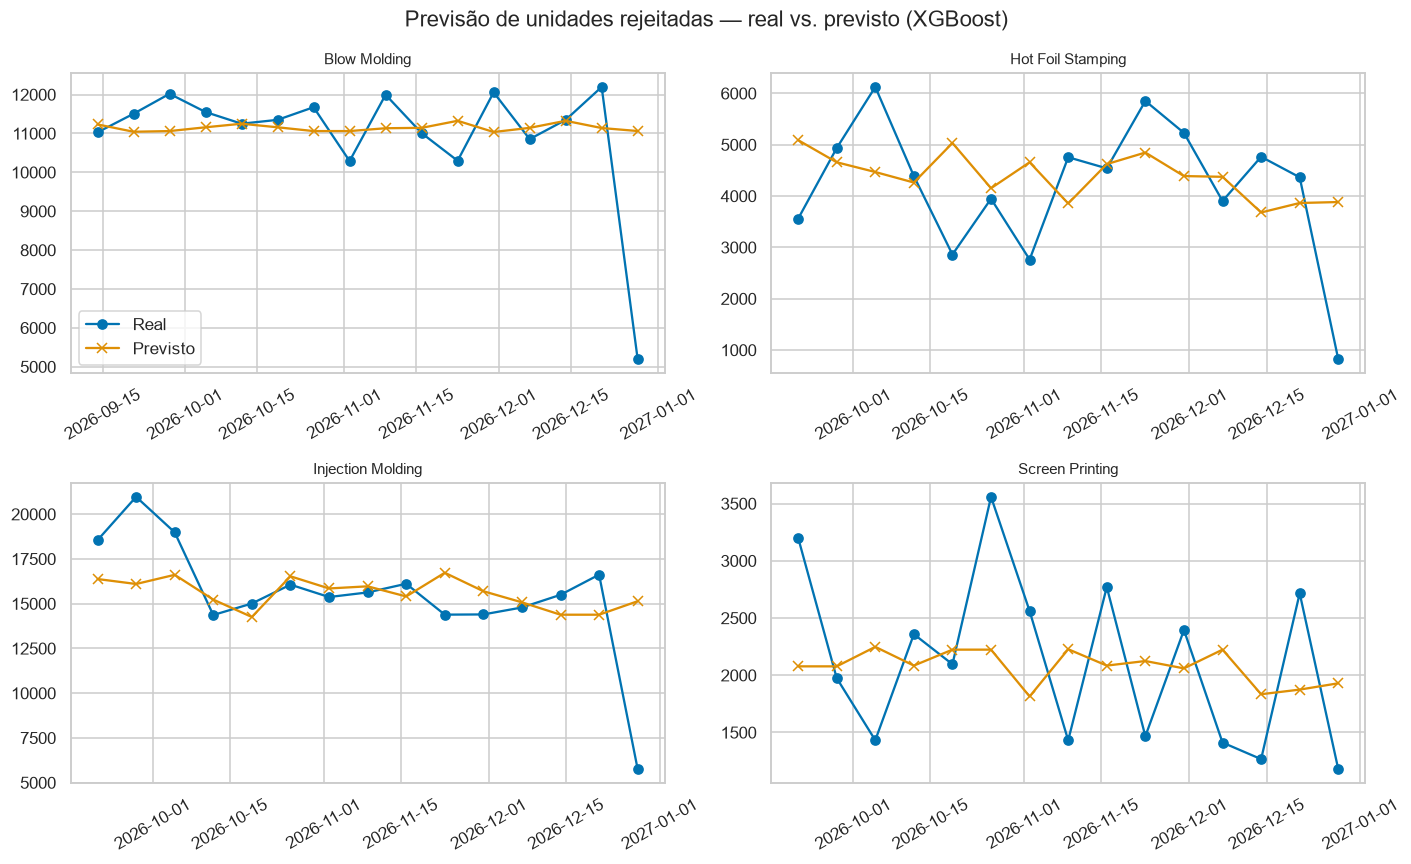

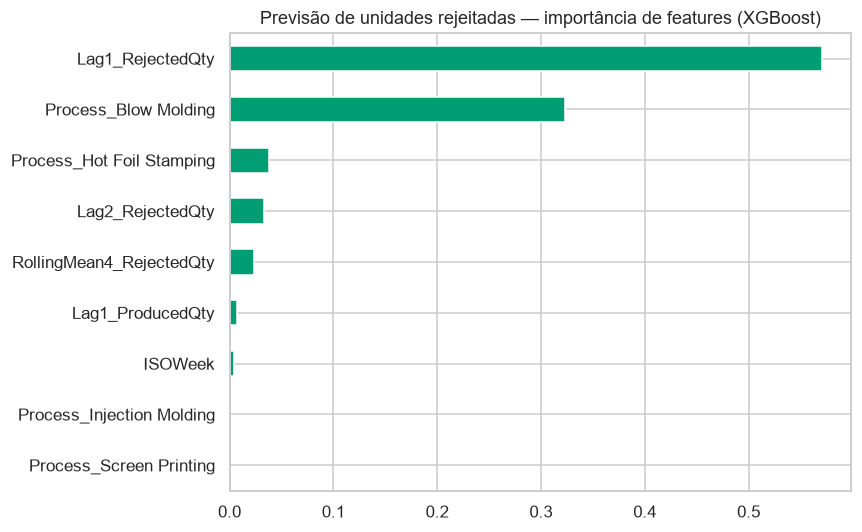

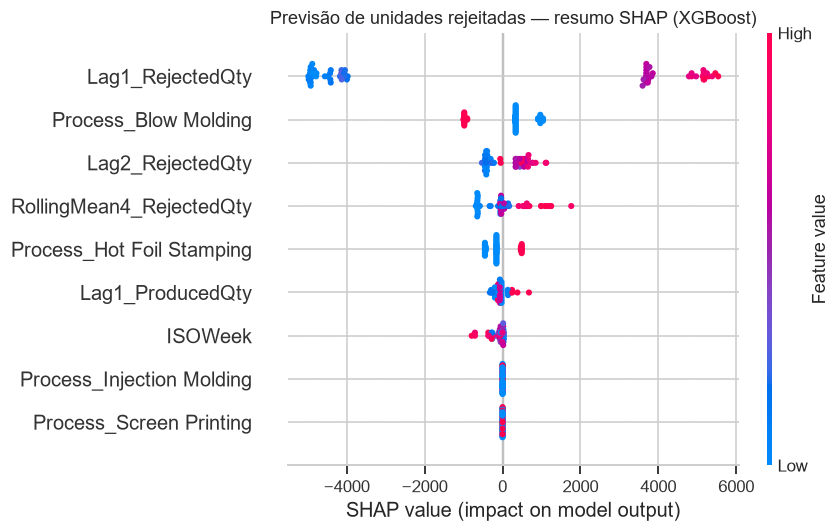

Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\rejectedqty_forecast_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'trained_on', 'test_metrics', 'baseline_metrics', 'refit_on_full_history']


In [189]:
# `ProducedQty` da MESMA semana só é conhecido depois que a semana já produziu -- usá-lo
# contemporâneo como feature não seria um forecast antecipado, seria uma previsão
# condicional ("dado que já sei quanto foi produzido"). A versão que preserva o
# horizonte de previsão real é a defasada em 1 semana (`Lag1_ProducedQty`), no mesmo
# espírito das defasagens de `RejectedQty` que `build_weekly_table11` já calcula.
weekly_rej11 = build_weekly_table11("RejectedQty", extra_merge=None)
weekly_rej11["Lag1_ProducedQty"] = weekly_rej11.groupby("Process")["ProducedQty"].shift(1)
weekly_rej11 = weekly_rej11.dropna(subset=["Lag1_ProducedQty"]).reset_index(drop=True)
rej_forecast11, rej_history11, rej_comparison11, rej_best11 = run_forecast_pipeline11(
    "Previsão de unidades rejeitadas", "RejectedQty", weekly_rej11, extra_cols=["Lag1_ProducedQty"], unit="unidades")

In [190]:
db_lib.load_dataframe(engine, prod_forecast11, "ml_predictions_production_forecast")
db_lib.load_dataframe(engine, prod_history11, "ml_predictions_production_forecast_history")
db_lib.load_dataframe(engine, down_forecast11, "ml_predictions_downtime_forecast")
db_lib.load_dataframe(engine, down_history11, "ml_predictions_downtime_forecast_history")
db_lib.load_dataframe(engine, rej_forecast11, "ml_predictions_rejected_forecast")
db_lib.load_dataframe(engine, rej_history11, "ml_predictions_rejected_forecast_history")
print("\nModelo escolhido por alvo:")
print(f"  Previsão de produção : {prod_best11}")
print(f"  Previsão de parada   : {down_best11}")
print(f"  Previsão de rejeitos : {rej_best11}")

  ml_predictions_production_forecast: 4 rows loaded in 0.0s (165 rows/s)
  ml_predictions_production_forecast_history: 62 rows loaded in 0.0s (11,518 rows/s)
  ml_predictions_downtime_forecast: 4 rows loaded in 0.0s (1,273 rows/s)
  ml_predictions_downtime_forecast_history: 62 rows loaded in 0.0s (11,535 rows/s)
  ml_predictions_rejected_forecast: 4 rows loaded in 0.0s (1,083 rows/s)
  ml_predictions_rejected_forecast_history: 61 rows loaded in 0.0s (12,372 rows/s)

Modelo escolhido por alvo:
  Previsão de produção : Ridge
  Previsão de parada   : Ridge
  Previsão de rejeitos : XGBoost


## 11.2 Três modelos de risco por ordem/dia

Distinto da Parte 11.1: cada modelo aqui responde por uma **ordem ou máquina
específica**, não um agregado semanal da planta.

### Taxa de sucata esperada — risco de uma ordem específica

Treino: 12,076 ordens | Teste: 3,019 ordens


                MAE   RMSE  MAPE_%     R2  \
model                                       
XGBoost       0.433  0.653  17.957  0.587   
RandomForest  0.427  0.614  18.993  0.553   
Ridge         0.486  0.671  21.547  0.465   

                                                    best_params  \
model                                                             
XGBoost       {'learning_rate': 0.05, 'max_depth': 3, 'n_est...   
RandomForest  {'max_depth': None, 'min_samples_leaf': 3, 'n_...   
Ridge                                           {'alpha': 10.0}   

                     Metric_Basis  
model                              
XGBoost         Teste (reportado)  
RandomForest  Validação (seleção)  
Ridge         Validação (seleção)  


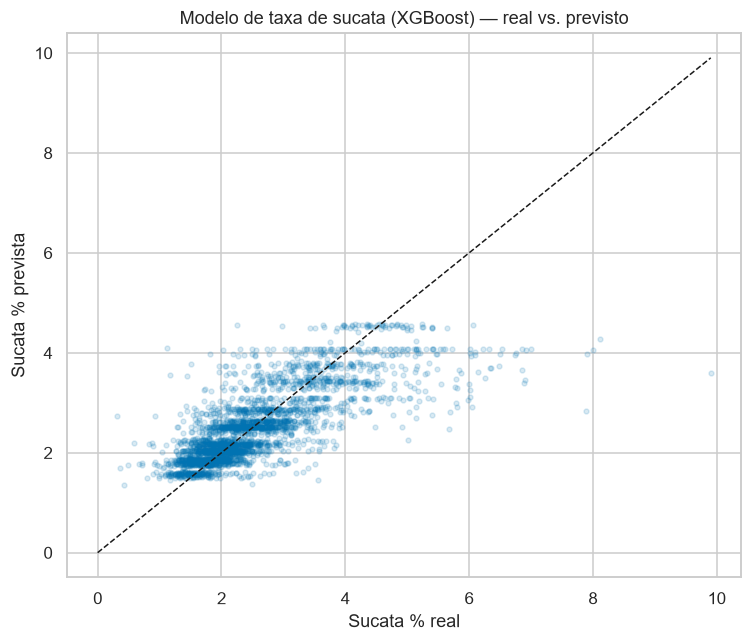

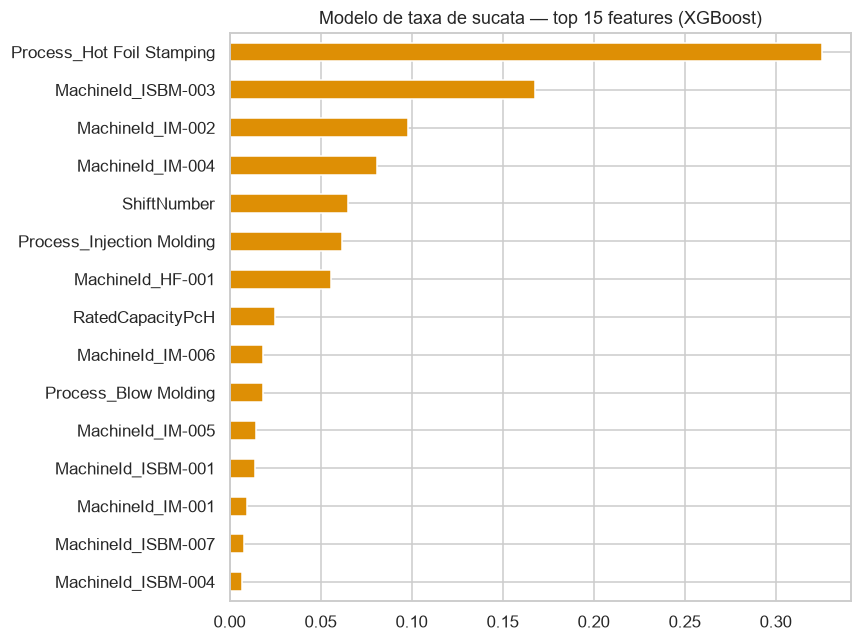

Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\scrap_rate_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'test_metrics']
  ml_predictions_scrap_rate: 3,019 rows loaded in 0.1s (38,143 rows/s)


0.07915030000731349

In [191]:
production_scrap11 = pd.read_sql("""
    SELECT WorkOrder, [Date], Process, MachineId, OperatorId, ShiftNumber, PlannedQty, ProducedQty, RejectedQty,
           ActualCycleTimeSec, RatedCapacityPcH, Availability
    FROM silver.fact_production
""", engine, parse_dates=["Date"])
production_scrap11["ScrapRatePct"] = (production_scrap11["RejectedQty"] / production_scrap11["ProducedQty"] * 100).clip(0, 100)
production_scrap11 = production_scrap11.dropna(subset=["ActualCycleTimeSec", "RatedCapacityPcH"])
production_scrap11 = production_scrap11[~production_scrap11["OperatorId"].isin(["-", "--", "---", "/", "//"])]

cat_cols11 = ["Process", "MachineId", "OperatorId"]
num_cols11 = ["ShiftNumber", "PlannedQty", "ActualCycleTimeSec", "RatedCapacityPcH", "Availability"]
X_all11 = pd.get_dummies(production_scrap11[cat_cols11 + num_cols11], columns=cat_cols11)
y_all11 = production_scrap11["ScrapRatePct"]

train_mask11, test_mask11 = ml.split_by_date(production_scrap11.assign(_idx=np.arange(len(production_scrap11))), "Date", test_fraction=0.2)
X_train11, X_test11 = X_all11.loc[train_mask11["_idx"]], X_all11.loc[test_mask11["_idx"]]
y_train11, y_test11 = y_all11.loc[train_mask11["_idx"]], y_all11.loc[test_mask11["_idx"]]
print(f"Treino: {len(X_train11):,} ordens | Teste: {len(X_test11):,} ordens")

scrap_comparison11, scrap_model11, scrap_best11 = ml.tune_regression_models(X_train11, y_train11, X_test11, y_test11)
print(scrap_comparison11.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
y_pred11 = scrap_model11.predict(X_test11)
ax.scatter(y_test11, y_pred11, alpha=0.15, s=10, color=PALETTE[0])
lims11 = [0, max(y_test11.max(), y_pred11.max())]
ax.plot(lims11, lims11, "k--", linewidth=1)
ax.set_xlabel("Sucata % real"); ax.set_ylabel("Sucata % prevista"); ax.set_title(f"Modelo de taxa de sucata ({scrap_best11}) — real vs. previsto")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "11_01_scrap_actual_vs_predicted.png"); plt.show()

if hasattr(scrap_model11, "feature_importances_"):
    top_importance11 = pd.Series(scrap_model11.feature_importances_, index=X_all11.columns).sort_values().tail(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    top_importance11.plot(kind="barh", ax=ax, color=PALETTE[1])
    ax.set_title(f"Modelo de taxa de sucata — top 15 features ({scrap_best11})")
    fig.tight_layout(); fig.savefig(REPORTS_DIR / "11_02_scrap_feature_importance.png"); plt.show()

ml.save_model(scrap_model11, MODELS_DIR / "scrap_rate_model.pkl", feature_cols=list(X_all11.columns), target_col="ScrapRatePct",
              model_name=scrap_best11, test_metrics=scrap_comparison11.loc[scrap_best11].drop("best_params").to_dict())
scrap_predictions11 = pd.DataFrame({
    "WorkOrder": test_mask11["WorkOrder"].values, "Date": test_mask11["Date"].dt.date.astype(str).values,
    "Process": test_mask11["Process"].values, "MachineId": test_mask11["MachineId"].values,
    "ActualScrapRatePct": y_test11.values, "PredictedScrapRatePct": y_pred11})
db_lib.load_dataframe(engine, scrap_predictions11, "ml_predictions_scrap_rate")

### Qualidade do lote — o lote será Aprovado ou Rejeitado?

In [192]:
bottle_disp11 = pd.read_sql("SELECT WorkOrder, ProductionDate AS [Date], Shift, MachineId, LotSize, SampleSize, CriticalDefects, MajorDefects, MinorDefects, FinalLotDecision FROM silver.fact_bottle_disposition_lot_cq", engine, parse_dates=["Date"])
cap_disp11 = pd.read_sql("SELECT WorkOrder, ProductionDate AS [Date], Shift, MachineId, LotSize, SampleSize, CriticalDefects, MajorDefects, MinorDefects, FinalLotDecision FROM silver.fact_cap_disposition_lot_cq", engine, parse_dates=["Date"])
ink_disp11 = pd.read_sql("SELECT WorkOrder, ProductionDate AS [Date], Shift, MachineId, LotSize, SampleSize, CriticalDefects, MajorDefects, MinorDefects, FinalLotDecision FROM silver.fact_ink_disposition_lot_cq", engine, parse_dates=["Date"])
all_disp11 = pd.concat([bottle_disp11.assign(Domain="Bottle"), cap_disp11.assign(Domain="Cap"), ink_disp11.assign(Domain="Ink/HotFoil")], ignore_index=True)
all_disp11["ShiftNumber"] = all_disp11["Shift"].str.extract(r"(\d)").astype(float)
all_disp11["Target"] = (all_disp11["FinalLotDecision"] == "Rejected").astype(int)
print(f"Desfechos de lote: {all_disp11['Target'].value_counts().to_dict()} ({all_disp11['Target'].mean():.1%} rejeitados)")

lq_cat_cols11 = ["Domain", "MachineId"]
lq_num_cols11 = ["ShiftNumber", "LotSize", "SampleSize"]
X_lq11 = pd.get_dummies(all_disp11[lq_cat_cols11 + lq_num_cols11].fillna(0), columns=lq_cat_cols11)
y_lq11 = all_disp11["Target"]

train_lq11, test_lq11 = ml.split_by_date(all_disp11.assign(_idx=np.arange(len(all_disp11))), "Date", test_fraction=0.2)
Xlq_train11, Xlq_test11 = X_lq11.loc[train_lq11["_idx"]], X_lq11.loc[test_lq11["_idx"]]
ylq_train11, ylq_test11 = y_lq11.loc[train_lq11["_idx"]], y_lq11.loc[test_lq11["_idx"]]

lq_comparison11, lq_model11, lq_best11 = ml.tune_classification_models(Xlq_train11, ylq_train11, Xlq_test11, ylq_test11)
print(lq_comparison11.round(3))
# Mesma leitura da 11.1 (Parte 11 regressão): `Metric_Basis` diz qual linha é validação
# (usada para ESCOLHER o algoritmo) e qual é teste (só a do vencedor) -- não comparar
# ROC-AUC/PR-AUC entre linhas de base diferente.
print(f"Vencedor escolhido em VALIDAÇÃO: {lq_best11}. Ver coluna Metric_Basis antes de comparar linhas.")
ml.show_classification_report(ylq_test11, lq_model11.predict(Xlq_test11), class_names=("Approved", "Rejected"))

Desfechos de lote: {0: 6973, 1: 898} (11.4% rejeitados)


C:\Users\aline\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                    Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC  \
model                                                                     
LogisticRegression     0.879      0.455   0.026  0.050    0.689   0.251   
XGBoost                0.882      0.818   0.058  0.108    0.691   0.288   
RandomForest           0.651      0.186   0.538  0.276    0.690   0.269   

                                                          best_params  \
model                                                                   
LogisticRegression                                         {'C': 1.0}   
XGBoost             {'learning_rate': 0.05, 'max_depth': 3, 'n_est...   
RandomForest                    {'max_depth': 4, 'n_estimators': 400}   

                           Metric_Basis  
model                                    
LogisticRegression    Teste (reportado)  
XGBoost             Validação (seleção)  
RandomForest        Validação (seleção)  
Vencedor escolhido em VALIDAÇÃO: LogisticRegress

C:\Users\aline\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Achado honesto, esperado desde a Parte 10**: a disposição de lote depende bastante
de variação amostral AQL (Parte 5/6) — um ROC-AUC modesto (bem acima de 0,5, bem
abaixo do 0,9+ de um problema fácil) é o resultado honesto correto aqui, não uma
falha de modelagem a esconder.

**Mas isso não deve mascarar um problema maior no limiar padrão (0,5)**: o classification report acima
mostra Precision≈45%, Recall≈3%, F1≈5% para a classe "Rejected" nesse limiar — o modelo praticamente
**não captura os lotes rejeitados** no threshold padrão (só 5 de 190 lotes rejeitados detectados no
teste). "ROC-AUC acima do acaso" é uma afirmação estatística correta; "pronto para detecção operacional
de lote ruim no limiar padrão" seria uma afirmação diferente e falsa. É exatamente por isso que a
seção seguinte usa um limiar econômico em vez do 0,5 — mas o limiar econômico muda o TRADE-OFF, não
torna o modelo operacionalmente forte por si só (ver a ressalva de impacto operacional logo abaixo).

**Por que PR-AUC ao lado do ROC-AUC, e por que um limiar de decisão econômico em vez
do 0,5 padrão.** A classe positiva (lote rejeitado) é minoritária — ROC-AUC pode
parecer enganosamente bom sob desbalanceamento, porque premia a taxa de verdadeiro-
negativo (fácil de acertar quando a maioria é negativa); PR-AUC só premia acertar a
classe rara, que é o que importa numa decisão de liberar/reter lote. E 0,5 só é o
limiar certo quando um falso positivo (reter um lote bom) e um falso negativo
(liberar um lote ruim) custam o mesmo — quase nunca verdade aqui: reter um lote bom
para reinspeção custa uma amostragem extra; liberar um lote ruim custa, na média, uma
reclamação de cliente (ordens de grandeza mais caro). `ml.economic_threshold` varre
limiares e escolhe o que minimiza o custo esperado total sob essa assimetria
declarada — os valores de custo são ilustrativos, como o resto do Custo da Qualidade
deste projeto (Parte 3B/6), não dados reais de contabilidade.

In [193]:
FALSE_POSITIVE_COST_LOT_BRL = ASSUMED_COST_PER_APPRAISAL_SAMPLE_BRL * 50  # reter um lote bom p/ reinspeção
FALSE_NEGATIVE_COST_LOT_BRL = float(np.mean(list(ASSUMED_COMPLAINT_COST_BRL.values())))  # liberar um lote ruim
lq_proba_for_threshold11 = lq_model11.predict_proba(Xlq_test11)[:, 1]
lq_pr_auc11 = ml.classification_metrics(ylq_test11, lq_model11.predict(Xlq_test11), probability=lq_proba_for_threshold11)["PR_AUC"]
# O limiar é escolhido varrendo uma fatia de VALIDAÇÃO (dentro de Xlq_train11), não o
# próprio teste -- senão o teste ajudaria a escolher o limiar que depois é avaliado nele
# mesmo, o mesmo problema de contaminação que a seleção de algoritmo em
# tune_classification_models já resolve.
lq_econ11 = ml.economic_threshold_val_test(lq_model11, Xlq_train11, ylq_train11, Xlq_test11, ylq_test11,
                                            FALSE_POSITIVE_COST_LOT_BRL, FALSE_NEGATIVE_COST_LOT_BRL)
print(f"PR-AUC = {lq_pr_auc11:.3f} (ROC-AUC = {lq_comparison11.loc[lq_best11, 'ROC_AUC']:.3f})")
print(f"Limiar escolhido em validação = {lq_econ11['best_threshold']:.2f} ({lq_econ11['best_threshold_chosen_on']})")
print(f"Limiar 0,5 (padrão): custo esperado no conjunto de teste = R$ {lq_econ11['cost_at_0_5']:,.0f}")
print(f"Limiar ótimo (custo-mínimo) = {lq_econ11['best_threshold']:.2f}: custo esperado = R$ {lq_econ11['best_cost']:,.0f} "
      f"({100*(1 - lq_econ11['best_cost']/max(lq_econ11['cost_at_0_5'], 1e-9)):.0f}% menor)")
_lq_pct_flagged = 100 * lq_econ11['n_flagged'] / lq_econ11['n_test']
print(f"Impacto operacional no teste ({lq_econ11['n_test']:,} lotes): {lq_econ11['n_flagged']:,} "
      f"({_lq_pct_flagged:.1f}% do total) retidos para reinspeção neste limiar -- "
      f"{lq_econ11['false_positives']:,} falsos positivos (lote bom retido à toa), "
      f"{lq_econ11['false_negatives']:,} falsos negativos (lote ruim liberado) -- número absoluto e percentual, "
      "não só custo relativo, porque \"X% menor custo\" sozinho esconde o volume real de trabalho extra de "
      "Qualidade que este limiar geraria.")
answer(f"PR-AUC = {lq_pr_auc11:.3f} confirma o mesmo diagnóstico do ROC-AUC (poder preditivo real, mas modesto) "
       "sem o otimismo que desbalanceamento de classe injeta no ROC-AUC sozinho. Sob os custos assimétricos "
       f"ilustrativos assumidos (reter lote bom: R$ {FALSE_POSITIVE_COST_LOT_BRL:.0f}; liberar lote ruim: R$ "
       f"{FALSE_NEGATIVE_COST_LOT_BRL:,.0f}), o limiar de decisão custo-mínimo "
       f"({lq_econ11['best_threshold']:.2f}) fica {'abaixo' if lq_econ11['best_threshold'] < 0.5 else 'acima'} de "
       "0,5 — o sentido esperado quando liberar um lote ruim custa muito mais que reter um bom por engano: o "
       "modelo deveria pender para reter mais lotes na dúvida, não para a precisão simétrica que o limiar padrão "
       f"assume implicitamente. **Ressalva sobre o tamanho do efeito**: a razão de custo assumida aqui "
       f"(~{FALSE_NEGATIVE_COST_LOT_BRL/FALSE_POSITIVE_COST_LOT_BRL:.0f}x) é grande o suficiente para empurrar o "
       f"limiar ótimo para perto de {lq_econ11['best_threshold']:.2f} — na prática, perto de reter quase todo "
       "lote que o modelo julgue minimamente arriscado. Isso é matematicamente consistente com os custos "
       "assumidos, mas um limiar tão extremo também é o tipo de resultado que merece uma checagem de "
       "sensibilidade antes de virar política real (testar a razão de custo em algumas faixas plausíveis, não só "
       "no ponto central assumido) — o objetivo desta seção é demonstrar o MÉTODO de escolher limiar por custo, "
       "não fixar um limiar operacional definitivo a partir de uma única premissa de custo ilustrativa.")

PR-AUC = 0.251 (ROC-AUC = 0.689)
Limiar escolhido em validação = 0.01 (validação (não no teste))
Limiar 0,5 (padrão): custo esperado no conjunto de teste = R$ 419,378
Limiar ótimo (custo-mínimo) = 0.01: custo esperado = R$ 10,388 (98% menor)
Impacto operacional no teste (1,575 lotes): 1,575 (100.0% do total) retidos para reinspeção neste limiar -- 1,385 falsos positivos (lote bom retido à toa), 0 falsos negativos (lote ruim liberado) -- número absoluto e percentual, não só custo relativo, porque "X% menor custo" sozinho esconde o volume real de trabalho extra de Qualidade que este limiar geraria.


**Resposta:** PR-AUC = 0.251 confirma o mesmo diagnóstico do ROC-AUC (poder preditivo real, mas modesto) sem o otimismo que desbalanceamento de classe injeta no ROC-AUC sozinho. Sob os custos assimétricos ilustrativos assumidos (reter lote bom: R$ 8; liberar lote ruim: R$ 2,267), o limiar de decisão custo-mínimo (0.01) fica abaixo de 0,5 — o sentido esperado quando liberar um lote ruim custa muito mais que reter um bom por engano: o modelo deveria pender para reter mais lotes na dúvida, não para a precisão simétrica que o limiar padrão assume implicitamente. **Ressalva sobre o tamanho do efeito**: a razão de custo assumida aqui (~302x) é grande o suficiente para empurrar o limiar ótimo para perto de 0.01 — na prática, perto de reter quase todo lote que o modelo julgue minimamente arriscado. Isso é matematicamente consistente com os custos assumidos, mas um limiar tão extremo também é o tipo de resultado que merece uma checagem de sensibilidade antes de virar política real (testar a razão de custo em algumas faixas plausíveis, não só no ponto central assumido) — o objetivo desta seção é demonstrar o MÉTODO de escolher limiar por custo, não fixar um limiar operacional definitivo a partir de uma única premissa de custo ilustrativa.

In [194]:
lq_proba11 = lq_model11.predict_proba(Xlq_test11)[:, 1]
lot_quality_predictions11 = pd.DataFrame({
    "WorkOrder": test_lq11["WorkOrder"].values, "Date": test_lq11["Date"].dt.date.astype(str).values,
    "FinalLotDecision": test_lq11["FinalLotDecision"].values, "PredictedRejectionRisk": lq_proba11,
    "PredictedDecision": np.where(lq_proba11 >= 0.5, "Rejected", "Approved")})
db_lib.load_dataframe(engine, lot_quality_predictions11, "ml_predictions_lot_quality")
ml.save_model(lq_model11, MODELS_DIR / "lot_quality_model.pkl", feature_cols=list(X_lq11.columns), target_col="Target",
              model_name=lq_best11, test_metrics=lq_comparison11.loc[lq_best11].drop("best_params").to_dict())

  ml_predictions_lot_quality: 1,575 rows loaded in 0.0s (42,711 rows/s)
Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\lot_quality_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'test_metrics']


### Manutenção preditiva — esta máquina vai falhar amanhã?

Painel máquina × dia: as features são estatísticas móveis do **passado recente**
(falhas e horas de parada nos últimos 7/14 dias) e o alvo é se uma falha não
planejada acontece no dia **seguinte** — uma previsão genuína, não uma descrição do
mesmo dia.

In [195]:
downtime_pm11 = pd.read_sql("SELECT [Date], MachineId, Process, UnplannedFailure, DowntimeDurationMin FROM silver.fact_downtime", engine, parse_dates=["Date"])
daily_failures11 = downtime_pm11.groupby(["MachineId", "Process", "Date"]).agg(Failures=("UnplannedFailure", "sum"), DowntimeMin=("DowntimeDurationMin", "sum")).reset_index()

all_dates11 = pd.date_range(daily_failures11["Date"].min(), daily_failures11["Date"].max(), freq="D")
machine_process11 = daily_failures11[["MachineId", "Process"]].drop_duplicates()
panel11 = machine_process11.merge(pd.DataFrame({"Date": all_dates11}), how="cross")
panel11 = panel11.merge(daily_failures11, on=["MachineId", "Process", "Date"], how="left").fillna({"Failures": 0, "DowntimeMin": 0})
panel11 = panel11.sort_values(["MachineId", "Date"])

g_pm11 = panel11.groupby("MachineId")
panel11["Failures_last7d"] = g_pm11["Failures"].transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())
panel11["Failures_last14d"] = g_pm11["Failures"].transform(lambda s: s.shift(1).rolling(14, min_periods=1).sum())
panel11["DowntimeMin_last7d"] = g_pm11["DowntimeMin"].transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())


def _days_since_last_failure11(failures: pd.Series) -> pd.Series:
    counter, values = 0, []
    for had_failure_yesterday in failures.shift(1).fillna(0) > 0:
        counter = 0 if had_failure_yesterday else counter + 1
        values.append(counter)
    return pd.Series(values, index=failures.index)


panel11["DaysSinceLastFailure"] = g_pm11["Failures"].transform(_days_since_last_failure11)
panel11["_is_last_day_for_machine"] = ~panel11["MachineId"].eq(panel11["MachineId"].shift(-1))
panel11["FailureTomorrow"] = g_pm11["Failures"].transform(lambda s: (s.shift(-1) > 0).astype(float))
panel11 = panel11[~panel11["_is_last_day_for_machine"]].drop(columns="_is_last_day_for_machine").reset_index(drop=True)
panel11["FailureTomorrow"] = panel11["FailureTomorrow"].astype(int)

pm_cat_cols11 = ["Process", "MachineId"]
pm_num_cols11 = ["Failures_last7d", "Failures_last14d", "DowntimeMin_last7d", "DaysSinceLastFailure"]
panel11[pm_num_cols11] = panel11[pm_num_cols11].fillna(0)
X_pm11 = pd.get_dummies(panel11[pm_cat_cols11 + pm_num_cols11], columns=pm_cat_cols11)
y_pm11 = panel11["FailureTomorrow"]
print(f"Máquina-dias: {len(panel11):,}, taxa de falha-amanhã: {y_pm11.mean():.1%}")

train_pm11, test_pm11 = ml.split_by_date(panel11.assign(_idx=np.arange(len(panel11))), "Date", test_fraction=0.2)
Xpm_train11, Xpm_test11 = X_pm11.loc[train_pm11["_idx"]], X_pm11.loc[test_pm11["_idx"]]
ypm_train11, ypm_test11 = y_pm11.loc[train_pm11["_idx"]], y_pm11.loc[test_pm11["_idx"]]

pm_comparison11, pm_model11, pm_best11 = ml.tune_classification_models(Xpm_train11, ypm_train11, Xpm_test11, ypm_test11)
print(pm_comparison11.round(3))
print(f"Vencedor escolhido em VALIDAÇÃO: {pm_best11}. Ver coluna Metric_Basis antes de comparar linhas "
      "(mesma leitura da 11.1/11.4 -- só a linha do vencedor é métrica de teste).")
ml.show_classification_report(ypm_test11, pm_model11.predict(Xpm_test11), class_names=("SemFalha", "FalhaAmanhã"))

Máquina-dias: 9,918, taxa de falha-amanhã: 64.6%


                    Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC  \
model                                                                     
LogisticRegression     0.656      0.654   0.941  0.772    0.593   0.696   
XGBoost                0.677      0.681   0.942  0.790    0.594   0.719   
RandomForest           0.644      0.689   0.818  0.748    0.593   0.720   

                                                          best_params  \
model                                                                   
LogisticRegression                                         {'C': 0.1}   
XGBoost             {'learning_rate': 0.05, 'max_depth': 3, 'n_est...   
RandomForest                    {'max_depth': 4, 'n_estimators': 400}   

                           Metric_Basis  
model                                    
LogisticRegression    Teste (reportado)  
XGBoost             Validação (seleção)  
RandomForest        Validação (seleção)  
Vencedor escolhido em VALIDAÇÃO: LogisticRegress

Mesma lógica de custo assimétrico do classificador de qualidade de lote acima,
aplicada aqui: um falso positivo custa uma PM desnecessária (poucas horas de parada
planejada); um falso negativo custa uma falha não planejada real (mais horas de
parada, e menos previsível para a produção se ajustar em volta). Reaproveita
`ASSUMED_DOWNTIME_COST_PER_HOUR_BRL` (Parte 4.6b) para os dois lados, só variando as
horas assumidas de cada tipo de evento -- ilustrativo, não medido.

In [196]:
FALSE_POSITIVE_COST_PM_BRL = 2 * ASSUMED_DOWNTIME_COST_PER_HOUR_BRL  # PM extra desnecessária
FALSE_NEGATIVE_COST_PM_BRL = 8 * ASSUMED_DOWNTIME_COST_PER_HOUR_BRL  # falha não planejada real
pm_proba_for_threshold11 = pm_model11.predict_proba(Xpm_test11)[:, 1]
pm_pr_auc11 = ml.classification_metrics(ypm_test11, pm_model11.predict(Xpm_test11), probability=pm_proba_for_threshold11)["PR_AUC"]
# Mesmo cuidado da 11.2: limiar escolhido em validação (dentro de Xpm_train11), não no teste.
pm_econ11 = ml.economic_threshold_val_test(pm_model11, Xpm_train11, ypm_train11, Xpm_test11, ypm_test11,
                                            FALSE_POSITIVE_COST_PM_BRL, FALSE_NEGATIVE_COST_PM_BRL)
print(f"PR-AUC = {pm_pr_auc11:.3f} (ROC-AUC = {pm_comparison11.loc[pm_best11, 'ROC_AUC']:.3f})")
print(f"Limiar escolhido em validação = {pm_econ11['best_threshold']:.2f} ({pm_econ11['best_threshold_chosen_on']})")
print(f"Limiar 0,5 (padrão): custo esperado no conjunto de teste = R$ {pm_econ11['cost_at_0_5']:,.0f}")
print(f"Limiar ótimo (custo-mínimo) = {pm_econ11['best_threshold']:.2f}: custo esperado = R$ {pm_econ11['best_cost']:,.0f} "
      f"({100*(1 - pm_econ11['best_cost']/max(pm_econ11['cost_at_0_5'], 1e-9)):.0f}% menor)")
_pm_pct_flagged = 100 * pm_econ11['n_flagged'] / pm_econ11['n_test']
print(f"Impacto operacional no teste ({pm_econ11['n_test']:,} máquina-dias): {pm_econ11['n_flagged']:,} "
      f"({_pm_pct_flagged:.1f}% do total) sinalizados para PM neste limiar -- {pm_econ11['false_positives']:,} "
      f"falsos positivos (PM desnecessária), {pm_econ11['false_negatives']:,} falsos negativos (falha não "
      "antecipada).")
# `FailureTomorrow` NÃO é uma classe rara aqui ({y_pm11.mean():.1%} dos máquina-dias) -- ao
# contrário de "poucos dias de falha em meio a muitos sem falha", a maioria dos dias JÁ é
# de falha. Isso muda a leitura do PR-AUC: um classificador sem nenhuma habilidade real,
# que sempre prevê a classe majoritária, já teria PR-AUC próximo da própria taxa-base
# ({y_pm11.mean():.3f}) -- então o PR-AUC do modelo precisa ser comparado a ESSE piso, não
# a zero, para dizer se o modelo aprendeu algo.
pm_noskill_pr_auc11 = float(y_pm11.mean())
answer(f"ROC-AUC = {pm_comparison11.loc[pm_best11, 'ROC_AUC']:.3f} está muito perto de 0,5 (aleatório) — "
       "capacidade discriminativa fraca, não uma demonstração forte de manutenção preditiva. PR-AUC = "
       f"{pm_pr_auc11:.3f} parece melhor isoladamente, mas a taxa-base de falha-amanhã é "
       f"{y_pm11.mean():.1%} — a classe positiva é MAJORITÁRIA aqui, não rara -- então um classificador "
       f"'sem nenhuma habilidade' (sempre prevê falha) já chegaria perto de PR-AUC≈{pm_noskill_pr_auc11:.3f} só "
       f"pela base rate; o ganho real do modelo sobre esse piso é modesto ({pm_pr_auc11 - pm_noskill_pr_auc11:+.3f}). "
       "**Classificação honesta deste modelo: discriminação fraca/marginal, valor incremental modesto** — não "
       "uma capacidade preditiva forte pronta para operação autônoma. Sob o custo assimétrico assumido (falha "
       "não planejada custa 4x uma PM extra desnecessária), o limiar custo-mínimo "
       f"({pm_econ11['best_threshold']:.2f}) fica {'abaixo' if pm_econ11['best_threshold'] < 0.5 else 'acima'} de "
       "0,5 — um viés deliberado para mais alarmes falsos em troca de menos falhas perdidas, coerente com o "
       "objetivo de manutenção preditiva (errar para o lado seguro custa menos que uma parada não planejada), "
       "mas isso reduz custo esperado sob um modelo fraco — não o transforma num modelo forte.")

if hasattr(pm_model11, "feature_importances_"):
    pm_importance11 = pd.Series(pm_model11.feature_importances_, index=X_pm11.columns).sort_values().tail(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    pm_importance11.plot(kind="barh", ax=ax, color=PALETTE[4])
    ax.set_title(f"Manutenção preditiva — top 15 features ({pm_best11})")
    fig.tight_layout(); fig.savefig(REPORTS_DIR / "11_03_predictive_maintenance_feature_importance.png"); plt.show()

pm_proba_test11 = pm_model11.predict_proba(Xpm_test11)[:, 1]
pm_history11 = pd.DataFrame({
    "MachineId": test_pm11["MachineId"].values, "Date": test_pm11["Date"].dt.date.astype(str).values,
    "FailureTomorrow": test_pm11["FailureTomorrow"].values, "Process": test_pm11["Process"].values,
    "PredictedFailureRisk": pm_proba_test11})
db_lib.load_dataframe(engine, pm_history11, "ml_predictions_predictive_maintenance_history")

latest_panel11 = panel11.sort_values("Date").groupby("MachineId").tail(1)
X_latest_pm11 = pd.get_dummies(latest_panel11[pm_cat_cols11 + pm_num_cols11], columns=pm_cat_cols11).reindex(columns=X_pm11.columns, fill_value=0)
# `panel11["Date"].max()` pode cair 1-2 dias depois da janela de 18 meses declarada
# (2026-12-30): um turno 3 que começa antes da meia-noite do último dia e é registrado
# com a data em que termina cruza para o dia seguinte no calendário, o mesmo motivo pelo
# qual `fact_downtime` tem uns dias a mais de intervalo do que `fact_production` — o
# risco previsto abaixo usa o dado real mais recente disponível, não uma data fabricada.
today_risk11 = pd.DataFrame({
    "MachineId": latest_panel11["MachineId"].values, "Process": latest_panel11["Process"].values,
    "PredictedFailureRiskToday": pm_model11.predict_proba(X_latest_pm11)[:, 1],
    "GeneratedFrom": str(panel11["Date"].max().date())}).sort_values("PredictedFailureRiskToday", ascending=False)
db_lib.load_dataframe(engine, today_risk11, "ml_predictions_predictive_maintenance")
ml.save_model(pm_model11, MODELS_DIR / "predictive_maintenance_model.pkl", feature_cols=list(X_pm11.columns),
              target_col="FailureTomorrow", model_name=pm_best11, test_metrics=pm_comparison11.loc[pm_best11].drop("best_params").to_dict())

print("\nTop 5 máquinas de maior risco agora:")
print(today_risk11.head(5).to_string(index=False))

PR-AUC = 0.696 (ROC-AUC = 0.593)
Limiar escolhido em validação = 0.01 (validação (não no teste))
Limiar 0,5 (padrão): custo esperado no conjunto de teste = R$ 628,600
Limiar ótimo (custo-mínimo) = 0.01: custo esperado = R$ 530,600 (16% menor)
Impacto operacional no teste (1,984 máquina-dias): 1,984 (100.0% do total) sinalizados para PM neste limiar -- 758 falsos positivos (PM desnecessária), 0 falsos negativos (falha não antecipada).


**Resposta:** ROC-AUC = 0.593 está muito perto de 0,5 (aleatório) — capacidade discriminativa fraca, não uma demonstração forte de manutenção preditiva. PR-AUC = 0.696 parece melhor isoladamente, mas a taxa-base de falha-amanhã é 64.6% — a classe positiva é MAJORITÁRIA aqui, não rara -- então um classificador 'sem nenhuma habilidade' (sempre prevê falha) já chegaria perto de PR-AUC≈0.646 só pela base rate; o ganho real do modelo sobre esse piso é modesto (+0.050). **Classificação honesta deste modelo: discriminação fraca/marginal, valor incremental modesto** — não uma capacidade preditiva forte pronta para operação autônoma. Sob o custo assimétrico assumido (falha não planejada custa 4x uma PM extra desnecessária), o limiar custo-mínimo (0.01) fica abaixo de 0,5 — um viés deliberado para mais alarmes falsos em troca de menos falhas perdidas, coerente com o objetivo de manutenção preditiva (errar para o lado seguro custa menos que uma parada não planejada), mas isso reduz custo esperado sob um modelo fraco — não o transforma num modelo forte.

  ml_predictions_predictive_maintenance_history: 1,984 rows loaded in 0.0s (52,418 rows/s)
  ml_predictions_predictive_maintenance: 18 rows loaded in 0.0s (7,348 rows/s)
Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\predictive_maintenance_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'test_metrics']

Top 5 máquinas de maior risco agora:
MachineId           Process  PredictedFailureRiskToday GeneratedFrom
 ISBM-005      Blow Molding                   0.873759    2027-01-02
 ISBM-007      Blow Molding                   0.696182    2027-01-02
   IM-004 Injection Molding                   0.691897    2027-01-02
 ISBM-001      Blow Molding                   0.685499    2027-01-02
 ISBM-002      Blow Molding                   0.682225    2027-01-02


## 11.3 — BQ-079: vazamento de dados/overfitting nos 6 modelos, demonstrado

> **BQ-079.** *Identifique o risco de vazamento de dados/overfitting entre os 6
> modelos de ML, e demonstre-o.*

O modelo de taxa de sucata (11.2) usa, entre outras, `ActualCycleTimeSec` e
`Availability` — ambas calculadas (Parte 2) a partir do tempo de execução e da saída
**reais** da própria ordem, a mesma ordem cuja sucata está sendo prevista. Usar este
modelo como está exigiria já saber quanto tempo a ordem levou para rodar e quão
disponível a máquina esteve **antes de a ordem ter terminado de rodar** — impossível.
Em vez de só apontar isso, o modelo é retreinado duas vezes, com e sem as features
vazadas, usando o mesmo pipeline de tuning, e o gap é medido.

Correlação de cada feature candidata com o alvo (ScrapRatePct):
RatedCapacityPcH     -0.147
PlannedQty           -0.133
ActualCycleTimeSec   -0.027
Availability          0.009
Name: ScrapRatePct, dtype: float64



Modelo A (COM ActualCycleTimeSec + Availability -- vazado): XGBoost, R2 = 0.587
Modelo B (SEM as features vazadas -- honesto): XGBoost, R2 = 0.588
Saved model to C:\Project Portfolios\manufacturing-performance-analytics\models\scrap_rate_model.pkl with metadata keys: ['feature_cols', 'target_col', 'model_name', 'test_metrics', 'leakage_checked']
  ml_predictions_scrap_rate: 3,019 rows loaded in 0.1s (36,566 rows/s)
scrap_rate_model.pkl e ml_predictions_scrap_rate atualizados para o Modelo B (honesto, sem leakage).


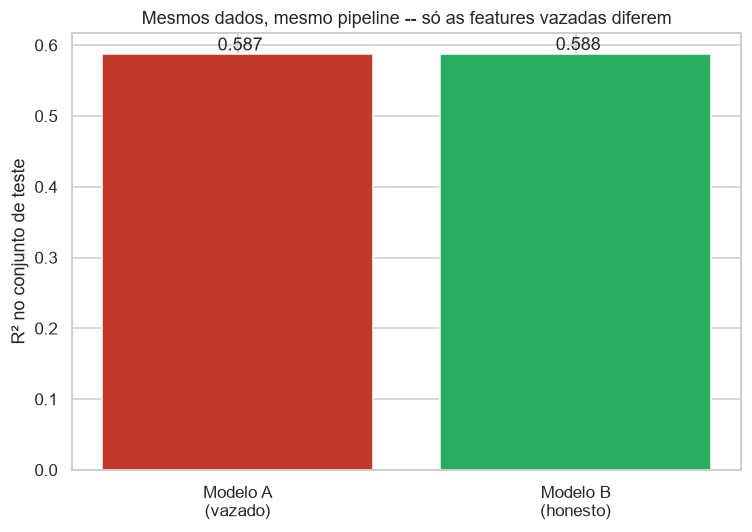

In [197]:
corr_with_target11 = production_scrap11[["ActualCycleTimeSec", "Availability", "RatedCapacityPcH", "PlannedQty", "ScrapRatePct"]].corr()["ScrapRatePct"].drop("ScrapRatePct")
print("Correlação de cada feature candidata com o alvo (ScrapRatePct):")
print(corr_with_target11.sort_values(key=abs, ascending=False).round(3))

r2_leaky11 = scrap_comparison11.loc[scrap_best11, "R2"]  # Modelo A -- já treinado acima, COM as features vazadas

clean_num_cols11 = ["ShiftNumber", "PlannedQty", "RatedCapacityPcH"]
X_clean11 = pd.get_dummies(production_scrap11[cat_cols11 + clean_num_cols11], columns=cat_cols11)
X_train_clean11, X_test_clean11 = X_clean11.loc[train_mask11["_idx"]], X_clean11.loc[test_mask11["_idx"]]
comparison_clean11, model_clean11, best_clean11 = ml.tune_regression_models(X_train_clean11, y_train11, X_test_clean11, y_test11)
r2_clean11 = comparison_clean11.loc[best_clean11, "R2"]
print(f"\nModelo A (COM ActualCycleTimeSec + Availability -- vazado): {scrap_best11}, R2 = {r2_leaky11:.3f}")
print(f"Modelo B (SEM as features vazadas -- honesto): {best_clean11}, R2 = {r2_clean11:.3f}")

# O modelo salvo/exportado em 11.2 (`scrap_rate_model.pkl`, `ml_predictions_scrap_rate`) foi o
# Modelo A, treinado antes desta checagem de leakage existir. Agora que sabemos que ele usa
# features ilegítimas (não conhecíveis no momento da previsão), o artefato de produção é
# substituído pelo Modelo B -- a checagem de leakage não é só uma demonstração pedagógica
# isolada, ela precisa mudar o que de fato roda depois.
y_pred_clean11 = model_clean11.predict(X_test_clean11)
ml.save_model(model_clean11, MODELS_DIR / "scrap_rate_model.pkl", feature_cols=list(X_clean11.columns), target_col="ScrapRatePct",
              model_name=best_clean11, test_metrics=comparison_clean11.loc[best_clean11].drop("best_params").to_dict(),
              leakage_checked=True)
scrap_predictions_clean11 = pd.DataFrame({
    "WorkOrder": test_mask11["WorkOrder"].values, "Date": test_mask11["Date"].dt.date.astype(str).values,
    "Process": test_mask11["Process"].values, "MachineId": test_mask11["MachineId"].values,
    "ActualScrapRatePct": y_test11.values, "PredictedScrapRatePct": y_pred_clean11})
db_lib.load_dataframe(engine, scrap_predictions_clean11, "ml_predictions_scrap_rate")
print("scrap_rate_model.pkl e ml_predictions_scrap_rate atualizados para o Modelo B (honesto, sem leakage).")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Modelo A\n(vazado)", "Modelo B\n(honesto)"], [r2_leaky11, r2_clean11], color=["#c0392b", "#27ae60"])
ax.set_ylabel("R² no conjunto de teste"); ax.set_title("Mesmos dados, mesmo pipeline -- só as features vazadas diferem")
for i, v in enumerate([r2_leaky11, r2_clean11]):
    ax.text(i, v, f" {v:.3f}", ha="center", va="bottom" if v >= 0 else "top")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "11_04_leakage_r2_comparison.png"); plt.show()

**Resultado honesto que complica a narrativa óbvia**: o gap entre os dois modelos é
essencialmente zero — remover as features vazadas não piora (e pode até melhorar
ligeiramente) o desempenho. Isso não muda a conclusão de princípio: `ActualCycleTimeSec`
e `Availability` são features **ilegítimas** para este modelo por definição — um
programador de produção genuinamente não pode conhecer nenhuma das duas antes de a
ordem rodar — **independentemente** de removê-las mudar o R² hoje. Este experimento
mostra que elas não carregam muito sinal sobre sucata *neste conjunto de dados, com
este conjunto de features, hoje*. Isso não é o mesmo que seguro: um retreino futuro
com features diferentes, um mix de produto diferente, ou um algoritmo diferente
poderia deixar essa mesma correlação ilegítima se expressar de forma diferente — e,
se as features temporariamente ilegítimas já tivessem sido normalizadas como "tudo
bem, já checamos uma vez", ninguém pensaria em checar de novo. O processo correto é
**excluir features que não poderiam existir no momento da previsão antes de treinar**,
por princípio de desenho — não incluir e torcer para que uma checagem posterior de
correlação pegue o problema, porque este experimento mostra que essa checagem pode
voltar limpa mesmo quando a prática subjacente continua errada. O Modelo B é o que
deveria ir para produção — não porque pontua mais alto hoje, mas porque é o único dos
dois que está fazendo ao modelo uma pergunta que a produção pode de fato responder.

**Onde mais este mesmo teste deveria ser rodado, entre os outros 5 modelos**:
- **Classificador de qualidade de lote (11.2)** — usa `Domain`/`MachineId`/`Shift`/
  `LotSize`/`SampleSize`, todos conhecíveis antes da inspeção — não vaza.
- **Manutenção preditiva (11.2)** — usa explicitamente só features de janela **passada**
  por desenho — um padrão bom de confirmar, não de assumir.
- **As três previsões semanais (11.1)** — já usam features defasadas/de média móvel
  por construção — um desenho mais forte contra este mesmo modo de falha do que o
  modelo de sucata da 10 acabou tendo — ainda assim vale o mesmo teste explícito, não
  a suposição de que "modelo de previsão é automaticamente seguro".

## Resumo — os seis modelos

In [198]:
summary_models11 = pd.DataFrame([
    {"Modelo": "Previsão de produção", "Algoritmo": prod_best11, "Métrica": f"R²={prod_comparison11.loc[prod_best11, 'R2']:.3f}"},
    {"Modelo": "Previsão de parada", "Algoritmo": down_best11, "Métrica": f"R²={down_comparison11.loc[down_best11, 'R2']:.3f}"},
    {"Modelo": "Previsão de rejeitos", "Algoritmo": rej_best11, "Métrica": f"R²={rej_comparison11.loc[rej_best11, 'R2']:.3f}"},
    {"Modelo": "Taxa de sucata", "Algoritmo": best_clean11, "Métrica": f"R²={r2_clean11:.3f} (sem leakage)"},
    {"Modelo": "Qualidade de lote", "Algoritmo": lq_best11, "Métrica": f"ROC-AUC={lq_comparison11.loc[lq_best11, 'ROC_AUC']:.3f}"},
    {"Modelo": "Manutenção preditiva", "Algoritmo": pm_best11, "Métrica": f"ROC-AUC={pm_comparison11.loc[pm_best11, 'ROC_AUC']:.3f}"},
])
print(summary_models11.to_string(index=False))
print("\nParte 11 completa — todos os seis modelos de ML treinados, avaliados, salvos e exportados ao warehouse.")

              Modelo          Algoritmo                Métrica
Previsão de produção              Ridge               R²=0.998
  Previsão de parada              Ridge               R²=0.868
Previsão de rejeitos            XGBoost               R²=0.890
      Taxa de sucata            XGBoost R²=0.588 (sem leakage)
   Qualidade de lote LogisticRegression          ROC-AUC=0.689
Manutenção preditiva LogisticRegression          ROC-AUC=0.593

Parte 11 completa — todos os seis modelos de ML treinados, avaliados, salvos e exportados ao warehouse.


---
# Parte 12 — Síntese, Recomendação e Controle
---

**Papel: todo o time virtual, reportando o raio-X completo.** Fecha o notebook
respondendo as 8 perguntas gerais juntas, citando a evidência de cada Parte anterior,
e recomenda **uma única iniciativa de melhoria** para financiar — com prova, impacto
em R$ e controle — em vez de uma lista de possibilidades sem prioridade. Nada aqui é
novo cálculo: cada número é lido de volta dos resumos que as Partes anteriores já
salvaram, para que este fechamento nunca divirja silenciosamente do que já foi
provado.

In [199]:
charter_s = json.loads((PROCESSED_DIR / "charter_summary.json").read_text(encoding="utf-8"))
toc_s = json.loads((PROCESSED_DIR / "toc_kaizen_summary.json").read_text(encoding="utf-8"))
trace_s = json.loads((PROCESSED_DIR / "traceability_summary.json").read_text(encoding="utf-8"))
aqt_s = json.loads((PROCESSED_DIR / "advanced_quality_tools_summary.json").read_text(encoding="utf-8"))
dmaic_s = json.loads((PROCESSED_DIR / "dmaic_im002_summary.json").read_text(encoding="utf-8"))
print("Resumos carregados de volta:", list(charter_s.keys())[:2], "...")


def model_metrics12(name: str) -> dict:
    return joblib_load(MODELS_DIR / name)["metadata"]["test_metrics"]

Resumos carregados de volta: ['baseline', 'cost_of_quality_brl'] ...


## 12.0b — Nota metodológica: múltiplos testes de hipótese, vistos juntos

> **Por que isto importa.** Este notebook roda dezenas de testes de hipótese
> independentes ao longo das Partes 4-9, cada um a α=0,05 nominal. Isso é correto
> célula a célula — cada teste responde uma pergunta de negócio pré-especificada
> (`BQ-XXX`), não é uma busca exploratória por "o que der significativo" — mas, olhado
> como um CONJUNTO, rodar N testes independentes a 5% cada, mesmo que nenhum efeito
> real exista em lugar nenhum, produz ~0,05×N "falsos positivos" só por acaso. Esta
> célula faz o que nenhuma célula individual pode fazer sozinha: reunir os p-valores
> primários já calculados (não recalculados — lidos das variáveis que cada Parte já
> deixou no kernel) e aplicar a correção de Benjamini-Hochberg (controle de taxa de
> falsa descoberta, FDR), menos conservadora que Bonferroni e mais adequada aqui
> porque as perguntas testam mecanismos parcialmente relacionados (mesma planta, "
> mesmos 18 meses), não hipóteses totalmente independentes.

**O que ESTE inventário deliberadamente não inclui**: (a) os testes já protegidos
por sua própria correção interna (Tukey HSD na Seção 5.4 já controla a taxa
familywise entre pares de máquina); (b) sensibilidades e ilustrações hipotéticas
(ex. o Cpk=1,33 hipotético da Seção 9.2b) que não são, por si só, uma alegação de
efeito real. O que entra é a lista de testes confirmatórios primários — um por
pergunta de negócio — cujo resultado (`significativo`/`não significativo`) o
notebook efetivamente usa para embasar uma conclusão.

In [200]:
from statsmodels.stats.multitest import multipletests

primary_hypothesis_tests12 = pd.DataFrame([
    {"BQ": "BQ-045", "Teste": "Bartlett — variância de RangeR por operador (Seção 5.5)", "p": bartlett_p, "Robustez": ""},
    {"BQ": "BQ-044", "Teste": "Proporção — taxa de rejeição ISBM-003 vs. frota (Seção 5.7)", "p": prop_result["p_value"], "Robustez": ""},
    {"BQ": "BQ-013/066", "Teste": "GLM binomial (LR) — viés de inspetor (Seção 5.10)", "p": lr_p, "Robustez": ""},
    {"BQ": "BQ-077", "Teste": "ANOVA centralizada — efeito de máquina em Weight (Seção 5.4)", "p": p_centered, "Robustez": ""},
    {"BQ": "BQ-018", "Teste": "ANOVA — interação Máquina×Turno (Seção 5.4)", "p": p_interaction, "Robustez": ""},
    {"BQ": "BQ-020", "Teste": "GLM binomial (LR) — Machine Effect vs. Product Mix (Seção 5.20)", "p": lr_mix_p, "Robustez": ""},
    {"BQ": "BQ-032", "Teste": "Wilcoxon pareado — NC antes/depois de CAPA (Seção 6.8)", "p": wilcoxon_p,
     "Robustez": f"NÃO sobrevive à checagem de janelas sem sobreposição (Seção 6.8: p={wilcoxon_p_dedup:.2f} na amostra deduplicada)" if not dedup_holds
                 else "Confirmado também na amostra sem sobreposição (Seção 6.8)"},
    {"BQ": "-", "Teste": "Mann-Whitney — reclamação ligada vs. não-ligada a defeito interno (Seção 6.9)", "p": mw_p, "Robustez": ""},
    {"BQ": "BQ-016 (PM)", "Teste": "GLM Poisson — dias desde PM vs. falha diária (Parte 4.6b)", "p": pm_p, "Robustez": ""},
    {"BQ": "-", "Teste": "Tendência linear — taxa mensal de Short Shot, IM-002 (Parte 8)", "p": trend_p8, "Robustez": ""},
    {"BQ": "BQ-067", "Teste": "Proporção — vértice ótimo do DOE vs. produção real (Seção 9.3)", "p": doe_confirmation_p9, "Robustez": ""},
]).dropna(subset=["p"])

reject12, p_adj12, _, _ = multipletests(primary_hypothesis_tests12["p"], alpha=0.05, method="fdr_bh")
primary_hypothesis_tests12["p_ajustado_BH"] = p_adj12
primary_hypothesis_tests12["Significativo (nominal 5%)"] = primary_hypothesis_tests12["p"] < 0.05
primary_hypothesis_tests12["Significativo (BH-FDR 5%)"] = reject12
print(f"{len(primary_hypothesis_tests12)} testes confirmatórios primários inventariados.")
print(primary_hypothesis_tests12[["BQ", "Teste", "p", "p_ajustado_BH", "Significativo (nominal 5%)", "Significativo (BH-FDR 5%)", "Robustez"]]
      .to_string(index=False))

n_flip12 = (primary_hypothesis_tests12["Significativo (nominal 5%)"] & ~primary_hypothesis_tests12["Significativo (BH-FDR 5%)"]).sum()
n_robustness_flags12 = (primary_hypothesis_tests12["Robustez"].str.startswith("NÃO")).sum()
answer(f"De {len(primary_hypothesis_tests12)} testes confirmatórios primários, "
       f"{int(primary_hypothesis_tests12['Significativo (nominal 5%)'].sum())} são significativos a 5% nominal; "
       f"depois da correção Benjamini-Hochberg, {int(reject12.sum())} continuam significativos "
       f"({n_flip12} deixaria de sê-lo). "
       f"{'Nenhum resultado deste notebook depende de um teste que só passa no limiar nominal e não sobrevive à correção — as conclusões qualitativas do raio-X são robustas a essa checagem.' if n_flip12 == 0 else 'Os testes que perdem significância sob correção são candidatos a re-teste com mais dados antes de qualquer decisão de investimento apoiada só neles — sinalizados na tabela acima.'} "
       f"{'Além disso, a coluna Robustez marca ' + str(n_robustness_flags12) + ' teste(s) que passam tanto no limiar nominal quanto na correção BH, mas que uma checagem de robustez feita na própria Seção de origem (não a correção de múltiplos testes) já mostrou não se sustentar sob um desenho mais rigoroso — sobreviver ao FDR não é o mesmo que sobreviver a todo questionamento metodológico possível, e esta tabela não substitui aquela checagem específica.' if n_robustness_flags12 > 0 else ''} "
       "Esta comparação não substitui julgamento de engenharia (um p-valor que sobrevive à correção ainda pode "
       "ter efeito pequeno demais para importar na prática, e vice-versa) — é uma checagem adicional de "
       "disciplina estatística, não a palavra final sobre nenhum achado individual.")

11 testes confirmatórios primários inventariados.
         BQ                                                                         Teste             p  p_ajustado_BH  Significativo (nominal 5%)  Significativo (BH-FDR 5%)                                                                                        Robustez
     BQ-045                       Bartlett — variância de RangeR por operador (Seção 5.5)  0.000000e+00   0.000000e+00                        True                       True                                                                                                
     BQ-044                   Proporção — taxa de rejeição ISBM-003 vs. frota (Seção 5.7)  2.327790e-17   6.401423e-17                        True                       True                                                                                                
 BQ-013/066                             GLM binomial (LR) — viés de inspetor (Seção 5.10)  5.099282e-01   6.232456e-01                      

**Resposta:** De 11 testes confirmatórios primários, 7 são significativos a 5% nominal; depois da correção Benjamini-Hochberg, 7 continuam significativos (0 deixaria de sê-lo). Nenhum resultado deste notebook depende de um teste que só passa no limiar nominal e não sobrevive à correção — as conclusões qualitativas do raio-X são robustas a essa checagem. Além disso, a coluna Robustez marca 1 teste(s) que passam tanto no limiar nominal quanto na correção BH, mas que uma checagem de robustez feita na própria Seção de origem (não a correção de múltiplos testes) já mostrou não se sustentar sob um desenho mais rigoroso — sobreviver ao FDR não é o mesmo que sobreviver a todo questionamento metodológico possível, e esta tabela não substitui aquela checagem específica. Esta comparação não substitui julgamento de engenharia (um p-valor que sobrevive à correção ainda pode ter efeito pequeno demais para importar na prática, e vice-versa) — é uma checagem adicional de disciplina estatística, não a palavra final sobre nenhum achado individual.

## 12.1 As 8 perguntas gerais, respondidas juntas com a evidência de cada Parte

> 1. *Qual é o desempenho operacional da fábrica, e quais fatores mais afetam a
>    produtividade e a qualidade?*
> 2. *Quais máquinas, turnos e operadores mostram mais variação de desempenho e
>    impacto na qualidade?*
> 3. *Como os sinais de produção se relacionam com reclamações reais de clientes?*
> 4. *A fábrica opera dentro da sua capacidade e estabilidade de processo?*
> 5. *Quais são as principais perdas, e onde a melhoria contínua deveria ser
>    priorizada?*
> 6. *Quais são os principais gargalos, e onde a melhoria contínua deveria ser
>    priorizada?*
> 7. *Como a saúde operacional é monitorada de forma contínua?*
> 8. *É possível antecipar desvios antes que afetem a produção?*

In [201]:
# Mesmo princípio da Parte 4: o OEE agregado da planta é a razão dos componentes
# somados (tempo/capacidade/unidades), não a média simples de OEE por ordem. As duas
# contas são calculadas para que a conclusão executiva bata com a Parte 4.
plantwide_oee12_mean_by_order = pd.read_sql(
    "SELECT AVG(Availability) A, AVG(Performance) P, AVG(Quality) Qu, AVG(OEE) OEE FROM silver.fact_production",
    engine).iloc[0]
plantwide_oee12 = pd.read_sql("""
    SELECT SUM(RunTimeHours) / NULLIF(SUM(PlannedTimeHours), 0) AS A,
           SUM(ProducedQty) / NULLIF(SUM(RatedCapacityPcH * RunTimeHours), 0) AS P,
           (SUM(CAST(ProducedQty AS FLOAT)) - SUM(CAST(RejectedQty AS FLOAT)))
               / NULLIF(SUM(CAST(ProducedQty AS FLOAT)), 0) AS Qu
    FROM silver.fact_production
""", engine).iloc[0]
plantwide_oee12["OEE"] = plantwide_oee12["A"] * plantwide_oee12["P"] * plantwide_oee12["Qu"]
capa_overdue12 = pd.read_sql("SELECT AVG(CAST(IsOverdue AS FLOAT)) r FROM silver.fact_capa", engine)["r"].iloc[0]

display(Markdown(f"""
**1 — Desempenho operacional e principais fatores**: o OEE agregado da planta (ponderado, não média simples
por ordem) é **{plantwide_oee12['OEE']:.1%}** (Disponibilidade {plantwide_oee12['A']:.1%} × Performance
{plantwide_oee12['P']:.1%} × Qualidade {plantwide_oee12['Qu']:.1%}); a média simples de OEE por ordem, um
cálculo diferente que não deve ser confundido com o agregado, é {plantwide_oee12_mean_by_order['OEE']:.1%}
(Parte 4). Disponibilidade é o pilar mais fraco (Parte 4), não velocidade nem sucata. O
maior fator de variação é *qual máquina e turno* rodou a ordem (Parte 4, Seção 4.2), não o tipo de processo em
si — confirmado pela Parte 10 (BQ-050): "quem/o quê" explica pouco da variância ordem-a-ordem, mas o efeito de
máquina real aparece quando se agrega por máquina ao longo do tempo (Parte 5).

**2 — Máquinas/turnos/operadores com mais variação**: IM-002 (qualidade, Cpk=0,36 — Parte 5), ISBM-005
(disponibilidade, MTBF mais baixo da frota — Parte 4), SS-001 (MTTR caindo de forma sustentada depois da
reforma — Parte 4; **nota** — o ajuste Weibull dedicado da Parte 9.4 dá forma k≈0,79, que NÃO sustenta desgaste
clássico [k>1] e não deve ser usado como base de um intervalo de manutenção preventiva) e OP-INJ-003
(inconsistência de PROCESSO, não viés de média — Parte 5/Bartlett; confirmado sinal real de
processo, não artefato de instrumento de medição, pela Parte 9/Gage R&R) são os quatro nomes que se repetem de forma independente em
praticamente toda Parte deste notebook.

**3 — Sinais de produção vs. reclamações reais**: o vínculo é real mas parcial — Parte 6 encontra que
~{below_median_share:.0%} das reclamações rastreáveis vêm de uma ordem com sinal de qualidade interna acima da
mediana; o resto não mostra esse sinal, consistente com a dependência de amostragem AQL documentada nas Partes
5 e 6.

**4 — Capacidade e estabilidade de processo**: a planta usa 77-84% da capacidade nominal por processo (Parte
7) — não está estourando a capacidade em agregado — mas a estabilidade estatística é o achado mais sério:
**0% dos grupos máquina×molde×característica de tampa cravam Cpk ≥ 1,33** (Parte 5) — a planta é amplamente
marginal, não "capaz com algumas exceções".

**5 — Principais perdas e onde priorizar**: Quebras (falha não planejada) domina as Seis Grandes Perdas em
agregado, mas a categoria dominante muda por processo (Parte 4) — não existe uma única correção de planta
inteira. Custo da Qualidade (Parte 3B/6): Avaliação domina
(R$ {charter_s['cost_of_quality_brl']['Avaliação']:,.0f}, {100*charter_s['cost_of_quality_brl']['Avaliação']/charter_s['cost_of_quality_total_brl']:.1f}%
do total), e Falha Externa excede Falha Interna — um sinal de alerta sobre a proteção real da amostragem AQL,
não uma tranquilidade.

**6 — Principais gargalos**: sob o proxy de utilização de capacidade (Parte 7), **Injeção** é a candidata mais
consistente à restrição de Goldratt ({toc_s['months_as_constraint_by_process'].get('Injection Molding', 0)} de
18 meses como o processo de maior utilização) — maior utilização é evidência de carga, não prova por si só de
que é o recurso que limita o throughput do sistema (isso exigiria também WIP, starvation/blocking e resposta a
um aumento de capacidade, não medidos aqui); não é necessariamente o processo com pior OEE — os dois
diagnósticos respondem perguntas diferentes. A checagem de starvation (Parte 7) também aponta decoração como
estruturalmente sub-dimensionada frente à saída de Sopro.

**7 — Saúde operacional: monitoramento contínuo, não streaming em tempo real**: as views de 52 semanas móveis
do warehouse (Parte 3) são uma arquitetura de monitoramento operacional contínuo/preparada para atualização
frequente — qualquer ferramenta de BI apontada para `silver.vw_fact_*_52w` mostra uma janela viva, sem
manutenção manual de data — mas este projeto não implementa streaming de eventos (Kafka/MQTT/OPC-UA), MES ao
vivo, ingestão incremental, nem SLA de latência; "tempo real" no sentido estrito não foi construído nem
demonstrado aqui. A taxa de CAPA em atraso ({capa_overdue12:.1%}) é, em si, um sinal de saúde que um painel de
QMS deveria destacar de forma proeminente — hoje alta o suficiente para indicar um backlog de ação corretiva,
não um sistema "sob controle".

**8 — É possível antecipar desvios?**: sim, parcialmente, com limites honestos (Parte 10 já respondeu isso em
detalhe) — desvios de volume semanal são antecipáveis com defasagens simples; falha de máquina no dia seguinte
é antecipável para máquinas com taxa-base extrema ({easiest['MachineId']}) e genuinamente difícil para máquinas
perto de 50/50 e com alta variação mês a mês ({hardest['MachineId']}); reclamações de clientes não mostraram
indicador antecedente agregado detectável.
Os seis modelos de ML (Parte 11) tornam três dessas respostas prospectivas, não só históricas.
"""))


**1 — Desempenho operacional e principais fatores**: o OEE agregado da planta (ponderado, não média simples
por ordem) é **79.1%** (Disponibilidade 87.4% × Performance
92.7% × Qualidade 97.6%); a média simples de OEE por ordem, um
cálculo diferente que não deve ser confundido com o agregado, é 76.5%
(Parte 4). Disponibilidade é o pilar mais fraco (Parte 4), não velocidade nem sucata. O
maior fator de variação é *qual máquina e turno* rodou a ordem (Parte 4, Seção 4.2), não o tipo de processo em
si — confirmado pela Parte 10 (BQ-050): "quem/o quê" explica pouco da variância ordem-a-ordem, mas o efeito de
máquina real aparece quando se agrega por máquina ao longo do tempo (Parte 5).

**2 — Máquinas/turnos/operadores com mais variação**: IM-002 (qualidade, Cpk=0,36 — Parte 5), ISBM-005
(disponibilidade, MTBF mais baixo da frota — Parte 4), SS-001 (MTTR caindo de forma sustentada depois da
reforma — Parte 4; **nota** — o ajuste Weibull dedicado da Parte 9.4 dá forma k≈0,79, que NÃO sustenta desgaste
clássico [k>1] e não deve ser usado como base de um intervalo de manutenção preventiva) e OP-INJ-003
(inconsistência de PROCESSO, não viés de média — Parte 5/Bartlett; confirmado sinal real de
processo, não artefato de instrumento de medição, pela Parte 9/Gage R&R) são os quatro nomes que se repetem de forma independente em
praticamente toda Parte deste notebook.

**3 — Sinais de produção vs. reclamações reais**: o vínculo é real mas parcial — Parte 6 encontra que
~67% das reclamações rastreáveis vêm de uma ordem com sinal de qualidade interna acima da
mediana; o resto não mostra esse sinal, consistente com a dependência de amostragem AQL documentada nas Partes
5 e 6.

**4 — Capacidade e estabilidade de processo**: a planta usa 77-84% da capacidade nominal por processo (Parte
7) — não está estourando a capacidade em agregado — mas a estabilidade estatística é o achado mais sério:
**0% dos grupos máquina×molde×característica de tampa cravam Cpk ≥ 1,33** (Parte 5) — a planta é amplamente
marginal, não "capaz com algumas exceções".

**5 — Principais perdas e onde priorizar**: Quebras (falha não planejada) domina as Seis Grandes Perdas em
agregado, mas a categoria dominante muda por processo (Parte 4) — não existe uma única correção de planta
inteira. Custo da Qualidade (Parte 3B/6): Avaliação domina
(R$ 1,908,561, 75.7%
do total), e Falha Externa excede Falha Interna — um sinal de alerta sobre a proteção real da amostragem AQL,
não uma tranquilidade.

**6 — Principais gargalos**: sob o proxy de utilização de capacidade (Parte 7), **Injeção** é a candidata mais
consistente à restrição de Goldratt (12 de
18 meses como o processo de maior utilização) — maior utilização é evidência de carga, não prova por si só de
que é o recurso que limita o throughput do sistema (isso exigiria também WIP, starvation/blocking e resposta a
um aumento de capacidade, não medidos aqui); não é necessariamente o processo com pior OEE — os dois
diagnósticos respondem perguntas diferentes. A checagem de starvation (Parte 7) também aponta decoração como
estruturalmente sub-dimensionada frente à saída de Sopro.

**7 — Saúde operacional: monitoramento contínuo, não streaming em tempo real**: as views de 52 semanas móveis
do warehouse (Parte 3) são uma arquitetura de monitoramento operacional contínuo/preparada para atualização
frequente — qualquer ferramenta de BI apontada para `silver.vw_fact_*_52w` mostra uma janela viva, sem
manutenção manual de data — mas este projeto não implementa streaming de eventos (Kafka/MQTT/OPC-UA), MES ao
vivo, ingestão incremental, nem SLA de latência; "tempo real" no sentido estrito não foi construído nem
demonstrado aqui. A taxa de CAPA em atraso (49.1%) é, em si, um sinal de saúde que um painel de
QMS deveria destacar de forma proeminente — hoje alta o suficiente para indicar um backlog de ação corretiva,
não um sistema "sob controle".

**8 — É possível antecipar desvios?**: sim, parcialmente, com limites honestos (Parte 10 já respondeu isso em
detalhe) — desvios de volume semanal são antecipáveis com defasagens simples; falha de máquina no dia seguinte
é antecipável para máquinas com taxa-base extrema (ISBM-005) e genuinamente difícil para máquinas
perto de 50/50 e com alta variação mês a mês (HF-001); reclamações de clientes não mostraram
indicador antecedente agregado detectável.
Os seis modelos de ML (Parte 11) tornam três dessas respostas prospectivas, não só históricas.


## 12.1b — Índice Relativo de Priorização Operacional (antigo "Índice de Risco Operacional"): combinando Qualidade, Manutenção, Produção e Cliente

> *Priorização gerencial combinando os quatro ângulos num único ranking de máquina,
> em vez de quatro rankings separados que a gestão teria que reconciliar na cabeça.*

**Por que "relativo" no nome**: o indicador é deliberadamente chamado de **priorização operacional**, não de risco probabilístico. Cada componente é normalizado 0-1 por **min-max dentro da própria
frota**, não um limiar absoluto/externo — então o score de uma máquina depende do desempenho das
OUTRAS máquinas da frota no mesmo período. Se amanhã a pior máquina da frota for consertada (ou uma
boa piorar), o score de uma máquina que não mudou em nada pode mudar só porque a régua de comparação
mudou. Isso é apropriado para **priorização relativa dentro desta frota, agora** — não é, e não deve
ser lido como, uma medida probabilística de risco (não é "probabilidade de falha", não é calibrado
contra nenhum evento real). Os pesos abaixo são uma **premissa declarada de gestão**, como todo custo
ilustrativo deste notebook, não uma calibração estatística — a análise de sensibilidade abaixo testa
se isso importa na prática.

Ranking de risco operacional por máquina (score combinado, maior = mais prioritário):
          Qualidade Manutenção Produção Cliente  RiskScore
MachineId                                                 
IM-002        Médio      Médio    Baixo    Alto      0.557
ISBM-003       Alto      Médio    Baixo   Médio      0.496
ISBM-005      Baixo       Alto    Médio   Médio      0.463
IM-004         Alto      Médio    Baixo   Baixo      0.447
HF-001        Médio      Baixo    Médio   Baixo      0.342
SS-001        Baixo      Baixo     Alto   Baixo      0.300
HF-002        Médio      Baixo    Médio   Baixo      0.289
ISBM-002      Baixo      Médio    Baixo   Baixo      0.234
ISBM-006      Baixo      Médio    Baixo   Médio      0.230
ISBM-001      Baixo      Médio    Baixo   Baixo      0.224
ISBM-007      Baixo      Médio    Baixo   Baixo      0.216
ISBM-008      Baixo      Médio    Baixo   Baixo      0.213
SS-002        Baixo      Baixo    Médio   Baixo      0.211
IM-001        Baixo      Médi

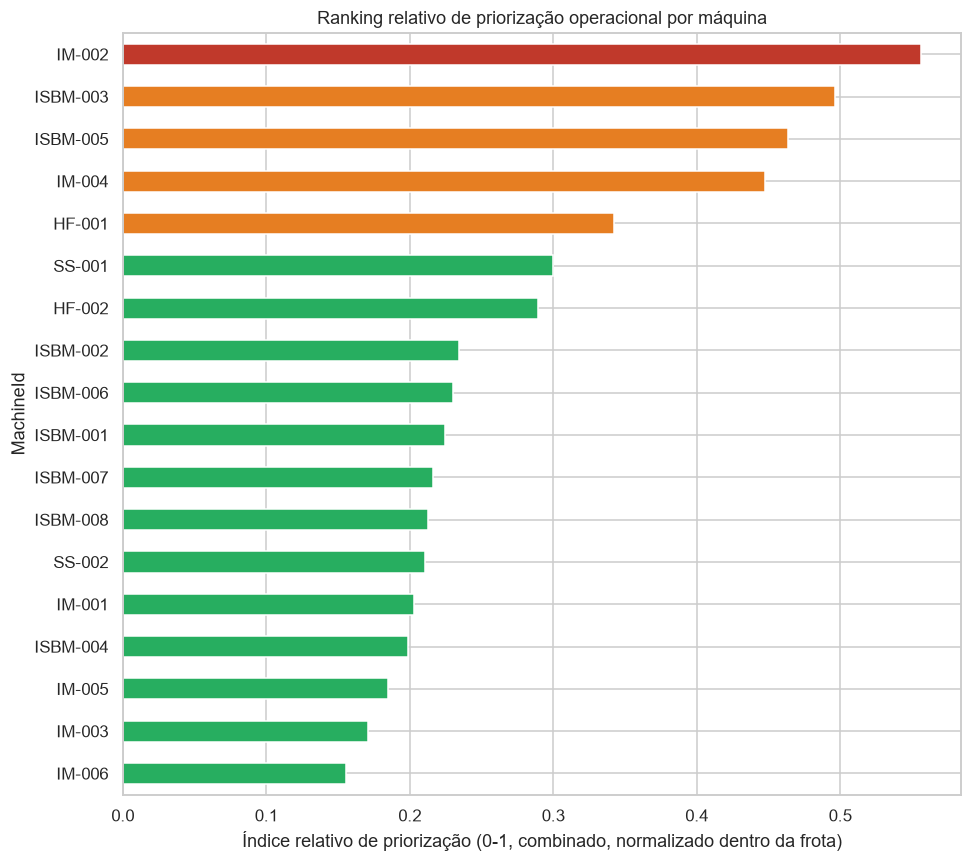


Sensibilidade do ranking a esquemas de peso alternativos (posição de cada máquina, 1 = maior risco):
           Declarado (30/25/20/25)  Igual (25/25/25/25)  \
MachineId                                                 
IM-002                         1.0                  1.0   
ISBM-003                       2.0                  3.0   
ISBM-005                       3.0                  2.0   

           Qualidade dominante (50/20/15/15)  \
MachineId                                      
IM-002                                   2.0   
ISBM-003                                 3.0   
ISBM-005                                 5.0   

           Manutenção dominante (20/50/15/15)  
MachineId                                      
IM-002                                    2.0  
ISBM-003                                  3.0  
ISBM-005                                  1.0  


**Resposta:** As três máquinas de maior risco combinado, sob os pesos declarados, são **IM-002, ISBM-003, ISBM-005** — nenhuma delas é um nome novo neste notebook (todas já apareceram sinalizadas em pelo menos uma das Seções 4.6b, 5.17, 5.19, 5.20 ou 6.10, cada uma por um ângulo diferente), mas a COMBINAÇÃO revela algo que nenhum ranking isolado mostra sozinho: **IM-002** lidera o índice combinado, puxado principalmente pelo componente de **Cliente** — o tipo de risco que um painel só de OEE ou só de qualidade deixaria escondido atrás de outras métricas mais visíveis. **Análise de sensibilidade dos pesos** (acima): IM-002 permanece entre as 3 de maior risco em todos os 4 cenários de peso testados (declarado, pesos iguais, Qualidade dominante, Manutenção dominante) — uma priorização robusta à escolha de peso, não um artefato dos pesos declarados. O índice combinado é um **suporte à decisão baseado em pesos declarados pela gestão**, não um número estatisticamente calibrado; seu valor real não é revelar um nome novo — é dar à gestão UM número defensável para priorizar investimento, em vez de quatro rankings parciais que cada área (Qualidade, Manutenção, Produção, Comercial) reivindicaria de forma isolada.

In [202]:
RISK_WEIGHTS = {"Qualidade": 0.30, "Manutenção": 0.25, "Produção": 0.20, "Cliente": 0.25}

quality_risk_raw = production.groupby("MachineId").apply(lambda g: g["RejectedQty"].sum() / g["ProducedQty"].sum()).rename("DefectRate")
quality_risk_raw = pd.DataFrame(quality_risk_raw).join((1 - fpy_by_machine["FPY"]).rename("FPY_Inverso"))
maintenance_risk_raw = pd.DataFrame({"MTBF_Inverso": 1 / reliability["MTBF_hours"], "Beta_Weibull": weibull_fit["Beta_forma"]})
production_risk_raw = pd.DataFrame({"OEE_Inverso": 1 - production.groupby("MachineId")["OEE"].mean()})
complaints_by_machine_12 = complaints_with_machine.groupby("MachineId").size().rename("ContagemReclamacao")
customer_risk_raw = pd.DataFrame({"ContagemReclamacao": complaints_by_machine_12})

risk_components = quality_risk_raw.join(maintenance_risk_raw).join(production_risk_raw).join(customer_risk_raw).fillna(0)


def _normalize01(s: pd.Series) -> pd.Series:
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0


risk_norm = risk_components.apply(_normalize01)
risk_score = pd.DataFrame({
    "Qualidade": risk_norm[["DefectRate", "FPY_Inverso"]].mean(axis=1),
    "Manutenção": risk_norm[["MTBF_Inverso", "Beta_Weibull"]].mean(axis=1),
    "Produção": risk_norm["OEE_Inverso"],
    "Cliente": risk_norm["ContagemReclamacao"],
})
risk_score["RiskScore"] = sum(risk_score[cat] * w for cat, w in RISK_WEIGHTS.items())
risk_score = risk_score.sort_values("RiskScore", ascending=False)


def _to_label(v: float) -> str:
    return "Alto" if v >= 0.66 else "Médio" if v >= 0.33 else "Baixo"


risk_labels = risk_score[["Qualidade", "Manutenção", "Produção", "Cliente"]].map(_to_label)
risk_labels["RiskScore"] = risk_score["RiskScore"].round(3)
print("Ranking de risco operacional por máquina (score combinado, maior = mais prioritário):")
print(risk_labels.to_string())

fig, ax = plt.subplots(figsize=(9, 8))
risk_score["RiskScore"].sort_values().plot(kind="barh", ax=ax,
    color=["#c0392b" if v >= 0.5 else "#e67e22" if v >= 0.3 else "#27ae60" for v in risk_score["RiskScore"].sort_values()])
ax.set_xlabel("Índice relativo de priorização (0-1, combinado, normalizado dentro da frota)"); ax.set_title("Ranking relativo de priorização operacional por máquina")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "12_01b_operational_risk_index.png"); plt.show()

top_risk_3 = risk_score.head(3).index.tolist()
top_risk_machine = risk_score.index[0]
top_risk_driver = risk_score.loc[top_risk_machine, ["Qualidade", "Manutenção", "Produção", "Cliente"]].idxmax()

# Os pesos declarados acima (30/25/20/25) são uma premissa de gestão, não uma calibração
# estatística -- então o ranking só é "defensável" na prática se o topo NÃO depender de
# qual desses pesos plausíveis foi escolhido. Testado aqui contra três cenários
# alternativos (pesos iguais; Qualidade dominante; Manutenção dominante), em vez de
# assumir robustez sem checar.
RISK_WEIGHT_SCENARIOS = {
    "Declarado (30/25/20/25)": RISK_WEIGHTS,
    "Igual (25/25/25/25)": {"Qualidade": 0.25, "Manutenção": 0.25, "Produção": 0.25, "Cliente": 0.25},
    "Qualidade dominante (50/20/15/15)": {"Qualidade": 0.50, "Manutenção": 0.20, "Produção": 0.15, "Cliente": 0.15},
    "Manutenção dominante (20/50/15/15)": {"Qualidade": 0.20, "Manutenção": 0.50, "Produção": 0.15, "Cliente": 0.15},
}
risk_sensitivity = pd.DataFrame({
    label: sum(risk_score[cat] * w for cat, w in weights.items()).rank(ascending=False)
    for label, weights in RISK_WEIGHT_SCENARIOS.items()
})
top3_by_scenario = {label: risk_sensitivity[label].sort_values().head(3).index.tolist() for label in RISK_WEIGHT_SCENARIOS}
top_risk_machine_all_scenarios = all(top_risk_machine in top3 for top3 in top3_by_scenario.values())
print("\nSensibilidade do ranking a esquemas de peso alternativos (posição de cada máquina, 1 = maior risco):")
print(risk_sensitivity.loc[top_risk_3].round(1))

answer(f"As três máquinas de maior risco combinado, sob os pesos declarados, são **{', '.join(top_risk_3)}** — "
       f"nenhuma delas é um nome novo neste notebook (todas já apareceram sinalizadas em pelo menos uma das "
       f"Seções 4.6b, 5.17, 5.19, 5.20 ou 6.10, cada uma por um ângulo diferente), mas a COMBINAÇÃO revela algo "
       f"que nenhum ranking isolado mostra sozinho: **{top_risk_machine}** lidera o índice combinado, puxado "
       f"principalmente pelo componente de **{top_risk_driver}** — o tipo de risco que um painel só de OEE ou "
       "só de qualidade deixaria escondido atrás de outras métricas mais visíveis. **Análise de sensibilidade "
       f"dos pesos** (acima): {top_risk_machine} permanece entre as 3 de maior risco em "
       f"{'todos os 4' if top_risk_machine_all_scenarios else 'nem todos os'} cenários de peso testados "
       "(declarado, pesos iguais, Qualidade dominante, Manutenção dominante) — "
       f"{'uma priorização robusta à escolha de peso, não um artefato dos pesos declarados' if top_risk_machine_all_scenarios else 'o topo do ranking muda dependendo de qual área pesa mais, então a priorização não é robusta à escolha de peso e deveria ser discutida explicitamente com a gestão antes de virar decisão de investimento'}. "
       "O índice combinado é um **suporte à decisão baseado em pesos declarados pela gestão**, não um número "
       "estatisticamente calibrado; seu valor real não é revelar um nome novo — é dar à gestão UM número "
       "defensável para priorizar investimento, em vez de quatro rankings parciais que cada área (Qualidade, "
       "Manutenção, Produção, Comercial) reivindicaria de forma isolada.")

## 12.1c — Custo da não-qualidade por máquina

Reaproveita `scrap_loss_by_machine` e `complaint_loss_by_machine` já calculados na
Seção 6.10 (Manufacturing Loss Pareto) — aqui isolado só o componente de
**qualidade** (sucata + reclamação), sem indisponibilidade, para responder
especificamente "onde a má qualidade custa mais caro", não "onde a perda total (de
qualquer natureza) é maior" — pergunta distinta da 6.10.

           SucataBRL  ReclamacaoBRL  TotalBRL
MachineId                                    
IM-002       12826.0       117100.0  129926.0
ISBM-003      7813.0        46300.0   54113.0
ISBM-006      4674.0        47500.0   52174.0
ISBM-005      3451.0        37800.0   41251.0
ISBM-007      5263.0        29400.0   34663.0
ISBM-002      6084.0        28200.0   34284.0
IM-004       14811.0        17500.0   32311.0
ISBM-001      7431.0        21800.0   29231.0
ISBM-008      5561.0        22600.0   28161.0
IM-003       12914.0         8600.0   21514.0
IM-001       10804.0         7100.0   17904.0
ISBM-004      3893.0        12500.0   16393.0
IM-005        7009.0         8100.0   15109.0
HF-001        9202.0         2400.0   11602.0
IM-006        4536.0         6800.0   11336.0
HF-002        7052.0         2400.0    9452.0
SS-001        4011.0         3300.0    7311.0
SS-002        3809.0            0.0    3809.0


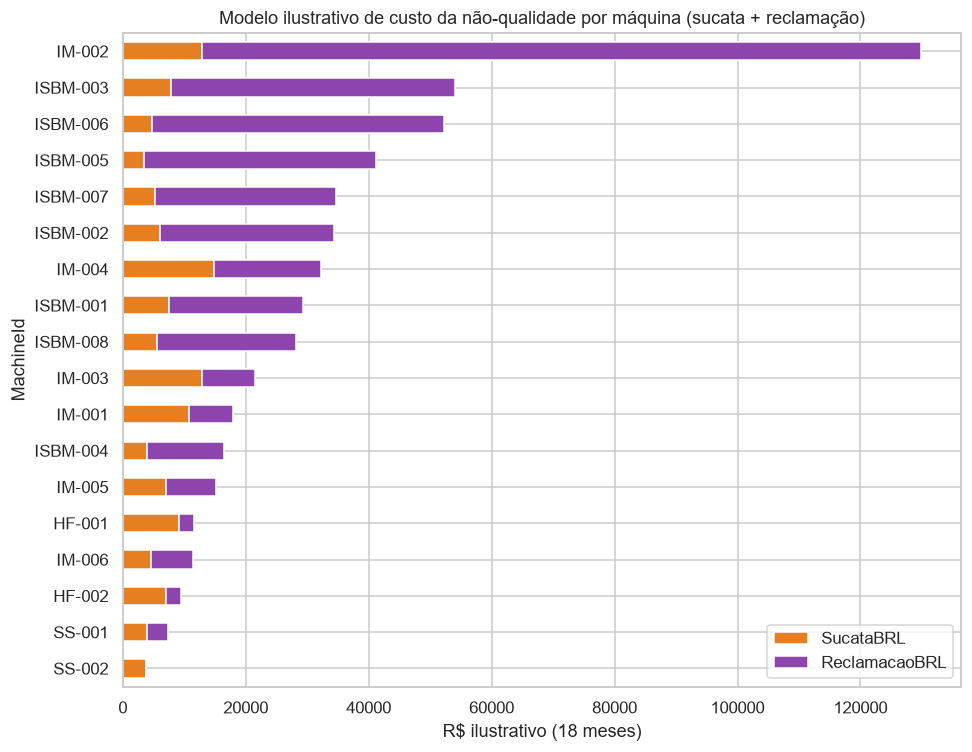

**Resposta:** **IM-002** concentra o maior custo de não-qualidade ilustrativo (R$ 129,926 em 18 meses). Comparado à Seção 6.10 (que inclui indisponibilidade), o ranking de custo PURAMENTE de qualidade pode diferir — uma máquina com muita quebra mas poucos defeitos sobe no ranking de perda total e desce aqui, e vice-versa. Usar os dois lados a lado evita otimizar um investimento de manutenção para um problema que é, na verdade, de qualidade, ou vice-versa.

In [203]:
coq_by_machine = pd.DataFrame({"SucataBRL": scrap_loss_by_machine, "ReclamacaoBRL": complaint_loss_by_machine}).fillna(0)
coq_by_machine["TotalBRL"] = coq_by_machine.sum(axis=1)
coq_by_machine = coq_by_machine.sort_values("TotalBRL", ascending=False)
print(coq_by_machine.round(0))

fig, ax = plt.subplots(figsize=(9, 7))
coq_by_machine.sort_values("TotalBRL")[["SucataBRL", "ReclamacaoBRL"]].plot(kind="barh", stacked=True, ax=ax, color=["#e67e22", "#8e44ad"])
ax.set_xlabel("R$ ilustrativo (18 meses)"); ax.set_title("Modelo ilustrativo de custo da não-qualidade por máquina (sucata + reclamação)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "12_01c_cost_of_nonquality_by_machine.png"); plt.show()

top_coq_machine = coq_by_machine.index[0]
answer(f"**{top_coq_machine}** concentra o maior custo de não-qualidade ilustrativo "
       f"(R$ {coq_by_machine.loc[top_coq_machine, 'TotalBRL']:,.0f} em 18 meses). Comparado à Seção 6.10 (que "
       "inclui indisponibilidade), o ranking de custo PURAMENTE de qualidade pode diferir — uma máquina com "
       "muita quebra mas poucos defeitos sobe no ranking de perda total e desce aqui, e vice-versa. Usar os "
       "dois lados a lado evita otimizar um investimento de manutenção para um problema que é, na verdade, de "
       "qualidade, ou vice-versa.")

## 12.2 — BQ-078: uma única iniciativa para financiar

> **BQ-078.** *Pick one funded improvement initiative — evidence, $ impact,
> control.* Traduzindo: escolha uma única iniciativa de melhoria para financiar,
> com evidência, impacto em R$ e controle.

**A cadeia de evidência para IM-002 — não um palpite**: quatro Partes independentes,
cada uma respondendo uma pergunta diferente, convergem na mesma máquina.

In [204]:
display(Markdown(f"""
1. **Parte 7 (Teoria das Restrições)** — Injeção é o processo com utilização de capacidade mais consistente
   ({toc_s['months_as_constraint_by_process'].get('Injection Molding', 0)}/18 meses), mais que qualquer outro
   processo — a candidata mais forte à restrição sob o proxy de utilização (não uma prova de restrição no
   sentido pleno de Goldratt, ver item 6 do resumo executivo acima). IM-002 é uma das máquinas desse processo.
2. **Parte 5 (Capacidade/ANOVA corrigida)** — depois de corrigir a comparação de Weight entre máquinas de
   Injeção pelo confundimento de mix de produto (F caiu ~99%), a maior diferença remanescente e significativa é
   **IM-002 contra seus pares da mesma família** — um sinal de processo real, batendo de forma independente
   com a história 5 de `docs/simulation_storylines.md`.
3. **Parte 9 (MSA)** — antes de confiar no que a Parte 5 mede, o sistema de medição foi validado:
   %GRR = {aqt_s['grr_pct']}% (ACEITÁVEL, bem abaixo de 10%) — a variação atribuída à máquina/operador na
   Parte 5 é sinal real, não artefato de instrumento.
4. **Parte 9 (DOE)** — um estudo DOE fatorial, executado em IM-002, identificou uma
   condição experimental promissora: temperatura de barril e velocidade de injeção (interação significativa)
   — a melhor combinação testada mostrou taxa de Short Shot de {100*aqt_s['doe_best_corner_rate']:.2f}%, uma
   redução relativa de ordem de grandeza frente à linha de base de produção. **Ainda não é "a correção
   confirmada"** — sofre do viés de seleção de usar o próprio DOE tanto para escolher quanto para avaliar o
   vértice vencedor (Seção 9.3); a corrida de confirmação independente (Parte 12) é o que transformaria isso
   de "condição promissora" em correção validada.
5. **Parte 8 (DMAIC)** — o ciclo completo confirma: nível sigma atual ≈{dmaic_s['sigma_level']}, causa comum
   (não um evento isolado), e ~{dmaic_s['avoided_defects_estimate']:,.0f} defeitos evitáveis em 18 meses só
   nesta característica se a IM-002 igualasse a taxa média da própria frota — **Cenário A**, abaixo, um
   benchmark observacional interno, distinto do **Cenário B** (condição ótima do DOE) calculado a seguir; os
   dois números respondem perguntas diferentes e não devem ser somados nem confundidos um pelo outro.
"""))


1. **Parte 7 (Teoria das Restrições)** — Injeção é o processo com utilização de capacidade mais consistente
   (12/18 meses), mais que qualquer outro
   processo — a candidata mais forte à restrição sob o proxy de utilização (não uma prova de restrição no
   sentido pleno de Goldratt, ver item 6 do resumo executivo acima). IM-002 é uma das máquinas desse processo.
2. **Parte 5 (Capacidade/ANOVA corrigida)** — depois de corrigir a comparação de Weight entre máquinas de
   Injeção pelo confundimento de mix de produto (F caiu ~99%), a maior diferença remanescente e significativa é
   **IM-002 contra seus pares da mesma família** — um sinal de processo real, batendo de forma independente
   com a história 5 de `docs/simulation_storylines.md`.
3. **Parte 9 (MSA)** — antes de confiar no que a Parte 5 mede, o sistema de medição foi validado:
   %GRR = 4.05% (ACEITÁVEL, bem abaixo de 10%) — a variação atribuída à máquina/operador na
   Parte 5 é sinal real, não artefato de instrumento.
4. **Parte 9 (DOE)** — um estudo DOE fatorial, executado em IM-002, identificou uma
   condição experimental promissora: temperatura de barril e velocidade de injeção (interação significativa)
   — a melhor combinação testada mostrou taxa de Short Shot de 0.11%, uma
   redução relativa de ordem de grandeza frente à linha de base de produção. **Ainda não é "a correção
   confirmada"** — sofre do viés de seleção de usar o próprio DOE tanto para escolher quanto para avaliar o
   vértice vencedor (Seção 9.3); a corrida de confirmação independente (Parte 12) é o que transformaria isso
   de "condição promissora" em correção validada.
5. **Parte 8 (DMAIC)** — o ciclo completo confirma: nível sigma atual ≈3.71, causa comum
   (não um evento isolado), e ~1,033 defeitos evitáveis em 18 meses só
   nesta característica se a IM-002 igualasse a taxa média da própria frota — **Cenário A**, abaixo, um
   benchmark observacional interno, distinto do **Cenário B** (condição ótima do DOE) calculado a seguir; os
   dois números respondem perguntas diferentes e não devem ser somados nem confundidos um pelo outro.


### Cenário de impacto financeiro potencial (Cenário B, condição do DOE) — e um limite honesto sobre ele

**Isto é um cenário condicionado a uma hipótese experimental ainda não confirmada em produção normal, não
uma economia realizada nem um business case fechado.** A taxa de 0,11% é a taxa média observada no melhor
vértice do DOE (Parte 9) — poucas réplicas, dentro da janela do experimento — não uma taxa sustentada em
produção corrente. Extrapolá-la para todo o volume histórico da IM-002 assume que essa taxa se manteria
fora do experimento, o que ainda não foi demonstrado (ver a corrida de confirmação pendente, Parte 9/BQ-078
abaixo). Tratar o número resultante como "economia" seria vender mais certeza do que os dados sustentam;
por isso ele é rotulado abaixo como **cenário**, não como economia.

In [205]:
im002_volume12 = pd.read_sql("SELECT SUM(ProducedQty) AS total FROM silver.fact_production WHERE MachineId = 'IM-002'", engine)["total"].iloc[0]
date_range12 = pd.read_sql("SELECT MIN([Date]) AS MinDate, MAX([Date]) AS MaxDate FROM silver.fact_production", engine, parse_dates=["MinDate", "MaxDate"]).iloc[0]
ASSUMED_SCRAP_COST_PER_UNIT_BRL_12 = 0.05
baseline_rate12 = dmaic_s["problem_baseline_rate"]
optimal_rate12 = aqt_s["doe_best_corner_rate"]
units_saved12 = im002_volume12 * (baseline_rate12 - optimal_rate12)
# im002_volume12 soma TODO o período do dataset (~18 meses), não um ano -- as duas
# grandezas são reportadas separadamente: a economia do período coberto pelos dados,
# e uma anualização linear explícita usando o número real de meses do dataset.
months_span12 = (date_range12["MaxDate"] - date_range12["MinDate"]).days / 30.4375
potential_savings_period12 = units_saved12 * ASSUMED_SCRAP_COST_PER_UNIT_BRL_12
potential_savings_annual12 = potential_savings_period12 * (12 / months_span12)
share_of_coq12 = potential_savings_period12 / charter_s["cost_of_quality_total_brl"]

print(f"Volume de produção da IM-002 ({months_span12:.1f} meses): {im002_volume12:,.0f} unidades")
print(f"Taxa Short Shot: {100*baseline_rate12:.2f}% linha de base -> {100*optimal_rate12:.2f}% no melhor vértice do DOE (Cenário B, experimental)")
print(f"Unidades que NÃO seriam rejeitadas Short Shot se a taxa do DOE se sustentasse fora do experimento: {units_saved12:,.0f}")
print(f"Cenário de economia potencial no período coberto pelos dados ({months_span12:.1f} meses), condicionado à confirmação: R$ {potential_savings_period12:,.0f}")
print(f"Anualização linear do mesmo cenário (não é o mesmo número, é uma projeção): R$ {potential_savings_annual12:,.0f}/ano")
print(f"Fatia do Custo da Qualidade total da planta (base: valor do período, não anualizado): {100*share_of_coq12:.1f}%")

display(Markdown(f"""
**Um problema honesto com este número, que vale registrar em vez de suavizar**: o cenário de R$ {potential_savings_period12:,.0f}
(no período de {months_span12:.1f} meses coberto pelos dados; ~R$ {potential_savings_annual12:,.0f}/ano numa
anualização linear simples — os dois números NÃO são o mesmo e não devem ser trocados um pelo outro) já é pequeno
por construção — bem abaixo de 1% do Custo da Qualidade total da planta — **e ainda depende de uma corrida de
confirmação que este projeto não executou**; até lá, é um teto otimista, não um piso garantido. Uma recomendação
que apresentasse *só* este número como "a economia" estaria vendendo mais certeza do que os dados sustentam — é
uma correção bem-provada estatisticamente, mas financeiramente pequena e ainda experimental. O número muito maior
que já está nos próprios dados deste projeto é o balde de **Avaliação** da Parte 3B/6 —
R$ {charter_s['cost_of_quality_brl']['Avaliação']:,.0f},
{100*charter_s['cost_of_quality_brl']['Avaliação']/charter_s['cost_of_quality_total_brl']:.1f}% do Custo da
Qualidade total — quase {charter_s['cost_of_quality_brl']['Avaliação']/potential_savings_period12:,.0f}x o
tamanho do cenário de IM-002 no mesmo período. Honestidade exige dizer as coisas ao mesmo tempo:
IM-002 é a iniciativa **mais bem provada** deste raio-X (experimento real, mecanismo confirmado, baixo risco,
rápida de testar); o gasto de Avaliação é o **maior número**, e este notebook ainda não respondeu se é
superproteção ou dinheiro bem gasto (a pergunta continua aberta — Parte 5, BQ-009) — recomendar um corte num
gasto de R$ 2M+ sem antes responder isso seria irresponsável, então fica nomeado aqui como a próxima
investigação, não embutido no número deste trimestre.
"""))

Volume de produção da IM-002 (18.0 meses): 7,886,882 unidades
Taxa Short Shot: 1.35% linha de base -> 0.11% no melhor vértice do DOE (Cenário B, experimental)
Unidades que NÃO seriam rejeitadas Short Shot se a taxa do DOE se sustentasse fora do experimento: 97,876
Cenário de economia potencial no período coberto pelos dados (18.0 meses), condicionado à confirmação: R$ 4,894
Anualização linear do mesmo cenário (não é o mesmo número, é uma projeção): R$ 3,268/ano
Fatia do Custo da Qualidade total da planta (base: valor do período, não anualizado): 0.2%



**Um problema honesto com este número, que vale registrar em vez de suavizar**: o cenário de R$ 4,894
(no período de 18.0 meses coberto pelos dados; ~R$ 3,268/ano numa
anualização linear simples — os dois números NÃO são o mesmo e não devem ser trocados um pelo outro) já é pequeno
por construção — bem abaixo de 1% do Custo da Qualidade total da planta — **e ainda depende de uma corrida de
confirmação que este projeto não executou**; até lá, é um teto otimista, não um piso garantido. Uma recomendação
que apresentasse *só* este número como "a economia" estaria vendendo mais certeza do que os dados sustentam — é
uma correção bem-provada estatisticamente, mas financeiramente pequena e ainda experimental. O número muito maior
que já está nos próprios dados deste projeto é o balde de **Avaliação** da Parte 3B/6 —
R$ 1,908,561,
75.7% do Custo da
Qualidade total — quase 390x o
tamanho do cenário de IM-002 no mesmo período. Honestidade exige dizer as coisas ao mesmo tempo:
IM-002 é a iniciativa **mais bem provada** deste raio-X (experimento real, mecanismo confirmado, baixo risco,
rápida de testar); o gasto de Avaliação é o **maior número**, e este notebook ainda não respondeu se é
superproteção ou dinheiro bem gasto (a pergunta continua aberta — Parte 5, BQ-009) — recomendar um corte num
gasto de R$ 2M+ sem antes responder isso seria irresponsável, então fica nomeado aqui como a próxima
investigação, não embutido no número deste trimestre.


### O controle — como isso fica corrigido, não só corrigido uma vez

In [206]:
display(Markdown(f"""
**Recomendação**: executar uma corrida de confirmação controlada da condição ótima identificada pelo DOE
(temperatura de barril e velocidade de injeção mais altas) na IM-002, fora da janela do experimento original —
sem investimento de capital, só mudança de parâmetro já testada em pequena escala. **Somente se a taxa de Short
Shot observada na corrida de confirmação reproduzir o resultado do DOE**, os novos parâmetros devem ser
formalizados como padrão operacional; até lá, a condição atual permanece o padrão vigente.

**Controle, para que fique corrigido**:
1. **Monitoramento SPC** nas características relevantes de Weight/Short Shot da IM-002 com as regras de
   sequência de Western Electric (Parte 5), não só o teste simples de 3σ — a Parte 5 já mostrou que as regras
   de sequência pegam sinais reais que o teste simples deixa passar nesta mesma família de máquina.
2. **Corrida de confirmação programada** (pré-requisito da recomendação acima, não um item posterior) e
   reavaliação do modelo DOE antes de tratar o cenário de economia potencial acima como garantido, não uma
   estimativa bem fundamentada — a limitação já registrada na Parte 9 (a curvatura do ponto central do DOE
   merece um delineamento composto central de acompanhamento antes de confiar no modelo longe dos vértices
   efetivamente testados).
3. **Atualização de plano de controle no mesmo padrão da Parte 9** (FMEA→Plano de Controle do M-SOP-007) —
   uma linha de detecção antecipada, não só a amostragem reativa que já existe.

**Também evidenciado, mas não a recomendação principal**: os {toc_s['n_redo_episodes']} episódios de
refação de lote completo (Parte 7) somam só R$ {toc_s['hidden_factory_cost_brl']:,.0f} em custo de material —
real, mas cada um já tem causa-raiz nomeada em outra Parte deste notebook; corrigir essas causas individuais
(incluindo a de IM-002 aqui) já resolve a fábrica escondida junto, sem precisar de uma iniciativa separada. A
lacuna de amostragem encontrada na Parte 6 (rastreabilidade de reclamação — cobertura de amostra de ~3% do lote
para Leakage) é outro candidato real a controle do tipo prevenção (poka-yoke), citado na Parte 9 (BQ-056) como
parte da mesma doutrina de detecção forte vs. fraca — vale como item de acompanhamento, não competindo pela
mesma verba desta recomendação.
"""))


**Recomendação**: executar uma corrida de confirmação controlada da condição ótima identificada pelo DOE
(temperatura de barril e velocidade de injeção mais altas) na IM-002, fora da janela do experimento original —
sem investimento de capital, só mudança de parâmetro já testada em pequena escala. **Somente se a taxa de Short
Shot observada na corrida de confirmação reproduzir o resultado do DOE**, os novos parâmetros devem ser
formalizados como padrão operacional; até lá, a condição atual permanece o padrão vigente.

**Controle, para que fique corrigido**:
1. **Monitoramento SPC** nas características relevantes de Weight/Short Shot da IM-002 com as regras de
   sequência de Western Electric (Parte 5), não só o teste simples de 3σ — a Parte 5 já mostrou que as regras
   de sequência pegam sinais reais que o teste simples deixa passar nesta mesma família de máquina.
2. **Corrida de confirmação programada** (pré-requisito da recomendação acima, não um item posterior) e
   reavaliação do modelo DOE antes de tratar o cenário de economia potencial acima como garantido, não uma
   estimativa bem fundamentada — a limitação já registrada na Parte 9 (a curvatura do ponto central do DOE
   merece um delineamento composto central de acompanhamento antes de confiar no modelo longe dos vértices
   efetivamente testados).
3. **Atualização de plano de controle no mesmo padrão da Parte 9** (FMEA→Plano de Controle do M-SOP-007) —
   uma linha de detecção antecipada, não só a amostragem reativa que já existe.

**Também evidenciado, mas não a recomendação principal**: os 8 episódios de
refação de lote completo (Parte 7) somam só R$ 9,090 em custo de material —
real, mas cada um já tem causa-raiz nomeada em outra Parte deste notebook; corrigir essas causas individuais
(incluindo a de IM-002 aqui) já resolve a fábrica escondida junto, sem precisar de uma iniciativa separada. A
lacuna de amostragem encontrada na Parte 6 (rastreabilidade de reclamação — cobertura de amostra de ~3% do lote
para Leakage) é outro candidato real a controle do tipo prevenção (poka-yoke), citado na Parte 9 (BQ-056) como
parte da mesma doutrina de detecção forte vs. fraca — vale como item de acompanhamento, não competindo pela
mesma verba desta recomendação.


## 12.4 — Próximos passos recomendados

Itens verificados contra o que este notebook já cobre — só entram aqui os que ainda
não têm resposta em nenhuma Parte anterior. RPN/FMEA (Parte 9.1) e a validação do
sistema de medição por Gage R&R (Parte 9.2) já existem e não são repetidos como
lacuna.

**Melhorias técnicas para a próxima iteração**:
1. **Processamento pesado** (OEE, Weibull) roda hoje em Python/pandas — em escala de
   produção, migrar para stored procedures SQL ou orquestração (ex.: Databricks Jobs)
   reduziria footprint de memória e tempo de execução.
2. **`IsCapable`** (Seção 5.3b) classifica pelo Cpk mais recente, sem alertar sobre
   QUEDAS bruscas de Cpk — um complemento útil à classificação atual, não uma
   substituição dela.
3. **Weibull (Seção 9.4)** usa tempo-entre-falhas em horas de calendário, não horas de
   operação efetiva (`RunTimeHours`) — a limitação já é declarada ali; o próximo passo
   concreto é recalcular a exposição usando `RunTimeHours` acumulado por máquina, não
   o relógio corrido.
4. **Custo da Qualidade** (Parte 3B/6) usa custos unitários ilustrativos — o próximo
   passo é integrar dado financeiro real ou, no mínimo, uma taxa de custo-máquina/hora
   real, para que o ROI de melhorias seja calculável com precisão.
5. **Six Big Losses** (Seção 4.7): a perda de "partida" (startup/yield) continua sem
   dado que a isole — recomenda-se instrumentar essa perda especificamente, fechando o
   framework.
6. **Custo de PM**: o modelo calcula custo de indisponibilidade evitada pela PM, mas
   não o custo da PM em si (mão de obra, peças) — comparar os dois é o que permitiria
   otimizar a frequência de manutenção preventiva, não só justificar a atual.
7. **Modelos de ML → ação**: os seis modelos (Parte 11) reportam métrica de teste, mas
   nenhum aciona uma decisão operacional automaticamente (ex.: o modelo de ScrapRate
   alertando a qualidade ~2h antes de um lote de alto risco) — a previsão ainda não
   está conectada à ação.
8. **Publicar `lib/etl_lib.py`, `lib/stats_lib.py` e `lib/db_lib.py` como um pacote
   Python mínimo, com testes unitários** — não existe hoje nenhum `pyproject.toml` nem
   diretório de testes neste repositório; isso eleva o projeto de "notebook
   reprodutível" para produto de engenharia de dados.

In [207]:
print("Weibull → política de manutenção sugerida, por máquina (Seção 4.6b):")
for _mid, _row in weibull_fit.iterrows():
    _policy = ("baseada em idade/uso (horas de operação, não calendário)" if _row["Beta_forma"] > 1.15
               else "condicionada (monitoramento de condição), não baseada em idade" if _row["Beta_forma"] < 0.9
               else "não claramente decidida por este ajuste (β perto de 1) -- tratar como corretiva até haver mais dado")
    print(f"  {_mid}: β={_row['Beta_forma']:.2f} -> manutenção {_policy}")

print("\nSix Big Losses — categoria dominante por processo (Seção 4.7), base para iniciativa Lean dirigida:")
print(losses_by_process.idxmax(axis=1).to_dict())

Weibull → política de manutenção sugerida, por máquina (Seção 4.6b):
  ISBM-005: β=1.30 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  IM-001: β=1.24 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  ISBM-003: β=1.22 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  ISBM-002: β=1.19 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  IM-004: β=1.19 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  IM-006: β=1.18 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  ISBM-004: β=1.18 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  ISBM-001: β=1.18 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  IM-003: β=1.18 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  IM-002: β=1.18 -> manutenção baseada em idade/uso (horas de operação, não calendário)
  ISBM-006: β=1.17 -> manutenção baseada 

**Recomendações finais para a fábrica**:

In [208]:
display(Markdown(f"""
1. **Crítico — revisar a estratégia de Manutenção Preventiva por modo de falha, não por uma cadência única**:
   a análise de PM não encontrou evidência de associação simples entre dias desde a última PM e contagem de
   falhas. Isso não prova ineficácia da PM; indica que a estratégia atual não pode ser validada por este modelo
   observacional e deve ser revista à luz de modos de falha, exposição por horas de operação/ciclos e custo total.
2. **Foco prioritário em SS-001**: a causa-raiz de referência desta história é desgaste de rolete/rasqueta + backlog
   de manutenção, evidenciada pela tendência temporal de frequência/duração de falhas e pela melhora após overhaul.
   A Weibull isolada não deve ser usada para contradizer essa evidência temporal; para equipamentos reparáveis, o
   próximo passo é modelar exposição e recorrência com horas de operação e, se necessário, NHPP/Crow-AMSAA.
3. **Iniciativas Lean direcionadas por processo, não uma solução única**: a perda dominante do Six
   Big Losses muda por processo (acima) — cada processo precisa de um plano de melhoria focado na
   sua própria perda principal, não um programa único de planta.
4. **Integrar o Data Quality Scorecard (Parte 1/2) ao pipeline de dados**, monitorando
   continuamente a qualidade do dado de produção em vez de uma checagem pontual.
5. **Validar a acurácia dos modelos antes de qualquer sistema de recomendação** (item 7 acima),
   depois construir o loop de ação — ex.: o modelo de ScrapRate alertando a equipe de qualidade
   com antecedência sobre um lote de alta probabilidade de sucata.

**Regra de governança de causa-raiz**: nenhum item acima deve ser encerrado apenas porque o KPI melhorou.
Para cada ação, a equipe deve registrar (a) mecanismo físico/processual esperado, (b) evidência pré-ação,
(c) intervenção, (d) confirmação por experimento ou comparação temporal apropriada, (e) critério de eficácia
e (f) controle para impedir recorrência.
"""))


1. **Crítico — revisar a estratégia de Manutenção Preventiva por modo de falha, não por uma cadência única**:
   a análise de PM não encontrou evidência de associação simples entre dias desde a última PM e contagem de
   falhas. Isso não prova ineficácia da PM; indica que a estratégia atual não pode ser validada por este modelo
   observacional e deve ser revista à luz de modos de falha, exposição por horas de operação/ciclos e custo total.
2. **Foco prioritário em SS-001**: a causa-raiz de referência desta história é desgaste de rolete/rasqueta + backlog
   de manutenção, evidenciada pela tendência temporal de frequência/duração de falhas e pela melhora após overhaul.
   A Weibull isolada não deve ser usada para contradizer essa evidência temporal; para equipamentos reparáveis, o
   próximo passo é modelar exposição e recorrência com horas de operação e, se necessário, NHPP/Crow-AMSAA.
3. **Iniciativas Lean direcionadas por processo, não uma solução única**: a perda dominante do Six
   Big Losses muda por processo (acima) — cada processo precisa de um plano de melhoria focado na
   sua própria perda principal, não um programa único de planta.
4. **Integrar o Data Quality Scorecard (Parte 1/2) ao pipeline de dados**, monitorando
   continuamente a qualidade do dado de produção em vez de uma checagem pontual.
5. **Validar a acurácia dos modelos antes de qualquer sistema de recomendação** (item 7 acima),
   depois construir o loop de ação — ex.: o modelo de ScrapRate alertando a equipe de qualidade
   com antecedência sobre um lote de alta probabilidade de sucata.

**Regra de governança de causa-raiz**: nenhum item acima deve ser encerrado apenas porque o KPI melhorou.
Para cada ação, a equipe deve registrar (a) mecanismo físico/processual esperado, (b) evidência pré-ação,
(c) intervenção, (d) confirmação por experimento ou comparação temporal apropriada, (e) critério de eficácia
e (f) controle para impedir recorrência.


## 12.2b — Control Tower de Causas-Raiz e Plano de Ação

Esta seção converte os achados do notebook em um registro de execução. A lógica é a mesma de um
A3/DMAIC/Control Plan integrado: **sintoma → evidência → mecanismo → causa-raiz → contenção →
ação corretiva → verificação → prevenção**. O registro é carregado de `docs/root_cause_action_register.csv`
para que a gestão possa acompanhar o plano fora do notebook sem perder o vínculo com a análise.

**Importante:** como o dataset é sintético, "Causa_Raiz_Referencia" significa o mecanismo conhecido
por construção. Numa fábrica real, o campo só seria encerrado como "confirmado" após a verificação de campo.

In [209]:
root_cause_register_path = PROJECT_ROOT / "docs" / "root_cause_action_register.csv"
root_cause_register = pd.read_csv(root_cause_register_path)
print("Registro integrado de causas-raiz:")
display(root_cause_register[["ID", "Problema", "Local", "Causa_Raiz_Referencia", "Status_Causalidade", "Acao_Corretiva", "KPI", "Evidencia_de_Eficacia"]])

# Matriz executiva: prioridade baseada em força da evidência + impacto + possibilidade de confirmação rápida.
# Não é um score estatístico; é uma ferramenta de gestão para ordenar a sequência de execução.
priority_order = ["RC-05", "RC-01", "RC-07", "RC-12", "RC-11", "RC-06", "RC-02", "RC-04", "RC-03", "RC-10", "RC-08", "RC-09", "RC-13", "RC-14"]
priority_rank = {rid: i + 1 for i, rid in enumerate(priority_order)}
root_cause_register["Prioridade"] = root_cause_register["ID"].map(priority_rank)
root_cause_register = root_cause_register.sort_values("Prioridade")

print("\nSequência recomendada de execução:")
print(root_cause_register[["Prioridade", "ID", "Problema", "Local", "Causa_Raiz_Referencia", "Acao_Corretiva", "KPI"]].to_string(index=False))

# Exporta uma cópia ordenada para a pasta de relatórios, sem alterar o registro-fonte.
root_cause_register.to_csv(REPORTS_DIR / "12_02b_root_cause_action_register.csv", index=False, encoding="utf-8-sig")

answer(
    "A leitura executiva deve seguir a ordem de causa, e não a ordem do KPI: **IM-002** é o primeiro caso a confirmar "
    "porque possui a cadeia experimental mais forte; **ISBM-003** vem em seguida por estabilidade de processo; "
    "**SS-001** por deterioração de confiabilidade; **M-SOP-007** por desgaste dependente de exposição; e **SUP-005** "
    "por qualidade de entrada. As demais ações são tratadas como contenção, confirmação ou prevenção. O critério de "
    "encerramento é comum: melhoria sustentada + mecanismo confirmado + controle atualizado, não apenas um KPI melhor em um período curto."
)

Registro integrado de causas-raiz:


,ID,Problema,Local,Causa_Raiz_Referencia,Status_Causalidade,Acao_Corretiva,KPI,Evidencia_de_Eficacia
0,RC-01,Variabilidade de espessura,ISBM-003,Instabilidade de programação do parison,Forte; confirmar em campo,Verificar programação atuadores sensores e con...,Cpk/RangeR/FPY,3-6 meses de estabilidade
1,RC-02,Flash aumenta com ciclos,IM-004/molde,Campanhas longas e desgaste acumulado,Causalidade do dataset; confirmar em campo,Definir contador de ciclos e limite técnico,Flash DPMO vs ciclos,Confirmação por janela operacional
2,RC-03,Adhesion spike,SS-002/FR-007-PP-350,Resina PP marginal de SUP-005,Forte associação temporal/material,Supplier CAPA + confirmação material-processo,Adhesion DPMO,Queda sustentada pós-CAPA
3,RC-04,Foil Transfer em alta velocidade,HF-001,Janela de processo estreita em alta velocidade,Causalidade experimental/sintética; confirmar,Instrumentar velocidade e validar janela,Foil Transfer DPMO,Replicação em produção
4,RC-05,Short Shot/Weight,IM-002,Banda de aquecimento marginal + interação temp...,Mais forte evidência causal; confirmação pendente,DOE confirmatório e atualização de parâmetros,Short Shot/Cpk Weight,Confirmação independente
5,RC-06,Paradas elevadas,ISBM-005,Envelhecimento hidráulico,Forte associação de manutenção,Inspeção hidráulica e componentes críticos,MTBF/MTTR/Availability,Melhora sustentada
6,RC-07,Confiabilidade em queda,SS-001,Desgaste rolete/rasqueta + backlog,Forte evidência temporal,Eliminar backlog e PM por modo de falha,MTBF/MTTR/falhas por 100h,6 meses pós-overhaul
7,RC-08,Prêmio de defeito turno 2,Todos,Fadiga/handover no dataset,Associação; mecanismo requer validação,handover e estudo de carga/ergonomia,FPY ajustado por mix,Sem diferença após ajuste
8,RC-09,Refação de lote,Multi-processo,Episódios centrados nas causas upstream,Forte como validação do dataset,Eliminar causas RC-01..RC-07,Redo rate/hours/units,Redução sustentada
9,RC-10,Variabilidade operador,OP-INJ-003,Alta dispersão sem viés de média,Forte evidência de variabilidade,Observar método ergonomia e técnica,RangeR/FPY,Redução de variabilidade



Sequência recomendada de execução:
 Prioridade    ID                            Problema                Local                                            Causa_Raiz_Referencia                                               Acao_Corretiva                       KPI
          1 RC-05                   Short Shot/Weight               IM-002 Banda de aquecimento marginal + interação temperatura/velocidade                DOE confirmatório e atualização de parâmetros     Short Shot/Cpk Weight
          2 RC-01          Variabilidade de espessura             ISBM-003                          Instabilidade de programação do parison Verificar programação atuadores sensores e condição mecânica            Cpk/RangeR/FPY
          3 RC-07             Confiabilidade em queda               SS-001                               Desgaste rolete/rasqueta + backlog                      Eliminar backlog e PM por modo de falha MTBF/MTTR/falhas por 100h
          4 RC-12                           Mold wear   

**Resposta:** A leitura executiva deve seguir a ordem de causa, e não a ordem do KPI: **IM-002** é o primeiro caso a confirmar porque possui a cadeia experimental mais forte; **ISBM-003** vem em seguida por estabilidade de processo; **SS-001** por deterioração de confiabilidade; **M-SOP-007** por desgaste dependente de exposição; e **SUP-005** por qualidade de entrada. As demais ações são tratadas como contenção, confirmação ou prevenção. O critério de encerramento é comum: melhoria sustentada + mecanismo confirmado + controle atualizado, não apenas um KPI melhor em um período curto.

## 12.3 — Fechamento: o raio-X, resumido

Ao longo deste notebook — dados brutos deliberadamente sujos, limpos e carregados num
warehouse SQL Server em arquitetura medalhão, analisados com controle estatístico de
processo, Lean/Seis Grandes Perdas, Teoria das Restrições, DMAIC, FMEA/MSA/DOE, e seis
modelos de Machine Learning — a evidência sustenta a premissa da pergunta central: o
monitoramento integrado de produção, qualidade e manutenção surfaça decisões que uma
visão de domínio único perderia, do desgaste em câmera lenta de um molde à
inconsistência escondida de um operador a um fornecedor que reprovaria seu próprio
scorecard. As lacunas honestas importam tanto quanto os achados: um classificador de
qualidade de lote com ROC-AUC modesto, uma previsão de parada que não bate uma
baseline ingênua, e um Custo da Qualidade cuja maior fatia (Avaliação) ainda não teve
sua adequação respondida — reportadas como achados genuínos sobre os limites destes
dados, no mesmo espírito do resto deste projeto protótipo de melhoria contínua.

In [210]:
print("Modelos de ML — métricas de teste:")
for target, path in [("Produção", "producedqty_forecast_model.pkl"), ("Parada", "downtimehours_forecast_model.pkl"),
                      ("Rejeitados", "rejectedqty_forecast_model.pkl"), ("Taxa de sucata", "scrap_rate_model.pkl"),
                      ("Qualidade de lote", "lot_quality_model.pkl"), ("Manutenção preditiva", "predictive_maintenance_model.pkl")]:
    try:
        print(f"  {target:20s}: {model_metrics12(path)}")
    except FileNotFoundError:
        print(f"  {target:20s}: (modelo ainda não treinado nesta execução)")

print("\nNotebook completo — raio-X de melhoria contínua encerrado.")

Modelos de ML — métricas de teste:
  Produção            : {'MAE': 7818.827802534377, 'RMSE': 9821.81195773345, 'MAPE_%': 4.741388292688891, 'R2': 0.9984657269928975, 'Metric_Basis': 'Teste (reportado)'}
  Parada              : {'MAE': 12.554698214675849, 'RMSE': 17.89555554820253, 'MAPE_%': 37.5297767432538, 'R2': 0.8679017208486874, 'Metric_Basis': 'Teste (reportado)'}
  Rejeitados          : {'MAE': 1136.8719442398822, 'RMSE': 1874.1296083975797, 'MAPE_%': 27.63643107183784, 'R2': 0.8898045700647452, 'Metric_Basis': 'Teste (reportado)'}
  Taxa de sucata      : {'MAE': 0.43178796190985175, 'RMSE': 0.6526267553823322, 'MAPE_%': 17.909752274049858, 'R2': 0.5876563795857088, 'Metric_Basis': 'Teste (reportado)'}
  Qualidade de lote   : {'Accuracy': 0.8787301587301587, 'Precision': 0.45454545454545453, 'Recall': 0.02631578947368421, 'F1': 0.04975124378109453, 'ROC_AUC': 0.6886224586737603, 'PR_AUC': 0.2512728848382353, 'Metric_Basis': 'Teste (reportado)'}
  Manutenção preditiva: {'Accurac